# Monte Carlo Tree earch Attempt

This notebook shall hold all the attempts for MCTS.
Given a Pauli word with k Pauli strings $P_k$, a tree can be formed where each level is at least 1 Pauli string less: $P_k \,\to\, P_{k-1}\,\to\,P_{k-2}\dots$. Each node will have as many children as it has Pauli strings. This means the number of possible actions space for each node is k. However to get for example from the root node to the child associated with its first Pauli string has $n^{n-2}$ (direct) reductions, where n is the number of nonidentity in the first Pauli string. To find the best - where best is defined as the (direct) reduction that also reduces the number of nonidentities in the Pauli word the most - reduction you would also need to traverse a tree $P^{1_n}_{k} \,\to\, P^{1_1}_{k}$ (read as the reduction of the first Pauli string from n nonidentities to 1 nonidentity). Upon the Pauli string only having 1 nonidentity, it is implementable and will be pruned from the Pauli word, producing a $P^1_{k-1}$. Because there are so many possible reductions for just one Pauli string which have their own tree a method to solve this is also necessary. A strong suggestion has just been using a heuristic way to find a good solution.

_Concerns:_ 
1. Why even have reductions for specific Pauli strings? Would not a more efficient method be trying to solve multiple Pauli strings simultaneously? - This concern is valid and is an active question. However there are no clear methods so far to solve multiple stringswhich are not greedy except A* (worth revisiting even though admissiblility of heuristic would be unanswerable).  
2. Would not this way be unscalable with size? This remains to be seen in experiments. 

## Initial Variables, Libraries and Classes 

In [19]:
import random as rnd
import heapq as hp
import networkx as nx
from networkx.drawing.nx_agraph import write_dot, graphviz_layout
import matplotlib.pyplot as plt
import numpy as np
import math
import time

In [20]:
# important global variables
TIME = 0.05
PARAM = 10

In [21]:
# class that implements tableau and necessary operations
# References -Improved Simulation of Stabilizer Circuits by Scott Aaronson & Daniel Gottesman
# - Google Tableau implementation
class Cirq_Tableau:
    
    def __init__(
        self,
        pauli_word: list[str] = None  
    ):
        if pauli_word is None or len(pauli_word) == 0:
            self._column_num = None
            self._row_num = None

            self._ss, self._xs, self._zs = None, None, None
        else:
            if "-" in pauli_word[0]:
                self._column_num = len(pauli_word[0][1:]) 
            else:
                self._column_num = len(pauli_word[0])
            self._row_num = len(pauli_word)

            self._ss = self.create_sign(pauli_word)
            self._xs, self._zs = self.create_tab(pauli_word)

    # setters & getters 
    @property
    def ss(self) -> np.ndarray:
        return self._ss

    @ss.setter 
    def ss(self, new_ss: np.ndarray):
        self._ss = new_ss
        
    @property
    def xs(self) -> np.ndarray:
        return self._xs

    @xs.setter 
    def xs(self, new_xs: np.ndarray):
        self._xs = new_xs
        
    @property
    def zs(self) -> np.ndarray:
        return self._zs

    @zs.setter 
    def zs(self, new_zs: np.ndarray):
        self._zs = new_zs
        
    @property
    def column_num(self) -> int:
        return self._column_num

    @column_num.setter 
    def column_num(self, new_num: int):
        self._column_num = new_num
    
    @property
    def row_num(self) -> int:
        return self._row_num

    @row_num.setter 
    def row_num(self, new_num: int):
        self._row_num = new_num

    # functions that create parts of tableau
    def create_sign(self, pauli_word: list[str]):
        temp_ss = np.zeros((self.row_num), dtype=int)
        for pauli_string in pauli_word:
            if "-" in pauli_string:
                index = pauli_word.index(pauli_string)
                pauli_word[index] = pauli_string.replace("-", "")
                #print(pauli_word)
                temp_ss[index] = 1
        return temp_ss
        
    def create_tab(self, pauli_word: list[str]):
        temp_x = np.zeros((self.row_num, self.column_num), dtype=int)
        temp_z = np.zeros((self.row_num, self.column_num), dtype=int)
        for i, pauli_string in enumerate(pauli_word):
            for j, pauli in enumerate(pauli_string):
                if pauli == "X" or pauli == "Y":
                    temp_x[i][j] = 1
                if pauli == "Z" or pauli == "Y":
                    temp_z[i][j] = 1
        return temp_x, temp_z

    # Clifford operations on tableau. 
    def apply_H(self,column: int):
        self.ss ^= self.xs[:, column] & self.zs[:, column]
        self.xs[:, column], self.zs[:, column] = self.zs[:, column].copy(), self.xs[:, column].copy()

    def apply_S(self, column: int):
        self.ss ^= self.xs[:, column] & self.zs[:, column]
        self.zs[:, column] = self.xs[:, column] ^ self.zs[:, column]

    def apply_CX(self, control: int, target: int):
        self.ss ^= (
            (self.xs[:, control] & self.zs[:, target])
            &(~(self.xs[:, target] ^ self.zs[:, control]))
        )
        self.xs[:, target] ^= self.xs[:, control]
        self.zs[:, control] ^= self.zs[:, target]

    # class operations necessary for comparisons and equating
    def copy(self):
        new_tab = Cirq_Tableau()
        new_tab.column_num = self.column_num
        new_tab.row_num = self.row_num
        new_tab.ss = self.ss.copy()
        new_tab.zs = self.zs.copy()
        new_tab.xs = self.xs.copy()
        return new_tab
    
    def __eq__(self, other):
        if not isinstance(other, type(self)):
            return NotImplemented  
        return (
            self.column_num == other.column_num
            and self.row_num == other.row_num
            and np.array_equal(self.ss, other.ss)
            and np.array_equal(self.xs, other.xs)
            and np.array_equal(self.zs, other.zs)
        )
    
    def return_string(self):
        string = ''
        for i in range(self.row_num):
            if self.ss[i]:
                string += "-"  

            for j in range(self.column_num):
                if self.xs[i][j] and not self.zs[i][j]:
                    string += "X"
                elif not self.xs[i][j] and self.zs[i][j]:
                    string += "Z"
                elif self.xs[i][j] and self.zs[i][j]:
                    string += "Y"
                else:
                    string += "I"
            if i < self.row_num - 1:
                string += "\n" 

        return string
    
    def __copy__(self):
        return self.copy()
        

    def __str__(self) -> str:
        ss = np.expand_dims(self.ss, axis = 1)
        xz = np.concatenate((self.xs, self.zs, ss), axis=1)
        return str(xz)

    def __hash__(self) -> int:
        return hash(self.zs.tobytes() + self.xs.tobytes() + self.ss.tobytes())

    def __lt__(self, other):
        return self.row_num < other.row_num

## Heuristic method to solve single Pauli string

To move from $P_k \,\to\, P^\alpha_{k-1}$, where $\alpha$ is the number describing the index of the Pauli string we are reducing, we need a way a to make it deterministic.  Having multiple reductions that fulfil $P_k \,\to\, P^\alpha_{k-1}$ means that there is no deterministic way to get to the child. So a heuristic way to construct this solution has been suggested 

In [22]:
# TODO: write a more efficient pruning algorithm
def prune(tableau: Cirq_Tableau):
    '''
    Function to remove rows in a tableau with only a single nonidentity operation
    
    :param tableau: Cirq_Tableau to act on
    '''
    prn_ndxs = [] # list to hold all row indices to be pruned
    
    tab = tableau.copy() # copy of tableau to work on

    single_q = [] # loist of single qubit operations 
    
    # extracts x, z and sign arrays
    x, z, s = tab.xs, tab.zs, tab.ss

    # bitwise ORs x and z arrays in tableau to create array where nonidentity operation indices have 1 in them
    weight_array = x | z

    # loop that checks through each row to find out if it has a Pauli weight of 1
    for r_ndx in range(len(weight_array)):
        if sum(weight_array[r_ndx])  == 1:

            # appends index to be pruned if Pauli weight == 1
            prn_ndxs.append(r_ndx)

            # checks what type of Pauli is on that index X, Y or Z and appends to path with action weight of zero 
            if sum(z[r_ndx]) == 0:
                if s[r_ndx] == 0:
                    single_q.append(("X", int(np.argmax(x[r_ndx] == 1))))
                else:
                    single_q.append(("-X", int(np.argmax(x[r_ndx] == 1))))
            elif sum(x[r_ndx]) == 0:
                if s[r_ndx] == 0:
                    single_q.append(("Z", int(np.argmax(z[r_ndx] == 1))))
                else:
                    single_q.append(("-Z", int(np.argmax(z[r_ndx] == 1))))
            else:
                if s[r_ndx] == 0:
                    single_q.append(("Y", int(np.argmax(x[r_ndx] == 1))))
                else:
                    single_q.append(("-Y", int(np.argmax(x[r_ndx] == 1))))
                    
        elif sum(weight_array[r_ndx])  == 0: # elif removes fully I lines 
            x, z, s = np.delete(x, r_ndx, axis=0), np.delete(z, r_ndx, axis=0), np.delete(s, r_ndx)
            
    # prunes rows 
    x, z, s = np.delete(x, prn_ndxs, axis=0), np.delete(z, prn_ndxs, axis=0), np.delete(s, prn_ndxs)
    column_num = len(x[0]) if x.size != 0 else 0 
    row_num = len(x)

    # updates tableau and returns it 
    tab.xs, tab.zs, tab.ss, tab.column_num, tab.row_num = x, z, s, column_num,row_num
    return tab, single_q
    

The next three cells are used to construct the heuristic. The heuristic is broken down into three functions for readability purposes. I am sure there is a more efficient way to construct this idea or even a better heuristic generally but for now this will do

Definitions:

Reducible Pair: any one of four pairs of Paulis wich 'reduce' when a CX ois applied to them .e.g. XX becomes XI 

Allowed Transformations: a combination of S, H, I that can transform a pair of Paulis into a reducible pair

In [23]:
def identify(tableau, op_list, ctrl, targ):
    '''
    Function to identify the best operation amongst a list 
    This function is mainly used to identify which one of the allowed transformations for a pair produces the best benefit

    tableau: Cirq_Tableau that holds our Pauli word
    op_list: list of action tuples which are possible operations
    ctrl: int that is index of control qubit
    targ: int that is index of target qubit
    '''
    operation = None # best operation
    benefit = -float('inf') # benefit of an operation benefit = reduce - increase 
    reduced = 0 # number of reducible pairs across the ctrl and targ (equivalent to how many single qubit operations will be removed)
    increased = 0 # number of increasing pairs across the ctrl and targ (equivalent to how many single qubit operations will be added)

    # loop to run through possible operations 
    for op in op_list:
        
        tab = tableau.copy()

        # loop to go over all the gates in the operation and apply them accordingly
        for act in op:
            match act[0]:
                case "H":
                    tab.apply_H(act[1])
                case "S":
                    tab.apply_S(act[1])

        # calculation of reduced and increased for this particular action
        reduce = sum((tab.xs[:, ctrl] & tab.xs[:, targ] & ~tab.zs[:, targ]) | (~tab.xs[:, ctrl] & tab.zs[:, ctrl] & tab.zs[:, targ]))
        increase = sum((~tab.xs[:, ctrl] & ~tab.zs[:, ctrl] & tab.zs[:, targ]) | (tab.xs[:, ctrl] & ~tab.xs[:, targ] & ~tab.zs[:, targ]))
        
        # condition to calculate better benefit and replace necessary values
        # benefit is the total no. of reducible pairs minus total no. of increasing pairs
        # this will total how many single qubits will be removed from the entire Pauli word
        if reduce - increase > benefit:
            benefit = reduce - increase
            operation = op
            reduced = reduce
            increased = increased
        elif reduce - increase == benefit:
            if reduce > reduced:
                benefit = reduce - increase
                operation = op
                reduced = reduce
                increased = increase

    # appending CX to the operation to complete it
    operation.append(("CX", ctrl, targ))
    return reduced, increased, operation 

In [24]:
def compare(tab, ndx, ctrl, targ):
    '''
    Function that takes in a pair and identifies what Paulis are in it

    tab: Cirq_tableau holding Pauli word
    ndx: int holding index (row) of the Pauli string currently being reduced
    ctrl: int holding index (column) of control qubit
    targ: int holding index (column) of target qubit
    '''

    if tab.xs[ndx][ctrl] & ~tab.zs[ndx][ctrl]: # if control is X
        if tab.xs[ndx][targ] & ~tab.zs[ndx][targ]: # if target is X

            # list of allowed transformations for XX
            op_list = [[], [("S", ctrl)], [("H", ctrl), ("H", targ)],
                      [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
        elif tab.xs[ndx][targ] & tab.zs[ndx][targ]: # if target is Y

            # list of allowed transformations for XY
            op_list = [[("S", ctrl), ("S", targ)], [("S", targ)], [("H", ctrl)],
                      [("H", ctrl), ("H", targ)]]
            return identify(tab, op_list, ctrl, targ)

        else:# if target is Z

            # list of allowed transformations for XZ
            op_list = [[("S", ctrl), ("H", targ)], [("H", targ)], [("H", ctrl)],
                      [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
    elif tab.xs[ndx][ctrl] & tab.zs[ndx][ctrl]: # if control is Y
        if tab.xs[ndx][targ] & ~tab.zs[ndx][targ]: # if target is X

            # list of allowed transformations for YX
            op_list = [[], [("S", ctrl)], [("H", ctrl)]]
            return identify(tab, op_list, ctrl, targ)
            
        elif tab.xs[ndx][targ] & tab.zs[ndx][targ]: # if target is Y

            # list of allowed transformations for YY
            op_list = [[("S", ctrl), ("S", targ)], [("H", ctrl),("S", targ)],
                      [("S", targ)]]
            return identify(tab, op_list, ctrl, targ)

        else:# if target is Z

            # list of allowed transformations for YZ
            op_list = [[("H", targ)], [("S", ctrl), ("H", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
    else: # if control is Z
        if tab.xs[ndx][targ] & ~tab.zs[ndx][targ]: # if target is X

            # list of allowed transformations for ZX
            op_list = [[("H", targ)], [("H", ctrl)], [("S", ctrl),("H", targ)],
                      [("S", targ)]]
            return identify(tab, op_list, ctrl, targ)
            
        elif tab.xs[ndx][targ] & tab.zs[ndx][targ]: # if target is Y

            # list of allowed transformations for ZY
            op_list = [[], [("S", ctrl)], [("H", targ)], [("S", ctrl),("H", targ)], [("H", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)

        else:# if target is Z

            # list of allowed transformations for ZZ
            op_list = [[], [("H", ctrl), ("H", targ)], [("S", ctrl)], [("S", targ)], [("S", ctrl), ("S", targ)]]
            return identify(tab, op_list, ctrl, targ)

In [25]:
def heuristic(tableau, ndx):
    '''
    Heuristic function to produce a single reduction from one node of a tree to a child

    tableau: Cirq_Tableau holding Pauli word
    ndx: int holding index (row) of current Pauli string being reduced
    '''
    tab = tableau.copy()
    reduction = [] # reduction of Pauli string

    # loop to run until break condition is met - Pauli string is implementable
    while True:
        operation = None
        benefit = -float('inf')
        reduced = 0
        increased = 0

        # break condition 
        if sum(tab.xs[ndx] | tab.zs[ndx]) == 1:
            break
            
        #  loop to cycle over all qubit indexes to get all combinations of control and target 
        for i in range(tab.column_num):
            if i != tab.column_num -1 and (tab.xs[ndx][i] or tab.zs[ndx][i]): # prevents I's 
                for j in range(i+1, tab.column_num):
                    if tab.xs[ndx][j] or tab.zs[ndx][j]: # prevents I's 

                        # conditions to check for better benefit with i as ctrl and j as targ
                        reduce, increase, op = compare(tab, ndx, i, j)
                        if (reduce - increase) > benefit:
                            benefit = reduce - increase
                            operation = op
                            reduced = reduce
                            increased = increase
                        elif (reduce - increase) == benefit:
                            if reduce > reduced:
                                operation = op
                                reduced = reduce
                                increased = increase
                                
                        # conditions to check for better benefit with j as ctrl and i as targ
                        reduce, increase, op = compare(tab, ndx, j, i)
                        if (reduce - increase) > benefit:
                            benefit = reduce - increase
                            operation = op
                            reduced = reduce
                            increased = increase
                        elif (reduce - increase) == benefit:
                            if reduce > reduced:
                                operation = op
                                reduced = reduce
                                increased = increase

        # condition that picks the best operation and applies it
        if operation != None:
            for action in operation:
                match action[0]:
                    case "CX":
                        tab.apply_CX(action[1], action[2])
                    case "S":
                        tab.apply_S(action[1])
                    case "H":
                        tab.apply_H(action[1])
                        
            reduction += operation # appends to reduction

    # prunes of implemented Pauli string
    tab, single_q = prune(tab)
    reduction += single_q # appends to reduction
    
    return tab, reduction

## Monte Carlo Tree Search Implementation

In [92]:
# class to hold node information for tree 
class Node:

    def __init__(
        self,
        state
    ):
        self._ni = 0 # number of simulations 
        self._curr_cx_num = 0 # number of CXs that were needed to get to current node
        self._qi = 0 # cumulative CXs for root to terminal node across simulations
        self._parent = None # node that had action applied to get to current node
        self._action = None # action applied to parent node to get to current node
        self._children = [] # nodes produced when actions are applied to current node
        self._state = state # Pauli word representing state of node
        
    # properties and setters 
    @property
    def ni(self) -> int:
        return self._ni

    @ni.setter
    def ni(self, new_ni: int):
        self._ni = new_ni

    @property
    def qi(self) -> int:
        return self._qi

    @qi.setter
    def qi(self, new_num: int):
        self._qi = new_num
        
    @property
    def curr_cx_num(self) -> int:
        return self._curr_cx_num

    @curr_cx_num.setter
    def curr_cx_num(self, new_num: int):
        self._curr_cx_num = new_num
        
    @property
    def state(self):
        return self._state

    @state.setter
    def state(self, new_word):
        self._state = new_word

    @property
    def parent(self):
        return self._parent

    @parent.setter
    def parent(self, new_parent):
        self._parent = new_parent

    @property
    def action(self):
        return self._action

    @action.setter
    def action(self, new_action):
        self._action = new_action
        
    @property
    def children(self):
        return self._children

    @children.setter
    def children(self, new_children):
        self._children = new_children

   
    # standard necessary functions    
    def __hash__(self) -> int:
        return hash(self.parent) + hash(str(self.action))

    # useful specific fucntions
    def UCT(self, param):
        
        # if it has been completely unexplored 
        if self.ni == 0:
            return float('inf')

        # if it is a root (may never be used but just in case)
        if self.parent == None:
            # negative cx_num leads to larger values for smaller qi
            return -(self.qi/ self.ni)


        return -(self.qi/self.ni) + (param * math.sqrt(math.log(self.parent.ni)/ self.ni)) 

In [28]:
def cx_count(action_list):
    '''
    Function to count number of CXs present

    action_list: List containing information on gates applied 
    '''
    count = 0
    for action in action_list:
        if action[0] == "CX":
            count += 1

    return count

The next 5 cells describe the 4 steps of MCTS:

1. Selection - choosing the action that produces the best value
2. Expansion - connecting the new node produced by taking the action to the tree
3. Simulation (rollout) - running a simulation policy until you reach a terminal state and use its value as an approximation for the value of the new state
4. Backpropagation - taking the value at the terminal state and sending it back up to the root of the tree

In [94]:
def expand(node, function, graph):
    '''
    Function to expand out children of a leaf node

    node: selected node to expand out
    function: heuristic function to produce action
    '''
    
    # loop to create action for each possible child
    for i in range(node.state.row_num):
        new_state, new_action = function(node.state, i)
        graph.add_edge(f"[{node.state.return_string()}]", f"[{new_state.return_string()}]")
        new_node = Node(new_state)
        new_node.action = new_action
        new_node.parent = node
        new_node.curr_cx_num = node.curr_cx_num + cx_count(new_action)
        node.children.append(new_node)

In [95]:
def select(node, parameter):
    value = -float('inf')
    selected_node = None 

    # loop to go over all the child nodes and pick the one with the highest UCT
    for child in node.children:
        new_val = child.UCT(parameter)
        if new_val > value:
            value = new_val
            #print(value)
            selected_node = child

    return selected_node

In [96]:
def tree_policy(node, function, parameter, tree):
    '''
    Function that runs through selections and expansions until it arrives at a leaf (unexpanded) node

    node: selected node to expand out
    function: heuristic function to prduce action
    parameter: float to hold paramter for UCT calculations
    '''

    # loop to keep selecting and expanding
    while True:

        # if it has no children - leaf node
        if not node.children:

            # if node has been visited or is a root node
            if node.ni != 0 or node.parent == None:
                if node.state.row_num == 0:
                    return node
                    
                expand(node, function, tree)
                node = select(node, parameter)
            else:
                return node
        else:
            node = select(node, parameter) # select one of the children

In [97]:
def rollout_policy(node, function):
    '''
    Function to simulate continuation of tree until a terminal node

    node: node to simulate from
    function: heuristic function to produce action between nodes
    '''
    state = node.state
    cx_num = node.curr_cx_num

    # loop to run until terminal node is found
    while True:

        # break condition
        if state.row_num == 0:
            return cx_num
            
        weight_word = state.xs | state.zs
        weight = -float('inf')
        index = None

        # loop to find Pauli string in current Pauli word with highest Pauli weight
        for i, string in enumerate(weight_word):
            w_sum = sum(string)
            if w_sum > weight:
                weight = w_sum 
                index = i

        state, actions = function(state, index)
        cx_num += cx_count(actions)
        

In [98]:
def backpropagate(node, value):
    '''
    Function to backpropagate estimated value at terminal state up through tree

    node: current node to backpropagate from
    value: value at terminal state
    '''

    # loop to backpropagate upwards until root is found
    while node != None:

        node.qi += value 
        node.ni += 1
        node = node.parent

In [99]:
def best_action(root_node):
    '''
    Function to acquire the best action to take based on average cx count across simulations
    '''
    path = None 
    num = float('inf')
    node = None

    # loop to go through alll child nodes and pick the one with lowest cx count
    for child in root_node.children:
        if child.qi != 0:
            if (child.qi/child.ni) < num:
                num = (child.qi/child.ni)
                path = child.action
                node = child
            elif (child.qi/child.ni) == num and child.ni > node.ni:
                num = (child.qi/child.ni)
                path = child.action
                node = child

    return path, node.state

In [100]:
def MCTS(root_node, function, param, timeout):
    '''
    Function that completely executes MCTS
    root_node: node that holds root node
    '''
    start_time = time.time() 
    current_time = time.time()
    tree_graph = nx.DiGraph()# graph to store tree produced in MCTS for visualizations
    
    # loop to run specificed number of iterations
    while current_time < start_time + timeout:
        leaf_node = tree_policy(root_node, function, param, tree_graph) # selection and expansion phases 
        value = rollout_policy(leaf_node, function) # simulation of leaf node
        backpropagate(leaf_node, value)
        current_time = time.time()
    action, state =   best_action(root_node)  
    return action, state, tree_graph

In [101]:
def grapher(graph):
    '''
    Simple function to graph out tree produced in MCTS - need to improve

    graph: directed graph that represents the tree produced by MCTS
    '''
    plt.figure(figsize=(35, 30))
    nx.nx_agraph.write_dot(graph,'test.dot')
    pos =graphviz_layout(graph, prog='dot')
    nx.draw(tree, pos,  with_labels = True, node_color="white", node_size=3500)

In [102]:
def p_word_solution(p_word, function, mcts_param, end_time):
    path = []
    while len(p_word.xs) != 0:
        action, new_word, graph = MCTS(Node(p_word), function, mcts_param, end_time)
        path += action
        p_word = new_word
        

    return path

## Revised MCTS Implementation

In [6]:
# node class
# class to hold node information for tree 
class Node:

    def __init__(
        self,
        state
    ):
        self._ni = 0 # number of simulations 
        self._qi = 0 # cumulative CXs for root to terminal node across simulations
        self._parent = None # node that had action applied to get to current node
        self._action = [] # action applied to parent node to get to current node
        self._untouched = list(range(state.row_num)) # set of unused actions - actually set of all possible child nodes
        self._children = [] # nodes produced when actions are applied to current node
        self._state = state # Pauli word representing state of node
        self._plist = []
        
    # properties and setters 
    @property
    def ni(self) -> int:
        return self._ni

    @ni.setter
    def ni(self, new_ni: int):
        self._ni = new_ni

    @property
    def qi(self) -> int:
        return self._qi

    @qi.setter
    def qi(self, new_num: int):
        self._qi = new_num
        
    @property
    def curr_cx_num(self) -> int:
        return self._curr_cx_num

    @curr_cx_num.setter
    def curr_cx_num(self, new_num: int):
        self._curr_cx_num = new_num
        
    @property
    def state(self):
        return self._state

    @state.setter
    def state(self, new_word):
        self._state = new_word

    @property
    def plist(self):
        return self._plist

    @plist.setter
    def plist(self, new_list):
        self._plist = new_list
        
    @property
    def parent(self):
        return self._parent

    @parent.setter
    def parent(self, new_parent):
        self._parent = new_parent

    @property
    def action(self):
        return self._action

    @action.setter
    def action(self, new_action):
        self._action = new_action

    @property
    def untouched(self):
        return self._untouched

    @untouched.setter
    def untouched(self, new_list):
        self._untouched = new_list
        
    @property
    def children(self):
        return self._children

    @children.setter
    def children(self, new_children):
        self._children = new_children

   
    # standard necessary functions    
    def __hash__(self) -> int:
        return hash(self.parent) + hash(str(self.action))

    # useful specific fucntions
    def UCT(self, param):
        
        # if it has been completely unexplored 
        if self.ni == 0:
            return float('inf')

        # if it is a root (may never be used but just in case)
        if self.parent == None:
            # negative cx_num leads to larger values for smaller qi
            return -(self.qi/ self.ni)


        return -(self.qi/self.ni) + (param * math.sqrt(math.log(self.parent.ni)/ self.ni)) 

In [7]:
def choose(node, function, parameter):
    if node.untouched:
        ndx = rnd.choice(node.untouched)
        new_state, new_action = function(node.state, ndx)
        selected_node = Node(new_state)
        selected_node.parent = node
        selected_node.action = (node.action + new_action)
        node.children.append(selected_node)
        node.untouched = [x for x in node.untouched if x != ndx]
        return selected_node
    else:
        value = float('inf')
        selected_node = None 

        # loop to go over all the child nodes and pick the one with the highest UCT
        for child in node.children:
            new_val = child.UCT(parameter)
            if new_val < value:
                value = new_val
                #print(value)
                selected_node = child

        return selected_node

In [8]:
def chose(node, function, parameter):
    if node.untouched:
        ndx = node.untouched[0] #rnd.choice(node.untouched)
        new_state, new_action = function(node.state, ndx)
        if new_state.row_num == 0 and node.plist:
            new_state = node.plist[0].copy()
            actions = node.action + new_action
            for op in actions:
                match op[0]:
                    case "CX":
                        new_state.apply_CX(op[1], op[2])
                    case "S":
                        new_state.apply_S(op[1])
                    case "H":
                        new_state.apply_H(op[1])
            selected_node = Node(new_state)
            selected_node.parent = node
            selected_node.action = actions
            selected_node.plist = [x for x in node.plist if x != node.plist[0]]
            node.children.append(selected_node)
            node.untouched = [x for x in node.untouched if x != ndx]
            return selected_node
            
        selected_node = Node(new_state)
        selected_node.parent = node
        selected_node.plist = [x.copy() for x in node.plist]
        selected_node.action = (node.action + new_action)
        node.children.append(selected_node)
        node.untouched = [x for x in node.untouched if x != ndx]
        return selected_node
    else:
        value = float('inf')
        selected_node = None 

        # loop to go over all the child nodes and pick the one with the highest UCT
        for child in node.children:
            new_val = child.UCT(parameter)
            if new_val < value:
                value = new_val
                #print(value)
                selected_node = child

        return selected_node

In [9]:
def tree_policy(node, function, parameter):
    '''
    Function that runs through selections and expansions until it arrives at a leaf (unexpanded) node

    node: selected node to expand out
    function: heuristic function to prduce action
    parameter: float to hold paramter for UCT calculations
    '''

    # loop to keep selecting and expanding
    while True:

        # if it has no children - leaf node
        if not node.children:

            # if node has been visited or is a root node
            if node.ni != 0 or node.parent == None:
                if node.state.row_num == 0:
                    return node
                    
                
                node = chose(node, function, parameter)
            else:
                return node
        else:
            node = chose(node, function, parameter) # select one of the children

In [31]:
def rollout_policy(node, function, solution_list):
    '''
    Function to simulate continuation of tree until a terminal node

    node: node to simulate from
    function: heuristic function to produce action between nodes
    '''
    state = node.state.copy()
    action = node.action.copy()
    plist = node.plist.copy()
    # loop to run until terminal node is found
    while True:

        # break condition
        if state.row_num == 0:
            count = cx_count(action)
            solution = (count, action)
            #print(solution)
            if solution not in solution_list:
                solution_list.append(solution)
            return count
            
        weight_word = state.xs | state.zs
        weight = float('inf')
        index = None

        # loop to find Pauli string in current Pauli word with highest Pauli weight
        for i, string in enumerate(weight_word):
            w_sum = sum(string)
            if w_sum < weight:
                weight = w_sum 
                index = i
        #index = rnd.choice(range(state.row_num))
        state, actions = function(state, index)
        if state.row_num == 0 and plist:
            state = plist[0]
            plist = [x for x in plist if x != state]
        action += actions
        

In [11]:
def backpropagate(node, value):
    '''
    Function to backpropagate estimated value at terminal state up through tree

    node: current node to backpropagate from
    value: value at terminal state
    '''

    # loop to backpropagate upwards until root is found
    while node != None:

        node.qi += value 
        node.ni += 1
        node = node.parent

In [12]:
def best_solution(solution_list):
    hp.heapify(solution_list)
    return solution_list[0][1]

In [13]:
def MCTS(root_node, function, param, timeout):
    '''
    Function that completely executes MCTS
    root_node: node that holds root node
    '''
    start_time = time.time() 
    current_time = start_time
    solution_list = []
    count = 0
    # loop to run specificed number of iterations
    while current_time < start_time + timeout:
        leaf_node = tree_policy(root_node, function, param) # selection and expansion phases 
        value = rollout_policy(leaf_node, function, solution_list) # simulation of leaf node
        backpropagate(leaf_node, value)
        current_time = time.time()
        count += 1
    print(count)
    solution =   best_solution(solution_list)  
    return solution

In [14]:
def convert_to_circuit(num, solution, rot_params):
    
    pos = (num -1)
    ndx = 0
    qc = QuantumCircuit(num)
    for op in solution:
        match op[0]:
            case "CX":
                qc.cx(pos - op[1],pos - op[2])
            case "S":
                qc.s(pos - op[1])
            case "S*":
                qc.sdg(pos-op[1])
            case "H":
                qc.h(pos-op[1])
            case "-X" | "X":
                qc.h(pos-op[1])
                if "-" in op[0]:
                    qc.rz(2*(-rot_params[ndx]),pos-op[1])
                else:
                    qc.rz(2*rot_params[ndx],pos-op[1])
                qc.h(pos-op[1])
                ndx += 1
            case "-Y" | "Y":
                qc.s(pos - op[1])
                qc.h(pos-op[1])
                if "-" in op[0]:
                    qc.rz(2*(-rot_params[ndx]),pos-op[1])
                else:
                    qc.rz(2*rot_params[ndx],pos-op[1])
                qc.h(pos-op[1])
                qc.sdg(pos - op[1])
                ndx += 1
            case "-Z" | "Z":
                if "-" in op[0]:
                    qc.rz(2*(-rot_params[ndx]),pos-op[1])
                else:
                    qc.rz(2*rot_params[ndx],pos-op[1])
                ndx += 1
    return qc

In [15]:
def full_circuit(p_sentence, function, mcts_param, stop_time, rot_params = None, gate_cancellation=False):
    tail = []
    head = []
    num_paulis = sum([len(x) for x in p_sentence])
    num_qubits = len(p_sentence[0][0])
    
    if rot_params == None:
        rot_params = ParameterVector("φ", num_paulis)
        
    paulis = ["-X", "X", "-Y", "Y", "-Z", "Z"]
    
    for commute_word in p_sentence:
        p_word = Cirq_Tableau(commute_word)

        if head:
            for op in head:
                match op[0]:
                    case "CX":
                        p_word.apply_CX(op[1], op[2])
                    case "S":
                        p_word.apply_S(op[1])
                    case "H":
                        p_word.apply_H(op[1])

            solution = MCTS(Node(p_word), function, mcts_param, stop_time)
            head += solution
            #print(head)
            tail += [x for x in solution if x[0] not in paulis]
        else:
            solution = MCTS(Node(p_word), function, mcts_param, stop_time)  
            head += solution
            #print(head)
            tail += [x for x in solution if x[0] not in paulis]

    tail.reverse()
    for op in tail:
        ndx = tail.index(op)
        if op[0] == "S":
            tail[ndx] = ("S*", op[1])
    head += tail

    cirq = convert_to_circuit(num_qubits, head, rot_params)
    if gate_cancellation:
        cirq = dag_to_circuit(
            CommutativeCancellation().run(
                circuit_to_dag(cirq)
            )
        )

    return cirq

In [16]:
def solve_circuit(p_sentence, function, mcts_param, stop_time, divs=3, rot_params = None, gate_cancellation=False):
    tail = []
    head = []
    num_paulis = sum([len(x) for x in p_sentence])
    num_qubits = len(p_sentence[0][0])
    
    if rot_params == None:
        rot_params = ParameterVector("φ", num_paulis)
        
    paulis = ["-X", "X", "-Y", "Y", "-Z", "Z"]
    p_word_group = [p_sentence[i:i + divs] for i in range(0, len(p_sentence), divs)]
    
    for word_group in p_word_group:
        word_group = [Cirq_Tableau(word) for word in word_group]
        root = word_group[0]
        
        
        if head:
            for op in head:
                match op[0]:
                    case "CX":
                        root.apply_CX(op[1], op[2])
                    case "S":
                        root.apply_S(op[1])
                    case "H":
                        root.apply_H(op[1])
                        
            root_node = Node(root)
            root_node.plist = [x for x in word_group if x != root]
            solution = MCTS(root_node, function, mcts_param, stop_time)
            head += solution
            #print(head)
            tail += [x for x in solution if x[0] not in paulis]
        else:
            root_node = Node(root)
            root_node.plist = [x for x in word_group if x != root]
            solution = MCTS(root_node, function, mcts_param, stop_time)  
            head += solution
            #print(head)
            tail += [x for x in solution if x[0] not in paulis]

    tail.reverse()
    for op in tail:
        ndx = tail.index(op)
        if op[0] == "S":
            tail[ndx] = ("S*", op[1])
    head += tail

    cirq = convert_to_circuit(num_qubits, head, rot_params)
    if gate_cancellation:
        cirq = dag_to_circuit(
            CommutativeCancellation().run(
                circuit_to_dag(cirq)
            )
        )

    return cirq

## *Test Data*

In [17]:
ucc_2_4 = [
    [
        "YZXI",
        "XZXI",
        "YZYI",
        "XZYI"
    ],
    [
        "IYZX",
        "IXZX",
        "IYZY",
        "IXZY"
    ],
    [
        "YXYX",
        "XXYX",
        "YYYX",
        "XYYX",
        "YXYY",
        "XXYY",
        "YYYY",
        "XYYY",
        "YXXX",
        "XXXX",
        "YYXX",
        "XYXX",
        "YXXY",
        "XXXY",
        "YYXY",
        "XYXY"
    ]
]

ucc_2_6 = [
    [
        "YZXIII",
        "XZXIII",
        "YZYIII",
        "XZYIII"
    ],
    [
        "YZZZXI",
        "XZZZXI",
        "YZZZYI",
        "XZZZYI"
    ],
    [
        "IYZXII",
        "IXZXII",
        "IYZYII",
        "IXZYII"
    ],
    [
        "IYZZZX",
        "IXZZZX",
        "IYZZZY",
        "IXZZZY"
    ],
    [
        "YXYXII",
        "XXYXII",
        "YYYXII",
        "XYYXII",
        "YXYYII",
        "XXYYII",
        "YYYYII",
        "XYYYII",
        "YXXXII",
        "XXXXII",
        "YYXXII",
        "XYXXII",
        "YXXYII",
        "XXXYII",
        "YYXYII",
        "XYXYII"
    ],
    [
        "YXYZZX",
        "XXYZZX",
        "YYYZZX",
        "XYYZZX",
        "YXYZZY",
        "XXYZZY",
        "YYYZZY",
        "XYYZZY",
        "YXXZZX",
        "XXXZZX",
        "YYXZZX",
        "XYXZZX",
        "YXXZZY",
        "XXXZZY",
        "YYXZZY",
        "XYXZZY"
    ],
    [
        "YXIYXI",
        "XXIYXI",
        "YYIYXI",
        "XYIYXI",
        "YXIYYI",
        "XXIYYI",
        "YYIYYI",
        "XYIYYI",
        "YXIXXI",
        "XXIXXI",
        "YYIXXI",
        "XYIXXI",
        "YXIXYI",
        "XXIXYI",
        "YYIXYI",
        "XYIXYI"
    ],
    [
        "YXIIYX",
        "XXIIYX",
        "YYIIYX",
        "XYIIYX",
        "YXIIYY",
        "XXIIYY",
        "YYIIYY",
        "XYIIYY",
        "YXIIXX",
        "XXIIXX",
        "YYIIXX",
        "XYIIXX",
        "YXIIXY",
        "XXIIXY",
        "YYIIXY",
        "XYIIXY"
    ]
]

ucc_4_8 = [
    [
        "YZZZXIII",
        "XZZZXIII",
        "YZZZYIII",
        "XZZZYIII"
    ],
    [
        "YZZZZZXI",
        "XZZZZZXI",
        "YZZZZZYI",
        "XZZZZZYI"
    ],
    [
        "IYZZZXII",
        "IXZZZXII",
        "IYZZZYII",
        "IXZZZYII"
    ],
    [
        "IYZZZZZX",
        "IXZZZZZX",
        "IYZZZZZY",
        "IXZZZZZY"
    ],
    [
        "IIYZXIII",
        "IIXZXIII",
        "IIYZYIII",
        "IIXZYIII"
    ],
    [
        "IIYZZZXI",
        "IIXZZZXI",
        "IIYZZZYI",
        "IIXZZZYI"
    ],
    [
        "IIIYZXII",
        "IIIXZXII",
        "IIIYZYII",
        "IIIXZYII"
    ],
    [
        "IIIYZZZX",
        "IIIXZZZX",
        "IIIYZZZY",
        "IIIXZZZY"
    ],
    [
        "YXIIYXII",
        "XXIIYXII",
        "YYIIYXII",
        "XYIIYXII",
        "YXIIYYII",
        "XXIIYYII",
        "YYIIYYII",
        "XYIIYYII",
        "YXIIXXII",
        "XXIIXXII",
        "YYIIXXII",
        "XYIIXXII",
        "YXIIXYII",
        "XXIIXYII",
        "YYIIXYII",
        "XYIIXYII"
    ],
    [
        "YXIIYZZX",
        "XXIIYZZX",
        "YYIIYZZX",
        "XYIIYZZX",
        "YXIIYZZY",
        "XXIIYZZY",
        "YYIIYZZY",
        "XYIIYZZY",
        "YXIIXZZX",
        "XXIIXZZX",
        "YYIIXZZX",
        "XYIIXZZX",
        "YXIIXZZY",
        "XXIIXZZY",
        "YYIIXZZY",
        "XYIIXZZY"
    ],
    [
        "YXIIIYXI",
        "XXIIIYXI",
        "YYIIIYXI",
        "XYIIIYXI",
        "YXIIIYYI",
        "XXIIIYYI",
        "YYIIIYYI",
        "XYIIIYYI",
        "YXIIIXXI",
        "XXIIIXXI",
        "YYIIIXXI",
        "XYIIIXXI",
        "YXIIIXYI",
        "XXIIIXYI",
        "YYIIIXYI",
        "XYIIIXYI"
    ],
    [
        "YXIIIIYX",
        "XXIIIIYX",
        "YYIIIIYX",
        "XYIIIIYX",
        "YXIIIIYY",
        "XXIIIIYY",
        "YYIIIIYY",
        "XYIIIIYY",
        "YXIIIIXX",
        "XXIIIIXX",
        "YYIIIIXX",
        "XYIIIIXX",
        "YXIIIIXY",
        "XXIIIIXY",
        "YYIIIIXY",
        "XYIIIIXY"
    ],
    [
        "YZXIYZXI",
        "XZXIYZXI",
        "YZYIYZXI",
        "XZYIYZXI",
        "YZXIYZYI",
        "XZXIYZYI",
        "YZYIYZYI",
        "XZYIYZYI",
        "YZXIXZXI",
        "XZXIXZXI",
        "YZYIXZXI",
        "XZYIXZXI",
        "YZXIXZYI",
        "XZXIXZYI",
        "YZYIXZYI",
        "XZYIXZYI"
    ],
    [
        "YZZXYXII",
        "XZZXYXII",
        "YZZYYXII",
        "XZZYYXII",
        "YZZXYYII",
        "XZZXYYII",
        "YZZYYYII",
        "XZZYYYII",
        "YZZXXXII",
        "XZZXXXII",
        "YZZYXXII",
        "XZZYXXII",
        "YZZXXYII",
        "XZZXXYII",
        "YZZYXYII",
        "XZZYXYII"
    ],
    [
        "YZZXYZZX",
        "XZZXYZZX",
        "YZZYYZZX",
        "XZZYYZZX",
        "YZZXYZZY",
        "XZZXYZZY",
        "YZZYYZZY",
        "XZZYYZZY",
        "YZZXXZZX",
        "XZZXXZZX",
        "YZZYXZZX",
        "XZZYXZZX",
        "YZZXXZZY",
        "XZZXXZZY",
        "YZZYXZZY",
        "XZZYXZZY"
    ],
    [
        "YZZXIYXI",
        "XZZXIYXI",
        "YZZYIYXI",
        "XZZYIYXI",
        "YZZXIYYI",
        "XZZXIYYI",
        "YZZYIYYI",
        "XZZYIYYI",
        "YZZXIXXI",
        "XZZXIXXI",
        "YZZYIXXI",
        "XZZYIXXI",
        "YZZXIXYI",
        "XZZXIXYI",
        "YZZYIXYI",
        "XZZYIXYI"
    ],
    [
        "YZZXIIYX",
        "XZZXIIYX",
        "YZZYIIYX",
        "XZZYIIYX",
        "YZZXIIYY",
        "XZZXIIYY",
        "YZZYIIYY",
        "XZZYIIYY",
        "YZZXIIXX",
        "XZZXIIXX",
        "YZZYIIXX",
        "XZZYIIXX",
        "YZZXIIXY",
        "XZZXIIXY",
        "YZZYIIXY",
        "XZZYIIXY"
    ],
    [
        "IYXIYXII",
        "IXXIYXII",
        "IYYIYXII",
        "IXYIYXII",
        "IYXIYYII",
        "IXXIYYII",
        "IYYIYYII",
        "IXYIYYII",
        "IYXIXXII",
        "IXXIXXII",
        "IYYIXXII",
        "IXYIXXII",
        "IYXIXYII",
        "IXXIXYII",
        "IYYIXYII",
        "IXYIXYII"
    ],
    [
        "IYXIYZZX",
        "IXXIYZZX",
        "IYYIYZZX",
        "IXYIYZZX",
        "IYXIYZZY",
        "IXXIYZZY",
        "IYYIYZZY",
        "IXYIYZZY",
        "IYXIXZZX",
        "IXXIXZZX",
        "IYYIXZZX",
        "IXYIXZZX",
        "IYXIXZZY",
        "IXXIXZZY",
        "IYYIXZZY",
        "IXYIXZZY"
    ],
    [
        "IYXIIYXI",
        "IXXIIYXI",
        "IYYIIYXI",
        "IXYIIYXI",
        "IYXIIYYI",
        "IXXIIYYI",
        "IYYIIYYI",
        "IXYIIYYI",
        "IYXIIXXI",
        "IXXIIXXI",
        "IYYIIXXI",
        "IXYIIXXI",
        "IYXIIXYI",
        "IXXIIXYI",
        "IYYIIXYI",
        "IXYIIXYI"
    ],
    [
        "IYXIIIYX",
        "IXXIIIYX",
        "IYYIIIYX",
        "IXYIIIYX",
        "IYXIIIYY",
        "IXXIIIYY",
        "IYYIIIYY",
        "IXYIIIYY",
        "IYXIIIXX",
        "IXXIIIXX",
        "IYYIIIXX",
        "IXYIIIXX",
        "IYXIIIXY",
        "IXXIIIXY",
        "IYYIIIXY",
        "IXYIIIXY"
    ],
    [
        "IYZXIYZX",
        "IXZXIYZX",
        "IYZYIYZX",
        "IXZYIYZX",
        "IYZXIYZY",
        "IXZXIYZY",
        "IYZYIYZY",
        "IXZYIYZY",
        "IYZXIXZX",
        "IXZXIXZX",
        "IYZYIXZX",
        "IXZYIXZX",
        "IYZXIXZY",
        "IXZXIXZY",
        "IYZYIXZY",
        "IXZYIXZY"
    ],
    [
        "IIYXYXII",
        "IIXXYXII",
        "IIYYYXII",
        "IIXYYXII",
        "IIYXYYII",
        "IIXXYYII",
        "IIYYYYII",
        "IIXYYYII",
        "IIYXXXII",
        "IIXXXXII",
        "IIYYXXII",
        "IIXYXXII",
        "IIYXXYII",
        "IIXXXYII",
        "IIYYXYII",
        "IIXYXYII"
    ],
    [
        "IIYXYZZX",
        "IIXXYZZX",
        "IIYYYZZX",
        "IIXYYZZX",
        "IIYXYZZY",
        "IIXXYZZY",
        "IIYYYZZY",
        "IIXYYZZY",
        "IIYXXZZX",
        "IIXXXZZX",
        "IIYYXZZX",
        "IIXYXZZX",
        "IIYXXZZY",
        "IIXXXZZY",
        "IIYYXZZY",
        "IIXYXZZY"
    ],
    [
        "IIYXIYXI",
        "IIXXIYXI",
        "IIYYIYXI",
        "IIXYIYXI",
        "IIYXIYYI",
        "IIXXIYYI",
        "IIYYIYYI",
        "IIXYIYYI",
        "IIYXIXXI",
        "IIXXIXXI",
        "IIYYIXXI",
        "IIXYIXXI",
        "IIYXIXYI",
        "IIXXIXYI",
        "IIYYIXYI",
        "IIXYIXYI"
    ],
    [
        "IIYXIIYX",
        "IIXXIIYX",
        "IIYYIIYX",
        "IIXYIIYX",
        "IIYXIIYY",
        "IIXXIIYY",
        "IIYYIIYY",
        "IIXYIIYY",
        "IIYXIIXX",
        "IIXXIIXX",
        "IIYYIIXX",
        "IIXYIIXX",
        "IIYXIIXY",
        "IIXXIIXY",
        "IIYYIIXY",
        "IIXYIIXY"
    ]
]

ucc_6_12 = [
    [
        "YZZZZZXIIIII",
        "XZZZZZXIIIII",
        "YZZZZZYIIIII",
        "XZZZZZYIIIII"
    ],
    [
        "YZZZZZZZXIII",
        "XZZZZZZZXIII",
        "YZZZZZZZYIII",
        "XZZZZZZZYIII"
    ],
    [
        "YZZZZZZZZZXI",
        "XZZZZZZZZZXI",
        "YZZZZZZZZZYI",
        "XZZZZZZZZZYI"
    ],
    [
        "IYZZZZZXIIII",
        "IXZZZZZXIIII",
        "IYZZZZZYIIII",
        "IXZZZZZYIIII"
    ],
    [
        "IYZZZZZZZXII",
        "IXZZZZZZZXII",
        "IYZZZZZZZYII",
        "IXZZZZZZZYII"
    ],
    [
        "IYZZZZZZZZZX",
        "IXZZZZZZZZZX",
        "IYZZZZZZZZZY",
        "IXZZZZZZZZZY"
    ],
    [
        "IIYZZZXIIIII",
        "IIXZZZXIIIII",
        "IIYZZZYIIIII",
        "IIXZZZYIIIII"
    ],
    [
        "IIYZZZZZXIII",
        "IIXZZZZZXIII",
        "IIYZZZZZYIII",
        "IIXZZZZZYIII"
    ],
    [
        "IIYZZZZZZZXI",
        "IIXZZZZZZZXI",
        "IIYZZZZZZZYI",
        "IIXZZZZZZZYI"
    ],
    [
        "IIIYZZZXIIII",
        "IIIXZZZXIIII",
        "IIIYZZZYIIII",
        "IIIXZZZYIIII"
    ],
    [
        "IIIYZZZZZXII",
        "IIIXZZZZZXII",
        "IIIYZZZZZYII",
        "IIIXZZZZZYII"
    ],
    [
        "IIIYZZZZZZZX",
        "IIIXZZZZZZZX",
        "IIIYZZZZZZZY",
        "IIIXZZZZZZZY"
    ],
    [
        "IIIIYZXIIIII",
        "IIIIXZXIIIII",
        "IIIIYZYIIIII",
        "IIIIXZYIIIII"
    ],
    [
        "IIIIYZZZXIII",
        "IIIIXZZZXIII",
        "IIIIYZZZYIII",
        "IIIIXZZZYIII"
    ],
    [
        "IIIIYZZZZZXI",
        "IIIIXZZZZZXI",
        "IIIIYZZZZZYI",
        "IIIIXZZZZZYI"
    ],
    [
        "IIIIIYZXIIII",
        "IIIIIXZXIIII",
        "IIIIIYZYIIII",
        "IIIIIXZYIIII"
    ],
    [
        "IIIIIYZZZXII",
        "IIIIIXZZZXII",
        "IIIIIYZZZYII",
        "IIIIIXZZZYII"
    ],
    [
        "IIIIIYZZZZZX",
        "IIIIIXZZZZZX",
        "IIIIIYZZZZZY",
        "IIIIIXZZZZZY"
    ],
    [
        "YXIIIIYXIIII",
        "XXIIIIYXIIII",
        "YYIIIIYXIIII",
        "XYIIIIYXIIII",
        "YXIIIIYYIIII",
        "XXIIIIYYIIII",
        "YYIIIIYYIIII",
        "XYIIIIYYIIII",
        "YXIIIIXXIIII",
        "XXIIIIXXIIII",
        "YYIIIIXXIIII",
        "XYIIIIXXIIII",
        "YXIIIIXYIIII",
        "XXIIIIXYIIII",
        "YYIIIIXYIIII",
        "XYIIIIXYIIII"
    ],
    [
        "YXIIIIYZZXII",
        "XXIIIIYZZXII",
        "YYIIIIYZZXII",
        "XYIIIIYZZXII",
        "YXIIIIYZZYII",
        "XXIIIIYZZYII",
        "YYIIIIYZZYII",
        "XYIIIIYZZYII",
        "YXIIIIXZZXII",
        "XXIIIIXZZXII",
        "YYIIIIXZZXII",
        "XYIIIIXZZXII",
        "YXIIIIXZZYII",
        "XXIIIIXZZYII",
        "YYIIIIXZZYII",
        "XYIIIIXZZYII"
    ],
    [
        "YXIIIIYZZZZX",
        "XXIIIIYZZZZX",
        "YYIIIIYZZZZX",
        "XYIIIIYZZZZX",
        "YXIIIIYZZZZY",
        "XXIIIIYZZZZY",
        "YYIIIIYZZZZY",
        "XYIIIIYZZZZY",
        "YXIIIIXZZZZX",
        "XXIIIIXZZZZX",
        "YYIIIIXZZZZX",
        "XYIIIIXZZZZX",
        "YXIIIIXZZZZY",
        "XXIIIIXZZZZY",
        "YYIIIIXZZZZY",
        "XYIIIIXZZZZY"
    ],
    [
        "YXIIIIIYXIII",
        "XXIIIIIYXIII",
        "YYIIIIIYXIII",
        "XYIIIIIYXIII",
        "YXIIIIIYYIII",
        "XXIIIIIYYIII",
        "YYIIIIIYYIII",
        "XYIIIIIYYIII",
        "YXIIIIIXXIII",
        "XXIIIIIXXIII",
        "YYIIIIIXXIII",
        "XYIIIIIXXIII",
        "YXIIIIIXYIII",
        "XXIIIIIXYIII",
        "YYIIIIIXYIII",
        "XYIIIIIXYIII"
    ],
    [
        "YXIIIIIYZZXI",
        "XXIIIIIYZZXI",
        "YYIIIIIYZZXI",
        "XYIIIIIYZZXI",
        "YXIIIIIYZZYI",
        "XXIIIIIYZZYI",
        "YYIIIIIYZZYI",
        "XYIIIIIYZZYI",
        "YXIIIIIXZZXI",
        "XXIIIIIXZZXI",
        "YYIIIIIXZZXI",
        "XYIIIIIXZZXI",
        "YXIIIIIXZZYI",
        "XXIIIIIXZZYI",
        "YYIIIIIXZZYI",
        "XYIIIIIXZZYI"
    ],
    [
        "YXIIIIIIYXII",
        "XXIIIIIIYXII",
        "YYIIIIIIYXII",
        "XYIIIIIIYXII",
        "YXIIIIIIYYII",
        "XXIIIIIIYYII",
        "YYIIIIIIYYII",
        "XYIIIIIIYYII",
        "YXIIIIIIXXII",
        "XXIIIIIIXXII",
        "YYIIIIIIXXII",
        "XYIIIIIIXXII",
        "YXIIIIIIXYII",
        "XXIIIIIIXYII",
        "YYIIIIIIXYII",
        "XYIIIIIIXYII"
    ],
    [
        "YXIIIIIIYZZX",
        "XXIIIIIIYZZX",
        "YYIIIIIIYZZX",
        "XYIIIIIIYZZX",
        "YXIIIIIIYZZY",
        "XXIIIIIIYZZY",
        "YYIIIIIIYZZY",
        "XYIIIIIIYZZY",
        "YXIIIIIIXZZX",
        "XXIIIIIIXZZX",
        "YYIIIIIIXZZX",
        "XYIIIIIIXZZX",
        "YXIIIIIIXZZY",
        "XXIIIIIIXZZY",
        "YYIIIIIIXZZY",
        "XYIIIIIIXZZY"
    ],
    [
        "YXIIIIIIIYXI",
        "XXIIIIIIIYXI",
        "YYIIIIIIIYXI",
        "XYIIIIIIIYXI",
        "YXIIIIIIIYYI",
        "XXIIIIIIIYYI",
        "YYIIIIIIIYYI",
        "XYIIIIIIIYYI",
        "YXIIIIIIIXXI",
        "XXIIIIIIIXXI",
        "YYIIIIIIIXXI",
        "XYIIIIIIIXXI",
        "YXIIIIIIIXYI",
        "XXIIIIIIIXYI",
        "YYIIIIIIIXYI",
        "XYIIIIIIIXYI"
    ],
    [
        "YXIIIIIIIIYX",
        "XXIIIIIIIIYX",
        "YYIIIIIIIIYX",
        "XYIIIIIIIIYX",
        "YXIIIIIIIIYY",
        "XXIIIIIIIIYY",
        "YYIIIIIIIIYY",
        "XYIIIIIIIIYY",
        "YXIIIIIIIIXX",
        "XXIIIIIIIIXX",
        "YYIIIIIIIIXX",
        "XYIIIIIIIIXX",
        "YXIIIIIIIIXY",
        "XXIIIIIIIIXY",
        "YYIIIIIIIIXY",
        "XYIIIIIIIIXY"
    ],
    [
        "YZXIIIYZXIII",
        "XZXIIIYZXIII",
        "YZYIIIYZXIII",
        "XZYIIIYZXIII",
        "YZXIIIYZYIII",
        "XZXIIIYZYIII",
        "YZYIIIYZYIII",
        "XZYIIIYZYIII",
        "YZXIIIXZXIII",
        "XZXIIIXZXIII",
        "YZYIIIXZXIII",
        "XZYIIIXZXIII",
        "YZXIIIXZYIII",
        "XZXIIIXZYIII",
        "YZYIIIXZYIII",
        "XZYIIIXZYIII"
    ],
    [
        "YZXIIIYZZZXI",
        "XZXIIIYZZZXI",
        "YZYIIIYZZZXI",
        "XZYIIIYZZZXI",
        "YZXIIIYZZZYI",
        "XZXIIIYZZZYI",
        "YZYIIIYZZZYI",
        "XZYIIIYZZZYI",
        "YZXIIIXZZZXI",
        "XZXIIIXZZZXI",
        "YZYIIIXZZZXI",
        "XZYIIIXZZZXI",
        "YZXIIIXZZZYI",
        "XZXIIIXZZZYI",
        "YZYIIIXZZZYI",
        "XZYIIIXZZZYI"
    ],
    [
        "YZXIIIIIYZXI",
        "XZXIIIIIYZXI",
        "YZYIIIIIYZXI",
        "XZYIIIIIYZXI",
        "YZXIIIIIYZYI",
        "XZXIIIIIYZYI",
        "YZYIIIIIYZYI",
        "XZYIIIIIYZYI",
        "YZXIIIIIXZXI",
        "XZXIIIIIXZXI",
        "YZYIIIIIXZXI",
        "XZYIIIIIXZXI",
        "YZXIIIIIXZYI",
        "XZXIIIIIXZYI",
        "YZYIIIIIXZYI",
        "XZYIIIIIXZYI"
    ],
    [
        "YZZXIIYXIIII",
        "XZZXIIYXIIII",
        "YZZYIIYXIIII",
        "XZZYIIYXIIII",
        "YZZXIIYYIIII",
        "XZZXIIYYIIII",
        "YZZYIIYYIIII",
        "XZZYIIYYIIII",
        "YZZXIIXXIIII",
        "XZZXIIXXIIII",
        "YZZYIIXXIIII",
        "XZZYIIXXIIII",
        "YZZXIIXYIIII",
        "XZZXIIXYIIII",
        "YZZYIIXYIIII",
        "XZZYIIXYIIII"
    ],
    [
        "YZZXIIYZZXII",
        "XZZXIIYZZXII",
        "YZZYIIYZZXII",
        "XZZYIIYZZXII",
        "YZZXIIYZZYII",
        "XZZXIIYZZYII",
        "YZZYIIYZZYII",
        "XZZYIIYZZYII",
        "YZZXIIXZZXII",
        "XZZXIIXZZXII",
        "YZZYIIXZZXII",
        "XZZYIIXZZXII",
        "YZZXIIXZZYII",
        "XZZXIIXZZYII",
        "YZZYIIXZZYII",
        "XZZYIIXZZYII"
    ],
    [
        "YZZXIIYZZZZX",
        "XZZXIIYZZZZX",
        "YZZYIIYZZZZX",
        "XZZYIIYZZZZX",
        "YZZXIIYZZZZY",
        "XZZXIIYZZZZY",
        "YZZYIIYZZZZY",
        "XZZYIIYZZZZY",
        "YZZXIIXZZZZX",
        "XZZXIIXZZZZX",
        "YZZYIIXZZZZX",
        "XZZYIIXZZZZX",
        "YZZXIIXZZZZY",
        "XZZXIIXZZZZY",
        "YZZYIIXZZZZY",
        "XZZYIIXZZZZY"
    ],
    [
        "YZZXIIIYXIII",
        "XZZXIIIYXIII",
        "YZZYIIIYXIII",
        "XZZYIIIYXIII",
        "YZZXIIIYYIII",
        "XZZXIIIYYIII",
        "YZZYIIIYYIII",
        "XZZYIIIYYIII",
        "YZZXIIIXXIII",
        "XZZXIIIXXIII",
        "YZZYIIIXXIII",
        "XZZYIIIXXIII",
        "YZZXIIIXYIII",
        "XZZXIIIXYIII",
        "YZZYIIIXYIII",
        "XZZYIIIXYIII"
    ],
    [
        "YZZXIIIYZZXI",
        "XZZXIIIYZZXI",
        "YZZYIIIYZZXI",
        "XZZYIIIYZZXI",
        "YZZXIIIYZZYI",
        "XZZXIIIYZZYI",
        "YZZYIIIYZZYI",
        "XZZYIIIYZZYI",
        "YZZXIIIXZZXI",
        "XZZXIIIXZZXI",
        "YZZYIIIXZZXI",
        "XZZYIIIXZZXI",
        "YZZXIIIXZZYI",
        "XZZXIIIXZZYI",
        "YZZYIIIXZZYI",
        "XZZYIIIXZZYI"
    ],
    [
        "YZZXIIIIYXII",
        "XZZXIIIIYXII",
        "YZZYIIIIYXII",
        "XZZYIIIIYXII",
        "YZZXIIIIYYII",
        "XZZXIIIIYYII",
        "YZZYIIIIYYII",
        "XZZYIIIIYYII",
        "YZZXIIIIXXII",
        "XZZXIIIIXXII",
        "YZZYIIIIXXII",
        "XZZYIIIIXXII",
        "YZZXIIIIXYII",
        "XZZXIIIIXYII",
        "YZZYIIIIXYII",
        "XZZYIIIIXYII"
    ],
    [
        "YZZXIIIIYZZX",
        "XZZXIIIIYZZX",
        "YZZYIIIIYZZX",
        "XZZYIIIIYZZX",
        "YZZXIIIIYZZY",
        "XZZXIIIIYZZY",
        "YZZYIIIIYZZY",
        "XZZYIIIIYZZY",
        "YZZXIIIIXZZX",
        "XZZXIIIIXZZX",
        "YZZYIIIIXZZX",
        "XZZYIIIIXZZX",
        "YZZXIIIIXZZY",
        "XZZXIIIIXZZY",
        "YZZYIIIIXZZY",
        "XZZYIIIIXZZY"
    ],
    [
        "YZZXIIIIIYXI",
        "XZZXIIIIIYXI",
        "YZZYIIIIIYXI",
        "XZZYIIIIIYXI",
        "YZZXIIIIIYYI",
        "XZZXIIIIIYYI",
        "YZZYIIIIIYYI",
        "XZZYIIIIIYYI",
        "YZZXIIIIIXXI",
        "XZZXIIIIIXXI",
        "YZZYIIIIIXXI",
        "XZZYIIIIIXXI",
        "YZZXIIIIIXYI",
        "XZZXIIIIIXYI",
        "YZZYIIIIIXYI",
        "XZZYIIIIIXYI"
    ],
    [
        "YZZXIIIIIIYX",
        "XZZXIIIIIIYX",
        "YZZYIIIIIIYX",
        "XZZYIIIIIIYX",
        "YZZXIIIIIIYY",
        "XZZXIIIIIIYY",
        "YZZYIIIIIIYY",
        "XZZYIIIIIIYY",
        "YZZXIIIIIIXX",
        "XZZXIIIIIIXX",
        "YZZYIIIIIIXX",
        "XZZYIIIIIIXX",
        "YZZXIIIIIIXY",
        "XZZXIIIIIIXY",
        "YZZYIIIIIIXY",
        "XZZYIIIIIIXY"
    ],
    [
        "YZZZXIYZXIII",
        "XZZZXIYZXIII",
        "YZZZYIYZXIII",
        "XZZZYIYZXIII",
        "YZZZXIYZYIII",
        "XZZZXIYZYIII",
        "YZZZYIYZYIII",
        "XZZZYIYZYIII",
        "YZZZXIXZXIII",
        "XZZZXIXZXIII",
        "YZZZYIXZXIII",
        "XZZZYIXZXIII",
        "YZZZXIXZYIII",
        "XZZZXIXZYIII",
        "YZZZYIXZYIII",
        "XZZZYIXZYIII"
    ],
    [
        "YZZZXIYZZZXI",
        "XZZZXIYZZZXI",
        "YZZZYIYZZZXI",
        "XZZZYIYZZZXI",
        "YZZZXIYZZZYI",
        "XZZZXIYZZZYI",
        "YZZZYIYZZZYI",
        "XZZZYIYZZZYI",
        "YZZZXIXZZZXI",
        "XZZZXIXZZZXI",
        "YZZZYIXZZZXI",
        "XZZZYIXZZZXI",
        "YZZZXIXZZZYI",
        "XZZZXIXZZZYI",
        "YZZZYIXZZZYI",
        "XZZZYIXZZZYI"
    ],
    [
        "YZZZXIIIYZXI",
        "XZZZXIIIYZXI",
        "YZZZYIIIYZXI",
        "XZZZYIIIYZXI",
        "YZZZXIIIYZYI",
        "XZZZXIIIYZYI",
        "YZZZYIIIYZYI",
        "XZZZYIIIYZYI",
        "YZZZXIIIXZXI",
        "XZZZXIIIXZXI",
        "YZZZYIIIXZXI",
        "XZZZYIIIXZXI",
        "YZZZXIIIXZYI",
        "XZZZXIIIXZYI",
        "YZZZYIIIXZYI",
        "XZZZYIIIXZYI"
    ],
    [
        "YZZZZXYXIIII",
        "XZZZZXYXIIII",
        "YZZZZYYXIIII",
        "XZZZZYYXIIII",
        "YZZZZXYYIIII",
        "XZZZZXYYIIII",
        "YZZZZYYYIIII",
        "XZZZZYYYIIII",
        "YZZZZXXXIIII",
        "XZZZZXXXIIII",
        "YZZZZYXXIIII",
        "XZZZZYXXIIII",
        "YZZZZXXYIIII",
        "XZZZZXXYIIII",
        "YZZZZYXYIIII",
        "XZZZZYXYIIII"
    ],
    [
        "YZZZZXYZZXII",
        "XZZZZXYZZXII",
        "YZZZZYYZZXII",
        "XZZZZYYZZXII",
        "YZZZZXYZZYII",
        "XZZZZXYZZYII",
        "YZZZZYYZZYII",
        "XZZZZYYZZYII",
        "YZZZZXXZZXII",
        "XZZZZXXZZXII",
        "YZZZZYXZZXII",
        "XZZZZYXZZXII",
        "YZZZZXXZZYII",
        "XZZZZXXZZYII",
        "YZZZZYXZZYII",
        "XZZZZYXZZYII"
    ],
    [
        "YZZZZXYZZZZX",
        "XZZZZXYZZZZX",
        "YZZZZYYZZZZX",
        "XZZZZYYZZZZX",
        "YZZZZXYZZZZY",
        "XZZZZXYZZZZY",
        "YZZZZYYZZZZY",
        "XZZZZYYZZZZY",
        "YZZZZXXZZZZX",
        "XZZZZXXZZZZX",
        "YZZZZYXZZZZX",
        "XZZZZYXZZZZX",
        "YZZZZXXZZZZY",
        "XZZZZXXZZZZY",
        "YZZZZYXZZZZY",
        "XZZZZYXZZZZY"
    ],
    [
        "YZZZZXIYXIII",
        "XZZZZXIYXIII",
        "YZZZZYIYXIII",
        "XZZZZYIYXIII",
        "YZZZZXIYYIII",
        "XZZZZXIYYIII",
        "YZZZZYIYYIII",
        "XZZZZYIYYIII",
        "YZZZZXIXXIII",
        "XZZZZXIXXIII",
        "YZZZZYIXXIII",
        "XZZZZYIXXIII",
        "YZZZZXIXYIII",
        "XZZZZXIXYIII",
        "YZZZZYIXYIII",
        "XZZZZYIXYIII"
    ],
    [
        "YZZZZXIYZZXI",
        "XZZZZXIYZZXI",
        "YZZZZYIYZZXI",
        "XZZZZYIYZZXI",
        "YZZZZXIYZZYI",
        "XZZZZXIYZZYI",
        "YZZZZYIYZZYI",
        "XZZZZYIYZZYI",
        "YZZZZXIXZZXI",
        "XZZZZXIXZZXI",
        "YZZZZYIXZZXI",
        "XZZZZYIXZZXI",
        "YZZZZXIXZZYI",
        "XZZZZXIXZZYI",
        "YZZZZYIXZZYI",
        "XZZZZYIXZZYI"
    ],
    [
        "YZZZZXIIYXII",
        "XZZZZXIIYXII",
        "YZZZZYIIYXII",
        "XZZZZYIIYXII",
        "YZZZZXIIYYII",
        "XZZZZXIIYYII",
        "YZZZZYIIYYII",
        "XZZZZYIIYYII",
        "YZZZZXIIXXII",
        "XZZZZXIIXXII",
        "YZZZZYIIXXII",
        "XZZZZYIIXXII",
        "YZZZZXIIXYII",
        "XZZZZXIIXYII",
        "YZZZZYIIXYII",
        "XZZZZYIIXYII"
    ],
    [
        "YZZZZXIIYZZX",
        "XZZZZXIIYZZX",
        "YZZZZYIIYZZX",
        "XZZZZYIIYZZX",
        "YZZZZXIIYZZY",
        "XZZZZXIIYZZY",
        "YZZZZYIIYZZY",
        "XZZZZYIIYZZY",
        "YZZZZXIIXZZX",
        "XZZZZXIIXZZX",
        "YZZZZYIIXZZX",
        "XZZZZYIIXZZX",
        "YZZZZXIIXZZY",
        "XZZZZXIIXZZY",
        "YZZZZYIIXZZY",
        "XZZZZYIIXZZY"
    ],
    [
        "YZZZZXIIIYXI",
        "XZZZZXIIIYXI",
        "YZZZZYIIIYXI",
        "XZZZZYIIIYXI",
        "YZZZZXIIIYYI",
        "XZZZZXIIIYYI",
        "YZZZZYIIIYYI",
        "XZZZZYIIIYYI",
        "YZZZZXIIIXXI",
        "XZZZZXIIIXXI",
        "YZZZZYIIIXXI",
        "XZZZZYIIIXXI",
        "YZZZZXIIIXYI",
        "XZZZZXIIIXYI",
        "YZZZZYIIIXYI",
        "XZZZZYIIIXYI"
    ],
    [
        "YZZZZXIIIIYX",
        "XZZZZXIIIIYX",
        "YZZZZYIIIIYX",
        "XZZZZYIIIIYX",
        "YZZZZXIIIIYY",
        "XZZZZXIIIIYY",
        "YZZZZYIIIIYY",
        "XZZZZYIIIIYY",
        "YZZZZXIIIIXX",
        "XZZZZXIIIIXX",
        "YZZZZYIIIIXX",
        "XZZZZYIIIIXX",
        "YZZZZXIIIIXY",
        "XZZZZXIIIIXY",
        "YZZZZYIIIIXY",
        "XZZZZYIIIIXY"
    ],
    [
        "IYXIIIYXIIII",
        "IXXIIIYXIIII",
        "IYYIIIYXIIII",
        "IXYIIIYXIIII",
        "IYXIIIYYIIII",
        "IXXIIIYYIIII",
        "IYYIIIYYIIII",
        "IXYIIIYYIIII",
        "IYXIIIXXIIII",
        "IXXIIIXXIIII",
        "IYYIIIXXIIII",
        "IXYIIIXXIIII",
        "IYXIIIXYIIII",
        "IXXIIIXYIIII",
        "IYYIIIXYIIII",
        "IXYIIIXYIIII"
    ],
    [
        "IYXIIIYZZXII",
        "IXXIIIYZZXII",
        "IYYIIIYZZXII",
        "IXYIIIYZZXII",
        "IYXIIIYZZYII",
        "IXXIIIYZZYII",
        "IYYIIIYZZYII",
        "IXYIIIYZZYII",
        "IYXIIIXZZXII",
        "IXXIIIXZZXII",
        "IYYIIIXZZXII",
        "IXYIIIXZZXII",
        "IYXIIIXZZYII",
        "IXXIIIXZZYII",
        "IYYIIIXZZYII",
        "IXYIIIXZZYII"
    ],
    [
        "IYXIIIYZZZZX",
        "IXXIIIYZZZZX",
        "IYYIIIYZZZZX",
        "IXYIIIYZZZZX",
        "IYXIIIYZZZZY",
        "IXXIIIYZZZZY",
        "IYYIIIYZZZZY",
        "IXYIIIYZZZZY",
        "IYXIIIXZZZZX",
        "IXXIIIXZZZZX",
        "IYYIIIXZZZZX",
        "IXYIIIXZZZZX",
        "IYXIIIXZZZZY",
        "IXXIIIXZZZZY",
        "IYYIIIXZZZZY",
        "IXYIIIXZZZZY"
    ],
    [
        "IYXIIIIYXIII",
        "IXXIIIIYXIII",
        "IYYIIIIYXIII",
        "IXYIIIIYXIII",
        "IYXIIIIYYIII",
        "IXXIIIIYYIII",
        "IYYIIIIYYIII",
        "IXYIIIIYYIII",
        "IYXIIIIXXIII",
        "IXXIIIIXXIII",
        "IYYIIIIXXIII",
        "IXYIIIIXXIII",
        "IYXIIIIXYIII",
        "IXXIIIIXYIII",
        "IYYIIIIXYIII",
        "IXYIIIIXYIII"
    ],
    [
        "IYXIIIIYZZXI",
        "IXXIIIIYZZXI",
        "IYYIIIIYZZXI",
        "IXYIIIIYZZXI",
        "IYXIIIIYZZYI",
        "IXXIIIIYZZYI",
        "IYYIIIIYZZYI",
        "IXYIIIIYZZYI",
        "IYXIIIIXZZXI",
        "IXXIIIIXZZXI",
        "IYYIIIIXZZXI",
        "IXYIIIIXZZXI",
        "IYXIIIIXZZYI",
        "IXXIIIIXZZYI",
        "IYYIIIIXZZYI",
        "IXYIIIIXZZYI"
    ],
    [
        "IYXIIIIIYXII",
        "IXXIIIIIYXII",
        "IYYIIIIIYXII",
        "IXYIIIIIYXII",
        "IYXIIIIIYYII",
        "IXXIIIIIYYII",
        "IYYIIIIIYYII",
        "IXYIIIIIYYII",
        "IYXIIIIIXXII",
        "IXXIIIIIXXII",
        "IYYIIIIIXXII",
        "IXYIIIIIXXII",
        "IYXIIIIIXYII",
        "IXXIIIIIXYII",
        "IYYIIIIIXYII",
        "IXYIIIIIXYII"
    ],
    [
        "IYXIIIIIYZZX",
        "IXXIIIIIYZZX",
        "IYYIIIIIYZZX",
        "IXYIIIIIYZZX",
        "IYXIIIIIYZZY",
        "IXXIIIIIYZZY",
        "IYYIIIIIYZZY",
        "IXYIIIIIYZZY",
        "IYXIIIIIXZZX",
        "IXXIIIIIXZZX",
        "IYYIIIIIXZZX",
        "IXYIIIIIXZZX",
        "IYXIIIIIXZZY",
        "IXXIIIIIXZZY",
        "IYYIIIIIXZZY",
        "IXYIIIIIXZZY"
    ],
    [
        "IYXIIIIIIYXI",
        "IXXIIIIIIYXI",
        "IYYIIIIIIYXI",
        "IXYIIIIIIYXI",
        "IYXIIIIIIYYI",
        "IXXIIIIIIYYI",
        "IYYIIIIIIYYI",
        "IXYIIIIIIYYI",
        "IYXIIIIIIXXI",
        "IXXIIIIIIXXI",
        "IYYIIIIIIXXI",
        "IXYIIIIIIXXI",
        "IYXIIIIIIXYI",
        "IXXIIIIIIXYI",
        "IYYIIIIIIXYI",
        "IXYIIIIIIXYI"
    ],
    [
        "IYXIIIIIIIYX",
        "IXXIIIIIIIYX",
        "IYYIIIIIIIYX",
        "IXYIIIIIIIYX",
        "IYXIIIIIIIYY",
        "IXXIIIIIIIYY",
        "IYYIIIIIIIYY",
        "IXYIIIIIIIYY",
        "IYXIIIIIIIXX",
        "IXXIIIIIIIXX",
        "IYYIIIIIIIXX",
        "IXYIIIIIIIXX",
        "IYXIIIIIIIXY",
        "IXXIIIIIIIXY",
        "IYYIIIIIIIXY",
        "IXYIIIIIIIXY"
    ],
    [
        "IYZXIIIYZXII",
        "IXZXIIIYZXII",
        "IYZYIIIYZXII",
        "IXZYIIIYZXII",
        "IYZXIIIYZYII",
        "IXZXIIIYZYII",
        "IYZYIIIYZYII",
        "IXZYIIIYZYII",
        "IYZXIIIXZXII",
        "IXZXIIIXZXII",
        "IYZYIIIXZXII",
        "IXZYIIIXZXII",
        "IYZXIIIXZYII",
        "IXZXIIIXZYII",
        "IYZYIIIXZYII",
        "IXZYIIIXZYII"
    ],
    [
        "IYZXIIIYZZZX",
        "IXZXIIIYZZZX",
        "IYZYIIIYZZZX",
        "IXZYIIIYZZZX",
        "IYZXIIIYZZZY",
        "IXZXIIIYZZZY",
        "IYZYIIIYZZZY",
        "IXZYIIIYZZZY",
        "IYZXIIIXZZZX",
        "IXZXIIIXZZZX",
        "IYZYIIIXZZZX",
        "IXZYIIIXZZZX",
        "IYZXIIIXZZZY",
        "IXZXIIIXZZZY",
        "IYZYIIIXZZZY",
        "IXZYIIIXZZZY"
    ],
    [
        "IYZXIIIIIYZX",
        "IXZXIIIIIYZX",
        "IYZYIIIIIYZX",
        "IXZYIIIIIYZX",
        "IYZXIIIIIYZY",
        "IXZXIIIIIYZY",
        "IYZYIIIIIYZY",
        "IXZYIIIIIYZY",
        "IYZXIIIIIXZX",
        "IXZXIIIIIXZX",
        "IYZYIIIIIXZX",
        "IXZYIIIIIXZX",
        "IYZXIIIIIXZY",
        "IXZXIIIIIXZY",
        "IYZYIIIIIXZY",
        "IXZYIIIIIXZY"
    ],
    [
        "IYZZXIYXIIII",
        "IXZZXIYXIIII",
        "IYZZYIYXIIII",
        "IXZZYIYXIIII",
        "IYZZXIYYIIII",
        "IXZZXIYYIIII",
        "IYZZYIYYIIII",
        "IXZZYIYYIIII",
        "IYZZXIXXIIII",
        "IXZZXIXXIIII",
        "IYZZYIXXIIII",
        "IXZZYIXXIIII",
        "IYZZXIXYIIII",
        "IXZZXIXYIIII",
        "IYZZYIXYIIII",
        "IXZZYIXYIIII"
    ],
    [
        "IYZZXIYZZXII",
        "IXZZXIYZZXII",
        "IYZZYIYZZXII",
        "IXZZYIYZZXII",
        "IYZZXIYZZYII",
        "IXZZXIYZZYII",
        "IYZZYIYZZYII",
        "IXZZYIYZZYII",
        "IYZZXIXZZXII",
        "IXZZXIXZZXII",
        "IYZZYIXZZXII",
        "IXZZYIXZZXII",
        "IYZZXIXZZYII",
        "IXZZXIXZZYII",
        "IYZZYIXZZYII",
        "IXZZYIXZZYII"
    ],
    [
        "IYZZXIYZZZZX",
        "IXZZXIYZZZZX",
        "IYZZYIYZZZZX",
        "IXZZYIYZZZZX",
        "IYZZXIYZZZZY",
        "IXZZXIYZZZZY",
        "IYZZYIYZZZZY",
        "IXZZYIYZZZZY",
        "IYZZXIXZZZZX",
        "IXZZXIXZZZZX",
        "IYZZYIXZZZZX",
        "IXZZYIXZZZZX",
        "IYZZXIXZZZZY",
        "IXZZXIXZZZZY",
        "IYZZYIXZZZZY",
        "IXZZYIXZZZZY"
    ],
    [
        "IYZZXIIYXIII",
        "IXZZXIIYXIII",
        "IYZZYIIYXIII",
        "IXZZYIIYXIII",
        "IYZZXIIYYIII",
        "IXZZXIIYYIII",
        "IYZZYIIYYIII",
        "IXZZYIIYYIII",
        "IYZZXIIXXIII",
        "IXZZXIIXXIII",
        "IYZZYIIXXIII",
        "IXZZYIIXXIII",
        "IYZZXIIXYIII",
        "IXZZXIIXYIII",
        "IYZZYIIXYIII",
        "IXZZYIIXYIII"
    ],
    [
        "IYZZXIIYZZXI",
        "IXZZXIIYZZXI",
        "IYZZYIIYZZXI",
        "IXZZYIIYZZXI",
        "IYZZXIIYZZYI",
        "IXZZXIIYZZYI",
        "IYZZYIIYZZYI",
        "IXZZYIIYZZYI",
        "IYZZXIIXZZXI",
        "IXZZXIIXZZXI",
        "IYZZYIIXZZXI",
        "IXZZYIIXZZXI",
        "IYZZXIIXZZYI",
        "IXZZXIIXZZYI",
        "IYZZYIIXZZYI",
        "IXZZYIIXZZYI"
    ],
    [
        "IYZZXIIIYXII",
        "IXZZXIIIYXII",
        "IYZZYIIIYXII",
        "IXZZYIIIYXII",
        "IYZZXIIIYYII",
        "IXZZXIIIYYII",
        "IYZZYIIIYYII",
        "IXZZYIIIYYII",
        "IYZZXIIIXXII",
        "IXZZXIIIXXII",
        "IYZZYIIIXXII",
        "IXZZYIIIXXII",
        "IYZZXIIIXYII",
        "IXZZXIIIXYII",
        "IYZZYIIIXYII",
        "IXZZYIIIXYII"
    ],
    [
        "IYZZXIIIYZZX",
        "IXZZXIIIYZZX",
        "IYZZYIIIYZZX",
        "IXZZYIIIYZZX",
        "IYZZXIIIYZZY",
        "IXZZXIIIYZZY",
        "IYZZYIIIYZZY",
        "IXZZYIIIYZZY",
        "IYZZXIIIXZZX",
        "IXZZXIIIXZZX",
        "IYZZYIIIXZZX",
        "IXZZYIIIXZZX",
        "IYZZXIIIXZZY",
        "IXZZXIIIXZZY",
        "IYZZYIIIXZZY",
        "IXZZYIIIXZZY"
    ],
    [
        "IYZZXIIIIYXI",
        "IXZZXIIIIYXI",
        "IYZZYIIIIYXI",
        "IXZZYIIIIYXI",
        "IYZZXIIIIYYI",
        "IXZZXIIIIYYI",
        "IYZZYIIIIYYI",
        "IXZZYIIIIYYI",
        "IYZZXIIIIXXI",
        "IXZZXIIIIXXI",
        "IYZZYIIIIXXI",
        "IXZZYIIIIXXI",
        "IYZZXIIIIXYI",
        "IXZZXIIIIXYI",
        "IYZZYIIIIXYI",
        "IXZZYIIIIXYI"
    ],
    [
        "IYZZXIIIIIYX",
        "IXZZXIIIIIYX",
        "IYZZYIIIIIYX",
        "IXZZYIIIIIYX",
        "IYZZXIIIIIYY",
        "IXZZXIIIIIYY",
        "IYZZYIIIIIYY",
        "IXZZYIIIIIYY",
        "IYZZXIIIIIXX",
        "IXZZXIIIIIXX",
        "IYZZYIIIIIXX",
        "IXZZYIIIIIXX",
        "IYZZXIIIIIXY",
        "IXZZXIIIIIXY",
        "IYZZYIIIIIXY",
        "IXZZYIIIIIXY"
    ],
    [
        "IYZZZXIYZXII",
        "IXZZZXIYZXII",
        "IYZZZYIYZXII",
        "IXZZZYIYZXII",
        "IYZZZXIYZYII",
        "IXZZZXIYZYII",
        "IYZZZYIYZYII",
        "IXZZZYIYZYII",
        "IYZZZXIXZXII",
        "IXZZZXIXZXII",
        "IYZZZYIXZXII",
        "IXZZZYIXZXII",
        "IYZZZXIXZYII",
        "IXZZZXIXZYII",
        "IYZZZYIXZYII",
        "IXZZZYIXZYII"
    ],
    [
        "IYZZZXIYZZZX",
        "IXZZZXIYZZZX",
        "IYZZZYIYZZZX",
        "IXZZZYIYZZZX",
        "IYZZZXIYZZZY",
        "IXZZZXIYZZZY",
        "IYZZZYIYZZZY",
        "IXZZZYIYZZZY",
        "IYZZZXIXZZZX",
        "IXZZZXIXZZZX",
        "IYZZZYIXZZZX",
        "IXZZZYIXZZZX",
        "IYZZZXIXZZZY",
        "IXZZZXIXZZZY",
        "IYZZZYIXZZZY",
        "IXZZZYIXZZZY"
    ],
    [
        "IYZZZXIIIYZX",
        "IXZZZXIIIYZX",
        "IYZZZYIIIYZX",
        "IXZZZYIIIYZX",
        "IYZZZXIIIYZY",
        "IXZZZXIIIYZY",
        "IYZZZYIIIYZY",
        "IXZZZYIIIYZY",
        "IYZZZXIIIXZX",
        "IXZZZXIIIXZX",
        "IYZZZYIIIXZX",
        "IXZZZYIIIXZX",
        "IYZZZXIIIXZY",
        "IXZZZXIIIXZY",
        "IYZZZYIIIXZY",
        "IXZZZYIIIXZY"
    ],
    [
        "IIYXIIYXIIII",
        "IIXXIIYXIIII",
        "IIYYIIYXIIII",
        "IIXYIIYXIIII",
        "IIYXIIYYIIII",
        "IIXXIIYYIIII",
        "IIYYIIYYIIII",
        "IIXYIIYYIIII",
        "IIYXIIXXIIII",
        "IIXXIIXXIIII",
        "IIYYIIXXIIII",
        "IIXYIIXXIIII",
        "IIYXIIXYIIII",
        "IIXXIIXYIIII",
        "IIYYIIXYIIII",
        "IIXYIIXYIIII"
    ],
    [
        "IIYXIIYZZXII",
        "IIXXIIYZZXII",
        "IIYYIIYZZXII",
        "IIXYIIYZZXII",
        "IIYXIIYZZYII",
        "IIXXIIYZZYII",
        "IIYYIIYZZYII",
        "IIXYIIYZZYII",
        "IIYXIIXZZXII",
        "IIXXIIXZZXII",
        "IIYYIIXZZXII",
        "IIXYIIXZZXII",
        "IIYXIIXZZYII",
        "IIXXIIXZZYII",
        "IIYYIIXZZYII",
        "IIXYIIXZZYII"
    ],
    [
        "IIYXIIYZZZZX",
        "IIXXIIYZZZZX",
        "IIYYIIYZZZZX",
        "IIXYIIYZZZZX",
        "IIYXIIYZZZZY",
        "IIXXIIYZZZZY",
        "IIYYIIYZZZZY",
        "IIXYIIYZZZZY",
        "IIYXIIXZZZZX",
        "IIXXIIXZZZZX",
        "IIYYIIXZZZZX",
        "IIXYIIXZZZZX",
        "IIYXIIXZZZZY",
        "IIXXIIXZZZZY",
        "IIYYIIXZZZZY",
        "IIXYIIXZZZZY"
    ],
    [
        "IIYXIIIYXIII",
        "IIXXIIIYXIII",
        "IIYYIIIYXIII",
        "IIXYIIIYXIII",
        "IIYXIIIYYIII",
        "IIXXIIIYYIII",
        "IIYYIIIYYIII",
        "IIXYIIIYYIII",
        "IIYXIIIXXIII",
        "IIXXIIIXXIII",
        "IIYYIIIXXIII",
        "IIXYIIIXXIII",
        "IIYXIIIXYIII",
        "IIXXIIIXYIII",
        "IIYYIIIXYIII",
        "IIXYIIIXYIII"
    ],
    [
        "IIYXIIIYZZXI",
        "IIXXIIIYZZXI",
        "IIYYIIIYZZXI",
        "IIXYIIIYZZXI",
        "IIYXIIIYZZYI",
        "IIXXIIIYZZYI",
        "IIYYIIIYZZYI",
        "IIXYIIIYZZYI",
        "IIYXIIIXZZXI",
        "IIXXIIIXZZXI",
        "IIYYIIIXZZXI",
        "IIXYIIIXZZXI",
        "IIYXIIIXZZYI",
        "IIXXIIIXZZYI",
        "IIYYIIIXZZYI",
        "IIXYIIIXZZYI"
    ],
    [
        "IIYXIIIIYXII",
        "IIXXIIIIYXII",
        "IIYYIIIIYXII",
        "IIXYIIIIYXII",
        "IIYXIIIIYYII",
        "IIXXIIIIYYII",
        "IIYYIIIIYYII",
        "IIXYIIIIYYII",
        "IIYXIIIIXXII",
        "IIXXIIIIXXII",
        "IIYYIIIIXXII",
        "IIXYIIIIXXII",
        "IIYXIIIIXYII",
        "IIXXIIIIXYII",
        "IIYYIIIIXYII",
        "IIXYIIIIXYII"
    ],
    [
        "IIYXIIIIYZZX",
        "IIXXIIIIYZZX",
        "IIYYIIIIYZZX",
        "IIXYIIIIYZZX",
        "IIYXIIIIYZZY",
        "IIXXIIIIYZZY",
        "IIYYIIIIYZZY",
        "IIXYIIIIYZZY",
        "IIYXIIIIXZZX",
        "IIXXIIIIXZZX",
        "IIYYIIIIXZZX",
        "IIXYIIIIXZZX",
        "IIYXIIIIXZZY",
        "IIXXIIIIXZZY",
        "IIYYIIIIXZZY",
        "IIXYIIIIXZZY"
    ],
    [
        "IIYXIIIIIYXI",
        "IIXXIIIIIYXI",
        "IIYYIIIIIYXI",
        "IIXYIIIIIYXI",
        "IIYXIIIIIYYI",
        "IIXXIIIIIYYI",
        "IIYYIIIIIYYI",
        "IIXYIIIIIYYI",
        "IIYXIIIIIXXI",
        "IIXXIIIIIXXI",
        "IIYYIIIIIXXI",
        "IIXYIIIIIXXI",
        "IIYXIIIIIXYI",
        "IIXXIIIIIXYI",
        "IIYYIIIIIXYI",
        "IIXYIIIIIXYI"
    ],
    [
        "IIYXIIIIIIYX",
        "IIXXIIIIIIYX",
        "IIYYIIIIIIYX",
        "IIXYIIIIIIYX",
        "IIYXIIIIIIYY",
        "IIXXIIIIIIYY",
        "IIYYIIIIIIYY",
        "IIXYIIIIIIYY",
        "IIYXIIIIIIXX",
        "IIXXIIIIIIXX",
        "IIYYIIIIIIXX",
        "IIXYIIIIIIXX",
        "IIYXIIIIIIXY",
        "IIXXIIIIIIXY",
        "IIYYIIIIIIXY",
        "IIXYIIIIIIXY"
    ],
    [
        "IIYZXIYZXIII",
        "IIXZXIYZXIII",
        "IIYZYIYZXIII",
        "IIXZYIYZXIII",
        "IIYZXIYZYIII",
        "IIXZXIYZYIII",
        "IIYZYIYZYIII",
        "IIXZYIYZYIII",
        "IIYZXIXZXIII",
        "IIXZXIXZXIII",
        "IIYZYIXZXIII",
        "IIXZYIXZXIII",
        "IIYZXIXZYIII",
        "IIXZXIXZYIII",
        "IIYZYIXZYIII",
        "IIXZYIXZYIII"
    ],
    [
        "IIYZXIYZZZXI",
        "IIXZXIYZZZXI",
        "IIYZYIYZZZXI",
        "IIXZYIYZZZXI",
        "IIYZXIYZZZYI",
        "IIXZXIYZZZYI",
        "IIYZYIYZZZYI",
        "IIXZYIYZZZYI",
        "IIYZXIXZZZXI",
        "IIXZXIXZZZXI",
        "IIYZYIXZZZXI",
        "IIXZYIXZZZXI",
        "IIYZXIXZZZYI",
        "IIXZXIXZZZYI",
        "IIYZYIXZZZYI",
        "IIXZYIXZZZYI"
    ],
    [
        "IIYZXIIIYZXI",
        "IIXZXIIIYZXI",
        "IIYZYIIIYZXI",
        "IIXZYIIIYZXI",
        "IIYZXIIIYZYI",
        "IIXZXIIIYZYI",
        "IIYZYIIIYZYI",
        "IIXZYIIIYZYI",
        "IIYZXIIIXZXI",
        "IIXZXIIIXZXI",
        "IIYZYIIIXZXI",
        "IIXZYIIIXZXI",
        "IIYZXIIIXZYI",
        "IIXZXIIIXZYI",
        "IIYZYIIIXZYI",
        "IIXZYIIIXZYI"
    ],
    [
        "IIYZZXYXIIII",
        "IIXZZXYXIIII",
        "IIYZZYYXIIII",
        "IIXZZYYXIIII",
        "IIYZZXYYIIII",
        "IIXZZXYYIIII",
        "IIYZZYYYIIII",
        "IIXZZYYYIIII",
        "IIYZZXXXIIII",
        "IIXZZXXXIIII",
        "IIYZZYXXIIII",
        "IIXZZYXXIIII",
        "IIYZZXXYIIII",
        "IIXZZXXYIIII",
        "IIYZZYXYIIII",
        "IIXZZYXYIIII"
    ],
    [
        "IIYZZXYZZXII",
        "IIXZZXYZZXII",
        "IIYZZYYZZXII",
        "IIXZZYYZZXII",
        "IIYZZXYZZYII",
        "IIXZZXYZZYII",
        "IIYZZYYZZYII",
        "IIXZZYYZZYII",
        "IIYZZXXZZXII",
        "IIXZZXXZZXII",
        "IIYZZYXZZXII",
        "IIXZZYXZZXII",
        "IIYZZXXZZYII",
        "IIXZZXXZZYII",
        "IIYZZYXZZYII",
        "IIXZZYXZZYII"
    ],
    [
        "IIYZZXYZZZZX",
        "IIXZZXYZZZZX",
        "IIYZZYYZZZZX",
        "IIXZZYYZZZZX",
        "IIYZZXYZZZZY",
        "IIXZZXYZZZZY",
        "IIYZZYYZZZZY",
        "IIXZZYYZZZZY",
        "IIYZZXXZZZZX",
        "IIXZZXXZZZZX",
        "IIYZZYXZZZZX",
        "IIXZZYXZZZZX",
        "IIYZZXXZZZZY",
        "IIXZZXXZZZZY",
        "IIYZZYXZZZZY",
        "IIXZZYXZZZZY"
    ],
    [
        "IIYZZXIYXIII",
        "IIXZZXIYXIII",
        "IIYZZYIYXIII",
        "IIXZZYIYXIII",
        "IIYZZXIYYIII",
        "IIXZZXIYYIII",
        "IIYZZYIYYIII",
        "IIXZZYIYYIII",
        "IIYZZXIXXIII",
        "IIXZZXIXXIII",
        "IIYZZYIXXIII",
        "IIXZZYIXXIII",
        "IIYZZXIXYIII",
        "IIXZZXIXYIII",
        "IIYZZYIXYIII",
        "IIXZZYIXYIII"
    ],
    [
        "IIYZZXIYZZXI",
        "IIXZZXIYZZXI",
        "IIYZZYIYZZXI",
        "IIXZZYIYZZXI",
        "IIYZZXIYZZYI",
        "IIXZZXIYZZYI",
        "IIYZZYIYZZYI",
        "IIXZZYIYZZYI",
        "IIYZZXIXZZXI",
        "IIXZZXIXZZXI",
        "IIYZZYIXZZXI",
        "IIXZZYIXZZXI",
        "IIYZZXIXZZYI",
        "IIXZZXIXZZYI",
        "IIYZZYIXZZYI",
        "IIXZZYIXZZYI"
    ],
    [
        "IIYZZXIIYXII",
        "IIXZZXIIYXII",
        "IIYZZYIIYXII",
        "IIXZZYIIYXII",
        "IIYZZXIIYYII",
        "IIXZZXIIYYII",
        "IIYZZYIIYYII",
        "IIXZZYIIYYII",
        "IIYZZXIIXXII",
        "IIXZZXIIXXII",
        "IIYZZYIIXXII",
        "IIXZZYIIXXII",
        "IIYZZXIIXYII",
        "IIXZZXIIXYII",
        "IIYZZYIIXYII",
        "IIXZZYIIXYII"
    ],
    [
        "IIYZZXIIYZZX",
        "IIXZZXIIYZZX",
        "IIYZZYIIYZZX",
        "IIXZZYIIYZZX",
        "IIYZZXIIYZZY",
        "IIXZZXIIYZZY",
        "IIYZZYIIYZZY",
        "IIXZZYIIYZZY",
        "IIYZZXIIXZZX",
        "IIXZZXIIXZZX",
        "IIYZZYIIXZZX",
        "IIXZZYIIXZZX",
        "IIYZZXIIXZZY",
        "IIXZZXIIXZZY",
        "IIYZZYIIXZZY",
        "IIXZZYIIXZZY"
    ],
    [
        "IIYZZXIIIYXI",
        "IIXZZXIIIYXI",
        "IIYZZYIIIYXI",
        "IIXZZYIIIYXI",
        "IIYZZXIIIYYI",
        "IIXZZXIIIYYI",
        "IIYZZYIIIYYI",
        "IIXZZYIIIYYI",
        "IIYZZXIIIXXI",
        "IIXZZXIIIXXI",
        "IIYZZYIIIXXI",
        "IIXZZYIIIXXI",
        "IIYZZXIIIXYI",
        "IIXZZXIIIXYI",
        "IIYZZYIIIXYI",
        "IIXZZYIIIXYI"
    ],
    [
        "IIYZZXIIIIYX",
        "IIXZZXIIIIYX",
        "IIYZZYIIIIYX",
        "IIXZZYIIIIYX",
        "IIYZZXIIIIYY",
        "IIXZZXIIIIYY",
        "IIYZZYIIIIYY",
        "IIXZZYIIIIYY",
        "IIYZZXIIIIXX",
        "IIXZZXIIIIXX",
        "IIYZZYIIIIXX",
        "IIXZZYIIIIXX",
        "IIYZZXIIIIXY",
        "IIXZZXIIIIXY",
        "IIYZZYIIIIXY",
        "IIXZZYIIIIXY"
    ],
    [
        "IIIYXIYXIIII",
        "IIIXXIYXIIII",
        "IIIYYIYXIIII",
        "IIIXYIYXIIII",
        "IIIYXIYYIIII",
        "IIIXXIYYIIII",
        "IIIYYIYYIIII",
        "IIIXYIYYIIII",
        "IIIYXIXXIIII",
        "IIIXXIXXIIII",
        "IIIYYIXXIIII",
        "IIIXYIXXIIII",
        "IIIYXIXYIIII",
        "IIIXXIXYIIII",
        "IIIYYIXYIIII",
        "IIIXYIXYIIII"
    ],
    [
        "IIIYXIYZZXII",
        "IIIXXIYZZXII",
        "IIIYYIYZZXII",
        "IIIXYIYZZXII",
        "IIIYXIYZZYII",
        "IIIXXIYZZYII",
        "IIIYYIYZZYII",
        "IIIXYIYZZYII",
        "IIIYXIXZZXII",
        "IIIXXIXZZXII",
        "IIIYYIXZZXII",
        "IIIXYIXZZXII",
        "IIIYXIXZZYII",
        "IIIXXIXZZYII",
        "IIIYYIXZZYII",
        "IIIXYIXZZYII"
    ],
    [
        "IIIYXIYZZZZX",
        "IIIXXIYZZZZX",
        "IIIYYIYZZZZX",
        "IIIXYIYZZZZX",
        "IIIYXIYZZZZY",
        "IIIXXIYZZZZY",
        "IIIYYIYZZZZY",
        "IIIXYIYZZZZY",
        "IIIYXIXZZZZX",
        "IIIXXIXZZZZX",
        "IIIYYIXZZZZX",
        "IIIXYIXZZZZX",
        "IIIYXIXZZZZY",
        "IIIXXIXZZZZY",
        "IIIYYIXZZZZY",
        "IIIXYIXZZZZY"
    ],
    [
        "IIIYXIIYXIII",
        "IIIXXIIYXIII",
        "IIIYYIIYXIII",
        "IIIXYIIYXIII",
        "IIIYXIIYYIII",
        "IIIXXIIYYIII",
        "IIIYYIIYYIII",
        "IIIXYIIYYIII",
        "IIIYXIIXXIII",
        "IIIXXIIXXIII",
        "IIIYYIIXXIII",
        "IIIXYIIXXIII",
        "IIIYXIIXYIII",
        "IIIXXIIXYIII",
        "IIIYYIIXYIII",
        "IIIXYIIXYIII"
    ],
    [
        "IIIYXIIYZZXI",
        "IIIXXIIYZZXI",
        "IIIYYIIYZZXI",
        "IIIXYIIYZZXI",
        "IIIYXIIYZZYI",
        "IIIXXIIYZZYI",
        "IIIYYIIYZZYI",
        "IIIXYIIYZZYI",
        "IIIYXIIXZZXI",
        "IIIXXIIXZZXI",
        "IIIYYIIXZZXI",
        "IIIXYIIXZZXI",
        "IIIYXIIXZZYI",
        "IIIXXIIXZZYI",
        "IIIYYIIXZZYI",
        "IIIXYIIXZZYI"
    ],
    [
        "IIIYXIIIYXII",
        "IIIXXIIIYXII",
        "IIIYYIIIYXII",
        "IIIXYIIIYXII",
        "IIIYXIIIYYII",
        "IIIXXIIIYYII",
        "IIIYYIIIYYII",
        "IIIXYIIIYYII",
        "IIIYXIIIXXII",
        "IIIXXIIIXXII",
        "IIIYYIIIXXII",
        "IIIXYIIIXXII",
        "IIIYXIIIXYII",
        "IIIXXIIIXYII",
        "IIIYYIIIXYII",
        "IIIXYIIIXYII"
    ],
    [
        "IIIYXIIIYZZX",
        "IIIXXIIIYZZX",
        "IIIYYIIIYZZX",
        "IIIXYIIIYZZX",
        "IIIYXIIIYZZY",
        "IIIXXIIIYZZY",
        "IIIYYIIIYZZY",
        "IIIXYIIIYZZY",
        "IIIYXIIIXZZX",
        "IIIXXIIIXZZX",
        "IIIYYIIIXZZX",
        "IIIXYIIIXZZX",
        "IIIYXIIIXZZY",
        "IIIXXIIIXZZY",
        "IIIYYIIIXZZY",
        "IIIXYIIIXZZY"
    ],
    [
        "IIIYXIIIIYXI",
        "IIIXXIIIIYXI",
        "IIIYYIIIIYXI",
        "IIIXYIIIIYXI",
        "IIIYXIIIIYYI",
        "IIIXXIIIIYYI",
        "IIIYYIIIIYYI",
        "IIIXYIIIIYYI",
        "IIIYXIIIIXXI",
        "IIIXXIIIIXXI",
        "IIIYYIIIIXXI",
        "IIIXYIIIIXXI",
        "IIIYXIIIIXYI",
        "IIIXXIIIIXYI",
        "IIIYYIIIIXYI",
        "IIIXYIIIIXYI"
    ],
    [
        "IIIYXIIIIIYX",
        "IIIXXIIIIIYX",
        "IIIYYIIIIIYX",
        "IIIXYIIIIIYX",
        "IIIYXIIIIIYY",
        "IIIXXIIIIIYY",
        "IIIYYIIIIIYY",
        "IIIXYIIIIIYY",
        "IIIYXIIIIIXX",
        "IIIXXIIIIIXX",
        "IIIYYIIIIIXX",
        "IIIXYIIIIIXX",
        "IIIYXIIIIIXY",
        "IIIXXIIIIIXY",
        "IIIYYIIIIIXY",
        "IIIXYIIIIIXY"
    ],
    [
        "IIIYZXIYZXII",
        "IIIXZXIYZXII",
        "IIIYZYIYZXII",
        "IIIXZYIYZXII",
        "IIIYZXIYZYII",
        "IIIXZXIYZYII",
        "IIIYZYIYZYII",
        "IIIXZYIYZYII",
        "IIIYZXIXZXII",
        "IIIXZXIXZXII",
        "IIIYZYIXZXII",
        "IIIXZYIXZXII",
        "IIIYZXIXZYII",
        "IIIXZXIXZYII",
        "IIIYZYIXZYII",
        "IIIXZYIXZYII"
    ],
    [
        "IIIYZXIYZZZX",
        "IIIXZXIYZZZX",
        "IIIYZYIYZZZX",
        "IIIXZYIYZZZX",
        "IIIYZXIYZZZY",
        "IIIXZXIYZZZY",
        "IIIYZYIYZZZY",
        "IIIXZYIYZZZY",
        "IIIYZXIXZZZX",
        "IIIXZXIXZZZX",
        "IIIYZYIXZZZX",
        "IIIXZYIXZZZX",
        "IIIYZXIXZZZY",
        "IIIXZXIXZZZY",
        "IIIYZYIXZZZY",
        "IIIXZYIXZZZY"
    ],
    [
        "IIIYZXIIIYZX",
        "IIIXZXIIIYZX",
        "IIIYZYIIIYZX",
        "IIIXZYIIIYZX",
        "IIIYZXIIIYZY",
        "IIIXZXIIIYZY",
        "IIIYZYIIIYZY",
        "IIIXZYIIIYZY",
        "IIIYZXIIIXZX",
        "IIIXZXIIIXZX",
        "IIIYZYIIIXZX",
        "IIIXZYIIIXZX",
        "IIIYZXIIIXZY",
        "IIIXZXIIIXZY",
        "IIIYZYIIIXZY",
        "IIIXZYIIIXZY"
    ],
    [
        "IIIIYXYXIIII",
        "IIIIXXYXIIII",
        "IIIIYYYXIIII",
        "IIIIXYYXIIII",
        "IIIIYXYYIIII",
        "IIIIXXYYIIII",
        "IIIIYYYYIIII",
        "IIIIXYYYIIII",
        "IIIIYXXXIIII",
        "IIIIXXXXIIII",
        "IIIIYYXXIIII",
        "IIIIXYXXIIII",
        "IIIIYXXYIIII",
        "IIIIXXXYIIII",
        "IIIIYYXYIIII",
        "IIIIXYXYIIII"
    ],
    [
        "IIIIYXYZZXII",
        "IIIIXXYZZXII",
        "IIIIYYYZZXII",
        "IIIIXYYZZXII",
        "IIIIYXYZZYII",
        "IIIIXXYZZYII",
        "IIIIYYYZZYII",
        "IIIIXYYZZYII",
        "IIIIYXXZZXII",
        "IIIIXXXZZXII",
        "IIIIYYXZZXII",
        "IIIIXYXZZXII",
        "IIIIYXXZZYII",
        "IIIIXXXZZYII",
        "IIIIYYXZZYII",
        "IIIIXYXZZYII"
    ],
    [
        "IIIIYXYZZZZX",
        "IIIIXXYZZZZX",
        "IIIIYYYZZZZX",
        "IIIIXYYZZZZX",
        "IIIIYXYZZZZY",
        "IIIIXXYZZZZY",
        "IIIIYYYZZZZY",
        "IIIIXYYZZZZY",
        "IIIIYXXZZZZX",
        "IIIIXXXZZZZX",
        "IIIIYYXZZZZX",
        "IIIIXYXZZZZX",
        "IIIIYXXZZZZY",
        "IIIIXXXZZZZY",
        "IIIIYYXZZZZY",
        "IIIIXYXZZZZY"
    ],
    [
        "IIIIYXIYXIII",
        "IIIIXXIYXIII",
        "IIIIYYIYXIII",
        "IIIIXYIYXIII",
        "IIIIYXIYYIII",
        "IIIIXXIYYIII",
        "IIIIYYIYYIII",
        "IIIIXYIYYIII",
        "IIIIYXIXXIII",
        "IIIIXXIXXIII",
        "IIIIYYIXXIII",
        "IIIIXYIXXIII",
        "IIIIYXIXYIII",
        "IIIIXXIXYIII",
        "IIIIYYIXYIII",
        "IIIIXYIXYIII"
    ],
    [
        "IIIIYXIYZZXI",
        "IIIIXXIYZZXI",
        "IIIIYYIYZZXI",
        "IIIIXYIYZZXI",
        "IIIIYXIYZZYI",
        "IIIIXXIYZZYI",
        "IIIIYYIYZZYI",
        "IIIIXYIYZZYI",
        "IIIIYXIXZZXI",
        "IIIIXXIXZZXI",
        "IIIIYYIXZZXI",
        "IIIIXYIXZZXI",
        "IIIIYXIXZZYI",
        "IIIIXXIXZZYI",
        "IIIIYYIXZZYI",
        "IIIIXYIXZZYI"
    ],
    [
        "IIIIYXIIYXII",
        "IIIIXXIIYXII",
        "IIIIYYIIYXII",
        "IIIIXYIIYXII",
        "IIIIYXIIYYII",
        "IIIIXXIIYYII",
        "IIIIYYIIYYII",
        "IIIIXYIIYYII",
        "IIIIYXIIXXII",
        "IIIIXXIIXXII",
        "IIIIYYIIXXII",
        "IIIIXYIIXXII",
        "IIIIYXIIXYII",
        "IIIIXXIIXYII",
        "IIIIYYIIXYII",
        "IIIIXYIIXYII"
    ],
    [
        "IIIIYXIIYZZX",
        "IIIIXXIIYZZX",
        "IIIIYYIIYZZX",
        "IIIIXYIIYZZX",
        "IIIIYXIIYZZY",
        "IIIIXXIIYZZY",
        "IIIIYYIIYZZY",
        "IIIIXYIIYZZY",
        "IIIIYXIIXZZX",
        "IIIIXXIIXZZX",
        "IIIIYYIIXZZX",
        "IIIIXYIIXZZX",
        "IIIIYXIIXZZY",
        "IIIIXXIIXZZY",
        "IIIIYYIIXZZY",
        "IIIIXYIIXZZY"
    ],
    [
        "IIIIYXIIIYXI",
        "IIIIXXIIIYXI",
        "IIIIYYIIIYXI",
        "IIIIXYIIIYXI",
        "IIIIYXIIIYYI",
        "IIIIXXIIIYYI",
        "IIIIYYIIIYYI",
        "IIIIXYIIIYYI",
        "IIIIYXIIIXXI",
        "IIIIXXIIIXXI",
        "IIIIYYIIIXXI",
        "IIIIXYIIIXXI",
        "IIIIYXIIIXYI",
        "IIIIXXIIIXYI",
        "IIIIYYIIIXYI",
        "IIIIXYIIIXYI"
    ],
    [
        "IIIIYXIIIIYX",
        "IIIIXXIIIIYX",
        "IIIIYYIIIIYX",
        "IIIIXYIIIIYX",
        "IIIIYXIIIIYY",
        "IIIIXXIIIIYY",
        "IIIIYYIIIIYY",
        "IIIIXYIIIIYY",
        "IIIIYXIIIIXX",
        "IIIIXXIIIIXX",
        "IIIIYYIIIIXX",
        "IIIIXYIIIIXX",
        "IIIIYXIIIIXY",
        "IIIIXXIIIIXY",
        "IIIIYYIIIIXY",
        "IIIIXYIIIIXY"
    ]
]

ucc_8_16 = [
    [
        "YZZZZZZZXIIIIIII",
        "XZZZZZZZXIIIIIII",
        "YZZZZZZZYIIIIIII",
        "XZZZZZZZYIIIIIII"
    ],
    [
        "YZZZZZZZZZXIIIII",
        "XZZZZZZZZZXIIIII",
        "YZZZZZZZZZYIIIII",
        "XZZZZZZZZZYIIIII"
    ],
    [
        "YZZZZZZZZZZZXIII",
        "XZZZZZZZZZZZXIII",
        "YZZZZZZZZZZZYIII",
        "XZZZZZZZZZZZYIII"
    ],
    [
        "YZZZZZZZZZZZZZXI",
        "XZZZZZZZZZZZZZXI",
        "YZZZZZZZZZZZZZYI",
        "XZZZZZZZZZZZZZYI"
    ],
    [
        "IYZZZZZZZXIIIIII",
        "IXZZZZZZZXIIIIII",
        "IYZZZZZZZYIIIIII",
        "IXZZZZZZZYIIIIII"
    ],
    [
        "IYZZZZZZZZZXIIII",
        "IXZZZZZZZZZXIIII",
        "IYZZZZZZZZZYIIII",
        "IXZZZZZZZZZYIIII"
    ],
    [
        "IYZZZZZZZZZZZXII",
        "IXZZZZZZZZZZZXII",
        "IYZZZZZZZZZZZYII",
        "IXZZZZZZZZZZZYII"
    ],
    [
        "IYZZZZZZZZZZZZZX",
        "IXZZZZZZZZZZZZZX",
        "IYZZZZZZZZZZZZZY",
        "IXZZZZZZZZZZZZZY"
    ],
    [
        "IIYZZZZZXIIIIIII",
        "IIXZZZZZXIIIIIII",
        "IIYZZZZZYIIIIIII",
        "IIXZZZZZYIIIIIII"
    ],
    [
        "IIYZZZZZZZXIIIII",
        "IIXZZZZZZZXIIIII",
        "IIYZZZZZZZYIIIII",
        "IIXZZZZZZZYIIIII"
    ],
    [
        "IIYZZZZZZZZZXIII",
        "IIXZZZZZZZZZXIII",
        "IIYZZZZZZZZZYIII",
        "IIXZZZZZZZZZYIII"
    ],
    [
        "IIYZZZZZZZZZZZXI",
        "IIXZZZZZZZZZZZXI",
        "IIYZZZZZZZZZZZYI",
        "IIXZZZZZZZZZZZYI"
    ],
    [
        "IIIYZZZZZXIIIIII",
        "IIIXZZZZZXIIIIII",
        "IIIYZZZZZYIIIIII",
        "IIIXZZZZZYIIIIII"
    ],
    [
        "IIIYZZZZZZZXIIII",
        "IIIXZZZZZZZXIIII",
        "IIIYZZZZZZZYIIII",
        "IIIXZZZZZZZYIIII"
    ],
    [
        "IIIYZZZZZZZZZXII",
        "IIIXZZZZZZZZZXII",
        "IIIYZZZZZZZZZYII",
        "IIIXZZZZZZZZZYII"
    ],
    [
        "IIIYZZZZZZZZZZZX",
        "IIIXZZZZZZZZZZZX",
        "IIIYZZZZZZZZZZZY",
        "IIIXZZZZZZZZZZZY"
    ],
    [
        "IIIIYZZZXIIIIIII",
        "IIIIXZZZXIIIIIII",
        "IIIIYZZZYIIIIIII",
        "IIIIXZZZYIIIIIII"
    ],
    [
        "IIIIYZZZZZXIIIII",
        "IIIIXZZZZZXIIIII",
        "IIIIYZZZZZYIIIII",
        "IIIIXZZZZZYIIIII"
    ],
    [
        "IIIIYZZZZZZZXIII",
        "IIIIXZZZZZZZXIII",
        "IIIIYZZZZZZZYIII",
        "IIIIXZZZZZZZYIII"
    ],
    [
        "IIIIYZZZZZZZZZXI",
        "IIIIXZZZZZZZZZXI",
        "IIIIYZZZZZZZZZYI",
        "IIIIXZZZZZZZZZYI"
    ],
    [
        "IIIIIYZZZXIIIIII",
        "IIIIIXZZZXIIIIII",
        "IIIIIYZZZYIIIIII",
        "IIIIIXZZZYIIIIII"
    ],
    [
        "IIIIIYZZZZZXIIII",
        "IIIIIXZZZZZXIIII",
        "IIIIIYZZZZZYIIII",
        "IIIIIXZZZZZYIIII"
    ],
    [
        "IIIIIYZZZZZZZXII",
        "IIIIIXZZZZZZZXII",
        "IIIIIYZZZZZZZYII",
        "IIIIIXZZZZZZZYII"
    ],
    [
        "IIIIIYZZZZZZZZZX",
        "IIIIIXZZZZZZZZZX",
        "IIIIIYZZZZZZZZZY",
        "IIIIIXZZZZZZZZZY"
    ],
    [
        "IIIIIIYZXIIIIIII",
        "IIIIIIXZXIIIIIII",
        "IIIIIIYZYIIIIIII",
        "IIIIIIXZYIIIIIII"
    ],
    [
        "IIIIIIYZZZXIIIII",
        "IIIIIIXZZZXIIIII",
        "IIIIIIYZZZYIIIII",
        "IIIIIIXZZZYIIIII"
    ],
    [
        "IIIIIIYZZZZZXIII",
        "IIIIIIXZZZZZXIII",
        "IIIIIIYZZZZZYIII",
        "IIIIIIXZZZZZYIII"
    ],
    [
        "IIIIIIYZZZZZZZXI",
        "IIIIIIXZZZZZZZXI",
        "IIIIIIYZZZZZZZYI",
        "IIIIIIXZZZZZZZYI"
    ],
    [
        "IIIIIIIYZXIIIIII",
        "IIIIIIIXZXIIIIII",
        "IIIIIIIYZYIIIIII",
        "IIIIIIIXZYIIIIII"
    ],
    [
        "IIIIIIIYZZZXIIII",
        "IIIIIIIXZZZXIIII",
        "IIIIIIIYZZZYIIII",
        "IIIIIIIXZZZYIIII"
    ],
    [
        "IIIIIIIYZZZZZXII",
        "IIIIIIIXZZZZZXII",
        "IIIIIIIYZZZZZYII",
        "IIIIIIIXZZZZZYII"
    ],
    [
        "IIIIIIIYZZZZZZZX",
        "IIIIIIIXZZZZZZZX",
        "IIIIIIIYZZZZZZZY",
        "IIIIIIIXZZZZZZZY"
    ],
    [
        "YXIIIIIIYXIIIIII",
        "XXIIIIIIYXIIIIII",
        "YYIIIIIIYXIIIIII",
        "XYIIIIIIYXIIIIII",
        "YXIIIIIIYYIIIIII",
        "XXIIIIIIYYIIIIII",
        "YYIIIIIIYYIIIIII",
        "XYIIIIIIYYIIIIII",
        "YXIIIIIIXXIIIIII",
        "XXIIIIIIXXIIIIII",
        "YYIIIIIIXXIIIIII",
        "XYIIIIIIXXIIIIII",
        "YXIIIIIIXYIIIIII",
        "XXIIIIIIXYIIIIII",
        "YYIIIIIIXYIIIIII",
        "XYIIIIIIXYIIIIII"
    ],
    [
        "YXIIIIIIYZZXIIII",
        "XXIIIIIIYZZXIIII",
        "YYIIIIIIYZZXIIII",
        "XYIIIIIIYZZXIIII",
        "YXIIIIIIYZZYIIII",
        "XXIIIIIIYZZYIIII",
        "YYIIIIIIYZZYIIII",
        "XYIIIIIIYZZYIIII",
        "YXIIIIIIXZZXIIII",
        "XXIIIIIIXZZXIIII",
        "YYIIIIIIXZZXIIII",
        "XYIIIIIIXZZXIIII",
        "YXIIIIIIXZZYIIII",
        "XXIIIIIIXZZYIIII",
        "YYIIIIIIXZZYIIII",
        "XYIIIIIIXZZYIIII"
    ],
    [
        "YXIIIIIIYZZZZXII",
        "XXIIIIIIYZZZZXII",
        "YYIIIIIIYZZZZXII",
        "XYIIIIIIYZZZZXII",
        "YXIIIIIIYZZZZYII",
        "XXIIIIIIYZZZZYII",
        "YYIIIIIIYZZZZYII",
        "XYIIIIIIYZZZZYII",
        "YXIIIIIIXZZZZXII",
        "XXIIIIIIXZZZZXII",
        "YYIIIIIIXZZZZXII",
        "XYIIIIIIXZZZZXII",
        "YXIIIIIIXZZZZYII",
        "XXIIIIIIXZZZZYII",
        "YYIIIIIIXZZZZYII",
        "XYIIIIIIXZZZZYII"
    ],
    [
        "YXIIIIIIYZZZZZZX",
        "XXIIIIIIYZZZZZZX",
        "YYIIIIIIYZZZZZZX",
        "XYIIIIIIYZZZZZZX",
        "YXIIIIIIYZZZZZZY",
        "XXIIIIIIYZZZZZZY",
        "YYIIIIIIYZZZZZZY",
        "XYIIIIIIYZZZZZZY",
        "YXIIIIIIXZZZZZZX",
        "XXIIIIIIXZZZZZZX",
        "YYIIIIIIXZZZZZZX",
        "XYIIIIIIXZZZZZZX",
        "YXIIIIIIXZZZZZZY",
        "XXIIIIIIXZZZZZZY",
        "YYIIIIIIXZZZZZZY",
        "XYIIIIIIXZZZZZZY"
    ],
    [
        "YXIIIIIIIYXIIIII",
        "XXIIIIIIIYXIIIII",
        "YYIIIIIIIYXIIIII",
        "XYIIIIIIIYXIIIII",
        "YXIIIIIIIYYIIIII",
        "XXIIIIIIIYYIIIII",
        "YYIIIIIIIYYIIIII",
        "XYIIIIIIIYYIIIII",
        "YXIIIIIIIXXIIIII",
        "XXIIIIIIIXXIIIII",
        "YYIIIIIIIXXIIIII",
        "XYIIIIIIIXXIIIII",
        "YXIIIIIIIXYIIIII",
        "XXIIIIIIIXYIIIII",
        "YYIIIIIIIXYIIIII",
        "XYIIIIIIIXYIIIII"
    ],
    [
        "YXIIIIIIIYZZXIII",
        "XXIIIIIIIYZZXIII",
        "YYIIIIIIIYZZXIII",
        "XYIIIIIIIYZZXIII",
        "YXIIIIIIIYZZYIII",
        "XXIIIIIIIYZZYIII",
        "YYIIIIIIIYZZYIII",
        "XYIIIIIIIYZZYIII",
        "YXIIIIIIIXZZXIII",
        "XXIIIIIIIXZZXIII",
        "YYIIIIIIIXZZXIII",
        "XYIIIIIIIXZZXIII",
        "YXIIIIIIIXZZYIII",
        "XXIIIIIIIXZZYIII",
        "YYIIIIIIIXZZYIII",
        "XYIIIIIIIXZZYIII"
    ],
    [
        "YXIIIIIIIYZZZZXI",
        "XXIIIIIIIYZZZZXI",
        "YYIIIIIIIYZZZZXI",
        "XYIIIIIIIYZZZZXI",
        "YXIIIIIIIYZZZZYI",
        "XXIIIIIIIYZZZZYI",
        "YYIIIIIIIYZZZZYI",
        "XYIIIIIIIYZZZZYI",
        "YXIIIIIIIXZZZZXI",
        "XXIIIIIIIXZZZZXI",
        "YYIIIIIIIXZZZZXI",
        "XYIIIIIIIXZZZZXI",
        "YXIIIIIIIXZZZZYI",
        "XXIIIIIIIXZZZZYI",
        "YYIIIIIIIXZZZZYI",
        "XYIIIIIIIXZZZZYI"
    ],
    [
        "YXIIIIIIIIYXIIII",
        "XXIIIIIIIIYXIIII",
        "YYIIIIIIIIYXIIII",
        "XYIIIIIIIIYXIIII",
        "YXIIIIIIIIYYIIII",
        "XXIIIIIIIIYYIIII",
        "YYIIIIIIIIYYIIII",
        "XYIIIIIIIIYYIIII",
        "YXIIIIIIIIXXIIII",
        "XXIIIIIIIIXXIIII",
        "YYIIIIIIIIXXIIII",
        "XYIIIIIIIIXXIIII",
        "YXIIIIIIIIXYIIII",
        "XXIIIIIIIIXYIIII",
        "YYIIIIIIIIXYIIII",
        "XYIIIIIIIIXYIIII"
    ],
    [
        "YXIIIIIIIIYZZXII",
        "XXIIIIIIIIYZZXII",
        "YYIIIIIIIIYZZXII",
        "XYIIIIIIIIYZZXII",
        "YXIIIIIIIIYZZYII",
        "XXIIIIIIIIYZZYII",
        "YYIIIIIIIIYZZYII",
        "XYIIIIIIIIYZZYII",
        "YXIIIIIIIIXZZXII",
        "XXIIIIIIIIXZZXII",
        "YYIIIIIIIIXZZXII",
        "XYIIIIIIIIXZZXII",
        "YXIIIIIIIIXZZYII",
        "XXIIIIIIIIXZZYII",
        "YYIIIIIIIIXZZYII",
        "XYIIIIIIIIXZZYII"
    ],
    [
        "YXIIIIIIIIYZZZZX",
        "XXIIIIIIIIYZZZZX",
        "YYIIIIIIIIYZZZZX",
        "XYIIIIIIIIYZZZZX",
        "YXIIIIIIIIYZZZZY",
        "XXIIIIIIIIYZZZZY",
        "YYIIIIIIIIYZZZZY",
        "XYIIIIIIIIYZZZZY",
        "YXIIIIIIIIXZZZZX",
        "XXIIIIIIIIXZZZZX",
        "YYIIIIIIIIXZZZZX",
        "XYIIIIIIIIXZZZZX",
        "YXIIIIIIIIXZZZZY",
        "XXIIIIIIIIXZZZZY",
        "YYIIIIIIIIXZZZZY",
        "XYIIIIIIIIXZZZZY"
    ],
    [
        "YXIIIIIIIIIYXIII",
        "XXIIIIIIIIIYXIII",
        "YYIIIIIIIIIYXIII",
        "XYIIIIIIIIIYXIII",
        "YXIIIIIIIIIYYIII",
        "XXIIIIIIIIIYYIII",
        "YYIIIIIIIIIYYIII",
        "XYIIIIIIIIIYYIII",
        "YXIIIIIIIIIXXIII",
        "XXIIIIIIIIIXXIII",
        "YYIIIIIIIIIXXIII",
        "XYIIIIIIIIIXXIII",
        "YXIIIIIIIIIXYIII",
        "XXIIIIIIIIIXYIII",
        "YYIIIIIIIIIXYIII",
        "XYIIIIIIIIIXYIII"
    ],
    [
        "YXIIIIIIIIIYZZXI",
        "XXIIIIIIIIIYZZXI",
        "YYIIIIIIIIIYZZXI",
        "XYIIIIIIIIIYZZXI",
        "YXIIIIIIIIIYZZYI",
        "XXIIIIIIIIIYZZYI",
        "YYIIIIIIIIIYZZYI",
        "XYIIIIIIIIIYZZYI",
        "YXIIIIIIIIIXZZXI",
        "XXIIIIIIIIIXZZXI",
        "YYIIIIIIIIIXZZXI",
        "XYIIIIIIIIIXZZXI",
        "YXIIIIIIIIIXZZYI",
        "XXIIIIIIIIIXZZYI",
        "YYIIIIIIIIIXZZYI",
        "XYIIIIIIIIIXZZYI"
    ],
    [
        "YXIIIIIIIIIIYXII",
        "XXIIIIIIIIIIYXII",
        "YYIIIIIIIIIIYXII",
        "XYIIIIIIIIIIYXII",
        "YXIIIIIIIIIIYYII",
        "XXIIIIIIIIIIYYII",
        "YYIIIIIIIIIIYYII",
        "XYIIIIIIIIIIYYII",
        "YXIIIIIIIIIIXXII",
        "XXIIIIIIIIIIXXII",
        "YYIIIIIIIIIIXXII",
        "XYIIIIIIIIIIXXII",
        "YXIIIIIIIIIIXYII",
        "XXIIIIIIIIIIXYII",
        "YYIIIIIIIIIIXYII",
        "XYIIIIIIIIIIXYII"
    ],
    [
        "YXIIIIIIIIIIYZZX",
        "XXIIIIIIIIIIYZZX",
        "YYIIIIIIIIIIYZZX",
        "XYIIIIIIIIIIYZZX",
        "YXIIIIIIIIIIYZZY",
        "XXIIIIIIIIIIYZZY",
        "YYIIIIIIIIIIYZZY",
        "XYIIIIIIIIIIYZZY",
        "YXIIIIIIIIIIXZZX",
        "XXIIIIIIIIIIXZZX",
        "YYIIIIIIIIIIXZZX",
        "XYIIIIIIIIIIXZZX",
        "YXIIIIIIIIIIXZZY",
        "XXIIIIIIIIIIXZZY",
        "YYIIIIIIIIIIXZZY",
        "XYIIIIIIIIIIXZZY"
    ],
    [
        "YXIIIIIIIIIIIYXI",
        "XXIIIIIIIIIIIYXI",
        "YYIIIIIIIIIIIYXI",
        "XYIIIIIIIIIIIYXI",
        "YXIIIIIIIIIIIYYI",
        "XXIIIIIIIIIIIYYI",
        "YYIIIIIIIIIIIYYI",
        "XYIIIIIIIIIIIYYI",
        "YXIIIIIIIIIIIXXI",
        "XXIIIIIIIIIIIXXI",
        "YYIIIIIIIIIIIXXI",
        "XYIIIIIIIIIIIXXI",
        "YXIIIIIIIIIIIXYI",
        "XXIIIIIIIIIIIXYI",
        "YYIIIIIIIIIIIXYI",
        "XYIIIIIIIIIIIXYI"
    ],
    [
        "YXIIIIIIIIIIIIYX",
        "XXIIIIIIIIIIIIYX",
        "YYIIIIIIIIIIIIYX",
        "XYIIIIIIIIIIIIYX",
        "YXIIIIIIIIIIIIYY",
        "XXIIIIIIIIIIIIYY",
        "YYIIIIIIIIIIIIYY",
        "XYIIIIIIIIIIIIYY",
        "YXIIIIIIIIIIIIXX",
        "XXIIIIIIIIIIIIXX",
        "YYIIIIIIIIIIIIXX",
        "XYIIIIIIIIIIIIXX",
        "YXIIIIIIIIIIIIXY",
        "XXIIIIIIIIIIIIXY",
        "YYIIIIIIIIIIIIXY",
        "XYIIIIIIIIIIIIXY"
    ],
    [
        "YZXIIIIIYZXIIIII",
        "XZXIIIIIYZXIIIII",
        "YZYIIIIIYZXIIIII",
        "XZYIIIIIYZXIIIII",
        "YZXIIIIIYZYIIIII",
        "XZXIIIIIYZYIIIII",
        "YZYIIIIIYZYIIIII",
        "XZYIIIIIYZYIIIII",
        "YZXIIIIIXZXIIIII",
        "XZXIIIIIXZXIIIII",
        "YZYIIIIIXZXIIIII",
        "XZYIIIIIXZXIIIII",
        "YZXIIIIIXZYIIIII",
        "XZXIIIIIXZYIIIII",
        "YZYIIIIIXZYIIIII",
        "XZYIIIIIXZYIIIII"
    ],
    [
        "YZXIIIIIYZZZXIII",
        "XZXIIIIIYZZZXIII",
        "YZYIIIIIYZZZXIII",
        "XZYIIIIIYZZZXIII",
        "YZXIIIIIYZZZYIII",
        "XZXIIIIIYZZZYIII",
        "YZYIIIIIYZZZYIII",
        "XZYIIIIIYZZZYIII",
        "YZXIIIIIXZZZXIII",
        "XZXIIIIIXZZZXIII",
        "YZYIIIIIXZZZXIII",
        "XZYIIIIIXZZZXIII",
        "YZXIIIIIXZZZYIII",
        "XZXIIIIIXZZZYIII",
        "YZYIIIIIXZZZYIII",
        "XZYIIIIIXZZZYIII"
    ],
    [
        "YZXIIIIIYZZZZZXI",
        "XZXIIIIIYZZZZZXI",
        "YZYIIIIIYZZZZZXI",
        "XZYIIIIIYZZZZZXI",
        "YZXIIIIIYZZZZZYI",
        "XZXIIIIIYZZZZZYI",
        "YZYIIIIIYZZZZZYI",
        "XZYIIIIIYZZZZZYI",
        "YZXIIIIIXZZZZZXI",
        "XZXIIIIIXZZZZZXI",
        "YZYIIIIIXZZZZZXI",
        "XZYIIIIIXZZZZZXI",
        "YZXIIIIIXZZZZZYI",
        "XZXIIIIIXZZZZZYI",
        "YZYIIIIIXZZZZZYI",
        "XZYIIIIIXZZZZZYI"
    ],
    [
        "YZXIIIIIIIYZXIII",
        "XZXIIIIIIIYZXIII",
        "YZYIIIIIIIYZXIII",
        "XZYIIIIIIIYZXIII",
        "YZXIIIIIIIYZYIII",
        "XZXIIIIIIIYZYIII",
        "YZYIIIIIIIYZYIII",
        "XZYIIIIIIIYZYIII",
        "YZXIIIIIIIXZXIII",
        "XZXIIIIIIIXZXIII",
        "YZYIIIIIIIXZXIII",
        "XZYIIIIIIIXZXIII",
        "YZXIIIIIIIXZYIII",
        "XZXIIIIIIIXZYIII",
        "YZYIIIIIIIXZYIII",
        "XZYIIIIIIIXZYIII"
    ],
    [
        "YZXIIIIIIIYZZZXI",
        "XZXIIIIIIIYZZZXI",
        "YZYIIIIIIIYZZZXI",
        "XZYIIIIIIIYZZZXI",
        "YZXIIIIIIIYZZZYI",
        "XZXIIIIIIIYZZZYI",
        "YZYIIIIIIIYZZZYI",
        "XZYIIIIIIIYZZZYI",
        "YZXIIIIIIIXZZZXI",
        "XZXIIIIIIIXZZZXI",
        "YZYIIIIIIIXZZZXI",
        "XZYIIIIIIIXZZZXI",
        "YZXIIIIIIIXZZZYI",
        "XZXIIIIIIIXZZZYI",
        "YZYIIIIIIIXZZZYI",
        "XZYIIIIIIIXZZZYI"
    ],
    [
        "YZXIIIIIIIIIYZXI",
        "XZXIIIIIIIIIYZXI",
        "YZYIIIIIIIIIYZXI",
        "XZYIIIIIIIIIYZXI",
        "YZXIIIIIIIIIYZYI",
        "XZXIIIIIIIIIYZYI",
        "YZYIIIIIIIIIYZYI",
        "XZYIIIIIIIIIYZYI",
        "YZXIIIIIIIIIXZXI",
        "XZXIIIIIIIIIXZXI",
        "YZYIIIIIIIIIXZXI",
        "XZYIIIIIIIIIXZXI",
        "YZXIIIIIIIIIXZYI",
        "XZXIIIIIIIIIXZYI",
        "YZYIIIIIIIIIXZYI",
        "XZYIIIIIIIIIXZYI"
    ],
    [
        "YZZXIIIIYXIIIIII",
        "XZZXIIIIYXIIIIII",
        "YZZYIIIIYXIIIIII",
        "XZZYIIIIYXIIIIII",
        "YZZXIIIIYYIIIIII",
        "XZZXIIIIYYIIIIII",
        "YZZYIIIIYYIIIIII",
        "XZZYIIIIYYIIIIII",
        "YZZXIIIIXXIIIIII",
        "XZZXIIIIXXIIIIII",
        "YZZYIIIIXXIIIIII",
        "XZZYIIIIXXIIIIII",
        "YZZXIIIIXYIIIIII",
        "XZZXIIIIXYIIIIII",
        "YZZYIIIIXYIIIIII",
        "XZZYIIIIXYIIIIII"
    ],
    [
        "YZZXIIIIYZZXIIII",
        "XZZXIIIIYZZXIIII",
        "YZZYIIIIYZZXIIII",
        "XZZYIIIIYZZXIIII",
        "YZZXIIIIYZZYIIII",
        "XZZXIIIIYZZYIIII",
        "YZZYIIIIYZZYIIII",
        "XZZYIIIIYZZYIIII",
        "YZZXIIIIXZZXIIII",
        "XZZXIIIIXZZXIIII",
        "YZZYIIIIXZZXIIII",
        "XZZYIIIIXZZXIIII",
        "YZZXIIIIXZZYIIII",
        "XZZXIIIIXZZYIIII",
        "YZZYIIIIXZZYIIII",
        "XZZYIIIIXZZYIIII"
    ],
    [
        "YZZXIIIIYZZZZXII",
        "XZZXIIIIYZZZZXII",
        "YZZYIIIIYZZZZXII",
        "XZZYIIIIYZZZZXII",
        "YZZXIIIIYZZZZYII",
        "XZZXIIIIYZZZZYII",
        "YZZYIIIIYZZZZYII",
        "XZZYIIIIYZZZZYII",
        "YZZXIIIIXZZZZXII",
        "XZZXIIIIXZZZZXII",
        "YZZYIIIIXZZZZXII",
        "XZZYIIIIXZZZZXII",
        "YZZXIIIIXZZZZYII",
        "XZZXIIIIXZZZZYII",
        "YZZYIIIIXZZZZYII",
        "XZZYIIIIXZZZZYII"
    ],
    [
        "YZZXIIIIYZZZZZZX",
        "XZZXIIIIYZZZZZZX",
        "YZZYIIIIYZZZZZZX",
        "XZZYIIIIYZZZZZZX",
        "YZZXIIIIYZZZZZZY",
        "XZZXIIIIYZZZZZZY",
        "YZZYIIIIYZZZZZZY",
        "XZZYIIIIYZZZZZZY",
        "YZZXIIIIXZZZZZZX",
        "XZZXIIIIXZZZZZZX",
        "YZZYIIIIXZZZZZZX",
        "XZZYIIIIXZZZZZZX",
        "YZZXIIIIXZZZZZZY",
        "XZZXIIIIXZZZZZZY",
        "YZZYIIIIXZZZZZZY",
        "XZZYIIIIXZZZZZZY"
    ],
    [
        "YZZXIIIIIYXIIIII",
        "XZZXIIIIIYXIIIII",
        "YZZYIIIIIYXIIIII",
        "XZZYIIIIIYXIIIII",
        "YZZXIIIIIYYIIIII",
        "XZZXIIIIIYYIIIII",
        "YZZYIIIIIYYIIIII",
        "XZZYIIIIIYYIIIII",
        "YZZXIIIIIXXIIIII",
        "XZZXIIIIIXXIIIII",
        "YZZYIIIIIXXIIIII",
        "XZZYIIIIIXXIIIII",
        "YZZXIIIIIXYIIIII",
        "XZZXIIIIIXYIIIII",
        "YZZYIIIIIXYIIIII",
        "XZZYIIIIIXYIIIII"
    ],
    [
        "YZZXIIIIIYZZXIII",
        "XZZXIIIIIYZZXIII",
        "YZZYIIIIIYZZXIII",
        "XZZYIIIIIYZZXIII",
        "YZZXIIIIIYZZYIII",
        "XZZXIIIIIYZZYIII",
        "YZZYIIIIIYZZYIII",
        "XZZYIIIIIYZZYIII",
        "YZZXIIIIIXZZXIII",
        "XZZXIIIIIXZZXIII",
        "YZZYIIIIIXZZXIII",
        "XZZYIIIIIXZZXIII",
        "YZZXIIIIIXZZYIII",
        "XZZXIIIIIXZZYIII",
        "YZZYIIIIIXZZYIII",
        "XZZYIIIIIXZZYIII"
    ],
    [
        "YZZXIIIIIYZZZZXI",
        "XZZXIIIIIYZZZZXI",
        "YZZYIIIIIYZZZZXI",
        "XZZYIIIIIYZZZZXI",
        "YZZXIIIIIYZZZZYI",
        "XZZXIIIIIYZZZZYI",
        "YZZYIIIIIYZZZZYI",
        "XZZYIIIIIYZZZZYI",
        "YZZXIIIIIXZZZZXI",
        "XZZXIIIIIXZZZZXI",
        "YZZYIIIIIXZZZZXI",
        "XZZYIIIIIXZZZZXI",
        "YZZXIIIIIXZZZZYI",
        "XZZXIIIIIXZZZZYI",
        "YZZYIIIIIXZZZZYI",
        "XZZYIIIIIXZZZZYI"
    ],
    [
        "YZZXIIIIIIYXIIII",
        "XZZXIIIIIIYXIIII",
        "YZZYIIIIIIYXIIII",
        "XZZYIIIIIIYXIIII",
        "YZZXIIIIIIYYIIII",
        "XZZXIIIIIIYYIIII",
        "YZZYIIIIIIYYIIII",
        "XZZYIIIIIIYYIIII",
        "YZZXIIIIIIXXIIII",
        "XZZXIIIIIIXXIIII",
        "YZZYIIIIIIXXIIII",
        "XZZYIIIIIIXXIIII",
        "YZZXIIIIIIXYIIII",
        "XZZXIIIIIIXYIIII",
        "YZZYIIIIIIXYIIII",
        "XZZYIIIIIIXYIIII"
    ],
    [
        "YZZXIIIIIIYZZXII",
        "XZZXIIIIIIYZZXII",
        "YZZYIIIIIIYZZXII",
        "XZZYIIIIIIYZZXII",
        "YZZXIIIIIIYZZYII",
        "XZZXIIIIIIYZZYII",
        "YZZYIIIIIIYZZYII",
        "XZZYIIIIIIYZZYII",
        "YZZXIIIIIIXZZXII",
        "XZZXIIIIIIXZZXII",
        "YZZYIIIIIIXZZXII",
        "XZZYIIIIIIXZZXII",
        "YZZXIIIIIIXZZYII",
        "XZZXIIIIIIXZZYII",
        "YZZYIIIIIIXZZYII",
        "XZZYIIIIIIXZZYII"
    ],
    [
        "YZZXIIIIIIYZZZZX",
        "XZZXIIIIIIYZZZZX",
        "YZZYIIIIIIYZZZZX",
        "XZZYIIIIIIYZZZZX",
        "YZZXIIIIIIYZZZZY",
        "XZZXIIIIIIYZZZZY",
        "YZZYIIIIIIYZZZZY",
        "XZZYIIIIIIYZZZZY",
        "YZZXIIIIIIXZZZZX",
        "XZZXIIIIIIXZZZZX",
        "YZZYIIIIIIXZZZZX",
        "XZZYIIIIIIXZZZZX",
        "YZZXIIIIIIXZZZZY",
        "XZZXIIIIIIXZZZZY",
        "YZZYIIIIIIXZZZZY",
        "XZZYIIIIIIXZZZZY"
    ],
    [
        "YZZXIIIIIIIYXIII",
        "XZZXIIIIIIIYXIII",
        "YZZYIIIIIIIYXIII",
        "XZZYIIIIIIIYXIII",
        "YZZXIIIIIIIYYIII",
        "XZZXIIIIIIIYYIII",
        "YZZYIIIIIIIYYIII",
        "XZZYIIIIIIIYYIII",
        "YZZXIIIIIIIXXIII",
        "XZZXIIIIIIIXXIII",
        "YZZYIIIIIIIXXIII",
        "XZZYIIIIIIIXXIII",
        "YZZXIIIIIIIXYIII",
        "XZZXIIIIIIIXYIII",
        "YZZYIIIIIIIXYIII",
        "XZZYIIIIIIIXYIII"
    ],
    [
        "YZZXIIIIIIIYZZXI",
        "XZZXIIIIIIIYZZXI",
        "YZZYIIIIIIIYZZXI",
        "XZZYIIIIIIIYZZXI",
        "YZZXIIIIIIIYZZYI",
        "XZZXIIIIIIIYZZYI",
        "YZZYIIIIIIIYZZYI",
        "XZZYIIIIIIIYZZYI",
        "YZZXIIIIIIIXZZXI",
        "XZZXIIIIIIIXZZXI",
        "YZZYIIIIIIIXZZXI",
        "XZZYIIIIIIIXZZXI",
        "YZZXIIIIIIIXZZYI",
        "XZZXIIIIIIIXZZYI",
        "YZZYIIIIIIIXZZYI",
        "XZZYIIIIIIIXZZYI"
    ],
    [
        "YZZXIIIIIIIIYXII",
        "XZZXIIIIIIIIYXII",
        "YZZYIIIIIIIIYXII",
        "XZZYIIIIIIIIYXII",
        "YZZXIIIIIIIIYYII",
        "XZZXIIIIIIIIYYII",
        "YZZYIIIIIIIIYYII",
        "XZZYIIIIIIIIYYII",
        "YZZXIIIIIIIIXXII",
        "XZZXIIIIIIIIXXII",
        "YZZYIIIIIIIIXXII",
        "XZZYIIIIIIIIXXII",
        "YZZXIIIIIIIIXYII",
        "XZZXIIIIIIIIXYII",
        "YZZYIIIIIIIIXYII",
        "XZZYIIIIIIIIXYII"
    ],
    [
        "YZZXIIIIIIIIYZZX",
        "XZZXIIIIIIIIYZZX",
        "YZZYIIIIIIIIYZZX",
        "XZZYIIIIIIIIYZZX",
        "YZZXIIIIIIIIYZZY",
        "XZZXIIIIIIIIYZZY",
        "YZZYIIIIIIIIYZZY",
        "XZZYIIIIIIIIYZZY",
        "YZZXIIIIIIIIXZZX",
        "XZZXIIIIIIIIXZZX",
        "YZZYIIIIIIIIXZZX",
        "XZZYIIIIIIIIXZZX",
        "YZZXIIIIIIIIXZZY",
        "XZZXIIIIIIIIXZZY",
        "YZZYIIIIIIIIXZZY",
        "XZZYIIIIIIIIXZZY"
    ],
    [
        "YZZXIIIIIIIIIYXI",
        "XZZXIIIIIIIIIYXI",
        "YZZYIIIIIIIIIYXI",
        "XZZYIIIIIIIIIYXI",
        "YZZXIIIIIIIIIYYI",
        "XZZXIIIIIIIIIYYI",
        "YZZYIIIIIIIIIYYI",
        "XZZYIIIIIIIIIYYI",
        "YZZXIIIIIIIIIXXI",
        "XZZXIIIIIIIIIXXI",
        "YZZYIIIIIIIIIXXI",
        "XZZYIIIIIIIIIXXI",
        "YZZXIIIIIIIIIXYI",
        "XZZXIIIIIIIIIXYI",
        "YZZYIIIIIIIIIXYI",
        "XZZYIIIIIIIIIXYI"
    ],
    [
        "YZZXIIIIIIIIIIYX",
        "XZZXIIIIIIIIIIYX",
        "YZZYIIIIIIIIIIYX",
        "XZZYIIIIIIIIIIYX",
        "YZZXIIIIIIIIIIYY",
        "XZZXIIIIIIIIIIYY",
        "YZZYIIIIIIIIIIYY",
        "XZZYIIIIIIIIIIYY",
        "YZZXIIIIIIIIIIXX",
        "XZZXIIIIIIIIIIXX",
        "YZZYIIIIIIIIIIXX",
        "XZZYIIIIIIIIIIXX",
        "YZZXIIIIIIIIIIXY",
        "XZZXIIIIIIIIIIXY",
        "YZZYIIIIIIIIIIXY",
        "XZZYIIIIIIIIIIXY"
    ],
    [
        "YZZZXIIIYZXIIIII",
        "XZZZXIIIYZXIIIII",
        "YZZZYIIIYZXIIIII",
        "XZZZYIIIYZXIIIII",
        "YZZZXIIIYZYIIIII",
        "XZZZXIIIYZYIIIII",
        "YZZZYIIIYZYIIIII",
        "XZZZYIIIYZYIIIII",
        "YZZZXIIIXZXIIIII",
        "XZZZXIIIXZXIIIII",
        "YZZZYIIIXZXIIIII",
        "XZZZYIIIXZXIIIII",
        "YZZZXIIIXZYIIIII",
        "XZZZXIIIXZYIIIII",
        "YZZZYIIIXZYIIIII",
        "XZZZYIIIXZYIIIII"
    ],
    [
        "YZZZXIIIYZZZXIII",
        "XZZZXIIIYZZZXIII",
        "YZZZYIIIYZZZXIII",
        "XZZZYIIIYZZZXIII",
        "YZZZXIIIYZZZYIII",
        "XZZZXIIIYZZZYIII",
        "YZZZYIIIYZZZYIII",
        "XZZZYIIIYZZZYIII",
        "YZZZXIIIXZZZXIII",
        "XZZZXIIIXZZZXIII",
        "YZZZYIIIXZZZXIII",
        "XZZZYIIIXZZZXIII",
        "YZZZXIIIXZZZYIII",
        "XZZZXIIIXZZZYIII",
        "YZZZYIIIXZZZYIII",
        "XZZZYIIIXZZZYIII"
    ],
    [
        "YZZZXIIIYZZZZZXI",
        "XZZZXIIIYZZZZZXI",
        "YZZZYIIIYZZZZZXI",
        "XZZZYIIIYZZZZZXI",
        "YZZZXIIIYZZZZZYI",
        "XZZZXIIIYZZZZZYI",
        "YZZZYIIIYZZZZZYI",
        "XZZZYIIIYZZZZZYI",
        "YZZZXIIIXZZZZZXI",
        "XZZZXIIIXZZZZZXI",
        "YZZZYIIIXZZZZZXI",
        "XZZZYIIIXZZZZZXI",
        "YZZZXIIIXZZZZZYI",
        "XZZZXIIIXZZZZZYI",
        "YZZZYIIIXZZZZZYI",
        "XZZZYIIIXZZZZZYI"
    ],
    [
        "YZZZXIIIIIYZXIII",
        "XZZZXIIIIIYZXIII",
        "YZZZYIIIIIYZXIII",
        "XZZZYIIIIIYZXIII",
        "YZZZXIIIIIYZYIII",
        "XZZZXIIIIIYZYIII",
        "YZZZYIIIIIYZYIII",
        "XZZZYIIIIIYZYIII",
        "YZZZXIIIIIXZXIII",
        "XZZZXIIIIIXZXIII",
        "YZZZYIIIIIXZXIII",
        "XZZZYIIIIIXZXIII",
        "YZZZXIIIIIXZYIII",
        "XZZZXIIIIIXZYIII",
        "YZZZYIIIIIXZYIII",
        "XZZZYIIIIIXZYIII"
    ],
    [
        "YZZZXIIIIIYZZZXI",
        "XZZZXIIIIIYZZZXI",
        "YZZZYIIIIIYZZZXI",
        "XZZZYIIIIIYZZZXI",
        "YZZZXIIIIIYZZZYI",
        "XZZZXIIIIIYZZZYI",
        "YZZZYIIIIIYZZZYI",
        "XZZZYIIIIIYZZZYI",
        "YZZZXIIIIIXZZZXI",
        "XZZZXIIIIIXZZZXI",
        "YZZZYIIIIIXZZZXI",
        "XZZZYIIIIIXZZZXI",
        "YZZZXIIIIIXZZZYI",
        "XZZZXIIIIIXZZZYI",
        "YZZZYIIIIIXZZZYI",
        "XZZZYIIIIIXZZZYI"
    ],
    [
        "YZZZXIIIIIIIYZXI",
        "XZZZXIIIIIIIYZXI",
        "YZZZYIIIIIIIYZXI",
        "XZZZYIIIIIIIYZXI",
        "YZZZXIIIIIIIYZYI",
        "XZZZXIIIIIIIYZYI",
        "YZZZYIIIIIIIYZYI",
        "XZZZYIIIIIIIYZYI",
        "YZZZXIIIIIIIXZXI",
        "XZZZXIIIIIIIXZXI",
        "YZZZYIIIIIIIXZXI",
        "XZZZYIIIIIIIXZXI",
        "YZZZXIIIIIIIXZYI",
        "XZZZXIIIIIIIXZYI",
        "YZZZYIIIIIIIXZYI",
        "XZZZYIIIIIIIXZYI"
    ],
    [
        "YZZZZXIIYXIIIIII",
        "XZZZZXIIYXIIIIII",
        "YZZZZYIIYXIIIIII",
        "XZZZZYIIYXIIIIII",
        "YZZZZXIIYYIIIIII",
        "XZZZZXIIYYIIIIII",
        "YZZZZYIIYYIIIIII",
        "XZZZZYIIYYIIIIII",
        "YZZZZXIIXXIIIIII",
        "XZZZZXIIXXIIIIII",
        "YZZZZYIIXXIIIIII",
        "XZZZZYIIXXIIIIII",
        "YZZZZXIIXYIIIIII",
        "XZZZZXIIXYIIIIII",
        "YZZZZYIIXYIIIIII",
        "XZZZZYIIXYIIIIII"
    ],
    [
        "YZZZZXIIYZZXIIII",
        "XZZZZXIIYZZXIIII",
        "YZZZZYIIYZZXIIII",
        "XZZZZYIIYZZXIIII",
        "YZZZZXIIYZZYIIII",
        "XZZZZXIIYZZYIIII",
        "YZZZZYIIYZZYIIII",
        "XZZZZYIIYZZYIIII",
        "YZZZZXIIXZZXIIII",
        "XZZZZXIIXZZXIIII",
        "YZZZZYIIXZZXIIII",
        "XZZZZYIIXZZXIIII",
        "YZZZZXIIXZZYIIII",
        "XZZZZXIIXZZYIIII",
        "YZZZZYIIXZZYIIII",
        "XZZZZYIIXZZYIIII"
    ],
    [
        "YZZZZXIIYZZZZXII",
        "XZZZZXIIYZZZZXII",
        "YZZZZYIIYZZZZXII",
        "XZZZZYIIYZZZZXII",
        "YZZZZXIIYZZZZYII",
        "XZZZZXIIYZZZZYII",
        "YZZZZYIIYZZZZYII",
        "XZZZZYIIYZZZZYII",
        "YZZZZXIIXZZZZXII",
        "XZZZZXIIXZZZZXII",
        "YZZZZYIIXZZZZXII",
        "XZZZZYIIXZZZZXII",
        "YZZZZXIIXZZZZYII",
        "XZZZZXIIXZZZZYII",
        "YZZZZYIIXZZZZYII",
        "XZZZZYIIXZZZZYII"
    ],
    [
        "YZZZZXIIYZZZZZZX",
        "XZZZZXIIYZZZZZZX",
        "YZZZZYIIYZZZZZZX",
        "XZZZZYIIYZZZZZZX",
        "YZZZZXIIYZZZZZZY",
        "XZZZZXIIYZZZZZZY",
        "YZZZZYIIYZZZZZZY",
        "XZZZZYIIYZZZZZZY",
        "YZZZZXIIXZZZZZZX",
        "XZZZZXIIXZZZZZZX",
        "YZZZZYIIXZZZZZZX",
        "XZZZZYIIXZZZZZZX",
        "YZZZZXIIXZZZZZZY",
        "XZZZZXIIXZZZZZZY",
        "YZZZZYIIXZZZZZZY",
        "XZZZZYIIXZZZZZZY"
    ],
    [
        "YZZZZXIIIYXIIIII",
        "XZZZZXIIIYXIIIII",
        "YZZZZYIIIYXIIIII",
        "XZZZZYIIIYXIIIII",
        "YZZZZXIIIYYIIIII",
        "XZZZZXIIIYYIIIII",
        "YZZZZYIIIYYIIIII",
        "XZZZZYIIIYYIIIII",
        "YZZZZXIIIXXIIIII",
        "XZZZZXIIIXXIIIII",
        "YZZZZYIIIXXIIIII",
        "XZZZZYIIIXXIIIII",
        "YZZZZXIIIXYIIIII",
        "XZZZZXIIIXYIIIII",
        "YZZZZYIIIXYIIIII",
        "XZZZZYIIIXYIIIII"
    ],
    [
        "YZZZZXIIIYZZXIII",
        "XZZZZXIIIYZZXIII",
        "YZZZZYIIIYZZXIII",
        "XZZZZYIIIYZZXIII",
        "YZZZZXIIIYZZYIII",
        "XZZZZXIIIYZZYIII",
        "YZZZZYIIIYZZYIII",
        "XZZZZYIIIYZZYIII",
        "YZZZZXIIIXZZXIII",
        "XZZZZXIIIXZZXIII",
        "YZZZZYIIIXZZXIII",
        "XZZZZYIIIXZZXIII",
        "YZZZZXIIIXZZYIII",
        "XZZZZXIIIXZZYIII",
        "YZZZZYIIIXZZYIII",
        "XZZZZYIIIXZZYIII"
    ],
    [
        "YZZZZXIIIYZZZZXI",
        "XZZZZXIIIYZZZZXI",
        "YZZZZYIIIYZZZZXI",
        "XZZZZYIIIYZZZZXI",
        "YZZZZXIIIYZZZZYI",
        "XZZZZXIIIYZZZZYI",
        "YZZZZYIIIYZZZZYI",
        "XZZZZYIIIYZZZZYI",
        "YZZZZXIIIXZZZZXI",
        "XZZZZXIIIXZZZZXI",
        "YZZZZYIIIXZZZZXI",
        "XZZZZYIIIXZZZZXI",
        "YZZZZXIIIXZZZZYI",
        "XZZZZXIIIXZZZZYI",
        "YZZZZYIIIXZZZZYI",
        "XZZZZYIIIXZZZZYI"
    ],
    [
        "YZZZZXIIIIYXIIII",
        "XZZZZXIIIIYXIIII",
        "YZZZZYIIIIYXIIII",
        "XZZZZYIIIIYXIIII",
        "YZZZZXIIIIYYIIII",
        "XZZZZXIIIIYYIIII",
        "YZZZZYIIIIYYIIII",
        "XZZZZYIIIIYYIIII",
        "YZZZZXIIIIXXIIII",
        "XZZZZXIIIIXXIIII",
        "YZZZZYIIIIXXIIII",
        "XZZZZYIIIIXXIIII",
        "YZZZZXIIIIXYIIII",
        "XZZZZXIIIIXYIIII",
        "YZZZZYIIIIXYIIII",
        "XZZZZYIIIIXYIIII"
    ],
    [
        "YZZZZXIIIIYZZXII",
        "XZZZZXIIIIYZZXII",
        "YZZZZYIIIIYZZXII",
        "XZZZZYIIIIYZZXII",
        "YZZZZXIIIIYZZYII",
        "XZZZZXIIIIYZZYII",
        "YZZZZYIIIIYZZYII",
        "XZZZZYIIIIYZZYII",
        "YZZZZXIIIIXZZXII",
        "XZZZZXIIIIXZZXII",
        "YZZZZYIIIIXZZXII",
        "XZZZZYIIIIXZZXII",
        "YZZZZXIIIIXZZYII",
        "XZZZZXIIIIXZZYII",
        "YZZZZYIIIIXZZYII",
        "XZZZZYIIIIXZZYII"
    ],
    [
        "YZZZZXIIIIYZZZZX",
        "XZZZZXIIIIYZZZZX",
        "YZZZZYIIIIYZZZZX",
        "XZZZZYIIIIYZZZZX",
        "YZZZZXIIIIYZZZZY",
        "XZZZZXIIIIYZZZZY",
        "YZZZZYIIIIYZZZZY",
        "XZZZZYIIIIYZZZZY",
        "YZZZZXIIIIXZZZZX",
        "XZZZZXIIIIXZZZZX",
        "YZZZZYIIIIXZZZZX",
        "XZZZZYIIIIXZZZZX",
        "YZZZZXIIIIXZZZZY",
        "XZZZZXIIIIXZZZZY",
        "YZZZZYIIIIXZZZZY",
        "XZZZZYIIIIXZZZZY"
    ],
    [
        "YZZZZXIIIIIYXIII",
        "XZZZZXIIIIIYXIII",
        "YZZZZYIIIIIYXIII",
        "XZZZZYIIIIIYXIII",
        "YZZZZXIIIIIYYIII",
        "XZZZZXIIIIIYYIII",
        "YZZZZYIIIIIYYIII",
        "XZZZZYIIIIIYYIII",
        "YZZZZXIIIIIXXIII",
        "XZZZZXIIIIIXXIII",
        "YZZZZYIIIIIXXIII",
        "XZZZZYIIIIIXXIII",
        "YZZZZXIIIIIXYIII",
        "XZZZZXIIIIIXYIII",
        "YZZZZYIIIIIXYIII",
        "XZZZZYIIIIIXYIII"
    ],
    [
        "YZZZZXIIIIIYZZXI",
        "XZZZZXIIIIIYZZXI",
        "YZZZZYIIIIIYZZXI",
        "XZZZZYIIIIIYZZXI",
        "YZZZZXIIIIIYZZYI",
        "XZZZZXIIIIIYZZYI",
        "YZZZZYIIIIIYZZYI",
        "XZZZZYIIIIIYZZYI",
        "YZZZZXIIIIIXZZXI",
        "XZZZZXIIIIIXZZXI",
        "YZZZZYIIIIIXZZXI",
        "XZZZZYIIIIIXZZXI",
        "YZZZZXIIIIIXZZYI",
        "XZZZZXIIIIIXZZYI",
        "YZZZZYIIIIIXZZYI",
        "XZZZZYIIIIIXZZYI"
    ],
    [
        "YZZZZXIIIIIIYXII",
        "XZZZZXIIIIIIYXII",
        "YZZZZYIIIIIIYXII",
        "XZZZZYIIIIIIYXII",
        "YZZZZXIIIIIIYYII",
        "XZZZZXIIIIIIYYII",
        "YZZZZYIIIIIIYYII",
        "XZZZZYIIIIIIYYII",
        "YZZZZXIIIIIIXXII",
        "XZZZZXIIIIIIXXII",
        "YZZZZYIIIIIIXXII",
        "XZZZZYIIIIIIXXII",
        "YZZZZXIIIIIIXYII",
        "XZZZZXIIIIIIXYII",
        "YZZZZYIIIIIIXYII",
        "XZZZZYIIIIIIXYII"
    ],
    [
        "YZZZZXIIIIIIYZZX",
        "XZZZZXIIIIIIYZZX",
        "YZZZZYIIIIIIYZZX",
        "XZZZZYIIIIIIYZZX",
        "YZZZZXIIIIIIYZZY",
        "XZZZZXIIIIIIYZZY",
        "YZZZZYIIIIIIYZZY",
        "XZZZZYIIIIIIYZZY",
        "YZZZZXIIIIIIXZZX",
        "XZZZZXIIIIIIXZZX",
        "YZZZZYIIIIIIXZZX",
        "XZZZZYIIIIIIXZZX",
        "YZZZZXIIIIIIXZZY",
        "XZZZZXIIIIIIXZZY",
        "YZZZZYIIIIIIXZZY",
        "XZZZZYIIIIIIXZZY"
    ],
    [
        "YZZZZXIIIIIIIYXI",
        "XZZZZXIIIIIIIYXI",
        "YZZZZYIIIIIIIYXI",
        "XZZZZYIIIIIIIYXI",
        "YZZZZXIIIIIIIYYI",
        "XZZZZXIIIIIIIYYI",
        "YZZZZYIIIIIIIYYI",
        "XZZZZYIIIIIIIYYI",
        "YZZZZXIIIIIIIXXI",
        "XZZZZXIIIIIIIXXI",
        "YZZZZYIIIIIIIXXI",
        "XZZZZYIIIIIIIXXI",
        "YZZZZXIIIIIIIXYI",
        "XZZZZXIIIIIIIXYI",
        "YZZZZYIIIIIIIXYI",
        "XZZZZYIIIIIIIXYI"
    ],
    [
        "YZZZZXIIIIIIIIYX",
        "XZZZZXIIIIIIIIYX",
        "YZZZZYIIIIIIIIYX",
        "XZZZZYIIIIIIIIYX",
        "YZZZZXIIIIIIIIYY",
        "XZZZZXIIIIIIIIYY",
        "YZZZZYIIIIIIIIYY",
        "XZZZZYIIIIIIIIYY",
        "YZZZZXIIIIIIIIXX",
        "XZZZZXIIIIIIIIXX",
        "YZZZZYIIIIIIIIXX",
        "XZZZZYIIIIIIIIXX",
        "YZZZZXIIIIIIIIXY",
        "XZZZZXIIIIIIIIXY",
        "YZZZZYIIIIIIIIXY",
        "XZZZZYIIIIIIIIXY"
    ],
    [
        "YZZZZZXIYZXIIIII",
        "XZZZZZXIYZXIIIII",
        "YZZZZZYIYZXIIIII",
        "XZZZZZYIYZXIIIII",
        "YZZZZZXIYZYIIIII",
        "XZZZZZXIYZYIIIII",
        "YZZZZZYIYZYIIIII",
        "XZZZZZYIYZYIIIII",
        "YZZZZZXIXZXIIIII",
        "XZZZZZXIXZXIIIII",
        "YZZZZZYIXZXIIIII",
        "XZZZZZYIXZXIIIII",
        "YZZZZZXIXZYIIIII",
        "XZZZZZXIXZYIIIII",
        "YZZZZZYIXZYIIIII",
        "XZZZZZYIXZYIIIII"
    ],
    [
        "YZZZZZXIYZZZXIII",
        "XZZZZZXIYZZZXIII",
        "YZZZZZYIYZZZXIII",
        "XZZZZZYIYZZZXIII",
        "YZZZZZXIYZZZYIII",
        "XZZZZZXIYZZZYIII",
        "YZZZZZYIYZZZYIII",
        "XZZZZZYIYZZZYIII",
        "YZZZZZXIXZZZXIII",
        "XZZZZZXIXZZZXIII",
        "YZZZZZYIXZZZXIII",
        "XZZZZZYIXZZZXIII",
        "YZZZZZXIXZZZYIII",
        "XZZZZZXIXZZZYIII",
        "YZZZZZYIXZZZYIII",
        "XZZZZZYIXZZZYIII"
    ],
    [
        "YZZZZZXIYZZZZZXI",
        "XZZZZZXIYZZZZZXI",
        "YZZZZZYIYZZZZZXI",
        "XZZZZZYIYZZZZZXI",
        "YZZZZZXIYZZZZZYI",
        "XZZZZZXIYZZZZZYI",
        "YZZZZZYIYZZZZZYI",
        "XZZZZZYIYZZZZZYI",
        "YZZZZZXIXZZZZZXI",
        "XZZZZZXIXZZZZZXI",
        "YZZZZZYIXZZZZZXI",
        "XZZZZZYIXZZZZZXI",
        "YZZZZZXIXZZZZZYI",
        "XZZZZZXIXZZZZZYI",
        "YZZZZZYIXZZZZZYI",
        "XZZZZZYIXZZZZZYI"
    ],
    [
        "YZZZZZXIIIYZXIII",
        "XZZZZZXIIIYZXIII",
        "YZZZZZYIIIYZXIII",
        "XZZZZZYIIIYZXIII",
        "YZZZZZXIIIYZYIII",
        "XZZZZZXIIIYZYIII",
        "YZZZZZYIIIYZYIII",
        "XZZZZZYIIIYZYIII",
        "YZZZZZXIIIXZXIII",
        "XZZZZZXIIIXZXIII",
        "YZZZZZYIIIXZXIII",
        "XZZZZZYIIIXZXIII",
        "YZZZZZXIIIXZYIII",
        "XZZZZZXIIIXZYIII",
        "YZZZZZYIIIXZYIII",
        "XZZZZZYIIIXZYIII"
    ],
    [
        "YZZZZZXIIIYZZZXI",
        "XZZZZZXIIIYZZZXI",
        "YZZZZZYIIIYZZZXI",
        "XZZZZZYIIIYZZZXI",
        "YZZZZZXIIIYZZZYI",
        "XZZZZZXIIIYZZZYI",
        "YZZZZZYIIIYZZZYI",
        "XZZZZZYIIIYZZZYI",
        "YZZZZZXIIIXZZZXI",
        "XZZZZZXIIIXZZZXI",
        "YZZZZZYIIIXZZZXI",
        "XZZZZZYIIIXZZZXI",
        "YZZZZZXIIIXZZZYI",
        "XZZZZZXIIIXZZZYI",
        "YZZZZZYIIIXZZZYI",
        "XZZZZZYIIIXZZZYI"
    ],
    [
        "YZZZZZXIIIIIYZXI",
        "XZZZZZXIIIIIYZXI",
        "YZZZZZYIIIIIYZXI",
        "XZZZZZYIIIIIYZXI",
        "YZZZZZXIIIIIYZYI",
        "XZZZZZXIIIIIYZYI",
        "YZZZZZYIIIIIYZYI",
        "XZZZZZYIIIIIYZYI",
        "YZZZZZXIIIIIXZXI",
        "XZZZZZXIIIIIXZXI",
        "YZZZZZYIIIIIXZXI",
        "XZZZZZYIIIIIXZXI",
        "YZZZZZXIIIIIXZYI",
        "XZZZZZXIIIIIXZYI",
        "YZZZZZYIIIIIXZYI",
        "XZZZZZYIIIIIXZYI"
    ],
    [
        "YZZZZZZXYXIIIIII",
        "XZZZZZZXYXIIIIII",
        "YZZZZZZYYXIIIIII",
        "XZZZZZZYYXIIIIII",
        "YZZZZZZXYYIIIIII",
        "XZZZZZZXYYIIIIII",
        "YZZZZZZYYYIIIIII",
        "XZZZZZZYYYIIIIII",
        "YZZZZZZXXXIIIIII",
        "XZZZZZZXXXIIIIII",
        "YZZZZZZYXXIIIIII",
        "XZZZZZZYXXIIIIII",
        "YZZZZZZXXYIIIIII",
        "XZZZZZZXXYIIIIII",
        "YZZZZZZYXYIIIIII",
        "XZZZZZZYXYIIIIII"
    ],
    [
        "YZZZZZZXYZZXIIII",
        "XZZZZZZXYZZXIIII",
        "YZZZZZZYYZZXIIII",
        "XZZZZZZYYZZXIIII",
        "YZZZZZZXYZZYIIII",
        "XZZZZZZXYZZYIIII",
        "YZZZZZZYYZZYIIII",
        "XZZZZZZYYZZYIIII",
        "YZZZZZZXXZZXIIII",
        "XZZZZZZXXZZXIIII",
        "YZZZZZZYXZZXIIII",
        "XZZZZZZYXZZXIIII",
        "YZZZZZZXXZZYIIII",
        "XZZZZZZXXZZYIIII",
        "YZZZZZZYXZZYIIII",
        "XZZZZZZYXZZYIIII"
    ],
    [
        "YZZZZZZXYZZZZXII",
        "XZZZZZZXYZZZZXII",
        "YZZZZZZYYZZZZXII",
        "XZZZZZZYYZZZZXII",
        "YZZZZZZXYZZZZYII",
        "XZZZZZZXYZZZZYII",
        "YZZZZZZYYZZZZYII",
        "XZZZZZZYYZZZZYII",
        "YZZZZZZXXZZZZXII",
        "XZZZZZZXXZZZZXII",
        "YZZZZZZYXZZZZXII",
        "XZZZZZZYXZZZZXII",
        "YZZZZZZXXZZZZYII",
        "XZZZZZZXXZZZZYII",
        "YZZZZZZYXZZZZYII",
        "XZZZZZZYXZZZZYII"
    ],
    [
        "YZZZZZZXYZZZZZZX",
        "XZZZZZZXYZZZZZZX",
        "YZZZZZZYYZZZZZZX",
        "XZZZZZZYYZZZZZZX",
        "YZZZZZZXYZZZZZZY",
        "XZZZZZZXYZZZZZZY",
        "YZZZZZZYYZZZZZZY",
        "XZZZZZZYYZZZZZZY",
        "YZZZZZZXXZZZZZZX",
        "XZZZZZZXXZZZZZZX",
        "YZZZZZZYXZZZZZZX",
        "XZZZZZZYXZZZZZZX",
        "YZZZZZZXXZZZZZZY",
        "XZZZZZZXXZZZZZZY",
        "YZZZZZZYXZZZZZZY",
        "XZZZZZZYXZZZZZZY"
    ],
    [
        "YZZZZZZXIYXIIIII",
        "XZZZZZZXIYXIIIII",
        "YZZZZZZYIYXIIIII",
        "XZZZZZZYIYXIIIII",
        "YZZZZZZXIYYIIIII",
        "XZZZZZZXIYYIIIII",
        "YZZZZZZYIYYIIIII",
        "XZZZZZZYIYYIIIII",
        "YZZZZZZXIXXIIIII",
        "XZZZZZZXIXXIIIII",
        "YZZZZZZYIXXIIIII",
        "XZZZZZZYIXXIIIII",
        "YZZZZZZXIXYIIIII",
        "XZZZZZZXIXYIIIII",
        "YZZZZZZYIXYIIIII",
        "XZZZZZZYIXYIIIII"
    ],
    [
        "YZZZZZZXIYZZXIII",
        "XZZZZZZXIYZZXIII",
        "YZZZZZZYIYZZXIII",
        "XZZZZZZYIYZZXIII",
        "YZZZZZZXIYZZYIII",
        "XZZZZZZXIYZZYIII",
        "YZZZZZZYIYZZYIII",
        "XZZZZZZYIYZZYIII",
        "YZZZZZZXIXZZXIII",
        "XZZZZZZXIXZZXIII",
        "YZZZZZZYIXZZXIII",
        "XZZZZZZYIXZZXIII",
        "YZZZZZZXIXZZYIII",
        "XZZZZZZXIXZZYIII",
        "YZZZZZZYIXZZYIII",
        "XZZZZZZYIXZZYIII"
    ],
    [
        "YZZZZZZXIYZZZZXI",
        "XZZZZZZXIYZZZZXI",
        "YZZZZZZYIYZZZZXI",
        "XZZZZZZYIYZZZZXI",
        "YZZZZZZXIYZZZZYI",
        "XZZZZZZXIYZZZZYI",
        "YZZZZZZYIYZZZZYI",
        "XZZZZZZYIYZZZZYI",
        "YZZZZZZXIXZZZZXI",
        "XZZZZZZXIXZZZZXI",
        "YZZZZZZYIXZZZZXI",
        "XZZZZZZYIXZZZZXI",
        "YZZZZZZXIXZZZZYI",
        "XZZZZZZXIXZZZZYI",
        "YZZZZZZYIXZZZZYI",
        "XZZZZZZYIXZZZZYI"
    ],
    [
        "YZZZZZZXIIYXIIII",
        "XZZZZZZXIIYXIIII",
        "YZZZZZZYIIYXIIII",
        "XZZZZZZYIIYXIIII",
        "YZZZZZZXIIYYIIII",
        "XZZZZZZXIIYYIIII",
        "YZZZZZZYIIYYIIII",
        "XZZZZZZYIIYYIIII",
        "YZZZZZZXIIXXIIII",
        "XZZZZZZXIIXXIIII",
        "YZZZZZZYIIXXIIII",
        "XZZZZZZYIIXXIIII",
        "YZZZZZZXIIXYIIII",
        "XZZZZZZXIIXYIIII",
        "YZZZZZZYIIXYIIII",
        "XZZZZZZYIIXYIIII"
    ],
    [
        "YZZZZZZXIIYZZXII",
        "XZZZZZZXIIYZZXII",
        "YZZZZZZYIIYZZXII",
        "XZZZZZZYIIYZZXII",
        "YZZZZZZXIIYZZYII",
        "XZZZZZZXIIYZZYII",
        "YZZZZZZYIIYZZYII",
        "XZZZZZZYIIYZZYII",
        "YZZZZZZXIIXZZXII",
        "XZZZZZZXIIXZZXII",
        "YZZZZZZYIIXZZXII",
        "XZZZZZZYIIXZZXII",
        "YZZZZZZXIIXZZYII",
        "XZZZZZZXIIXZZYII",
        "YZZZZZZYIIXZZYII",
        "XZZZZZZYIIXZZYII"
    ],
    [
        "YZZZZZZXIIYZZZZX",
        "XZZZZZZXIIYZZZZX",
        "YZZZZZZYIIYZZZZX",
        "XZZZZZZYIIYZZZZX",
        "YZZZZZZXIIYZZZZY",
        "XZZZZZZXIIYZZZZY",
        "YZZZZZZYIIYZZZZY",
        "XZZZZZZYIIYZZZZY",
        "YZZZZZZXIIXZZZZX",
        "XZZZZZZXIIXZZZZX",
        "YZZZZZZYIIXZZZZX",
        "XZZZZZZYIIXZZZZX",
        "YZZZZZZXIIXZZZZY",
        "XZZZZZZXIIXZZZZY",
        "YZZZZZZYIIXZZZZY",
        "XZZZZZZYIIXZZZZY"
    ],
    [
        "YZZZZZZXIIIYXIII",
        "XZZZZZZXIIIYXIII",
        "YZZZZZZYIIIYXIII",
        "XZZZZZZYIIIYXIII",
        "YZZZZZZXIIIYYIII",
        "XZZZZZZXIIIYYIII",
        "YZZZZZZYIIIYYIII",
        "XZZZZZZYIIIYYIII",
        "YZZZZZZXIIIXXIII",
        "XZZZZZZXIIIXXIII",
        "YZZZZZZYIIIXXIII",
        "XZZZZZZYIIIXXIII",
        "YZZZZZZXIIIXYIII",
        "XZZZZZZXIIIXYIII",
        "YZZZZZZYIIIXYIII",
        "XZZZZZZYIIIXYIII"
    ],
    [
        "YZZZZZZXIIIYZZXI",
        "XZZZZZZXIIIYZZXI",
        "YZZZZZZYIIIYZZXI",
        "XZZZZZZYIIIYZZXI",
        "YZZZZZZXIIIYZZYI",
        "XZZZZZZXIIIYZZYI",
        "YZZZZZZYIIIYZZYI",
        "XZZZZZZYIIIYZZYI",
        "YZZZZZZXIIIXZZXI",
        "XZZZZZZXIIIXZZXI",
        "YZZZZZZYIIIXZZXI",
        "XZZZZZZYIIIXZZXI",
        "YZZZZZZXIIIXZZYI",
        "XZZZZZZXIIIXZZYI",
        "YZZZZZZYIIIXZZYI",
        "XZZZZZZYIIIXZZYI"
    ],
    [
        "YZZZZZZXIIIIYXII",
        "XZZZZZZXIIIIYXII",
        "YZZZZZZYIIIIYXII",
        "XZZZZZZYIIIIYXII",
        "YZZZZZZXIIIIYYII",
        "XZZZZZZXIIIIYYII",
        "YZZZZZZYIIIIYYII",
        "XZZZZZZYIIIIYYII",
        "YZZZZZZXIIIIXXII",
        "XZZZZZZXIIIIXXII",
        "YZZZZZZYIIIIXXII",
        "XZZZZZZYIIIIXXII",
        "YZZZZZZXIIIIXYII",
        "XZZZZZZXIIIIXYII",
        "YZZZZZZYIIIIXYII",
        "XZZZZZZYIIIIXYII"
    ],
    [
        "YZZZZZZXIIIIYZZX",
        "XZZZZZZXIIIIYZZX",
        "YZZZZZZYIIIIYZZX",
        "XZZZZZZYIIIIYZZX",
        "YZZZZZZXIIIIYZZY",
        "XZZZZZZXIIIIYZZY",
        "YZZZZZZYIIIIYZZY",
        "XZZZZZZYIIIIYZZY",
        "YZZZZZZXIIIIXZZX",
        "XZZZZZZXIIIIXZZX",
        "YZZZZZZYIIIIXZZX",
        "XZZZZZZYIIIIXZZX",
        "YZZZZZZXIIIIXZZY",
        "XZZZZZZXIIIIXZZY",
        "YZZZZZZYIIIIXZZY",
        "XZZZZZZYIIIIXZZY"
    ],
    [
        "YZZZZZZXIIIIIYXI",
        "XZZZZZZXIIIIIYXI",
        "YZZZZZZYIIIIIYXI",
        "XZZZZZZYIIIIIYXI",
        "YZZZZZZXIIIIIYYI",
        "XZZZZZZXIIIIIYYI",
        "YZZZZZZYIIIIIYYI",
        "XZZZZZZYIIIIIYYI",
        "YZZZZZZXIIIIIXXI",
        "XZZZZZZXIIIIIXXI",
        "YZZZZZZYIIIIIXXI",
        "XZZZZZZYIIIIIXXI",
        "YZZZZZZXIIIIIXYI",
        "XZZZZZZXIIIIIXYI",
        "YZZZZZZYIIIIIXYI",
        "XZZZZZZYIIIIIXYI"
    ],
    [
        "YZZZZZZXIIIIIIYX",
        "XZZZZZZXIIIIIIYX",
        "YZZZZZZYIIIIIIYX",
        "XZZZZZZYIIIIIIYX",
        "YZZZZZZXIIIIIIYY",
        "XZZZZZZXIIIIIIYY",
        "YZZZZZZYIIIIIIYY",
        "XZZZZZZYIIIIIIYY",
        "YZZZZZZXIIIIIIXX",
        "XZZZZZZXIIIIIIXX",
        "YZZZZZZYIIIIIIXX",
        "XZZZZZZYIIIIIIXX",
        "YZZZZZZXIIIIIIXY",
        "XZZZZZZXIIIIIIXY",
        "YZZZZZZYIIIIIIXY",
        "XZZZZZZYIIIIIIXY"
    ],
    [
        "IYXIIIIIYXIIIIII",
        "IXXIIIIIYXIIIIII",
        "IYYIIIIIYXIIIIII",
        "IXYIIIIIYXIIIIII",
        "IYXIIIIIYYIIIIII",
        "IXXIIIIIYYIIIIII",
        "IYYIIIIIYYIIIIII",
        "IXYIIIIIYYIIIIII",
        "IYXIIIIIXXIIIIII",
        "IXXIIIIIXXIIIIII",
        "IYYIIIIIXXIIIIII",
        "IXYIIIIIXXIIIIII",
        "IYXIIIIIXYIIIIII",
        "IXXIIIIIXYIIIIII",
        "IYYIIIIIXYIIIIII",
        "IXYIIIIIXYIIIIII"
    ],
    [
        "IYXIIIIIYZZXIIII",
        "IXXIIIIIYZZXIIII",
        "IYYIIIIIYZZXIIII",
        "IXYIIIIIYZZXIIII",
        "IYXIIIIIYZZYIIII",
        "IXXIIIIIYZZYIIII",
        "IYYIIIIIYZZYIIII",
        "IXYIIIIIYZZYIIII",
        "IYXIIIIIXZZXIIII",
        "IXXIIIIIXZZXIIII",
        "IYYIIIIIXZZXIIII",
        "IXYIIIIIXZZXIIII",
        "IYXIIIIIXZZYIIII",
        "IXXIIIIIXZZYIIII",
        "IYYIIIIIXZZYIIII",
        "IXYIIIIIXZZYIIII"
    ],
    [
        "IYXIIIIIYZZZZXII",
        "IXXIIIIIYZZZZXII",
        "IYYIIIIIYZZZZXII",
        "IXYIIIIIYZZZZXII",
        "IYXIIIIIYZZZZYII",
        "IXXIIIIIYZZZZYII",
        "IYYIIIIIYZZZZYII",
        "IXYIIIIIYZZZZYII",
        "IYXIIIIIXZZZZXII",
        "IXXIIIIIXZZZZXII",
        "IYYIIIIIXZZZZXII",
        "IXYIIIIIXZZZZXII",
        "IYXIIIIIXZZZZYII",
        "IXXIIIIIXZZZZYII",
        "IYYIIIIIXZZZZYII",
        "IXYIIIIIXZZZZYII"
    ],
    [
        "IYXIIIIIYZZZZZZX",
        "IXXIIIIIYZZZZZZX",
        "IYYIIIIIYZZZZZZX",
        "IXYIIIIIYZZZZZZX",
        "IYXIIIIIYZZZZZZY",
        "IXXIIIIIYZZZZZZY",
        "IYYIIIIIYZZZZZZY",
        "IXYIIIIIYZZZZZZY",
        "IYXIIIIIXZZZZZZX",
        "IXXIIIIIXZZZZZZX",
        "IYYIIIIIXZZZZZZX",
        "IXYIIIIIXZZZZZZX",
        "IYXIIIIIXZZZZZZY",
        "IXXIIIIIXZZZZZZY",
        "IYYIIIIIXZZZZZZY",
        "IXYIIIIIXZZZZZZY"
    ],
    [
        "IYXIIIIIIYXIIIII",
        "IXXIIIIIIYXIIIII",
        "IYYIIIIIIYXIIIII",
        "IXYIIIIIIYXIIIII",
        "IYXIIIIIIYYIIIII",
        "IXXIIIIIIYYIIIII",
        "IYYIIIIIIYYIIIII",
        "IXYIIIIIIYYIIIII",
        "IYXIIIIIIXXIIIII",
        "IXXIIIIIIXXIIIII",
        "IYYIIIIIIXXIIIII",
        "IXYIIIIIIXXIIIII",
        "IYXIIIIIIXYIIIII",
        "IXXIIIIIIXYIIIII",
        "IYYIIIIIIXYIIIII",
        "IXYIIIIIIXYIIIII"
    ],
    [
        "IYXIIIIIIYZZXIII",
        "IXXIIIIIIYZZXIII",
        "IYYIIIIIIYZZXIII",
        "IXYIIIIIIYZZXIII",
        "IYXIIIIIIYZZYIII",
        "IXXIIIIIIYZZYIII",
        "IYYIIIIIIYZZYIII",
        "IXYIIIIIIYZZYIII",
        "IYXIIIIIIXZZXIII",
        "IXXIIIIIIXZZXIII",
        "IYYIIIIIIXZZXIII",
        "IXYIIIIIIXZZXIII",
        "IYXIIIIIIXZZYIII",
        "IXXIIIIIIXZZYIII",
        "IYYIIIIIIXZZYIII",
        "IXYIIIIIIXZZYIII"
    ],
    [
        "IYXIIIIIIYZZZZXI",
        "IXXIIIIIIYZZZZXI",
        "IYYIIIIIIYZZZZXI",
        "IXYIIIIIIYZZZZXI",
        "IYXIIIIIIYZZZZYI",
        "IXXIIIIIIYZZZZYI",
        "IYYIIIIIIYZZZZYI",
        "IXYIIIIIIYZZZZYI",
        "IYXIIIIIIXZZZZXI",
        "IXXIIIIIIXZZZZXI",
        "IYYIIIIIIXZZZZXI",
        "IXYIIIIIIXZZZZXI",
        "IYXIIIIIIXZZZZYI",
        "IXXIIIIIIXZZZZYI",
        "IYYIIIIIIXZZZZYI",
        "IXYIIIIIIXZZZZYI"
    ],
    [
        "IYXIIIIIIIYXIIII",
        "IXXIIIIIIIYXIIII",
        "IYYIIIIIIIYXIIII",
        "IXYIIIIIIIYXIIII",
        "IYXIIIIIIIYYIIII",
        "IXXIIIIIIIYYIIII",
        "IYYIIIIIIIYYIIII",
        "IXYIIIIIIIYYIIII",
        "IYXIIIIIIIXXIIII",
        "IXXIIIIIIIXXIIII",
        "IYYIIIIIIIXXIIII",
        "IXYIIIIIIIXXIIII",
        "IYXIIIIIIIXYIIII",
        "IXXIIIIIIIXYIIII",
        "IYYIIIIIIIXYIIII",
        "IXYIIIIIIIXYIIII"
    ],
    [
        "IYXIIIIIIIYZZXII",
        "IXXIIIIIIIYZZXII",
        "IYYIIIIIIIYZZXII",
        "IXYIIIIIIIYZZXII",
        "IYXIIIIIIIYZZYII",
        "IXXIIIIIIIYZZYII",
        "IYYIIIIIIIYZZYII",
        "IXYIIIIIIIYZZYII",
        "IYXIIIIIIIXZZXII",
        "IXXIIIIIIIXZZXII",
        "IYYIIIIIIIXZZXII",
        "IXYIIIIIIIXZZXII",
        "IYXIIIIIIIXZZYII",
        "IXXIIIIIIIXZZYII",
        "IYYIIIIIIIXZZYII",
        "IXYIIIIIIIXZZYII"
    ],
    [
        "IYXIIIIIIIYZZZZX",
        "IXXIIIIIIIYZZZZX",
        "IYYIIIIIIIYZZZZX",
        "IXYIIIIIIIYZZZZX",
        "IYXIIIIIIIYZZZZY",
        "IXXIIIIIIIYZZZZY",
        "IYYIIIIIIIYZZZZY",
        "IXYIIIIIIIYZZZZY",
        "IYXIIIIIIIXZZZZX",
        "IXXIIIIIIIXZZZZX",
        "IYYIIIIIIIXZZZZX",
        "IXYIIIIIIIXZZZZX",
        "IYXIIIIIIIXZZZZY",
        "IXXIIIIIIIXZZZZY",
        "IYYIIIIIIIXZZZZY",
        "IXYIIIIIIIXZZZZY"
    ],
    [
        "IYXIIIIIIIIYXIII",
        "IXXIIIIIIIIYXIII",
        "IYYIIIIIIIIYXIII",
        "IXYIIIIIIIIYXIII",
        "IYXIIIIIIIIYYIII",
        "IXXIIIIIIIIYYIII",
        "IYYIIIIIIIIYYIII",
        "IXYIIIIIIIIYYIII",
        "IYXIIIIIIIIXXIII",
        "IXXIIIIIIIIXXIII",
        "IYYIIIIIIIIXXIII",
        "IXYIIIIIIIIXXIII",
        "IYXIIIIIIIIXYIII",
        "IXXIIIIIIIIXYIII",
        "IYYIIIIIIIIXYIII",
        "IXYIIIIIIIIXYIII"
    ],
    [
        "IYXIIIIIIIIYZZXI",
        "IXXIIIIIIIIYZZXI",
        "IYYIIIIIIIIYZZXI",
        "IXYIIIIIIIIYZZXI",
        "IYXIIIIIIIIYZZYI",
        "IXXIIIIIIIIYZZYI",
        "IYYIIIIIIIIYZZYI",
        "IXYIIIIIIIIYZZYI",
        "IYXIIIIIIIIXZZXI",
        "IXXIIIIIIIIXZZXI",
        "IYYIIIIIIIIXZZXI",
        "IXYIIIIIIIIXZZXI",
        "IYXIIIIIIIIXZZYI",
        "IXXIIIIIIIIXZZYI",
        "IYYIIIIIIIIXZZYI",
        "IXYIIIIIIIIXZZYI"
    ],
    [
        "IYXIIIIIIIIIYXII",
        "IXXIIIIIIIIIYXII",
        "IYYIIIIIIIIIYXII",
        "IXYIIIIIIIIIYXII",
        "IYXIIIIIIIIIYYII",
        "IXXIIIIIIIIIYYII",
        "IYYIIIIIIIIIYYII",
        "IXYIIIIIIIIIYYII",
        "IYXIIIIIIIIIXXII",
        "IXXIIIIIIIIIXXII",
        "IYYIIIIIIIIIXXII",
        "IXYIIIIIIIIIXXII",
        "IYXIIIIIIIIIXYII",
        "IXXIIIIIIIIIXYII",
        "IYYIIIIIIIIIXYII",
        "IXYIIIIIIIIIXYII"
    ],
    [
        "IYXIIIIIIIIIYZZX",
        "IXXIIIIIIIIIYZZX",
        "IYYIIIIIIIIIYZZX",
        "IXYIIIIIIIIIYZZX",
        "IYXIIIIIIIIIYZZY",
        "IXXIIIIIIIIIYZZY",
        "IYYIIIIIIIIIYZZY",
        "IXYIIIIIIIIIYZZY",
        "IYXIIIIIIIIIXZZX",
        "IXXIIIIIIIIIXZZX",
        "IYYIIIIIIIIIXZZX",
        "IXYIIIIIIIIIXZZX",
        "IYXIIIIIIIIIXZZY",
        "IXXIIIIIIIIIXZZY",
        "IYYIIIIIIIIIXZZY",
        "IXYIIIIIIIIIXZZY"
    ],
    [
        "IYXIIIIIIIIIIYXI",
        "IXXIIIIIIIIIIYXI",
        "IYYIIIIIIIIIIYXI",
        "IXYIIIIIIIIIIYXI",
        "IYXIIIIIIIIIIYYI",
        "IXXIIIIIIIIIIYYI",
        "IYYIIIIIIIIIIYYI",
        "IXYIIIIIIIIIIYYI",
        "IYXIIIIIIIIIIXXI",
        "IXXIIIIIIIIIIXXI",
        "IYYIIIIIIIIIIXXI",
        "IXYIIIIIIIIIIXXI",
        "IYXIIIIIIIIIIXYI",
        "IXXIIIIIIIIIIXYI",
        "IYYIIIIIIIIIIXYI",
        "IXYIIIIIIIIIIXYI"
    ],
    [
        "IYXIIIIIIIIIIIYX",
        "IXXIIIIIIIIIIIYX",
        "IYYIIIIIIIIIIIYX",
        "IXYIIIIIIIIIIIYX",
        "IYXIIIIIIIIIIIYY",
        "IXXIIIIIIIIIIIYY",
        "IYYIIIIIIIIIIIYY",
        "IXYIIIIIIIIIIIYY",
        "IYXIIIIIIIIIIIXX",
        "IXXIIIIIIIIIIIXX",
        "IYYIIIIIIIIIIIXX",
        "IXYIIIIIIIIIIIXX",
        "IYXIIIIIIIIIIIXY",
        "IXXIIIIIIIIIIIXY",
        "IYYIIIIIIIIIIIXY",
        "IXYIIIIIIIIIIIXY"
    ],
    [
        "IYZXIIIIIYZXIIII",
        "IXZXIIIIIYZXIIII",
        "IYZYIIIIIYZXIIII",
        "IXZYIIIIIYZXIIII",
        "IYZXIIIIIYZYIIII",
        "IXZXIIIIIYZYIIII",
        "IYZYIIIIIYZYIIII",
        "IXZYIIIIIYZYIIII",
        "IYZXIIIIIXZXIIII",
        "IXZXIIIIIXZXIIII",
        "IYZYIIIIIXZXIIII",
        "IXZYIIIIIXZXIIII",
        "IYZXIIIIIXZYIIII",
        "IXZXIIIIIXZYIIII",
        "IYZYIIIIIXZYIIII",
        "IXZYIIIIIXZYIIII"
    ],
    [
        "IYZXIIIIIYZZZXII",
        "IXZXIIIIIYZZZXII",
        "IYZYIIIIIYZZZXII",
        "IXZYIIIIIYZZZXII",
        "IYZXIIIIIYZZZYII",
        "IXZXIIIIIYZZZYII",
        "IYZYIIIIIYZZZYII",
        "IXZYIIIIIYZZZYII",
        "IYZXIIIIIXZZZXII",
        "IXZXIIIIIXZZZXII",
        "IYZYIIIIIXZZZXII",
        "IXZYIIIIIXZZZXII",
        "IYZXIIIIIXZZZYII",
        "IXZXIIIIIXZZZYII",
        "IYZYIIIIIXZZZYII",
        "IXZYIIIIIXZZZYII"
    ],
    [
        "IYZXIIIIIYZZZZZX",
        "IXZXIIIIIYZZZZZX",
        "IYZYIIIIIYZZZZZX",
        "IXZYIIIIIYZZZZZX",
        "IYZXIIIIIYZZZZZY",
        "IXZXIIIIIYZZZZZY",
        "IYZYIIIIIYZZZZZY",
        "IXZYIIIIIYZZZZZY",
        "IYZXIIIIIXZZZZZX",
        "IXZXIIIIIXZZZZZX",
        "IYZYIIIIIXZZZZZX",
        "IXZYIIIIIXZZZZZX",
        "IYZXIIIIIXZZZZZY",
        "IXZXIIIIIXZZZZZY",
        "IYZYIIIIIXZZZZZY",
        "IXZYIIIIIXZZZZZY"
    ],
    [
        "IYZXIIIIIIIYZXII",
        "IXZXIIIIIIIYZXII",
        "IYZYIIIIIIIYZXII",
        "IXZYIIIIIIIYZXII",
        "IYZXIIIIIIIYZYII",
        "IXZXIIIIIIIYZYII",
        "IYZYIIIIIIIYZYII",
        "IXZYIIIIIIIYZYII",
        "IYZXIIIIIIIXZXII",
        "IXZXIIIIIIIXZXII",
        "IYZYIIIIIIIXZXII",
        "IXZYIIIIIIIXZXII",
        "IYZXIIIIIIIXZYII",
        "IXZXIIIIIIIXZYII",
        "IYZYIIIIIIIXZYII",
        "IXZYIIIIIIIXZYII"
    ],
    [
        "IYZXIIIIIIIYZZZX",
        "IXZXIIIIIIIYZZZX",
        "IYZYIIIIIIIYZZZX",
        "IXZYIIIIIIIYZZZX",
        "IYZXIIIIIIIYZZZY",
        "IXZXIIIIIIIYZZZY",
        "IYZYIIIIIIIYZZZY",
        "IXZYIIIIIIIYZZZY",
        "IYZXIIIIIIIXZZZX",
        "IXZXIIIIIIIXZZZX",
        "IYZYIIIIIIIXZZZX",
        "IXZYIIIIIIIXZZZX",
        "IYZXIIIIIIIXZZZY",
        "IXZXIIIIIIIXZZZY",
        "IYZYIIIIIIIXZZZY",
        "IXZYIIIIIIIXZZZY"
    ],
    [
        "IYZXIIIIIIIIIYZX",
        "IXZXIIIIIIIIIYZX",
        "IYZYIIIIIIIIIYZX",
        "IXZYIIIIIIIIIYZX",
        "IYZXIIIIIIIIIYZY",
        "IXZXIIIIIIIIIYZY",
        "IYZYIIIIIIIIIYZY",
        "IXZYIIIIIIIIIYZY",
        "IYZXIIIIIIIIIXZX",
        "IXZXIIIIIIIIIXZX",
        "IYZYIIIIIIIIIXZX",
        "IXZYIIIIIIIIIXZX",
        "IYZXIIIIIIIIIXZY",
        "IXZXIIIIIIIIIXZY",
        "IYZYIIIIIIIIIXZY",
        "IXZYIIIIIIIIIXZY"
    ],
    [
        "IYZZXIIIYXIIIIII",
        "IXZZXIIIYXIIIIII",
        "IYZZYIIIYXIIIIII",
        "IXZZYIIIYXIIIIII",
        "IYZZXIIIYYIIIIII",
        "IXZZXIIIYYIIIIII",
        "IYZZYIIIYYIIIIII",
        "IXZZYIIIYYIIIIII",
        "IYZZXIIIXXIIIIII",
        "IXZZXIIIXXIIIIII",
        "IYZZYIIIXXIIIIII",
        "IXZZYIIIXXIIIIII",
        "IYZZXIIIXYIIIIII",
        "IXZZXIIIXYIIIIII",
        "IYZZYIIIXYIIIIII",
        "IXZZYIIIXYIIIIII"
    ],
    [
        "IYZZXIIIYZZXIIII",
        "IXZZXIIIYZZXIIII",
        "IYZZYIIIYZZXIIII",
        "IXZZYIIIYZZXIIII",
        "IYZZXIIIYZZYIIII",
        "IXZZXIIIYZZYIIII",
        "IYZZYIIIYZZYIIII",
        "IXZZYIIIYZZYIIII",
        "IYZZXIIIXZZXIIII",
        "IXZZXIIIXZZXIIII",
        "IYZZYIIIXZZXIIII",
        "IXZZYIIIXZZXIIII",
        "IYZZXIIIXZZYIIII",
        "IXZZXIIIXZZYIIII",
        "IYZZYIIIXZZYIIII",
        "IXZZYIIIXZZYIIII"
    ],
    [
        "IYZZXIIIYZZZZXII",
        "IXZZXIIIYZZZZXII",
        "IYZZYIIIYZZZZXII",
        "IXZZYIIIYZZZZXII",
        "IYZZXIIIYZZZZYII",
        "IXZZXIIIYZZZZYII",
        "IYZZYIIIYZZZZYII",
        "IXZZYIIIYZZZZYII",
        "IYZZXIIIXZZZZXII",
        "IXZZXIIIXZZZZXII",
        "IYZZYIIIXZZZZXII",
        "IXZZYIIIXZZZZXII",
        "IYZZXIIIXZZZZYII",
        "IXZZXIIIXZZZZYII",
        "IYZZYIIIXZZZZYII",
        "IXZZYIIIXZZZZYII"
    ],
    [
        "IYZZXIIIYZZZZZZX",
        "IXZZXIIIYZZZZZZX",
        "IYZZYIIIYZZZZZZX",
        "IXZZYIIIYZZZZZZX",
        "IYZZXIIIYZZZZZZY",
        "IXZZXIIIYZZZZZZY",
        "IYZZYIIIYZZZZZZY",
        "IXZZYIIIYZZZZZZY",
        "IYZZXIIIXZZZZZZX",
        "IXZZXIIIXZZZZZZX",
        "IYZZYIIIXZZZZZZX",
        "IXZZYIIIXZZZZZZX",
        "IYZZXIIIXZZZZZZY",
        "IXZZXIIIXZZZZZZY",
        "IYZZYIIIXZZZZZZY",
        "IXZZYIIIXZZZZZZY"
    ],
    [
        "IYZZXIIIIYXIIIII",
        "IXZZXIIIIYXIIIII",
        "IYZZYIIIIYXIIIII",
        "IXZZYIIIIYXIIIII",
        "IYZZXIIIIYYIIIII",
        "IXZZXIIIIYYIIIII",
        "IYZZYIIIIYYIIIII",
        "IXZZYIIIIYYIIIII",
        "IYZZXIIIIXXIIIII",
        "IXZZXIIIIXXIIIII",
        "IYZZYIIIIXXIIIII",
        "IXZZYIIIIXXIIIII",
        "IYZZXIIIIXYIIIII",
        "IXZZXIIIIXYIIIII",
        "IYZZYIIIIXYIIIII",
        "IXZZYIIIIXYIIIII"
    ],
    [
        "IYZZXIIIIYZZXIII",
        "IXZZXIIIIYZZXIII",
        "IYZZYIIIIYZZXIII",
        "IXZZYIIIIYZZXIII",
        "IYZZXIIIIYZZYIII",
        "IXZZXIIIIYZZYIII",
        "IYZZYIIIIYZZYIII",
        "IXZZYIIIIYZZYIII",
        "IYZZXIIIIXZZXIII",
        "IXZZXIIIIXZZXIII",
        "IYZZYIIIIXZZXIII",
        "IXZZYIIIIXZZXIII",
        "IYZZXIIIIXZZYIII",
        "IXZZXIIIIXZZYIII",
        "IYZZYIIIIXZZYIII",
        "IXZZYIIIIXZZYIII"
    ],
    [
        "IYZZXIIIIYZZZZXI",
        "IXZZXIIIIYZZZZXI",
        "IYZZYIIIIYZZZZXI",
        "IXZZYIIIIYZZZZXI",
        "IYZZXIIIIYZZZZYI",
        "IXZZXIIIIYZZZZYI",
        "IYZZYIIIIYZZZZYI",
        "IXZZYIIIIYZZZZYI",
        "IYZZXIIIIXZZZZXI",
        "IXZZXIIIIXZZZZXI",
        "IYZZYIIIIXZZZZXI",
        "IXZZYIIIIXZZZZXI",
        "IYZZXIIIIXZZZZYI",
        "IXZZXIIIIXZZZZYI",
        "IYZZYIIIIXZZZZYI",
        "IXZZYIIIIXZZZZYI"
    ],
    [
        "IYZZXIIIIIYXIIII",
        "IXZZXIIIIIYXIIII",
        "IYZZYIIIIIYXIIII",
        "IXZZYIIIIIYXIIII",
        "IYZZXIIIIIYYIIII",
        "IXZZXIIIIIYYIIII",
        "IYZZYIIIIIYYIIII",
        "IXZZYIIIIIYYIIII",
        "IYZZXIIIIIXXIIII",
        "IXZZXIIIIIXXIIII",
        "IYZZYIIIIIXXIIII",
        "IXZZYIIIIIXXIIII",
        "IYZZXIIIIIXYIIII",
        "IXZZXIIIIIXYIIII",
        "IYZZYIIIIIXYIIII",
        "IXZZYIIIIIXYIIII"
    ],
    [
        "IYZZXIIIIIYZZXII",
        "IXZZXIIIIIYZZXII",
        "IYZZYIIIIIYZZXII",
        "IXZZYIIIIIYZZXII",
        "IYZZXIIIIIYZZYII",
        "IXZZXIIIIIYZZYII",
        "IYZZYIIIIIYZZYII",
        "IXZZYIIIIIYZZYII",
        "IYZZXIIIIIXZZXII",
        "IXZZXIIIIIXZZXII",
        "IYZZYIIIIIXZZXII",
        "IXZZYIIIIIXZZXII",
        "IYZZXIIIIIXZZYII",
        "IXZZXIIIIIXZZYII",
        "IYZZYIIIIIXZZYII",
        "IXZZYIIIIIXZZYII"
    ],
    [
        "IYZZXIIIIIYZZZZX",
        "IXZZXIIIIIYZZZZX",
        "IYZZYIIIIIYZZZZX",
        "IXZZYIIIIIYZZZZX",
        "IYZZXIIIIIYZZZZY",
        "IXZZXIIIIIYZZZZY",
        "IYZZYIIIIIYZZZZY",
        "IXZZYIIIIIYZZZZY",
        "IYZZXIIIIIXZZZZX",
        "IXZZXIIIIIXZZZZX",
        "IYZZYIIIIIXZZZZX",
        "IXZZYIIIIIXZZZZX",
        "IYZZXIIIIIXZZZZY",
        "IXZZXIIIIIXZZZZY",
        "IYZZYIIIIIXZZZZY",
        "IXZZYIIIIIXZZZZY"
    ],
    [
        "IYZZXIIIIIIYXIII",
        "IXZZXIIIIIIYXIII",
        "IYZZYIIIIIIYXIII",
        "IXZZYIIIIIIYXIII",
        "IYZZXIIIIIIYYIII",
        "IXZZXIIIIIIYYIII",
        "IYZZYIIIIIIYYIII",
        "IXZZYIIIIIIYYIII",
        "IYZZXIIIIIIXXIII",
        "IXZZXIIIIIIXXIII",
        "IYZZYIIIIIIXXIII",
        "IXZZYIIIIIIXXIII",
        "IYZZXIIIIIIXYIII",
        "IXZZXIIIIIIXYIII",
        "IYZZYIIIIIIXYIII",
        "IXZZYIIIIIIXYIII"
    ],
    [
        "IYZZXIIIIIIYZZXI",
        "IXZZXIIIIIIYZZXI",
        "IYZZYIIIIIIYZZXI",
        "IXZZYIIIIIIYZZXI",
        "IYZZXIIIIIIYZZYI",
        "IXZZXIIIIIIYZZYI",
        "IYZZYIIIIIIYZZYI",
        "IXZZYIIIIIIYZZYI",
        "IYZZXIIIIIIXZZXI",
        "IXZZXIIIIIIXZZXI",
        "IYZZYIIIIIIXZZXI",
        "IXZZYIIIIIIXZZXI",
        "IYZZXIIIIIIXZZYI",
        "IXZZXIIIIIIXZZYI",
        "IYZZYIIIIIIXZZYI",
        "IXZZYIIIIIIXZZYI"
    ],
    [
        "IYZZXIIIIIIIYXII",
        "IXZZXIIIIIIIYXII",
        "IYZZYIIIIIIIYXII",
        "IXZZYIIIIIIIYXII",
        "IYZZXIIIIIIIYYII",
        "IXZZXIIIIIIIYYII",
        "IYZZYIIIIIIIYYII",
        "IXZZYIIIIIIIYYII",
        "IYZZXIIIIIIIXXII",
        "IXZZXIIIIIIIXXII",
        "IYZZYIIIIIIIXXII",
        "IXZZYIIIIIIIXXII",
        "IYZZXIIIIIIIXYII",
        "IXZZXIIIIIIIXYII",
        "IYZZYIIIIIIIXYII",
        "IXZZYIIIIIIIXYII"
    ],
    [
        "IYZZXIIIIIIIYZZX",
        "IXZZXIIIIIIIYZZX",
        "IYZZYIIIIIIIYZZX",
        "IXZZYIIIIIIIYZZX",
        "IYZZXIIIIIIIYZZY",
        "IXZZXIIIIIIIYZZY",
        "IYZZYIIIIIIIYZZY",
        "IXZZYIIIIIIIYZZY",
        "IYZZXIIIIIIIXZZX",
        "IXZZXIIIIIIIXZZX",
        "IYZZYIIIIIIIXZZX",
        "IXZZYIIIIIIIXZZX",
        "IYZZXIIIIIIIXZZY",
        "IXZZXIIIIIIIXZZY",
        "IYZZYIIIIIIIXZZY",
        "IXZZYIIIIIIIXZZY"
    ],
    [
        "IYZZXIIIIIIIIYXI",
        "IXZZXIIIIIIIIYXI",
        "IYZZYIIIIIIIIYXI",
        "IXZZYIIIIIIIIYXI",
        "IYZZXIIIIIIIIYYI",
        "IXZZXIIIIIIIIYYI",
        "IYZZYIIIIIIIIYYI",
        "IXZZYIIIIIIIIYYI",
        "IYZZXIIIIIIIIXXI",
        "IXZZXIIIIIIIIXXI",
        "IYZZYIIIIIIIIXXI",
        "IXZZYIIIIIIIIXXI",
        "IYZZXIIIIIIIIXYI",
        "IXZZXIIIIIIIIXYI",
        "IYZZYIIIIIIIIXYI",
        "IXZZYIIIIIIIIXYI"
    ],
    [
        "IYZZXIIIIIIIIIYX",
        "IXZZXIIIIIIIIIYX",
        "IYZZYIIIIIIIIIYX",
        "IXZZYIIIIIIIIIYX",
        "IYZZXIIIIIIIIIYY",
        "IXZZXIIIIIIIIIYY",
        "IYZZYIIIIIIIIIYY",
        "IXZZYIIIIIIIIIYY",
        "IYZZXIIIIIIIIIXX",
        "IXZZXIIIIIIIIIXX",
        "IYZZYIIIIIIIIIXX",
        "IXZZYIIIIIIIIIXX",
        "IYZZXIIIIIIIIIXY",
        "IXZZXIIIIIIIIIXY",
        "IYZZYIIIIIIIIIXY",
        "IXZZYIIIIIIIIIXY"
    ],
    [
        "IYZZZXIIIYZXIIII",
        "IXZZZXIIIYZXIIII",
        "IYZZZYIIIYZXIIII",
        "IXZZZYIIIYZXIIII",
        "IYZZZXIIIYZYIIII",
        "IXZZZXIIIYZYIIII",
        "IYZZZYIIIYZYIIII",
        "IXZZZYIIIYZYIIII",
        "IYZZZXIIIXZXIIII",
        "IXZZZXIIIXZXIIII",
        "IYZZZYIIIXZXIIII",
        "IXZZZYIIIXZXIIII",
        "IYZZZXIIIXZYIIII",
        "IXZZZXIIIXZYIIII",
        "IYZZZYIIIXZYIIII",
        "IXZZZYIIIXZYIIII"
    ],
    [
        "IYZZZXIIIYZZZXII",
        "IXZZZXIIIYZZZXII",
        "IYZZZYIIIYZZZXII",
        "IXZZZYIIIYZZZXII",
        "IYZZZXIIIYZZZYII",
        "IXZZZXIIIYZZZYII",
        "IYZZZYIIIYZZZYII",
        "IXZZZYIIIYZZZYII",
        "IYZZZXIIIXZZZXII",
        "IXZZZXIIIXZZZXII",
        "IYZZZYIIIXZZZXII",
        "IXZZZYIIIXZZZXII",
        "IYZZZXIIIXZZZYII",
        "IXZZZXIIIXZZZYII",
        "IYZZZYIIIXZZZYII",
        "IXZZZYIIIXZZZYII"
    ],
    [
        "IYZZZXIIIYZZZZZX",
        "IXZZZXIIIYZZZZZX",
        "IYZZZYIIIYZZZZZX",
        "IXZZZYIIIYZZZZZX",
        "IYZZZXIIIYZZZZZY",
        "IXZZZXIIIYZZZZZY",
        "IYZZZYIIIYZZZZZY",
        "IXZZZYIIIYZZZZZY",
        "IYZZZXIIIXZZZZZX",
        "IXZZZXIIIXZZZZZX",
        "IYZZZYIIIXZZZZZX",
        "IXZZZYIIIXZZZZZX",
        "IYZZZXIIIXZZZZZY",
        "IXZZZXIIIXZZZZZY",
        "IYZZZYIIIXZZZZZY",
        "IXZZZYIIIXZZZZZY"
    ],
    [
        "IYZZZXIIIIIYZXII",
        "IXZZZXIIIIIYZXII",
        "IYZZZYIIIIIYZXII",
        "IXZZZYIIIIIYZXII",
        "IYZZZXIIIIIYZYII",
        "IXZZZXIIIIIYZYII",
        "IYZZZYIIIIIYZYII",
        "IXZZZYIIIIIYZYII",
        "IYZZZXIIIIIXZXII",
        "IXZZZXIIIIIXZXII",
        "IYZZZYIIIIIXZXII",
        "IXZZZYIIIIIXZXII",
        "IYZZZXIIIIIXZYII",
        "IXZZZXIIIIIXZYII",
        "IYZZZYIIIIIXZYII",
        "IXZZZYIIIIIXZYII"
    ],
    [
        "IYZZZXIIIIIYZZZX",
        "IXZZZXIIIIIYZZZX",
        "IYZZZYIIIIIYZZZX",
        "IXZZZYIIIIIYZZZX",
        "IYZZZXIIIIIYZZZY",
        "IXZZZXIIIIIYZZZY",
        "IYZZZYIIIIIYZZZY",
        "IXZZZYIIIIIYZZZY",
        "IYZZZXIIIIIXZZZX",
        "IXZZZXIIIIIXZZZX",
        "IYZZZYIIIIIXZZZX",
        "IXZZZYIIIIIXZZZX",
        "IYZZZXIIIIIXZZZY",
        "IXZZZXIIIIIXZZZY",
        "IYZZZYIIIIIXZZZY",
        "IXZZZYIIIIIXZZZY"
    ],
    [
        "IYZZZXIIIIIIIYZX",
        "IXZZZXIIIIIIIYZX",
        "IYZZZYIIIIIIIYZX",
        "IXZZZYIIIIIIIYZX",
        "IYZZZXIIIIIIIYZY",
        "IXZZZXIIIIIIIYZY",
        "IYZZZYIIIIIIIYZY",
        "IXZZZYIIIIIIIYZY",
        "IYZZZXIIIIIIIXZX",
        "IXZZZXIIIIIIIXZX",
        "IYZZZYIIIIIIIXZX",
        "IXZZZYIIIIIIIXZX",
        "IYZZZXIIIIIIIXZY",
        "IXZZZXIIIIIIIXZY",
        "IYZZZYIIIIIIIXZY",
        "IXZZZYIIIIIIIXZY"
    ],
    [
        "IYZZZZXIYXIIIIII",
        "IXZZZZXIYXIIIIII",
        "IYZZZZYIYXIIIIII",
        "IXZZZZYIYXIIIIII",
        "IYZZZZXIYYIIIIII",
        "IXZZZZXIYYIIIIII",
        "IYZZZZYIYYIIIIII",
        "IXZZZZYIYYIIIIII",
        "IYZZZZXIXXIIIIII",
        "IXZZZZXIXXIIIIII",
        "IYZZZZYIXXIIIIII",
        "IXZZZZYIXXIIIIII",
        "IYZZZZXIXYIIIIII",
        "IXZZZZXIXYIIIIII",
        "IYZZZZYIXYIIIIII",
        "IXZZZZYIXYIIIIII"
    ],
    [
        "IYZZZZXIYZZXIIII",
        "IXZZZZXIYZZXIIII",
        "IYZZZZYIYZZXIIII",
        "IXZZZZYIYZZXIIII",
        "IYZZZZXIYZZYIIII",
        "IXZZZZXIYZZYIIII",
        "IYZZZZYIYZZYIIII",
        "IXZZZZYIYZZYIIII",
        "IYZZZZXIXZZXIIII",
        "IXZZZZXIXZZXIIII",
        "IYZZZZYIXZZXIIII",
        "IXZZZZYIXZZXIIII",
        "IYZZZZXIXZZYIIII",
        "IXZZZZXIXZZYIIII",
        "IYZZZZYIXZZYIIII",
        "IXZZZZYIXZZYIIII"
    ],
    [
        "IYZZZZXIYZZZZXII",
        "IXZZZZXIYZZZZXII",
        "IYZZZZYIYZZZZXII",
        "IXZZZZYIYZZZZXII",
        "IYZZZZXIYZZZZYII",
        "IXZZZZXIYZZZZYII",
        "IYZZZZYIYZZZZYII",
        "IXZZZZYIYZZZZYII",
        "IYZZZZXIXZZZZXII",
        "IXZZZZXIXZZZZXII",
        "IYZZZZYIXZZZZXII",
        "IXZZZZYIXZZZZXII",
        "IYZZZZXIXZZZZYII",
        "IXZZZZXIXZZZZYII",
        "IYZZZZYIXZZZZYII",
        "IXZZZZYIXZZZZYII"
    ],
    [
        "IYZZZZXIYZZZZZZX",
        "IXZZZZXIYZZZZZZX",
        "IYZZZZYIYZZZZZZX",
        "IXZZZZYIYZZZZZZX",
        "IYZZZZXIYZZZZZZY",
        "IXZZZZXIYZZZZZZY",
        "IYZZZZYIYZZZZZZY",
        "IXZZZZYIYZZZZZZY",
        "IYZZZZXIXZZZZZZX",
        "IXZZZZXIXZZZZZZX",
        "IYZZZZYIXZZZZZZX",
        "IXZZZZYIXZZZZZZX",
        "IYZZZZXIXZZZZZZY",
        "IXZZZZXIXZZZZZZY",
        "IYZZZZYIXZZZZZZY",
        "IXZZZZYIXZZZZZZY"
    ],
    [
        "IYZZZZXIIYXIIIII",
        "IXZZZZXIIYXIIIII",
        "IYZZZZYIIYXIIIII",
        "IXZZZZYIIYXIIIII",
        "IYZZZZXIIYYIIIII",
        "IXZZZZXIIYYIIIII",
        "IYZZZZYIIYYIIIII",
        "IXZZZZYIIYYIIIII",
        "IYZZZZXIIXXIIIII",
        "IXZZZZXIIXXIIIII",
        "IYZZZZYIIXXIIIII",
        "IXZZZZYIIXXIIIII",
        "IYZZZZXIIXYIIIII",
        "IXZZZZXIIXYIIIII",
        "IYZZZZYIIXYIIIII",
        "IXZZZZYIIXYIIIII"
    ],
    [
        "IYZZZZXIIYZZXIII",
        "IXZZZZXIIYZZXIII",
        "IYZZZZYIIYZZXIII",
        "IXZZZZYIIYZZXIII",
        "IYZZZZXIIYZZYIII",
        "IXZZZZXIIYZZYIII",
        "IYZZZZYIIYZZYIII",
        "IXZZZZYIIYZZYIII",
        "IYZZZZXIIXZZXIII",
        "IXZZZZXIIXZZXIII",
        "IYZZZZYIIXZZXIII",
        "IXZZZZYIIXZZXIII",
        "IYZZZZXIIXZZYIII",
        "IXZZZZXIIXZZYIII",
        "IYZZZZYIIXZZYIII",
        "IXZZZZYIIXZZYIII"
    ],
    [
        "IYZZZZXIIYZZZZXI",
        "IXZZZZXIIYZZZZXI",
        "IYZZZZYIIYZZZZXI",
        "IXZZZZYIIYZZZZXI",
        "IYZZZZXIIYZZZZYI",
        "IXZZZZXIIYZZZZYI",
        "IYZZZZYIIYZZZZYI",
        "IXZZZZYIIYZZZZYI",
        "IYZZZZXIIXZZZZXI",
        "IXZZZZXIIXZZZZXI",
        "IYZZZZYIIXZZZZXI",
        "IXZZZZYIIXZZZZXI",
        "IYZZZZXIIXZZZZYI",
        "IXZZZZXIIXZZZZYI",
        "IYZZZZYIIXZZZZYI",
        "IXZZZZYIIXZZZZYI"
    ],
    [
        "IYZZZZXIIIYXIIII",
        "IXZZZZXIIIYXIIII",
        "IYZZZZYIIIYXIIII",
        "IXZZZZYIIIYXIIII",
        "IYZZZZXIIIYYIIII",
        "IXZZZZXIIIYYIIII",
        "IYZZZZYIIIYYIIII",
        "IXZZZZYIIIYYIIII",
        "IYZZZZXIIIXXIIII",
        "IXZZZZXIIIXXIIII",
        "IYZZZZYIIIXXIIII",
        "IXZZZZYIIIXXIIII",
        "IYZZZZXIIIXYIIII",
        "IXZZZZXIIIXYIIII",
        "IYZZZZYIIIXYIIII",
        "IXZZZZYIIIXYIIII"
    ],
    [
        "IYZZZZXIIIYZZXII",
        "IXZZZZXIIIYZZXII",
        "IYZZZZYIIIYZZXII",
        "IXZZZZYIIIYZZXII",
        "IYZZZZXIIIYZZYII",
        "IXZZZZXIIIYZZYII",
        "IYZZZZYIIIYZZYII",
        "IXZZZZYIIIYZZYII",
        "IYZZZZXIIIXZZXII",
        "IXZZZZXIIIXZZXII",
        "IYZZZZYIIIXZZXII",
        "IXZZZZYIIIXZZXII",
        "IYZZZZXIIIXZZYII",
        "IXZZZZXIIIXZZYII",
        "IYZZZZYIIIXZZYII",
        "IXZZZZYIIIXZZYII"
    ],
    [
        "IYZZZZXIIIYZZZZX",
        "IXZZZZXIIIYZZZZX",
        "IYZZZZYIIIYZZZZX",
        "IXZZZZYIIIYZZZZX",
        "IYZZZZXIIIYZZZZY",
        "IXZZZZXIIIYZZZZY",
        "IYZZZZYIIIYZZZZY",
        "IXZZZZYIIIYZZZZY",
        "IYZZZZXIIIXZZZZX",
        "IXZZZZXIIIXZZZZX",
        "IYZZZZYIIIXZZZZX",
        "IXZZZZYIIIXZZZZX",
        "IYZZZZXIIIXZZZZY",
        "IXZZZZXIIIXZZZZY",
        "IYZZZZYIIIXZZZZY",
        "IXZZZZYIIIXZZZZY"
    ],
    [
        "IYZZZZXIIIIYXIII",
        "IXZZZZXIIIIYXIII",
        "IYZZZZYIIIIYXIII",
        "IXZZZZYIIIIYXIII",
        "IYZZZZXIIIIYYIII",
        "IXZZZZXIIIIYYIII",
        "IYZZZZYIIIIYYIII",
        "IXZZZZYIIIIYYIII",
        "IYZZZZXIIIIXXIII",
        "IXZZZZXIIIIXXIII",
        "IYZZZZYIIIIXXIII",
        "IXZZZZYIIIIXXIII",
        "IYZZZZXIIIIXYIII",
        "IXZZZZXIIIIXYIII",
        "IYZZZZYIIIIXYIII",
        "IXZZZZYIIIIXYIII"
    ],
    [
        "IYZZZZXIIIIYZZXI",
        "IXZZZZXIIIIYZZXI",
        "IYZZZZYIIIIYZZXI",
        "IXZZZZYIIIIYZZXI",
        "IYZZZZXIIIIYZZYI",
        "IXZZZZXIIIIYZZYI",
        "IYZZZZYIIIIYZZYI",
        "IXZZZZYIIIIYZZYI",
        "IYZZZZXIIIIXZZXI",
        "IXZZZZXIIIIXZZXI",
        "IYZZZZYIIIIXZZXI",
        "IXZZZZYIIIIXZZXI",
        "IYZZZZXIIIIXZZYI",
        "IXZZZZXIIIIXZZYI",
        "IYZZZZYIIIIXZZYI",
        "IXZZZZYIIIIXZZYI"
    ],
    [
        "IYZZZZXIIIIIYXII",
        "IXZZZZXIIIIIYXII",
        "IYZZZZYIIIIIYXII",
        "IXZZZZYIIIIIYXII",
        "IYZZZZXIIIIIYYII",
        "IXZZZZXIIIIIYYII",
        "IYZZZZYIIIIIYYII",
        "IXZZZZYIIIIIYYII",
        "IYZZZZXIIIIIXXII",
        "IXZZZZXIIIIIXXII",
        "IYZZZZYIIIIIXXII",
        "IXZZZZYIIIIIXXII",
        "IYZZZZXIIIIIXYII",
        "IXZZZZXIIIIIXYII",
        "IYZZZZYIIIIIXYII",
        "IXZZZZYIIIIIXYII"
    ],
    [
        "IYZZZZXIIIIIYZZX",
        "IXZZZZXIIIIIYZZX",
        "IYZZZZYIIIIIYZZX",
        "IXZZZZYIIIIIYZZX",
        "IYZZZZXIIIIIYZZY",
        "IXZZZZXIIIIIYZZY",
        "IYZZZZYIIIIIYZZY",
        "IXZZZZYIIIIIYZZY",
        "IYZZZZXIIIIIXZZX",
        "IXZZZZXIIIIIXZZX",
        "IYZZZZYIIIIIXZZX",
        "IXZZZZYIIIIIXZZX",
        "IYZZZZXIIIIIXZZY",
        "IXZZZZXIIIIIXZZY",
        "IYZZZZYIIIIIXZZY",
        "IXZZZZYIIIIIXZZY"
    ],
    [
        "IYZZZZXIIIIIIYXI",
        "IXZZZZXIIIIIIYXI",
        "IYZZZZYIIIIIIYXI",
        "IXZZZZYIIIIIIYXI",
        "IYZZZZXIIIIIIYYI",
        "IXZZZZXIIIIIIYYI",
        "IYZZZZYIIIIIIYYI",
        "IXZZZZYIIIIIIYYI",
        "IYZZZZXIIIIIIXXI",
        "IXZZZZXIIIIIIXXI",
        "IYZZZZYIIIIIIXXI",
        "IXZZZZYIIIIIIXXI",
        "IYZZZZXIIIIIIXYI",
        "IXZZZZXIIIIIIXYI",
        "IYZZZZYIIIIIIXYI",
        "IXZZZZYIIIIIIXYI"
    ],
    [
        "IYZZZZXIIIIIIIYX",
        "IXZZZZXIIIIIIIYX",
        "IYZZZZYIIIIIIIYX",
        "IXZZZZYIIIIIIIYX",
        "IYZZZZXIIIIIIIYY",
        "IXZZZZXIIIIIIIYY",
        "IYZZZZYIIIIIIIYY",
        "IXZZZZYIIIIIIIYY",
        "IYZZZZXIIIIIIIXX",
        "IXZZZZXIIIIIIIXX",
        "IYZZZZYIIIIIIIXX",
        "IXZZZZYIIIIIIIXX",
        "IYZZZZXIIIIIIIXY",
        "IXZZZZXIIIIIIIXY",
        "IYZZZZYIIIIIIIXY",
        "IXZZZZYIIIIIIIXY"
    ],
    [
        "IYZZZZZXIYZXIIII",
        "IXZZZZZXIYZXIIII",
        "IYZZZZZYIYZXIIII",
        "IXZZZZZYIYZXIIII",
        "IYZZZZZXIYZYIIII",
        "IXZZZZZXIYZYIIII",
        "IYZZZZZYIYZYIIII",
        "IXZZZZZYIYZYIIII",
        "IYZZZZZXIXZXIIII",
        "IXZZZZZXIXZXIIII",
        "IYZZZZZYIXZXIIII",
        "IXZZZZZYIXZXIIII",
        "IYZZZZZXIXZYIIII",
        "IXZZZZZXIXZYIIII",
        "IYZZZZZYIXZYIIII",
        "IXZZZZZYIXZYIIII"
    ],
    [
        "IYZZZZZXIYZZZXII",
        "IXZZZZZXIYZZZXII",
        "IYZZZZZYIYZZZXII",
        "IXZZZZZYIYZZZXII",
        "IYZZZZZXIYZZZYII",
        "IXZZZZZXIYZZZYII",
        "IYZZZZZYIYZZZYII",
        "IXZZZZZYIYZZZYII",
        "IYZZZZZXIXZZZXII",
        "IXZZZZZXIXZZZXII",
        "IYZZZZZYIXZZZXII",
        "IXZZZZZYIXZZZXII",
        "IYZZZZZXIXZZZYII",
        "IXZZZZZXIXZZZYII",
        "IYZZZZZYIXZZZYII",
        "IXZZZZZYIXZZZYII"
    ],
    [
        "IYZZZZZXIYZZZZZX",
        "IXZZZZZXIYZZZZZX",
        "IYZZZZZYIYZZZZZX",
        "IXZZZZZYIYZZZZZX",
        "IYZZZZZXIYZZZZZY",
        "IXZZZZZXIYZZZZZY",
        "IYZZZZZYIYZZZZZY",
        "IXZZZZZYIYZZZZZY",
        "IYZZZZZXIXZZZZZX",
        "IXZZZZZXIXZZZZZX",
        "IYZZZZZYIXZZZZZX",
        "IXZZZZZYIXZZZZZX",
        "IYZZZZZXIXZZZZZY",
        "IXZZZZZXIXZZZZZY",
        "IYZZZZZYIXZZZZZY",
        "IXZZZZZYIXZZZZZY"
    ],
    [
        "IYZZZZZXIIIYZXII",
        "IXZZZZZXIIIYZXII",
        "IYZZZZZYIIIYZXII",
        "IXZZZZZYIIIYZXII",
        "IYZZZZZXIIIYZYII",
        "IXZZZZZXIIIYZYII",
        "IYZZZZZYIIIYZYII",
        "IXZZZZZYIIIYZYII",
        "IYZZZZZXIIIXZXII",
        "IXZZZZZXIIIXZXII",
        "IYZZZZZYIIIXZXII",
        "IXZZZZZYIIIXZXII",
        "IYZZZZZXIIIXZYII",
        "IXZZZZZXIIIXZYII",
        "IYZZZZZYIIIXZYII",
        "IXZZZZZYIIIXZYII"
    ],
    [
        "IYZZZZZXIIIYZZZX",
        "IXZZZZZXIIIYZZZX",
        "IYZZZZZYIIIYZZZX",
        "IXZZZZZYIIIYZZZX",
        "IYZZZZZXIIIYZZZY",
        "IXZZZZZXIIIYZZZY",
        "IYZZZZZYIIIYZZZY",
        "IXZZZZZYIIIYZZZY",
        "IYZZZZZXIIIXZZZX",
        "IXZZZZZXIIIXZZZX",
        "IYZZZZZYIIIXZZZX",
        "IXZZZZZYIIIXZZZX",
        "IYZZZZZXIIIXZZZY",
        "IXZZZZZXIIIXZZZY",
        "IYZZZZZYIIIXZZZY",
        "IXZZZZZYIIIXZZZY"
    ],
    [
        "IYZZZZZXIIIIIYZX",
        "IXZZZZZXIIIIIYZX",
        "IYZZZZZYIIIIIYZX",
        "IXZZZZZYIIIIIYZX",
        "IYZZZZZXIIIIIYZY",
        "IXZZZZZXIIIIIYZY",
        "IYZZZZZYIIIIIYZY",
        "IXZZZZZYIIIIIYZY",
        "IYZZZZZXIIIIIXZX",
        "IXZZZZZXIIIIIXZX",
        "IYZZZZZYIIIIIXZX",
        "IXZZZZZYIIIIIXZX",
        "IYZZZZZXIIIIIXZY",
        "IXZZZZZXIIIIIXZY",
        "IYZZZZZYIIIIIXZY",
        "IXZZZZZYIIIIIXZY"
    ],
    [
        "IIYXIIIIYXIIIIII",
        "IIXXIIIIYXIIIIII",
        "IIYYIIIIYXIIIIII",
        "IIXYIIIIYXIIIIII",
        "IIYXIIIIYYIIIIII",
        "IIXXIIIIYYIIIIII",
        "IIYYIIIIYYIIIIII",
        "IIXYIIIIYYIIIIII",
        "IIYXIIIIXXIIIIII",
        "IIXXIIIIXXIIIIII",
        "IIYYIIIIXXIIIIII",
        "IIXYIIIIXXIIIIII",
        "IIYXIIIIXYIIIIII",
        "IIXXIIIIXYIIIIII",
        "IIYYIIIIXYIIIIII",
        "IIXYIIIIXYIIIIII"
    ],
    [
        "IIYXIIIIYZZXIIII",
        "IIXXIIIIYZZXIIII",
        "IIYYIIIIYZZXIIII",
        "IIXYIIIIYZZXIIII",
        "IIYXIIIIYZZYIIII",
        "IIXXIIIIYZZYIIII",
        "IIYYIIIIYZZYIIII",
        "IIXYIIIIYZZYIIII",
        "IIYXIIIIXZZXIIII",
        "IIXXIIIIXZZXIIII",
        "IIYYIIIIXZZXIIII",
        "IIXYIIIIXZZXIIII",
        "IIYXIIIIXZZYIIII",
        "IIXXIIIIXZZYIIII",
        "IIYYIIIIXZZYIIII",
        "IIXYIIIIXZZYIIII"
    ],
    [
        "IIYXIIIIYZZZZXII",
        "IIXXIIIIYZZZZXII",
        "IIYYIIIIYZZZZXII",
        "IIXYIIIIYZZZZXII",
        "IIYXIIIIYZZZZYII",
        "IIXXIIIIYZZZZYII",
        "IIYYIIIIYZZZZYII",
        "IIXYIIIIYZZZZYII",
        "IIYXIIIIXZZZZXII",
        "IIXXIIIIXZZZZXII",
        "IIYYIIIIXZZZZXII",
        "IIXYIIIIXZZZZXII",
        "IIYXIIIIXZZZZYII",
        "IIXXIIIIXZZZZYII",
        "IIYYIIIIXZZZZYII",
        "IIXYIIIIXZZZZYII"
    ],
    [
        "IIYXIIIIYZZZZZZX",
        "IIXXIIIIYZZZZZZX",
        "IIYYIIIIYZZZZZZX",
        "IIXYIIIIYZZZZZZX",
        "IIYXIIIIYZZZZZZY",
        "IIXXIIIIYZZZZZZY",
        "IIYYIIIIYZZZZZZY",
        "IIXYIIIIYZZZZZZY",
        "IIYXIIIIXZZZZZZX",
        "IIXXIIIIXZZZZZZX",
        "IIYYIIIIXZZZZZZX",
        "IIXYIIIIXZZZZZZX",
        "IIYXIIIIXZZZZZZY",
        "IIXXIIIIXZZZZZZY",
        "IIYYIIIIXZZZZZZY",
        "IIXYIIIIXZZZZZZY"
    ],
    [
        "IIYXIIIIIYXIIIII",
        "IIXXIIIIIYXIIIII",
        "IIYYIIIIIYXIIIII",
        "IIXYIIIIIYXIIIII",
        "IIYXIIIIIYYIIIII",
        "IIXXIIIIIYYIIIII",
        "IIYYIIIIIYYIIIII",
        "IIXYIIIIIYYIIIII",
        "IIYXIIIIIXXIIIII",
        "IIXXIIIIIXXIIIII",
        "IIYYIIIIIXXIIIII",
        "IIXYIIIIIXXIIIII",
        "IIYXIIIIIXYIIIII",
        "IIXXIIIIIXYIIIII",
        "IIYYIIIIIXYIIIII",
        "IIXYIIIIIXYIIIII"
    ],
    [
        "IIYXIIIIIYZZXIII",
        "IIXXIIIIIYZZXIII",
        "IIYYIIIIIYZZXIII",
        "IIXYIIIIIYZZXIII",
        "IIYXIIIIIYZZYIII",
        "IIXXIIIIIYZZYIII",
        "IIYYIIIIIYZZYIII",
        "IIXYIIIIIYZZYIII",
        "IIYXIIIIIXZZXIII",
        "IIXXIIIIIXZZXIII",
        "IIYYIIIIIXZZXIII",
        "IIXYIIIIIXZZXIII",
        "IIYXIIIIIXZZYIII",
        "IIXXIIIIIXZZYIII",
        "IIYYIIIIIXZZYIII",
        "IIXYIIIIIXZZYIII"
    ],
    [
        "IIYXIIIIIYZZZZXI",
        "IIXXIIIIIYZZZZXI",
        "IIYYIIIIIYZZZZXI",
        "IIXYIIIIIYZZZZXI",
        "IIYXIIIIIYZZZZYI",
        "IIXXIIIIIYZZZZYI",
        "IIYYIIIIIYZZZZYI",
        "IIXYIIIIIYZZZZYI",
        "IIYXIIIIIXZZZZXI",
        "IIXXIIIIIXZZZZXI",
        "IIYYIIIIIXZZZZXI",
        "IIXYIIIIIXZZZZXI",
        "IIYXIIIIIXZZZZYI",
        "IIXXIIIIIXZZZZYI",
        "IIYYIIIIIXZZZZYI",
        "IIXYIIIIIXZZZZYI"
    ],
    [
        "IIYXIIIIIIYXIIII",
        "IIXXIIIIIIYXIIII",
        "IIYYIIIIIIYXIIII",
        "IIXYIIIIIIYXIIII",
        "IIYXIIIIIIYYIIII",
        "IIXXIIIIIIYYIIII",
        "IIYYIIIIIIYYIIII",
        "IIXYIIIIIIYYIIII",
        "IIYXIIIIIIXXIIII",
        "IIXXIIIIIIXXIIII",
        "IIYYIIIIIIXXIIII",
        "IIXYIIIIIIXXIIII",
        "IIYXIIIIIIXYIIII",
        "IIXXIIIIIIXYIIII",
        "IIYYIIIIIIXYIIII",
        "IIXYIIIIIIXYIIII"
    ],
    [
        "IIYXIIIIIIYZZXII",
        "IIXXIIIIIIYZZXII",
        "IIYYIIIIIIYZZXII",
        "IIXYIIIIIIYZZXII",
        "IIYXIIIIIIYZZYII",
        "IIXXIIIIIIYZZYII",
        "IIYYIIIIIIYZZYII",
        "IIXYIIIIIIYZZYII",
        "IIYXIIIIIIXZZXII",
        "IIXXIIIIIIXZZXII",
        "IIYYIIIIIIXZZXII",
        "IIXYIIIIIIXZZXII",
        "IIYXIIIIIIXZZYII",
        "IIXXIIIIIIXZZYII",
        "IIYYIIIIIIXZZYII",
        "IIXYIIIIIIXZZYII"
    ],
    [
        "IIYXIIIIIIYZZZZX",
        "IIXXIIIIIIYZZZZX",
        "IIYYIIIIIIYZZZZX",
        "IIXYIIIIIIYZZZZX",
        "IIYXIIIIIIYZZZZY",
        "IIXXIIIIIIYZZZZY",
        "IIYYIIIIIIYZZZZY",
        "IIXYIIIIIIYZZZZY",
        "IIYXIIIIIIXZZZZX",
        "IIXXIIIIIIXZZZZX",
        "IIYYIIIIIIXZZZZX",
        "IIXYIIIIIIXZZZZX",
        "IIYXIIIIIIXZZZZY",
        "IIXXIIIIIIXZZZZY",
        "IIYYIIIIIIXZZZZY",
        "IIXYIIIIIIXZZZZY"
    ],
    [
        "IIYXIIIIIIIYXIII",
        "IIXXIIIIIIIYXIII",
        "IIYYIIIIIIIYXIII",
        "IIXYIIIIIIIYXIII",
        "IIYXIIIIIIIYYIII",
        "IIXXIIIIIIIYYIII",
        "IIYYIIIIIIIYYIII",
        "IIXYIIIIIIIYYIII",
        "IIYXIIIIIIIXXIII",
        "IIXXIIIIIIIXXIII",
        "IIYYIIIIIIIXXIII",
        "IIXYIIIIIIIXXIII",
        "IIYXIIIIIIIXYIII",
        "IIXXIIIIIIIXYIII",
        "IIYYIIIIIIIXYIII",
        "IIXYIIIIIIIXYIII"
    ],
    [
        "IIYXIIIIIIIYZZXI",
        "IIXXIIIIIIIYZZXI",
        "IIYYIIIIIIIYZZXI",
        "IIXYIIIIIIIYZZXI",
        "IIYXIIIIIIIYZZYI",
        "IIXXIIIIIIIYZZYI",
        "IIYYIIIIIIIYZZYI",
        "IIXYIIIIIIIYZZYI",
        "IIYXIIIIIIIXZZXI",
        "IIXXIIIIIIIXZZXI",
        "IIYYIIIIIIIXZZXI",
        "IIXYIIIIIIIXZZXI",
        "IIYXIIIIIIIXZZYI",
        "IIXXIIIIIIIXZZYI",
        "IIYYIIIIIIIXZZYI",
        "IIXYIIIIIIIXZZYI"
    ],
    [
        "IIYXIIIIIIIIYXII",
        "IIXXIIIIIIIIYXII",
        "IIYYIIIIIIIIYXII",
        "IIXYIIIIIIIIYXII",
        "IIYXIIIIIIIIYYII",
        "IIXXIIIIIIIIYYII",
        "IIYYIIIIIIIIYYII",
        "IIXYIIIIIIIIYYII",
        "IIYXIIIIIIIIXXII",
        "IIXXIIIIIIIIXXII",
        "IIYYIIIIIIIIXXII",
        "IIXYIIIIIIIIXXII",
        "IIYXIIIIIIIIXYII",
        "IIXXIIIIIIIIXYII",
        "IIYYIIIIIIIIXYII",
        "IIXYIIIIIIIIXYII"
    ],
    [
        "IIYXIIIIIIIIYZZX",
        "IIXXIIIIIIIIYZZX",
        "IIYYIIIIIIIIYZZX",
        "IIXYIIIIIIIIYZZX",
        "IIYXIIIIIIIIYZZY",
        "IIXXIIIIIIIIYZZY",
        "IIYYIIIIIIIIYZZY",
        "IIXYIIIIIIIIYZZY",
        "IIYXIIIIIIIIXZZX",
        "IIXXIIIIIIIIXZZX",
        "IIYYIIIIIIIIXZZX",
        "IIXYIIIIIIIIXZZX",
        "IIYXIIIIIIIIXZZY",
        "IIXXIIIIIIIIXZZY",
        "IIYYIIIIIIIIXZZY",
        "IIXYIIIIIIIIXZZY"
    ],
    [
        "IIYXIIIIIIIIIYXI",
        "IIXXIIIIIIIIIYXI",
        "IIYYIIIIIIIIIYXI",
        "IIXYIIIIIIIIIYXI",
        "IIYXIIIIIIIIIYYI",
        "IIXXIIIIIIIIIYYI",
        "IIYYIIIIIIIIIYYI",
        "IIXYIIIIIIIIIYYI",
        "IIYXIIIIIIIIIXXI",
        "IIXXIIIIIIIIIXXI",
        "IIYYIIIIIIIIIXXI",
        "IIXYIIIIIIIIIXXI",
        "IIYXIIIIIIIIIXYI",
        "IIXXIIIIIIIIIXYI",
        "IIYYIIIIIIIIIXYI",
        "IIXYIIIIIIIIIXYI"
    ],
    [
        "IIYXIIIIIIIIIIYX",
        "IIXXIIIIIIIIIIYX",
        "IIYYIIIIIIIIIIYX",
        "IIXYIIIIIIIIIIYX",
        "IIYXIIIIIIIIIIYY",
        "IIXXIIIIIIIIIIYY",
        "IIYYIIIIIIIIIIYY",
        "IIXYIIIIIIIIIIYY",
        "IIYXIIIIIIIIIIXX",
        "IIXXIIIIIIIIIIXX",
        "IIYYIIIIIIIIIIXX",
        "IIXYIIIIIIIIIIXX",
        "IIYXIIIIIIIIIIXY",
        "IIXXIIIIIIIIIIXY",
        "IIYYIIIIIIIIIIXY",
        "IIXYIIIIIIIIIIXY"
    ],
    [
        "IIYZXIIIYZXIIIII",
        "IIXZXIIIYZXIIIII",
        "IIYZYIIIYZXIIIII",
        "IIXZYIIIYZXIIIII",
        "IIYZXIIIYZYIIIII",
        "IIXZXIIIYZYIIIII",
        "IIYZYIIIYZYIIIII",
        "IIXZYIIIYZYIIIII",
        "IIYZXIIIXZXIIIII",
        "IIXZXIIIXZXIIIII",
        "IIYZYIIIXZXIIIII",
        "IIXZYIIIXZXIIIII",
        "IIYZXIIIXZYIIIII",
        "IIXZXIIIXZYIIIII",
        "IIYZYIIIXZYIIIII",
        "IIXZYIIIXZYIIIII"
    ],
    [
        "IIYZXIIIYZZZXIII",
        "IIXZXIIIYZZZXIII",
        "IIYZYIIIYZZZXIII",
        "IIXZYIIIYZZZXIII",
        "IIYZXIIIYZZZYIII",
        "IIXZXIIIYZZZYIII",
        "IIYZYIIIYZZZYIII",
        "IIXZYIIIYZZZYIII",
        "IIYZXIIIXZZZXIII",
        "IIXZXIIIXZZZXIII",
        "IIYZYIIIXZZZXIII",
        "IIXZYIIIXZZZXIII",
        "IIYZXIIIXZZZYIII",
        "IIXZXIIIXZZZYIII",
        "IIYZYIIIXZZZYIII",
        "IIXZYIIIXZZZYIII"
    ],
    [
        "IIYZXIIIYZZZZZXI",
        "IIXZXIIIYZZZZZXI",
        "IIYZYIIIYZZZZZXI",
        "IIXZYIIIYZZZZZXI",
        "IIYZXIIIYZZZZZYI",
        "IIXZXIIIYZZZZZYI",
        "IIYZYIIIYZZZZZYI",
        "IIXZYIIIYZZZZZYI",
        "IIYZXIIIXZZZZZXI",
        "IIXZXIIIXZZZZZXI",
        "IIYZYIIIXZZZZZXI",
        "IIXZYIIIXZZZZZXI",
        "IIYZXIIIXZZZZZYI",
        "IIXZXIIIXZZZZZYI",
        "IIYZYIIIXZZZZZYI",
        "IIXZYIIIXZZZZZYI"
    ],
    [
        "IIYZXIIIIIYZXIII",
        "IIXZXIIIIIYZXIII",
        "IIYZYIIIIIYZXIII",
        "IIXZYIIIIIYZXIII",
        "IIYZXIIIIIYZYIII",
        "IIXZXIIIIIYZYIII",
        "IIYZYIIIIIYZYIII",
        "IIXZYIIIIIYZYIII",
        "IIYZXIIIIIXZXIII",
        "IIXZXIIIIIXZXIII",
        "IIYZYIIIIIXZXIII",
        "IIXZYIIIIIXZXIII",
        "IIYZXIIIIIXZYIII",
        "IIXZXIIIIIXZYIII",
        "IIYZYIIIIIXZYIII",
        "IIXZYIIIIIXZYIII"
    ],
    [
        "IIYZXIIIIIYZZZXI",
        "IIXZXIIIIIYZZZXI",
        "IIYZYIIIIIYZZZXI",
        "IIXZYIIIIIYZZZXI",
        "IIYZXIIIIIYZZZYI",
        "IIXZXIIIIIYZZZYI",
        "IIYZYIIIIIYZZZYI",
        "IIXZYIIIIIYZZZYI",
        "IIYZXIIIIIXZZZXI",
        "IIXZXIIIIIXZZZXI",
        "IIYZYIIIIIXZZZXI",
        "IIXZYIIIIIXZZZXI",
        "IIYZXIIIIIXZZZYI",
        "IIXZXIIIIIXZZZYI",
        "IIYZYIIIIIXZZZYI",
        "IIXZYIIIIIXZZZYI"
    ],
    [
        "IIYZXIIIIIIIYZXI",
        "IIXZXIIIIIIIYZXI",
        "IIYZYIIIIIIIYZXI",
        "IIXZYIIIIIIIYZXI",
        "IIYZXIIIIIIIYZYI",
        "IIXZXIIIIIIIYZYI",
        "IIYZYIIIIIIIYZYI",
        "IIXZYIIIIIIIYZYI",
        "IIYZXIIIIIIIXZXI",
        "IIXZXIIIIIIIXZXI",
        "IIYZYIIIIIIIXZXI",
        "IIXZYIIIIIIIXZXI",
        "IIYZXIIIIIIIXZYI",
        "IIXZXIIIIIIIXZYI",
        "IIYZYIIIIIIIXZYI",
        "IIXZYIIIIIIIXZYI"
    ],
    [
        "IIYZZXIIYXIIIIII",
        "IIXZZXIIYXIIIIII",
        "IIYZZYIIYXIIIIII",
        "IIXZZYIIYXIIIIII",
        "IIYZZXIIYYIIIIII",
        "IIXZZXIIYYIIIIII",
        "IIYZZYIIYYIIIIII",
        "IIXZZYIIYYIIIIII",
        "IIYZZXIIXXIIIIII",
        "IIXZZXIIXXIIIIII",
        "IIYZZYIIXXIIIIII",
        "IIXZZYIIXXIIIIII",
        "IIYZZXIIXYIIIIII",
        "IIXZZXIIXYIIIIII",
        "IIYZZYIIXYIIIIII",
        "IIXZZYIIXYIIIIII"
    ],
    [
        "IIYZZXIIYZZXIIII",
        "IIXZZXIIYZZXIIII",
        "IIYZZYIIYZZXIIII",
        "IIXZZYIIYZZXIIII",
        "IIYZZXIIYZZYIIII",
        "IIXZZXIIYZZYIIII",
        "IIYZZYIIYZZYIIII",
        "IIXZZYIIYZZYIIII",
        "IIYZZXIIXZZXIIII",
        "IIXZZXIIXZZXIIII",
        "IIYZZYIIXZZXIIII",
        "IIXZZYIIXZZXIIII",
        "IIYZZXIIXZZYIIII",
        "IIXZZXIIXZZYIIII",
        "IIYZZYIIXZZYIIII",
        "IIXZZYIIXZZYIIII"
    ],
    [
        "IIYZZXIIYZZZZXII",
        "IIXZZXIIYZZZZXII",
        "IIYZZYIIYZZZZXII",
        "IIXZZYIIYZZZZXII",
        "IIYZZXIIYZZZZYII",
        "IIXZZXIIYZZZZYII",
        "IIYZZYIIYZZZZYII",
        "IIXZZYIIYZZZZYII",
        "IIYZZXIIXZZZZXII",
        "IIXZZXIIXZZZZXII",
        "IIYZZYIIXZZZZXII",
        "IIXZZYIIXZZZZXII",
        "IIYZZXIIXZZZZYII",
        "IIXZZXIIXZZZZYII",
        "IIYZZYIIXZZZZYII",
        "IIXZZYIIXZZZZYII"
    ],
    [
        "IIYZZXIIYZZZZZZX",
        "IIXZZXIIYZZZZZZX",
        "IIYZZYIIYZZZZZZX",
        "IIXZZYIIYZZZZZZX",
        "IIYZZXIIYZZZZZZY",
        "IIXZZXIIYZZZZZZY",
        "IIYZZYIIYZZZZZZY",
        "IIXZZYIIYZZZZZZY",
        "IIYZZXIIXZZZZZZX",
        "IIXZZXIIXZZZZZZX",
        "IIYZZYIIXZZZZZZX",
        "IIXZZYIIXZZZZZZX",
        "IIYZZXIIXZZZZZZY",
        "IIXZZXIIXZZZZZZY",
        "IIYZZYIIXZZZZZZY",
        "IIXZZYIIXZZZZZZY"
    ],
    [
        "IIYZZXIIIYXIIIII",
        "IIXZZXIIIYXIIIII",
        "IIYZZYIIIYXIIIII",
        "IIXZZYIIIYXIIIII",
        "IIYZZXIIIYYIIIII",
        "IIXZZXIIIYYIIIII",
        "IIYZZYIIIYYIIIII",
        "IIXZZYIIIYYIIIII",
        "IIYZZXIIIXXIIIII",
        "IIXZZXIIIXXIIIII",
        "IIYZZYIIIXXIIIII",
        "IIXZZYIIIXXIIIII",
        "IIYZZXIIIXYIIIII",
        "IIXZZXIIIXYIIIII",
        "IIYZZYIIIXYIIIII",
        "IIXZZYIIIXYIIIII"
    ],
    [
        "IIYZZXIIIYZZXIII",
        "IIXZZXIIIYZZXIII",
        "IIYZZYIIIYZZXIII",
        "IIXZZYIIIYZZXIII",
        "IIYZZXIIIYZZYIII",
        "IIXZZXIIIYZZYIII",
        "IIYZZYIIIYZZYIII",
        "IIXZZYIIIYZZYIII",
        "IIYZZXIIIXZZXIII",
        "IIXZZXIIIXZZXIII",
        "IIYZZYIIIXZZXIII",
        "IIXZZYIIIXZZXIII",
        "IIYZZXIIIXZZYIII",
        "IIXZZXIIIXZZYIII",
        "IIYZZYIIIXZZYIII",
        "IIXZZYIIIXZZYIII"
    ],
    [
        "IIYZZXIIIYZZZZXI",
        "IIXZZXIIIYZZZZXI",
        "IIYZZYIIIYZZZZXI",
        "IIXZZYIIIYZZZZXI",
        "IIYZZXIIIYZZZZYI",
        "IIXZZXIIIYZZZZYI",
        "IIYZZYIIIYZZZZYI",
        "IIXZZYIIIYZZZZYI",
        "IIYZZXIIIXZZZZXI",
        "IIXZZXIIIXZZZZXI",
        "IIYZZYIIIXZZZZXI",
        "IIXZZYIIIXZZZZXI",
        "IIYZZXIIIXZZZZYI",
        "IIXZZXIIIXZZZZYI",
        "IIYZZYIIIXZZZZYI",
        "IIXZZYIIIXZZZZYI"
    ],
    [
        "IIYZZXIIIIYXIIII",
        "IIXZZXIIIIYXIIII",
        "IIYZZYIIIIYXIIII",
        "IIXZZYIIIIYXIIII",
        "IIYZZXIIIIYYIIII",
        "IIXZZXIIIIYYIIII",
        "IIYZZYIIIIYYIIII",
        "IIXZZYIIIIYYIIII",
        "IIYZZXIIIIXXIIII",
        "IIXZZXIIIIXXIIII",
        "IIYZZYIIIIXXIIII",
        "IIXZZYIIIIXXIIII",
        "IIYZZXIIIIXYIIII",
        "IIXZZXIIIIXYIIII",
        "IIYZZYIIIIXYIIII",
        "IIXZZYIIIIXYIIII"
    ],
    [
        "IIYZZXIIIIYZZXII",
        "IIXZZXIIIIYZZXII",
        "IIYZZYIIIIYZZXII",
        "IIXZZYIIIIYZZXII",
        "IIYZZXIIIIYZZYII",
        "IIXZZXIIIIYZZYII",
        "IIYZZYIIIIYZZYII",
        "IIXZZYIIIIYZZYII",
        "IIYZZXIIIIXZZXII",
        "IIXZZXIIIIXZZXII",
        "IIYZZYIIIIXZZXII",
        "IIXZZYIIIIXZZXII",
        "IIYZZXIIIIXZZYII",
        "IIXZZXIIIIXZZYII",
        "IIYZZYIIIIXZZYII",
        "IIXZZYIIIIXZZYII"
    ],
    [
        "IIYZZXIIIIYZZZZX",
        "IIXZZXIIIIYZZZZX",
        "IIYZZYIIIIYZZZZX",
        "IIXZZYIIIIYZZZZX",
        "IIYZZXIIIIYZZZZY",
        "IIXZZXIIIIYZZZZY",
        "IIYZZYIIIIYZZZZY",
        "IIXZZYIIIIYZZZZY",
        "IIYZZXIIIIXZZZZX",
        "IIXZZXIIIIXZZZZX",
        "IIYZZYIIIIXZZZZX",
        "IIXZZYIIIIXZZZZX",
        "IIYZZXIIIIXZZZZY",
        "IIXZZXIIIIXZZZZY",
        "IIYZZYIIIIXZZZZY",
        "IIXZZYIIIIXZZZZY"
    ],
    [
        "IIYZZXIIIIIYXIII",
        "IIXZZXIIIIIYXIII",
        "IIYZZYIIIIIYXIII",
        "IIXZZYIIIIIYXIII",
        "IIYZZXIIIIIYYIII",
        "IIXZZXIIIIIYYIII",
        "IIYZZYIIIIIYYIII",
        "IIXZZYIIIIIYYIII",
        "IIYZZXIIIIIXXIII",
        "IIXZZXIIIIIXXIII",
        "IIYZZYIIIIIXXIII",
        "IIXZZYIIIIIXXIII",
        "IIYZZXIIIIIXYIII",
        "IIXZZXIIIIIXYIII",
        "IIYZZYIIIIIXYIII",
        "IIXZZYIIIIIXYIII"
    ],
    [
        "IIYZZXIIIIIYZZXI",
        "IIXZZXIIIIIYZZXI",
        "IIYZZYIIIIIYZZXI",
        "IIXZZYIIIIIYZZXI",
        "IIYZZXIIIIIYZZYI",
        "IIXZZXIIIIIYZZYI",
        "IIYZZYIIIIIYZZYI",
        "IIXZZYIIIIIYZZYI",
        "IIYZZXIIIIIXZZXI",
        "IIXZZXIIIIIXZZXI",
        "IIYZZYIIIIIXZZXI",
        "IIXZZYIIIIIXZZXI",
        "IIYZZXIIIIIXZZYI",
        "IIXZZXIIIIIXZZYI",
        "IIYZZYIIIIIXZZYI",
        "IIXZZYIIIIIXZZYI"
    ],
    [
        "IIYZZXIIIIIIYXII",
        "IIXZZXIIIIIIYXII",
        "IIYZZYIIIIIIYXII",
        "IIXZZYIIIIIIYXII",
        "IIYZZXIIIIIIYYII",
        "IIXZZXIIIIIIYYII",
        "IIYZZYIIIIIIYYII",
        "IIXZZYIIIIIIYYII",
        "IIYZZXIIIIIIXXII",
        "IIXZZXIIIIIIXXII",
        "IIYZZYIIIIIIXXII",
        "IIXZZYIIIIIIXXII",
        "IIYZZXIIIIIIXYII",
        "IIXZZXIIIIIIXYII",
        "IIYZZYIIIIIIXYII",
        "IIXZZYIIIIIIXYII"
    ],
    [
        "IIYZZXIIIIIIYZZX",
        "IIXZZXIIIIIIYZZX",
        "IIYZZYIIIIIIYZZX",
        "IIXZZYIIIIIIYZZX",
        "IIYZZXIIIIIIYZZY",
        "IIXZZXIIIIIIYZZY",
        "IIYZZYIIIIIIYZZY",
        "IIXZZYIIIIIIYZZY",
        "IIYZZXIIIIIIXZZX",
        "IIXZZXIIIIIIXZZX",
        "IIYZZYIIIIIIXZZX",
        "IIXZZYIIIIIIXZZX",
        "IIYZZXIIIIIIXZZY",
        "IIXZZXIIIIIIXZZY",
        "IIYZZYIIIIIIXZZY",
        "IIXZZYIIIIIIXZZY"
    ],
    [
        "IIYZZXIIIIIIIYXI",
        "IIXZZXIIIIIIIYXI",
        "IIYZZYIIIIIIIYXI",
        "IIXZZYIIIIIIIYXI",
        "IIYZZXIIIIIIIYYI",
        "IIXZZXIIIIIIIYYI",
        "IIYZZYIIIIIIIYYI",
        "IIXZZYIIIIIIIYYI",
        "IIYZZXIIIIIIIXXI",
        "IIXZZXIIIIIIIXXI",
        "IIYZZYIIIIIIIXXI",
        "IIXZZYIIIIIIIXXI",
        "IIYZZXIIIIIIIXYI",
        "IIXZZXIIIIIIIXYI",
        "IIYZZYIIIIIIIXYI",
        "IIXZZYIIIIIIIXYI"
    ],
    [
        "IIYZZXIIIIIIIIYX",
        "IIXZZXIIIIIIIIYX",
        "IIYZZYIIIIIIIIYX",
        "IIXZZYIIIIIIIIYX",
        "IIYZZXIIIIIIIIYY",
        "IIXZZXIIIIIIIIYY",
        "IIYZZYIIIIIIIIYY",
        "IIXZZYIIIIIIIIYY",
        "IIYZZXIIIIIIIIXX",
        "IIXZZXIIIIIIIIXX",
        "IIYZZYIIIIIIIIXX",
        "IIXZZYIIIIIIIIXX",
        "IIYZZXIIIIIIIIXY",
        "IIXZZXIIIIIIIIXY",
        "IIYZZYIIIIIIIIXY",
        "IIXZZYIIIIIIIIXY"
    ],
    [
        "IIYZZZXIYZXIIIII",
        "IIXZZZXIYZXIIIII",
        "IIYZZZYIYZXIIIII",
        "IIXZZZYIYZXIIIII",
        "IIYZZZXIYZYIIIII",
        "IIXZZZXIYZYIIIII",
        "IIYZZZYIYZYIIIII",
        "IIXZZZYIYZYIIIII",
        "IIYZZZXIXZXIIIII",
        "IIXZZZXIXZXIIIII",
        "IIYZZZYIXZXIIIII",
        "IIXZZZYIXZXIIIII",
        "IIYZZZXIXZYIIIII",
        "IIXZZZXIXZYIIIII",
        "IIYZZZYIXZYIIIII",
        "IIXZZZYIXZYIIIII"
    ],
    [
        "IIYZZZXIYZZZXIII",
        "IIXZZZXIYZZZXIII",
        "IIYZZZYIYZZZXIII",
        "IIXZZZYIYZZZXIII",
        "IIYZZZXIYZZZYIII",
        "IIXZZZXIYZZZYIII",
        "IIYZZZYIYZZZYIII",
        "IIXZZZYIYZZZYIII",
        "IIYZZZXIXZZZXIII",
        "IIXZZZXIXZZZXIII",
        "IIYZZZYIXZZZXIII",
        "IIXZZZYIXZZZXIII",
        "IIYZZZXIXZZZYIII",
        "IIXZZZXIXZZZYIII",
        "IIYZZZYIXZZZYIII",
        "IIXZZZYIXZZZYIII"
    ],
    [
        "IIYZZZXIYZZZZZXI",
        "IIXZZZXIYZZZZZXI",
        "IIYZZZYIYZZZZZXI",
        "IIXZZZYIYZZZZZXI",
        "IIYZZZXIYZZZZZYI",
        "IIXZZZXIYZZZZZYI",
        "IIYZZZYIYZZZZZYI",
        "IIXZZZYIYZZZZZYI",
        "IIYZZZXIXZZZZZXI",
        "IIXZZZXIXZZZZZXI",
        "IIYZZZYIXZZZZZXI",
        "IIXZZZYIXZZZZZXI",
        "IIYZZZXIXZZZZZYI",
        "IIXZZZXIXZZZZZYI",
        "IIYZZZYIXZZZZZYI",
        "IIXZZZYIXZZZZZYI"
    ],
    [
        "IIYZZZXIIIYZXIII",
        "IIXZZZXIIIYZXIII",
        "IIYZZZYIIIYZXIII",
        "IIXZZZYIIIYZXIII",
        "IIYZZZXIIIYZYIII",
        "IIXZZZXIIIYZYIII",
        "IIYZZZYIIIYZYIII",
        "IIXZZZYIIIYZYIII",
        "IIYZZZXIIIXZXIII",
        "IIXZZZXIIIXZXIII",
        "IIYZZZYIIIXZXIII",
        "IIXZZZYIIIXZXIII",
        "IIYZZZXIIIXZYIII",
        "IIXZZZXIIIXZYIII",
        "IIYZZZYIIIXZYIII",
        "IIXZZZYIIIXZYIII"
    ],
    [
        "IIYZZZXIIIYZZZXI",
        "IIXZZZXIIIYZZZXI",
        "IIYZZZYIIIYZZZXI",
        "IIXZZZYIIIYZZZXI",
        "IIYZZZXIIIYZZZYI",
        "IIXZZZXIIIYZZZYI",
        "IIYZZZYIIIYZZZYI",
        "IIXZZZYIIIYZZZYI",
        "IIYZZZXIIIXZZZXI",
        "IIXZZZXIIIXZZZXI",
        "IIYZZZYIIIXZZZXI",
        "IIXZZZYIIIXZZZXI",
        "IIYZZZXIIIXZZZYI",
        "IIXZZZXIIIXZZZYI",
        "IIYZZZYIIIXZZZYI",
        "IIXZZZYIIIXZZZYI"
    ],
    [
        "IIYZZZXIIIIIYZXI",
        "IIXZZZXIIIIIYZXI",
        "IIYZZZYIIIIIYZXI",
        "IIXZZZYIIIIIYZXI",
        "IIYZZZXIIIIIYZYI",
        "IIXZZZXIIIIIYZYI",
        "IIYZZZYIIIIIYZYI",
        "IIXZZZYIIIIIYZYI",
        "IIYZZZXIIIIIXZXI",
        "IIXZZZXIIIIIXZXI",
        "IIYZZZYIIIIIXZXI",
        "IIXZZZYIIIIIXZXI",
        "IIYZZZXIIIIIXZYI",
        "IIXZZZXIIIIIXZYI",
        "IIYZZZYIIIIIXZYI",
        "IIXZZZYIIIIIXZYI"
    ],
    [
        "IIYZZZZXYXIIIIII",
        "IIXZZZZXYXIIIIII",
        "IIYZZZZYYXIIIIII",
        "IIXZZZZYYXIIIIII",
        "IIYZZZZXYYIIIIII",
        "IIXZZZZXYYIIIIII",
        "IIYZZZZYYYIIIIII",
        "IIXZZZZYYYIIIIII",
        "IIYZZZZXXXIIIIII",
        "IIXZZZZXXXIIIIII",
        "IIYZZZZYXXIIIIII",
        "IIXZZZZYXXIIIIII",
        "IIYZZZZXXYIIIIII",
        "IIXZZZZXXYIIIIII",
        "IIYZZZZYXYIIIIII",
        "IIXZZZZYXYIIIIII"
    ],
    [
        "IIYZZZZXYZZXIIII",
        "IIXZZZZXYZZXIIII",
        "IIYZZZZYYZZXIIII",
        "IIXZZZZYYZZXIIII",
        "IIYZZZZXYZZYIIII",
        "IIXZZZZXYZZYIIII",
        "IIYZZZZYYZZYIIII",
        "IIXZZZZYYZZYIIII",
        "IIYZZZZXXZZXIIII",
        "IIXZZZZXXZZXIIII",
        "IIYZZZZYXZZXIIII",
        "IIXZZZZYXZZXIIII",
        "IIYZZZZXXZZYIIII",
        "IIXZZZZXXZZYIIII",
        "IIYZZZZYXZZYIIII",
        "IIXZZZZYXZZYIIII"
    ],
    [
        "IIYZZZZXYZZZZXII",
        "IIXZZZZXYZZZZXII",
        "IIYZZZZYYZZZZXII",
        "IIXZZZZYYZZZZXII",
        "IIYZZZZXYZZZZYII",
        "IIXZZZZXYZZZZYII",
        "IIYZZZZYYZZZZYII",
        "IIXZZZZYYZZZZYII",
        "IIYZZZZXXZZZZXII",
        "IIXZZZZXXZZZZXII",
        "IIYZZZZYXZZZZXII",
        "IIXZZZZYXZZZZXII",
        "IIYZZZZXXZZZZYII",
        "IIXZZZZXXZZZZYII",
        "IIYZZZZYXZZZZYII",
        "IIXZZZZYXZZZZYII"
    ],
    [
        "IIYZZZZXYZZZZZZX",
        "IIXZZZZXYZZZZZZX",
        "IIYZZZZYYZZZZZZX",
        "IIXZZZZYYZZZZZZX",
        "IIYZZZZXYZZZZZZY",
        "IIXZZZZXYZZZZZZY",
        "IIYZZZZYYZZZZZZY",
        "IIXZZZZYYZZZZZZY",
        "IIYZZZZXXZZZZZZX",
        "IIXZZZZXXZZZZZZX",
        "IIYZZZZYXZZZZZZX",
        "IIXZZZZYXZZZZZZX",
        "IIYZZZZXXZZZZZZY",
        "IIXZZZZXXZZZZZZY",
        "IIYZZZZYXZZZZZZY",
        "IIXZZZZYXZZZZZZY"
    ],
    [
        "IIYZZZZXIYXIIIII",
        "IIXZZZZXIYXIIIII",
        "IIYZZZZYIYXIIIII",
        "IIXZZZZYIYXIIIII",
        "IIYZZZZXIYYIIIII",
        "IIXZZZZXIYYIIIII",
        "IIYZZZZYIYYIIIII",
        "IIXZZZZYIYYIIIII",
        "IIYZZZZXIXXIIIII",
        "IIXZZZZXIXXIIIII",
        "IIYZZZZYIXXIIIII",
        "IIXZZZZYIXXIIIII",
        "IIYZZZZXIXYIIIII",
        "IIXZZZZXIXYIIIII",
        "IIYZZZZYIXYIIIII",
        "IIXZZZZYIXYIIIII"
    ],
    [
        "IIYZZZZXIYZZXIII",
        "IIXZZZZXIYZZXIII",
        "IIYZZZZYIYZZXIII",
        "IIXZZZZYIYZZXIII",
        "IIYZZZZXIYZZYIII",
        "IIXZZZZXIYZZYIII",
        "IIYZZZZYIYZZYIII",
        "IIXZZZZYIYZZYIII",
        "IIYZZZZXIXZZXIII",
        "IIXZZZZXIXZZXIII",
        "IIYZZZZYIXZZXIII",
        "IIXZZZZYIXZZXIII",
        "IIYZZZZXIXZZYIII",
        "IIXZZZZXIXZZYIII",
        "IIYZZZZYIXZZYIII",
        "IIXZZZZYIXZZYIII"
    ],
    [
        "IIYZZZZXIYZZZZXI",
        "IIXZZZZXIYZZZZXI",
        "IIYZZZZYIYZZZZXI",
        "IIXZZZZYIYZZZZXI",
        "IIYZZZZXIYZZZZYI",
        "IIXZZZZXIYZZZZYI",
        "IIYZZZZYIYZZZZYI",
        "IIXZZZZYIYZZZZYI",
        "IIYZZZZXIXZZZZXI",
        "IIXZZZZXIXZZZZXI",
        "IIYZZZZYIXZZZZXI",
        "IIXZZZZYIXZZZZXI",
        "IIYZZZZXIXZZZZYI",
        "IIXZZZZXIXZZZZYI",
        "IIYZZZZYIXZZZZYI",
        "IIXZZZZYIXZZZZYI"
    ],
    [
        "IIYZZZZXIIYXIIII",
        "IIXZZZZXIIYXIIII",
        "IIYZZZZYIIYXIIII",
        "IIXZZZZYIIYXIIII",
        "IIYZZZZXIIYYIIII",
        "IIXZZZZXIIYYIIII",
        "IIYZZZZYIIYYIIII",
        "IIXZZZZYIIYYIIII",
        "IIYZZZZXIIXXIIII",
        "IIXZZZZXIIXXIIII",
        "IIYZZZZYIIXXIIII",
        "IIXZZZZYIIXXIIII",
        "IIYZZZZXIIXYIIII",
        "IIXZZZZXIIXYIIII",
        "IIYZZZZYIIXYIIII",
        "IIXZZZZYIIXYIIII"
    ],
    [
        "IIYZZZZXIIYZZXII",
        "IIXZZZZXIIYZZXII",
        "IIYZZZZYIIYZZXII",
        "IIXZZZZYIIYZZXII",
        "IIYZZZZXIIYZZYII",
        "IIXZZZZXIIYZZYII",
        "IIYZZZZYIIYZZYII",
        "IIXZZZZYIIYZZYII",
        "IIYZZZZXIIXZZXII",
        "IIXZZZZXIIXZZXII",
        "IIYZZZZYIIXZZXII",
        "IIXZZZZYIIXZZXII",
        "IIYZZZZXIIXZZYII",
        "IIXZZZZXIIXZZYII",
        "IIYZZZZYIIXZZYII",
        "IIXZZZZYIIXZZYII"
    ],
    [
        "IIYZZZZXIIYZZZZX",
        "IIXZZZZXIIYZZZZX",
        "IIYZZZZYIIYZZZZX",
        "IIXZZZZYIIYZZZZX",
        "IIYZZZZXIIYZZZZY",
        "IIXZZZZXIIYZZZZY",
        "IIYZZZZYIIYZZZZY",
        "IIXZZZZYIIYZZZZY",
        "IIYZZZZXIIXZZZZX",
        "IIXZZZZXIIXZZZZX",
        "IIYZZZZYIIXZZZZX",
        "IIXZZZZYIIXZZZZX",
        "IIYZZZZXIIXZZZZY",
        "IIXZZZZXIIXZZZZY",
        "IIYZZZZYIIXZZZZY",
        "IIXZZZZYIIXZZZZY"
    ],
    [
        "IIYZZZZXIIIYXIII",
        "IIXZZZZXIIIYXIII",
        "IIYZZZZYIIIYXIII",
        "IIXZZZZYIIIYXIII",
        "IIYZZZZXIIIYYIII",
        "IIXZZZZXIIIYYIII",
        "IIYZZZZYIIIYYIII",
        "IIXZZZZYIIIYYIII",
        "IIYZZZZXIIIXXIII",
        "IIXZZZZXIIIXXIII",
        "IIYZZZZYIIIXXIII",
        "IIXZZZZYIIIXXIII",
        "IIYZZZZXIIIXYIII",
        "IIXZZZZXIIIXYIII",
        "IIYZZZZYIIIXYIII",
        "IIXZZZZYIIIXYIII"
    ],
    [
        "IIYZZZZXIIIYZZXI",
        "IIXZZZZXIIIYZZXI",
        "IIYZZZZYIIIYZZXI",
        "IIXZZZZYIIIYZZXI",
        "IIYZZZZXIIIYZZYI",
        "IIXZZZZXIIIYZZYI",
        "IIYZZZZYIIIYZZYI",
        "IIXZZZZYIIIYZZYI",
        "IIYZZZZXIIIXZZXI",
        "IIXZZZZXIIIXZZXI",
        "IIYZZZZYIIIXZZXI",
        "IIXZZZZYIIIXZZXI",
        "IIYZZZZXIIIXZZYI",
        "IIXZZZZXIIIXZZYI",
        "IIYZZZZYIIIXZZYI",
        "IIXZZZZYIIIXZZYI"
    ],
    [
        "IIYZZZZXIIIIYXII",
        "IIXZZZZXIIIIYXII",
        "IIYZZZZYIIIIYXII",
        "IIXZZZZYIIIIYXII",
        "IIYZZZZXIIIIYYII",
        "IIXZZZZXIIIIYYII",
        "IIYZZZZYIIIIYYII",
        "IIXZZZZYIIIIYYII",
        "IIYZZZZXIIIIXXII",
        "IIXZZZZXIIIIXXII",
        "IIYZZZZYIIIIXXII",
        "IIXZZZZYIIIIXXII",
        "IIYZZZZXIIIIXYII",
        "IIXZZZZXIIIIXYII",
        "IIYZZZZYIIIIXYII",
        "IIXZZZZYIIIIXYII"
    ],
    [
        "IIYZZZZXIIIIYZZX",
        "IIXZZZZXIIIIYZZX",
        "IIYZZZZYIIIIYZZX",
        "IIXZZZZYIIIIYZZX",
        "IIYZZZZXIIIIYZZY",
        "IIXZZZZXIIIIYZZY",
        "IIYZZZZYIIIIYZZY",
        "IIXZZZZYIIIIYZZY",
        "IIYZZZZXIIIIXZZX",
        "IIXZZZZXIIIIXZZX",
        "IIYZZZZYIIIIXZZX",
        "IIXZZZZYIIIIXZZX",
        "IIYZZZZXIIIIXZZY",
        "IIXZZZZXIIIIXZZY",
        "IIYZZZZYIIIIXZZY",
        "IIXZZZZYIIIIXZZY"
    ],
    [
        "IIYZZZZXIIIIIYXI",
        "IIXZZZZXIIIIIYXI",
        "IIYZZZZYIIIIIYXI",
        "IIXZZZZYIIIIIYXI",
        "IIYZZZZXIIIIIYYI",
        "IIXZZZZXIIIIIYYI",
        "IIYZZZZYIIIIIYYI",
        "IIXZZZZYIIIIIYYI",
        "IIYZZZZXIIIIIXXI",
        "IIXZZZZXIIIIIXXI",
        "IIYZZZZYIIIIIXXI",
        "IIXZZZZYIIIIIXXI",
        "IIYZZZZXIIIIIXYI",
        "IIXZZZZXIIIIIXYI",
        "IIYZZZZYIIIIIXYI",
        "IIXZZZZYIIIIIXYI"
    ],
    [
        "IIYZZZZXIIIIIIYX",
        "IIXZZZZXIIIIIIYX",
        "IIYZZZZYIIIIIIYX",
        "IIXZZZZYIIIIIIYX",
        "IIYZZZZXIIIIIIYY",
        "IIXZZZZXIIIIIIYY",
        "IIYZZZZYIIIIIIYY",
        "IIXZZZZYIIIIIIYY",
        "IIYZZZZXIIIIIIXX",
        "IIXZZZZXIIIIIIXX",
        "IIYZZZZYIIIIIIXX",
        "IIXZZZZYIIIIIIXX",
        "IIYZZZZXIIIIIIXY",
        "IIXZZZZXIIIIIIXY",
        "IIYZZZZYIIIIIIXY",
        "IIXZZZZYIIIIIIXY"
    ],
    [
        "IIIYXIIIYXIIIIII",
        "IIIXXIIIYXIIIIII",
        "IIIYYIIIYXIIIIII",
        "IIIXYIIIYXIIIIII",
        "IIIYXIIIYYIIIIII",
        "IIIXXIIIYYIIIIII",
        "IIIYYIIIYYIIIIII",
        "IIIXYIIIYYIIIIII",
        "IIIYXIIIXXIIIIII",
        "IIIXXIIIXXIIIIII",
        "IIIYYIIIXXIIIIII",
        "IIIXYIIIXXIIIIII",
        "IIIYXIIIXYIIIIII",
        "IIIXXIIIXYIIIIII",
        "IIIYYIIIXYIIIIII",
        "IIIXYIIIXYIIIIII"
    ],
    [
        "IIIYXIIIYZZXIIII",
        "IIIXXIIIYZZXIIII",
        "IIIYYIIIYZZXIIII",
        "IIIXYIIIYZZXIIII",
        "IIIYXIIIYZZYIIII",
        "IIIXXIIIYZZYIIII",
        "IIIYYIIIYZZYIIII",
        "IIIXYIIIYZZYIIII",
        "IIIYXIIIXZZXIIII",
        "IIIXXIIIXZZXIIII",
        "IIIYYIIIXZZXIIII",
        "IIIXYIIIXZZXIIII",
        "IIIYXIIIXZZYIIII",
        "IIIXXIIIXZZYIIII",
        "IIIYYIIIXZZYIIII",
        "IIIXYIIIXZZYIIII"
    ],
    [
        "IIIYXIIIYZZZZXII",
        "IIIXXIIIYZZZZXII",
        "IIIYYIIIYZZZZXII",
        "IIIXYIIIYZZZZXII",
        "IIIYXIIIYZZZZYII",
        "IIIXXIIIYZZZZYII",
        "IIIYYIIIYZZZZYII",
        "IIIXYIIIYZZZZYII",
        "IIIYXIIIXZZZZXII",
        "IIIXXIIIXZZZZXII",
        "IIIYYIIIXZZZZXII",
        "IIIXYIIIXZZZZXII",
        "IIIYXIIIXZZZZYII",
        "IIIXXIIIXZZZZYII",
        "IIIYYIIIXZZZZYII",
        "IIIXYIIIXZZZZYII"
    ],
    [
        "IIIYXIIIYZZZZZZX",
        "IIIXXIIIYZZZZZZX",
        "IIIYYIIIYZZZZZZX",
        "IIIXYIIIYZZZZZZX",
        "IIIYXIIIYZZZZZZY",
        "IIIXXIIIYZZZZZZY",
        "IIIYYIIIYZZZZZZY",
        "IIIXYIIIYZZZZZZY",
        "IIIYXIIIXZZZZZZX",
        "IIIXXIIIXZZZZZZX",
        "IIIYYIIIXZZZZZZX",
        "IIIXYIIIXZZZZZZX",
        "IIIYXIIIXZZZZZZY",
        "IIIXXIIIXZZZZZZY",
        "IIIYYIIIXZZZZZZY",
        "IIIXYIIIXZZZZZZY"
    ],
    [
        "IIIYXIIIIYXIIIII",
        "IIIXXIIIIYXIIIII",
        "IIIYYIIIIYXIIIII",
        "IIIXYIIIIYXIIIII",
        "IIIYXIIIIYYIIIII",
        "IIIXXIIIIYYIIIII",
        "IIIYYIIIIYYIIIII",
        "IIIXYIIIIYYIIIII",
        "IIIYXIIIIXXIIIII",
        "IIIXXIIIIXXIIIII",
        "IIIYYIIIIXXIIIII",
        "IIIXYIIIIXXIIIII",
        "IIIYXIIIIXYIIIII",
        "IIIXXIIIIXYIIIII",
        "IIIYYIIIIXYIIIII",
        "IIIXYIIIIXYIIIII"
    ],
    [
        "IIIYXIIIIYZZXIII",
        "IIIXXIIIIYZZXIII",
        "IIIYYIIIIYZZXIII",
        "IIIXYIIIIYZZXIII",
        "IIIYXIIIIYZZYIII",
        "IIIXXIIIIYZZYIII",
        "IIIYYIIIIYZZYIII",
        "IIIXYIIIIYZZYIII",
        "IIIYXIIIIXZZXIII",
        "IIIXXIIIIXZZXIII",
        "IIIYYIIIIXZZXIII",
        "IIIXYIIIIXZZXIII",
        "IIIYXIIIIXZZYIII",
        "IIIXXIIIIXZZYIII",
        "IIIYYIIIIXZZYIII",
        "IIIXYIIIIXZZYIII"
    ],
    [
        "IIIYXIIIIYZZZZXI",
        "IIIXXIIIIYZZZZXI",
        "IIIYYIIIIYZZZZXI",
        "IIIXYIIIIYZZZZXI",
        "IIIYXIIIIYZZZZYI",
        "IIIXXIIIIYZZZZYI",
        "IIIYYIIIIYZZZZYI",
        "IIIXYIIIIYZZZZYI",
        "IIIYXIIIIXZZZZXI",
        "IIIXXIIIIXZZZZXI",
        "IIIYYIIIIXZZZZXI",
        "IIIXYIIIIXZZZZXI",
        "IIIYXIIIIXZZZZYI",
        "IIIXXIIIIXZZZZYI",
        "IIIYYIIIIXZZZZYI",
        "IIIXYIIIIXZZZZYI"
    ],
    [
        "IIIYXIIIIIYXIIII",
        "IIIXXIIIIIYXIIII",
        "IIIYYIIIIIYXIIII",
        "IIIXYIIIIIYXIIII",
        "IIIYXIIIIIYYIIII",
        "IIIXXIIIIIYYIIII",
        "IIIYYIIIIIYYIIII",
        "IIIXYIIIIIYYIIII",
        "IIIYXIIIIIXXIIII",
        "IIIXXIIIIIXXIIII",
        "IIIYYIIIIIXXIIII",
        "IIIXYIIIIIXXIIII",
        "IIIYXIIIIIXYIIII",
        "IIIXXIIIIIXYIIII",
        "IIIYYIIIIIXYIIII",
        "IIIXYIIIIIXYIIII"
    ],
    [
        "IIIYXIIIIIYZZXII",
        "IIIXXIIIIIYZZXII",
        "IIIYYIIIIIYZZXII",
        "IIIXYIIIIIYZZXII",
        "IIIYXIIIIIYZZYII",
        "IIIXXIIIIIYZZYII",
        "IIIYYIIIIIYZZYII",
        "IIIXYIIIIIYZZYII",
        "IIIYXIIIIIXZZXII",
        "IIIXXIIIIIXZZXII",
        "IIIYYIIIIIXZZXII",
        "IIIXYIIIIIXZZXII",
        "IIIYXIIIIIXZZYII",
        "IIIXXIIIIIXZZYII",
        "IIIYYIIIIIXZZYII",
        "IIIXYIIIIIXZZYII"
    ],
    [
        "IIIYXIIIIIYZZZZX",
        "IIIXXIIIIIYZZZZX",
        "IIIYYIIIIIYZZZZX",
        "IIIXYIIIIIYZZZZX",
        "IIIYXIIIIIYZZZZY",
        "IIIXXIIIIIYZZZZY",
        "IIIYYIIIIIYZZZZY",
        "IIIXYIIIIIYZZZZY",
        "IIIYXIIIIIXZZZZX",
        "IIIXXIIIIIXZZZZX",
        "IIIYYIIIIIXZZZZX",
        "IIIXYIIIIIXZZZZX",
        "IIIYXIIIIIXZZZZY",
        "IIIXXIIIIIXZZZZY",
        "IIIYYIIIIIXZZZZY",
        "IIIXYIIIIIXZZZZY"
    ],
    [
        "IIIYXIIIIIIYXIII",
        "IIIXXIIIIIIYXIII",
        "IIIYYIIIIIIYXIII",
        "IIIXYIIIIIIYXIII",
        "IIIYXIIIIIIYYIII",
        "IIIXXIIIIIIYYIII",
        "IIIYYIIIIIIYYIII",
        "IIIXYIIIIIIYYIII",
        "IIIYXIIIIIIXXIII",
        "IIIXXIIIIIIXXIII",
        "IIIYYIIIIIIXXIII",
        "IIIXYIIIIIIXXIII",
        "IIIYXIIIIIIXYIII",
        "IIIXXIIIIIIXYIII",
        "IIIYYIIIIIIXYIII",
        "IIIXYIIIIIIXYIII"
    ],
    [
        "IIIYXIIIIIIYZZXI",
        "IIIXXIIIIIIYZZXI",
        "IIIYYIIIIIIYZZXI",
        "IIIXYIIIIIIYZZXI",
        "IIIYXIIIIIIYZZYI",
        "IIIXXIIIIIIYZZYI",
        "IIIYYIIIIIIYZZYI",
        "IIIXYIIIIIIYZZYI",
        "IIIYXIIIIIIXZZXI",
        "IIIXXIIIIIIXZZXI",
        "IIIYYIIIIIIXZZXI",
        "IIIXYIIIIIIXZZXI",
        "IIIYXIIIIIIXZZYI",
        "IIIXXIIIIIIXZZYI",
        "IIIYYIIIIIIXZZYI",
        "IIIXYIIIIIIXZZYI"
    ],
    [
        "IIIYXIIIIIIIYXII",
        "IIIXXIIIIIIIYXII",
        "IIIYYIIIIIIIYXII",
        "IIIXYIIIIIIIYXII",
        "IIIYXIIIIIIIYYII",
        "IIIXXIIIIIIIYYII",
        "IIIYYIIIIIIIYYII",
        "IIIXYIIIIIIIYYII",
        "IIIYXIIIIIIIXXII",
        "IIIXXIIIIIIIXXII",
        "IIIYYIIIIIIIXXII",
        "IIIXYIIIIIIIXXII",
        "IIIYXIIIIIIIXYII",
        "IIIXXIIIIIIIXYII",
        "IIIYYIIIIIIIXYII",
        "IIIXYIIIIIIIXYII"
    ],
    [
        "IIIYXIIIIIIIYZZX",
        "IIIXXIIIIIIIYZZX",
        "IIIYYIIIIIIIYZZX",
        "IIIXYIIIIIIIYZZX",
        "IIIYXIIIIIIIYZZY",
        "IIIXXIIIIIIIYZZY",
        "IIIYYIIIIIIIYZZY",
        "IIIXYIIIIIIIYZZY",
        "IIIYXIIIIIIIXZZX",
        "IIIXXIIIIIIIXZZX",
        "IIIYYIIIIIIIXZZX",
        "IIIXYIIIIIIIXZZX",
        "IIIYXIIIIIIIXZZY",
        "IIIXXIIIIIIIXZZY",
        "IIIYYIIIIIIIXZZY",
        "IIIXYIIIIIIIXZZY"
    ],
    [
        "IIIYXIIIIIIIIYXI",
        "IIIXXIIIIIIIIYXI",
        "IIIYYIIIIIIIIYXI",
        "IIIXYIIIIIIIIYXI",
        "IIIYXIIIIIIIIYYI",
        "IIIXXIIIIIIIIYYI",
        "IIIYYIIIIIIIIYYI",
        "IIIXYIIIIIIIIYYI",
        "IIIYXIIIIIIIIXXI",
        "IIIXXIIIIIIIIXXI",
        "IIIYYIIIIIIIIXXI",
        "IIIXYIIIIIIIIXXI",
        "IIIYXIIIIIIIIXYI",
        "IIIXXIIIIIIIIXYI",
        "IIIYYIIIIIIIIXYI",
        "IIIXYIIIIIIIIXYI"
    ],
    [
        "IIIYXIIIIIIIIIYX",
        "IIIXXIIIIIIIIIYX",
        "IIIYYIIIIIIIIIYX",
        "IIIXYIIIIIIIIIYX",
        "IIIYXIIIIIIIIIYY",
        "IIIXXIIIIIIIIIYY",
        "IIIYYIIIIIIIIIYY",
        "IIIXYIIIIIIIIIYY",
        "IIIYXIIIIIIIIIXX",
        "IIIXXIIIIIIIIIXX",
        "IIIYYIIIIIIIIIXX",
        "IIIXYIIIIIIIIIXX",
        "IIIYXIIIIIIIIIXY",
        "IIIXXIIIIIIIIIXY",
        "IIIYYIIIIIIIIIXY",
        "IIIXYIIIIIIIIIXY"
    ],
    [
        "IIIYZXIIIYZXIIII",
        "IIIXZXIIIYZXIIII",
        "IIIYZYIIIYZXIIII",
        "IIIXZYIIIYZXIIII",
        "IIIYZXIIIYZYIIII",
        "IIIXZXIIIYZYIIII",
        "IIIYZYIIIYZYIIII",
        "IIIXZYIIIYZYIIII",
        "IIIYZXIIIXZXIIII",
        "IIIXZXIIIXZXIIII",
        "IIIYZYIIIXZXIIII",
        "IIIXZYIIIXZXIIII",
        "IIIYZXIIIXZYIIII",
        "IIIXZXIIIXZYIIII",
        "IIIYZYIIIXZYIIII",
        "IIIXZYIIIXZYIIII"
    ],
    [
        "IIIYZXIIIYZZZXII",
        "IIIXZXIIIYZZZXII",
        "IIIYZYIIIYZZZXII",
        "IIIXZYIIIYZZZXII",
        "IIIYZXIIIYZZZYII",
        "IIIXZXIIIYZZZYII",
        "IIIYZYIIIYZZZYII",
        "IIIXZYIIIYZZZYII",
        "IIIYZXIIIXZZZXII",
        "IIIXZXIIIXZZZXII",
        "IIIYZYIIIXZZZXII",
        "IIIXZYIIIXZZZXII",
        "IIIYZXIIIXZZZYII",
        "IIIXZXIIIXZZZYII",
        "IIIYZYIIIXZZZYII",
        "IIIXZYIIIXZZZYII"
    ],
    [
        "IIIYZXIIIYZZZZZX",
        "IIIXZXIIIYZZZZZX",
        "IIIYZYIIIYZZZZZX",
        "IIIXZYIIIYZZZZZX",
        "IIIYZXIIIYZZZZZY",
        "IIIXZXIIIYZZZZZY",
        "IIIYZYIIIYZZZZZY",
        "IIIXZYIIIYZZZZZY",
        "IIIYZXIIIXZZZZZX",
        "IIIXZXIIIXZZZZZX",
        "IIIYZYIIIXZZZZZX",
        "IIIXZYIIIXZZZZZX",
        "IIIYZXIIIXZZZZZY",
        "IIIXZXIIIXZZZZZY",
        "IIIYZYIIIXZZZZZY",
        "IIIXZYIIIXZZZZZY"
    ],
    [
        "IIIYZXIIIIIYZXII",
        "IIIXZXIIIIIYZXII",
        "IIIYZYIIIIIYZXII",
        "IIIXZYIIIIIYZXII",
        "IIIYZXIIIIIYZYII",
        "IIIXZXIIIIIYZYII",
        "IIIYZYIIIIIYZYII",
        "IIIXZYIIIIIYZYII",
        "IIIYZXIIIIIXZXII",
        "IIIXZXIIIIIXZXII",
        "IIIYZYIIIIIXZXII",
        "IIIXZYIIIIIXZXII",
        "IIIYZXIIIIIXZYII",
        "IIIXZXIIIIIXZYII",
        "IIIYZYIIIIIXZYII",
        "IIIXZYIIIIIXZYII"
    ],
    [
        "IIIYZXIIIIIYZZZX",
        "IIIXZXIIIIIYZZZX",
        "IIIYZYIIIIIYZZZX",
        "IIIXZYIIIIIYZZZX",
        "IIIYZXIIIIIYZZZY",
        "IIIXZXIIIIIYZZZY",
        "IIIYZYIIIIIYZZZY",
        "IIIXZYIIIIIYZZZY",
        "IIIYZXIIIIIXZZZX",
        "IIIXZXIIIIIXZZZX",
        "IIIYZYIIIIIXZZZX",
        "IIIXZYIIIIIXZZZX",
        "IIIYZXIIIIIXZZZY",
        "IIIXZXIIIIIXZZZY",
        "IIIYZYIIIIIXZZZY",
        "IIIXZYIIIIIXZZZY"
    ],
    [
        "IIIYZXIIIIIIIYZX",
        "IIIXZXIIIIIIIYZX",
        "IIIYZYIIIIIIIYZX",
        "IIIXZYIIIIIIIYZX",
        "IIIYZXIIIIIIIYZY",
        "IIIXZXIIIIIIIYZY",
        "IIIYZYIIIIIIIYZY",
        "IIIXZYIIIIIIIYZY",
        "IIIYZXIIIIIIIXZX",
        "IIIXZXIIIIIIIXZX",
        "IIIYZYIIIIIIIXZX",
        "IIIXZYIIIIIIIXZX",
        "IIIYZXIIIIIIIXZY",
        "IIIXZXIIIIIIIXZY",
        "IIIYZYIIIIIIIXZY",
        "IIIXZYIIIIIIIXZY"
    ],
    [
        "IIIYZZXIYXIIIIII",
        "IIIXZZXIYXIIIIII",
        "IIIYZZYIYXIIIIII",
        "IIIXZZYIYXIIIIII",
        "IIIYZZXIYYIIIIII",
        "IIIXZZXIYYIIIIII",
        "IIIYZZYIYYIIIIII",
        "IIIXZZYIYYIIIIII",
        "IIIYZZXIXXIIIIII",
        "IIIXZZXIXXIIIIII",
        "IIIYZZYIXXIIIIII",
        "IIIXZZYIXXIIIIII",
        "IIIYZZXIXYIIIIII",
        "IIIXZZXIXYIIIIII",
        "IIIYZZYIXYIIIIII",
        "IIIXZZYIXYIIIIII"
    ],
    [
        "IIIYZZXIYZZXIIII",
        "IIIXZZXIYZZXIIII",
        "IIIYZZYIYZZXIIII",
        "IIIXZZYIYZZXIIII",
        "IIIYZZXIYZZYIIII",
        "IIIXZZXIYZZYIIII",
        "IIIYZZYIYZZYIIII",
        "IIIXZZYIYZZYIIII",
        "IIIYZZXIXZZXIIII",
        "IIIXZZXIXZZXIIII",
        "IIIYZZYIXZZXIIII",
        "IIIXZZYIXZZXIIII",
        "IIIYZZXIXZZYIIII",
        "IIIXZZXIXZZYIIII",
        "IIIYZZYIXZZYIIII",
        "IIIXZZYIXZZYIIII"
    ],
    [
        "IIIYZZXIYZZZZXII",
        "IIIXZZXIYZZZZXII",
        "IIIYZZYIYZZZZXII",
        "IIIXZZYIYZZZZXII",
        "IIIYZZXIYZZZZYII",
        "IIIXZZXIYZZZZYII",
        "IIIYZZYIYZZZZYII",
        "IIIXZZYIYZZZZYII",
        "IIIYZZXIXZZZZXII",
        "IIIXZZXIXZZZZXII",
        "IIIYZZYIXZZZZXII",
        "IIIXZZYIXZZZZXII",
        "IIIYZZXIXZZZZYII",
        "IIIXZZXIXZZZZYII",
        "IIIYZZYIXZZZZYII",
        "IIIXZZYIXZZZZYII"
    ],
    [
        "IIIYZZXIYZZZZZZX",
        "IIIXZZXIYZZZZZZX",
        "IIIYZZYIYZZZZZZX",
        "IIIXZZYIYZZZZZZX",
        "IIIYZZXIYZZZZZZY",
        "IIIXZZXIYZZZZZZY",
        "IIIYZZYIYZZZZZZY",
        "IIIXZZYIYZZZZZZY",
        "IIIYZZXIXZZZZZZX",
        "IIIXZZXIXZZZZZZX",
        "IIIYZZYIXZZZZZZX",
        "IIIXZZYIXZZZZZZX",
        "IIIYZZXIXZZZZZZY",
        "IIIXZZXIXZZZZZZY",
        "IIIYZZYIXZZZZZZY",
        "IIIXZZYIXZZZZZZY"
    ],
    [
        "IIIYZZXIIYXIIIII",
        "IIIXZZXIIYXIIIII",
        "IIIYZZYIIYXIIIII",
        "IIIXZZYIIYXIIIII",
        "IIIYZZXIIYYIIIII",
        "IIIXZZXIIYYIIIII",
        "IIIYZZYIIYYIIIII",
        "IIIXZZYIIYYIIIII",
        "IIIYZZXIIXXIIIII",
        "IIIXZZXIIXXIIIII",
        "IIIYZZYIIXXIIIII",
        "IIIXZZYIIXXIIIII",
        "IIIYZZXIIXYIIIII",
        "IIIXZZXIIXYIIIII",
        "IIIYZZYIIXYIIIII",
        "IIIXZZYIIXYIIIII"
    ],
    [
        "IIIYZZXIIYZZXIII",
        "IIIXZZXIIYZZXIII",
        "IIIYZZYIIYZZXIII",
        "IIIXZZYIIYZZXIII",
        "IIIYZZXIIYZZYIII",
        "IIIXZZXIIYZZYIII",
        "IIIYZZYIIYZZYIII",
        "IIIXZZYIIYZZYIII",
        "IIIYZZXIIXZZXIII",
        "IIIXZZXIIXZZXIII",
        "IIIYZZYIIXZZXIII",
        "IIIXZZYIIXZZXIII",
        "IIIYZZXIIXZZYIII",
        "IIIXZZXIIXZZYIII",
        "IIIYZZYIIXZZYIII",
        "IIIXZZYIIXZZYIII"
    ],
    [
        "IIIYZZXIIYZZZZXI",
        "IIIXZZXIIYZZZZXI",
        "IIIYZZYIIYZZZZXI",
        "IIIXZZYIIYZZZZXI",
        "IIIYZZXIIYZZZZYI",
        "IIIXZZXIIYZZZZYI",
        "IIIYZZYIIYZZZZYI",
        "IIIXZZYIIYZZZZYI",
        "IIIYZZXIIXZZZZXI",
        "IIIXZZXIIXZZZZXI",
        "IIIYZZYIIXZZZZXI",
        "IIIXZZYIIXZZZZXI",
        "IIIYZZXIIXZZZZYI",
        "IIIXZZXIIXZZZZYI",
        "IIIYZZYIIXZZZZYI",
        "IIIXZZYIIXZZZZYI"
    ],
    [
        "IIIYZZXIIIYXIIII",
        "IIIXZZXIIIYXIIII",
        "IIIYZZYIIIYXIIII",
        "IIIXZZYIIIYXIIII",
        "IIIYZZXIIIYYIIII",
        "IIIXZZXIIIYYIIII",
        "IIIYZZYIIIYYIIII",
        "IIIXZZYIIIYYIIII",
        "IIIYZZXIIIXXIIII",
        "IIIXZZXIIIXXIIII",
        "IIIYZZYIIIXXIIII",
        "IIIXZZYIIIXXIIII",
        "IIIYZZXIIIXYIIII",
        "IIIXZZXIIIXYIIII",
        "IIIYZZYIIIXYIIII",
        "IIIXZZYIIIXYIIII"
    ],
    [
        "IIIYZZXIIIYZZXII",
        "IIIXZZXIIIYZZXII",
        "IIIYZZYIIIYZZXII",
        "IIIXZZYIIIYZZXII",
        "IIIYZZXIIIYZZYII",
        "IIIXZZXIIIYZZYII",
        "IIIYZZYIIIYZZYII",
        "IIIXZZYIIIYZZYII",
        "IIIYZZXIIIXZZXII",
        "IIIXZZXIIIXZZXII",
        "IIIYZZYIIIXZZXII",
        "IIIXZZYIIIXZZXII",
        "IIIYZZXIIIXZZYII",
        "IIIXZZXIIIXZZYII",
        "IIIYZZYIIIXZZYII",
        "IIIXZZYIIIXZZYII"
    ],
    [
        "IIIYZZXIIIYZZZZX",
        "IIIXZZXIIIYZZZZX",
        "IIIYZZYIIIYZZZZX",
        "IIIXZZYIIIYZZZZX",
        "IIIYZZXIIIYZZZZY",
        "IIIXZZXIIIYZZZZY",
        "IIIYZZYIIIYZZZZY",
        "IIIXZZYIIIYZZZZY",
        "IIIYZZXIIIXZZZZX",
        "IIIXZZXIIIXZZZZX",
        "IIIYZZYIIIXZZZZX",
        "IIIXZZYIIIXZZZZX",
        "IIIYZZXIIIXZZZZY",
        "IIIXZZXIIIXZZZZY",
        "IIIYZZYIIIXZZZZY",
        "IIIXZZYIIIXZZZZY"
    ],
    [
        "IIIYZZXIIIIYXIII",
        "IIIXZZXIIIIYXIII",
        "IIIYZZYIIIIYXIII",
        "IIIXZZYIIIIYXIII",
        "IIIYZZXIIIIYYIII",
        "IIIXZZXIIIIYYIII",
        "IIIYZZYIIIIYYIII",
        "IIIXZZYIIIIYYIII",
        "IIIYZZXIIIIXXIII",
        "IIIXZZXIIIIXXIII",
        "IIIYZZYIIIIXXIII",
        "IIIXZZYIIIIXXIII",
        "IIIYZZXIIIIXYIII",
        "IIIXZZXIIIIXYIII",
        "IIIYZZYIIIIXYIII",
        "IIIXZZYIIIIXYIII"
    ],
    [
        "IIIYZZXIIIIYZZXI",
        "IIIXZZXIIIIYZZXI",
        "IIIYZZYIIIIYZZXI",
        "IIIXZZYIIIIYZZXI",
        "IIIYZZXIIIIYZZYI",
        "IIIXZZXIIIIYZZYI",
        "IIIYZZYIIIIYZZYI",
        "IIIXZZYIIIIYZZYI",
        "IIIYZZXIIIIXZZXI",
        "IIIXZZXIIIIXZZXI",
        "IIIYZZYIIIIXZZXI",
        "IIIXZZYIIIIXZZXI",
        "IIIYZZXIIIIXZZYI",
        "IIIXZZXIIIIXZZYI",
        "IIIYZZYIIIIXZZYI",
        "IIIXZZYIIIIXZZYI"
    ],
    [
        "IIIYZZXIIIIIYXII",
        "IIIXZZXIIIIIYXII",
        "IIIYZZYIIIIIYXII",
        "IIIXZZYIIIIIYXII",
        "IIIYZZXIIIIIYYII",
        "IIIXZZXIIIIIYYII",
        "IIIYZZYIIIIIYYII",
        "IIIXZZYIIIIIYYII",
        "IIIYZZXIIIIIXXII",
        "IIIXZZXIIIIIXXII",
        "IIIYZZYIIIIIXXII",
        "IIIXZZYIIIIIXXII",
        "IIIYZZXIIIIIXYII",
        "IIIXZZXIIIIIXYII",
        "IIIYZZYIIIIIXYII",
        "IIIXZZYIIIIIXYII"
    ],
    [
        "IIIYZZXIIIIIYZZX",
        "IIIXZZXIIIIIYZZX",
        "IIIYZZYIIIIIYZZX",
        "IIIXZZYIIIIIYZZX",
        "IIIYZZXIIIIIYZZY",
        "IIIXZZXIIIIIYZZY",
        "IIIYZZYIIIIIYZZY",
        "IIIXZZYIIIIIYZZY",
        "IIIYZZXIIIIIXZZX",
        "IIIXZZXIIIIIXZZX",
        "IIIYZZYIIIIIXZZX",
        "IIIXZZYIIIIIXZZX",
        "IIIYZZXIIIIIXZZY",
        "IIIXZZXIIIIIXZZY",
        "IIIYZZYIIIIIXZZY",
        "IIIXZZYIIIIIXZZY"
    ],
    [
        "IIIYZZXIIIIIIYXI",
        "IIIXZZXIIIIIIYXI",
        "IIIYZZYIIIIIIYXI",
        "IIIXZZYIIIIIIYXI",
        "IIIYZZXIIIIIIYYI",
        "IIIXZZXIIIIIIYYI",
        "IIIYZZYIIIIIIYYI",
        "IIIXZZYIIIIIIYYI",
        "IIIYZZXIIIIIIXXI",
        "IIIXZZXIIIIIIXXI",
        "IIIYZZYIIIIIIXXI",
        "IIIXZZYIIIIIIXXI",
        "IIIYZZXIIIIIIXYI",
        "IIIXZZXIIIIIIXYI",
        "IIIYZZYIIIIIIXYI",
        "IIIXZZYIIIIIIXYI"
    ],
    [
        "IIIYZZXIIIIIIIYX",
        "IIIXZZXIIIIIIIYX",
        "IIIYZZYIIIIIIIYX",
        "IIIXZZYIIIIIIIYX",
        "IIIYZZXIIIIIIIYY",
        "IIIXZZXIIIIIIIYY",
        "IIIYZZYIIIIIIIYY",
        "IIIXZZYIIIIIIIYY",
        "IIIYZZXIIIIIIIXX",
        "IIIXZZXIIIIIIIXX",
        "IIIYZZYIIIIIIIXX",
        "IIIXZZYIIIIIIIXX",
        "IIIYZZXIIIIIIIXY",
        "IIIXZZXIIIIIIIXY",
        "IIIYZZYIIIIIIIXY",
        "IIIXZZYIIIIIIIXY"
    ],
    [
        "IIIYZZZXIYZXIIII",
        "IIIXZZZXIYZXIIII",
        "IIIYZZZYIYZXIIII",
        "IIIXZZZYIYZXIIII",
        "IIIYZZZXIYZYIIII",
        "IIIXZZZXIYZYIIII",
        "IIIYZZZYIYZYIIII",
        "IIIXZZZYIYZYIIII",
        "IIIYZZZXIXZXIIII",
        "IIIXZZZXIXZXIIII",
        "IIIYZZZYIXZXIIII",
        "IIIXZZZYIXZXIIII",
        "IIIYZZZXIXZYIIII",
        "IIIXZZZXIXZYIIII",
        "IIIYZZZYIXZYIIII",
        "IIIXZZZYIXZYIIII"
    ],
    [
        "IIIYZZZXIYZZZXII",
        "IIIXZZZXIYZZZXII",
        "IIIYZZZYIYZZZXII",
        "IIIXZZZYIYZZZXII",
        "IIIYZZZXIYZZZYII",
        "IIIXZZZXIYZZZYII",
        "IIIYZZZYIYZZZYII",
        "IIIXZZZYIYZZZYII",
        "IIIYZZZXIXZZZXII",
        "IIIXZZZXIXZZZXII",
        "IIIYZZZYIXZZZXII",
        "IIIXZZZYIXZZZXII",
        "IIIYZZZXIXZZZYII",
        "IIIXZZZXIXZZZYII",
        "IIIYZZZYIXZZZYII",
        "IIIXZZZYIXZZZYII"
    ],
    [
        "IIIYZZZXIYZZZZZX",
        "IIIXZZZXIYZZZZZX",
        "IIIYZZZYIYZZZZZX",
        "IIIXZZZYIYZZZZZX",
        "IIIYZZZXIYZZZZZY",
        "IIIXZZZXIYZZZZZY",
        "IIIYZZZYIYZZZZZY",
        "IIIXZZZYIYZZZZZY",
        "IIIYZZZXIXZZZZZX",
        "IIIXZZZXIXZZZZZX",
        "IIIYZZZYIXZZZZZX",
        "IIIXZZZYIXZZZZZX",
        "IIIYZZZXIXZZZZZY",
        "IIIXZZZXIXZZZZZY",
        "IIIYZZZYIXZZZZZY",
        "IIIXZZZYIXZZZZZY"
    ],
    [
        "IIIYZZZXIIIYZXII",
        "IIIXZZZXIIIYZXII",
        "IIIYZZZYIIIYZXII",
        "IIIXZZZYIIIYZXII",
        "IIIYZZZXIIIYZYII",
        "IIIXZZZXIIIYZYII",
        "IIIYZZZYIIIYZYII",
        "IIIXZZZYIIIYZYII",
        "IIIYZZZXIIIXZXII",
        "IIIXZZZXIIIXZXII",
        "IIIYZZZYIIIXZXII",
        "IIIXZZZYIIIXZXII",
        "IIIYZZZXIIIXZYII",
        "IIIXZZZXIIIXZYII",
        "IIIYZZZYIIIXZYII",
        "IIIXZZZYIIIXZYII"
    ],
    [
        "IIIYZZZXIIIYZZZX",
        "IIIXZZZXIIIYZZZX",
        "IIIYZZZYIIIYZZZX",
        "IIIXZZZYIIIYZZZX",
        "IIIYZZZXIIIYZZZY",
        "IIIXZZZXIIIYZZZY",
        "IIIYZZZYIIIYZZZY",
        "IIIXZZZYIIIYZZZY",
        "IIIYZZZXIIIXZZZX",
        "IIIXZZZXIIIXZZZX",
        "IIIYZZZYIIIXZZZX",
        "IIIXZZZYIIIXZZZX",
        "IIIYZZZXIIIXZZZY",
        "IIIXZZZXIIIXZZZY",
        "IIIYZZZYIIIXZZZY",
        "IIIXZZZYIIIXZZZY"
    ],
    [
        "IIIYZZZXIIIIIYZX",
        "IIIXZZZXIIIIIYZX",
        "IIIYZZZYIIIIIYZX",
        "IIIXZZZYIIIIIYZX",
        "IIIYZZZXIIIIIYZY",
        "IIIXZZZXIIIIIYZY",
        "IIIYZZZYIIIIIYZY",
        "IIIXZZZYIIIIIYZY",
        "IIIYZZZXIIIIIXZX",
        "IIIXZZZXIIIIIXZX",
        "IIIYZZZYIIIIIXZX",
        "IIIXZZZYIIIIIXZX",
        "IIIYZZZXIIIIIXZY",
        "IIIXZZZXIIIIIXZY",
        "IIIYZZZYIIIIIXZY",
        "IIIXZZZYIIIIIXZY"
    ],
    [
        "IIIIYXIIYXIIIIII",
        "IIIIXXIIYXIIIIII",
        "IIIIYYIIYXIIIIII",
        "IIIIXYIIYXIIIIII",
        "IIIIYXIIYYIIIIII",
        "IIIIXXIIYYIIIIII",
        "IIIIYYIIYYIIIIII",
        "IIIIXYIIYYIIIIII",
        "IIIIYXIIXXIIIIII",
        "IIIIXXIIXXIIIIII",
        "IIIIYYIIXXIIIIII",
        "IIIIXYIIXXIIIIII",
        "IIIIYXIIXYIIIIII",
        "IIIIXXIIXYIIIIII",
        "IIIIYYIIXYIIIIII",
        "IIIIXYIIXYIIIIII"
    ],
    [
        "IIIIYXIIYZZXIIII",
        "IIIIXXIIYZZXIIII",
        "IIIIYYIIYZZXIIII",
        "IIIIXYIIYZZXIIII",
        "IIIIYXIIYZZYIIII",
        "IIIIXXIIYZZYIIII",
        "IIIIYYIIYZZYIIII",
        "IIIIXYIIYZZYIIII",
        "IIIIYXIIXZZXIIII",
        "IIIIXXIIXZZXIIII",
        "IIIIYYIIXZZXIIII",
        "IIIIXYIIXZZXIIII",
        "IIIIYXIIXZZYIIII",
        "IIIIXXIIXZZYIIII",
        "IIIIYYIIXZZYIIII",
        "IIIIXYIIXZZYIIII"
    ],
    [
        "IIIIYXIIYZZZZXII",
        "IIIIXXIIYZZZZXII",
        "IIIIYYIIYZZZZXII",
        "IIIIXYIIYZZZZXII",
        "IIIIYXIIYZZZZYII",
        "IIIIXXIIYZZZZYII",
        "IIIIYYIIYZZZZYII",
        "IIIIXYIIYZZZZYII",
        "IIIIYXIIXZZZZXII",
        "IIIIXXIIXZZZZXII",
        "IIIIYYIIXZZZZXII",
        "IIIIXYIIXZZZZXII",
        "IIIIYXIIXZZZZYII",
        "IIIIXXIIXZZZZYII",
        "IIIIYYIIXZZZZYII",
        "IIIIXYIIXZZZZYII"
    ],
    [
        "IIIIYXIIYZZZZZZX",
        "IIIIXXIIYZZZZZZX",
        "IIIIYYIIYZZZZZZX",
        "IIIIXYIIYZZZZZZX",
        "IIIIYXIIYZZZZZZY",
        "IIIIXXIIYZZZZZZY",
        "IIIIYYIIYZZZZZZY",
        "IIIIXYIIYZZZZZZY",
        "IIIIYXIIXZZZZZZX",
        "IIIIXXIIXZZZZZZX",
        "IIIIYYIIXZZZZZZX",
        "IIIIXYIIXZZZZZZX",
        "IIIIYXIIXZZZZZZY",
        "IIIIXXIIXZZZZZZY",
        "IIIIYYIIXZZZZZZY",
        "IIIIXYIIXZZZZZZY"
    ],
    [
        "IIIIYXIIIYXIIIII",
        "IIIIXXIIIYXIIIII",
        "IIIIYYIIIYXIIIII",
        "IIIIXYIIIYXIIIII",
        "IIIIYXIIIYYIIIII",
        "IIIIXXIIIYYIIIII",
        "IIIIYYIIIYYIIIII",
        "IIIIXYIIIYYIIIII",
        "IIIIYXIIIXXIIIII",
        "IIIIXXIIIXXIIIII",
        "IIIIYYIIIXXIIIII",
        "IIIIXYIIIXXIIIII",
        "IIIIYXIIIXYIIIII",
        "IIIIXXIIIXYIIIII",
        "IIIIYYIIIXYIIIII",
        "IIIIXYIIIXYIIIII"
    ],
    [
        "IIIIYXIIIYZZXIII",
        "IIIIXXIIIYZZXIII",
        "IIIIYYIIIYZZXIII",
        "IIIIXYIIIYZZXIII",
        "IIIIYXIIIYZZYIII",
        "IIIIXXIIIYZZYIII",
        "IIIIYYIIIYZZYIII",
        "IIIIXYIIIYZZYIII",
        "IIIIYXIIIXZZXIII",
        "IIIIXXIIIXZZXIII",
        "IIIIYYIIIXZZXIII",
        "IIIIXYIIIXZZXIII",
        "IIIIYXIIIXZZYIII",
        "IIIIXXIIIXZZYIII",
        "IIIIYYIIIXZZYIII",
        "IIIIXYIIIXZZYIII"
    ],
    [
        "IIIIYXIIIYZZZZXI",
        "IIIIXXIIIYZZZZXI",
        "IIIIYYIIIYZZZZXI",
        "IIIIXYIIIYZZZZXI",
        "IIIIYXIIIYZZZZYI",
        "IIIIXXIIIYZZZZYI",
        "IIIIYYIIIYZZZZYI",
        "IIIIXYIIIYZZZZYI",
        "IIIIYXIIIXZZZZXI",
        "IIIIXXIIIXZZZZXI",
        "IIIIYYIIIXZZZZXI",
        "IIIIXYIIIXZZZZXI",
        "IIIIYXIIIXZZZZYI",
        "IIIIXXIIIXZZZZYI",
        "IIIIYYIIIXZZZZYI",
        "IIIIXYIIIXZZZZYI"
    ],
    [
        "IIIIYXIIIIYXIIII",
        "IIIIXXIIIIYXIIII",
        "IIIIYYIIIIYXIIII",
        "IIIIXYIIIIYXIIII",
        "IIIIYXIIIIYYIIII",
        "IIIIXXIIIIYYIIII",
        "IIIIYYIIIIYYIIII",
        "IIIIXYIIIIYYIIII",
        "IIIIYXIIIIXXIIII",
        "IIIIXXIIIIXXIIII",
        "IIIIYYIIIIXXIIII",
        "IIIIXYIIIIXXIIII",
        "IIIIYXIIIIXYIIII",
        "IIIIXXIIIIXYIIII",
        "IIIIYYIIIIXYIIII",
        "IIIIXYIIIIXYIIII"
    ],
    [
        "IIIIYXIIIIYZZXII",
        "IIIIXXIIIIYZZXII",
        "IIIIYYIIIIYZZXII",
        "IIIIXYIIIIYZZXII",
        "IIIIYXIIIIYZZYII",
        "IIIIXXIIIIYZZYII",
        "IIIIYYIIIIYZZYII",
        "IIIIXYIIIIYZZYII",
        "IIIIYXIIIIXZZXII",
        "IIIIXXIIIIXZZXII",
        "IIIIYYIIIIXZZXII",
        "IIIIXYIIIIXZZXII",
        "IIIIYXIIIIXZZYII",
        "IIIIXXIIIIXZZYII",
        "IIIIYYIIIIXZZYII",
        "IIIIXYIIIIXZZYII"
    ],
    [
        "IIIIYXIIIIYZZZZX",
        "IIIIXXIIIIYZZZZX",
        "IIIIYYIIIIYZZZZX",
        "IIIIXYIIIIYZZZZX",
        "IIIIYXIIIIYZZZZY",
        "IIIIXXIIIIYZZZZY",
        "IIIIYYIIIIYZZZZY",
        "IIIIXYIIIIYZZZZY",
        "IIIIYXIIIIXZZZZX",
        "IIIIXXIIIIXZZZZX",
        "IIIIYYIIIIXZZZZX",
        "IIIIXYIIIIXZZZZX",
        "IIIIYXIIIIXZZZZY",
        "IIIIXXIIIIXZZZZY",
        "IIIIYYIIIIXZZZZY",
        "IIIIXYIIIIXZZZZY"
    ],
    [
        "IIIIYXIIIIIYXIII",
        "IIIIXXIIIIIYXIII",
        "IIIIYYIIIIIYXIII",
        "IIIIXYIIIIIYXIII",
        "IIIIYXIIIIIYYIII",
        "IIIIXXIIIIIYYIII",
        "IIIIYYIIIIIYYIII",
        "IIIIXYIIIIIYYIII",
        "IIIIYXIIIIIXXIII",
        "IIIIXXIIIIIXXIII",
        "IIIIYYIIIIIXXIII",
        "IIIIXYIIIIIXXIII",
        "IIIIYXIIIIIXYIII",
        "IIIIXXIIIIIXYIII",
        "IIIIYYIIIIIXYIII",
        "IIIIXYIIIIIXYIII"
    ],
    [
        "IIIIYXIIIIIYZZXI",
        "IIIIXXIIIIIYZZXI",
        "IIIIYYIIIIIYZZXI",
        "IIIIXYIIIIIYZZXI",
        "IIIIYXIIIIIYZZYI",
        "IIIIXXIIIIIYZZYI",
        "IIIIYYIIIIIYZZYI",
        "IIIIXYIIIIIYZZYI",
        "IIIIYXIIIIIXZZXI",
        "IIIIXXIIIIIXZZXI",
        "IIIIYYIIIIIXZZXI",
        "IIIIXYIIIIIXZZXI",
        "IIIIYXIIIIIXZZYI",
        "IIIIXXIIIIIXZZYI",
        "IIIIYYIIIIIXZZYI",
        "IIIIXYIIIIIXZZYI"
    ],
    [
        "IIIIYXIIIIIIYXII",
        "IIIIXXIIIIIIYXII",
        "IIIIYYIIIIIIYXII",
        "IIIIXYIIIIIIYXII",
        "IIIIYXIIIIIIYYII",
        "IIIIXXIIIIIIYYII",
        "IIIIYYIIIIIIYYII",
        "IIIIXYIIIIIIYYII",
        "IIIIYXIIIIIIXXII",
        "IIIIXXIIIIIIXXII",
        "IIIIYYIIIIIIXXII",
        "IIIIXYIIIIIIXXII",
        "IIIIYXIIIIIIXYII",
        "IIIIXXIIIIIIXYII",
        "IIIIYYIIIIIIXYII",
        "IIIIXYIIIIIIXYII"
    ],
    [
        "IIIIYXIIIIIIYZZX",
        "IIIIXXIIIIIIYZZX",
        "IIIIYYIIIIIIYZZX",
        "IIIIXYIIIIIIYZZX",
        "IIIIYXIIIIIIYZZY",
        "IIIIXXIIIIIIYZZY",
        "IIIIYYIIIIIIYZZY",
        "IIIIXYIIIIIIYZZY",
        "IIIIYXIIIIIIXZZX",
        "IIIIXXIIIIIIXZZX",
        "IIIIYYIIIIIIXZZX",
        "IIIIXYIIIIIIXZZX",
        "IIIIYXIIIIIIXZZY",
        "IIIIXXIIIIIIXZZY",
        "IIIIYYIIIIIIXZZY",
        "IIIIXYIIIIIIXZZY"
    ],
    [
        "IIIIYXIIIIIIIYXI",
        "IIIIXXIIIIIIIYXI",
        "IIIIYYIIIIIIIYXI",
        "IIIIXYIIIIIIIYXI",
        "IIIIYXIIIIIIIYYI",
        "IIIIXXIIIIIIIYYI",
        "IIIIYYIIIIIIIYYI",
        "IIIIXYIIIIIIIYYI",
        "IIIIYXIIIIIIIXXI",
        "IIIIXXIIIIIIIXXI",
        "IIIIYYIIIIIIIXXI",
        "IIIIXYIIIIIIIXXI",
        "IIIIYXIIIIIIIXYI",
        "IIIIXXIIIIIIIXYI",
        "IIIIYYIIIIIIIXYI",
        "IIIIXYIIIIIIIXYI"
    ],
    [
        "IIIIYXIIIIIIIIYX",
        "IIIIXXIIIIIIIIYX",
        "IIIIYYIIIIIIIIYX",
        "IIIIXYIIIIIIIIYX",
        "IIIIYXIIIIIIIIYY",
        "IIIIXXIIIIIIIIYY",
        "IIIIYYIIIIIIIIYY",
        "IIIIXYIIIIIIIIYY",
        "IIIIYXIIIIIIIIXX",
        "IIIIXXIIIIIIIIXX",
        "IIIIYYIIIIIIIIXX",
        "IIIIXYIIIIIIIIXX",
        "IIIIYXIIIIIIIIXY",
        "IIIIXXIIIIIIIIXY",
        "IIIIYYIIIIIIIIXY",
        "IIIIXYIIIIIIIIXY"
    ],
    [
        "IIIIYZXIYZXIIIII",
        "IIIIXZXIYZXIIIII",
        "IIIIYZYIYZXIIIII",
        "IIIIXZYIYZXIIIII",
        "IIIIYZXIYZYIIIII",
        "IIIIXZXIYZYIIIII",
        "IIIIYZYIYZYIIIII",
        "IIIIXZYIYZYIIIII",
        "IIIIYZXIXZXIIIII",
        "IIIIXZXIXZXIIIII",
        "IIIIYZYIXZXIIIII",
        "IIIIXZYIXZXIIIII",
        "IIIIYZXIXZYIIIII",
        "IIIIXZXIXZYIIIII",
        "IIIIYZYIXZYIIIII",
        "IIIIXZYIXZYIIIII"
    ],
    [
        "IIIIYZXIYZZZXIII",
        "IIIIXZXIYZZZXIII",
        "IIIIYZYIYZZZXIII",
        "IIIIXZYIYZZZXIII",
        "IIIIYZXIYZZZYIII",
        "IIIIXZXIYZZZYIII",
        "IIIIYZYIYZZZYIII",
        "IIIIXZYIYZZZYIII",
        "IIIIYZXIXZZZXIII",
        "IIIIXZXIXZZZXIII",
        "IIIIYZYIXZZZXIII",
        "IIIIXZYIXZZZXIII",
        "IIIIYZXIXZZZYIII",
        "IIIIXZXIXZZZYIII",
        "IIIIYZYIXZZZYIII",
        "IIIIXZYIXZZZYIII"
    ],
    [
        "IIIIYZXIYZZZZZXI",
        "IIIIXZXIYZZZZZXI",
        "IIIIYZYIYZZZZZXI",
        "IIIIXZYIYZZZZZXI",
        "IIIIYZXIYZZZZZYI",
        "IIIIXZXIYZZZZZYI",
        "IIIIYZYIYZZZZZYI",
        "IIIIXZYIYZZZZZYI",
        "IIIIYZXIXZZZZZXI",
        "IIIIXZXIXZZZZZXI",
        "IIIIYZYIXZZZZZXI",
        "IIIIXZYIXZZZZZXI",
        "IIIIYZXIXZZZZZYI",
        "IIIIXZXIXZZZZZYI",
        "IIIIYZYIXZZZZZYI",
        "IIIIXZYIXZZZZZYI"
    ],
    [
        "IIIIYZXIIIYZXIII",
        "IIIIXZXIIIYZXIII",
        "IIIIYZYIIIYZXIII",
        "IIIIXZYIIIYZXIII",
        "IIIIYZXIIIYZYIII",
        "IIIIXZXIIIYZYIII",
        "IIIIYZYIIIYZYIII",
        "IIIIXZYIIIYZYIII",
        "IIIIYZXIIIXZXIII",
        "IIIIXZXIIIXZXIII",
        "IIIIYZYIIIXZXIII",
        "IIIIXZYIIIXZXIII",
        "IIIIYZXIIIXZYIII",
        "IIIIXZXIIIXZYIII",
        "IIIIYZYIIIXZYIII",
        "IIIIXZYIIIXZYIII"
    ],
    [
        "IIIIYZXIIIYZZZXI",
        "IIIIXZXIIIYZZZXI",
        "IIIIYZYIIIYZZZXI",
        "IIIIXZYIIIYZZZXI",
        "IIIIYZXIIIYZZZYI",
        "IIIIXZXIIIYZZZYI",
        "IIIIYZYIIIYZZZYI",
        "IIIIXZYIIIYZZZYI",
        "IIIIYZXIIIXZZZXI",
        "IIIIXZXIIIXZZZXI",
        "IIIIYZYIIIXZZZXI",
        "IIIIXZYIIIXZZZXI",
        "IIIIYZXIIIXZZZYI",
        "IIIIXZXIIIXZZZYI",
        "IIIIYZYIIIXZZZYI",
        "IIIIXZYIIIXZZZYI"
    ],
    [
        "IIIIYZXIIIIIYZXI",
        "IIIIXZXIIIIIYZXI",
        "IIIIYZYIIIIIYZXI",
        "IIIIXZYIIIIIYZXI",
        "IIIIYZXIIIIIYZYI",
        "IIIIXZXIIIIIYZYI",
        "IIIIYZYIIIIIYZYI",
        "IIIIXZYIIIIIYZYI",
        "IIIIYZXIIIIIXZXI",
        "IIIIXZXIIIIIXZXI",
        "IIIIYZYIIIIIXZXI",
        "IIIIXZYIIIIIXZXI",
        "IIIIYZXIIIIIXZYI",
        "IIIIXZXIIIIIXZYI",
        "IIIIYZYIIIIIXZYI",
        "IIIIXZYIIIIIXZYI"
    ],
    [
        "IIIIYZZXYXIIIIII",
        "IIIIXZZXYXIIIIII",
        "IIIIYZZYYXIIIIII",
        "IIIIXZZYYXIIIIII",
        "IIIIYZZXYYIIIIII",
        "IIIIXZZXYYIIIIII",
        "IIIIYZZYYYIIIIII",
        "IIIIXZZYYYIIIIII",
        "IIIIYZZXXXIIIIII",
        "IIIIXZZXXXIIIIII",
        "IIIIYZZYXXIIIIII",
        "IIIIXZZYXXIIIIII",
        "IIIIYZZXXYIIIIII",
        "IIIIXZZXXYIIIIII",
        "IIIIYZZYXYIIIIII",
        "IIIIXZZYXYIIIIII"
    ],
    [
        "IIIIYZZXYZZXIIII",
        "IIIIXZZXYZZXIIII",
        "IIIIYZZYYZZXIIII",
        "IIIIXZZYYZZXIIII",
        "IIIIYZZXYZZYIIII",
        "IIIIXZZXYZZYIIII",
        "IIIIYZZYYZZYIIII",
        "IIIIXZZYYZZYIIII",
        "IIIIYZZXXZZXIIII",
        "IIIIXZZXXZZXIIII",
        "IIIIYZZYXZZXIIII",
        "IIIIXZZYXZZXIIII",
        "IIIIYZZXXZZYIIII",
        "IIIIXZZXXZZYIIII",
        "IIIIYZZYXZZYIIII",
        "IIIIXZZYXZZYIIII"
    ],
    [
        "IIIIYZZXYZZZZXII",
        "IIIIXZZXYZZZZXII",
        "IIIIYZZYYZZZZXII",
        "IIIIXZZYYZZZZXII",
        "IIIIYZZXYZZZZYII",
        "IIIIXZZXYZZZZYII",
        "IIIIYZZYYZZZZYII",
        "IIIIXZZYYZZZZYII",
        "IIIIYZZXXZZZZXII",
        "IIIIXZZXXZZZZXII",
        "IIIIYZZYXZZZZXII",
        "IIIIXZZYXZZZZXII",
        "IIIIYZZXXZZZZYII",
        "IIIIXZZXXZZZZYII",
        "IIIIYZZYXZZZZYII",
        "IIIIXZZYXZZZZYII"
    ],
    [
        "IIIIYZZXYZZZZZZX",
        "IIIIXZZXYZZZZZZX",
        "IIIIYZZYYZZZZZZX",
        "IIIIXZZYYZZZZZZX",
        "IIIIYZZXYZZZZZZY",
        "IIIIXZZXYZZZZZZY",
        "IIIIYZZYYZZZZZZY",
        "IIIIXZZYYZZZZZZY",
        "IIIIYZZXXZZZZZZX",
        "IIIIXZZXXZZZZZZX",
        "IIIIYZZYXZZZZZZX",
        "IIIIXZZYXZZZZZZX",
        "IIIIYZZXXZZZZZZY",
        "IIIIXZZXXZZZZZZY",
        "IIIIYZZYXZZZZZZY",
        "IIIIXZZYXZZZZZZY"
    ],
    [
        "IIIIYZZXIYXIIIII",
        "IIIIXZZXIYXIIIII",
        "IIIIYZZYIYXIIIII",
        "IIIIXZZYIYXIIIII",
        "IIIIYZZXIYYIIIII",
        "IIIIXZZXIYYIIIII",
        "IIIIYZZYIYYIIIII",
        "IIIIXZZYIYYIIIII",
        "IIIIYZZXIXXIIIII",
        "IIIIXZZXIXXIIIII",
        "IIIIYZZYIXXIIIII",
        "IIIIXZZYIXXIIIII",
        "IIIIYZZXIXYIIIII",
        "IIIIXZZXIXYIIIII",
        "IIIIYZZYIXYIIIII",
        "IIIIXZZYIXYIIIII"
    ],
    [
        "IIIIYZZXIYZZXIII",
        "IIIIXZZXIYZZXIII",
        "IIIIYZZYIYZZXIII",
        "IIIIXZZYIYZZXIII",
        "IIIIYZZXIYZZYIII",
        "IIIIXZZXIYZZYIII",
        "IIIIYZZYIYZZYIII",
        "IIIIXZZYIYZZYIII",
        "IIIIYZZXIXZZXIII",
        "IIIIXZZXIXZZXIII",
        "IIIIYZZYIXZZXIII",
        "IIIIXZZYIXZZXIII",
        "IIIIYZZXIXZZYIII",
        "IIIIXZZXIXZZYIII",
        "IIIIYZZYIXZZYIII",
        "IIIIXZZYIXZZYIII"
    ],
    [
        "IIIIYZZXIYZZZZXI",
        "IIIIXZZXIYZZZZXI",
        "IIIIYZZYIYZZZZXI",
        "IIIIXZZYIYZZZZXI",
        "IIIIYZZXIYZZZZYI",
        "IIIIXZZXIYZZZZYI",
        "IIIIYZZYIYZZZZYI",
        "IIIIXZZYIYZZZZYI",
        "IIIIYZZXIXZZZZXI",
        "IIIIXZZXIXZZZZXI",
        "IIIIYZZYIXZZZZXI",
        "IIIIXZZYIXZZZZXI",
        "IIIIYZZXIXZZZZYI",
        "IIIIXZZXIXZZZZYI",
        "IIIIYZZYIXZZZZYI",
        "IIIIXZZYIXZZZZYI"
    ],
    [
        "IIIIYZZXIIYXIIII",
        "IIIIXZZXIIYXIIII",
        "IIIIYZZYIIYXIIII",
        "IIIIXZZYIIYXIIII",
        "IIIIYZZXIIYYIIII",
        "IIIIXZZXIIYYIIII",
        "IIIIYZZYIIYYIIII",
        "IIIIXZZYIIYYIIII",
        "IIIIYZZXIIXXIIII",
        "IIIIXZZXIIXXIIII",
        "IIIIYZZYIIXXIIII",
        "IIIIXZZYIIXXIIII",
        "IIIIYZZXIIXYIIII",
        "IIIIXZZXIIXYIIII",
        "IIIIYZZYIIXYIIII",
        "IIIIXZZYIIXYIIII"
    ],
    [
        "IIIIYZZXIIYZZXII",
        "IIIIXZZXIIYZZXII",
        "IIIIYZZYIIYZZXII",
        "IIIIXZZYIIYZZXII",
        "IIIIYZZXIIYZZYII",
        "IIIIXZZXIIYZZYII",
        "IIIIYZZYIIYZZYII",
        "IIIIXZZYIIYZZYII",
        "IIIIYZZXIIXZZXII",
        "IIIIXZZXIIXZZXII",
        "IIIIYZZYIIXZZXII",
        "IIIIXZZYIIXZZXII",
        "IIIIYZZXIIXZZYII",
        "IIIIXZZXIIXZZYII",
        "IIIIYZZYIIXZZYII",
        "IIIIXZZYIIXZZYII"
    ],
    [
        "IIIIYZZXIIYZZZZX",
        "IIIIXZZXIIYZZZZX",
        "IIIIYZZYIIYZZZZX",
        "IIIIXZZYIIYZZZZX",
        "IIIIYZZXIIYZZZZY",
        "IIIIXZZXIIYZZZZY",
        "IIIIYZZYIIYZZZZY",
        "IIIIXZZYIIYZZZZY",
        "IIIIYZZXIIXZZZZX",
        "IIIIXZZXIIXZZZZX",
        "IIIIYZZYIIXZZZZX",
        "IIIIXZZYIIXZZZZX",
        "IIIIYZZXIIXZZZZY",
        "IIIIXZZXIIXZZZZY",
        "IIIIYZZYIIXZZZZY",
        "IIIIXZZYIIXZZZZY"
    ],
    [
        "IIIIYZZXIIIYXIII",
        "IIIIXZZXIIIYXIII",
        "IIIIYZZYIIIYXIII",
        "IIIIXZZYIIIYXIII",
        "IIIIYZZXIIIYYIII",
        "IIIIXZZXIIIYYIII",
        "IIIIYZZYIIIYYIII",
        "IIIIXZZYIIIYYIII",
        "IIIIYZZXIIIXXIII",
        "IIIIXZZXIIIXXIII",
        "IIIIYZZYIIIXXIII",
        "IIIIXZZYIIIXXIII",
        "IIIIYZZXIIIXYIII",
        "IIIIXZZXIIIXYIII",
        "IIIIYZZYIIIXYIII",
        "IIIIXZZYIIIXYIII"
    ],
    [
        "IIIIYZZXIIIYZZXI",
        "IIIIXZZXIIIYZZXI",
        "IIIIYZZYIIIYZZXI",
        "IIIIXZZYIIIYZZXI",
        "IIIIYZZXIIIYZZYI",
        "IIIIXZZXIIIYZZYI",
        "IIIIYZZYIIIYZZYI",
        "IIIIXZZYIIIYZZYI",
        "IIIIYZZXIIIXZZXI",
        "IIIIXZZXIIIXZZXI",
        "IIIIYZZYIIIXZZXI",
        "IIIIXZZYIIIXZZXI",
        "IIIIYZZXIIIXZZYI",
        "IIIIXZZXIIIXZZYI",
        "IIIIYZZYIIIXZZYI",
        "IIIIXZZYIIIXZZYI"
    ],
    [
        "IIIIYZZXIIIIYXII",
        "IIIIXZZXIIIIYXII",
        "IIIIYZZYIIIIYXII",
        "IIIIXZZYIIIIYXII",
        "IIIIYZZXIIIIYYII",
        "IIIIXZZXIIIIYYII",
        "IIIIYZZYIIIIYYII",
        "IIIIXZZYIIIIYYII",
        "IIIIYZZXIIIIXXII",
        "IIIIXZZXIIIIXXII",
        "IIIIYZZYIIIIXXII",
        "IIIIXZZYIIIIXXII",
        "IIIIYZZXIIIIXYII",
        "IIIIXZZXIIIIXYII",
        "IIIIYZZYIIIIXYII",
        "IIIIXZZYIIIIXYII"
    ],
    [
        "IIIIYZZXIIIIYZZX",
        "IIIIXZZXIIIIYZZX",
        "IIIIYZZYIIIIYZZX",
        "IIIIXZZYIIIIYZZX",
        "IIIIYZZXIIIIYZZY",
        "IIIIXZZXIIIIYZZY",
        "IIIIYZZYIIIIYZZY",
        "IIIIXZZYIIIIYZZY",
        "IIIIYZZXIIIIXZZX",
        "IIIIXZZXIIIIXZZX",
        "IIIIYZZYIIIIXZZX",
        "IIIIXZZYIIIIXZZX",
        "IIIIYZZXIIIIXZZY",
        "IIIIXZZXIIIIXZZY",
        "IIIIYZZYIIIIXZZY",
        "IIIIXZZYIIIIXZZY"
    ],
    [
        "IIIIYZZXIIIIIYXI",
        "IIIIXZZXIIIIIYXI",
        "IIIIYZZYIIIIIYXI",
        "IIIIXZZYIIIIIYXI",
        "IIIIYZZXIIIIIYYI",
        "IIIIXZZXIIIIIYYI",
        "IIIIYZZYIIIIIYYI",
        "IIIIXZZYIIIIIYYI",
        "IIIIYZZXIIIIIXXI",
        "IIIIXZZXIIIIIXXI",
        "IIIIYZZYIIIIIXXI",
        "IIIIXZZYIIIIIXXI",
        "IIIIYZZXIIIIIXYI",
        "IIIIXZZXIIIIIXYI",
        "IIIIYZZYIIIIIXYI",
        "IIIIXZZYIIIIIXYI"
    ],
    [
        "IIIIYZZXIIIIIIYX",
        "IIIIXZZXIIIIIIYX",
        "IIIIYZZYIIIIIIYX",
        "IIIIXZZYIIIIIIYX",
        "IIIIYZZXIIIIIIYY",
        "IIIIXZZXIIIIIIYY",
        "IIIIYZZYIIIIIIYY",
        "IIIIXZZYIIIIIIYY",
        "IIIIYZZXIIIIIIXX",
        "IIIIXZZXIIIIIIXX",
        "IIIIYZZYIIIIIIXX",
        "IIIIXZZYIIIIIIXX",
        "IIIIYZZXIIIIIIXY",
        "IIIIXZZXIIIIIIXY",
        "IIIIYZZYIIIIIIXY",
        "IIIIXZZYIIIIIIXY"
    ],
    [
        "IIIIIYXIYXIIIIII",
        "IIIIIXXIYXIIIIII",
        "IIIIIYYIYXIIIIII",
        "IIIIIXYIYXIIIIII",
        "IIIIIYXIYYIIIIII",
        "IIIIIXXIYYIIIIII",
        "IIIIIYYIYYIIIIII",
        "IIIIIXYIYYIIIIII",
        "IIIIIYXIXXIIIIII",
        "IIIIIXXIXXIIIIII",
        "IIIIIYYIXXIIIIII",
        "IIIIIXYIXXIIIIII",
        "IIIIIYXIXYIIIIII",
        "IIIIIXXIXYIIIIII",
        "IIIIIYYIXYIIIIII",
        "IIIIIXYIXYIIIIII"
    ],
    [
        "IIIIIYXIYZZXIIII",
        "IIIIIXXIYZZXIIII",
        "IIIIIYYIYZZXIIII",
        "IIIIIXYIYZZXIIII",
        "IIIIIYXIYZZYIIII",
        "IIIIIXXIYZZYIIII",
        "IIIIIYYIYZZYIIII",
        "IIIIIXYIYZZYIIII",
        "IIIIIYXIXZZXIIII",
        "IIIIIXXIXZZXIIII",
        "IIIIIYYIXZZXIIII",
        "IIIIIXYIXZZXIIII",
        "IIIIIYXIXZZYIIII",
        "IIIIIXXIXZZYIIII",
        "IIIIIYYIXZZYIIII",
        "IIIIIXYIXZZYIIII"
    ],
    [
        "IIIIIYXIYZZZZXII",
        "IIIIIXXIYZZZZXII",
        "IIIIIYYIYZZZZXII",
        "IIIIIXYIYZZZZXII",
        "IIIIIYXIYZZZZYII",
        "IIIIIXXIYZZZZYII",
        "IIIIIYYIYZZZZYII",
        "IIIIIXYIYZZZZYII",
        "IIIIIYXIXZZZZXII",
        "IIIIIXXIXZZZZXII",
        "IIIIIYYIXZZZZXII",
        "IIIIIXYIXZZZZXII",
        "IIIIIYXIXZZZZYII",
        "IIIIIXXIXZZZZYII",
        "IIIIIYYIXZZZZYII",
        "IIIIIXYIXZZZZYII"
    ],
    [
        "IIIIIYXIYZZZZZZX",
        "IIIIIXXIYZZZZZZX",
        "IIIIIYYIYZZZZZZX",
        "IIIIIXYIYZZZZZZX",
        "IIIIIYXIYZZZZZZY",
        "IIIIIXXIYZZZZZZY",
        "IIIIIYYIYZZZZZZY",
        "IIIIIXYIYZZZZZZY",
        "IIIIIYXIXZZZZZZX",
        "IIIIIXXIXZZZZZZX",
        "IIIIIYYIXZZZZZZX",
        "IIIIIXYIXZZZZZZX",
        "IIIIIYXIXZZZZZZY",
        "IIIIIXXIXZZZZZZY",
        "IIIIIYYIXZZZZZZY",
        "IIIIIXYIXZZZZZZY"
    ],
    [
        "IIIIIYXIIYXIIIII",
        "IIIIIXXIIYXIIIII",
        "IIIIIYYIIYXIIIII",
        "IIIIIXYIIYXIIIII",
        "IIIIIYXIIYYIIIII",
        "IIIIIXXIIYYIIIII",
        "IIIIIYYIIYYIIIII",
        "IIIIIXYIIYYIIIII",
        "IIIIIYXIIXXIIIII",
        "IIIIIXXIIXXIIIII",
        "IIIIIYYIIXXIIIII",
        "IIIIIXYIIXXIIIII",
        "IIIIIYXIIXYIIIII",
        "IIIIIXXIIXYIIIII",
        "IIIIIYYIIXYIIIII",
        "IIIIIXYIIXYIIIII"
    ],
    [
        "IIIIIYXIIYZZXIII",
        "IIIIIXXIIYZZXIII",
        "IIIIIYYIIYZZXIII",
        "IIIIIXYIIYZZXIII",
        "IIIIIYXIIYZZYIII",
        "IIIIIXXIIYZZYIII",
        "IIIIIYYIIYZZYIII",
        "IIIIIXYIIYZZYIII",
        "IIIIIYXIIXZZXIII",
        "IIIIIXXIIXZZXIII",
        "IIIIIYYIIXZZXIII",
        "IIIIIXYIIXZZXIII",
        "IIIIIYXIIXZZYIII",
        "IIIIIXXIIXZZYIII",
        "IIIIIYYIIXZZYIII",
        "IIIIIXYIIXZZYIII"
    ],
    [
        "IIIIIYXIIYZZZZXI",
        "IIIIIXXIIYZZZZXI",
        "IIIIIYYIIYZZZZXI",
        "IIIIIXYIIYZZZZXI",
        "IIIIIYXIIYZZZZYI",
        "IIIIIXXIIYZZZZYI",
        "IIIIIYYIIYZZZZYI",
        "IIIIIXYIIYZZZZYI",
        "IIIIIYXIIXZZZZXI",
        "IIIIIXXIIXZZZZXI",
        "IIIIIYYIIXZZZZXI",
        "IIIIIXYIIXZZZZXI",
        "IIIIIYXIIXZZZZYI",
        "IIIIIXXIIXZZZZYI",
        "IIIIIYYIIXZZZZYI",
        "IIIIIXYIIXZZZZYI"
    ],
    [
        "IIIIIYXIIIYXIIII",
        "IIIIIXXIIIYXIIII",
        "IIIIIYYIIIYXIIII",
        "IIIIIXYIIIYXIIII",
        "IIIIIYXIIIYYIIII",
        "IIIIIXXIIIYYIIII",
        "IIIIIYYIIIYYIIII",
        "IIIIIXYIIIYYIIII",
        "IIIIIYXIIIXXIIII",
        "IIIIIXXIIIXXIIII",
        "IIIIIYYIIIXXIIII",
        "IIIIIXYIIIXXIIII",
        "IIIIIYXIIIXYIIII",
        "IIIIIXXIIIXYIIII",
        "IIIIIYYIIIXYIIII",
        "IIIIIXYIIIXYIIII"
    ],
    [
        "IIIIIYXIIIYZZXII",
        "IIIIIXXIIIYZZXII",
        "IIIIIYYIIIYZZXII",
        "IIIIIXYIIIYZZXII",
        "IIIIIYXIIIYZZYII",
        "IIIIIXXIIIYZZYII",
        "IIIIIYYIIIYZZYII",
        "IIIIIXYIIIYZZYII",
        "IIIIIYXIIIXZZXII",
        "IIIIIXXIIIXZZXII",
        "IIIIIYYIIIXZZXII",
        "IIIIIXYIIIXZZXII",
        "IIIIIYXIIIXZZYII",
        "IIIIIXXIIIXZZYII",
        "IIIIIYYIIIXZZYII",
        "IIIIIXYIIIXZZYII"
    ],
    [
        "IIIIIYXIIIYZZZZX",
        "IIIIIXXIIIYZZZZX",
        "IIIIIYYIIIYZZZZX",
        "IIIIIXYIIIYZZZZX",
        "IIIIIYXIIIYZZZZY",
        "IIIIIXXIIIYZZZZY",
        "IIIIIYYIIIYZZZZY",
        "IIIIIXYIIIYZZZZY",
        "IIIIIYXIIIXZZZZX",
        "IIIIIXXIIIXZZZZX",
        "IIIIIYYIIIXZZZZX",
        "IIIIIXYIIIXZZZZX",
        "IIIIIYXIIIXZZZZY",
        "IIIIIXXIIIXZZZZY",
        "IIIIIYYIIIXZZZZY",
        "IIIIIXYIIIXZZZZY"
    ],
    [
        "IIIIIYXIIIIYXIII",
        "IIIIIXXIIIIYXIII",
        "IIIIIYYIIIIYXIII",
        "IIIIIXYIIIIYXIII",
        "IIIIIYXIIIIYYIII",
        "IIIIIXXIIIIYYIII",
        "IIIIIYYIIIIYYIII",
        "IIIIIXYIIIIYYIII",
        "IIIIIYXIIIIXXIII",
        "IIIIIXXIIIIXXIII",
        "IIIIIYYIIIIXXIII",
        "IIIIIXYIIIIXXIII",
        "IIIIIYXIIIIXYIII",
        "IIIIIXXIIIIXYIII",
        "IIIIIYYIIIIXYIII",
        "IIIIIXYIIIIXYIII"
    ],
    [
        "IIIIIYXIIIIYZZXI",
        "IIIIIXXIIIIYZZXI",
        "IIIIIYYIIIIYZZXI",
        "IIIIIXYIIIIYZZXI",
        "IIIIIYXIIIIYZZYI",
        "IIIIIXXIIIIYZZYI",
        "IIIIIYYIIIIYZZYI",
        "IIIIIXYIIIIYZZYI",
        "IIIIIYXIIIIXZZXI",
        "IIIIIXXIIIIXZZXI",
        "IIIIIYYIIIIXZZXI",
        "IIIIIXYIIIIXZZXI",
        "IIIIIYXIIIIXZZYI",
        "IIIIIXXIIIIXZZYI",
        "IIIIIYYIIIIXZZYI",
        "IIIIIXYIIIIXZZYI"
    ],
    [
        "IIIIIYXIIIIIYXII",
        "IIIIIXXIIIIIYXII",
        "IIIIIYYIIIIIYXII",
        "IIIIIXYIIIIIYXII",
        "IIIIIYXIIIIIYYII",
        "IIIIIXXIIIIIYYII",
        "IIIIIYYIIIIIYYII",
        "IIIIIXYIIIIIYYII",
        "IIIIIYXIIIIIXXII",
        "IIIIIXXIIIIIXXII",
        "IIIIIYYIIIIIXXII",
        "IIIIIXYIIIIIXXII",
        "IIIIIYXIIIIIXYII",
        "IIIIIXXIIIIIXYII",
        "IIIIIYYIIIIIXYII",
        "IIIIIXYIIIIIXYII"
    ],
    [
        "IIIIIYXIIIIIYZZX",
        "IIIIIXXIIIIIYZZX",
        "IIIIIYYIIIIIYZZX",
        "IIIIIXYIIIIIYZZX",
        "IIIIIYXIIIIIYZZY",
        "IIIIIXXIIIIIYZZY",
        "IIIIIYYIIIIIYZZY",
        "IIIIIXYIIIIIYZZY",
        "IIIIIYXIIIIIXZZX",
        "IIIIIXXIIIIIXZZX",
        "IIIIIYYIIIIIXZZX",
        "IIIIIXYIIIIIXZZX",
        "IIIIIYXIIIIIXZZY",
        "IIIIIXXIIIIIXZZY",
        "IIIIIYYIIIIIXZZY",
        "IIIIIXYIIIIIXZZY"
    ],
    [
        "IIIIIYXIIIIIIYXI",
        "IIIIIXXIIIIIIYXI",
        "IIIIIYYIIIIIIYXI",
        "IIIIIXYIIIIIIYXI",
        "IIIIIYXIIIIIIYYI",
        "IIIIIXXIIIIIIYYI",
        "IIIIIYYIIIIIIYYI",
        "IIIIIXYIIIIIIYYI",
        "IIIIIYXIIIIIIXXI",
        "IIIIIXXIIIIIIXXI",
        "IIIIIYYIIIIIIXXI",
        "IIIIIXYIIIIIIXXI",
        "IIIIIYXIIIIIIXYI",
        "IIIIIXXIIIIIIXYI",
        "IIIIIYYIIIIIIXYI",
        "IIIIIXYIIIIIIXYI"
    ],
    [
        "IIIIIYXIIIIIIIYX",
        "IIIIIXXIIIIIIIYX",
        "IIIIIYYIIIIIIIYX",
        "IIIIIXYIIIIIIIYX",
        "IIIIIYXIIIIIIIYY",
        "IIIIIXXIIIIIIIYY",
        "IIIIIYYIIIIIIIYY",
        "IIIIIXYIIIIIIIYY",
        "IIIIIYXIIIIIIIXX",
        "IIIIIXXIIIIIIIXX",
        "IIIIIYYIIIIIIIXX",
        "IIIIIXYIIIIIIIXX",
        "IIIIIYXIIIIIIIXY",
        "IIIIIXXIIIIIIIXY",
        "IIIIIYYIIIIIIIXY",
        "IIIIIXYIIIIIIIXY"
    ],
    [
        "IIIIIYZXIYZXIIII",
        "IIIIIXZXIYZXIIII",
        "IIIIIYZYIYZXIIII",
        "IIIIIXZYIYZXIIII",
        "IIIIIYZXIYZYIIII",
        "IIIIIXZXIYZYIIII",
        "IIIIIYZYIYZYIIII",
        "IIIIIXZYIYZYIIII",
        "IIIIIYZXIXZXIIII",
        "IIIIIXZXIXZXIIII",
        "IIIIIYZYIXZXIIII",
        "IIIIIXZYIXZXIIII",
        "IIIIIYZXIXZYIIII",
        "IIIIIXZXIXZYIIII",
        "IIIIIYZYIXZYIIII",
        "IIIIIXZYIXZYIIII"
    ],
    [
        "IIIIIYZXIYZZZXII",
        "IIIIIXZXIYZZZXII",
        "IIIIIYZYIYZZZXII",
        "IIIIIXZYIYZZZXII",
        "IIIIIYZXIYZZZYII",
        "IIIIIXZXIYZZZYII",
        "IIIIIYZYIYZZZYII",
        "IIIIIXZYIYZZZYII",
        "IIIIIYZXIXZZZXII",
        "IIIIIXZXIXZZZXII",
        "IIIIIYZYIXZZZXII",
        "IIIIIXZYIXZZZXII",
        "IIIIIYZXIXZZZYII",
        "IIIIIXZXIXZZZYII",
        "IIIIIYZYIXZZZYII",
        "IIIIIXZYIXZZZYII"
    ],
    [
        "IIIIIYZXIYZZZZZX",
        "IIIIIXZXIYZZZZZX",
        "IIIIIYZYIYZZZZZX",
        "IIIIIXZYIYZZZZZX",
        "IIIIIYZXIYZZZZZY",
        "IIIIIXZXIYZZZZZY",
        "IIIIIYZYIYZZZZZY",
        "IIIIIXZYIYZZZZZY",
        "IIIIIYZXIXZZZZZX",
        "IIIIIXZXIXZZZZZX",
        "IIIIIYZYIXZZZZZX",
        "IIIIIXZYIXZZZZZX",
        "IIIIIYZXIXZZZZZY",
        "IIIIIXZXIXZZZZZY",
        "IIIIIYZYIXZZZZZY",
        "IIIIIXZYIXZZZZZY"
    ],
    [
        "IIIIIYZXIIIYZXII",
        "IIIIIXZXIIIYZXII",
        "IIIIIYZYIIIYZXII",
        "IIIIIXZYIIIYZXII",
        "IIIIIYZXIIIYZYII",
        "IIIIIXZXIIIYZYII",
        "IIIIIYZYIIIYZYII",
        "IIIIIXZYIIIYZYII",
        "IIIIIYZXIIIXZXII",
        "IIIIIXZXIIIXZXII",
        "IIIIIYZYIIIXZXII",
        "IIIIIXZYIIIXZXII",
        "IIIIIYZXIIIXZYII",
        "IIIIIXZXIIIXZYII",
        "IIIIIYZYIIIXZYII",
        "IIIIIXZYIIIXZYII"
    ],
    [
        "IIIIIYZXIIIYZZZX",
        "IIIIIXZXIIIYZZZX",
        "IIIIIYZYIIIYZZZX",
        "IIIIIXZYIIIYZZZX",
        "IIIIIYZXIIIYZZZY",
        "IIIIIXZXIIIYZZZY",
        "IIIIIYZYIIIYZZZY",
        "IIIIIXZYIIIYZZZY",
        "IIIIIYZXIIIXZZZX",
        "IIIIIXZXIIIXZZZX",
        "IIIIIYZYIIIXZZZX",
        "IIIIIXZYIIIXZZZX",
        "IIIIIYZXIIIXZZZY",
        "IIIIIXZXIIIXZZZY",
        "IIIIIYZYIIIXZZZY",
        "IIIIIXZYIIIXZZZY"
    ],
    [
        "IIIIIYZXIIIIIYZX",
        "IIIIIXZXIIIIIYZX",
        "IIIIIYZYIIIIIYZX",
        "IIIIIXZYIIIIIYZX",
        "IIIIIYZXIIIIIYZY",
        "IIIIIXZXIIIIIYZY",
        "IIIIIYZYIIIIIYZY",
        "IIIIIXZYIIIIIYZY",
        "IIIIIYZXIIIIIXZX",
        "IIIIIXZXIIIIIXZX",
        "IIIIIYZYIIIIIXZX",
        "IIIIIXZYIIIIIXZX",
        "IIIIIYZXIIIIIXZY",
        "IIIIIXZXIIIIIXZY",
        "IIIIIYZYIIIIIXZY",
        "IIIIIXZYIIIIIXZY"
    ],
    [
        "IIIIIIYXYXIIIIII",
        "IIIIIIXXYXIIIIII",
        "IIIIIIYYYXIIIIII",
        "IIIIIIXYYXIIIIII",
        "IIIIIIYXYYIIIIII",
        "IIIIIIXXYYIIIIII",
        "IIIIIIYYYYIIIIII",
        "IIIIIIXYYYIIIIII",
        "IIIIIIYXXXIIIIII",
        "IIIIIIXXXXIIIIII",
        "IIIIIIYYXXIIIIII",
        "IIIIIIXYXXIIIIII",
        "IIIIIIYXXYIIIIII",
        "IIIIIIXXXYIIIIII",
        "IIIIIIYYXYIIIIII",
        "IIIIIIXYXYIIIIII"
    ],
    [
        "IIIIIIYXYZZXIIII",
        "IIIIIIXXYZZXIIII",
        "IIIIIIYYYZZXIIII",
        "IIIIIIXYYZZXIIII",
        "IIIIIIYXYZZYIIII",
        "IIIIIIXXYZZYIIII",
        "IIIIIIYYYZZYIIII",
        "IIIIIIXYYZZYIIII",
        "IIIIIIYXXZZXIIII",
        "IIIIIIXXXZZXIIII",
        "IIIIIIYYXZZXIIII",
        "IIIIIIXYXZZXIIII",
        "IIIIIIYXXZZYIIII",
        "IIIIIIXXXZZYIIII",
        "IIIIIIYYXZZYIIII",
        "IIIIIIXYXZZYIIII"
    ],
    [
        "IIIIIIYXYZZZZXII",
        "IIIIIIXXYZZZZXII",
        "IIIIIIYYYZZZZXII",
        "IIIIIIXYYZZZZXII",
        "IIIIIIYXYZZZZYII",
        "IIIIIIXXYZZZZYII",
        "IIIIIIYYYZZZZYII",
        "IIIIIIXYYZZZZYII",
        "IIIIIIYXXZZZZXII",
        "IIIIIIXXXZZZZXII",
        "IIIIIIYYXZZZZXII",
        "IIIIIIXYXZZZZXII",
        "IIIIIIYXXZZZZYII",
        "IIIIIIXXXZZZZYII",
        "IIIIIIYYXZZZZYII",
        "IIIIIIXYXZZZZYII"
    ],
    [
        "IIIIIIYXYZZZZZZX",
        "IIIIIIXXYZZZZZZX",
        "IIIIIIYYYZZZZZZX",
        "IIIIIIXYYZZZZZZX",
        "IIIIIIYXYZZZZZZY",
        "IIIIIIXXYZZZZZZY",
        "IIIIIIYYYZZZZZZY",
        "IIIIIIXYYZZZZZZY",
        "IIIIIIYXXZZZZZZX",
        "IIIIIIXXXZZZZZZX",
        "IIIIIIYYXZZZZZZX",
        "IIIIIIXYXZZZZZZX",
        "IIIIIIYXXZZZZZZY",
        "IIIIIIXXXZZZZZZY",
        "IIIIIIYYXZZZZZZY",
        "IIIIIIXYXZZZZZZY"
    ],
    [
        "IIIIIIYXIYXIIIII",
        "IIIIIIXXIYXIIIII",
        "IIIIIIYYIYXIIIII",
        "IIIIIIXYIYXIIIII",
        "IIIIIIYXIYYIIIII",
        "IIIIIIXXIYYIIIII",
        "IIIIIIYYIYYIIIII",
        "IIIIIIXYIYYIIIII",
        "IIIIIIYXIXXIIIII",
        "IIIIIIXXIXXIIIII",
        "IIIIIIYYIXXIIIII",
        "IIIIIIXYIXXIIIII",
        "IIIIIIYXIXYIIIII",
        "IIIIIIXXIXYIIIII",
        "IIIIIIYYIXYIIIII",
        "IIIIIIXYIXYIIIII"
    ],
    [
        "IIIIIIYXIYZZXIII",
        "IIIIIIXXIYZZXIII",
        "IIIIIIYYIYZZXIII",
        "IIIIIIXYIYZZXIII",
        "IIIIIIYXIYZZYIII",
        "IIIIIIXXIYZZYIII",
        "IIIIIIYYIYZZYIII",
        "IIIIIIXYIYZZYIII",
        "IIIIIIYXIXZZXIII",
        "IIIIIIXXIXZZXIII",
        "IIIIIIYYIXZZXIII",
        "IIIIIIXYIXZZXIII",
        "IIIIIIYXIXZZYIII",
        "IIIIIIXXIXZZYIII",
        "IIIIIIYYIXZZYIII",
        "IIIIIIXYIXZZYIII"
    ],
    [
        "IIIIIIYXIYZZZZXI",
        "IIIIIIXXIYZZZZXI",
        "IIIIIIYYIYZZZZXI",
        "IIIIIIXYIYZZZZXI",
        "IIIIIIYXIYZZZZYI",
        "IIIIIIXXIYZZZZYI",
        "IIIIIIYYIYZZZZYI",
        "IIIIIIXYIYZZZZYI",
        "IIIIIIYXIXZZZZXI",
        "IIIIIIXXIXZZZZXI",
        "IIIIIIYYIXZZZZXI",
        "IIIIIIXYIXZZZZXI",
        "IIIIIIYXIXZZZZYI",
        "IIIIIIXXIXZZZZYI",
        "IIIIIIYYIXZZZZYI",
        "IIIIIIXYIXZZZZYI"
    ],
    [
        "IIIIIIYXIIYXIIII",
        "IIIIIIXXIIYXIIII",
        "IIIIIIYYIIYXIIII",
        "IIIIIIXYIIYXIIII",
        "IIIIIIYXIIYYIIII",
        "IIIIIIXXIIYYIIII",
        "IIIIIIYYIIYYIIII",
        "IIIIIIXYIIYYIIII",
        "IIIIIIYXIIXXIIII",
        "IIIIIIXXIIXXIIII",
        "IIIIIIYYIIXXIIII",
        "IIIIIIXYIIXXIIII",
        "IIIIIIYXIIXYIIII",
        "IIIIIIXXIIXYIIII",
        "IIIIIIYYIIXYIIII",
        "IIIIIIXYIIXYIIII"
    ],
    [
        "IIIIIIYXIIYZZXII",
        "IIIIIIXXIIYZZXII",
        "IIIIIIYYIIYZZXII",
        "IIIIIIXYIIYZZXII",
        "IIIIIIYXIIYZZYII",
        "IIIIIIXXIIYZZYII",
        "IIIIIIYYIIYZZYII",
        "IIIIIIXYIIYZZYII",
        "IIIIIIYXIIXZZXII",
        "IIIIIIXXIIXZZXII",
        "IIIIIIYYIIXZZXII",
        "IIIIIIXYIIXZZXII",
        "IIIIIIYXIIXZZYII",
        "IIIIIIXXIIXZZYII",
        "IIIIIIYYIIXZZYII",
        "IIIIIIXYIIXZZYII"
    ],
    [
        "IIIIIIYXIIYZZZZX",
        "IIIIIIXXIIYZZZZX",
        "IIIIIIYYIIYZZZZX",
        "IIIIIIXYIIYZZZZX",
        "IIIIIIYXIIYZZZZY",
        "IIIIIIXXIIYZZZZY",
        "IIIIIIYYIIYZZZZY",
        "IIIIIIXYIIYZZZZY",
        "IIIIIIYXIIXZZZZX",
        "IIIIIIXXIIXZZZZX",
        "IIIIIIYYIIXZZZZX",
        "IIIIIIXYIIXZZZZX",
        "IIIIIIYXIIXZZZZY",
        "IIIIIIXXIIXZZZZY",
        "IIIIIIYYIIXZZZZY",
        "IIIIIIXYIIXZZZZY"
    ],
    [
        "IIIIIIYXIIIYXIII",
        "IIIIIIXXIIIYXIII",
        "IIIIIIYYIIIYXIII",
        "IIIIIIXYIIIYXIII",
        "IIIIIIYXIIIYYIII",
        "IIIIIIXXIIIYYIII",
        "IIIIIIYYIIIYYIII",
        "IIIIIIXYIIIYYIII",
        "IIIIIIYXIIIXXIII",
        "IIIIIIXXIIIXXIII",
        "IIIIIIYYIIIXXIII",
        "IIIIIIXYIIIXXIII",
        "IIIIIIYXIIIXYIII",
        "IIIIIIXXIIIXYIII",
        "IIIIIIYYIIIXYIII",
        "IIIIIIXYIIIXYIII"
    ],
    [
        "IIIIIIYXIIIYZZXI",
        "IIIIIIXXIIIYZZXI",
        "IIIIIIYYIIIYZZXI",
        "IIIIIIXYIIIYZZXI",
        "IIIIIIYXIIIYZZYI",
        "IIIIIIXXIIIYZZYI",
        "IIIIIIYYIIIYZZYI",
        "IIIIIIXYIIIYZZYI",
        "IIIIIIYXIIIXZZXI",
        "IIIIIIXXIIIXZZXI",
        "IIIIIIYYIIIXZZXI",
        "IIIIIIXYIIIXZZXI",
        "IIIIIIYXIIIXZZYI",
        "IIIIIIXXIIIXZZYI",
        "IIIIIIYYIIIXZZYI",
        "IIIIIIXYIIIXZZYI"
    ],
    [
        "IIIIIIYXIIIIYXII",
        "IIIIIIXXIIIIYXII",
        "IIIIIIYYIIIIYXII",
        "IIIIIIXYIIIIYXII",
        "IIIIIIYXIIIIYYII",
        "IIIIIIXXIIIIYYII",
        "IIIIIIYYIIIIYYII",
        "IIIIIIXYIIIIYYII",
        "IIIIIIYXIIIIXXII",
        "IIIIIIXXIIIIXXII",
        "IIIIIIYYIIIIXXII",
        "IIIIIIXYIIIIXXII",
        "IIIIIIYXIIIIXYII",
        "IIIIIIXXIIIIXYII",
        "IIIIIIYYIIIIXYII",
        "IIIIIIXYIIIIXYII"
    ],
    [
        "IIIIIIYXIIIIYZZX",
        "IIIIIIXXIIIIYZZX",
        "IIIIIIYYIIIIYZZX",
        "IIIIIIXYIIIIYZZX",
        "IIIIIIYXIIIIYZZY",
        "IIIIIIXXIIIIYZZY",
        "IIIIIIYYIIIIYZZY",
        "IIIIIIXYIIIIYZZY",
        "IIIIIIYXIIIIXZZX",
        "IIIIIIXXIIIIXZZX",
        "IIIIIIYYIIIIXZZX",
        "IIIIIIXYIIIIXZZX",
        "IIIIIIYXIIIIXZZY",
        "IIIIIIXXIIIIXZZY",
        "IIIIIIYYIIIIXZZY",
        "IIIIIIXYIIIIXZZY"
    ],
    [
        "IIIIIIYXIIIIIYXI",
        "IIIIIIXXIIIIIYXI",
        "IIIIIIYYIIIIIYXI",
        "IIIIIIXYIIIIIYXI",
        "IIIIIIYXIIIIIYYI",
        "IIIIIIXXIIIIIYYI",
        "IIIIIIYYIIIIIYYI",
        "IIIIIIXYIIIIIYYI",
        "IIIIIIYXIIIIIXXI",
        "IIIIIIXXIIIIIXXI",
        "IIIIIIYYIIIIIXXI",
        "IIIIIIXYIIIIIXXI",
        "IIIIIIYXIIIIIXYI",
        "IIIIIIXXIIIIIXYI",
        "IIIIIIYYIIIIIXYI",
        "IIIIIIXYIIIIIXYI"
    ],
    [
        "IIIIIIYXIIIIIIYX",
        "IIIIIIXXIIIIIIYX",
        "IIIIIIYYIIIIIIYX",
        "IIIIIIXYIIIIIIYX",
        "IIIIIIYXIIIIIIYY",
        "IIIIIIXXIIIIIIYY",
        "IIIIIIYYIIIIIIYY",
        "IIIIIIXYIIIIIIYY",
        "IIIIIIYXIIIIIIXX",
        "IIIIIIXXIIIIIIXX",
        "IIIIIIYYIIIIIIXX",
        "IIIIIIXYIIIIIIXX",
        "IIIIIIYXIIIIIIXY",
        "IIIIIIXXIIIIIIXY",
        "IIIIIIYYIIIIIIXY",
        "IIIIIIXYIIIIIIXY"
    ]
]

ucc_10_20 = [
    [
        "YZZZZZZZZZXIIIIIIIII",
        "XZZZZZZZZZXIIIIIIIII",
        "YZZZZZZZZZYIIIIIIIII",
        "XZZZZZZZZZYIIIIIIIII"
    ],
    [
        "YZZZZZZZZZZZXIIIIIII",
        "XZZZZZZZZZZZXIIIIIII",
        "YZZZZZZZZZZZYIIIIIII",
        "XZZZZZZZZZZZYIIIIIII"
    ],
    [
        "YZZZZZZZZZZZZZXIIIII",
        "XZZZZZZZZZZZZZXIIIII",
        "YZZZZZZZZZZZZZYIIIII",
        "XZZZZZZZZZZZZZYIIIII"
    ],
    [
        "YZZZZZZZZZZZZZZZXIII",
        "XZZZZZZZZZZZZZZZXIII",
        "YZZZZZZZZZZZZZZZYIII",
        "XZZZZZZZZZZZZZZZYIII"
    ],
    [
        "YZZZZZZZZZZZZZZZZZXI",
        "XZZZZZZZZZZZZZZZZZXI",
        "YZZZZZZZZZZZZZZZZZYI",
        "XZZZZZZZZZZZZZZZZZYI"
    ],
    [
        "IYZZZZZZZZZXIIIIIIII",
        "IXZZZZZZZZZXIIIIIIII",
        "IYZZZZZZZZZYIIIIIIII",
        "IXZZZZZZZZZYIIIIIIII"
    ],
    [
        "IYZZZZZZZZZZZXIIIIII",
        "IXZZZZZZZZZZZXIIIIII",
        "IYZZZZZZZZZZZYIIIIII",
        "IXZZZZZZZZZZZYIIIIII"
    ],
    [
        "IYZZZZZZZZZZZZZXIIII",
        "IXZZZZZZZZZZZZZXIIII",
        "IYZZZZZZZZZZZZZYIIII",
        "IXZZZZZZZZZZZZZYIIII"
    ],
    [
        "IYZZZZZZZZZZZZZZZXII",
        "IXZZZZZZZZZZZZZZZXII",
        "IYZZZZZZZZZZZZZZZYII",
        "IXZZZZZZZZZZZZZZZYII"
    ],
    [
        "IYZZZZZZZZZZZZZZZZZX",
        "IXZZZZZZZZZZZZZZZZZX",
        "IYZZZZZZZZZZZZZZZZZY",
        "IXZZZZZZZZZZZZZZZZZY"
    ],
    [
        "IIYZZZZZZZXIIIIIIIII",
        "IIXZZZZZZZXIIIIIIIII",
        "IIYZZZZZZZYIIIIIIIII",
        "IIXZZZZZZZYIIIIIIIII"
    ],
    [
        "IIYZZZZZZZZZXIIIIIII",
        "IIXZZZZZZZZZXIIIIIII",
        "IIYZZZZZZZZZYIIIIIII",
        "IIXZZZZZZZZZYIIIIIII"
    ],
    [
        "IIYZZZZZZZZZZZXIIIII",
        "IIXZZZZZZZZZZZXIIIII",
        "IIYZZZZZZZZZZZYIIIII",
        "IIXZZZZZZZZZZZYIIIII"
    ],
    [
        "IIYZZZZZZZZZZZZZXIII",
        "IIXZZZZZZZZZZZZZXIII",
        "IIYZZZZZZZZZZZZZYIII",
        "IIXZZZZZZZZZZZZZYIII"
    ],
    [
        "IIYZZZZZZZZZZZZZZZXI",
        "IIXZZZZZZZZZZZZZZZXI",
        "IIYZZZZZZZZZZZZZZZYI",
        "IIXZZZZZZZZZZZZZZZYI"
    ],
    [
        "IIIYZZZZZZZXIIIIIIII",
        "IIIXZZZZZZZXIIIIIIII",
        "IIIYZZZZZZZYIIIIIIII",
        "IIIXZZZZZZZYIIIIIIII"
    ],
    [
        "IIIYZZZZZZZZZXIIIIII",
        "IIIXZZZZZZZZZXIIIIII",
        "IIIYZZZZZZZZZYIIIIII",
        "IIIXZZZZZZZZZYIIIIII"
    ],
    [
        "IIIYZZZZZZZZZZZXIIII",
        "IIIXZZZZZZZZZZZXIIII",
        "IIIYZZZZZZZZZZZYIIII",
        "IIIXZZZZZZZZZZZYIIII"
    ],
    [
        "IIIYZZZZZZZZZZZZZXII",
        "IIIXZZZZZZZZZZZZZXII",
        "IIIYZZZZZZZZZZZZZYII",
        "IIIXZZZZZZZZZZZZZYII"
    ],
    [
        "IIIYZZZZZZZZZZZZZZZX",
        "IIIXZZZZZZZZZZZZZZZX",
        "IIIYZZZZZZZZZZZZZZZY",
        "IIIXZZZZZZZZZZZZZZZY"
    ],
    [
        "IIIIYZZZZZXIIIIIIIII",
        "IIIIXZZZZZXIIIIIIIII",
        "IIIIYZZZZZYIIIIIIIII",
        "IIIIXZZZZZYIIIIIIIII"
    ],
    [
        "IIIIYZZZZZZZXIIIIIII",
        "IIIIXZZZZZZZXIIIIIII",
        "IIIIYZZZZZZZYIIIIIII",
        "IIIIXZZZZZZZYIIIIIII"
    ],
    [
        "IIIIYZZZZZZZZZXIIIII",
        "IIIIXZZZZZZZZZXIIIII",
        "IIIIYZZZZZZZZZYIIIII",
        "IIIIXZZZZZZZZZYIIIII"
    ],
    [
        "IIIIYZZZZZZZZZZZXIII",
        "IIIIXZZZZZZZZZZZXIII",
        "IIIIYZZZZZZZZZZZYIII",
        "IIIIXZZZZZZZZZZZYIII"
    ],
    [
        "IIIIYZZZZZZZZZZZZZXI",
        "IIIIXZZZZZZZZZZZZZXI",
        "IIIIYZZZZZZZZZZZZZYI",
        "IIIIXZZZZZZZZZZZZZYI"
    ],
    [
        "IIIIIYZZZZZXIIIIIIII",
        "IIIIIXZZZZZXIIIIIIII",
        "IIIIIYZZZZZYIIIIIIII",
        "IIIIIXZZZZZYIIIIIIII"
    ],
    [
        "IIIIIYZZZZZZZXIIIIII",
        "IIIIIXZZZZZZZXIIIIII",
        "IIIIIYZZZZZZZYIIIIII",
        "IIIIIXZZZZZZZYIIIIII"
    ],
    [
        "IIIIIYZZZZZZZZZXIIII",
        "IIIIIXZZZZZZZZZXIIII",
        "IIIIIYZZZZZZZZZYIIII",
        "IIIIIXZZZZZZZZZYIIII"
    ],
    [
        "IIIIIYZZZZZZZZZZZXII",
        "IIIIIXZZZZZZZZZZZXII",
        "IIIIIYZZZZZZZZZZZYII",
        "IIIIIXZZZZZZZZZZZYII"
    ],
    [
        "IIIIIYZZZZZZZZZZZZZX",
        "IIIIIXZZZZZZZZZZZZZX",
        "IIIIIYZZZZZZZZZZZZZY",
        "IIIIIXZZZZZZZZZZZZZY"
    ],
    [
        "IIIIIIYZZZXIIIIIIIII",
        "IIIIIIXZZZXIIIIIIIII",
        "IIIIIIYZZZYIIIIIIIII",
        "IIIIIIXZZZYIIIIIIIII"
    ],
    [
        "IIIIIIYZZZZZXIIIIIII",
        "IIIIIIXZZZZZXIIIIIII",
        "IIIIIIYZZZZZYIIIIIII",
        "IIIIIIXZZZZZYIIIIIII"
    ],
    [
        "IIIIIIYZZZZZZZXIIIII",
        "IIIIIIXZZZZZZZXIIIII",
        "IIIIIIYZZZZZZZYIIIII",
        "IIIIIIXZZZZZZZYIIIII"
    ],
    [
        "IIIIIIYZZZZZZZZZXIII",
        "IIIIIIXZZZZZZZZZXIII",
        "IIIIIIYZZZZZZZZZYIII",
        "IIIIIIXZZZZZZZZZYIII"
    ],
    [
        "IIIIIIYZZZZZZZZZZZXI",
        "IIIIIIXZZZZZZZZZZZXI",
        "IIIIIIYZZZZZZZZZZZYI",
        "IIIIIIXZZZZZZZZZZZYI"
    ],
    [
        "IIIIIIIYZZZXIIIIIIII",
        "IIIIIIIXZZZXIIIIIIII",
        "IIIIIIIYZZZYIIIIIIII",
        "IIIIIIIXZZZYIIIIIIII"
    ],
    [
        "IIIIIIIYZZZZZXIIIIII",
        "IIIIIIIXZZZZZXIIIIII",
        "IIIIIIIYZZZZZYIIIIII",
        "IIIIIIIXZZZZZYIIIIII"
    ],
    [
        "IIIIIIIYZZZZZZZXIIII",
        "IIIIIIIXZZZZZZZXIIII",
        "IIIIIIIYZZZZZZZYIIII",
        "IIIIIIIXZZZZZZZYIIII"
    ],
    [
        "IIIIIIIYZZZZZZZZZXII",
        "IIIIIIIXZZZZZZZZZXII",
        "IIIIIIIYZZZZZZZZZYII",
        "IIIIIIIXZZZZZZZZZYII"
    ],
    [
        "IIIIIIIYZZZZZZZZZZZX",
        "IIIIIIIXZZZZZZZZZZZX",
        "IIIIIIIYZZZZZZZZZZZY",
        "IIIIIIIXZZZZZZZZZZZY"
    ],
    [
        "IIIIIIIIYZXIIIIIIIII",
        "IIIIIIIIXZXIIIIIIIII",
        "IIIIIIIIYZYIIIIIIIII",
        "IIIIIIIIXZYIIIIIIIII"
    ],
    [
        "IIIIIIIIYZZZXIIIIIII",
        "IIIIIIIIXZZZXIIIIIII",
        "IIIIIIIIYZZZYIIIIIII",
        "IIIIIIIIXZZZYIIIIIII"
    ],
    [
        "IIIIIIIIYZZZZZXIIIII",
        "IIIIIIIIXZZZZZXIIIII",
        "IIIIIIIIYZZZZZYIIIII",
        "IIIIIIIIXZZZZZYIIIII"
    ],
    [
        "IIIIIIIIYZZZZZZZXIII",
        "IIIIIIIIXZZZZZZZXIII",
        "IIIIIIIIYZZZZZZZYIII",
        "IIIIIIIIXZZZZZZZYIII"
    ],
    [
        "IIIIIIIIYZZZZZZZZZXI",
        "IIIIIIIIXZZZZZZZZZXI",
        "IIIIIIIIYZZZZZZZZZYI",
        "IIIIIIIIXZZZZZZZZZYI"
    ],
    [
        "IIIIIIIIIYZXIIIIIIII",
        "IIIIIIIIIXZXIIIIIIII",
        "IIIIIIIIIYZYIIIIIIII",
        "IIIIIIIIIXZYIIIIIIII"
    ],
    [
        "IIIIIIIIIYZZZXIIIIII",
        "IIIIIIIIIXZZZXIIIIII",
        "IIIIIIIIIYZZZYIIIIII",
        "IIIIIIIIIXZZZYIIIIII"
    ],
    [
        "IIIIIIIIIYZZZZZXIIII",
        "IIIIIIIIIXZZZZZXIIII",
        "IIIIIIIIIYZZZZZYIIII",
        "IIIIIIIIIXZZZZZYIIII"
    ],
    [
        "IIIIIIIIIYZZZZZZZXII",
        "IIIIIIIIIXZZZZZZZXII",
        "IIIIIIIIIYZZZZZZZYII",
        "IIIIIIIIIXZZZZZZZYII"
    ],
    [
        "IIIIIIIIIYZZZZZZZZZX",
        "IIIIIIIIIXZZZZZZZZZX",
        "IIIIIIIIIYZZZZZZZZZY",
        "IIIIIIIIIXZZZZZZZZZY"
    ],
    [
        "YXIIIIIIIIYXIIIIIIII",
        "XXIIIIIIIIYXIIIIIIII",
        "YYIIIIIIIIYXIIIIIIII",
        "XYIIIIIIIIYXIIIIIIII",
        "YXIIIIIIIIYYIIIIIIII",
        "XXIIIIIIIIYYIIIIIIII",
        "YYIIIIIIIIYYIIIIIIII",
        "XYIIIIIIIIYYIIIIIIII",
        "YXIIIIIIIIXXIIIIIIII",
        "XXIIIIIIIIXXIIIIIIII",
        "YYIIIIIIIIXXIIIIIIII",
        "XYIIIIIIIIXXIIIIIIII",
        "YXIIIIIIIIXYIIIIIIII",
        "XXIIIIIIIIXYIIIIIIII",
        "YYIIIIIIIIXYIIIIIIII",
        "XYIIIIIIIIXYIIIIIIII"
    ],
    [
        "YXIIIIIIIIYZZXIIIIII",
        "XXIIIIIIIIYZZXIIIIII",
        "YYIIIIIIIIYZZXIIIIII",
        "XYIIIIIIIIYZZXIIIIII",
        "YXIIIIIIIIYZZYIIIIII",
        "XXIIIIIIIIYZZYIIIIII",
        "YYIIIIIIIIYZZYIIIIII",
        "XYIIIIIIIIYZZYIIIIII",
        "YXIIIIIIIIXZZXIIIIII",
        "XXIIIIIIIIXZZXIIIIII",
        "YYIIIIIIIIXZZXIIIIII",
        "XYIIIIIIIIXZZXIIIIII",
        "YXIIIIIIIIXZZYIIIIII",
        "XXIIIIIIIIXZZYIIIIII",
        "YYIIIIIIIIXZZYIIIIII",
        "XYIIIIIIIIXZZYIIIIII"
    ],
    [
        "YXIIIIIIIIYZZZZXIIII",
        "XXIIIIIIIIYZZZZXIIII",
        "YYIIIIIIIIYZZZZXIIII",
        "XYIIIIIIIIYZZZZXIIII",
        "YXIIIIIIIIYZZZZYIIII",
        "XXIIIIIIIIYZZZZYIIII",
        "YYIIIIIIIIYZZZZYIIII",
        "XYIIIIIIIIYZZZZYIIII",
        "YXIIIIIIIIXZZZZXIIII",
        "XXIIIIIIIIXZZZZXIIII",
        "YYIIIIIIIIXZZZZXIIII",
        "XYIIIIIIIIXZZZZXIIII",
        "YXIIIIIIIIXZZZZYIIII",
        "XXIIIIIIIIXZZZZYIIII",
        "YYIIIIIIIIXZZZZYIIII",
        "XYIIIIIIIIXZZZZYIIII"
    ],
    [
        "YXIIIIIIIIYZZZZZZXII",
        "XXIIIIIIIIYZZZZZZXII",
        "YYIIIIIIIIYZZZZZZXII",
        "XYIIIIIIIIYZZZZZZXII",
        "YXIIIIIIIIYZZZZZZYII",
        "XXIIIIIIIIYZZZZZZYII",
        "YYIIIIIIIIYZZZZZZYII",
        "XYIIIIIIIIYZZZZZZYII",
        "YXIIIIIIIIXZZZZZZXII",
        "XXIIIIIIIIXZZZZZZXII",
        "YYIIIIIIIIXZZZZZZXII",
        "XYIIIIIIIIXZZZZZZXII",
        "YXIIIIIIIIXZZZZZZYII",
        "XXIIIIIIIIXZZZZZZYII",
        "YYIIIIIIIIXZZZZZZYII",
        "XYIIIIIIIIXZZZZZZYII"
    ],
    [
        "YXIIIIIIIIYZZZZZZZZX",
        "XXIIIIIIIIYZZZZZZZZX",
        "YYIIIIIIIIYZZZZZZZZX",
        "XYIIIIIIIIYZZZZZZZZX",
        "YXIIIIIIIIYZZZZZZZZY",
        "XXIIIIIIIIYZZZZZZZZY",
        "YYIIIIIIIIYZZZZZZZZY",
        "XYIIIIIIIIYZZZZZZZZY",
        "YXIIIIIIIIXZZZZZZZZX",
        "XXIIIIIIIIXZZZZZZZZX",
        "YYIIIIIIIIXZZZZZZZZX",
        "XYIIIIIIIIXZZZZZZZZX",
        "YXIIIIIIIIXZZZZZZZZY",
        "XXIIIIIIIIXZZZZZZZZY",
        "YYIIIIIIIIXZZZZZZZZY",
        "XYIIIIIIIIXZZZZZZZZY"
    ],
    [
        "YXIIIIIIIIIYXIIIIIII",
        "XXIIIIIIIIIYXIIIIIII",
        "YYIIIIIIIIIYXIIIIIII",
        "XYIIIIIIIIIYXIIIIIII",
        "YXIIIIIIIIIYYIIIIIII",
        "XXIIIIIIIIIYYIIIIIII",
        "YYIIIIIIIIIYYIIIIIII",
        "XYIIIIIIIIIYYIIIIIII",
        "YXIIIIIIIIIXXIIIIIII",
        "XXIIIIIIIIIXXIIIIIII",
        "YYIIIIIIIIIXXIIIIIII",
        "XYIIIIIIIIIXXIIIIIII",
        "YXIIIIIIIIIXYIIIIIII",
        "XXIIIIIIIIIXYIIIIIII",
        "YYIIIIIIIIIXYIIIIIII",
        "XYIIIIIIIIIXYIIIIIII"
    ],
    [
        "YXIIIIIIIIIYZZXIIIII",
        "XXIIIIIIIIIYZZXIIIII",
        "YYIIIIIIIIIYZZXIIIII",
        "XYIIIIIIIIIYZZXIIIII",
        "YXIIIIIIIIIYZZYIIIII",
        "XXIIIIIIIIIYZZYIIIII",
        "YYIIIIIIIIIYZZYIIIII",
        "XYIIIIIIIIIYZZYIIIII",
        "YXIIIIIIIIIXZZXIIIII",
        "XXIIIIIIIIIXZZXIIIII",
        "YYIIIIIIIIIXZZXIIIII",
        "XYIIIIIIIIIXZZXIIIII",
        "YXIIIIIIIIIXZZYIIIII",
        "XXIIIIIIIIIXZZYIIIII",
        "YYIIIIIIIIIXZZYIIIII",
        "XYIIIIIIIIIXZZYIIIII"
    ],
    [
        "YXIIIIIIIIIYZZZZXIII",
        "XXIIIIIIIIIYZZZZXIII",
        "YYIIIIIIIIIYZZZZXIII",
        "XYIIIIIIIIIYZZZZXIII",
        "YXIIIIIIIIIYZZZZYIII",
        "XXIIIIIIIIIYZZZZYIII",
        "YYIIIIIIIIIYZZZZYIII",
        "XYIIIIIIIIIYZZZZYIII",
        "YXIIIIIIIIIXZZZZXIII",
        "XXIIIIIIIIIXZZZZXIII",
        "YYIIIIIIIIIXZZZZXIII",
        "XYIIIIIIIIIXZZZZXIII",
        "YXIIIIIIIIIXZZZZYIII",
        "XXIIIIIIIIIXZZZZYIII",
        "YYIIIIIIIIIXZZZZYIII",
        "XYIIIIIIIIIXZZZZYIII"
    ],
    [
        "YXIIIIIIIIIYZZZZZZXI",
        "XXIIIIIIIIIYZZZZZZXI",
        "YYIIIIIIIIIYZZZZZZXI",
        "XYIIIIIIIIIYZZZZZZXI",
        "YXIIIIIIIIIYZZZZZZYI",
        "XXIIIIIIIIIYZZZZZZYI",
        "YYIIIIIIIIIYZZZZZZYI",
        "XYIIIIIIIIIYZZZZZZYI",
        "YXIIIIIIIIIXZZZZZZXI",
        "XXIIIIIIIIIXZZZZZZXI",
        "YYIIIIIIIIIXZZZZZZXI",
        "XYIIIIIIIIIXZZZZZZXI",
        "YXIIIIIIIIIXZZZZZZYI",
        "XXIIIIIIIIIXZZZZZZYI",
        "YYIIIIIIIIIXZZZZZZYI",
        "XYIIIIIIIIIXZZZZZZYI"
    ],
    [
        "YXIIIIIIIIIIYXIIIIII",
        "XXIIIIIIIIIIYXIIIIII",
        "YYIIIIIIIIIIYXIIIIII",
        "XYIIIIIIIIIIYXIIIIII",
        "YXIIIIIIIIIIYYIIIIII",
        "XXIIIIIIIIIIYYIIIIII",
        "YYIIIIIIIIIIYYIIIIII",
        "XYIIIIIIIIIIYYIIIIII",
        "YXIIIIIIIIIIXXIIIIII",
        "XXIIIIIIIIIIXXIIIIII",
        "YYIIIIIIIIIIXXIIIIII",
        "XYIIIIIIIIIIXXIIIIII",
        "YXIIIIIIIIIIXYIIIIII",
        "XXIIIIIIIIIIXYIIIIII",
        "YYIIIIIIIIIIXYIIIIII",
        "XYIIIIIIIIIIXYIIIIII"
    ],
    [
        "YXIIIIIIIIIIYZZXIIII",
        "XXIIIIIIIIIIYZZXIIII",
        "YYIIIIIIIIIIYZZXIIII",
        "XYIIIIIIIIIIYZZXIIII",
        "YXIIIIIIIIIIYZZYIIII",
        "XXIIIIIIIIIIYZZYIIII",
        "YYIIIIIIIIIIYZZYIIII",
        "XYIIIIIIIIIIYZZYIIII",
        "YXIIIIIIIIIIXZZXIIII",
        "XXIIIIIIIIIIXZZXIIII",
        "YYIIIIIIIIIIXZZXIIII",
        "XYIIIIIIIIIIXZZXIIII",
        "YXIIIIIIIIIIXZZYIIII",
        "XXIIIIIIIIIIXZZYIIII",
        "YYIIIIIIIIIIXZZYIIII",
        "XYIIIIIIIIIIXZZYIIII"
    ],
    [
        "YXIIIIIIIIIIYZZZZXII",
        "XXIIIIIIIIIIYZZZZXII",
        "YYIIIIIIIIIIYZZZZXII",
        "XYIIIIIIIIIIYZZZZXII",
        "YXIIIIIIIIIIYZZZZYII",
        "XXIIIIIIIIIIYZZZZYII",
        "YYIIIIIIIIIIYZZZZYII",
        "XYIIIIIIIIIIYZZZZYII",
        "YXIIIIIIIIIIXZZZZXII",
        "XXIIIIIIIIIIXZZZZXII",
        "YYIIIIIIIIIIXZZZZXII",
        "XYIIIIIIIIIIXZZZZXII",
        "YXIIIIIIIIIIXZZZZYII",
        "XXIIIIIIIIIIXZZZZYII",
        "YYIIIIIIIIIIXZZZZYII",
        "XYIIIIIIIIIIXZZZZYII"
    ],
    [
        "YXIIIIIIIIIIYZZZZZZX",
        "XXIIIIIIIIIIYZZZZZZX",
        "YYIIIIIIIIIIYZZZZZZX",
        "XYIIIIIIIIIIYZZZZZZX",
        "YXIIIIIIIIIIYZZZZZZY",
        "XXIIIIIIIIIIYZZZZZZY",
        "YYIIIIIIIIIIYZZZZZZY",
        "XYIIIIIIIIIIYZZZZZZY",
        "YXIIIIIIIIIIXZZZZZZX",
        "XXIIIIIIIIIIXZZZZZZX",
        "YYIIIIIIIIIIXZZZZZZX",
        "XYIIIIIIIIIIXZZZZZZX",
        "YXIIIIIIIIIIXZZZZZZY",
        "XXIIIIIIIIIIXZZZZZZY",
        "YYIIIIIIIIIIXZZZZZZY",
        "XYIIIIIIIIIIXZZZZZZY"
    ],
    [
        "YXIIIIIIIIIIIYXIIIII",
        "XXIIIIIIIIIIIYXIIIII",
        "YYIIIIIIIIIIIYXIIIII",
        "XYIIIIIIIIIIIYXIIIII",
        "YXIIIIIIIIIIIYYIIIII",
        "XXIIIIIIIIIIIYYIIIII",
        "YYIIIIIIIIIIIYYIIIII",
        "XYIIIIIIIIIIIYYIIIII",
        "YXIIIIIIIIIIIXXIIIII",
        "XXIIIIIIIIIIIXXIIIII",
        "YYIIIIIIIIIIIXXIIIII",
        "XYIIIIIIIIIIIXXIIIII",
        "YXIIIIIIIIIIIXYIIIII",
        "XXIIIIIIIIIIIXYIIIII",
        "YYIIIIIIIIIIIXYIIIII",
        "XYIIIIIIIIIIIXYIIIII"
    ],
    [
        "YXIIIIIIIIIIIYZZXIII",
        "XXIIIIIIIIIIIYZZXIII",
        "YYIIIIIIIIIIIYZZXIII",
        "XYIIIIIIIIIIIYZZXIII",
        "YXIIIIIIIIIIIYZZYIII",
        "XXIIIIIIIIIIIYZZYIII",
        "YYIIIIIIIIIIIYZZYIII",
        "XYIIIIIIIIIIIYZZYIII",
        "YXIIIIIIIIIIIXZZXIII",
        "XXIIIIIIIIIIIXZZXIII",
        "YYIIIIIIIIIIIXZZXIII",
        "XYIIIIIIIIIIIXZZXIII",
        "YXIIIIIIIIIIIXZZYIII",
        "XXIIIIIIIIIIIXZZYIII",
        "YYIIIIIIIIIIIXZZYIII",
        "XYIIIIIIIIIIIXZZYIII"
    ],
    [
        "YXIIIIIIIIIIIYZZZZXI",
        "XXIIIIIIIIIIIYZZZZXI",
        "YYIIIIIIIIIIIYZZZZXI",
        "XYIIIIIIIIIIIYZZZZXI",
        "YXIIIIIIIIIIIYZZZZYI",
        "XXIIIIIIIIIIIYZZZZYI",
        "YYIIIIIIIIIIIYZZZZYI",
        "XYIIIIIIIIIIIYZZZZYI",
        "YXIIIIIIIIIIIXZZZZXI",
        "XXIIIIIIIIIIIXZZZZXI",
        "YYIIIIIIIIIIIXZZZZXI",
        "XYIIIIIIIIIIIXZZZZXI",
        "YXIIIIIIIIIIIXZZZZYI",
        "XXIIIIIIIIIIIXZZZZYI",
        "YYIIIIIIIIIIIXZZZZYI",
        "XYIIIIIIIIIIIXZZZZYI"
    ],
    [
        "YXIIIIIIIIIIIIYXIIII",
        "XXIIIIIIIIIIIIYXIIII",
        "YYIIIIIIIIIIIIYXIIII",
        "XYIIIIIIIIIIIIYXIIII",
        "YXIIIIIIIIIIIIYYIIII",
        "XXIIIIIIIIIIIIYYIIII",
        "YYIIIIIIIIIIIIYYIIII",
        "XYIIIIIIIIIIIIYYIIII",
        "YXIIIIIIIIIIIIXXIIII",
        "XXIIIIIIIIIIIIXXIIII",
        "YYIIIIIIIIIIIIXXIIII",
        "XYIIIIIIIIIIIIXXIIII",
        "YXIIIIIIIIIIIIXYIIII",
        "XXIIIIIIIIIIIIXYIIII",
        "YYIIIIIIIIIIIIXYIIII",
        "XYIIIIIIIIIIIIXYIIII"
    ],
    [
        "YXIIIIIIIIIIIIYZZXII",
        "XXIIIIIIIIIIIIYZZXII",
        "YYIIIIIIIIIIIIYZZXII",
        "XYIIIIIIIIIIIIYZZXII",
        "YXIIIIIIIIIIIIYZZYII",
        "XXIIIIIIIIIIIIYZZYII",
        "YYIIIIIIIIIIIIYZZYII",
        "XYIIIIIIIIIIIIYZZYII",
        "YXIIIIIIIIIIIIXZZXII",
        "XXIIIIIIIIIIIIXZZXII",
        "YYIIIIIIIIIIIIXZZXII",
        "XYIIIIIIIIIIIIXZZXII",
        "YXIIIIIIIIIIIIXZZYII",
        "XXIIIIIIIIIIIIXZZYII",
        "YYIIIIIIIIIIIIXZZYII",
        "XYIIIIIIIIIIIIXZZYII"
    ],
    [
        "YXIIIIIIIIIIIIYZZZZX",
        "XXIIIIIIIIIIIIYZZZZX",
        "YYIIIIIIIIIIIIYZZZZX",
        "XYIIIIIIIIIIIIYZZZZX",
        "YXIIIIIIIIIIIIYZZZZY",
        "XXIIIIIIIIIIIIYZZZZY",
        "YYIIIIIIIIIIIIYZZZZY",
        "XYIIIIIIIIIIIIYZZZZY",
        "YXIIIIIIIIIIIIXZZZZX",
        "XXIIIIIIIIIIIIXZZZZX",
        "YYIIIIIIIIIIIIXZZZZX",
        "XYIIIIIIIIIIIIXZZZZX",
        "YXIIIIIIIIIIIIXZZZZY",
        "XXIIIIIIIIIIIIXZZZZY",
        "YYIIIIIIIIIIIIXZZZZY",
        "XYIIIIIIIIIIIIXZZZZY"
    ],
    [
        "YXIIIIIIIIIIIIIYXIII",
        "XXIIIIIIIIIIIIIYXIII",
        "YYIIIIIIIIIIIIIYXIII",
        "XYIIIIIIIIIIIIIYXIII",
        "YXIIIIIIIIIIIIIYYIII",
        "XXIIIIIIIIIIIIIYYIII",
        "YYIIIIIIIIIIIIIYYIII",
        "XYIIIIIIIIIIIIIYYIII",
        "YXIIIIIIIIIIIIIXXIII",
        "XXIIIIIIIIIIIIIXXIII",
        "YYIIIIIIIIIIIIIXXIII",
        "XYIIIIIIIIIIIIIXXIII",
        "YXIIIIIIIIIIIIIXYIII",
        "XXIIIIIIIIIIIIIXYIII",
        "YYIIIIIIIIIIIIIXYIII",
        "XYIIIIIIIIIIIIIXYIII"
    ],
    [
        "YXIIIIIIIIIIIIIYZZXI",
        "XXIIIIIIIIIIIIIYZZXI",
        "YYIIIIIIIIIIIIIYZZXI",
        "XYIIIIIIIIIIIIIYZZXI",
        "YXIIIIIIIIIIIIIYZZYI",
        "XXIIIIIIIIIIIIIYZZYI",
        "YYIIIIIIIIIIIIIYZZYI",
        "XYIIIIIIIIIIIIIYZZYI",
        "YXIIIIIIIIIIIIIXZZXI",
        "XXIIIIIIIIIIIIIXZZXI",
        "YYIIIIIIIIIIIIIXZZXI",
        "XYIIIIIIIIIIIIIXZZXI",
        "YXIIIIIIIIIIIIIXZZYI",
        "XXIIIIIIIIIIIIIXZZYI",
        "YYIIIIIIIIIIIIIXZZYI",
        "XYIIIIIIIIIIIIIXZZYI"
    ],
    [
        "YXIIIIIIIIIIIIIIYXII",
        "XXIIIIIIIIIIIIIIYXII",
        "YYIIIIIIIIIIIIIIYXII",
        "XYIIIIIIIIIIIIIIYXII",
        "YXIIIIIIIIIIIIIIYYII",
        "XXIIIIIIIIIIIIIIYYII",
        "YYIIIIIIIIIIIIIIYYII",
        "XYIIIIIIIIIIIIIIYYII",
        "YXIIIIIIIIIIIIIIXXII",
        "XXIIIIIIIIIIIIIIXXII",
        "YYIIIIIIIIIIIIIIXXII",
        "XYIIIIIIIIIIIIIIXXII",
        "YXIIIIIIIIIIIIIIXYII",
        "XXIIIIIIIIIIIIIIXYII",
        "YYIIIIIIIIIIIIIIXYII",
        "XYIIIIIIIIIIIIIIXYII"
    ],
    [
        "YXIIIIIIIIIIIIIIYZZX",
        "XXIIIIIIIIIIIIIIYZZX",
        "YYIIIIIIIIIIIIIIYZZX",
        "XYIIIIIIIIIIIIIIYZZX",
        "YXIIIIIIIIIIIIIIYZZY",
        "XXIIIIIIIIIIIIIIYZZY",
        "YYIIIIIIIIIIIIIIYZZY",
        "XYIIIIIIIIIIIIIIYZZY",
        "YXIIIIIIIIIIIIIIXZZX",
        "XXIIIIIIIIIIIIIIXZZX",
        "YYIIIIIIIIIIIIIIXZZX",
        "XYIIIIIIIIIIIIIIXZZX",
        "YXIIIIIIIIIIIIIIXZZY",
        "XXIIIIIIIIIIIIIIXZZY",
        "YYIIIIIIIIIIIIIIXZZY",
        "XYIIIIIIIIIIIIIIXZZY"
    ],
    [
        "YXIIIIIIIIIIIIIIIYXI",
        "XXIIIIIIIIIIIIIIIYXI",
        "YYIIIIIIIIIIIIIIIYXI",
        "XYIIIIIIIIIIIIIIIYXI",
        "YXIIIIIIIIIIIIIIIYYI",
        "XXIIIIIIIIIIIIIIIYYI",
        "YYIIIIIIIIIIIIIIIYYI",
        "XYIIIIIIIIIIIIIIIYYI",
        "YXIIIIIIIIIIIIIIIXXI",
        "XXIIIIIIIIIIIIIIIXXI",
        "YYIIIIIIIIIIIIIIIXXI",
        "XYIIIIIIIIIIIIIIIXXI",
        "YXIIIIIIIIIIIIIIIXYI",
        "XXIIIIIIIIIIIIIIIXYI",
        "YYIIIIIIIIIIIIIIIXYI",
        "XYIIIIIIIIIIIIIIIXYI"
    ],
    [
        "YXIIIIIIIIIIIIIIIIYX",
        "XXIIIIIIIIIIIIIIIIYX",
        "YYIIIIIIIIIIIIIIIIYX",
        "XYIIIIIIIIIIIIIIIIYX",
        "YXIIIIIIIIIIIIIIIIYY",
        "XXIIIIIIIIIIIIIIIIYY",
        "YYIIIIIIIIIIIIIIIIYY",
        "XYIIIIIIIIIIIIIIIIYY",
        "YXIIIIIIIIIIIIIIIIXX",
        "XXIIIIIIIIIIIIIIIIXX",
        "YYIIIIIIIIIIIIIIIIXX",
        "XYIIIIIIIIIIIIIIIIXX",
        "YXIIIIIIIIIIIIIIIIXY",
        "XXIIIIIIIIIIIIIIIIXY",
        "YYIIIIIIIIIIIIIIIIXY",
        "XYIIIIIIIIIIIIIIIIXY"
    ],
    [
        "YZXIIIIIIIYZXIIIIIII",
        "XZXIIIIIIIYZXIIIIIII",
        "YZYIIIIIIIYZXIIIIIII",
        "XZYIIIIIIIYZXIIIIIII",
        "YZXIIIIIIIYZYIIIIIII",
        "XZXIIIIIIIYZYIIIIIII",
        "YZYIIIIIIIYZYIIIIIII",
        "XZYIIIIIIIYZYIIIIIII",
        "YZXIIIIIIIXZXIIIIIII",
        "XZXIIIIIIIXZXIIIIIII",
        "YZYIIIIIIIXZXIIIIIII",
        "XZYIIIIIIIXZXIIIIIII",
        "YZXIIIIIIIXZYIIIIIII",
        "XZXIIIIIIIXZYIIIIIII",
        "YZYIIIIIIIXZYIIIIIII",
        "XZYIIIIIIIXZYIIIIIII"
    ],
    [
        "YZXIIIIIIIYZZZXIIIII",
        "XZXIIIIIIIYZZZXIIIII",
        "YZYIIIIIIIYZZZXIIIII",
        "XZYIIIIIIIYZZZXIIIII",
        "YZXIIIIIIIYZZZYIIIII",
        "XZXIIIIIIIYZZZYIIIII",
        "YZYIIIIIIIYZZZYIIIII",
        "XZYIIIIIIIYZZZYIIIII",
        "YZXIIIIIIIXZZZXIIIII",
        "XZXIIIIIIIXZZZXIIIII",
        "YZYIIIIIIIXZZZXIIIII",
        "XZYIIIIIIIXZZZXIIIII",
        "YZXIIIIIIIXZZZYIIIII",
        "XZXIIIIIIIXZZZYIIIII",
        "YZYIIIIIIIXZZZYIIIII",
        "XZYIIIIIIIXZZZYIIIII"
    ],
    [
        "YZXIIIIIIIYZZZZZXIII",
        "XZXIIIIIIIYZZZZZXIII",
        "YZYIIIIIIIYZZZZZXIII",
        "XZYIIIIIIIYZZZZZXIII",
        "YZXIIIIIIIYZZZZZYIII",
        "XZXIIIIIIIYZZZZZYIII",
        "YZYIIIIIIIYZZZZZYIII",
        "XZYIIIIIIIYZZZZZYIII",
        "YZXIIIIIIIXZZZZZXIII",
        "XZXIIIIIIIXZZZZZXIII",
        "YZYIIIIIIIXZZZZZXIII",
        "XZYIIIIIIIXZZZZZXIII",
        "YZXIIIIIIIXZZZZZYIII",
        "XZXIIIIIIIXZZZZZYIII",
        "YZYIIIIIIIXZZZZZYIII",
        "XZYIIIIIIIXZZZZZYIII"
    ],
    [
        "YZXIIIIIIIYZZZZZZZXI",
        "XZXIIIIIIIYZZZZZZZXI",
        "YZYIIIIIIIYZZZZZZZXI",
        "XZYIIIIIIIYZZZZZZZXI",
        "YZXIIIIIIIYZZZZZZZYI",
        "XZXIIIIIIIYZZZZZZZYI",
        "YZYIIIIIIIYZZZZZZZYI",
        "XZYIIIIIIIYZZZZZZZYI",
        "YZXIIIIIIIXZZZZZZZXI",
        "XZXIIIIIIIXZZZZZZZXI",
        "YZYIIIIIIIXZZZZZZZXI",
        "XZYIIIIIIIXZZZZZZZXI",
        "YZXIIIIIIIXZZZZZZZYI",
        "XZXIIIIIIIXZZZZZZZYI",
        "YZYIIIIIIIXZZZZZZZYI",
        "XZYIIIIIIIXZZZZZZZYI"
    ],
    [
        "YZXIIIIIIIIIYZXIIIII",
        "XZXIIIIIIIIIYZXIIIII",
        "YZYIIIIIIIIIYZXIIIII",
        "XZYIIIIIIIIIYZXIIIII",
        "YZXIIIIIIIIIYZYIIIII",
        "XZXIIIIIIIIIYZYIIIII",
        "YZYIIIIIIIIIYZYIIIII",
        "XZYIIIIIIIIIYZYIIIII",
        "YZXIIIIIIIIIXZXIIIII",
        "XZXIIIIIIIIIXZXIIIII",
        "YZYIIIIIIIIIXZXIIIII",
        "XZYIIIIIIIIIXZXIIIII",
        "YZXIIIIIIIIIXZYIIIII",
        "XZXIIIIIIIIIXZYIIIII",
        "YZYIIIIIIIIIXZYIIIII",
        "XZYIIIIIIIIIXZYIIIII"
    ],
    [
        "YZXIIIIIIIIIYZZZXIII",
        "XZXIIIIIIIIIYZZZXIII",
        "YZYIIIIIIIIIYZZZXIII",
        "XZYIIIIIIIIIYZZZXIII",
        "YZXIIIIIIIIIYZZZYIII",
        "XZXIIIIIIIIIYZZZYIII",
        "YZYIIIIIIIIIYZZZYIII",
        "XZYIIIIIIIIIYZZZYIII",
        "YZXIIIIIIIIIXZZZXIII",
        "XZXIIIIIIIIIXZZZXIII",
        "YZYIIIIIIIIIXZZZXIII",
        "XZYIIIIIIIIIXZZZXIII",
        "YZXIIIIIIIIIXZZZYIII",
        "XZXIIIIIIIIIXZZZYIII",
        "YZYIIIIIIIIIXZZZYIII",
        "XZYIIIIIIIIIXZZZYIII"
    ],
    [
        "YZXIIIIIIIIIYZZZZZXI",
        "XZXIIIIIIIIIYZZZZZXI",
        "YZYIIIIIIIIIYZZZZZXI",
        "XZYIIIIIIIIIYZZZZZXI",
        "YZXIIIIIIIIIYZZZZZYI",
        "XZXIIIIIIIIIYZZZZZYI",
        "YZYIIIIIIIIIYZZZZZYI",
        "XZYIIIIIIIIIYZZZZZYI",
        "YZXIIIIIIIIIXZZZZZXI",
        "XZXIIIIIIIIIXZZZZZXI",
        "YZYIIIIIIIIIXZZZZZXI",
        "XZYIIIIIIIIIXZZZZZXI",
        "YZXIIIIIIIIIXZZZZZYI",
        "XZXIIIIIIIIIXZZZZZYI",
        "YZYIIIIIIIIIXZZZZZYI",
        "XZYIIIIIIIIIXZZZZZYI"
    ],
    [
        "YZXIIIIIIIIIIIYZXIII",
        "XZXIIIIIIIIIIIYZXIII",
        "YZYIIIIIIIIIIIYZXIII",
        "XZYIIIIIIIIIIIYZXIII",
        "YZXIIIIIIIIIIIYZYIII",
        "XZXIIIIIIIIIIIYZYIII",
        "YZYIIIIIIIIIIIYZYIII",
        "XZYIIIIIIIIIIIYZYIII",
        "YZXIIIIIIIIIIIXZXIII",
        "XZXIIIIIIIIIIIXZXIII",
        "YZYIIIIIIIIIIIXZXIII",
        "XZYIIIIIIIIIIIXZXIII",
        "YZXIIIIIIIIIIIXZYIII",
        "XZXIIIIIIIIIIIXZYIII",
        "YZYIIIIIIIIIIIXZYIII",
        "XZYIIIIIIIIIIIXZYIII"
    ],
    [
        "YZXIIIIIIIIIIIYZZZXI",
        "XZXIIIIIIIIIIIYZZZXI",
        "YZYIIIIIIIIIIIYZZZXI",
        "XZYIIIIIIIIIIIYZZZXI",
        "YZXIIIIIIIIIIIYZZZYI",
        "XZXIIIIIIIIIIIYZZZYI",
        "YZYIIIIIIIIIIIYZZZYI",
        "XZYIIIIIIIIIIIYZZZYI",
        "YZXIIIIIIIIIIIXZZZXI",
        "XZXIIIIIIIIIIIXZZZXI",
        "YZYIIIIIIIIIIIXZZZXI",
        "XZYIIIIIIIIIIIXZZZXI",
        "YZXIIIIIIIIIIIXZZZYI",
        "XZXIIIIIIIIIIIXZZZYI",
        "YZYIIIIIIIIIIIXZZZYI",
        "XZYIIIIIIIIIIIXZZZYI"
    ],
    [
        "YZXIIIIIIIIIIIIIYZXI",
        "XZXIIIIIIIIIIIIIYZXI",
        "YZYIIIIIIIIIIIIIYZXI",
        "XZYIIIIIIIIIIIIIYZXI",
        "YZXIIIIIIIIIIIIIYZYI",
        "XZXIIIIIIIIIIIIIYZYI",
        "YZYIIIIIIIIIIIIIYZYI",
        "XZYIIIIIIIIIIIIIYZYI",
        "YZXIIIIIIIIIIIIIXZXI",
        "XZXIIIIIIIIIIIIIXZXI",
        "YZYIIIIIIIIIIIIIXZXI",
        "XZYIIIIIIIIIIIIIXZXI",
        "YZXIIIIIIIIIIIIIXZYI",
        "XZXIIIIIIIIIIIIIXZYI",
        "YZYIIIIIIIIIIIIIXZYI",
        "XZYIIIIIIIIIIIIIXZYI"
    ],
    [
        "YZZXIIIIIIYXIIIIIIII",
        "XZZXIIIIIIYXIIIIIIII",
        "YZZYIIIIIIYXIIIIIIII",
        "XZZYIIIIIIYXIIIIIIII",
        "YZZXIIIIIIYYIIIIIIII",
        "XZZXIIIIIIYYIIIIIIII",
        "YZZYIIIIIIYYIIIIIIII",
        "XZZYIIIIIIYYIIIIIIII",
        "YZZXIIIIIIXXIIIIIIII",
        "XZZXIIIIIIXXIIIIIIII",
        "YZZYIIIIIIXXIIIIIIII",
        "XZZYIIIIIIXXIIIIIIII",
        "YZZXIIIIIIXYIIIIIIII",
        "XZZXIIIIIIXYIIIIIIII",
        "YZZYIIIIIIXYIIIIIIII",
        "XZZYIIIIIIXYIIIIIIII"
    ],
    [
        "YZZXIIIIIIYZZXIIIIII",
        "XZZXIIIIIIYZZXIIIIII",
        "YZZYIIIIIIYZZXIIIIII",
        "XZZYIIIIIIYZZXIIIIII",
        "YZZXIIIIIIYZZYIIIIII",
        "XZZXIIIIIIYZZYIIIIII",
        "YZZYIIIIIIYZZYIIIIII",
        "XZZYIIIIIIYZZYIIIIII",
        "YZZXIIIIIIXZZXIIIIII",
        "XZZXIIIIIIXZZXIIIIII",
        "YZZYIIIIIIXZZXIIIIII",
        "XZZYIIIIIIXZZXIIIIII",
        "YZZXIIIIIIXZZYIIIIII",
        "XZZXIIIIIIXZZYIIIIII",
        "YZZYIIIIIIXZZYIIIIII",
        "XZZYIIIIIIXZZYIIIIII"
    ],
    [
        "YZZXIIIIIIYZZZZXIIII",
        "XZZXIIIIIIYZZZZXIIII",
        "YZZYIIIIIIYZZZZXIIII",
        "XZZYIIIIIIYZZZZXIIII",
        "YZZXIIIIIIYZZZZYIIII",
        "XZZXIIIIIIYZZZZYIIII",
        "YZZYIIIIIIYZZZZYIIII",
        "XZZYIIIIIIYZZZZYIIII",
        "YZZXIIIIIIXZZZZXIIII",
        "XZZXIIIIIIXZZZZXIIII",
        "YZZYIIIIIIXZZZZXIIII",
        "XZZYIIIIIIXZZZZXIIII",
        "YZZXIIIIIIXZZZZYIIII",
        "XZZXIIIIIIXZZZZYIIII",
        "YZZYIIIIIIXZZZZYIIII",
        "XZZYIIIIIIXZZZZYIIII"
    ],
    [
        "YZZXIIIIIIYZZZZZZXII",
        "XZZXIIIIIIYZZZZZZXII",
        "YZZYIIIIIIYZZZZZZXII",
        "XZZYIIIIIIYZZZZZZXII",
        "YZZXIIIIIIYZZZZZZYII",
        "XZZXIIIIIIYZZZZZZYII",
        "YZZYIIIIIIYZZZZZZYII",
        "XZZYIIIIIIYZZZZZZYII",
        "YZZXIIIIIIXZZZZZZXII",
        "XZZXIIIIIIXZZZZZZXII",
        "YZZYIIIIIIXZZZZZZXII",
        "XZZYIIIIIIXZZZZZZXII",
        "YZZXIIIIIIXZZZZZZYII",
        "XZZXIIIIIIXZZZZZZYII",
        "YZZYIIIIIIXZZZZZZYII",
        "XZZYIIIIIIXZZZZZZYII"
    ],
    [
        "YZZXIIIIIIYZZZZZZZZX",
        "XZZXIIIIIIYZZZZZZZZX",
        "YZZYIIIIIIYZZZZZZZZX",
        "XZZYIIIIIIYZZZZZZZZX",
        "YZZXIIIIIIYZZZZZZZZY",
        "XZZXIIIIIIYZZZZZZZZY",
        "YZZYIIIIIIYZZZZZZZZY",
        "XZZYIIIIIIYZZZZZZZZY",
        "YZZXIIIIIIXZZZZZZZZX",
        "XZZXIIIIIIXZZZZZZZZX",
        "YZZYIIIIIIXZZZZZZZZX",
        "XZZYIIIIIIXZZZZZZZZX",
        "YZZXIIIIIIXZZZZZZZZY",
        "XZZXIIIIIIXZZZZZZZZY",
        "YZZYIIIIIIXZZZZZZZZY",
        "XZZYIIIIIIXZZZZZZZZY"
    ],
    [
        "YZZXIIIIIIIYXIIIIIII",
        "XZZXIIIIIIIYXIIIIIII",
        "YZZYIIIIIIIYXIIIIIII",
        "XZZYIIIIIIIYXIIIIIII",
        "YZZXIIIIIIIYYIIIIIII",
        "XZZXIIIIIIIYYIIIIIII",
        "YZZYIIIIIIIYYIIIIIII",
        "XZZYIIIIIIIYYIIIIIII",
        "YZZXIIIIIIIXXIIIIIII",
        "XZZXIIIIIIIXXIIIIIII",
        "YZZYIIIIIIIXXIIIIIII",
        "XZZYIIIIIIIXXIIIIIII",
        "YZZXIIIIIIIXYIIIIIII",
        "XZZXIIIIIIIXYIIIIIII",
        "YZZYIIIIIIIXYIIIIIII",
        "XZZYIIIIIIIXYIIIIIII"
    ],
    [
        "YZZXIIIIIIIYZZXIIIII",
        "XZZXIIIIIIIYZZXIIIII",
        "YZZYIIIIIIIYZZXIIIII",
        "XZZYIIIIIIIYZZXIIIII",
        "YZZXIIIIIIIYZZYIIIII",
        "XZZXIIIIIIIYZZYIIIII",
        "YZZYIIIIIIIYZZYIIIII",
        "XZZYIIIIIIIYZZYIIIII",
        "YZZXIIIIIIIXZZXIIIII",
        "XZZXIIIIIIIXZZXIIIII",
        "YZZYIIIIIIIXZZXIIIII",
        "XZZYIIIIIIIXZZXIIIII",
        "YZZXIIIIIIIXZZYIIIII",
        "XZZXIIIIIIIXZZYIIIII",
        "YZZYIIIIIIIXZZYIIIII",
        "XZZYIIIIIIIXZZYIIIII"
    ],
    [
        "YZZXIIIIIIIYZZZZXIII",
        "XZZXIIIIIIIYZZZZXIII",
        "YZZYIIIIIIIYZZZZXIII",
        "XZZYIIIIIIIYZZZZXIII",
        "YZZXIIIIIIIYZZZZYIII",
        "XZZXIIIIIIIYZZZZYIII",
        "YZZYIIIIIIIYZZZZYIII",
        "XZZYIIIIIIIYZZZZYIII",
        "YZZXIIIIIIIXZZZZXIII",
        "XZZXIIIIIIIXZZZZXIII",
        "YZZYIIIIIIIXZZZZXIII",
        "XZZYIIIIIIIXZZZZXIII",
        "YZZXIIIIIIIXZZZZYIII",
        "XZZXIIIIIIIXZZZZYIII",
        "YZZYIIIIIIIXZZZZYIII",
        "XZZYIIIIIIIXZZZZYIII"
    ],
    [
        "YZZXIIIIIIIYZZZZZZXI",
        "XZZXIIIIIIIYZZZZZZXI",
        "YZZYIIIIIIIYZZZZZZXI",
        "XZZYIIIIIIIYZZZZZZXI",
        "YZZXIIIIIIIYZZZZZZYI",
        "XZZXIIIIIIIYZZZZZZYI",
        "YZZYIIIIIIIYZZZZZZYI",
        "XZZYIIIIIIIYZZZZZZYI",
        "YZZXIIIIIIIXZZZZZZXI",
        "XZZXIIIIIIIXZZZZZZXI",
        "YZZYIIIIIIIXZZZZZZXI",
        "XZZYIIIIIIIXZZZZZZXI",
        "YZZXIIIIIIIXZZZZZZYI",
        "XZZXIIIIIIIXZZZZZZYI",
        "YZZYIIIIIIIXZZZZZZYI",
        "XZZYIIIIIIIXZZZZZZYI"
    ],
    [
        "YZZXIIIIIIIIYXIIIIII",
        "XZZXIIIIIIIIYXIIIIII",
        "YZZYIIIIIIIIYXIIIIII",
        "XZZYIIIIIIIIYXIIIIII",
        "YZZXIIIIIIIIYYIIIIII",
        "XZZXIIIIIIIIYYIIIIII",
        "YZZYIIIIIIIIYYIIIIII",
        "XZZYIIIIIIIIYYIIIIII",
        "YZZXIIIIIIIIXXIIIIII",
        "XZZXIIIIIIIIXXIIIIII",
        "YZZYIIIIIIIIXXIIIIII",
        "XZZYIIIIIIIIXXIIIIII",
        "YZZXIIIIIIIIXYIIIIII",
        "XZZXIIIIIIIIXYIIIIII",
        "YZZYIIIIIIIIXYIIIIII",
        "XZZYIIIIIIIIXYIIIIII"
    ],
    [
        "YZZXIIIIIIIIYZZXIIII",
        "XZZXIIIIIIIIYZZXIIII",
        "YZZYIIIIIIIIYZZXIIII",
        "XZZYIIIIIIIIYZZXIIII",
        "YZZXIIIIIIIIYZZYIIII",
        "XZZXIIIIIIIIYZZYIIII",
        "YZZYIIIIIIIIYZZYIIII",
        "XZZYIIIIIIIIYZZYIIII",
        "YZZXIIIIIIIIXZZXIIII",
        "XZZXIIIIIIIIXZZXIIII",
        "YZZYIIIIIIIIXZZXIIII",
        "XZZYIIIIIIIIXZZXIIII",
        "YZZXIIIIIIIIXZZYIIII",
        "XZZXIIIIIIIIXZZYIIII",
        "YZZYIIIIIIIIXZZYIIII",
        "XZZYIIIIIIIIXZZYIIII"
    ],
    [
        "YZZXIIIIIIIIYZZZZXII",
        "XZZXIIIIIIIIYZZZZXII",
        "YZZYIIIIIIIIYZZZZXII",
        "XZZYIIIIIIIIYZZZZXII",
        "YZZXIIIIIIIIYZZZZYII",
        "XZZXIIIIIIIIYZZZZYII",
        "YZZYIIIIIIIIYZZZZYII",
        "XZZYIIIIIIIIYZZZZYII",
        "YZZXIIIIIIIIXZZZZXII",
        "XZZXIIIIIIIIXZZZZXII",
        "YZZYIIIIIIIIXZZZZXII",
        "XZZYIIIIIIIIXZZZZXII",
        "YZZXIIIIIIIIXZZZZYII",
        "XZZXIIIIIIIIXZZZZYII",
        "YZZYIIIIIIIIXZZZZYII",
        "XZZYIIIIIIIIXZZZZYII"
    ],
    [
        "YZZXIIIIIIIIYZZZZZZX",
        "XZZXIIIIIIIIYZZZZZZX",
        "YZZYIIIIIIIIYZZZZZZX",
        "XZZYIIIIIIIIYZZZZZZX",
        "YZZXIIIIIIIIYZZZZZZY",
        "XZZXIIIIIIIIYZZZZZZY",
        "YZZYIIIIIIIIYZZZZZZY",
        "XZZYIIIIIIIIYZZZZZZY",
        "YZZXIIIIIIIIXZZZZZZX",
        "XZZXIIIIIIIIXZZZZZZX",
        "YZZYIIIIIIIIXZZZZZZX",
        "XZZYIIIIIIIIXZZZZZZX",
        "YZZXIIIIIIIIXZZZZZZY",
        "XZZXIIIIIIIIXZZZZZZY",
        "YZZYIIIIIIIIXZZZZZZY",
        "XZZYIIIIIIIIXZZZZZZY"
    ],
    [
        "YZZXIIIIIIIIIYXIIIII",
        "XZZXIIIIIIIIIYXIIIII",
        "YZZYIIIIIIIIIYXIIIII",
        "XZZYIIIIIIIIIYXIIIII",
        "YZZXIIIIIIIIIYYIIIII",
        "XZZXIIIIIIIIIYYIIIII",
        "YZZYIIIIIIIIIYYIIIII",
        "XZZYIIIIIIIIIYYIIIII",
        "YZZXIIIIIIIIIXXIIIII",
        "XZZXIIIIIIIIIXXIIIII",
        "YZZYIIIIIIIIIXXIIIII",
        "XZZYIIIIIIIIIXXIIIII",
        "YZZXIIIIIIIIIXYIIIII",
        "XZZXIIIIIIIIIXYIIIII",
        "YZZYIIIIIIIIIXYIIIII",
        "XZZYIIIIIIIIIXYIIIII"
    ],
    [
        "YZZXIIIIIIIIIYZZXIII",
        "XZZXIIIIIIIIIYZZXIII",
        "YZZYIIIIIIIIIYZZXIII",
        "XZZYIIIIIIIIIYZZXIII",
        "YZZXIIIIIIIIIYZZYIII",
        "XZZXIIIIIIIIIYZZYIII",
        "YZZYIIIIIIIIIYZZYIII",
        "XZZYIIIIIIIIIYZZYIII",
        "YZZXIIIIIIIIIXZZXIII",
        "XZZXIIIIIIIIIXZZXIII",
        "YZZYIIIIIIIIIXZZXIII",
        "XZZYIIIIIIIIIXZZXIII",
        "YZZXIIIIIIIIIXZZYIII",
        "XZZXIIIIIIIIIXZZYIII",
        "YZZYIIIIIIIIIXZZYIII",
        "XZZYIIIIIIIIIXZZYIII"
    ],
    [
        "YZZXIIIIIIIIIYZZZZXI",
        "XZZXIIIIIIIIIYZZZZXI",
        "YZZYIIIIIIIIIYZZZZXI",
        "XZZYIIIIIIIIIYZZZZXI",
        "YZZXIIIIIIIIIYZZZZYI",
        "XZZXIIIIIIIIIYZZZZYI",
        "YZZYIIIIIIIIIYZZZZYI",
        "XZZYIIIIIIIIIYZZZZYI",
        "YZZXIIIIIIIIIXZZZZXI",
        "XZZXIIIIIIIIIXZZZZXI",
        "YZZYIIIIIIIIIXZZZZXI",
        "XZZYIIIIIIIIIXZZZZXI",
        "YZZXIIIIIIIIIXZZZZYI",
        "XZZXIIIIIIIIIXZZZZYI",
        "YZZYIIIIIIIIIXZZZZYI",
        "XZZYIIIIIIIIIXZZZZYI"
    ],
    [
        "YZZXIIIIIIIIIIYXIIII",
        "XZZXIIIIIIIIIIYXIIII",
        "YZZYIIIIIIIIIIYXIIII",
        "XZZYIIIIIIIIIIYXIIII",
        "YZZXIIIIIIIIIIYYIIII",
        "XZZXIIIIIIIIIIYYIIII",
        "YZZYIIIIIIIIIIYYIIII",
        "XZZYIIIIIIIIIIYYIIII",
        "YZZXIIIIIIIIIIXXIIII",
        "XZZXIIIIIIIIIIXXIIII",
        "YZZYIIIIIIIIIIXXIIII",
        "XZZYIIIIIIIIIIXXIIII",
        "YZZXIIIIIIIIIIXYIIII",
        "XZZXIIIIIIIIIIXYIIII",
        "YZZYIIIIIIIIIIXYIIII",
        "XZZYIIIIIIIIIIXYIIII"
    ],
    [
        "YZZXIIIIIIIIIIYZZXII",
        "XZZXIIIIIIIIIIYZZXII",
        "YZZYIIIIIIIIIIYZZXII",
        "XZZYIIIIIIIIIIYZZXII",
        "YZZXIIIIIIIIIIYZZYII",
        "XZZXIIIIIIIIIIYZZYII",
        "YZZYIIIIIIIIIIYZZYII",
        "XZZYIIIIIIIIIIYZZYII",
        "YZZXIIIIIIIIIIXZZXII",
        "XZZXIIIIIIIIIIXZZXII",
        "YZZYIIIIIIIIIIXZZXII",
        "XZZYIIIIIIIIIIXZZXII",
        "YZZXIIIIIIIIIIXZZYII",
        "XZZXIIIIIIIIIIXZZYII",
        "YZZYIIIIIIIIIIXZZYII",
        "XZZYIIIIIIIIIIXZZYII"
    ],
    [
        "YZZXIIIIIIIIIIYZZZZX",
        "XZZXIIIIIIIIIIYZZZZX",
        "YZZYIIIIIIIIIIYZZZZX",
        "XZZYIIIIIIIIIIYZZZZX",
        "YZZXIIIIIIIIIIYZZZZY",
        "XZZXIIIIIIIIIIYZZZZY",
        "YZZYIIIIIIIIIIYZZZZY",
        "XZZYIIIIIIIIIIYZZZZY",
        "YZZXIIIIIIIIIIXZZZZX",
        "XZZXIIIIIIIIIIXZZZZX",
        "YZZYIIIIIIIIIIXZZZZX",
        "XZZYIIIIIIIIIIXZZZZX",
        "YZZXIIIIIIIIIIXZZZZY",
        "XZZXIIIIIIIIIIXZZZZY",
        "YZZYIIIIIIIIIIXZZZZY",
        "XZZYIIIIIIIIIIXZZZZY"
    ],
    [
        "YZZXIIIIIIIIIIIYXIII",
        "XZZXIIIIIIIIIIIYXIII",
        "YZZYIIIIIIIIIIIYXIII",
        "XZZYIIIIIIIIIIIYXIII",
        "YZZXIIIIIIIIIIIYYIII",
        "XZZXIIIIIIIIIIIYYIII",
        "YZZYIIIIIIIIIIIYYIII",
        "XZZYIIIIIIIIIIIYYIII",
        "YZZXIIIIIIIIIIIXXIII",
        "XZZXIIIIIIIIIIIXXIII",
        "YZZYIIIIIIIIIIIXXIII",
        "XZZYIIIIIIIIIIIXXIII",
        "YZZXIIIIIIIIIIIXYIII",
        "XZZXIIIIIIIIIIIXYIII",
        "YZZYIIIIIIIIIIIXYIII",
        "XZZYIIIIIIIIIIIXYIII"
    ],
    [
        "YZZXIIIIIIIIIIIYZZXI",
        "XZZXIIIIIIIIIIIYZZXI",
        "YZZYIIIIIIIIIIIYZZXI",
        "XZZYIIIIIIIIIIIYZZXI",
        "YZZXIIIIIIIIIIIYZZYI",
        "XZZXIIIIIIIIIIIYZZYI",
        "YZZYIIIIIIIIIIIYZZYI",
        "XZZYIIIIIIIIIIIYZZYI",
        "YZZXIIIIIIIIIIIXZZXI",
        "XZZXIIIIIIIIIIIXZZXI",
        "YZZYIIIIIIIIIIIXZZXI",
        "XZZYIIIIIIIIIIIXZZXI",
        "YZZXIIIIIIIIIIIXZZYI",
        "XZZXIIIIIIIIIIIXZZYI",
        "YZZYIIIIIIIIIIIXZZYI",
        "XZZYIIIIIIIIIIIXZZYI"
    ],
    [
        "YZZXIIIIIIIIIIIIYXII",
        "XZZXIIIIIIIIIIIIYXII",
        "YZZYIIIIIIIIIIIIYXII",
        "XZZYIIIIIIIIIIIIYXII",
        "YZZXIIIIIIIIIIIIYYII",
        "XZZXIIIIIIIIIIIIYYII",
        "YZZYIIIIIIIIIIIIYYII",
        "XZZYIIIIIIIIIIIIYYII",
        "YZZXIIIIIIIIIIIIXXII",
        "XZZXIIIIIIIIIIIIXXII",
        "YZZYIIIIIIIIIIIIXXII",
        "XZZYIIIIIIIIIIIIXXII",
        "YZZXIIIIIIIIIIIIXYII",
        "XZZXIIIIIIIIIIIIXYII",
        "YZZYIIIIIIIIIIIIXYII",
        "XZZYIIIIIIIIIIIIXYII"
    ],
    [
        "YZZXIIIIIIIIIIIIYZZX",
        "XZZXIIIIIIIIIIIIYZZX",
        "YZZYIIIIIIIIIIIIYZZX",
        "XZZYIIIIIIIIIIIIYZZX",
        "YZZXIIIIIIIIIIIIYZZY",
        "XZZXIIIIIIIIIIIIYZZY",
        "YZZYIIIIIIIIIIIIYZZY",
        "XZZYIIIIIIIIIIIIYZZY",
        "YZZXIIIIIIIIIIIIXZZX",
        "XZZXIIIIIIIIIIIIXZZX",
        "YZZYIIIIIIIIIIIIXZZX",
        "XZZYIIIIIIIIIIIIXZZX",
        "YZZXIIIIIIIIIIIIXZZY",
        "XZZXIIIIIIIIIIIIXZZY",
        "YZZYIIIIIIIIIIIIXZZY",
        "XZZYIIIIIIIIIIIIXZZY"
    ],
    [
        "YZZXIIIIIIIIIIIIIYXI",
        "XZZXIIIIIIIIIIIIIYXI",
        "YZZYIIIIIIIIIIIIIYXI",
        "XZZYIIIIIIIIIIIIIYXI",
        "YZZXIIIIIIIIIIIIIYYI",
        "XZZXIIIIIIIIIIIIIYYI",
        "YZZYIIIIIIIIIIIIIYYI",
        "XZZYIIIIIIIIIIIIIYYI",
        "YZZXIIIIIIIIIIIIIXXI",
        "XZZXIIIIIIIIIIIIIXXI",
        "YZZYIIIIIIIIIIIIIXXI",
        "XZZYIIIIIIIIIIIIIXXI",
        "YZZXIIIIIIIIIIIIIXYI",
        "XZZXIIIIIIIIIIIIIXYI",
        "YZZYIIIIIIIIIIIIIXYI",
        "XZZYIIIIIIIIIIIIIXYI"
    ],
    [
        "YZZXIIIIIIIIIIIIIIYX",
        "XZZXIIIIIIIIIIIIIIYX",
        "YZZYIIIIIIIIIIIIIIYX",
        "XZZYIIIIIIIIIIIIIIYX",
        "YZZXIIIIIIIIIIIIIIYY",
        "XZZXIIIIIIIIIIIIIIYY",
        "YZZYIIIIIIIIIIIIIIYY",
        "XZZYIIIIIIIIIIIIIIYY",
        "YZZXIIIIIIIIIIIIIIXX",
        "XZZXIIIIIIIIIIIIIIXX",
        "YZZYIIIIIIIIIIIIIIXX",
        "XZZYIIIIIIIIIIIIIIXX",
        "YZZXIIIIIIIIIIIIIIXY",
        "XZZXIIIIIIIIIIIIIIXY",
        "YZZYIIIIIIIIIIIIIIXY",
        "XZZYIIIIIIIIIIIIIIXY"
    ],
    [
        "YZZZXIIIIIYZXIIIIIII",
        "XZZZXIIIIIYZXIIIIIII",
        "YZZZYIIIIIYZXIIIIIII",
        "XZZZYIIIIIYZXIIIIIII",
        "YZZZXIIIIIYZYIIIIIII",
        "XZZZXIIIIIYZYIIIIIII",
        "YZZZYIIIIIYZYIIIIIII",
        "XZZZYIIIIIYZYIIIIIII",
        "YZZZXIIIIIXZXIIIIIII",
        "XZZZXIIIIIXZXIIIIIII",
        "YZZZYIIIIIXZXIIIIIII",
        "XZZZYIIIIIXZXIIIIIII",
        "YZZZXIIIIIXZYIIIIIII",
        "XZZZXIIIIIXZYIIIIIII",
        "YZZZYIIIIIXZYIIIIIII",
        "XZZZYIIIIIXZYIIIIIII"
    ],
    [
        "YZZZXIIIIIYZZZXIIIII",
        "XZZZXIIIIIYZZZXIIIII",
        "YZZZYIIIIIYZZZXIIIII",
        "XZZZYIIIIIYZZZXIIIII",
        "YZZZXIIIIIYZZZYIIIII",
        "XZZZXIIIIIYZZZYIIIII",
        "YZZZYIIIIIYZZZYIIIII",
        "XZZZYIIIIIYZZZYIIIII",
        "YZZZXIIIIIXZZZXIIIII",
        "XZZZXIIIIIXZZZXIIIII",
        "YZZZYIIIIIXZZZXIIIII",
        "XZZZYIIIIIXZZZXIIIII",
        "YZZZXIIIIIXZZZYIIIII",
        "XZZZXIIIIIXZZZYIIIII",
        "YZZZYIIIIIXZZZYIIIII",
        "XZZZYIIIIIXZZZYIIIII"
    ],
    [
        "YZZZXIIIIIYZZZZZXIII",
        "XZZZXIIIIIYZZZZZXIII",
        "YZZZYIIIIIYZZZZZXIII",
        "XZZZYIIIIIYZZZZZXIII",
        "YZZZXIIIIIYZZZZZYIII",
        "XZZZXIIIIIYZZZZZYIII",
        "YZZZYIIIIIYZZZZZYIII",
        "XZZZYIIIIIYZZZZZYIII",
        "YZZZXIIIIIXZZZZZXIII",
        "XZZZXIIIIIXZZZZZXIII",
        "YZZZYIIIIIXZZZZZXIII",
        "XZZZYIIIIIXZZZZZXIII",
        "YZZZXIIIIIXZZZZZYIII",
        "XZZZXIIIIIXZZZZZYIII",
        "YZZZYIIIIIXZZZZZYIII",
        "XZZZYIIIIIXZZZZZYIII"
    ],
    [
        "YZZZXIIIIIYZZZZZZZXI",
        "XZZZXIIIIIYZZZZZZZXI",
        "YZZZYIIIIIYZZZZZZZXI",
        "XZZZYIIIIIYZZZZZZZXI",
        "YZZZXIIIIIYZZZZZZZYI",
        "XZZZXIIIIIYZZZZZZZYI",
        "YZZZYIIIIIYZZZZZZZYI",
        "XZZZYIIIIIYZZZZZZZYI",
        "YZZZXIIIIIXZZZZZZZXI",
        "XZZZXIIIIIXZZZZZZZXI",
        "YZZZYIIIIIXZZZZZZZXI",
        "XZZZYIIIIIXZZZZZZZXI",
        "YZZZXIIIIIXZZZZZZZYI",
        "XZZZXIIIIIXZZZZZZZYI",
        "YZZZYIIIIIXZZZZZZZYI",
        "XZZZYIIIIIXZZZZZZZYI"
    ],
    [
        "YZZZXIIIIIIIYZXIIIII",
        "XZZZXIIIIIIIYZXIIIII",
        "YZZZYIIIIIIIYZXIIIII",
        "XZZZYIIIIIIIYZXIIIII",
        "YZZZXIIIIIIIYZYIIIII",
        "XZZZXIIIIIIIYZYIIIII",
        "YZZZYIIIIIIIYZYIIIII",
        "XZZZYIIIIIIIYZYIIIII",
        "YZZZXIIIIIIIXZXIIIII",
        "XZZZXIIIIIIIXZXIIIII",
        "YZZZYIIIIIIIXZXIIIII",
        "XZZZYIIIIIIIXZXIIIII",
        "YZZZXIIIIIIIXZYIIIII",
        "XZZZXIIIIIIIXZYIIIII",
        "YZZZYIIIIIIIXZYIIIII",
        "XZZZYIIIIIIIXZYIIIII"
    ],
    [
        "YZZZXIIIIIIIYZZZXIII",
        "XZZZXIIIIIIIYZZZXIII",
        "YZZZYIIIIIIIYZZZXIII",
        "XZZZYIIIIIIIYZZZXIII",
        "YZZZXIIIIIIIYZZZYIII",
        "XZZZXIIIIIIIYZZZYIII",
        "YZZZYIIIIIIIYZZZYIII",
        "XZZZYIIIIIIIYZZZYIII",
        "YZZZXIIIIIIIXZZZXIII",
        "XZZZXIIIIIIIXZZZXIII",
        "YZZZYIIIIIIIXZZZXIII",
        "XZZZYIIIIIIIXZZZXIII",
        "YZZZXIIIIIIIXZZZYIII",
        "XZZZXIIIIIIIXZZZYIII",
        "YZZZYIIIIIIIXZZZYIII",
        "XZZZYIIIIIIIXZZZYIII"
    ],
    [
        "YZZZXIIIIIIIYZZZZZXI",
        "XZZZXIIIIIIIYZZZZZXI",
        "YZZZYIIIIIIIYZZZZZXI",
        "XZZZYIIIIIIIYZZZZZXI",
        "YZZZXIIIIIIIYZZZZZYI",
        "XZZZXIIIIIIIYZZZZZYI",
        "YZZZYIIIIIIIYZZZZZYI",
        "XZZZYIIIIIIIYZZZZZYI",
        "YZZZXIIIIIIIXZZZZZXI",
        "XZZZXIIIIIIIXZZZZZXI",
        "YZZZYIIIIIIIXZZZZZXI",
        "XZZZYIIIIIIIXZZZZZXI",
        "YZZZXIIIIIIIXZZZZZYI",
        "XZZZXIIIIIIIXZZZZZYI",
        "YZZZYIIIIIIIXZZZZZYI",
        "XZZZYIIIIIIIXZZZZZYI"
    ],
    [
        "YZZZXIIIIIIIIIYZXIII",
        "XZZZXIIIIIIIIIYZXIII",
        "YZZZYIIIIIIIIIYZXIII",
        "XZZZYIIIIIIIIIYZXIII",
        "YZZZXIIIIIIIIIYZYIII",
        "XZZZXIIIIIIIIIYZYIII",
        "YZZZYIIIIIIIIIYZYIII",
        "XZZZYIIIIIIIIIYZYIII",
        "YZZZXIIIIIIIIIXZXIII",
        "XZZZXIIIIIIIIIXZXIII",
        "YZZZYIIIIIIIIIXZXIII",
        "XZZZYIIIIIIIIIXZXIII",
        "YZZZXIIIIIIIIIXZYIII",
        "XZZZXIIIIIIIIIXZYIII",
        "YZZZYIIIIIIIIIXZYIII",
        "XZZZYIIIIIIIIIXZYIII"
    ],
    [
        "YZZZXIIIIIIIIIYZZZXI",
        "XZZZXIIIIIIIIIYZZZXI",
        "YZZZYIIIIIIIIIYZZZXI",
        "XZZZYIIIIIIIIIYZZZXI",
        "YZZZXIIIIIIIIIYZZZYI",
        "XZZZXIIIIIIIIIYZZZYI",
        "YZZZYIIIIIIIIIYZZZYI",
        "XZZZYIIIIIIIIIYZZZYI",
        "YZZZXIIIIIIIIIXZZZXI",
        "XZZZXIIIIIIIIIXZZZXI",
        "YZZZYIIIIIIIIIXZZZXI",
        "XZZZYIIIIIIIIIXZZZXI",
        "YZZZXIIIIIIIIIXZZZYI",
        "XZZZXIIIIIIIIIXZZZYI",
        "YZZZYIIIIIIIIIXZZZYI",
        "XZZZYIIIIIIIIIXZZZYI"
    ],
    [
        "YZZZXIIIIIIIIIIIYZXI",
        "XZZZXIIIIIIIIIIIYZXI",
        "YZZZYIIIIIIIIIIIYZXI",
        "XZZZYIIIIIIIIIIIYZXI",
        "YZZZXIIIIIIIIIIIYZYI",
        "XZZZXIIIIIIIIIIIYZYI",
        "YZZZYIIIIIIIIIIIYZYI",
        "XZZZYIIIIIIIIIIIYZYI",
        "YZZZXIIIIIIIIIIIXZXI",
        "XZZZXIIIIIIIIIIIXZXI",
        "YZZZYIIIIIIIIIIIXZXI",
        "XZZZYIIIIIIIIIIIXZXI",
        "YZZZXIIIIIIIIIIIXZYI",
        "XZZZXIIIIIIIIIIIXZYI",
        "YZZZYIIIIIIIIIIIXZYI",
        "XZZZYIIIIIIIIIIIXZYI"
    ],
    [
        "YZZZZXIIIIYXIIIIIIII",
        "XZZZZXIIIIYXIIIIIIII",
        "YZZZZYIIIIYXIIIIIIII",
        "XZZZZYIIIIYXIIIIIIII",
        "YZZZZXIIIIYYIIIIIIII",
        "XZZZZXIIIIYYIIIIIIII",
        "YZZZZYIIIIYYIIIIIIII",
        "XZZZZYIIIIYYIIIIIIII",
        "YZZZZXIIIIXXIIIIIIII",
        "XZZZZXIIIIXXIIIIIIII",
        "YZZZZYIIIIXXIIIIIIII",
        "XZZZZYIIIIXXIIIIIIII",
        "YZZZZXIIIIXYIIIIIIII",
        "XZZZZXIIIIXYIIIIIIII",
        "YZZZZYIIIIXYIIIIIIII",
        "XZZZZYIIIIXYIIIIIIII"
    ],
    [
        "YZZZZXIIIIYZZXIIIIII",
        "XZZZZXIIIIYZZXIIIIII",
        "YZZZZYIIIIYZZXIIIIII",
        "XZZZZYIIIIYZZXIIIIII",
        "YZZZZXIIIIYZZYIIIIII",
        "XZZZZXIIIIYZZYIIIIII",
        "YZZZZYIIIIYZZYIIIIII",
        "XZZZZYIIIIYZZYIIIIII",
        "YZZZZXIIIIXZZXIIIIII",
        "XZZZZXIIIIXZZXIIIIII",
        "YZZZZYIIIIXZZXIIIIII",
        "XZZZZYIIIIXZZXIIIIII",
        "YZZZZXIIIIXZZYIIIIII",
        "XZZZZXIIIIXZZYIIIIII",
        "YZZZZYIIIIXZZYIIIIII",
        "XZZZZYIIIIXZZYIIIIII"
    ],
    [
        "YZZZZXIIIIYZZZZXIIII",
        "XZZZZXIIIIYZZZZXIIII",
        "YZZZZYIIIIYZZZZXIIII",
        "XZZZZYIIIIYZZZZXIIII",
        "YZZZZXIIIIYZZZZYIIII",
        "XZZZZXIIIIYZZZZYIIII",
        "YZZZZYIIIIYZZZZYIIII",
        "XZZZZYIIIIYZZZZYIIII",
        "YZZZZXIIIIXZZZZXIIII",
        "XZZZZXIIIIXZZZZXIIII",
        "YZZZZYIIIIXZZZZXIIII",
        "XZZZZYIIIIXZZZZXIIII",
        "YZZZZXIIIIXZZZZYIIII",
        "XZZZZXIIIIXZZZZYIIII",
        "YZZZZYIIIIXZZZZYIIII",
        "XZZZZYIIIIXZZZZYIIII"
    ],
    [
        "YZZZZXIIIIYZZZZZZXII",
        "XZZZZXIIIIYZZZZZZXII",
        "YZZZZYIIIIYZZZZZZXII",
        "XZZZZYIIIIYZZZZZZXII",
        "YZZZZXIIIIYZZZZZZYII",
        "XZZZZXIIIIYZZZZZZYII",
        "YZZZZYIIIIYZZZZZZYII",
        "XZZZZYIIIIYZZZZZZYII",
        "YZZZZXIIIIXZZZZZZXII",
        "XZZZZXIIIIXZZZZZZXII",
        "YZZZZYIIIIXZZZZZZXII",
        "XZZZZYIIIIXZZZZZZXII",
        "YZZZZXIIIIXZZZZZZYII",
        "XZZZZXIIIIXZZZZZZYII",
        "YZZZZYIIIIXZZZZZZYII",
        "XZZZZYIIIIXZZZZZZYII"
    ],
    [
        "YZZZZXIIIIYZZZZZZZZX",
        "XZZZZXIIIIYZZZZZZZZX",
        "YZZZZYIIIIYZZZZZZZZX",
        "XZZZZYIIIIYZZZZZZZZX",
        "YZZZZXIIIIYZZZZZZZZY",
        "XZZZZXIIIIYZZZZZZZZY",
        "YZZZZYIIIIYZZZZZZZZY",
        "XZZZZYIIIIYZZZZZZZZY",
        "YZZZZXIIIIXZZZZZZZZX",
        "XZZZZXIIIIXZZZZZZZZX",
        "YZZZZYIIIIXZZZZZZZZX",
        "XZZZZYIIIIXZZZZZZZZX",
        "YZZZZXIIIIXZZZZZZZZY",
        "XZZZZXIIIIXZZZZZZZZY",
        "YZZZZYIIIIXZZZZZZZZY",
        "XZZZZYIIIIXZZZZZZZZY"
    ],
    [
        "YZZZZXIIIIIYXIIIIIII",
        "XZZZZXIIIIIYXIIIIIII",
        "YZZZZYIIIIIYXIIIIIII",
        "XZZZZYIIIIIYXIIIIIII",
        "YZZZZXIIIIIYYIIIIIII",
        "XZZZZXIIIIIYYIIIIIII",
        "YZZZZYIIIIIYYIIIIIII",
        "XZZZZYIIIIIYYIIIIIII",
        "YZZZZXIIIIIXXIIIIIII",
        "XZZZZXIIIIIXXIIIIIII",
        "YZZZZYIIIIIXXIIIIIII",
        "XZZZZYIIIIIXXIIIIIII",
        "YZZZZXIIIIIXYIIIIIII",
        "XZZZZXIIIIIXYIIIIIII",
        "YZZZZYIIIIIXYIIIIIII",
        "XZZZZYIIIIIXYIIIIIII"
    ],
    [
        "YZZZZXIIIIIYZZXIIIII",
        "XZZZZXIIIIIYZZXIIIII",
        "YZZZZYIIIIIYZZXIIIII",
        "XZZZZYIIIIIYZZXIIIII",
        "YZZZZXIIIIIYZZYIIIII",
        "XZZZZXIIIIIYZZYIIIII",
        "YZZZZYIIIIIYZZYIIIII",
        "XZZZZYIIIIIYZZYIIIII",
        "YZZZZXIIIIIXZZXIIIII",
        "XZZZZXIIIIIXZZXIIIII",
        "YZZZZYIIIIIXZZXIIIII",
        "XZZZZYIIIIIXZZXIIIII",
        "YZZZZXIIIIIXZZYIIIII",
        "XZZZZXIIIIIXZZYIIIII",
        "YZZZZYIIIIIXZZYIIIII",
        "XZZZZYIIIIIXZZYIIIII"
    ],
    [
        "YZZZZXIIIIIYZZZZXIII",
        "XZZZZXIIIIIYZZZZXIII",
        "YZZZZYIIIIIYZZZZXIII",
        "XZZZZYIIIIIYZZZZXIII",
        "YZZZZXIIIIIYZZZZYIII",
        "XZZZZXIIIIIYZZZZYIII",
        "YZZZZYIIIIIYZZZZYIII",
        "XZZZZYIIIIIYZZZZYIII",
        "YZZZZXIIIIIXZZZZXIII",
        "XZZZZXIIIIIXZZZZXIII",
        "YZZZZYIIIIIXZZZZXIII",
        "XZZZZYIIIIIXZZZZXIII",
        "YZZZZXIIIIIXZZZZYIII",
        "XZZZZXIIIIIXZZZZYIII",
        "YZZZZYIIIIIXZZZZYIII",
        "XZZZZYIIIIIXZZZZYIII"
    ],
    [
        "YZZZZXIIIIIYZZZZZZXI",
        "XZZZZXIIIIIYZZZZZZXI",
        "YZZZZYIIIIIYZZZZZZXI",
        "XZZZZYIIIIIYZZZZZZXI",
        "YZZZZXIIIIIYZZZZZZYI",
        "XZZZZXIIIIIYZZZZZZYI",
        "YZZZZYIIIIIYZZZZZZYI",
        "XZZZZYIIIIIYZZZZZZYI",
        "YZZZZXIIIIIXZZZZZZXI",
        "XZZZZXIIIIIXZZZZZZXI",
        "YZZZZYIIIIIXZZZZZZXI",
        "XZZZZYIIIIIXZZZZZZXI",
        "YZZZZXIIIIIXZZZZZZYI",
        "XZZZZXIIIIIXZZZZZZYI",
        "YZZZZYIIIIIXZZZZZZYI",
        "XZZZZYIIIIIXZZZZZZYI"
    ],
    [
        "YZZZZXIIIIIIYXIIIIII",
        "XZZZZXIIIIIIYXIIIIII",
        "YZZZZYIIIIIIYXIIIIII",
        "XZZZZYIIIIIIYXIIIIII",
        "YZZZZXIIIIIIYYIIIIII",
        "XZZZZXIIIIIIYYIIIIII",
        "YZZZZYIIIIIIYYIIIIII",
        "XZZZZYIIIIIIYYIIIIII",
        "YZZZZXIIIIIIXXIIIIII",
        "XZZZZXIIIIIIXXIIIIII",
        "YZZZZYIIIIIIXXIIIIII",
        "XZZZZYIIIIIIXXIIIIII",
        "YZZZZXIIIIIIXYIIIIII",
        "XZZZZXIIIIIIXYIIIIII",
        "YZZZZYIIIIIIXYIIIIII",
        "XZZZZYIIIIIIXYIIIIII"
    ],
    [
        "YZZZZXIIIIIIYZZXIIII",
        "XZZZZXIIIIIIYZZXIIII",
        "YZZZZYIIIIIIYZZXIIII",
        "XZZZZYIIIIIIYZZXIIII",
        "YZZZZXIIIIIIYZZYIIII",
        "XZZZZXIIIIIIYZZYIIII",
        "YZZZZYIIIIIIYZZYIIII",
        "XZZZZYIIIIIIYZZYIIII",
        "YZZZZXIIIIIIXZZXIIII",
        "XZZZZXIIIIIIXZZXIIII",
        "YZZZZYIIIIIIXZZXIIII",
        "XZZZZYIIIIIIXZZXIIII",
        "YZZZZXIIIIIIXZZYIIII",
        "XZZZZXIIIIIIXZZYIIII",
        "YZZZZYIIIIIIXZZYIIII",
        "XZZZZYIIIIIIXZZYIIII"
    ],
    [
        "YZZZZXIIIIIIYZZZZXII",
        "XZZZZXIIIIIIYZZZZXII",
        "YZZZZYIIIIIIYZZZZXII",
        "XZZZZYIIIIIIYZZZZXII",
        "YZZZZXIIIIIIYZZZZYII",
        "XZZZZXIIIIIIYZZZZYII",
        "YZZZZYIIIIIIYZZZZYII",
        "XZZZZYIIIIIIYZZZZYII",
        "YZZZZXIIIIIIXZZZZXII",
        "XZZZZXIIIIIIXZZZZXII",
        "YZZZZYIIIIIIXZZZZXII",
        "XZZZZYIIIIIIXZZZZXII",
        "YZZZZXIIIIIIXZZZZYII",
        "XZZZZXIIIIIIXZZZZYII",
        "YZZZZYIIIIIIXZZZZYII",
        "XZZZZYIIIIIIXZZZZYII"
    ],
    [
        "YZZZZXIIIIIIYZZZZZZX",
        "XZZZZXIIIIIIYZZZZZZX",
        "YZZZZYIIIIIIYZZZZZZX",
        "XZZZZYIIIIIIYZZZZZZX",
        "YZZZZXIIIIIIYZZZZZZY",
        "XZZZZXIIIIIIYZZZZZZY",
        "YZZZZYIIIIIIYZZZZZZY",
        "XZZZZYIIIIIIYZZZZZZY",
        "YZZZZXIIIIIIXZZZZZZX",
        "XZZZZXIIIIIIXZZZZZZX",
        "YZZZZYIIIIIIXZZZZZZX",
        "XZZZZYIIIIIIXZZZZZZX",
        "YZZZZXIIIIIIXZZZZZZY",
        "XZZZZXIIIIIIXZZZZZZY",
        "YZZZZYIIIIIIXZZZZZZY",
        "XZZZZYIIIIIIXZZZZZZY"
    ],
    [
        "YZZZZXIIIIIIIYXIIIII",
        "XZZZZXIIIIIIIYXIIIII",
        "YZZZZYIIIIIIIYXIIIII",
        "XZZZZYIIIIIIIYXIIIII",
        "YZZZZXIIIIIIIYYIIIII",
        "XZZZZXIIIIIIIYYIIIII",
        "YZZZZYIIIIIIIYYIIIII",
        "XZZZZYIIIIIIIYYIIIII",
        "YZZZZXIIIIIIIXXIIIII",
        "XZZZZXIIIIIIIXXIIIII",
        "YZZZZYIIIIIIIXXIIIII",
        "XZZZZYIIIIIIIXXIIIII",
        "YZZZZXIIIIIIIXYIIIII",
        "XZZZZXIIIIIIIXYIIIII",
        "YZZZZYIIIIIIIXYIIIII",
        "XZZZZYIIIIIIIXYIIIII"
    ],
    [
        "YZZZZXIIIIIIIYZZXIII",
        "XZZZZXIIIIIIIYZZXIII",
        "YZZZZYIIIIIIIYZZXIII",
        "XZZZZYIIIIIIIYZZXIII",
        "YZZZZXIIIIIIIYZZYIII",
        "XZZZZXIIIIIIIYZZYIII",
        "YZZZZYIIIIIIIYZZYIII",
        "XZZZZYIIIIIIIYZZYIII",
        "YZZZZXIIIIIIIXZZXIII",
        "XZZZZXIIIIIIIXZZXIII",
        "YZZZZYIIIIIIIXZZXIII",
        "XZZZZYIIIIIIIXZZXIII",
        "YZZZZXIIIIIIIXZZYIII",
        "XZZZZXIIIIIIIXZZYIII",
        "YZZZZYIIIIIIIXZZYIII",
        "XZZZZYIIIIIIIXZZYIII"
    ],
    [
        "YZZZZXIIIIIIIYZZZZXI",
        "XZZZZXIIIIIIIYZZZZXI",
        "YZZZZYIIIIIIIYZZZZXI",
        "XZZZZYIIIIIIIYZZZZXI",
        "YZZZZXIIIIIIIYZZZZYI",
        "XZZZZXIIIIIIIYZZZZYI",
        "YZZZZYIIIIIIIYZZZZYI",
        "XZZZZYIIIIIIIYZZZZYI",
        "YZZZZXIIIIIIIXZZZZXI",
        "XZZZZXIIIIIIIXZZZZXI",
        "YZZZZYIIIIIIIXZZZZXI",
        "XZZZZYIIIIIIIXZZZZXI",
        "YZZZZXIIIIIIIXZZZZYI",
        "XZZZZXIIIIIIIXZZZZYI",
        "YZZZZYIIIIIIIXZZZZYI",
        "XZZZZYIIIIIIIXZZZZYI"
    ],
    [
        "YZZZZXIIIIIIIIYXIIII",
        "XZZZZXIIIIIIIIYXIIII",
        "YZZZZYIIIIIIIIYXIIII",
        "XZZZZYIIIIIIIIYXIIII",
        "YZZZZXIIIIIIIIYYIIII",
        "XZZZZXIIIIIIIIYYIIII",
        "YZZZZYIIIIIIIIYYIIII",
        "XZZZZYIIIIIIIIYYIIII",
        "YZZZZXIIIIIIIIXXIIII",
        "XZZZZXIIIIIIIIXXIIII",
        "YZZZZYIIIIIIIIXXIIII",
        "XZZZZYIIIIIIIIXXIIII",
        "YZZZZXIIIIIIIIXYIIII",
        "XZZZZXIIIIIIIIXYIIII",
        "YZZZZYIIIIIIIIXYIIII",
        "XZZZZYIIIIIIIIXYIIII"
    ],
    [
        "YZZZZXIIIIIIIIYZZXII",
        "XZZZZXIIIIIIIIYZZXII",
        "YZZZZYIIIIIIIIYZZXII",
        "XZZZZYIIIIIIIIYZZXII",
        "YZZZZXIIIIIIIIYZZYII",
        "XZZZZXIIIIIIIIYZZYII",
        "YZZZZYIIIIIIIIYZZYII",
        "XZZZZYIIIIIIIIYZZYII",
        "YZZZZXIIIIIIIIXZZXII",
        "XZZZZXIIIIIIIIXZZXII",
        "YZZZZYIIIIIIIIXZZXII",
        "XZZZZYIIIIIIIIXZZXII",
        "YZZZZXIIIIIIIIXZZYII",
        "XZZZZXIIIIIIIIXZZYII",
        "YZZZZYIIIIIIIIXZZYII",
        "XZZZZYIIIIIIIIXZZYII"
    ],
    [
        "YZZZZXIIIIIIIIYZZZZX",
        "XZZZZXIIIIIIIIYZZZZX",
        "YZZZZYIIIIIIIIYZZZZX",
        "XZZZZYIIIIIIIIYZZZZX",
        "YZZZZXIIIIIIIIYZZZZY",
        "XZZZZXIIIIIIIIYZZZZY",
        "YZZZZYIIIIIIIIYZZZZY",
        "XZZZZYIIIIIIIIYZZZZY",
        "YZZZZXIIIIIIIIXZZZZX",
        "XZZZZXIIIIIIIIXZZZZX",
        "YZZZZYIIIIIIIIXZZZZX",
        "XZZZZYIIIIIIIIXZZZZX",
        "YZZZZXIIIIIIIIXZZZZY",
        "XZZZZXIIIIIIIIXZZZZY",
        "YZZZZYIIIIIIIIXZZZZY",
        "XZZZZYIIIIIIIIXZZZZY"
    ],
    [
        "YZZZZXIIIIIIIIIYXIII",
        "XZZZZXIIIIIIIIIYXIII",
        "YZZZZYIIIIIIIIIYXIII",
        "XZZZZYIIIIIIIIIYXIII",
        "YZZZZXIIIIIIIIIYYIII",
        "XZZZZXIIIIIIIIIYYIII",
        "YZZZZYIIIIIIIIIYYIII",
        "XZZZZYIIIIIIIIIYYIII",
        "YZZZZXIIIIIIIIIXXIII",
        "XZZZZXIIIIIIIIIXXIII",
        "YZZZZYIIIIIIIIIXXIII",
        "XZZZZYIIIIIIIIIXXIII",
        "YZZZZXIIIIIIIIIXYIII",
        "XZZZZXIIIIIIIIIXYIII",
        "YZZZZYIIIIIIIIIXYIII",
        "XZZZZYIIIIIIIIIXYIII"
    ],
    [
        "YZZZZXIIIIIIIIIYZZXI",
        "XZZZZXIIIIIIIIIYZZXI",
        "YZZZZYIIIIIIIIIYZZXI",
        "XZZZZYIIIIIIIIIYZZXI",
        "YZZZZXIIIIIIIIIYZZYI",
        "XZZZZXIIIIIIIIIYZZYI",
        "YZZZZYIIIIIIIIIYZZYI",
        "XZZZZYIIIIIIIIIYZZYI",
        "YZZZZXIIIIIIIIIXZZXI",
        "XZZZZXIIIIIIIIIXZZXI",
        "YZZZZYIIIIIIIIIXZZXI",
        "XZZZZYIIIIIIIIIXZZXI",
        "YZZZZXIIIIIIIIIXZZYI",
        "XZZZZXIIIIIIIIIXZZYI",
        "YZZZZYIIIIIIIIIXZZYI",
        "XZZZZYIIIIIIIIIXZZYI"
    ],
    [
        "YZZZZXIIIIIIIIIIYXII",
        "XZZZZXIIIIIIIIIIYXII",
        "YZZZZYIIIIIIIIIIYXII",
        "XZZZZYIIIIIIIIIIYXII",
        "YZZZZXIIIIIIIIIIYYII",
        "XZZZZXIIIIIIIIIIYYII",
        "YZZZZYIIIIIIIIIIYYII",
        "XZZZZYIIIIIIIIIIYYII",
        "YZZZZXIIIIIIIIIIXXII",
        "XZZZZXIIIIIIIIIIXXII",
        "YZZZZYIIIIIIIIIIXXII",
        "XZZZZYIIIIIIIIIIXXII",
        "YZZZZXIIIIIIIIIIXYII",
        "XZZZZXIIIIIIIIIIXYII",
        "YZZZZYIIIIIIIIIIXYII",
        "XZZZZYIIIIIIIIIIXYII"
    ],
    [
        "YZZZZXIIIIIIIIIIYZZX",
        "XZZZZXIIIIIIIIIIYZZX",
        "YZZZZYIIIIIIIIIIYZZX",
        "XZZZZYIIIIIIIIIIYZZX",
        "YZZZZXIIIIIIIIIIYZZY",
        "XZZZZXIIIIIIIIIIYZZY",
        "YZZZZYIIIIIIIIIIYZZY",
        "XZZZZYIIIIIIIIIIYZZY",
        "YZZZZXIIIIIIIIIIXZZX",
        "XZZZZXIIIIIIIIIIXZZX",
        "YZZZZYIIIIIIIIIIXZZX",
        "XZZZZYIIIIIIIIIIXZZX",
        "YZZZZXIIIIIIIIIIXZZY",
        "XZZZZXIIIIIIIIIIXZZY",
        "YZZZZYIIIIIIIIIIXZZY",
        "XZZZZYIIIIIIIIIIXZZY"
    ],
    [
        "YZZZZXIIIIIIIIIIIYXI",
        "XZZZZXIIIIIIIIIIIYXI",
        "YZZZZYIIIIIIIIIIIYXI",
        "XZZZZYIIIIIIIIIIIYXI",
        "YZZZZXIIIIIIIIIIIYYI",
        "XZZZZXIIIIIIIIIIIYYI",
        "YZZZZYIIIIIIIIIIIYYI",
        "XZZZZYIIIIIIIIIIIYYI",
        "YZZZZXIIIIIIIIIIIXXI",
        "XZZZZXIIIIIIIIIIIXXI",
        "YZZZZYIIIIIIIIIIIXXI",
        "XZZZZYIIIIIIIIIIIXXI",
        "YZZZZXIIIIIIIIIIIXYI",
        "XZZZZXIIIIIIIIIIIXYI",
        "YZZZZYIIIIIIIIIIIXYI",
        "XZZZZYIIIIIIIIIIIXYI"
    ],
    [
        "YZZZZXIIIIIIIIIIIIYX",
        "XZZZZXIIIIIIIIIIIIYX",
        "YZZZZYIIIIIIIIIIIIYX",
        "XZZZZYIIIIIIIIIIIIYX",
        "YZZZZXIIIIIIIIIIIIYY",
        "XZZZZXIIIIIIIIIIIIYY",
        "YZZZZYIIIIIIIIIIIIYY",
        "XZZZZYIIIIIIIIIIIIYY",
        "YZZZZXIIIIIIIIIIIIXX",
        "XZZZZXIIIIIIIIIIIIXX",
        "YZZZZYIIIIIIIIIIIIXX",
        "XZZZZYIIIIIIIIIIIIXX",
        "YZZZZXIIIIIIIIIIIIXY",
        "XZZZZXIIIIIIIIIIIIXY",
        "YZZZZYIIIIIIIIIIIIXY",
        "XZZZZYIIIIIIIIIIIIXY"
    ],
    [
        "YZZZZZXIIIYZXIIIIIII",
        "XZZZZZXIIIYZXIIIIIII",
        "YZZZZZYIIIYZXIIIIIII",
        "XZZZZZYIIIYZXIIIIIII",
        "YZZZZZXIIIYZYIIIIIII",
        "XZZZZZXIIIYZYIIIIIII",
        "YZZZZZYIIIYZYIIIIIII",
        "XZZZZZYIIIYZYIIIIIII",
        "YZZZZZXIIIXZXIIIIIII",
        "XZZZZZXIIIXZXIIIIIII",
        "YZZZZZYIIIXZXIIIIIII",
        "XZZZZZYIIIXZXIIIIIII",
        "YZZZZZXIIIXZYIIIIIII",
        "XZZZZZXIIIXZYIIIIIII",
        "YZZZZZYIIIXZYIIIIIII",
        "XZZZZZYIIIXZYIIIIIII"
    ],
    [
        "YZZZZZXIIIYZZZXIIIII",
        "XZZZZZXIIIYZZZXIIIII",
        "YZZZZZYIIIYZZZXIIIII",
        "XZZZZZYIIIYZZZXIIIII",
        "YZZZZZXIIIYZZZYIIIII",
        "XZZZZZXIIIYZZZYIIIII",
        "YZZZZZYIIIYZZZYIIIII",
        "XZZZZZYIIIYZZZYIIIII",
        "YZZZZZXIIIXZZZXIIIII",
        "XZZZZZXIIIXZZZXIIIII",
        "YZZZZZYIIIXZZZXIIIII",
        "XZZZZZYIIIXZZZXIIIII",
        "YZZZZZXIIIXZZZYIIIII",
        "XZZZZZXIIIXZZZYIIIII",
        "YZZZZZYIIIXZZZYIIIII",
        "XZZZZZYIIIXZZZYIIIII"
    ],
    [
        "YZZZZZXIIIYZZZZZXIII",
        "XZZZZZXIIIYZZZZZXIII",
        "YZZZZZYIIIYZZZZZXIII",
        "XZZZZZYIIIYZZZZZXIII",
        "YZZZZZXIIIYZZZZZYIII",
        "XZZZZZXIIIYZZZZZYIII",
        "YZZZZZYIIIYZZZZZYIII",
        "XZZZZZYIIIYZZZZZYIII",
        "YZZZZZXIIIXZZZZZXIII",
        "XZZZZZXIIIXZZZZZXIII",
        "YZZZZZYIIIXZZZZZXIII",
        "XZZZZZYIIIXZZZZZXIII",
        "YZZZZZXIIIXZZZZZYIII",
        "XZZZZZXIIIXZZZZZYIII",
        "YZZZZZYIIIXZZZZZYIII",
        "XZZZZZYIIIXZZZZZYIII"
    ],
    [
        "YZZZZZXIIIYZZZZZZZXI",
        "XZZZZZXIIIYZZZZZZZXI",
        "YZZZZZYIIIYZZZZZZZXI",
        "XZZZZZYIIIYZZZZZZZXI",
        "YZZZZZXIIIYZZZZZZZYI",
        "XZZZZZXIIIYZZZZZZZYI",
        "YZZZZZYIIIYZZZZZZZYI",
        "XZZZZZYIIIYZZZZZZZYI",
        "YZZZZZXIIIXZZZZZZZXI",
        "XZZZZZXIIIXZZZZZZZXI",
        "YZZZZZYIIIXZZZZZZZXI",
        "XZZZZZYIIIXZZZZZZZXI",
        "YZZZZZXIIIXZZZZZZZYI",
        "XZZZZZXIIIXZZZZZZZYI",
        "YZZZZZYIIIXZZZZZZZYI",
        "XZZZZZYIIIXZZZZZZZYI"
    ],
    [
        "YZZZZZXIIIIIYZXIIIII",
        "XZZZZZXIIIIIYZXIIIII",
        "YZZZZZYIIIIIYZXIIIII",
        "XZZZZZYIIIIIYZXIIIII",
        "YZZZZZXIIIIIYZYIIIII",
        "XZZZZZXIIIIIYZYIIIII",
        "YZZZZZYIIIIIYZYIIIII",
        "XZZZZZYIIIIIYZYIIIII",
        "YZZZZZXIIIIIXZXIIIII",
        "XZZZZZXIIIIIXZXIIIII",
        "YZZZZZYIIIIIXZXIIIII",
        "XZZZZZYIIIIIXZXIIIII",
        "YZZZZZXIIIIIXZYIIIII",
        "XZZZZZXIIIIIXZYIIIII",
        "YZZZZZYIIIIIXZYIIIII",
        "XZZZZZYIIIIIXZYIIIII"
    ],
    [
        "YZZZZZXIIIIIYZZZXIII",
        "XZZZZZXIIIIIYZZZXIII",
        "YZZZZZYIIIIIYZZZXIII",
        "XZZZZZYIIIIIYZZZXIII",
        "YZZZZZXIIIIIYZZZYIII",
        "XZZZZZXIIIIIYZZZYIII",
        "YZZZZZYIIIIIYZZZYIII",
        "XZZZZZYIIIIIYZZZYIII",
        "YZZZZZXIIIIIXZZZXIII",
        "XZZZZZXIIIIIXZZZXIII",
        "YZZZZZYIIIIIXZZZXIII",
        "XZZZZZYIIIIIXZZZXIII",
        "YZZZZZXIIIIIXZZZYIII",
        "XZZZZZXIIIIIXZZZYIII",
        "YZZZZZYIIIIIXZZZYIII",
        "XZZZZZYIIIIIXZZZYIII"
    ],
    [
        "YZZZZZXIIIIIYZZZZZXI",
        "XZZZZZXIIIIIYZZZZZXI",
        "YZZZZZYIIIIIYZZZZZXI",
        "XZZZZZYIIIIIYZZZZZXI",
        "YZZZZZXIIIIIYZZZZZYI",
        "XZZZZZXIIIIIYZZZZZYI",
        "YZZZZZYIIIIIYZZZZZYI",
        "XZZZZZYIIIIIYZZZZZYI",
        "YZZZZZXIIIIIXZZZZZXI",
        "XZZZZZXIIIIIXZZZZZXI",
        "YZZZZZYIIIIIXZZZZZXI",
        "XZZZZZYIIIIIXZZZZZXI",
        "YZZZZZXIIIIIXZZZZZYI",
        "XZZZZZXIIIIIXZZZZZYI",
        "YZZZZZYIIIIIXZZZZZYI",
        "XZZZZZYIIIIIXZZZZZYI"
    ],
    [
        "YZZZZZXIIIIIIIYZXIII",
        "XZZZZZXIIIIIIIYZXIII",
        "YZZZZZYIIIIIIIYZXIII",
        "XZZZZZYIIIIIIIYZXIII",
        "YZZZZZXIIIIIIIYZYIII",
        "XZZZZZXIIIIIIIYZYIII",
        "YZZZZZYIIIIIIIYZYIII",
        "XZZZZZYIIIIIIIYZYIII",
        "YZZZZZXIIIIIIIXZXIII",
        "XZZZZZXIIIIIIIXZXIII",
        "YZZZZZYIIIIIIIXZXIII",
        "XZZZZZYIIIIIIIXZXIII",
        "YZZZZZXIIIIIIIXZYIII",
        "XZZZZZXIIIIIIIXZYIII",
        "YZZZZZYIIIIIIIXZYIII",
        "XZZZZZYIIIIIIIXZYIII"
    ],
    [
        "YZZZZZXIIIIIIIYZZZXI",
        "XZZZZZXIIIIIIIYZZZXI",
        "YZZZZZYIIIIIIIYZZZXI",
        "XZZZZZYIIIIIIIYZZZXI",
        "YZZZZZXIIIIIIIYZZZYI",
        "XZZZZZXIIIIIIIYZZZYI",
        "YZZZZZYIIIIIIIYZZZYI",
        "XZZZZZYIIIIIIIYZZZYI",
        "YZZZZZXIIIIIIIXZZZXI",
        "XZZZZZXIIIIIIIXZZZXI",
        "YZZZZZYIIIIIIIXZZZXI",
        "XZZZZZYIIIIIIIXZZZXI",
        "YZZZZZXIIIIIIIXZZZYI",
        "XZZZZZXIIIIIIIXZZZYI",
        "YZZZZZYIIIIIIIXZZZYI",
        "XZZZZZYIIIIIIIXZZZYI"
    ],
    [
        "YZZZZZXIIIIIIIIIYZXI",
        "XZZZZZXIIIIIIIIIYZXI",
        "YZZZZZYIIIIIIIIIYZXI",
        "XZZZZZYIIIIIIIIIYZXI",
        "YZZZZZXIIIIIIIIIYZYI",
        "XZZZZZXIIIIIIIIIYZYI",
        "YZZZZZYIIIIIIIIIYZYI",
        "XZZZZZYIIIIIIIIIYZYI",
        "YZZZZZXIIIIIIIIIXZXI",
        "XZZZZZXIIIIIIIIIXZXI",
        "YZZZZZYIIIIIIIIIXZXI",
        "XZZZZZYIIIIIIIIIXZXI",
        "YZZZZZXIIIIIIIIIXZYI",
        "XZZZZZXIIIIIIIIIXZYI",
        "YZZZZZYIIIIIIIIIXZYI",
        "XZZZZZYIIIIIIIIIXZYI"
    ],
    [
        "YZZZZZZXIIYXIIIIIIII",
        "XZZZZZZXIIYXIIIIIIII",
        "YZZZZZZYIIYXIIIIIIII",
        "XZZZZZZYIIYXIIIIIIII",
        "YZZZZZZXIIYYIIIIIIII",
        "XZZZZZZXIIYYIIIIIIII",
        "YZZZZZZYIIYYIIIIIIII",
        "XZZZZZZYIIYYIIIIIIII",
        "YZZZZZZXIIXXIIIIIIII",
        "XZZZZZZXIIXXIIIIIIII",
        "YZZZZZZYIIXXIIIIIIII",
        "XZZZZZZYIIXXIIIIIIII",
        "YZZZZZZXIIXYIIIIIIII",
        "XZZZZZZXIIXYIIIIIIII",
        "YZZZZZZYIIXYIIIIIIII",
        "XZZZZZZYIIXYIIIIIIII"
    ],
    [
        "YZZZZZZXIIYZZXIIIIII",
        "XZZZZZZXIIYZZXIIIIII",
        "YZZZZZZYIIYZZXIIIIII",
        "XZZZZZZYIIYZZXIIIIII",
        "YZZZZZZXIIYZZYIIIIII",
        "XZZZZZZXIIYZZYIIIIII",
        "YZZZZZZYIIYZZYIIIIII",
        "XZZZZZZYIIYZZYIIIIII",
        "YZZZZZZXIIXZZXIIIIII",
        "XZZZZZZXIIXZZXIIIIII",
        "YZZZZZZYIIXZZXIIIIII",
        "XZZZZZZYIIXZZXIIIIII",
        "YZZZZZZXIIXZZYIIIIII",
        "XZZZZZZXIIXZZYIIIIII",
        "YZZZZZZYIIXZZYIIIIII",
        "XZZZZZZYIIXZZYIIIIII"
    ],
    [
        "YZZZZZZXIIYZZZZXIIII",
        "XZZZZZZXIIYZZZZXIIII",
        "YZZZZZZYIIYZZZZXIIII",
        "XZZZZZZYIIYZZZZXIIII",
        "YZZZZZZXIIYZZZZYIIII",
        "XZZZZZZXIIYZZZZYIIII",
        "YZZZZZZYIIYZZZZYIIII",
        "XZZZZZZYIIYZZZZYIIII",
        "YZZZZZZXIIXZZZZXIIII",
        "XZZZZZZXIIXZZZZXIIII",
        "YZZZZZZYIIXZZZZXIIII",
        "XZZZZZZYIIXZZZZXIIII",
        "YZZZZZZXIIXZZZZYIIII",
        "XZZZZZZXIIXZZZZYIIII",
        "YZZZZZZYIIXZZZZYIIII",
        "XZZZZZZYIIXZZZZYIIII"
    ],
    [
        "YZZZZZZXIIYZZZZZZXII",
        "XZZZZZZXIIYZZZZZZXII",
        "YZZZZZZYIIYZZZZZZXII",
        "XZZZZZZYIIYZZZZZZXII",
        "YZZZZZZXIIYZZZZZZYII",
        "XZZZZZZXIIYZZZZZZYII",
        "YZZZZZZYIIYZZZZZZYII",
        "XZZZZZZYIIYZZZZZZYII",
        "YZZZZZZXIIXZZZZZZXII",
        "XZZZZZZXIIXZZZZZZXII",
        "YZZZZZZYIIXZZZZZZXII",
        "XZZZZZZYIIXZZZZZZXII",
        "YZZZZZZXIIXZZZZZZYII",
        "XZZZZZZXIIXZZZZZZYII",
        "YZZZZZZYIIXZZZZZZYII",
        "XZZZZZZYIIXZZZZZZYII"
    ],
    [
        "YZZZZZZXIIYZZZZZZZZX",
        "XZZZZZZXIIYZZZZZZZZX",
        "YZZZZZZYIIYZZZZZZZZX",
        "XZZZZZZYIIYZZZZZZZZX",
        "YZZZZZZXIIYZZZZZZZZY",
        "XZZZZZZXIIYZZZZZZZZY",
        "YZZZZZZYIIYZZZZZZZZY",
        "XZZZZZZYIIYZZZZZZZZY",
        "YZZZZZZXIIXZZZZZZZZX",
        "XZZZZZZXIIXZZZZZZZZX",
        "YZZZZZZYIIXZZZZZZZZX",
        "XZZZZZZYIIXZZZZZZZZX",
        "YZZZZZZXIIXZZZZZZZZY",
        "XZZZZZZXIIXZZZZZZZZY",
        "YZZZZZZYIIXZZZZZZZZY",
        "XZZZZZZYIIXZZZZZZZZY"
    ],
    [
        "YZZZZZZXIIIYXIIIIIII",
        "XZZZZZZXIIIYXIIIIIII",
        "YZZZZZZYIIIYXIIIIIII",
        "XZZZZZZYIIIYXIIIIIII",
        "YZZZZZZXIIIYYIIIIIII",
        "XZZZZZZXIIIYYIIIIIII",
        "YZZZZZZYIIIYYIIIIIII",
        "XZZZZZZYIIIYYIIIIIII",
        "YZZZZZZXIIIXXIIIIIII",
        "XZZZZZZXIIIXXIIIIIII",
        "YZZZZZZYIIIXXIIIIIII",
        "XZZZZZZYIIIXXIIIIIII",
        "YZZZZZZXIIIXYIIIIIII",
        "XZZZZZZXIIIXYIIIIIII",
        "YZZZZZZYIIIXYIIIIIII",
        "XZZZZZZYIIIXYIIIIIII"
    ],
    [
        "YZZZZZZXIIIYZZXIIIII",
        "XZZZZZZXIIIYZZXIIIII",
        "YZZZZZZYIIIYZZXIIIII",
        "XZZZZZZYIIIYZZXIIIII",
        "YZZZZZZXIIIYZZYIIIII",
        "XZZZZZZXIIIYZZYIIIII",
        "YZZZZZZYIIIYZZYIIIII",
        "XZZZZZZYIIIYZZYIIIII",
        "YZZZZZZXIIIXZZXIIIII",
        "XZZZZZZXIIIXZZXIIIII",
        "YZZZZZZYIIIXZZXIIIII",
        "XZZZZZZYIIIXZZXIIIII",
        "YZZZZZZXIIIXZZYIIIII",
        "XZZZZZZXIIIXZZYIIIII",
        "YZZZZZZYIIIXZZYIIIII",
        "XZZZZZZYIIIXZZYIIIII"
    ],
    [
        "YZZZZZZXIIIYZZZZXIII",
        "XZZZZZZXIIIYZZZZXIII",
        "YZZZZZZYIIIYZZZZXIII",
        "XZZZZZZYIIIYZZZZXIII",
        "YZZZZZZXIIIYZZZZYIII",
        "XZZZZZZXIIIYZZZZYIII",
        "YZZZZZZYIIIYZZZZYIII",
        "XZZZZZZYIIIYZZZZYIII",
        "YZZZZZZXIIIXZZZZXIII",
        "XZZZZZZXIIIXZZZZXIII",
        "YZZZZZZYIIIXZZZZXIII",
        "XZZZZZZYIIIXZZZZXIII",
        "YZZZZZZXIIIXZZZZYIII",
        "XZZZZZZXIIIXZZZZYIII",
        "YZZZZZZYIIIXZZZZYIII",
        "XZZZZZZYIIIXZZZZYIII"
    ],
    [
        "YZZZZZZXIIIYZZZZZZXI",
        "XZZZZZZXIIIYZZZZZZXI",
        "YZZZZZZYIIIYZZZZZZXI",
        "XZZZZZZYIIIYZZZZZZXI",
        "YZZZZZZXIIIYZZZZZZYI",
        "XZZZZZZXIIIYZZZZZZYI",
        "YZZZZZZYIIIYZZZZZZYI",
        "XZZZZZZYIIIYZZZZZZYI",
        "YZZZZZZXIIIXZZZZZZXI",
        "XZZZZZZXIIIXZZZZZZXI",
        "YZZZZZZYIIIXZZZZZZXI",
        "XZZZZZZYIIIXZZZZZZXI",
        "YZZZZZZXIIIXZZZZZZYI",
        "XZZZZZZXIIIXZZZZZZYI",
        "YZZZZZZYIIIXZZZZZZYI",
        "XZZZZZZYIIIXZZZZZZYI"
    ],
    [
        "YZZZZZZXIIIIYXIIIIII",
        "XZZZZZZXIIIIYXIIIIII",
        "YZZZZZZYIIIIYXIIIIII",
        "XZZZZZZYIIIIYXIIIIII",
        "YZZZZZZXIIIIYYIIIIII",
        "XZZZZZZXIIIIYYIIIIII",
        "YZZZZZZYIIIIYYIIIIII",
        "XZZZZZZYIIIIYYIIIIII",
        "YZZZZZZXIIIIXXIIIIII",
        "XZZZZZZXIIIIXXIIIIII",
        "YZZZZZZYIIIIXXIIIIII",
        "XZZZZZZYIIIIXXIIIIII",
        "YZZZZZZXIIIIXYIIIIII",
        "XZZZZZZXIIIIXYIIIIII",
        "YZZZZZZYIIIIXYIIIIII",
        "XZZZZZZYIIIIXYIIIIII"
    ],
    [
        "YZZZZZZXIIIIYZZXIIII",
        "XZZZZZZXIIIIYZZXIIII",
        "YZZZZZZYIIIIYZZXIIII",
        "XZZZZZZYIIIIYZZXIIII",
        "YZZZZZZXIIIIYZZYIIII",
        "XZZZZZZXIIIIYZZYIIII",
        "YZZZZZZYIIIIYZZYIIII",
        "XZZZZZZYIIIIYZZYIIII",
        "YZZZZZZXIIIIXZZXIIII",
        "XZZZZZZXIIIIXZZXIIII",
        "YZZZZZZYIIIIXZZXIIII",
        "XZZZZZZYIIIIXZZXIIII",
        "YZZZZZZXIIIIXZZYIIII",
        "XZZZZZZXIIIIXZZYIIII",
        "YZZZZZZYIIIIXZZYIIII",
        "XZZZZZZYIIIIXZZYIIII"
    ],
    [
        "YZZZZZZXIIIIYZZZZXII",
        "XZZZZZZXIIIIYZZZZXII",
        "YZZZZZZYIIIIYZZZZXII",
        "XZZZZZZYIIIIYZZZZXII",
        "YZZZZZZXIIIIYZZZZYII",
        "XZZZZZZXIIIIYZZZZYII",
        "YZZZZZZYIIIIYZZZZYII",
        "XZZZZZZYIIIIYZZZZYII",
        "YZZZZZZXIIIIXZZZZXII",
        "XZZZZZZXIIIIXZZZZXII",
        "YZZZZZZYIIIIXZZZZXII",
        "XZZZZZZYIIIIXZZZZXII",
        "YZZZZZZXIIIIXZZZZYII",
        "XZZZZZZXIIIIXZZZZYII",
        "YZZZZZZYIIIIXZZZZYII",
        "XZZZZZZYIIIIXZZZZYII"
    ],
    [
        "YZZZZZZXIIIIYZZZZZZX",
        "XZZZZZZXIIIIYZZZZZZX",
        "YZZZZZZYIIIIYZZZZZZX",
        "XZZZZZZYIIIIYZZZZZZX",
        "YZZZZZZXIIIIYZZZZZZY",
        "XZZZZZZXIIIIYZZZZZZY",
        "YZZZZZZYIIIIYZZZZZZY",
        "XZZZZZZYIIIIYZZZZZZY",
        "YZZZZZZXIIIIXZZZZZZX",
        "XZZZZZZXIIIIXZZZZZZX",
        "YZZZZZZYIIIIXZZZZZZX",
        "XZZZZZZYIIIIXZZZZZZX",
        "YZZZZZZXIIIIXZZZZZZY",
        "XZZZZZZXIIIIXZZZZZZY",
        "YZZZZZZYIIIIXZZZZZZY",
        "XZZZZZZYIIIIXZZZZZZY"
    ],
    [
        "YZZZZZZXIIIIIYXIIIII",
        "XZZZZZZXIIIIIYXIIIII",
        "YZZZZZZYIIIIIYXIIIII",
        "XZZZZZZYIIIIIYXIIIII",
        "YZZZZZZXIIIIIYYIIIII",
        "XZZZZZZXIIIIIYYIIIII",
        "YZZZZZZYIIIIIYYIIIII",
        "XZZZZZZYIIIIIYYIIIII",
        "YZZZZZZXIIIIIXXIIIII",
        "XZZZZZZXIIIIIXXIIIII",
        "YZZZZZZYIIIIIXXIIIII",
        "XZZZZZZYIIIIIXXIIIII",
        "YZZZZZZXIIIIIXYIIIII",
        "XZZZZZZXIIIIIXYIIIII",
        "YZZZZZZYIIIIIXYIIIII",
        "XZZZZZZYIIIIIXYIIIII"
    ],
    [
        "YZZZZZZXIIIIIYZZXIII",
        "XZZZZZZXIIIIIYZZXIII",
        "YZZZZZZYIIIIIYZZXIII",
        "XZZZZZZYIIIIIYZZXIII",
        "YZZZZZZXIIIIIYZZYIII",
        "XZZZZZZXIIIIIYZZYIII",
        "YZZZZZZYIIIIIYZZYIII",
        "XZZZZZZYIIIIIYZZYIII",
        "YZZZZZZXIIIIIXZZXIII",
        "XZZZZZZXIIIIIXZZXIII",
        "YZZZZZZYIIIIIXZZXIII",
        "XZZZZZZYIIIIIXZZXIII",
        "YZZZZZZXIIIIIXZZYIII",
        "XZZZZZZXIIIIIXZZYIII",
        "YZZZZZZYIIIIIXZZYIII",
        "XZZZZZZYIIIIIXZZYIII"
    ],
    [
        "YZZZZZZXIIIIIYZZZZXI",
        "XZZZZZZXIIIIIYZZZZXI",
        "YZZZZZZYIIIIIYZZZZXI",
        "XZZZZZZYIIIIIYZZZZXI",
        "YZZZZZZXIIIIIYZZZZYI",
        "XZZZZZZXIIIIIYZZZZYI",
        "YZZZZZZYIIIIIYZZZZYI",
        "XZZZZZZYIIIIIYZZZZYI",
        "YZZZZZZXIIIIIXZZZZXI",
        "XZZZZZZXIIIIIXZZZZXI",
        "YZZZZZZYIIIIIXZZZZXI",
        "XZZZZZZYIIIIIXZZZZXI",
        "YZZZZZZXIIIIIXZZZZYI",
        "XZZZZZZXIIIIIXZZZZYI",
        "YZZZZZZYIIIIIXZZZZYI",
        "XZZZZZZYIIIIIXZZZZYI"
    ],
    [
        "YZZZZZZXIIIIIIYXIIII",
        "XZZZZZZXIIIIIIYXIIII",
        "YZZZZZZYIIIIIIYXIIII",
        "XZZZZZZYIIIIIIYXIIII",
        "YZZZZZZXIIIIIIYYIIII",
        "XZZZZZZXIIIIIIYYIIII",
        "YZZZZZZYIIIIIIYYIIII",
        "XZZZZZZYIIIIIIYYIIII",
        "YZZZZZZXIIIIIIXXIIII",
        "XZZZZZZXIIIIIIXXIIII",
        "YZZZZZZYIIIIIIXXIIII",
        "XZZZZZZYIIIIIIXXIIII",
        "YZZZZZZXIIIIIIXYIIII",
        "XZZZZZZXIIIIIIXYIIII",
        "YZZZZZZYIIIIIIXYIIII",
        "XZZZZZZYIIIIIIXYIIII"
    ],
    [
        "YZZZZZZXIIIIIIYZZXII",
        "XZZZZZZXIIIIIIYZZXII",
        "YZZZZZZYIIIIIIYZZXII",
        "XZZZZZZYIIIIIIYZZXII",
        "YZZZZZZXIIIIIIYZZYII",
        "XZZZZZZXIIIIIIYZZYII",
        "YZZZZZZYIIIIIIYZZYII",
        "XZZZZZZYIIIIIIYZZYII",
        "YZZZZZZXIIIIIIXZZXII",
        "XZZZZZZXIIIIIIXZZXII",
        "YZZZZZZYIIIIIIXZZXII",
        "XZZZZZZYIIIIIIXZZXII",
        "YZZZZZZXIIIIIIXZZYII",
        "XZZZZZZXIIIIIIXZZYII",
        "YZZZZZZYIIIIIIXZZYII",
        "XZZZZZZYIIIIIIXZZYII"
    ],
    [
        "YZZZZZZXIIIIIIYZZZZX",
        "XZZZZZZXIIIIIIYZZZZX",
        "YZZZZZZYIIIIIIYZZZZX",
        "XZZZZZZYIIIIIIYZZZZX",
        "YZZZZZZXIIIIIIYZZZZY",
        "XZZZZZZXIIIIIIYZZZZY",
        "YZZZZZZYIIIIIIYZZZZY",
        "XZZZZZZYIIIIIIYZZZZY",
        "YZZZZZZXIIIIIIXZZZZX",
        "XZZZZZZXIIIIIIXZZZZX",
        "YZZZZZZYIIIIIIXZZZZX",
        "XZZZZZZYIIIIIIXZZZZX",
        "YZZZZZZXIIIIIIXZZZZY",
        "XZZZZZZXIIIIIIXZZZZY",
        "YZZZZZZYIIIIIIXZZZZY",
        "XZZZZZZYIIIIIIXZZZZY"
    ],
    [
        "YZZZZZZXIIIIIIIYXIII",
        "XZZZZZZXIIIIIIIYXIII",
        "YZZZZZZYIIIIIIIYXIII",
        "XZZZZZZYIIIIIIIYXIII",
        "YZZZZZZXIIIIIIIYYIII",
        "XZZZZZZXIIIIIIIYYIII",
        "YZZZZZZYIIIIIIIYYIII",
        "XZZZZZZYIIIIIIIYYIII",
        "YZZZZZZXIIIIIIIXXIII",
        "XZZZZZZXIIIIIIIXXIII",
        "YZZZZZZYIIIIIIIXXIII",
        "XZZZZZZYIIIIIIIXXIII",
        "YZZZZZZXIIIIIIIXYIII",
        "XZZZZZZXIIIIIIIXYIII",
        "YZZZZZZYIIIIIIIXYIII",
        "XZZZZZZYIIIIIIIXYIII"
    ],
    [
        "YZZZZZZXIIIIIIIYZZXI",
        "XZZZZZZXIIIIIIIYZZXI",
        "YZZZZZZYIIIIIIIYZZXI",
        "XZZZZZZYIIIIIIIYZZXI",
        "YZZZZZZXIIIIIIIYZZYI",
        "XZZZZZZXIIIIIIIYZZYI",
        "YZZZZZZYIIIIIIIYZZYI",
        "XZZZZZZYIIIIIIIYZZYI",
        "YZZZZZZXIIIIIIIXZZXI",
        "XZZZZZZXIIIIIIIXZZXI",
        "YZZZZZZYIIIIIIIXZZXI",
        "XZZZZZZYIIIIIIIXZZXI",
        "YZZZZZZXIIIIIIIXZZYI",
        "XZZZZZZXIIIIIIIXZZYI",
        "YZZZZZZYIIIIIIIXZZYI",
        "XZZZZZZYIIIIIIIXZZYI"
    ],
    [
        "YZZZZZZXIIIIIIIIYXII",
        "XZZZZZZXIIIIIIIIYXII",
        "YZZZZZZYIIIIIIIIYXII",
        "XZZZZZZYIIIIIIIIYXII",
        "YZZZZZZXIIIIIIIIYYII",
        "XZZZZZZXIIIIIIIIYYII",
        "YZZZZZZYIIIIIIIIYYII",
        "XZZZZZZYIIIIIIIIYYII",
        "YZZZZZZXIIIIIIIIXXII",
        "XZZZZZZXIIIIIIIIXXII",
        "YZZZZZZYIIIIIIIIXXII",
        "XZZZZZZYIIIIIIIIXXII",
        "YZZZZZZXIIIIIIIIXYII",
        "XZZZZZZXIIIIIIIIXYII",
        "YZZZZZZYIIIIIIIIXYII",
        "XZZZZZZYIIIIIIIIXYII"
    ],
    [
        "YZZZZZZXIIIIIIIIYZZX",
        "XZZZZZZXIIIIIIIIYZZX",
        "YZZZZZZYIIIIIIIIYZZX",
        "XZZZZZZYIIIIIIIIYZZX",
        "YZZZZZZXIIIIIIIIYZZY",
        "XZZZZZZXIIIIIIIIYZZY",
        "YZZZZZZYIIIIIIIIYZZY",
        "XZZZZZZYIIIIIIIIYZZY",
        "YZZZZZZXIIIIIIIIXZZX",
        "XZZZZZZXIIIIIIIIXZZX",
        "YZZZZZZYIIIIIIIIXZZX",
        "XZZZZZZYIIIIIIIIXZZX",
        "YZZZZZZXIIIIIIIIXZZY",
        "XZZZZZZXIIIIIIIIXZZY",
        "YZZZZZZYIIIIIIIIXZZY",
        "XZZZZZZYIIIIIIIIXZZY"
    ],
    [
        "YZZZZZZXIIIIIIIIIYXI",
        "XZZZZZZXIIIIIIIIIYXI",
        "YZZZZZZYIIIIIIIIIYXI",
        "XZZZZZZYIIIIIIIIIYXI",
        "YZZZZZZXIIIIIIIIIYYI",
        "XZZZZZZXIIIIIIIIIYYI",
        "YZZZZZZYIIIIIIIIIYYI",
        "XZZZZZZYIIIIIIIIIYYI",
        "YZZZZZZXIIIIIIIIIXXI",
        "XZZZZZZXIIIIIIIIIXXI",
        "YZZZZZZYIIIIIIIIIXXI",
        "XZZZZZZYIIIIIIIIIXXI",
        "YZZZZZZXIIIIIIIIIXYI",
        "XZZZZZZXIIIIIIIIIXYI",
        "YZZZZZZYIIIIIIIIIXYI",
        "XZZZZZZYIIIIIIIIIXYI"
    ],
    [
        "YZZZZZZXIIIIIIIIIIYX",
        "XZZZZZZXIIIIIIIIIIYX",
        "YZZZZZZYIIIIIIIIIIYX",
        "XZZZZZZYIIIIIIIIIIYX",
        "YZZZZZZXIIIIIIIIIIYY",
        "XZZZZZZXIIIIIIIIIIYY",
        "YZZZZZZYIIIIIIIIIIYY",
        "XZZZZZZYIIIIIIIIIIYY",
        "YZZZZZZXIIIIIIIIIIXX",
        "XZZZZZZXIIIIIIIIIIXX",
        "YZZZZZZYIIIIIIIIIIXX",
        "XZZZZZZYIIIIIIIIIIXX",
        "YZZZZZZXIIIIIIIIIIXY",
        "XZZZZZZXIIIIIIIIIIXY",
        "YZZZZZZYIIIIIIIIIIXY",
        "XZZZZZZYIIIIIIIIIIXY"
    ],
    [
        "YZZZZZZZXIYZXIIIIIII",
        "XZZZZZZZXIYZXIIIIIII",
        "YZZZZZZZYIYZXIIIIIII",
        "XZZZZZZZYIYZXIIIIIII",
        "YZZZZZZZXIYZYIIIIIII",
        "XZZZZZZZXIYZYIIIIIII",
        "YZZZZZZZYIYZYIIIIIII",
        "XZZZZZZZYIYZYIIIIIII",
        "YZZZZZZZXIXZXIIIIIII",
        "XZZZZZZZXIXZXIIIIIII",
        "YZZZZZZZYIXZXIIIIIII",
        "XZZZZZZZYIXZXIIIIIII",
        "YZZZZZZZXIXZYIIIIIII",
        "XZZZZZZZXIXZYIIIIIII",
        "YZZZZZZZYIXZYIIIIIII",
        "XZZZZZZZYIXZYIIIIIII"
    ],
    [
        "YZZZZZZZXIYZZZXIIIII",
        "XZZZZZZZXIYZZZXIIIII",
        "YZZZZZZZYIYZZZXIIIII",
        "XZZZZZZZYIYZZZXIIIII",
        "YZZZZZZZXIYZZZYIIIII",
        "XZZZZZZZXIYZZZYIIIII",
        "YZZZZZZZYIYZZZYIIIII",
        "XZZZZZZZYIYZZZYIIIII",
        "YZZZZZZZXIXZZZXIIIII",
        "XZZZZZZZXIXZZZXIIIII",
        "YZZZZZZZYIXZZZXIIIII",
        "XZZZZZZZYIXZZZXIIIII",
        "YZZZZZZZXIXZZZYIIIII",
        "XZZZZZZZXIXZZZYIIIII",
        "YZZZZZZZYIXZZZYIIIII",
        "XZZZZZZZYIXZZZYIIIII"
    ],
    [
        "YZZZZZZZXIYZZZZZXIII",
        "XZZZZZZZXIYZZZZZXIII",
        "YZZZZZZZYIYZZZZZXIII",
        "XZZZZZZZYIYZZZZZXIII",
        "YZZZZZZZXIYZZZZZYIII",
        "XZZZZZZZXIYZZZZZYIII",
        "YZZZZZZZYIYZZZZZYIII",
        "XZZZZZZZYIYZZZZZYIII",
        "YZZZZZZZXIXZZZZZXIII",
        "XZZZZZZZXIXZZZZZXIII",
        "YZZZZZZZYIXZZZZZXIII",
        "XZZZZZZZYIXZZZZZXIII",
        "YZZZZZZZXIXZZZZZYIII",
        "XZZZZZZZXIXZZZZZYIII",
        "YZZZZZZZYIXZZZZZYIII",
        "XZZZZZZZYIXZZZZZYIII"
    ],
    [
        "YZZZZZZZXIYZZZZZZZXI",
        "XZZZZZZZXIYZZZZZZZXI",
        "YZZZZZZZYIYZZZZZZZXI",
        "XZZZZZZZYIYZZZZZZZXI",
        "YZZZZZZZXIYZZZZZZZYI",
        "XZZZZZZZXIYZZZZZZZYI",
        "YZZZZZZZYIYZZZZZZZYI",
        "XZZZZZZZYIYZZZZZZZYI",
        "YZZZZZZZXIXZZZZZZZXI",
        "XZZZZZZZXIXZZZZZZZXI",
        "YZZZZZZZYIXZZZZZZZXI",
        "XZZZZZZZYIXZZZZZZZXI",
        "YZZZZZZZXIXZZZZZZZYI",
        "XZZZZZZZXIXZZZZZZZYI",
        "YZZZZZZZYIXZZZZZZZYI",
        "XZZZZZZZYIXZZZZZZZYI"
    ],
    [
        "YZZZZZZZXIIIYZXIIIII",
        "XZZZZZZZXIIIYZXIIIII",
        "YZZZZZZZYIIIYZXIIIII",
        "XZZZZZZZYIIIYZXIIIII",
        "YZZZZZZZXIIIYZYIIIII",
        "XZZZZZZZXIIIYZYIIIII",
        "YZZZZZZZYIIIYZYIIIII",
        "XZZZZZZZYIIIYZYIIIII",
        "YZZZZZZZXIIIXZXIIIII",
        "XZZZZZZZXIIIXZXIIIII",
        "YZZZZZZZYIIIXZXIIIII",
        "XZZZZZZZYIIIXZXIIIII",
        "YZZZZZZZXIIIXZYIIIII",
        "XZZZZZZZXIIIXZYIIIII",
        "YZZZZZZZYIIIXZYIIIII",
        "XZZZZZZZYIIIXZYIIIII"
    ],
    [
        "YZZZZZZZXIIIYZZZXIII",
        "XZZZZZZZXIIIYZZZXIII",
        "YZZZZZZZYIIIYZZZXIII",
        "XZZZZZZZYIIIYZZZXIII",
        "YZZZZZZZXIIIYZZZYIII",
        "XZZZZZZZXIIIYZZZYIII",
        "YZZZZZZZYIIIYZZZYIII",
        "XZZZZZZZYIIIYZZZYIII",
        "YZZZZZZZXIIIXZZZXIII",
        "XZZZZZZZXIIIXZZZXIII",
        "YZZZZZZZYIIIXZZZXIII",
        "XZZZZZZZYIIIXZZZXIII",
        "YZZZZZZZXIIIXZZZYIII",
        "XZZZZZZZXIIIXZZZYIII",
        "YZZZZZZZYIIIXZZZYIII",
        "XZZZZZZZYIIIXZZZYIII"
    ],
    [
        "YZZZZZZZXIIIYZZZZZXI",
        "XZZZZZZZXIIIYZZZZZXI",
        "YZZZZZZZYIIIYZZZZZXI",
        "XZZZZZZZYIIIYZZZZZXI",
        "YZZZZZZZXIIIYZZZZZYI",
        "XZZZZZZZXIIIYZZZZZYI",
        "YZZZZZZZYIIIYZZZZZYI",
        "XZZZZZZZYIIIYZZZZZYI",
        "YZZZZZZZXIIIXZZZZZXI",
        "XZZZZZZZXIIIXZZZZZXI",
        "YZZZZZZZYIIIXZZZZZXI",
        "XZZZZZZZYIIIXZZZZZXI",
        "YZZZZZZZXIIIXZZZZZYI",
        "XZZZZZZZXIIIXZZZZZYI",
        "YZZZZZZZYIIIXZZZZZYI",
        "XZZZZZZZYIIIXZZZZZYI"
    ],
    [
        "YZZZZZZZXIIIIIYZXIII",
        "XZZZZZZZXIIIIIYZXIII",
        "YZZZZZZZYIIIIIYZXIII",
        "XZZZZZZZYIIIIIYZXIII",
        "YZZZZZZZXIIIIIYZYIII",
        "XZZZZZZZXIIIIIYZYIII",
        "YZZZZZZZYIIIIIYZYIII",
        "XZZZZZZZYIIIIIYZYIII",
        "YZZZZZZZXIIIIIXZXIII",
        "XZZZZZZZXIIIIIXZXIII",
        "YZZZZZZZYIIIIIXZXIII",
        "XZZZZZZZYIIIIIXZXIII",
        "YZZZZZZZXIIIIIXZYIII",
        "XZZZZZZZXIIIIIXZYIII",
        "YZZZZZZZYIIIIIXZYIII",
        "XZZZZZZZYIIIIIXZYIII"
    ],
    [
        "YZZZZZZZXIIIIIYZZZXI",
        "XZZZZZZZXIIIIIYZZZXI",
        "YZZZZZZZYIIIIIYZZZXI",
        "XZZZZZZZYIIIIIYZZZXI",
        "YZZZZZZZXIIIIIYZZZYI",
        "XZZZZZZZXIIIIIYZZZYI",
        "YZZZZZZZYIIIIIYZZZYI",
        "XZZZZZZZYIIIIIYZZZYI",
        "YZZZZZZZXIIIIIXZZZXI",
        "XZZZZZZZXIIIIIXZZZXI",
        "YZZZZZZZYIIIIIXZZZXI",
        "XZZZZZZZYIIIIIXZZZXI",
        "YZZZZZZZXIIIIIXZZZYI",
        "XZZZZZZZXIIIIIXZZZYI",
        "YZZZZZZZYIIIIIXZZZYI",
        "XZZZZZZZYIIIIIXZZZYI"
    ],
    [
        "YZZZZZZZXIIIIIIIYZXI",
        "XZZZZZZZXIIIIIIIYZXI",
        "YZZZZZZZYIIIIIIIYZXI",
        "XZZZZZZZYIIIIIIIYZXI",
        "YZZZZZZZXIIIIIIIYZYI",
        "XZZZZZZZXIIIIIIIYZYI",
        "YZZZZZZZYIIIIIIIYZYI",
        "XZZZZZZZYIIIIIIIYZYI",
        "YZZZZZZZXIIIIIIIXZXI",
        "XZZZZZZZXIIIIIIIXZXI",
        "YZZZZZZZYIIIIIIIXZXI",
        "XZZZZZZZYIIIIIIIXZXI",
        "YZZZZZZZXIIIIIIIXZYI",
        "XZZZZZZZXIIIIIIIXZYI",
        "YZZZZZZZYIIIIIIIXZYI",
        "XZZZZZZZYIIIIIIIXZYI"
    ],
    [
        "YZZZZZZZZXYXIIIIIIII",
        "XZZZZZZZZXYXIIIIIIII",
        "YZZZZZZZZYYXIIIIIIII",
        "XZZZZZZZZYYXIIIIIIII",
        "YZZZZZZZZXYYIIIIIIII",
        "XZZZZZZZZXYYIIIIIIII",
        "YZZZZZZZZYYYIIIIIIII",
        "XZZZZZZZZYYYIIIIIIII",
        "YZZZZZZZZXXXIIIIIIII",
        "XZZZZZZZZXXXIIIIIIII",
        "YZZZZZZZZYXXIIIIIIII",
        "XZZZZZZZZYXXIIIIIIII",
        "YZZZZZZZZXXYIIIIIIII",
        "XZZZZZZZZXXYIIIIIIII",
        "YZZZZZZZZYXYIIIIIIII",
        "XZZZZZZZZYXYIIIIIIII"
    ],
    [
        "YZZZZZZZZXYZZXIIIIII",
        "XZZZZZZZZXYZZXIIIIII",
        "YZZZZZZZZYYZZXIIIIII",
        "XZZZZZZZZYYZZXIIIIII",
        "YZZZZZZZZXYZZYIIIIII",
        "XZZZZZZZZXYZZYIIIIII",
        "YZZZZZZZZYYZZYIIIIII",
        "XZZZZZZZZYYZZYIIIIII",
        "YZZZZZZZZXXZZXIIIIII",
        "XZZZZZZZZXXZZXIIIIII",
        "YZZZZZZZZYXZZXIIIIII",
        "XZZZZZZZZYXZZXIIIIII",
        "YZZZZZZZZXXZZYIIIIII",
        "XZZZZZZZZXXZZYIIIIII",
        "YZZZZZZZZYXZZYIIIIII",
        "XZZZZZZZZYXZZYIIIIII"
    ],
    [
        "YZZZZZZZZXYZZZZXIIII",
        "XZZZZZZZZXYZZZZXIIII",
        "YZZZZZZZZYYZZZZXIIII",
        "XZZZZZZZZYYZZZZXIIII",
        "YZZZZZZZZXYZZZZYIIII",
        "XZZZZZZZZXYZZZZYIIII",
        "YZZZZZZZZYYZZZZYIIII",
        "XZZZZZZZZYYZZZZYIIII",
        "YZZZZZZZZXXZZZZXIIII",
        "XZZZZZZZZXXZZZZXIIII",
        "YZZZZZZZZYXZZZZXIIII",
        "XZZZZZZZZYXZZZZXIIII",
        "YZZZZZZZZXXZZZZYIIII",
        "XZZZZZZZZXXZZZZYIIII",
        "YZZZZZZZZYXZZZZYIIII",
        "XZZZZZZZZYXZZZZYIIII"
    ],
    [
        "YZZZZZZZZXYZZZZZZXII",
        "XZZZZZZZZXYZZZZZZXII",
        "YZZZZZZZZYYZZZZZZXII",
        "XZZZZZZZZYYZZZZZZXII",
        "YZZZZZZZZXYZZZZZZYII",
        "XZZZZZZZZXYZZZZZZYII",
        "YZZZZZZZZYYZZZZZZYII",
        "XZZZZZZZZYYZZZZZZYII",
        "YZZZZZZZZXXZZZZZZXII",
        "XZZZZZZZZXXZZZZZZXII",
        "YZZZZZZZZYXZZZZZZXII",
        "XZZZZZZZZYXZZZZZZXII",
        "YZZZZZZZZXXZZZZZZYII",
        "XZZZZZZZZXXZZZZZZYII",
        "YZZZZZZZZYXZZZZZZYII",
        "XZZZZZZZZYXZZZZZZYII"
    ],
    [
        "YZZZZZZZZXYZZZZZZZZX",
        "XZZZZZZZZXYZZZZZZZZX",
        "YZZZZZZZZYYZZZZZZZZX",
        "XZZZZZZZZYYZZZZZZZZX",
        "YZZZZZZZZXYZZZZZZZZY",
        "XZZZZZZZZXYZZZZZZZZY",
        "YZZZZZZZZYYZZZZZZZZY",
        "XZZZZZZZZYYZZZZZZZZY",
        "YZZZZZZZZXXZZZZZZZZX",
        "XZZZZZZZZXXZZZZZZZZX",
        "YZZZZZZZZYXZZZZZZZZX",
        "XZZZZZZZZYXZZZZZZZZX",
        "YZZZZZZZZXXZZZZZZZZY",
        "XZZZZZZZZXXZZZZZZZZY",
        "YZZZZZZZZYXZZZZZZZZY",
        "XZZZZZZZZYXZZZZZZZZY"
    ],
    [
        "YZZZZZZZZXIYXIIIIIII",
        "XZZZZZZZZXIYXIIIIIII",
        "YZZZZZZZZYIYXIIIIIII",
        "XZZZZZZZZYIYXIIIIIII",
        "YZZZZZZZZXIYYIIIIIII",
        "XZZZZZZZZXIYYIIIIIII",
        "YZZZZZZZZYIYYIIIIIII",
        "XZZZZZZZZYIYYIIIIIII",
        "YZZZZZZZZXIXXIIIIIII",
        "XZZZZZZZZXIXXIIIIIII",
        "YZZZZZZZZYIXXIIIIIII",
        "XZZZZZZZZYIXXIIIIIII",
        "YZZZZZZZZXIXYIIIIIII",
        "XZZZZZZZZXIXYIIIIIII",
        "YZZZZZZZZYIXYIIIIIII",
        "XZZZZZZZZYIXYIIIIIII"
    ],
    [
        "YZZZZZZZZXIYZZXIIIII",
        "XZZZZZZZZXIYZZXIIIII",
        "YZZZZZZZZYIYZZXIIIII",
        "XZZZZZZZZYIYZZXIIIII",
        "YZZZZZZZZXIYZZYIIIII",
        "XZZZZZZZZXIYZZYIIIII",
        "YZZZZZZZZYIYZZYIIIII",
        "XZZZZZZZZYIYZZYIIIII",
        "YZZZZZZZZXIXZZXIIIII",
        "XZZZZZZZZXIXZZXIIIII",
        "YZZZZZZZZYIXZZXIIIII",
        "XZZZZZZZZYIXZZXIIIII",
        "YZZZZZZZZXIXZZYIIIII",
        "XZZZZZZZZXIXZZYIIIII",
        "YZZZZZZZZYIXZZYIIIII",
        "XZZZZZZZZYIXZZYIIIII"
    ],
    [
        "YZZZZZZZZXIYZZZZXIII",
        "XZZZZZZZZXIYZZZZXIII",
        "YZZZZZZZZYIYZZZZXIII",
        "XZZZZZZZZYIYZZZZXIII",
        "YZZZZZZZZXIYZZZZYIII",
        "XZZZZZZZZXIYZZZZYIII",
        "YZZZZZZZZYIYZZZZYIII",
        "XZZZZZZZZYIYZZZZYIII",
        "YZZZZZZZZXIXZZZZXIII",
        "XZZZZZZZZXIXZZZZXIII",
        "YZZZZZZZZYIXZZZZXIII",
        "XZZZZZZZZYIXZZZZXIII",
        "YZZZZZZZZXIXZZZZYIII",
        "XZZZZZZZZXIXZZZZYIII",
        "YZZZZZZZZYIXZZZZYIII",
        "XZZZZZZZZYIXZZZZYIII"
    ],
    [
        "YZZZZZZZZXIYZZZZZZXI",
        "XZZZZZZZZXIYZZZZZZXI",
        "YZZZZZZZZYIYZZZZZZXI",
        "XZZZZZZZZYIYZZZZZZXI",
        "YZZZZZZZZXIYZZZZZZYI",
        "XZZZZZZZZXIYZZZZZZYI",
        "YZZZZZZZZYIYZZZZZZYI",
        "XZZZZZZZZYIYZZZZZZYI",
        "YZZZZZZZZXIXZZZZZZXI",
        "XZZZZZZZZXIXZZZZZZXI",
        "YZZZZZZZZYIXZZZZZZXI",
        "XZZZZZZZZYIXZZZZZZXI",
        "YZZZZZZZZXIXZZZZZZYI",
        "XZZZZZZZZXIXZZZZZZYI",
        "YZZZZZZZZYIXZZZZZZYI",
        "XZZZZZZZZYIXZZZZZZYI"
    ],
    [
        "YZZZZZZZZXIIYXIIIIII",
        "XZZZZZZZZXIIYXIIIIII",
        "YZZZZZZZZYIIYXIIIIII",
        "XZZZZZZZZYIIYXIIIIII",
        "YZZZZZZZZXIIYYIIIIII",
        "XZZZZZZZZXIIYYIIIIII",
        "YZZZZZZZZYIIYYIIIIII",
        "XZZZZZZZZYIIYYIIIIII",
        "YZZZZZZZZXIIXXIIIIII",
        "XZZZZZZZZXIIXXIIIIII",
        "YZZZZZZZZYIIXXIIIIII",
        "XZZZZZZZZYIIXXIIIIII",
        "YZZZZZZZZXIIXYIIIIII",
        "XZZZZZZZZXIIXYIIIIII",
        "YZZZZZZZZYIIXYIIIIII",
        "XZZZZZZZZYIIXYIIIIII"
    ],
    [
        "YZZZZZZZZXIIYZZXIIII",
        "XZZZZZZZZXIIYZZXIIII",
        "YZZZZZZZZYIIYZZXIIII",
        "XZZZZZZZZYIIYZZXIIII",
        "YZZZZZZZZXIIYZZYIIII",
        "XZZZZZZZZXIIYZZYIIII",
        "YZZZZZZZZYIIYZZYIIII",
        "XZZZZZZZZYIIYZZYIIII",
        "YZZZZZZZZXIIXZZXIIII",
        "XZZZZZZZZXIIXZZXIIII",
        "YZZZZZZZZYIIXZZXIIII",
        "XZZZZZZZZYIIXZZXIIII",
        "YZZZZZZZZXIIXZZYIIII",
        "XZZZZZZZZXIIXZZYIIII",
        "YZZZZZZZZYIIXZZYIIII",
        "XZZZZZZZZYIIXZZYIIII"
    ],
    [
        "YZZZZZZZZXIIYZZZZXII",
        "XZZZZZZZZXIIYZZZZXII",
        "YZZZZZZZZYIIYZZZZXII",
        "XZZZZZZZZYIIYZZZZXII",
        "YZZZZZZZZXIIYZZZZYII",
        "XZZZZZZZZXIIYZZZZYII",
        "YZZZZZZZZYIIYZZZZYII",
        "XZZZZZZZZYIIYZZZZYII",
        "YZZZZZZZZXIIXZZZZXII",
        "XZZZZZZZZXIIXZZZZXII",
        "YZZZZZZZZYIIXZZZZXII",
        "XZZZZZZZZYIIXZZZZXII",
        "YZZZZZZZZXIIXZZZZYII",
        "XZZZZZZZZXIIXZZZZYII",
        "YZZZZZZZZYIIXZZZZYII",
        "XZZZZZZZZYIIXZZZZYII"
    ],
    [
        "YZZZZZZZZXIIYZZZZZZX",
        "XZZZZZZZZXIIYZZZZZZX",
        "YZZZZZZZZYIIYZZZZZZX",
        "XZZZZZZZZYIIYZZZZZZX",
        "YZZZZZZZZXIIYZZZZZZY",
        "XZZZZZZZZXIIYZZZZZZY",
        "YZZZZZZZZYIIYZZZZZZY",
        "XZZZZZZZZYIIYZZZZZZY",
        "YZZZZZZZZXIIXZZZZZZX",
        "XZZZZZZZZXIIXZZZZZZX",
        "YZZZZZZZZYIIXZZZZZZX",
        "XZZZZZZZZYIIXZZZZZZX",
        "YZZZZZZZZXIIXZZZZZZY",
        "XZZZZZZZZXIIXZZZZZZY",
        "YZZZZZZZZYIIXZZZZZZY",
        "XZZZZZZZZYIIXZZZZZZY"
    ],
    [
        "YZZZZZZZZXIIIYXIIIII",
        "XZZZZZZZZXIIIYXIIIII",
        "YZZZZZZZZYIIIYXIIIII",
        "XZZZZZZZZYIIIYXIIIII",
        "YZZZZZZZZXIIIYYIIIII",
        "XZZZZZZZZXIIIYYIIIII",
        "YZZZZZZZZYIIIYYIIIII",
        "XZZZZZZZZYIIIYYIIIII",
        "YZZZZZZZZXIIIXXIIIII",
        "XZZZZZZZZXIIIXXIIIII",
        "YZZZZZZZZYIIIXXIIIII",
        "XZZZZZZZZYIIIXXIIIII",
        "YZZZZZZZZXIIIXYIIIII",
        "XZZZZZZZZXIIIXYIIIII",
        "YZZZZZZZZYIIIXYIIIII",
        "XZZZZZZZZYIIIXYIIIII"
    ],
    [
        "YZZZZZZZZXIIIYZZXIII",
        "XZZZZZZZZXIIIYZZXIII",
        "YZZZZZZZZYIIIYZZXIII",
        "XZZZZZZZZYIIIYZZXIII",
        "YZZZZZZZZXIIIYZZYIII",
        "XZZZZZZZZXIIIYZZYIII",
        "YZZZZZZZZYIIIYZZYIII",
        "XZZZZZZZZYIIIYZZYIII",
        "YZZZZZZZZXIIIXZZXIII",
        "XZZZZZZZZXIIIXZZXIII",
        "YZZZZZZZZYIIIXZZXIII",
        "XZZZZZZZZYIIIXZZXIII",
        "YZZZZZZZZXIIIXZZYIII",
        "XZZZZZZZZXIIIXZZYIII",
        "YZZZZZZZZYIIIXZZYIII",
        "XZZZZZZZZYIIIXZZYIII"
    ],
    [
        "YZZZZZZZZXIIIYZZZZXI",
        "XZZZZZZZZXIIIYZZZZXI",
        "YZZZZZZZZYIIIYZZZZXI",
        "XZZZZZZZZYIIIYZZZZXI",
        "YZZZZZZZZXIIIYZZZZYI",
        "XZZZZZZZZXIIIYZZZZYI",
        "YZZZZZZZZYIIIYZZZZYI",
        "XZZZZZZZZYIIIYZZZZYI",
        "YZZZZZZZZXIIIXZZZZXI",
        "XZZZZZZZZXIIIXZZZZXI",
        "YZZZZZZZZYIIIXZZZZXI",
        "XZZZZZZZZYIIIXZZZZXI",
        "YZZZZZZZZXIIIXZZZZYI",
        "XZZZZZZZZXIIIXZZZZYI",
        "YZZZZZZZZYIIIXZZZZYI",
        "XZZZZZZZZYIIIXZZZZYI"
    ],
    [
        "YZZZZZZZZXIIIIYXIIII",
        "XZZZZZZZZXIIIIYXIIII",
        "YZZZZZZZZYIIIIYXIIII",
        "XZZZZZZZZYIIIIYXIIII",
        "YZZZZZZZZXIIIIYYIIII",
        "XZZZZZZZZXIIIIYYIIII",
        "YZZZZZZZZYIIIIYYIIII",
        "XZZZZZZZZYIIIIYYIIII",
        "YZZZZZZZZXIIIIXXIIII",
        "XZZZZZZZZXIIIIXXIIII",
        "YZZZZZZZZYIIIIXXIIII",
        "XZZZZZZZZYIIIIXXIIII",
        "YZZZZZZZZXIIIIXYIIII",
        "XZZZZZZZZXIIIIXYIIII",
        "YZZZZZZZZYIIIIXYIIII",
        "XZZZZZZZZYIIIIXYIIII"
    ],
    [
        "YZZZZZZZZXIIIIYZZXII",
        "XZZZZZZZZXIIIIYZZXII",
        "YZZZZZZZZYIIIIYZZXII",
        "XZZZZZZZZYIIIIYZZXII",
        "YZZZZZZZZXIIIIYZZYII",
        "XZZZZZZZZXIIIIYZZYII",
        "YZZZZZZZZYIIIIYZZYII",
        "XZZZZZZZZYIIIIYZZYII",
        "YZZZZZZZZXIIIIXZZXII",
        "XZZZZZZZZXIIIIXZZXII",
        "YZZZZZZZZYIIIIXZZXII",
        "XZZZZZZZZYIIIIXZZXII",
        "YZZZZZZZZXIIIIXZZYII",
        "XZZZZZZZZXIIIIXZZYII",
        "YZZZZZZZZYIIIIXZZYII",
        "XZZZZZZZZYIIIIXZZYII"
    ],
    [
        "YZZZZZZZZXIIIIYZZZZX",
        "XZZZZZZZZXIIIIYZZZZX",
        "YZZZZZZZZYIIIIYZZZZX",
        "XZZZZZZZZYIIIIYZZZZX",
        "YZZZZZZZZXIIIIYZZZZY",
        "XZZZZZZZZXIIIIYZZZZY",
        "YZZZZZZZZYIIIIYZZZZY",
        "XZZZZZZZZYIIIIYZZZZY",
        "YZZZZZZZZXIIIIXZZZZX",
        "XZZZZZZZZXIIIIXZZZZX",
        "YZZZZZZZZYIIIIXZZZZX",
        "XZZZZZZZZYIIIIXZZZZX",
        "YZZZZZZZZXIIIIXZZZZY",
        "XZZZZZZZZXIIIIXZZZZY",
        "YZZZZZZZZYIIIIXZZZZY",
        "XZZZZZZZZYIIIIXZZZZY"
    ],
    [
        "YZZZZZZZZXIIIIIYXIII",
        "XZZZZZZZZXIIIIIYXIII",
        "YZZZZZZZZYIIIIIYXIII",
        "XZZZZZZZZYIIIIIYXIII",
        "YZZZZZZZZXIIIIIYYIII",
        "XZZZZZZZZXIIIIIYYIII",
        "YZZZZZZZZYIIIIIYYIII",
        "XZZZZZZZZYIIIIIYYIII",
        "YZZZZZZZZXIIIIIXXIII",
        "XZZZZZZZZXIIIIIXXIII",
        "YZZZZZZZZYIIIIIXXIII",
        "XZZZZZZZZYIIIIIXXIII",
        "YZZZZZZZZXIIIIIXYIII",
        "XZZZZZZZZXIIIIIXYIII",
        "YZZZZZZZZYIIIIIXYIII",
        "XZZZZZZZZYIIIIIXYIII"
    ],
    [
        "YZZZZZZZZXIIIIIYZZXI",
        "XZZZZZZZZXIIIIIYZZXI",
        "YZZZZZZZZYIIIIIYZZXI",
        "XZZZZZZZZYIIIIIYZZXI",
        "YZZZZZZZZXIIIIIYZZYI",
        "XZZZZZZZZXIIIIIYZZYI",
        "YZZZZZZZZYIIIIIYZZYI",
        "XZZZZZZZZYIIIIIYZZYI",
        "YZZZZZZZZXIIIIIXZZXI",
        "XZZZZZZZZXIIIIIXZZXI",
        "YZZZZZZZZYIIIIIXZZXI",
        "XZZZZZZZZYIIIIIXZZXI",
        "YZZZZZZZZXIIIIIXZZYI",
        "XZZZZZZZZXIIIIIXZZYI",
        "YZZZZZZZZYIIIIIXZZYI",
        "XZZZZZZZZYIIIIIXZZYI"
    ],
    [
        "YZZZZZZZZXIIIIIIYXII",
        "XZZZZZZZZXIIIIIIYXII",
        "YZZZZZZZZYIIIIIIYXII",
        "XZZZZZZZZYIIIIIIYXII",
        "YZZZZZZZZXIIIIIIYYII",
        "XZZZZZZZZXIIIIIIYYII",
        "YZZZZZZZZYIIIIIIYYII",
        "XZZZZZZZZYIIIIIIYYII",
        "YZZZZZZZZXIIIIIIXXII",
        "XZZZZZZZZXIIIIIIXXII",
        "YZZZZZZZZYIIIIIIXXII",
        "XZZZZZZZZYIIIIIIXXII",
        "YZZZZZZZZXIIIIIIXYII",
        "XZZZZZZZZXIIIIIIXYII",
        "YZZZZZZZZYIIIIIIXYII",
        "XZZZZZZZZYIIIIIIXYII"
    ],
    [
        "YZZZZZZZZXIIIIIIYZZX",
        "XZZZZZZZZXIIIIIIYZZX",
        "YZZZZZZZZYIIIIIIYZZX",
        "XZZZZZZZZYIIIIIIYZZX",
        "YZZZZZZZZXIIIIIIYZZY",
        "XZZZZZZZZXIIIIIIYZZY",
        "YZZZZZZZZYIIIIIIYZZY",
        "XZZZZZZZZYIIIIIIYZZY",
        "YZZZZZZZZXIIIIIIXZZX",
        "XZZZZZZZZXIIIIIIXZZX",
        "YZZZZZZZZYIIIIIIXZZX",
        "XZZZZZZZZYIIIIIIXZZX",
        "YZZZZZZZZXIIIIIIXZZY",
        "XZZZZZZZZXIIIIIIXZZY",
        "YZZZZZZZZYIIIIIIXZZY",
        "XZZZZZZZZYIIIIIIXZZY"
    ],
    [
        "YZZZZZZZZXIIIIIIIYXI",
        "XZZZZZZZZXIIIIIIIYXI",
        "YZZZZZZZZYIIIIIIIYXI",
        "XZZZZZZZZYIIIIIIIYXI",
        "YZZZZZZZZXIIIIIIIYYI",
        "XZZZZZZZZXIIIIIIIYYI",
        "YZZZZZZZZYIIIIIIIYYI",
        "XZZZZZZZZYIIIIIIIYYI",
        "YZZZZZZZZXIIIIIIIXXI",
        "XZZZZZZZZXIIIIIIIXXI",
        "YZZZZZZZZYIIIIIIIXXI",
        "XZZZZZZZZYIIIIIIIXXI",
        "YZZZZZZZZXIIIIIIIXYI",
        "XZZZZZZZZXIIIIIIIXYI",
        "YZZZZZZZZYIIIIIIIXYI",
        "XZZZZZZZZYIIIIIIIXYI"
    ],
    [
        "YZZZZZZZZXIIIIIIIIYX",
        "XZZZZZZZZXIIIIIIIIYX",
        "YZZZZZZZZYIIIIIIIIYX",
        "XZZZZZZZZYIIIIIIIIYX",
        "YZZZZZZZZXIIIIIIIIYY",
        "XZZZZZZZZXIIIIIIIIYY",
        "YZZZZZZZZYIIIIIIIIYY",
        "XZZZZZZZZYIIIIIIIIYY",
        "YZZZZZZZZXIIIIIIIIXX",
        "XZZZZZZZZXIIIIIIIIXX",
        "YZZZZZZZZYIIIIIIIIXX",
        "XZZZZZZZZYIIIIIIIIXX",
        "YZZZZZZZZXIIIIIIIIXY",
        "XZZZZZZZZXIIIIIIIIXY",
        "YZZZZZZZZYIIIIIIIIXY",
        "XZZZZZZZZYIIIIIIIIXY"
    ],
    [
        "IYXIIIIIIIYXIIIIIIII",
        "IXXIIIIIIIYXIIIIIIII",
        "IYYIIIIIIIYXIIIIIIII",
        "IXYIIIIIIIYXIIIIIIII",
        "IYXIIIIIIIYYIIIIIIII",
        "IXXIIIIIIIYYIIIIIIII",
        "IYYIIIIIIIYYIIIIIIII",
        "IXYIIIIIIIYYIIIIIIII",
        "IYXIIIIIIIXXIIIIIIII",
        "IXXIIIIIIIXXIIIIIIII",
        "IYYIIIIIIIXXIIIIIIII",
        "IXYIIIIIIIXXIIIIIIII",
        "IYXIIIIIIIXYIIIIIIII",
        "IXXIIIIIIIXYIIIIIIII",
        "IYYIIIIIIIXYIIIIIIII",
        "IXYIIIIIIIXYIIIIIIII"
    ],
    [
        "IYXIIIIIIIYZZXIIIIII",
        "IXXIIIIIIIYZZXIIIIII",
        "IYYIIIIIIIYZZXIIIIII",
        "IXYIIIIIIIYZZXIIIIII",
        "IYXIIIIIIIYZZYIIIIII",
        "IXXIIIIIIIYZZYIIIIII",
        "IYYIIIIIIIYZZYIIIIII",
        "IXYIIIIIIIYZZYIIIIII",
        "IYXIIIIIIIXZZXIIIIII",
        "IXXIIIIIIIXZZXIIIIII",
        "IYYIIIIIIIXZZXIIIIII",
        "IXYIIIIIIIXZZXIIIIII",
        "IYXIIIIIIIXZZYIIIIII",
        "IXXIIIIIIIXZZYIIIIII",
        "IYYIIIIIIIXZZYIIIIII",
        "IXYIIIIIIIXZZYIIIIII"
    ],
    [
        "IYXIIIIIIIYZZZZXIIII",
        "IXXIIIIIIIYZZZZXIIII",
        "IYYIIIIIIIYZZZZXIIII",
        "IXYIIIIIIIYZZZZXIIII",
        "IYXIIIIIIIYZZZZYIIII",
        "IXXIIIIIIIYZZZZYIIII",
        "IYYIIIIIIIYZZZZYIIII",
        "IXYIIIIIIIYZZZZYIIII",
        "IYXIIIIIIIXZZZZXIIII",
        "IXXIIIIIIIXZZZZXIIII",
        "IYYIIIIIIIXZZZZXIIII",
        "IXYIIIIIIIXZZZZXIIII",
        "IYXIIIIIIIXZZZZYIIII",
        "IXXIIIIIIIXZZZZYIIII",
        "IYYIIIIIIIXZZZZYIIII",
        "IXYIIIIIIIXZZZZYIIII"
    ],
    [
        "IYXIIIIIIIYZZZZZZXII",
        "IXXIIIIIIIYZZZZZZXII",
        "IYYIIIIIIIYZZZZZZXII",
        "IXYIIIIIIIYZZZZZZXII",
        "IYXIIIIIIIYZZZZZZYII",
        "IXXIIIIIIIYZZZZZZYII",
        "IYYIIIIIIIYZZZZZZYII",
        "IXYIIIIIIIYZZZZZZYII",
        "IYXIIIIIIIXZZZZZZXII",
        "IXXIIIIIIIXZZZZZZXII",
        "IYYIIIIIIIXZZZZZZXII",
        "IXYIIIIIIIXZZZZZZXII",
        "IYXIIIIIIIXZZZZZZYII",
        "IXXIIIIIIIXZZZZZZYII",
        "IYYIIIIIIIXZZZZZZYII",
        "IXYIIIIIIIXZZZZZZYII"
    ],
    [
        "IYXIIIIIIIYZZZZZZZZX",
        "IXXIIIIIIIYZZZZZZZZX",
        "IYYIIIIIIIYZZZZZZZZX",
        "IXYIIIIIIIYZZZZZZZZX",
        "IYXIIIIIIIYZZZZZZZZY",
        "IXXIIIIIIIYZZZZZZZZY",
        "IYYIIIIIIIYZZZZZZZZY",
        "IXYIIIIIIIYZZZZZZZZY",
        "IYXIIIIIIIXZZZZZZZZX",
        "IXXIIIIIIIXZZZZZZZZX",
        "IYYIIIIIIIXZZZZZZZZX",
        "IXYIIIIIIIXZZZZZZZZX",
        "IYXIIIIIIIXZZZZZZZZY",
        "IXXIIIIIIIXZZZZZZZZY",
        "IYYIIIIIIIXZZZZZZZZY",
        "IXYIIIIIIIXZZZZZZZZY"
    ],
    [
        "IYXIIIIIIIIYXIIIIIII",
        "IXXIIIIIIIIYXIIIIIII",
        "IYYIIIIIIIIYXIIIIIII",
        "IXYIIIIIIIIYXIIIIIII",
        "IYXIIIIIIIIYYIIIIIII",
        "IXXIIIIIIIIYYIIIIIII",
        "IYYIIIIIIIIYYIIIIIII",
        "IXYIIIIIIIIYYIIIIIII",
        "IYXIIIIIIIIXXIIIIIII",
        "IXXIIIIIIIIXXIIIIIII",
        "IYYIIIIIIIIXXIIIIIII",
        "IXYIIIIIIIIXXIIIIIII",
        "IYXIIIIIIIIXYIIIIIII",
        "IXXIIIIIIIIXYIIIIIII",
        "IYYIIIIIIIIXYIIIIIII",
        "IXYIIIIIIIIXYIIIIIII"
    ],
    [
        "IYXIIIIIIIIYZZXIIIII",
        "IXXIIIIIIIIYZZXIIIII",
        "IYYIIIIIIIIYZZXIIIII",
        "IXYIIIIIIIIYZZXIIIII",
        "IYXIIIIIIIIYZZYIIIII",
        "IXXIIIIIIIIYZZYIIIII",
        "IYYIIIIIIIIYZZYIIIII",
        "IXYIIIIIIIIYZZYIIIII",
        "IYXIIIIIIIIXZZXIIIII",
        "IXXIIIIIIIIXZZXIIIII",
        "IYYIIIIIIIIXZZXIIIII",
        "IXYIIIIIIIIXZZXIIIII",
        "IYXIIIIIIIIXZZYIIIII",
        "IXXIIIIIIIIXZZYIIIII",
        "IYYIIIIIIIIXZZYIIIII",
        "IXYIIIIIIIIXZZYIIIII"
    ],
    [
        "IYXIIIIIIIIYZZZZXIII",
        "IXXIIIIIIIIYZZZZXIII",
        "IYYIIIIIIIIYZZZZXIII",
        "IXYIIIIIIIIYZZZZXIII",
        "IYXIIIIIIIIYZZZZYIII",
        "IXXIIIIIIIIYZZZZYIII",
        "IYYIIIIIIIIYZZZZYIII",
        "IXYIIIIIIIIYZZZZYIII",
        "IYXIIIIIIIIXZZZZXIII",
        "IXXIIIIIIIIXZZZZXIII",
        "IYYIIIIIIIIXZZZZXIII",
        "IXYIIIIIIIIXZZZZXIII",
        "IYXIIIIIIIIXZZZZYIII",
        "IXXIIIIIIIIXZZZZYIII",
        "IYYIIIIIIIIXZZZZYIII",
        "IXYIIIIIIIIXZZZZYIII"
    ],
    [
        "IYXIIIIIIIIYZZZZZZXI",
        "IXXIIIIIIIIYZZZZZZXI",
        "IYYIIIIIIIIYZZZZZZXI",
        "IXYIIIIIIIIYZZZZZZXI",
        "IYXIIIIIIIIYZZZZZZYI",
        "IXXIIIIIIIIYZZZZZZYI",
        "IYYIIIIIIIIYZZZZZZYI",
        "IXYIIIIIIIIYZZZZZZYI",
        "IYXIIIIIIIIXZZZZZZXI",
        "IXXIIIIIIIIXZZZZZZXI",
        "IYYIIIIIIIIXZZZZZZXI",
        "IXYIIIIIIIIXZZZZZZXI",
        "IYXIIIIIIIIXZZZZZZYI",
        "IXXIIIIIIIIXZZZZZZYI",
        "IYYIIIIIIIIXZZZZZZYI",
        "IXYIIIIIIIIXZZZZZZYI"
    ],
    [
        "IYXIIIIIIIIIYXIIIIII",
        "IXXIIIIIIIIIYXIIIIII",
        "IYYIIIIIIIIIYXIIIIII",
        "IXYIIIIIIIIIYXIIIIII",
        "IYXIIIIIIIIIYYIIIIII",
        "IXXIIIIIIIIIYYIIIIII",
        "IYYIIIIIIIIIYYIIIIII",
        "IXYIIIIIIIIIYYIIIIII",
        "IYXIIIIIIIIIXXIIIIII",
        "IXXIIIIIIIIIXXIIIIII",
        "IYYIIIIIIIIIXXIIIIII",
        "IXYIIIIIIIIIXXIIIIII",
        "IYXIIIIIIIIIXYIIIIII",
        "IXXIIIIIIIIIXYIIIIII",
        "IYYIIIIIIIIIXYIIIIII",
        "IXYIIIIIIIIIXYIIIIII"
    ],
    [
        "IYXIIIIIIIIIYZZXIIII",
        "IXXIIIIIIIIIYZZXIIII",
        "IYYIIIIIIIIIYZZXIIII",
        "IXYIIIIIIIIIYZZXIIII",
        "IYXIIIIIIIIIYZZYIIII",
        "IXXIIIIIIIIIYZZYIIII",
        "IYYIIIIIIIIIYZZYIIII",
        "IXYIIIIIIIIIYZZYIIII",
        "IYXIIIIIIIIIXZZXIIII",
        "IXXIIIIIIIIIXZZXIIII",
        "IYYIIIIIIIIIXZZXIIII",
        "IXYIIIIIIIIIXZZXIIII",
        "IYXIIIIIIIIIXZZYIIII",
        "IXXIIIIIIIIIXZZYIIII",
        "IYYIIIIIIIIIXZZYIIII",
        "IXYIIIIIIIIIXZZYIIII"
    ],
    [
        "IYXIIIIIIIIIYZZZZXII",
        "IXXIIIIIIIIIYZZZZXII",
        "IYYIIIIIIIIIYZZZZXII",
        "IXYIIIIIIIIIYZZZZXII",
        "IYXIIIIIIIIIYZZZZYII",
        "IXXIIIIIIIIIYZZZZYII",
        "IYYIIIIIIIIIYZZZZYII",
        "IXYIIIIIIIIIYZZZZYII",
        "IYXIIIIIIIIIXZZZZXII",
        "IXXIIIIIIIIIXZZZZXII",
        "IYYIIIIIIIIIXZZZZXII",
        "IXYIIIIIIIIIXZZZZXII",
        "IYXIIIIIIIIIXZZZZYII",
        "IXXIIIIIIIIIXZZZZYII",
        "IYYIIIIIIIIIXZZZZYII",
        "IXYIIIIIIIIIXZZZZYII"
    ],
    [
        "IYXIIIIIIIIIYZZZZZZX",
        "IXXIIIIIIIIIYZZZZZZX",
        "IYYIIIIIIIIIYZZZZZZX",
        "IXYIIIIIIIIIYZZZZZZX",
        "IYXIIIIIIIIIYZZZZZZY",
        "IXXIIIIIIIIIYZZZZZZY",
        "IYYIIIIIIIIIYZZZZZZY",
        "IXYIIIIIIIIIYZZZZZZY",
        "IYXIIIIIIIIIXZZZZZZX",
        "IXXIIIIIIIIIXZZZZZZX",
        "IYYIIIIIIIIIXZZZZZZX",
        "IXYIIIIIIIIIXZZZZZZX",
        "IYXIIIIIIIIIXZZZZZZY",
        "IXXIIIIIIIIIXZZZZZZY",
        "IYYIIIIIIIIIXZZZZZZY",
        "IXYIIIIIIIIIXZZZZZZY"
    ],
    [
        "IYXIIIIIIIIIIYXIIIII",
        "IXXIIIIIIIIIIYXIIIII",
        "IYYIIIIIIIIIIYXIIIII",
        "IXYIIIIIIIIIIYXIIIII",
        "IYXIIIIIIIIIIYYIIIII",
        "IXXIIIIIIIIIIYYIIIII",
        "IYYIIIIIIIIIIYYIIIII",
        "IXYIIIIIIIIIIYYIIIII",
        "IYXIIIIIIIIIIXXIIIII",
        "IXXIIIIIIIIIIXXIIIII",
        "IYYIIIIIIIIIIXXIIIII",
        "IXYIIIIIIIIIIXXIIIII",
        "IYXIIIIIIIIIIXYIIIII",
        "IXXIIIIIIIIIIXYIIIII",
        "IYYIIIIIIIIIIXYIIIII",
        "IXYIIIIIIIIIIXYIIIII"
    ],
    [
        "IYXIIIIIIIIIIYZZXIII",
        "IXXIIIIIIIIIIYZZXIII",
        "IYYIIIIIIIIIIYZZXIII",
        "IXYIIIIIIIIIIYZZXIII",
        "IYXIIIIIIIIIIYZZYIII",
        "IXXIIIIIIIIIIYZZYIII",
        "IYYIIIIIIIIIIYZZYIII",
        "IXYIIIIIIIIIIYZZYIII",
        "IYXIIIIIIIIIIXZZXIII",
        "IXXIIIIIIIIIIXZZXIII",
        "IYYIIIIIIIIIIXZZXIII",
        "IXYIIIIIIIIIIXZZXIII",
        "IYXIIIIIIIIIIXZZYIII",
        "IXXIIIIIIIIIIXZZYIII",
        "IYYIIIIIIIIIIXZZYIII",
        "IXYIIIIIIIIIIXZZYIII"
    ],
    [
        "IYXIIIIIIIIIIYZZZZXI",
        "IXXIIIIIIIIIIYZZZZXI",
        "IYYIIIIIIIIIIYZZZZXI",
        "IXYIIIIIIIIIIYZZZZXI",
        "IYXIIIIIIIIIIYZZZZYI",
        "IXXIIIIIIIIIIYZZZZYI",
        "IYYIIIIIIIIIIYZZZZYI",
        "IXYIIIIIIIIIIYZZZZYI",
        "IYXIIIIIIIIIIXZZZZXI",
        "IXXIIIIIIIIIIXZZZZXI",
        "IYYIIIIIIIIIIXZZZZXI",
        "IXYIIIIIIIIIIXZZZZXI",
        "IYXIIIIIIIIIIXZZZZYI",
        "IXXIIIIIIIIIIXZZZZYI",
        "IYYIIIIIIIIIIXZZZZYI",
        "IXYIIIIIIIIIIXZZZZYI"
    ],
    [
        "IYXIIIIIIIIIIIYXIIII",
        "IXXIIIIIIIIIIIYXIIII",
        "IYYIIIIIIIIIIIYXIIII",
        "IXYIIIIIIIIIIIYXIIII",
        "IYXIIIIIIIIIIIYYIIII",
        "IXXIIIIIIIIIIIYYIIII",
        "IYYIIIIIIIIIIIYYIIII",
        "IXYIIIIIIIIIIIYYIIII",
        "IYXIIIIIIIIIIIXXIIII",
        "IXXIIIIIIIIIIIXXIIII",
        "IYYIIIIIIIIIIIXXIIII",
        "IXYIIIIIIIIIIIXXIIII",
        "IYXIIIIIIIIIIIXYIIII",
        "IXXIIIIIIIIIIIXYIIII",
        "IYYIIIIIIIIIIIXYIIII",
        "IXYIIIIIIIIIIIXYIIII"
    ],
    [
        "IYXIIIIIIIIIIIYZZXII",
        "IXXIIIIIIIIIIIYZZXII",
        "IYYIIIIIIIIIIIYZZXII",
        "IXYIIIIIIIIIIIYZZXII",
        "IYXIIIIIIIIIIIYZZYII",
        "IXXIIIIIIIIIIIYZZYII",
        "IYYIIIIIIIIIIIYZZYII",
        "IXYIIIIIIIIIIIYZZYII",
        "IYXIIIIIIIIIIIXZZXII",
        "IXXIIIIIIIIIIIXZZXII",
        "IYYIIIIIIIIIIIXZZXII",
        "IXYIIIIIIIIIIIXZZXII",
        "IYXIIIIIIIIIIIXZZYII",
        "IXXIIIIIIIIIIIXZZYII",
        "IYYIIIIIIIIIIIXZZYII",
        "IXYIIIIIIIIIIIXZZYII"
    ],
    [
        "IYXIIIIIIIIIIIYZZZZX",
        "IXXIIIIIIIIIIIYZZZZX",
        "IYYIIIIIIIIIIIYZZZZX",
        "IXYIIIIIIIIIIIYZZZZX",
        "IYXIIIIIIIIIIIYZZZZY",
        "IXXIIIIIIIIIIIYZZZZY",
        "IYYIIIIIIIIIIIYZZZZY",
        "IXYIIIIIIIIIIIYZZZZY",
        "IYXIIIIIIIIIIIXZZZZX",
        "IXXIIIIIIIIIIIXZZZZX",
        "IYYIIIIIIIIIIIXZZZZX",
        "IXYIIIIIIIIIIIXZZZZX",
        "IYXIIIIIIIIIIIXZZZZY",
        "IXXIIIIIIIIIIIXZZZZY",
        "IYYIIIIIIIIIIIXZZZZY",
        "IXYIIIIIIIIIIIXZZZZY"
    ],
    [
        "IYXIIIIIIIIIIIIYXIII",
        "IXXIIIIIIIIIIIIYXIII",
        "IYYIIIIIIIIIIIIYXIII",
        "IXYIIIIIIIIIIIIYXIII",
        "IYXIIIIIIIIIIIIYYIII",
        "IXXIIIIIIIIIIIIYYIII",
        "IYYIIIIIIIIIIIIYYIII",
        "IXYIIIIIIIIIIIIYYIII",
        "IYXIIIIIIIIIIIIXXIII",
        "IXXIIIIIIIIIIIIXXIII",
        "IYYIIIIIIIIIIIIXXIII",
        "IXYIIIIIIIIIIIIXXIII",
        "IYXIIIIIIIIIIIIXYIII",
        "IXXIIIIIIIIIIIIXYIII",
        "IYYIIIIIIIIIIIIXYIII",
        "IXYIIIIIIIIIIIIXYIII"
    ],
    [
        "IYXIIIIIIIIIIIIYZZXI",
        "IXXIIIIIIIIIIIIYZZXI",
        "IYYIIIIIIIIIIIIYZZXI",
        "IXYIIIIIIIIIIIIYZZXI",
        "IYXIIIIIIIIIIIIYZZYI",
        "IXXIIIIIIIIIIIIYZZYI",
        "IYYIIIIIIIIIIIIYZZYI",
        "IXYIIIIIIIIIIIIYZZYI",
        "IYXIIIIIIIIIIIIXZZXI",
        "IXXIIIIIIIIIIIIXZZXI",
        "IYYIIIIIIIIIIIIXZZXI",
        "IXYIIIIIIIIIIIIXZZXI",
        "IYXIIIIIIIIIIIIXZZYI",
        "IXXIIIIIIIIIIIIXZZYI",
        "IYYIIIIIIIIIIIIXZZYI",
        "IXYIIIIIIIIIIIIXZZYI"
    ],
    [
        "IYXIIIIIIIIIIIIIYXII",
        "IXXIIIIIIIIIIIIIYXII",
        "IYYIIIIIIIIIIIIIYXII",
        "IXYIIIIIIIIIIIIIYXII",
        "IYXIIIIIIIIIIIIIYYII",
        "IXXIIIIIIIIIIIIIYYII",
        "IYYIIIIIIIIIIIIIYYII",
        "IXYIIIIIIIIIIIIIYYII",
        "IYXIIIIIIIIIIIIIXXII",
        "IXXIIIIIIIIIIIIIXXII",
        "IYYIIIIIIIIIIIIIXXII",
        "IXYIIIIIIIIIIIIIXXII",
        "IYXIIIIIIIIIIIIIXYII",
        "IXXIIIIIIIIIIIIIXYII",
        "IYYIIIIIIIIIIIIIXYII",
        "IXYIIIIIIIIIIIIIXYII"
    ],
    [
        "IYXIIIIIIIIIIIIIYZZX",
        "IXXIIIIIIIIIIIIIYZZX",
        "IYYIIIIIIIIIIIIIYZZX",
        "IXYIIIIIIIIIIIIIYZZX",
        "IYXIIIIIIIIIIIIIYZZY",
        "IXXIIIIIIIIIIIIIYZZY",
        "IYYIIIIIIIIIIIIIYZZY",
        "IXYIIIIIIIIIIIIIYZZY",
        "IYXIIIIIIIIIIIIIXZZX",
        "IXXIIIIIIIIIIIIIXZZX",
        "IYYIIIIIIIIIIIIIXZZX",
        "IXYIIIIIIIIIIIIIXZZX",
        "IYXIIIIIIIIIIIIIXZZY",
        "IXXIIIIIIIIIIIIIXZZY",
        "IYYIIIIIIIIIIIIIXZZY",
        "IXYIIIIIIIIIIIIIXZZY"
    ],
    [
        "IYXIIIIIIIIIIIIIIYXI",
        "IXXIIIIIIIIIIIIIIYXI",
        "IYYIIIIIIIIIIIIIIYXI",
        "IXYIIIIIIIIIIIIIIYXI",
        "IYXIIIIIIIIIIIIIIYYI",
        "IXXIIIIIIIIIIIIIIYYI",
        "IYYIIIIIIIIIIIIIIYYI",
        "IXYIIIIIIIIIIIIIIYYI",
        "IYXIIIIIIIIIIIIIIXXI",
        "IXXIIIIIIIIIIIIIIXXI",
        "IYYIIIIIIIIIIIIIIXXI",
        "IXYIIIIIIIIIIIIIIXXI",
        "IYXIIIIIIIIIIIIIIXYI",
        "IXXIIIIIIIIIIIIIIXYI",
        "IYYIIIIIIIIIIIIIIXYI",
        "IXYIIIIIIIIIIIIIIXYI"
    ],
    [
        "IYXIIIIIIIIIIIIIIIYX",
        "IXXIIIIIIIIIIIIIIIYX",
        "IYYIIIIIIIIIIIIIIIYX",
        "IXYIIIIIIIIIIIIIIIYX",
        "IYXIIIIIIIIIIIIIIIYY",
        "IXXIIIIIIIIIIIIIIIYY",
        "IYYIIIIIIIIIIIIIIIYY",
        "IXYIIIIIIIIIIIIIIIYY",
        "IYXIIIIIIIIIIIIIIIXX",
        "IXXIIIIIIIIIIIIIIIXX",
        "IYYIIIIIIIIIIIIIIIXX",
        "IXYIIIIIIIIIIIIIIIXX",
        "IYXIIIIIIIIIIIIIIIXY",
        "IXXIIIIIIIIIIIIIIIXY",
        "IYYIIIIIIIIIIIIIIIXY",
        "IXYIIIIIIIIIIIIIIIXY"
    ],
    [
        "IYZXIIIIIIIYZXIIIIII",
        "IXZXIIIIIIIYZXIIIIII",
        "IYZYIIIIIIIYZXIIIIII",
        "IXZYIIIIIIIYZXIIIIII",
        "IYZXIIIIIIIYZYIIIIII",
        "IXZXIIIIIIIYZYIIIIII",
        "IYZYIIIIIIIYZYIIIIII",
        "IXZYIIIIIIIYZYIIIIII",
        "IYZXIIIIIIIXZXIIIIII",
        "IXZXIIIIIIIXZXIIIIII",
        "IYZYIIIIIIIXZXIIIIII",
        "IXZYIIIIIIIXZXIIIIII",
        "IYZXIIIIIIIXZYIIIIII",
        "IXZXIIIIIIIXZYIIIIII",
        "IYZYIIIIIIIXZYIIIIII",
        "IXZYIIIIIIIXZYIIIIII"
    ],
    [
        "IYZXIIIIIIIYZZZXIIII",
        "IXZXIIIIIIIYZZZXIIII",
        "IYZYIIIIIIIYZZZXIIII",
        "IXZYIIIIIIIYZZZXIIII",
        "IYZXIIIIIIIYZZZYIIII",
        "IXZXIIIIIIIYZZZYIIII",
        "IYZYIIIIIIIYZZZYIIII",
        "IXZYIIIIIIIYZZZYIIII",
        "IYZXIIIIIIIXZZZXIIII",
        "IXZXIIIIIIIXZZZXIIII",
        "IYZYIIIIIIIXZZZXIIII",
        "IXZYIIIIIIIXZZZXIIII",
        "IYZXIIIIIIIXZZZYIIII",
        "IXZXIIIIIIIXZZZYIIII",
        "IYZYIIIIIIIXZZZYIIII",
        "IXZYIIIIIIIXZZZYIIII"
    ],
    [
        "IYZXIIIIIIIYZZZZZXII",
        "IXZXIIIIIIIYZZZZZXII",
        "IYZYIIIIIIIYZZZZZXII",
        "IXZYIIIIIIIYZZZZZXII",
        "IYZXIIIIIIIYZZZZZYII",
        "IXZXIIIIIIIYZZZZZYII",
        "IYZYIIIIIIIYZZZZZYII",
        "IXZYIIIIIIIYZZZZZYII",
        "IYZXIIIIIIIXZZZZZXII",
        "IXZXIIIIIIIXZZZZZXII",
        "IYZYIIIIIIIXZZZZZXII",
        "IXZYIIIIIIIXZZZZZXII",
        "IYZXIIIIIIIXZZZZZYII",
        "IXZXIIIIIIIXZZZZZYII",
        "IYZYIIIIIIIXZZZZZYII",
        "IXZYIIIIIIIXZZZZZYII"
    ],
    [
        "IYZXIIIIIIIYZZZZZZZX",
        "IXZXIIIIIIIYZZZZZZZX",
        "IYZYIIIIIIIYZZZZZZZX",
        "IXZYIIIIIIIYZZZZZZZX",
        "IYZXIIIIIIIYZZZZZZZY",
        "IXZXIIIIIIIYZZZZZZZY",
        "IYZYIIIIIIIYZZZZZZZY",
        "IXZYIIIIIIIYZZZZZZZY",
        "IYZXIIIIIIIXZZZZZZZX",
        "IXZXIIIIIIIXZZZZZZZX",
        "IYZYIIIIIIIXZZZZZZZX",
        "IXZYIIIIIIIXZZZZZZZX",
        "IYZXIIIIIIIXZZZZZZZY",
        "IXZXIIIIIIIXZZZZZZZY",
        "IYZYIIIIIIIXZZZZZZZY",
        "IXZYIIIIIIIXZZZZZZZY"
    ],
    [
        "IYZXIIIIIIIIIYZXIIII",
        "IXZXIIIIIIIIIYZXIIII",
        "IYZYIIIIIIIIIYZXIIII",
        "IXZYIIIIIIIIIYZXIIII",
        "IYZXIIIIIIIIIYZYIIII",
        "IXZXIIIIIIIIIYZYIIII",
        "IYZYIIIIIIIIIYZYIIII",
        "IXZYIIIIIIIIIYZYIIII",
        "IYZXIIIIIIIIIXZXIIII",
        "IXZXIIIIIIIIIXZXIIII",
        "IYZYIIIIIIIIIXZXIIII",
        "IXZYIIIIIIIIIXZXIIII",
        "IYZXIIIIIIIIIXZYIIII",
        "IXZXIIIIIIIIIXZYIIII",
        "IYZYIIIIIIIIIXZYIIII",
        "IXZYIIIIIIIIIXZYIIII"
    ],
    [
        "IYZXIIIIIIIIIYZZZXII",
        "IXZXIIIIIIIIIYZZZXII",
        "IYZYIIIIIIIIIYZZZXII",
        "IXZYIIIIIIIIIYZZZXII",
        "IYZXIIIIIIIIIYZZZYII",
        "IXZXIIIIIIIIIYZZZYII",
        "IYZYIIIIIIIIIYZZZYII",
        "IXZYIIIIIIIIIYZZZYII",
        "IYZXIIIIIIIIIXZZZXII",
        "IXZXIIIIIIIIIXZZZXII",
        "IYZYIIIIIIIIIXZZZXII",
        "IXZYIIIIIIIIIXZZZXII",
        "IYZXIIIIIIIIIXZZZYII",
        "IXZXIIIIIIIIIXZZZYII",
        "IYZYIIIIIIIIIXZZZYII",
        "IXZYIIIIIIIIIXZZZYII"
    ],
    [
        "IYZXIIIIIIIIIYZZZZZX",
        "IXZXIIIIIIIIIYZZZZZX",
        "IYZYIIIIIIIIIYZZZZZX",
        "IXZYIIIIIIIIIYZZZZZX",
        "IYZXIIIIIIIIIYZZZZZY",
        "IXZXIIIIIIIIIYZZZZZY",
        "IYZYIIIIIIIIIYZZZZZY",
        "IXZYIIIIIIIIIYZZZZZY",
        "IYZXIIIIIIIIIXZZZZZX",
        "IXZXIIIIIIIIIXZZZZZX",
        "IYZYIIIIIIIIIXZZZZZX",
        "IXZYIIIIIIIIIXZZZZZX",
        "IYZXIIIIIIIIIXZZZZZY",
        "IXZXIIIIIIIIIXZZZZZY",
        "IYZYIIIIIIIIIXZZZZZY",
        "IXZYIIIIIIIIIXZZZZZY"
    ],
    [
        "IYZXIIIIIIIIIIIYZXII",
        "IXZXIIIIIIIIIIIYZXII",
        "IYZYIIIIIIIIIIIYZXII",
        "IXZYIIIIIIIIIIIYZXII",
        "IYZXIIIIIIIIIIIYZYII",
        "IXZXIIIIIIIIIIIYZYII",
        "IYZYIIIIIIIIIIIYZYII",
        "IXZYIIIIIIIIIIIYZYII",
        "IYZXIIIIIIIIIIIXZXII",
        "IXZXIIIIIIIIIIIXZXII",
        "IYZYIIIIIIIIIIIXZXII",
        "IXZYIIIIIIIIIIIXZXII",
        "IYZXIIIIIIIIIIIXZYII",
        "IXZXIIIIIIIIIIIXZYII",
        "IYZYIIIIIIIIIIIXZYII",
        "IXZYIIIIIIIIIIIXZYII"
    ],
    [
        "IYZXIIIIIIIIIIIYZZZX",
        "IXZXIIIIIIIIIIIYZZZX",
        "IYZYIIIIIIIIIIIYZZZX",
        "IXZYIIIIIIIIIIIYZZZX",
        "IYZXIIIIIIIIIIIYZZZY",
        "IXZXIIIIIIIIIIIYZZZY",
        "IYZYIIIIIIIIIIIYZZZY",
        "IXZYIIIIIIIIIIIYZZZY",
        "IYZXIIIIIIIIIIIXZZZX",
        "IXZXIIIIIIIIIIIXZZZX",
        "IYZYIIIIIIIIIIIXZZZX",
        "IXZYIIIIIIIIIIIXZZZX",
        "IYZXIIIIIIIIIIIXZZZY",
        "IXZXIIIIIIIIIIIXZZZY",
        "IYZYIIIIIIIIIIIXZZZY",
        "IXZYIIIIIIIIIIIXZZZY"
    ],
    [
        "IYZXIIIIIIIIIIIIIYZX",
        "IXZXIIIIIIIIIIIIIYZX",
        "IYZYIIIIIIIIIIIIIYZX",
        "IXZYIIIIIIIIIIIIIYZX",
        "IYZXIIIIIIIIIIIIIYZY",
        "IXZXIIIIIIIIIIIIIYZY",
        "IYZYIIIIIIIIIIIIIYZY",
        "IXZYIIIIIIIIIIIIIYZY",
        "IYZXIIIIIIIIIIIIIXZX",
        "IXZXIIIIIIIIIIIIIXZX",
        "IYZYIIIIIIIIIIIIIXZX",
        "IXZYIIIIIIIIIIIIIXZX",
        "IYZXIIIIIIIIIIIIIXZY",
        "IXZXIIIIIIIIIIIIIXZY",
        "IYZYIIIIIIIIIIIIIXZY",
        "IXZYIIIIIIIIIIIIIXZY"
    ],
    [
        "IYZZXIIIIIYXIIIIIIII",
        "IXZZXIIIIIYXIIIIIIII",
        "IYZZYIIIIIYXIIIIIIII",
        "IXZZYIIIIIYXIIIIIIII",
        "IYZZXIIIIIYYIIIIIIII",
        "IXZZXIIIIIYYIIIIIIII",
        "IYZZYIIIIIYYIIIIIIII",
        "IXZZYIIIIIYYIIIIIIII",
        "IYZZXIIIIIXXIIIIIIII",
        "IXZZXIIIIIXXIIIIIIII",
        "IYZZYIIIIIXXIIIIIIII",
        "IXZZYIIIIIXXIIIIIIII",
        "IYZZXIIIIIXYIIIIIIII",
        "IXZZXIIIIIXYIIIIIIII",
        "IYZZYIIIIIXYIIIIIIII",
        "IXZZYIIIIIXYIIIIIIII"
    ],
    [
        "IYZZXIIIIIYZZXIIIIII",
        "IXZZXIIIIIYZZXIIIIII",
        "IYZZYIIIIIYZZXIIIIII",
        "IXZZYIIIIIYZZXIIIIII",
        "IYZZXIIIIIYZZYIIIIII",
        "IXZZXIIIIIYZZYIIIIII",
        "IYZZYIIIIIYZZYIIIIII",
        "IXZZYIIIIIYZZYIIIIII",
        "IYZZXIIIIIXZZXIIIIII",
        "IXZZXIIIIIXZZXIIIIII",
        "IYZZYIIIIIXZZXIIIIII",
        "IXZZYIIIIIXZZXIIIIII",
        "IYZZXIIIIIXZZYIIIIII",
        "IXZZXIIIIIXZZYIIIIII",
        "IYZZYIIIIIXZZYIIIIII",
        "IXZZYIIIIIXZZYIIIIII"
    ],
    [
        "IYZZXIIIIIYZZZZXIIII",
        "IXZZXIIIIIYZZZZXIIII",
        "IYZZYIIIIIYZZZZXIIII",
        "IXZZYIIIIIYZZZZXIIII",
        "IYZZXIIIIIYZZZZYIIII",
        "IXZZXIIIIIYZZZZYIIII",
        "IYZZYIIIIIYZZZZYIIII",
        "IXZZYIIIIIYZZZZYIIII",
        "IYZZXIIIIIXZZZZXIIII",
        "IXZZXIIIIIXZZZZXIIII",
        "IYZZYIIIIIXZZZZXIIII",
        "IXZZYIIIIIXZZZZXIIII",
        "IYZZXIIIIIXZZZZYIIII",
        "IXZZXIIIIIXZZZZYIIII",
        "IYZZYIIIIIXZZZZYIIII",
        "IXZZYIIIIIXZZZZYIIII"
    ],
    [
        "IYZZXIIIIIYZZZZZZXII",
        "IXZZXIIIIIYZZZZZZXII",
        "IYZZYIIIIIYZZZZZZXII",
        "IXZZYIIIIIYZZZZZZXII",
        "IYZZXIIIIIYZZZZZZYII",
        "IXZZXIIIIIYZZZZZZYII",
        "IYZZYIIIIIYZZZZZZYII",
        "IXZZYIIIIIYZZZZZZYII",
        "IYZZXIIIIIXZZZZZZXII",
        "IXZZXIIIIIXZZZZZZXII",
        "IYZZYIIIIIXZZZZZZXII",
        "IXZZYIIIIIXZZZZZZXII",
        "IYZZXIIIIIXZZZZZZYII",
        "IXZZXIIIIIXZZZZZZYII",
        "IYZZYIIIIIXZZZZZZYII",
        "IXZZYIIIIIXZZZZZZYII"
    ],
    [
        "IYZZXIIIIIYZZZZZZZZX",
        "IXZZXIIIIIYZZZZZZZZX",
        "IYZZYIIIIIYZZZZZZZZX",
        "IXZZYIIIIIYZZZZZZZZX",
        "IYZZXIIIIIYZZZZZZZZY",
        "IXZZXIIIIIYZZZZZZZZY",
        "IYZZYIIIIIYZZZZZZZZY",
        "IXZZYIIIIIYZZZZZZZZY",
        "IYZZXIIIIIXZZZZZZZZX",
        "IXZZXIIIIIXZZZZZZZZX",
        "IYZZYIIIIIXZZZZZZZZX",
        "IXZZYIIIIIXZZZZZZZZX",
        "IYZZXIIIIIXZZZZZZZZY",
        "IXZZXIIIIIXZZZZZZZZY",
        "IYZZYIIIIIXZZZZZZZZY",
        "IXZZYIIIIIXZZZZZZZZY"
    ],
    [
        "IYZZXIIIIIIYXIIIIIII",
        "IXZZXIIIIIIYXIIIIIII",
        "IYZZYIIIIIIYXIIIIIII",
        "IXZZYIIIIIIYXIIIIIII",
        "IYZZXIIIIIIYYIIIIIII",
        "IXZZXIIIIIIYYIIIIIII",
        "IYZZYIIIIIIYYIIIIIII",
        "IXZZYIIIIIIYYIIIIIII",
        "IYZZXIIIIIIXXIIIIIII",
        "IXZZXIIIIIIXXIIIIIII",
        "IYZZYIIIIIIXXIIIIIII",
        "IXZZYIIIIIIXXIIIIIII",
        "IYZZXIIIIIIXYIIIIIII",
        "IXZZXIIIIIIXYIIIIIII",
        "IYZZYIIIIIIXYIIIIIII",
        "IXZZYIIIIIIXYIIIIIII"
    ],
    [
        "IYZZXIIIIIIYZZXIIIII",
        "IXZZXIIIIIIYZZXIIIII",
        "IYZZYIIIIIIYZZXIIIII",
        "IXZZYIIIIIIYZZXIIIII",
        "IYZZXIIIIIIYZZYIIIII",
        "IXZZXIIIIIIYZZYIIIII",
        "IYZZYIIIIIIYZZYIIIII",
        "IXZZYIIIIIIYZZYIIIII",
        "IYZZXIIIIIIXZZXIIIII",
        "IXZZXIIIIIIXZZXIIIII",
        "IYZZYIIIIIIXZZXIIIII",
        "IXZZYIIIIIIXZZXIIIII",
        "IYZZXIIIIIIXZZYIIIII",
        "IXZZXIIIIIIXZZYIIIII",
        "IYZZYIIIIIIXZZYIIIII",
        "IXZZYIIIIIIXZZYIIIII"
    ],
    [
        "IYZZXIIIIIIYZZZZXIII",
        "IXZZXIIIIIIYZZZZXIII",
        "IYZZYIIIIIIYZZZZXIII",
        "IXZZYIIIIIIYZZZZXIII",
        "IYZZXIIIIIIYZZZZYIII",
        "IXZZXIIIIIIYZZZZYIII",
        "IYZZYIIIIIIYZZZZYIII",
        "IXZZYIIIIIIYZZZZYIII",
        "IYZZXIIIIIIXZZZZXIII",
        "IXZZXIIIIIIXZZZZXIII",
        "IYZZYIIIIIIXZZZZXIII",
        "IXZZYIIIIIIXZZZZXIII",
        "IYZZXIIIIIIXZZZZYIII",
        "IXZZXIIIIIIXZZZZYIII",
        "IYZZYIIIIIIXZZZZYIII",
        "IXZZYIIIIIIXZZZZYIII"
    ],
    [
        "IYZZXIIIIIIYZZZZZZXI",
        "IXZZXIIIIIIYZZZZZZXI",
        "IYZZYIIIIIIYZZZZZZXI",
        "IXZZYIIIIIIYZZZZZZXI",
        "IYZZXIIIIIIYZZZZZZYI",
        "IXZZXIIIIIIYZZZZZZYI",
        "IYZZYIIIIIIYZZZZZZYI",
        "IXZZYIIIIIIYZZZZZZYI",
        "IYZZXIIIIIIXZZZZZZXI",
        "IXZZXIIIIIIXZZZZZZXI",
        "IYZZYIIIIIIXZZZZZZXI",
        "IXZZYIIIIIIXZZZZZZXI",
        "IYZZXIIIIIIXZZZZZZYI",
        "IXZZXIIIIIIXZZZZZZYI",
        "IYZZYIIIIIIXZZZZZZYI",
        "IXZZYIIIIIIXZZZZZZYI"
    ],
    [
        "IYZZXIIIIIIIYXIIIIII",
        "IXZZXIIIIIIIYXIIIIII",
        "IYZZYIIIIIIIYXIIIIII",
        "IXZZYIIIIIIIYXIIIIII",
        "IYZZXIIIIIIIYYIIIIII",
        "IXZZXIIIIIIIYYIIIIII",
        "IYZZYIIIIIIIYYIIIIII",
        "IXZZYIIIIIIIYYIIIIII",
        "IYZZXIIIIIIIXXIIIIII",
        "IXZZXIIIIIIIXXIIIIII",
        "IYZZYIIIIIIIXXIIIIII",
        "IXZZYIIIIIIIXXIIIIII",
        "IYZZXIIIIIIIXYIIIIII",
        "IXZZXIIIIIIIXYIIIIII",
        "IYZZYIIIIIIIXYIIIIII",
        "IXZZYIIIIIIIXYIIIIII"
    ],
    [
        "IYZZXIIIIIIIYZZXIIII",
        "IXZZXIIIIIIIYZZXIIII",
        "IYZZYIIIIIIIYZZXIIII",
        "IXZZYIIIIIIIYZZXIIII",
        "IYZZXIIIIIIIYZZYIIII",
        "IXZZXIIIIIIIYZZYIIII",
        "IYZZYIIIIIIIYZZYIIII",
        "IXZZYIIIIIIIYZZYIIII",
        "IYZZXIIIIIIIXZZXIIII",
        "IXZZXIIIIIIIXZZXIIII",
        "IYZZYIIIIIIIXZZXIIII",
        "IXZZYIIIIIIIXZZXIIII",
        "IYZZXIIIIIIIXZZYIIII",
        "IXZZXIIIIIIIXZZYIIII",
        "IYZZYIIIIIIIXZZYIIII",
        "IXZZYIIIIIIIXZZYIIII"
    ],
    [
        "IYZZXIIIIIIIYZZZZXII",
        "IXZZXIIIIIIIYZZZZXII",
        "IYZZYIIIIIIIYZZZZXII",
        "IXZZYIIIIIIIYZZZZXII",
        "IYZZXIIIIIIIYZZZZYII",
        "IXZZXIIIIIIIYZZZZYII",
        "IYZZYIIIIIIIYZZZZYII",
        "IXZZYIIIIIIIYZZZZYII",
        "IYZZXIIIIIIIXZZZZXII",
        "IXZZXIIIIIIIXZZZZXII",
        "IYZZYIIIIIIIXZZZZXII",
        "IXZZYIIIIIIIXZZZZXII",
        "IYZZXIIIIIIIXZZZZYII",
        "IXZZXIIIIIIIXZZZZYII",
        "IYZZYIIIIIIIXZZZZYII",
        "IXZZYIIIIIIIXZZZZYII"
    ],
    [
        "IYZZXIIIIIIIYZZZZZZX",
        "IXZZXIIIIIIIYZZZZZZX",
        "IYZZYIIIIIIIYZZZZZZX",
        "IXZZYIIIIIIIYZZZZZZX",
        "IYZZXIIIIIIIYZZZZZZY",
        "IXZZXIIIIIIIYZZZZZZY",
        "IYZZYIIIIIIIYZZZZZZY",
        "IXZZYIIIIIIIYZZZZZZY",
        "IYZZXIIIIIIIXZZZZZZX",
        "IXZZXIIIIIIIXZZZZZZX",
        "IYZZYIIIIIIIXZZZZZZX",
        "IXZZYIIIIIIIXZZZZZZX",
        "IYZZXIIIIIIIXZZZZZZY",
        "IXZZXIIIIIIIXZZZZZZY",
        "IYZZYIIIIIIIXZZZZZZY",
        "IXZZYIIIIIIIXZZZZZZY"
    ],
    [
        "IYZZXIIIIIIIIYXIIIII",
        "IXZZXIIIIIIIIYXIIIII",
        "IYZZYIIIIIIIIYXIIIII",
        "IXZZYIIIIIIIIYXIIIII",
        "IYZZXIIIIIIIIYYIIIII",
        "IXZZXIIIIIIIIYYIIIII",
        "IYZZYIIIIIIIIYYIIIII",
        "IXZZYIIIIIIIIYYIIIII",
        "IYZZXIIIIIIIIXXIIIII",
        "IXZZXIIIIIIIIXXIIIII",
        "IYZZYIIIIIIIIXXIIIII",
        "IXZZYIIIIIIIIXXIIIII",
        "IYZZXIIIIIIIIXYIIIII",
        "IXZZXIIIIIIIIXYIIIII",
        "IYZZYIIIIIIIIXYIIIII",
        "IXZZYIIIIIIIIXYIIIII"
    ],
    [
        "IYZZXIIIIIIIIYZZXIII",
        "IXZZXIIIIIIIIYZZXIII",
        "IYZZYIIIIIIIIYZZXIII",
        "IXZZYIIIIIIIIYZZXIII",
        "IYZZXIIIIIIIIYZZYIII",
        "IXZZXIIIIIIIIYZZYIII",
        "IYZZYIIIIIIIIYZZYIII",
        "IXZZYIIIIIIIIYZZYIII",
        "IYZZXIIIIIIIIXZZXIII",
        "IXZZXIIIIIIIIXZZXIII",
        "IYZZYIIIIIIIIXZZXIII",
        "IXZZYIIIIIIIIXZZXIII",
        "IYZZXIIIIIIIIXZZYIII",
        "IXZZXIIIIIIIIXZZYIII",
        "IYZZYIIIIIIIIXZZYIII",
        "IXZZYIIIIIIIIXZZYIII"
    ],
    [
        "IYZZXIIIIIIIIYZZZZXI",
        "IXZZXIIIIIIIIYZZZZXI",
        "IYZZYIIIIIIIIYZZZZXI",
        "IXZZYIIIIIIIIYZZZZXI",
        "IYZZXIIIIIIIIYZZZZYI",
        "IXZZXIIIIIIIIYZZZZYI",
        "IYZZYIIIIIIIIYZZZZYI",
        "IXZZYIIIIIIIIYZZZZYI",
        "IYZZXIIIIIIIIXZZZZXI",
        "IXZZXIIIIIIIIXZZZZXI",
        "IYZZYIIIIIIIIXZZZZXI",
        "IXZZYIIIIIIIIXZZZZXI",
        "IYZZXIIIIIIIIXZZZZYI",
        "IXZZXIIIIIIIIXZZZZYI",
        "IYZZYIIIIIIIIXZZZZYI",
        "IXZZYIIIIIIIIXZZZZYI"
    ],
    [
        "IYZZXIIIIIIIIIYXIIII",
        "IXZZXIIIIIIIIIYXIIII",
        "IYZZYIIIIIIIIIYXIIII",
        "IXZZYIIIIIIIIIYXIIII",
        "IYZZXIIIIIIIIIYYIIII",
        "IXZZXIIIIIIIIIYYIIII",
        "IYZZYIIIIIIIIIYYIIII",
        "IXZZYIIIIIIIIIYYIIII",
        "IYZZXIIIIIIIIIXXIIII",
        "IXZZXIIIIIIIIIXXIIII",
        "IYZZYIIIIIIIIIXXIIII",
        "IXZZYIIIIIIIIIXXIIII",
        "IYZZXIIIIIIIIIXYIIII",
        "IXZZXIIIIIIIIIXYIIII",
        "IYZZYIIIIIIIIIXYIIII",
        "IXZZYIIIIIIIIIXYIIII"
    ],
    [
        "IYZZXIIIIIIIIIYZZXII",
        "IXZZXIIIIIIIIIYZZXII",
        "IYZZYIIIIIIIIIYZZXII",
        "IXZZYIIIIIIIIIYZZXII",
        "IYZZXIIIIIIIIIYZZYII",
        "IXZZXIIIIIIIIIYZZYII",
        "IYZZYIIIIIIIIIYZZYII",
        "IXZZYIIIIIIIIIYZZYII",
        "IYZZXIIIIIIIIIXZZXII",
        "IXZZXIIIIIIIIIXZZXII",
        "IYZZYIIIIIIIIIXZZXII",
        "IXZZYIIIIIIIIIXZZXII",
        "IYZZXIIIIIIIIIXZZYII",
        "IXZZXIIIIIIIIIXZZYII",
        "IYZZYIIIIIIIIIXZZYII",
        "IXZZYIIIIIIIIIXZZYII"
    ],
    [
        "IYZZXIIIIIIIIIYZZZZX",
        "IXZZXIIIIIIIIIYZZZZX",
        "IYZZYIIIIIIIIIYZZZZX",
        "IXZZYIIIIIIIIIYZZZZX",
        "IYZZXIIIIIIIIIYZZZZY",
        "IXZZXIIIIIIIIIYZZZZY",
        "IYZZYIIIIIIIIIYZZZZY",
        "IXZZYIIIIIIIIIYZZZZY",
        "IYZZXIIIIIIIIIXZZZZX",
        "IXZZXIIIIIIIIIXZZZZX",
        "IYZZYIIIIIIIIIXZZZZX",
        "IXZZYIIIIIIIIIXZZZZX",
        "IYZZXIIIIIIIIIXZZZZY",
        "IXZZXIIIIIIIIIXZZZZY",
        "IYZZYIIIIIIIIIXZZZZY",
        "IXZZYIIIIIIIIIXZZZZY"
    ],
    [
        "IYZZXIIIIIIIIIIYXIII",
        "IXZZXIIIIIIIIIIYXIII",
        "IYZZYIIIIIIIIIIYXIII",
        "IXZZYIIIIIIIIIIYXIII",
        "IYZZXIIIIIIIIIIYYIII",
        "IXZZXIIIIIIIIIIYYIII",
        "IYZZYIIIIIIIIIIYYIII",
        "IXZZYIIIIIIIIIIYYIII",
        "IYZZXIIIIIIIIIIXXIII",
        "IXZZXIIIIIIIIIIXXIII",
        "IYZZYIIIIIIIIIIXXIII",
        "IXZZYIIIIIIIIIIXXIII",
        "IYZZXIIIIIIIIIIXYIII",
        "IXZZXIIIIIIIIIIXYIII",
        "IYZZYIIIIIIIIIIXYIII",
        "IXZZYIIIIIIIIIIXYIII"
    ],
    [
        "IYZZXIIIIIIIIIIYZZXI",
        "IXZZXIIIIIIIIIIYZZXI",
        "IYZZYIIIIIIIIIIYZZXI",
        "IXZZYIIIIIIIIIIYZZXI",
        "IYZZXIIIIIIIIIIYZZYI",
        "IXZZXIIIIIIIIIIYZZYI",
        "IYZZYIIIIIIIIIIYZZYI",
        "IXZZYIIIIIIIIIIYZZYI",
        "IYZZXIIIIIIIIIIXZZXI",
        "IXZZXIIIIIIIIIIXZZXI",
        "IYZZYIIIIIIIIIIXZZXI",
        "IXZZYIIIIIIIIIIXZZXI",
        "IYZZXIIIIIIIIIIXZZYI",
        "IXZZXIIIIIIIIIIXZZYI",
        "IYZZYIIIIIIIIIIXZZYI",
        "IXZZYIIIIIIIIIIXZZYI"
    ],
    [
        "IYZZXIIIIIIIIIIIYXII",
        "IXZZXIIIIIIIIIIIYXII",
        "IYZZYIIIIIIIIIIIYXII",
        "IXZZYIIIIIIIIIIIYXII",
        "IYZZXIIIIIIIIIIIYYII",
        "IXZZXIIIIIIIIIIIYYII",
        "IYZZYIIIIIIIIIIIYYII",
        "IXZZYIIIIIIIIIIIYYII",
        "IYZZXIIIIIIIIIIIXXII",
        "IXZZXIIIIIIIIIIIXXII",
        "IYZZYIIIIIIIIIIIXXII",
        "IXZZYIIIIIIIIIIIXXII",
        "IYZZXIIIIIIIIIIIXYII",
        "IXZZXIIIIIIIIIIIXYII",
        "IYZZYIIIIIIIIIIIXYII",
        "IXZZYIIIIIIIIIIIXYII"
    ],
    [
        "IYZZXIIIIIIIIIIIYZZX",
        "IXZZXIIIIIIIIIIIYZZX",
        "IYZZYIIIIIIIIIIIYZZX",
        "IXZZYIIIIIIIIIIIYZZX",
        "IYZZXIIIIIIIIIIIYZZY",
        "IXZZXIIIIIIIIIIIYZZY",
        "IYZZYIIIIIIIIIIIYZZY",
        "IXZZYIIIIIIIIIIIYZZY",
        "IYZZXIIIIIIIIIIIXZZX",
        "IXZZXIIIIIIIIIIIXZZX",
        "IYZZYIIIIIIIIIIIXZZX",
        "IXZZYIIIIIIIIIIIXZZX",
        "IYZZXIIIIIIIIIIIXZZY",
        "IXZZXIIIIIIIIIIIXZZY",
        "IYZZYIIIIIIIIIIIXZZY",
        "IXZZYIIIIIIIIIIIXZZY"
    ],
    [
        "IYZZXIIIIIIIIIIIIYXI",
        "IXZZXIIIIIIIIIIIIYXI",
        "IYZZYIIIIIIIIIIIIYXI",
        "IXZZYIIIIIIIIIIIIYXI",
        "IYZZXIIIIIIIIIIIIYYI",
        "IXZZXIIIIIIIIIIIIYYI",
        "IYZZYIIIIIIIIIIIIYYI",
        "IXZZYIIIIIIIIIIIIYYI",
        "IYZZXIIIIIIIIIIIIXXI",
        "IXZZXIIIIIIIIIIIIXXI",
        "IYZZYIIIIIIIIIIIIXXI",
        "IXZZYIIIIIIIIIIIIXXI",
        "IYZZXIIIIIIIIIIIIXYI",
        "IXZZXIIIIIIIIIIIIXYI",
        "IYZZYIIIIIIIIIIIIXYI",
        "IXZZYIIIIIIIIIIIIXYI"
    ],
    [
        "IYZZXIIIIIIIIIIIIIYX",
        "IXZZXIIIIIIIIIIIIIYX",
        "IYZZYIIIIIIIIIIIIIYX",
        "IXZZYIIIIIIIIIIIIIYX",
        "IYZZXIIIIIIIIIIIIIYY",
        "IXZZXIIIIIIIIIIIIIYY",
        "IYZZYIIIIIIIIIIIIIYY",
        "IXZZYIIIIIIIIIIIIIYY",
        "IYZZXIIIIIIIIIIIIIXX",
        "IXZZXIIIIIIIIIIIIIXX",
        "IYZZYIIIIIIIIIIIIIXX",
        "IXZZYIIIIIIIIIIIIIXX",
        "IYZZXIIIIIIIIIIIIIXY",
        "IXZZXIIIIIIIIIIIIIXY",
        "IYZZYIIIIIIIIIIIIIXY",
        "IXZZYIIIIIIIIIIIIIXY"
    ],
    [
        "IYZZZXIIIIIYZXIIIIII",
        "IXZZZXIIIIIYZXIIIIII",
        "IYZZZYIIIIIYZXIIIIII",
        "IXZZZYIIIIIYZXIIIIII",
        "IYZZZXIIIIIYZYIIIIII",
        "IXZZZXIIIIIYZYIIIIII",
        "IYZZZYIIIIIYZYIIIIII",
        "IXZZZYIIIIIYZYIIIIII",
        "IYZZZXIIIIIXZXIIIIII",
        "IXZZZXIIIIIXZXIIIIII",
        "IYZZZYIIIIIXZXIIIIII",
        "IXZZZYIIIIIXZXIIIIII",
        "IYZZZXIIIIIXZYIIIIII",
        "IXZZZXIIIIIXZYIIIIII",
        "IYZZZYIIIIIXZYIIIIII",
        "IXZZZYIIIIIXZYIIIIII"
    ],
    [
        "IYZZZXIIIIIYZZZXIIII",
        "IXZZZXIIIIIYZZZXIIII",
        "IYZZZYIIIIIYZZZXIIII",
        "IXZZZYIIIIIYZZZXIIII",
        "IYZZZXIIIIIYZZZYIIII",
        "IXZZZXIIIIIYZZZYIIII",
        "IYZZZYIIIIIYZZZYIIII",
        "IXZZZYIIIIIYZZZYIIII",
        "IYZZZXIIIIIXZZZXIIII",
        "IXZZZXIIIIIXZZZXIIII",
        "IYZZZYIIIIIXZZZXIIII",
        "IXZZZYIIIIIXZZZXIIII",
        "IYZZZXIIIIIXZZZYIIII",
        "IXZZZXIIIIIXZZZYIIII",
        "IYZZZYIIIIIXZZZYIIII",
        "IXZZZYIIIIIXZZZYIIII"
    ],
    [
        "IYZZZXIIIIIYZZZZZXII",
        "IXZZZXIIIIIYZZZZZXII",
        "IYZZZYIIIIIYZZZZZXII",
        "IXZZZYIIIIIYZZZZZXII",
        "IYZZZXIIIIIYZZZZZYII",
        "IXZZZXIIIIIYZZZZZYII",
        "IYZZZYIIIIIYZZZZZYII",
        "IXZZZYIIIIIYZZZZZYII",
        "IYZZZXIIIIIXZZZZZXII",
        "IXZZZXIIIIIXZZZZZXII",
        "IYZZZYIIIIIXZZZZZXII",
        "IXZZZYIIIIIXZZZZZXII",
        "IYZZZXIIIIIXZZZZZYII",
        "IXZZZXIIIIIXZZZZZYII",
        "IYZZZYIIIIIXZZZZZYII",
        "IXZZZYIIIIIXZZZZZYII"
    ],
    [
        "IYZZZXIIIIIYZZZZZZZX",
        "IXZZZXIIIIIYZZZZZZZX",
        "IYZZZYIIIIIYZZZZZZZX",
        "IXZZZYIIIIIYZZZZZZZX",
        "IYZZZXIIIIIYZZZZZZZY",
        "IXZZZXIIIIIYZZZZZZZY",
        "IYZZZYIIIIIYZZZZZZZY",
        "IXZZZYIIIIIYZZZZZZZY",
        "IYZZZXIIIIIXZZZZZZZX",
        "IXZZZXIIIIIXZZZZZZZX",
        "IYZZZYIIIIIXZZZZZZZX",
        "IXZZZYIIIIIXZZZZZZZX",
        "IYZZZXIIIIIXZZZZZZZY",
        "IXZZZXIIIIIXZZZZZZZY",
        "IYZZZYIIIIIXZZZZZZZY",
        "IXZZZYIIIIIXZZZZZZZY"
    ],
    [
        "IYZZZXIIIIIIIYZXIIII",
        "IXZZZXIIIIIIIYZXIIII",
        "IYZZZYIIIIIIIYZXIIII",
        "IXZZZYIIIIIIIYZXIIII",
        "IYZZZXIIIIIIIYZYIIII",
        "IXZZZXIIIIIIIYZYIIII",
        "IYZZZYIIIIIIIYZYIIII",
        "IXZZZYIIIIIIIYZYIIII",
        "IYZZZXIIIIIIIXZXIIII",
        "IXZZZXIIIIIIIXZXIIII",
        "IYZZZYIIIIIIIXZXIIII",
        "IXZZZYIIIIIIIXZXIIII",
        "IYZZZXIIIIIIIXZYIIII",
        "IXZZZXIIIIIIIXZYIIII",
        "IYZZZYIIIIIIIXZYIIII",
        "IXZZZYIIIIIIIXZYIIII"
    ],
    [
        "IYZZZXIIIIIIIYZZZXII",
        "IXZZZXIIIIIIIYZZZXII",
        "IYZZZYIIIIIIIYZZZXII",
        "IXZZZYIIIIIIIYZZZXII",
        "IYZZZXIIIIIIIYZZZYII",
        "IXZZZXIIIIIIIYZZZYII",
        "IYZZZYIIIIIIIYZZZYII",
        "IXZZZYIIIIIIIYZZZYII",
        "IYZZZXIIIIIIIXZZZXII",
        "IXZZZXIIIIIIIXZZZXII",
        "IYZZZYIIIIIIIXZZZXII",
        "IXZZZYIIIIIIIXZZZXII",
        "IYZZZXIIIIIIIXZZZYII",
        "IXZZZXIIIIIIIXZZZYII",
        "IYZZZYIIIIIIIXZZZYII",
        "IXZZZYIIIIIIIXZZZYII"
    ],
    [
        "IYZZZXIIIIIIIYZZZZZX",
        "IXZZZXIIIIIIIYZZZZZX",
        "IYZZZYIIIIIIIYZZZZZX",
        "IXZZZYIIIIIIIYZZZZZX",
        "IYZZZXIIIIIIIYZZZZZY",
        "IXZZZXIIIIIIIYZZZZZY",
        "IYZZZYIIIIIIIYZZZZZY",
        "IXZZZYIIIIIIIYZZZZZY",
        "IYZZZXIIIIIIIXZZZZZX",
        "IXZZZXIIIIIIIXZZZZZX",
        "IYZZZYIIIIIIIXZZZZZX",
        "IXZZZYIIIIIIIXZZZZZX",
        "IYZZZXIIIIIIIXZZZZZY",
        "IXZZZXIIIIIIIXZZZZZY",
        "IYZZZYIIIIIIIXZZZZZY",
        "IXZZZYIIIIIIIXZZZZZY"
    ],
    [
        "IYZZZXIIIIIIIIIYZXII",
        "IXZZZXIIIIIIIIIYZXII",
        "IYZZZYIIIIIIIIIYZXII",
        "IXZZZYIIIIIIIIIYZXII",
        "IYZZZXIIIIIIIIIYZYII",
        "IXZZZXIIIIIIIIIYZYII",
        "IYZZZYIIIIIIIIIYZYII",
        "IXZZZYIIIIIIIIIYZYII",
        "IYZZZXIIIIIIIIIXZXII",
        "IXZZZXIIIIIIIIIXZXII",
        "IYZZZYIIIIIIIIIXZXII",
        "IXZZZYIIIIIIIIIXZXII",
        "IYZZZXIIIIIIIIIXZYII",
        "IXZZZXIIIIIIIIIXZYII",
        "IYZZZYIIIIIIIIIXZYII",
        "IXZZZYIIIIIIIIIXZYII"
    ],
    [
        "IYZZZXIIIIIIIIIYZZZX",
        "IXZZZXIIIIIIIIIYZZZX",
        "IYZZZYIIIIIIIIIYZZZX",
        "IXZZZYIIIIIIIIIYZZZX",
        "IYZZZXIIIIIIIIIYZZZY",
        "IXZZZXIIIIIIIIIYZZZY",
        "IYZZZYIIIIIIIIIYZZZY",
        "IXZZZYIIIIIIIIIYZZZY",
        "IYZZZXIIIIIIIIIXZZZX",
        "IXZZZXIIIIIIIIIXZZZX",
        "IYZZZYIIIIIIIIIXZZZX",
        "IXZZZYIIIIIIIIIXZZZX",
        "IYZZZXIIIIIIIIIXZZZY",
        "IXZZZXIIIIIIIIIXZZZY",
        "IYZZZYIIIIIIIIIXZZZY",
        "IXZZZYIIIIIIIIIXZZZY"
    ],
    [
        "IYZZZXIIIIIIIIIIIYZX",
        "IXZZZXIIIIIIIIIIIYZX",
        "IYZZZYIIIIIIIIIIIYZX",
        "IXZZZYIIIIIIIIIIIYZX",
        "IYZZZXIIIIIIIIIIIYZY",
        "IXZZZXIIIIIIIIIIIYZY",
        "IYZZZYIIIIIIIIIIIYZY",
        "IXZZZYIIIIIIIIIIIYZY",
        "IYZZZXIIIIIIIIIIIXZX",
        "IXZZZXIIIIIIIIIIIXZX",
        "IYZZZYIIIIIIIIIIIXZX",
        "IXZZZYIIIIIIIIIIIXZX",
        "IYZZZXIIIIIIIIIIIXZY",
        "IXZZZXIIIIIIIIIIIXZY",
        "IYZZZYIIIIIIIIIIIXZY",
        "IXZZZYIIIIIIIIIIIXZY"
    ],
    [
        "IYZZZZXIIIYXIIIIIIII",
        "IXZZZZXIIIYXIIIIIIII",
        "IYZZZZYIIIYXIIIIIIII",
        "IXZZZZYIIIYXIIIIIIII",
        "IYZZZZXIIIYYIIIIIIII",
        "IXZZZZXIIIYYIIIIIIII",
        "IYZZZZYIIIYYIIIIIIII",
        "IXZZZZYIIIYYIIIIIIII",
        "IYZZZZXIIIXXIIIIIIII",
        "IXZZZZXIIIXXIIIIIIII",
        "IYZZZZYIIIXXIIIIIIII",
        "IXZZZZYIIIXXIIIIIIII",
        "IYZZZZXIIIXYIIIIIIII",
        "IXZZZZXIIIXYIIIIIIII",
        "IYZZZZYIIIXYIIIIIIII",
        "IXZZZZYIIIXYIIIIIIII"
    ],
    [
        "IYZZZZXIIIYZZXIIIIII",
        "IXZZZZXIIIYZZXIIIIII",
        "IYZZZZYIIIYZZXIIIIII",
        "IXZZZZYIIIYZZXIIIIII",
        "IYZZZZXIIIYZZYIIIIII",
        "IXZZZZXIIIYZZYIIIIII",
        "IYZZZZYIIIYZZYIIIIII",
        "IXZZZZYIIIYZZYIIIIII",
        "IYZZZZXIIIXZZXIIIIII",
        "IXZZZZXIIIXZZXIIIIII",
        "IYZZZZYIIIXZZXIIIIII",
        "IXZZZZYIIIXZZXIIIIII",
        "IYZZZZXIIIXZZYIIIIII",
        "IXZZZZXIIIXZZYIIIIII",
        "IYZZZZYIIIXZZYIIIIII",
        "IXZZZZYIIIXZZYIIIIII"
    ],
    [
        "IYZZZZXIIIYZZZZXIIII",
        "IXZZZZXIIIYZZZZXIIII",
        "IYZZZZYIIIYZZZZXIIII",
        "IXZZZZYIIIYZZZZXIIII",
        "IYZZZZXIIIYZZZZYIIII",
        "IXZZZZXIIIYZZZZYIIII",
        "IYZZZZYIIIYZZZZYIIII",
        "IXZZZZYIIIYZZZZYIIII",
        "IYZZZZXIIIXZZZZXIIII",
        "IXZZZZXIIIXZZZZXIIII",
        "IYZZZZYIIIXZZZZXIIII",
        "IXZZZZYIIIXZZZZXIIII",
        "IYZZZZXIIIXZZZZYIIII",
        "IXZZZZXIIIXZZZZYIIII",
        "IYZZZZYIIIXZZZZYIIII",
        "IXZZZZYIIIXZZZZYIIII"
    ],
    [
        "IYZZZZXIIIYZZZZZZXII",
        "IXZZZZXIIIYZZZZZZXII",
        "IYZZZZYIIIYZZZZZZXII",
        "IXZZZZYIIIYZZZZZZXII",
        "IYZZZZXIIIYZZZZZZYII",
        "IXZZZZXIIIYZZZZZZYII",
        "IYZZZZYIIIYZZZZZZYII",
        "IXZZZZYIIIYZZZZZZYII",
        "IYZZZZXIIIXZZZZZZXII",
        "IXZZZZXIIIXZZZZZZXII",
        "IYZZZZYIIIXZZZZZZXII",
        "IXZZZZYIIIXZZZZZZXII",
        "IYZZZZXIIIXZZZZZZYII",
        "IXZZZZXIIIXZZZZZZYII",
        "IYZZZZYIIIXZZZZZZYII",
        "IXZZZZYIIIXZZZZZZYII"
    ],
    [
        "IYZZZZXIIIYZZZZZZZZX",
        "IXZZZZXIIIYZZZZZZZZX",
        "IYZZZZYIIIYZZZZZZZZX",
        "IXZZZZYIIIYZZZZZZZZX",
        "IYZZZZXIIIYZZZZZZZZY",
        "IXZZZZXIIIYZZZZZZZZY",
        "IYZZZZYIIIYZZZZZZZZY",
        "IXZZZZYIIIYZZZZZZZZY",
        "IYZZZZXIIIXZZZZZZZZX",
        "IXZZZZXIIIXZZZZZZZZX",
        "IYZZZZYIIIXZZZZZZZZX",
        "IXZZZZYIIIXZZZZZZZZX",
        "IYZZZZXIIIXZZZZZZZZY",
        "IXZZZZXIIIXZZZZZZZZY",
        "IYZZZZYIIIXZZZZZZZZY",
        "IXZZZZYIIIXZZZZZZZZY"
    ],
    [
        "IYZZZZXIIIIYXIIIIIII",
        "IXZZZZXIIIIYXIIIIIII",
        "IYZZZZYIIIIYXIIIIIII",
        "IXZZZZYIIIIYXIIIIIII",
        "IYZZZZXIIIIYYIIIIIII",
        "IXZZZZXIIIIYYIIIIIII",
        "IYZZZZYIIIIYYIIIIIII",
        "IXZZZZYIIIIYYIIIIIII",
        "IYZZZZXIIIIXXIIIIIII",
        "IXZZZZXIIIIXXIIIIIII",
        "IYZZZZYIIIIXXIIIIIII",
        "IXZZZZYIIIIXXIIIIIII",
        "IYZZZZXIIIIXYIIIIIII",
        "IXZZZZXIIIIXYIIIIIII",
        "IYZZZZYIIIIXYIIIIIII",
        "IXZZZZYIIIIXYIIIIIII"
    ],
    [
        "IYZZZZXIIIIYZZXIIIII",
        "IXZZZZXIIIIYZZXIIIII",
        "IYZZZZYIIIIYZZXIIIII",
        "IXZZZZYIIIIYZZXIIIII",
        "IYZZZZXIIIIYZZYIIIII",
        "IXZZZZXIIIIYZZYIIIII",
        "IYZZZZYIIIIYZZYIIIII",
        "IXZZZZYIIIIYZZYIIIII",
        "IYZZZZXIIIIXZZXIIIII",
        "IXZZZZXIIIIXZZXIIIII",
        "IYZZZZYIIIIXZZXIIIII",
        "IXZZZZYIIIIXZZXIIIII",
        "IYZZZZXIIIIXZZYIIIII",
        "IXZZZZXIIIIXZZYIIIII",
        "IYZZZZYIIIIXZZYIIIII",
        "IXZZZZYIIIIXZZYIIIII"
    ],
    [
        "IYZZZZXIIIIYZZZZXIII",
        "IXZZZZXIIIIYZZZZXIII",
        "IYZZZZYIIIIYZZZZXIII",
        "IXZZZZYIIIIYZZZZXIII",
        "IYZZZZXIIIIYZZZZYIII",
        "IXZZZZXIIIIYZZZZYIII",
        "IYZZZZYIIIIYZZZZYIII",
        "IXZZZZYIIIIYZZZZYIII",
        "IYZZZZXIIIIXZZZZXIII",
        "IXZZZZXIIIIXZZZZXIII",
        "IYZZZZYIIIIXZZZZXIII",
        "IXZZZZYIIIIXZZZZXIII",
        "IYZZZZXIIIIXZZZZYIII",
        "IXZZZZXIIIIXZZZZYIII",
        "IYZZZZYIIIIXZZZZYIII",
        "IXZZZZYIIIIXZZZZYIII"
    ],
    [
        "IYZZZZXIIIIYZZZZZZXI",
        "IXZZZZXIIIIYZZZZZZXI",
        "IYZZZZYIIIIYZZZZZZXI",
        "IXZZZZYIIIIYZZZZZZXI",
        "IYZZZZXIIIIYZZZZZZYI",
        "IXZZZZXIIIIYZZZZZZYI",
        "IYZZZZYIIIIYZZZZZZYI",
        "IXZZZZYIIIIYZZZZZZYI",
        "IYZZZZXIIIIXZZZZZZXI",
        "IXZZZZXIIIIXZZZZZZXI",
        "IYZZZZYIIIIXZZZZZZXI",
        "IXZZZZYIIIIXZZZZZZXI",
        "IYZZZZXIIIIXZZZZZZYI",
        "IXZZZZXIIIIXZZZZZZYI",
        "IYZZZZYIIIIXZZZZZZYI",
        "IXZZZZYIIIIXZZZZZZYI"
    ],
    [
        "IYZZZZXIIIIIYXIIIIII",
        "IXZZZZXIIIIIYXIIIIII",
        "IYZZZZYIIIIIYXIIIIII",
        "IXZZZZYIIIIIYXIIIIII",
        "IYZZZZXIIIIIYYIIIIII",
        "IXZZZZXIIIIIYYIIIIII",
        "IYZZZZYIIIIIYYIIIIII",
        "IXZZZZYIIIIIYYIIIIII",
        "IYZZZZXIIIIIXXIIIIII",
        "IXZZZZXIIIIIXXIIIIII",
        "IYZZZZYIIIIIXXIIIIII",
        "IXZZZZYIIIIIXXIIIIII",
        "IYZZZZXIIIIIXYIIIIII",
        "IXZZZZXIIIIIXYIIIIII",
        "IYZZZZYIIIIIXYIIIIII",
        "IXZZZZYIIIIIXYIIIIII"
    ],
    [
        "IYZZZZXIIIIIYZZXIIII",
        "IXZZZZXIIIIIYZZXIIII",
        "IYZZZZYIIIIIYZZXIIII",
        "IXZZZZYIIIIIYZZXIIII",
        "IYZZZZXIIIIIYZZYIIII",
        "IXZZZZXIIIIIYZZYIIII",
        "IYZZZZYIIIIIYZZYIIII",
        "IXZZZZYIIIIIYZZYIIII",
        "IYZZZZXIIIIIXZZXIIII",
        "IXZZZZXIIIIIXZZXIIII",
        "IYZZZZYIIIIIXZZXIIII",
        "IXZZZZYIIIIIXZZXIIII",
        "IYZZZZXIIIIIXZZYIIII",
        "IXZZZZXIIIIIXZZYIIII",
        "IYZZZZYIIIIIXZZYIIII",
        "IXZZZZYIIIIIXZZYIIII"
    ],
    [
        "IYZZZZXIIIIIYZZZZXII",
        "IXZZZZXIIIIIYZZZZXII",
        "IYZZZZYIIIIIYZZZZXII",
        "IXZZZZYIIIIIYZZZZXII",
        "IYZZZZXIIIIIYZZZZYII",
        "IXZZZZXIIIIIYZZZZYII",
        "IYZZZZYIIIIIYZZZZYII",
        "IXZZZZYIIIIIYZZZZYII",
        "IYZZZZXIIIIIXZZZZXII",
        "IXZZZZXIIIIIXZZZZXII",
        "IYZZZZYIIIIIXZZZZXII",
        "IXZZZZYIIIIIXZZZZXII",
        "IYZZZZXIIIIIXZZZZYII",
        "IXZZZZXIIIIIXZZZZYII",
        "IYZZZZYIIIIIXZZZZYII",
        "IXZZZZYIIIIIXZZZZYII"
    ],
    [
        "IYZZZZXIIIIIYZZZZZZX",
        "IXZZZZXIIIIIYZZZZZZX",
        "IYZZZZYIIIIIYZZZZZZX",
        "IXZZZZYIIIIIYZZZZZZX",
        "IYZZZZXIIIIIYZZZZZZY",
        "IXZZZZXIIIIIYZZZZZZY",
        "IYZZZZYIIIIIYZZZZZZY",
        "IXZZZZYIIIIIYZZZZZZY",
        "IYZZZZXIIIIIXZZZZZZX",
        "IXZZZZXIIIIIXZZZZZZX",
        "IYZZZZYIIIIIXZZZZZZX",
        "IXZZZZYIIIIIXZZZZZZX",
        "IYZZZZXIIIIIXZZZZZZY",
        "IXZZZZXIIIIIXZZZZZZY",
        "IYZZZZYIIIIIXZZZZZZY",
        "IXZZZZYIIIIIXZZZZZZY"
    ],
    [
        "IYZZZZXIIIIIIYXIIIII",
        "IXZZZZXIIIIIIYXIIIII",
        "IYZZZZYIIIIIIYXIIIII",
        "IXZZZZYIIIIIIYXIIIII",
        "IYZZZZXIIIIIIYYIIIII",
        "IXZZZZXIIIIIIYYIIIII",
        "IYZZZZYIIIIIIYYIIIII",
        "IXZZZZYIIIIIIYYIIIII",
        "IYZZZZXIIIIIIXXIIIII",
        "IXZZZZXIIIIIIXXIIIII",
        "IYZZZZYIIIIIIXXIIIII",
        "IXZZZZYIIIIIIXXIIIII",
        "IYZZZZXIIIIIIXYIIIII",
        "IXZZZZXIIIIIIXYIIIII",
        "IYZZZZYIIIIIIXYIIIII",
        "IXZZZZYIIIIIIXYIIIII"
    ],
    [
        "IYZZZZXIIIIIIYZZXIII",
        "IXZZZZXIIIIIIYZZXIII",
        "IYZZZZYIIIIIIYZZXIII",
        "IXZZZZYIIIIIIYZZXIII",
        "IYZZZZXIIIIIIYZZYIII",
        "IXZZZZXIIIIIIYZZYIII",
        "IYZZZZYIIIIIIYZZYIII",
        "IXZZZZYIIIIIIYZZYIII",
        "IYZZZZXIIIIIIXZZXIII",
        "IXZZZZXIIIIIIXZZXIII",
        "IYZZZZYIIIIIIXZZXIII",
        "IXZZZZYIIIIIIXZZXIII",
        "IYZZZZXIIIIIIXZZYIII",
        "IXZZZZXIIIIIIXZZYIII",
        "IYZZZZYIIIIIIXZZYIII",
        "IXZZZZYIIIIIIXZZYIII"
    ],
    [
        "IYZZZZXIIIIIIYZZZZXI",
        "IXZZZZXIIIIIIYZZZZXI",
        "IYZZZZYIIIIIIYZZZZXI",
        "IXZZZZYIIIIIIYZZZZXI",
        "IYZZZZXIIIIIIYZZZZYI",
        "IXZZZZXIIIIIIYZZZZYI",
        "IYZZZZYIIIIIIYZZZZYI",
        "IXZZZZYIIIIIIYZZZZYI",
        "IYZZZZXIIIIIIXZZZZXI",
        "IXZZZZXIIIIIIXZZZZXI",
        "IYZZZZYIIIIIIXZZZZXI",
        "IXZZZZYIIIIIIXZZZZXI",
        "IYZZZZXIIIIIIXZZZZYI",
        "IXZZZZXIIIIIIXZZZZYI",
        "IYZZZZYIIIIIIXZZZZYI",
        "IXZZZZYIIIIIIXZZZZYI"
    ],
    [
        "IYZZZZXIIIIIIIYXIIII",
        "IXZZZZXIIIIIIIYXIIII",
        "IYZZZZYIIIIIIIYXIIII",
        "IXZZZZYIIIIIIIYXIIII",
        "IYZZZZXIIIIIIIYYIIII",
        "IXZZZZXIIIIIIIYYIIII",
        "IYZZZZYIIIIIIIYYIIII",
        "IXZZZZYIIIIIIIYYIIII",
        "IYZZZZXIIIIIIIXXIIII",
        "IXZZZZXIIIIIIIXXIIII",
        "IYZZZZYIIIIIIIXXIIII",
        "IXZZZZYIIIIIIIXXIIII",
        "IYZZZZXIIIIIIIXYIIII",
        "IXZZZZXIIIIIIIXYIIII",
        "IYZZZZYIIIIIIIXYIIII",
        "IXZZZZYIIIIIIIXYIIII"
    ],
    [
        "IYZZZZXIIIIIIIYZZXII",
        "IXZZZZXIIIIIIIYZZXII",
        "IYZZZZYIIIIIIIYZZXII",
        "IXZZZZYIIIIIIIYZZXII",
        "IYZZZZXIIIIIIIYZZYII",
        "IXZZZZXIIIIIIIYZZYII",
        "IYZZZZYIIIIIIIYZZYII",
        "IXZZZZYIIIIIIIYZZYII",
        "IYZZZZXIIIIIIIXZZXII",
        "IXZZZZXIIIIIIIXZZXII",
        "IYZZZZYIIIIIIIXZZXII",
        "IXZZZZYIIIIIIIXZZXII",
        "IYZZZZXIIIIIIIXZZYII",
        "IXZZZZXIIIIIIIXZZYII",
        "IYZZZZYIIIIIIIXZZYII",
        "IXZZZZYIIIIIIIXZZYII"
    ],
    [
        "IYZZZZXIIIIIIIYZZZZX",
        "IXZZZZXIIIIIIIYZZZZX",
        "IYZZZZYIIIIIIIYZZZZX",
        "IXZZZZYIIIIIIIYZZZZX",
        "IYZZZZXIIIIIIIYZZZZY",
        "IXZZZZXIIIIIIIYZZZZY",
        "IYZZZZYIIIIIIIYZZZZY",
        "IXZZZZYIIIIIIIYZZZZY",
        "IYZZZZXIIIIIIIXZZZZX",
        "IXZZZZXIIIIIIIXZZZZX",
        "IYZZZZYIIIIIIIXZZZZX",
        "IXZZZZYIIIIIIIXZZZZX",
        "IYZZZZXIIIIIIIXZZZZY",
        "IXZZZZXIIIIIIIXZZZZY",
        "IYZZZZYIIIIIIIXZZZZY",
        "IXZZZZYIIIIIIIXZZZZY"
    ],
    [
        "IYZZZZXIIIIIIIIYXIII",
        "IXZZZZXIIIIIIIIYXIII",
        "IYZZZZYIIIIIIIIYXIII",
        "IXZZZZYIIIIIIIIYXIII",
        "IYZZZZXIIIIIIIIYYIII",
        "IXZZZZXIIIIIIIIYYIII",
        "IYZZZZYIIIIIIIIYYIII",
        "IXZZZZYIIIIIIIIYYIII",
        "IYZZZZXIIIIIIIIXXIII",
        "IXZZZZXIIIIIIIIXXIII",
        "IYZZZZYIIIIIIIIXXIII",
        "IXZZZZYIIIIIIIIXXIII",
        "IYZZZZXIIIIIIIIXYIII",
        "IXZZZZXIIIIIIIIXYIII",
        "IYZZZZYIIIIIIIIXYIII",
        "IXZZZZYIIIIIIIIXYIII"
    ],
    [
        "IYZZZZXIIIIIIIIYZZXI",
        "IXZZZZXIIIIIIIIYZZXI",
        "IYZZZZYIIIIIIIIYZZXI",
        "IXZZZZYIIIIIIIIYZZXI",
        "IYZZZZXIIIIIIIIYZZYI",
        "IXZZZZXIIIIIIIIYZZYI",
        "IYZZZZYIIIIIIIIYZZYI",
        "IXZZZZYIIIIIIIIYZZYI",
        "IYZZZZXIIIIIIIIXZZXI",
        "IXZZZZXIIIIIIIIXZZXI",
        "IYZZZZYIIIIIIIIXZZXI",
        "IXZZZZYIIIIIIIIXZZXI",
        "IYZZZZXIIIIIIIIXZZYI",
        "IXZZZZXIIIIIIIIXZZYI",
        "IYZZZZYIIIIIIIIXZZYI",
        "IXZZZZYIIIIIIIIXZZYI"
    ],
    [
        "IYZZZZXIIIIIIIIIYXII",
        "IXZZZZXIIIIIIIIIYXII",
        "IYZZZZYIIIIIIIIIYXII",
        "IXZZZZYIIIIIIIIIYXII",
        "IYZZZZXIIIIIIIIIYYII",
        "IXZZZZXIIIIIIIIIYYII",
        "IYZZZZYIIIIIIIIIYYII",
        "IXZZZZYIIIIIIIIIYYII",
        "IYZZZZXIIIIIIIIIXXII",
        "IXZZZZXIIIIIIIIIXXII",
        "IYZZZZYIIIIIIIIIXXII",
        "IXZZZZYIIIIIIIIIXXII",
        "IYZZZZXIIIIIIIIIXYII",
        "IXZZZZXIIIIIIIIIXYII",
        "IYZZZZYIIIIIIIIIXYII",
        "IXZZZZYIIIIIIIIIXYII"
    ],
    [
        "IYZZZZXIIIIIIIIIYZZX",
        "IXZZZZXIIIIIIIIIYZZX",
        "IYZZZZYIIIIIIIIIYZZX",
        "IXZZZZYIIIIIIIIIYZZX",
        "IYZZZZXIIIIIIIIIYZZY",
        "IXZZZZXIIIIIIIIIYZZY",
        "IYZZZZYIIIIIIIIIYZZY",
        "IXZZZZYIIIIIIIIIYZZY",
        "IYZZZZXIIIIIIIIIXZZX",
        "IXZZZZXIIIIIIIIIXZZX",
        "IYZZZZYIIIIIIIIIXZZX",
        "IXZZZZYIIIIIIIIIXZZX",
        "IYZZZZXIIIIIIIIIXZZY",
        "IXZZZZXIIIIIIIIIXZZY",
        "IYZZZZYIIIIIIIIIXZZY",
        "IXZZZZYIIIIIIIIIXZZY"
    ],
    [
        "IYZZZZXIIIIIIIIIIYXI",
        "IXZZZZXIIIIIIIIIIYXI",
        "IYZZZZYIIIIIIIIIIYXI",
        "IXZZZZYIIIIIIIIIIYXI",
        "IYZZZZXIIIIIIIIIIYYI",
        "IXZZZZXIIIIIIIIIIYYI",
        "IYZZZZYIIIIIIIIIIYYI",
        "IXZZZZYIIIIIIIIIIYYI",
        "IYZZZZXIIIIIIIIIIXXI",
        "IXZZZZXIIIIIIIIIIXXI",
        "IYZZZZYIIIIIIIIIIXXI",
        "IXZZZZYIIIIIIIIIIXXI",
        "IYZZZZXIIIIIIIIIIXYI",
        "IXZZZZXIIIIIIIIIIXYI",
        "IYZZZZYIIIIIIIIIIXYI",
        "IXZZZZYIIIIIIIIIIXYI"
    ],
    [
        "IYZZZZXIIIIIIIIIIIYX",
        "IXZZZZXIIIIIIIIIIIYX",
        "IYZZZZYIIIIIIIIIIIYX",
        "IXZZZZYIIIIIIIIIIIYX",
        "IYZZZZXIIIIIIIIIIIYY",
        "IXZZZZXIIIIIIIIIIIYY",
        "IYZZZZYIIIIIIIIIIIYY",
        "IXZZZZYIIIIIIIIIIIYY",
        "IYZZZZXIIIIIIIIIIIXX",
        "IXZZZZXIIIIIIIIIIIXX",
        "IYZZZZYIIIIIIIIIIIXX",
        "IXZZZZYIIIIIIIIIIIXX",
        "IYZZZZXIIIIIIIIIIIXY",
        "IXZZZZXIIIIIIIIIIIXY",
        "IYZZZZYIIIIIIIIIIIXY",
        "IXZZZZYIIIIIIIIIIIXY"
    ],
    [
        "IYZZZZZXIIIYZXIIIIII",
        "IXZZZZZXIIIYZXIIIIII",
        "IYZZZZZYIIIYZXIIIIII",
        "IXZZZZZYIIIYZXIIIIII",
        "IYZZZZZXIIIYZYIIIIII",
        "IXZZZZZXIIIYZYIIIIII",
        "IYZZZZZYIIIYZYIIIIII",
        "IXZZZZZYIIIYZYIIIIII",
        "IYZZZZZXIIIXZXIIIIII",
        "IXZZZZZXIIIXZXIIIIII",
        "IYZZZZZYIIIXZXIIIIII",
        "IXZZZZZYIIIXZXIIIIII",
        "IYZZZZZXIIIXZYIIIIII",
        "IXZZZZZXIIIXZYIIIIII",
        "IYZZZZZYIIIXZYIIIIII",
        "IXZZZZZYIIIXZYIIIIII"
    ],
    [
        "IYZZZZZXIIIYZZZXIIII",
        "IXZZZZZXIIIYZZZXIIII",
        "IYZZZZZYIIIYZZZXIIII",
        "IXZZZZZYIIIYZZZXIIII",
        "IYZZZZZXIIIYZZZYIIII",
        "IXZZZZZXIIIYZZZYIIII",
        "IYZZZZZYIIIYZZZYIIII",
        "IXZZZZZYIIIYZZZYIIII",
        "IYZZZZZXIIIXZZZXIIII",
        "IXZZZZZXIIIXZZZXIIII",
        "IYZZZZZYIIIXZZZXIIII",
        "IXZZZZZYIIIXZZZXIIII",
        "IYZZZZZXIIIXZZZYIIII",
        "IXZZZZZXIIIXZZZYIIII",
        "IYZZZZZYIIIXZZZYIIII",
        "IXZZZZZYIIIXZZZYIIII"
    ],
    [
        "IYZZZZZXIIIYZZZZZXII",
        "IXZZZZZXIIIYZZZZZXII",
        "IYZZZZZYIIIYZZZZZXII",
        "IXZZZZZYIIIYZZZZZXII",
        "IYZZZZZXIIIYZZZZZYII",
        "IXZZZZZXIIIYZZZZZYII",
        "IYZZZZZYIIIYZZZZZYII",
        "IXZZZZZYIIIYZZZZZYII",
        "IYZZZZZXIIIXZZZZZXII",
        "IXZZZZZXIIIXZZZZZXII",
        "IYZZZZZYIIIXZZZZZXII",
        "IXZZZZZYIIIXZZZZZXII",
        "IYZZZZZXIIIXZZZZZYII",
        "IXZZZZZXIIIXZZZZZYII",
        "IYZZZZZYIIIXZZZZZYII",
        "IXZZZZZYIIIXZZZZZYII"
    ],
    [
        "IYZZZZZXIIIYZZZZZZZX",
        "IXZZZZZXIIIYZZZZZZZX",
        "IYZZZZZYIIIYZZZZZZZX",
        "IXZZZZZYIIIYZZZZZZZX",
        "IYZZZZZXIIIYZZZZZZZY",
        "IXZZZZZXIIIYZZZZZZZY",
        "IYZZZZZYIIIYZZZZZZZY",
        "IXZZZZZYIIIYZZZZZZZY",
        "IYZZZZZXIIIXZZZZZZZX",
        "IXZZZZZXIIIXZZZZZZZX",
        "IYZZZZZYIIIXZZZZZZZX",
        "IXZZZZZYIIIXZZZZZZZX",
        "IYZZZZZXIIIXZZZZZZZY",
        "IXZZZZZXIIIXZZZZZZZY",
        "IYZZZZZYIIIXZZZZZZZY",
        "IXZZZZZYIIIXZZZZZZZY"
    ],
    [
        "IYZZZZZXIIIIIYZXIIII",
        "IXZZZZZXIIIIIYZXIIII",
        "IYZZZZZYIIIIIYZXIIII",
        "IXZZZZZYIIIIIYZXIIII",
        "IYZZZZZXIIIIIYZYIIII",
        "IXZZZZZXIIIIIYZYIIII",
        "IYZZZZZYIIIIIYZYIIII",
        "IXZZZZZYIIIIIYZYIIII",
        "IYZZZZZXIIIIIXZXIIII",
        "IXZZZZZXIIIIIXZXIIII",
        "IYZZZZZYIIIIIXZXIIII",
        "IXZZZZZYIIIIIXZXIIII",
        "IYZZZZZXIIIIIXZYIIII",
        "IXZZZZZXIIIIIXZYIIII",
        "IYZZZZZYIIIIIXZYIIII",
        "IXZZZZZYIIIIIXZYIIII"
    ],
    [
        "IYZZZZZXIIIIIYZZZXII",
        "IXZZZZZXIIIIIYZZZXII",
        "IYZZZZZYIIIIIYZZZXII",
        "IXZZZZZYIIIIIYZZZXII",
        "IYZZZZZXIIIIIYZZZYII",
        "IXZZZZZXIIIIIYZZZYII",
        "IYZZZZZYIIIIIYZZZYII",
        "IXZZZZZYIIIIIYZZZYII",
        "IYZZZZZXIIIIIXZZZXII",
        "IXZZZZZXIIIIIXZZZXII",
        "IYZZZZZYIIIIIXZZZXII",
        "IXZZZZZYIIIIIXZZZXII",
        "IYZZZZZXIIIIIXZZZYII",
        "IXZZZZZXIIIIIXZZZYII",
        "IYZZZZZYIIIIIXZZZYII",
        "IXZZZZZYIIIIIXZZZYII"
    ],
    [
        "IYZZZZZXIIIIIYZZZZZX",
        "IXZZZZZXIIIIIYZZZZZX",
        "IYZZZZZYIIIIIYZZZZZX",
        "IXZZZZZYIIIIIYZZZZZX",
        "IYZZZZZXIIIIIYZZZZZY",
        "IXZZZZZXIIIIIYZZZZZY",
        "IYZZZZZYIIIIIYZZZZZY",
        "IXZZZZZYIIIIIYZZZZZY",
        "IYZZZZZXIIIIIXZZZZZX",
        "IXZZZZZXIIIIIXZZZZZX",
        "IYZZZZZYIIIIIXZZZZZX",
        "IXZZZZZYIIIIIXZZZZZX",
        "IYZZZZZXIIIIIXZZZZZY",
        "IXZZZZZXIIIIIXZZZZZY",
        "IYZZZZZYIIIIIXZZZZZY",
        "IXZZZZZYIIIIIXZZZZZY"
    ],
    [
        "IYZZZZZXIIIIIIIYZXII",
        "IXZZZZZXIIIIIIIYZXII",
        "IYZZZZZYIIIIIIIYZXII",
        "IXZZZZZYIIIIIIIYZXII",
        "IYZZZZZXIIIIIIIYZYII",
        "IXZZZZZXIIIIIIIYZYII",
        "IYZZZZZYIIIIIIIYZYII",
        "IXZZZZZYIIIIIIIYZYII",
        "IYZZZZZXIIIIIIIXZXII",
        "IXZZZZZXIIIIIIIXZXII",
        "IYZZZZZYIIIIIIIXZXII",
        "IXZZZZZYIIIIIIIXZXII",
        "IYZZZZZXIIIIIIIXZYII",
        "IXZZZZZXIIIIIIIXZYII",
        "IYZZZZZYIIIIIIIXZYII",
        "IXZZZZZYIIIIIIIXZYII"
    ],
    [
        "IYZZZZZXIIIIIIIYZZZX",
        "IXZZZZZXIIIIIIIYZZZX",
        "IYZZZZZYIIIIIIIYZZZX",
        "IXZZZZZYIIIIIIIYZZZX",
        "IYZZZZZXIIIIIIIYZZZY",
        "IXZZZZZXIIIIIIIYZZZY",
        "IYZZZZZYIIIIIIIYZZZY",
        "IXZZZZZYIIIIIIIYZZZY",
        "IYZZZZZXIIIIIIIXZZZX",
        "IXZZZZZXIIIIIIIXZZZX",
        "IYZZZZZYIIIIIIIXZZZX",
        "IXZZZZZYIIIIIIIXZZZX",
        "IYZZZZZXIIIIIIIXZZZY",
        "IXZZZZZXIIIIIIIXZZZY",
        "IYZZZZZYIIIIIIIXZZZY",
        "IXZZZZZYIIIIIIIXZZZY"
    ],
    [
        "IYZZZZZXIIIIIIIIIYZX",
        "IXZZZZZXIIIIIIIIIYZX",
        "IYZZZZZYIIIIIIIIIYZX",
        "IXZZZZZYIIIIIIIIIYZX",
        "IYZZZZZXIIIIIIIIIYZY",
        "IXZZZZZXIIIIIIIIIYZY",
        "IYZZZZZYIIIIIIIIIYZY",
        "IXZZZZZYIIIIIIIIIYZY",
        "IYZZZZZXIIIIIIIIIXZX",
        "IXZZZZZXIIIIIIIIIXZX",
        "IYZZZZZYIIIIIIIIIXZX",
        "IXZZZZZYIIIIIIIIIXZX",
        "IYZZZZZXIIIIIIIIIXZY",
        "IXZZZZZXIIIIIIIIIXZY",
        "IYZZZZZYIIIIIIIIIXZY",
        "IXZZZZZYIIIIIIIIIXZY"
    ],
    [
        "IYZZZZZZXIYXIIIIIIII",
        "IXZZZZZZXIYXIIIIIIII",
        "IYZZZZZZYIYXIIIIIIII",
        "IXZZZZZZYIYXIIIIIIII",
        "IYZZZZZZXIYYIIIIIIII",
        "IXZZZZZZXIYYIIIIIIII",
        "IYZZZZZZYIYYIIIIIIII",
        "IXZZZZZZYIYYIIIIIIII",
        "IYZZZZZZXIXXIIIIIIII",
        "IXZZZZZZXIXXIIIIIIII",
        "IYZZZZZZYIXXIIIIIIII",
        "IXZZZZZZYIXXIIIIIIII",
        "IYZZZZZZXIXYIIIIIIII",
        "IXZZZZZZXIXYIIIIIIII",
        "IYZZZZZZYIXYIIIIIIII",
        "IXZZZZZZYIXYIIIIIIII"
    ],
    [
        "IYZZZZZZXIYZZXIIIIII",
        "IXZZZZZZXIYZZXIIIIII",
        "IYZZZZZZYIYZZXIIIIII",
        "IXZZZZZZYIYZZXIIIIII",
        "IYZZZZZZXIYZZYIIIIII",
        "IXZZZZZZXIYZZYIIIIII",
        "IYZZZZZZYIYZZYIIIIII",
        "IXZZZZZZYIYZZYIIIIII",
        "IYZZZZZZXIXZZXIIIIII",
        "IXZZZZZZXIXZZXIIIIII",
        "IYZZZZZZYIXZZXIIIIII",
        "IXZZZZZZYIXZZXIIIIII",
        "IYZZZZZZXIXZZYIIIIII",
        "IXZZZZZZXIXZZYIIIIII",
        "IYZZZZZZYIXZZYIIIIII",
        "IXZZZZZZYIXZZYIIIIII"
    ],
    [
        "IYZZZZZZXIYZZZZXIIII",
        "IXZZZZZZXIYZZZZXIIII",
        "IYZZZZZZYIYZZZZXIIII",
        "IXZZZZZZYIYZZZZXIIII",
        "IYZZZZZZXIYZZZZYIIII",
        "IXZZZZZZXIYZZZZYIIII",
        "IYZZZZZZYIYZZZZYIIII",
        "IXZZZZZZYIYZZZZYIIII",
        "IYZZZZZZXIXZZZZXIIII",
        "IXZZZZZZXIXZZZZXIIII",
        "IYZZZZZZYIXZZZZXIIII",
        "IXZZZZZZYIXZZZZXIIII",
        "IYZZZZZZXIXZZZZYIIII",
        "IXZZZZZZXIXZZZZYIIII",
        "IYZZZZZZYIXZZZZYIIII",
        "IXZZZZZZYIXZZZZYIIII"
    ],
    [
        "IYZZZZZZXIYZZZZZZXII",
        "IXZZZZZZXIYZZZZZZXII",
        "IYZZZZZZYIYZZZZZZXII",
        "IXZZZZZZYIYZZZZZZXII",
        "IYZZZZZZXIYZZZZZZYII",
        "IXZZZZZZXIYZZZZZZYII",
        "IYZZZZZZYIYZZZZZZYII",
        "IXZZZZZZYIYZZZZZZYII",
        "IYZZZZZZXIXZZZZZZXII",
        "IXZZZZZZXIXZZZZZZXII",
        "IYZZZZZZYIXZZZZZZXII",
        "IXZZZZZZYIXZZZZZZXII",
        "IYZZZZZZXIXZZZZZZYII",
        "IXZZZZZZXIXZZZZZZYII",
        "IYZZZZZZYIXZZZZZZYII",
        "IXZZZZZZYIXZZZZZZYII"
    ],
    [
        "IYZZZZZZXIYZZZZZZZZX",
        "IXZZZZZZXIYZZZZZZZZX",
        "IYZZZZZZYIYZZZZZZZZX",
        "IXZZZZZZYIYZZZZZZZZX",
        "IYZZZZZZXIYZZZZZZZZY",
        "IXZZZZZZXIYZZZZZZZZY",
        "IYZZZZZZYIYZZZZZZZZY",
        "IXZZZZZZYIYZZZZZZZZY",
        "IYZZZZZZXIXZZZZZZZZX",
        "IXZZZZZZXIXZZZZZZZZX",
        "IYZZZZZZYIXZZZZZZZZX",
        "IXZZZZZZYIXZZZZZZZZX",
        "IYZZZZZZXIXZZZZZZZZY",
        "IXZZZZZZXIXZZZZZZZZY",
        "IYZZZZZZYIXZZZZZZZZY",
        "IXZZZZZZYIXZZZZZZZZY"
    ],
    [
        "IYZZZZZZXIIYXIIIIIII",
        "IXZZZZZZXIIYXIIIIIII",
        "IYZZZZZZYIIYXIIIIIII",
        "IXZZZZZZYIIYXIIIIIII",
        "IYZZZZZZXIIYYIIIIIII",
        "IXZZZZZZXIIYYIIIIIII",
        "IYZZZZZZYIIYYIIIIIII",
        "IXZZZZZZYIIYYIIIIIII",
        "IYZZZZZZXIIXXIIIIIII",
        "IXZZZZZZXIIXXIIIIIII",
        "IYZZZZZZYIIXXIIIIIII",
        "IXZZZZZZYIIXXIIIIIII",
        "IYZZZZZZXIIXYIIIIIII",
        "IXZZZZZZXIIXYIIIIIII",
        "IYZZZZZZYIIXYIIIIIII",
        "IXZZZZZZYIIXYIIIIIII"
    ],
    [
        "IYZZZZZZXIIYZZXIIIII",
        "IXZZZZZZXIIYZZXIIIII",
        "IYZZZZZZYIIYZZXIIIII",
        "IXZZZZZZYIIYZZXIIIII",
        "IYZZZZZZXIIYZZYIIIII",
        "IXZZZZZZXIIYZZYIIIII",
        "IYZZZZZZYIIYZZYIIIII",
        "IXZZZZZZYIIYZZYIIIII",
        "IYZZZZZZXIIXZZXIIIII",
        "IXZZZZZZXIIXZZXIIIII",
        "IYZZZZZZYIIXZZXIIIII",
        "IXZZZZZZYIIXZZXIIIII",
        "IYZZZZZZXIIXZZYIIIII",
        "IXZZZZZZXIIXZZYIIIII",
        "IYZZZZZZYIIXZZYIIIII",
        "IXZZZZZZYIIXZZYIIIII"
    ],
    [
        "IYZZZZZZXIIYZZZZXIII",
        "IXZZZZZZXIIYZZZZXIII",
        "IYZZZZZZYIIYZZZZXIII",
        "IXZZZZZZYIIYZZZZXIII",
        "IYZZZZZZXIIYZZZZYIII",
        "IXZZZZZZXIIYZZZZYIII",
        "IYZZZZZZYIIYZZZZYIII",
        "IXZZZZZZYIIYZZZZYIII",
        "IYZZZZZZXIIXZZZZXIII",
        "IXZZZZZZXIIXZZZZXIII",
        "IYZZZZZZYIIXZZZZXIII",
        "IXZZZZZZYIIXZZZZXIII",
        "IYZZZZZZXIIXZZZZYIII",
        "IXZZZZZZXIIXZZZZYIII",
        "IYZZZZZZYIIXZZZZYIII",
        "IXZZZZZZYIIXZZZZYIII"
    ],
    [
        "IYZZZZZZXIIYZZZZZZXI",
        "IXZZZZZZXIIYZZZZZZXI",
        "IYZZZZZZYIIYZZZZZZXI",
        "IXZZZZZZYIIYZZZZZZXI",
        "IYZZZZZZXIIYZZZZZZYI",
        "IXZZZZZZXIIYZZZZZZYI",
        "IYZZZZZZYIIYZZZZZZYI",
        "IXZZZZZZYIIYZZZZZZYI",
        "IYZZZZZZXIIXZZZZZZXI",
        "IXZZZZZZXIIXZZZZZZXI",
        "IYZZZZZZYIIXZZZZZZXI",
        "IXZZZZZZYIIXZZZZZZXI",
        "IYZZZZZZXIIXZZZZZZYI",
        "IXZZZZZZXIIXZZZZZZYI",
        "IYZZZZZZYIIXZZZZZZYI",
        "IXZZZZZZYIIXZZZZZZYI"
    ],
    [
        "IYZZZZZZXIIIYXIIIIII",
        "IXZZZZZZXIIIYXIIIIII",
        "IYZZZZZZYIIIYXIIIIII",
        "IXZZZZZZYIIIYXIIIIII",
        "IYZZZZZZXIIIYYIIIIII",
        "IXZZZZZZXIIIYYIIIIII",
        "IYZZZZZZYIIIYYIIIIII",
        "IXZZZZZZYIIIYYIIIIII",
        "IYZZZZZZXIIIXXIIIIII",
        "IXZZZZZZXIIIXXIIIIII",
        "IYZZZZZZYIIIXXIIIIII",
        "IXZZZZZZYIIIXXIIIIII",
        "IYZZZZZZXIIIXYIIIIII",
        "IXZZZZZZXIIIXYIIIIII",
        "IYZZZZZZYIIIXYIIIIII",
        "IXZZZZZZYIIIXYIIIIII"
    ],
    [
        "IYZZZZZZXIIIYZZXIIII",
        "IXZZZZZZXIIIYZZXIIII",
        "IYZZZZZZYIIIYZZXIIII",
        "IXZZZZZZYIIIYZZXIIII",
        "IYZZZZZZXIIIYZZYIIII",
        "IXZZZZZZXIIIYZZYIIII",
        "IYZZZZZZYIIIYZZYIIII",
        "IXZZZZZZYIIIYZZYIIII",
        "IYZZZZZZXIIIXZZXIIII",
        "IXZZZZZZXIIIXZZXIIII",
        "IYZZZZZZYIIIXZZXIIII",
        "IXZZZZZZYIIIXZZXIIII",
        "IYZZZZZZXIIIXZZYIIII",
        "IXZZZZZZXIIIXZZYIIII",
        "IYZZZZZZYIIIXZZYIIII",
        "IXZZZZZZYIIIXZZYIIII"
    ],
    [
        "IYZZZZZZXIIIYZZZZXII",
        "IXZZZZZZXIIIYZZZZXII",
        "IYZZZZZZYIIIYZZZZXII",
        "IXZZZZZZYIIIYZZZZXII",
        "IYZZZZZZXIIIYZZZZYII",
        "IXZZZZZZXIIIYZZZZYII",
        "IYZZZZZZYIIIYZZZZYII",
        "IXZZZZZZYIIIYZZZZYII",
        "IYZZZZZZXIIIXZZZZXII",
        "IXZZZZZZXIIIXZZZZXII",
        "IYZZZZZZYIIIXZZZZXII",
        "IXZZZZZZYIIIXZZZZXII",
        "IYZZZZZZXIIIXZZZZYII",
        "IXZZZZZZXIIIXZZZZYII",
        "IYZZZZZZYIIIXZZZZYII",
        "IXZZZZZZYIIIXZZZZYII"
    ],
    [
        "IYZZZZZZXIIIYZZZZZZX",
        "IXZZZZZZXIIIYZZZZZZX",
        "IYZZZZZZYIIIYZZZZZZX",
        "IXZZZZZZYIIIYZZZZZZX",
        "IYZZZZZZXIIIYZZZZZZY",
        "IXZZZZZZXIIIYZZZZZZY",
        "IYZZZZZZYIIIYZZZZZZY",
        "IXZZZZZZYIIIYZZZZZZY",
        "IYZZZZZZXIIIXZZZZZZX",
        "IXZZZZZZXIIIXZZZZZZX",
        "IYZZZZZZYIIIXZZZZZZX",
        "IXZZZZZZYIIIXZZZZZZX",
        "IYZZZZZZXIIIXZZZZZZY",
        "IXZZZZZZXIIIXZZZZZZY",
        "IYZZZZZZYIIIXZZZZZZY",
        "IXZZZZZZYIIIXZZZZZZY"
    ],
    [
        "IYZZZZZZXIIIIYXIIIII",
        "IXZZZZZZXIIIIYXIIIII",
        "IYZZZZZZYIIIIYXIIIII",
        "IXZZZZZZYIIIIYXIIIII",
        "IYZZZZZZXIIIIYYIIIII",
        "IXZZZZZZXIIIIYYIIIII",
        "IYZZZZZZYIIIIYYIIIII",
        "IXZZZZZZYIIIIYYIIIII",
        "IYZZZZZZXIIIIXXIIIII",
        "IXZZZZZZXIIIIXXIIIII",
        "IYZZZZZZYIIIIXXIIIII",
        "IXZZZZZZYIIIIXXIIIII",
        "IYZZZZZZXIIIIXYIIIII",
        "IXZZZZZZXIIIIXYIIIII",
        "IYZZZZZZYIIIIXYIIIII",
        "IXZZZZZZYIIIIXYIIIII"
    ],
    [
        "IYZZZZZZXIIIIYZZXIII",
        "IXZZZZZZXIIIIYZZXIII",
        "IYZZZZZZYIIIIYZZXIII",
        "IXZZZZZZYIIIIYZZXIII",
        "IYZZZZZZXIIIIYZZYIII",
        "IXZZZZZZXIIIIYZZYIII",
        "IYZZZZZZYIIIIYZZYIII",
        "IXZZZZZZYIIIIYZZYIII",
        "IYZZZZZZXIIIIXZZXIII",
        "IXZZZZZZXIIIIXZZXIII",
        "IYZZZZZZYIIIIXZZXIII",
        "IXZZZZZZYIIIIXZZXIII",
        "IYZZZZZZXIIIIXZZYIII",
        "IXZZZZZZXIIIIXZZYIII",
        "IYZZZZZZYIIIIXZZYIII",
        "IXZZZZZZYIIIIXZZYIII"
    ],
    [
        "IYZZZZZZXIIIIYZZZZXI",
        "IXZZZZZZXIIIIYZZZZXI",
        "IYZZZZZZYIIIIYZZZZXI",
        "IXZZZZZZYIIIIYZZZZXI",
        "IYZZZZZZXIIIIYZZZZYI",
        "IXZZZZZZXIIIIYZZZZYI",
        "IYZZZZZZYIIIIYZZZZYI",
        "IXZZZZZZYIIIIYZZZZYI",
        "IYZZZZZZXIIIIXZZZZXI",
        "IXZZZZZZXIIIIXZZZZXI",
        "IYZZZZZZYIIIIXZZZZXI",
        "IXZZZZZZYIIIIXZZZZXI",
        "IYZZZZZZXIIIIXZZZZYI",
        "IXZZZZZZXIIIIXZZZZYI",
        "IYZZZZZZYIIIIXZZZZYI",
        "IXZZZZZZYIIIIXZZZZYI"
    ],
    [
        "IYZZZZZZXIIIIIYXIIII",
        "IXZZZZZZXIIIIIYXIIII",
        "IYZZZZZZYIIIIIYXIIII",
        "IXZZZZZZYIIIIIYXIIII",
        "IYZZZZZZXIIIIIYYIIII",
        "IXZZZZZZXIIIIIYYIIII",
        "IYZZZZZZYIIIIIYYIIII",
        "IXZZZZZZYIIIIIYYIIII",
        "IYZZZZZZXIIIIIXXIIII",
        "IXZZZZZZXIIIIIXXIIII",
        "IYZZZZZZYIIIIIXXIIII",
        "IXZZZZZZYIIIIIXXIIII",
        "IYZZZZZZXIIIIIXYIIII",
        "IXZZZZZZXIIIIIXYIIII",
        "IYZZZZZZYIIIIIXYIIII",
        "IXZZZZZZYIIIIIXYIIII"
    ],
    [
        "IYZZZZZZXIIIIIYZZXII",
        "IXZZZZZZXIIIIIYZZXII",
        "IYZZZZZZYIIIIIYZZXII",
        "IXZZZZZZYIIIIIYZZXII",
        "IYZZZZZZXIIIIIYZZYII",
        "IXZZZZZZXIIIIIYZZYII",
        "IYZZZZZZYIIIIIYZZYII",
        "IXZZZZZZYIIIIIYZZYII",
        "IYZZZZZZXIIIIIXZZXII",
        "IXZZZZZZXIIIIIXZZXII",
        "IYZZZZZZYIIIIIXZZXII",
        "IXZZZZZZYIIIIIXZZXII",
        "IYZZZZZZXIIIIIXZZYII",
        "IXZZZZZZXIIIIIXZZYII",
        "IYZZZZZZYIIIIIXZZYII",
        "IXZZZZZZYIIIIIXZZYII"
    ],
    [
        "IYZZZZZZXIIIIIYZZZZX",
        "IXZZZZZZXIIIIIYZZZZX",
        "IYZZZZZZYIIIIIYZZZZX",
        "IXZZZZZZYIIIIIYZZZZX",
        "IYZZZZZZXIIIIIYZZZZY",
        "IXZZZZZZXIIIIIYZZZZY",
        "IYZZZZZZYIIIIIYZZZZY",
        "IXZZZZZZYIIIIIYZZZZY",
        "IYZZZZZZXIIIIIXZZZZX",
        "IXZZZZZZXIIIIIXZZZZX",
        "IYZZZZZZYIIIIIXZZZZX",
        "IXZZZZZZYIIIIIXZZZZX",
        "IYZZZZZZXIIIIIXZZZZY",
        "IXZZZZZZXIIIIIXZZZZY",
        "IYZZZZZZYIIIIIXZZZZY",
        "IXZZZZZZYIIIIIXZZZZY"
    ],
    [
        "IYZZZZZZXIIIIIIYXIII",
        "IXZZZZZZXIIIIIIYXIII",
        "IYZZZZZZYIIIIIIYXIII",
        "IXZZZZZZYIIIIIIYXIII",
        "IYZZZZZZXIIIIIIYYIII",
        "IXZZZZZZXIIIIIIYYIII",
        "IYZZZZZZYIIIIIIYYIII",
        "IXZZZZZZYIIIIIIYYIII",
        "IYZZZZZZXIIIIIIXXIII",
        "IXZZZZZZXIIIIIIXXIII",
        "IYZZZZZZYIIIIIIXXIII",
        "IXZZZZZZYIIIIIIXXIII",
        "IYZZZZZZXIIIIIIXYIII",
        "IXZZZZZZXIIIIIIXYIII",
        "IYZZZZZZYIIIIIIXYIII",
        "IXZZZZZZYIIIIIIXYIII"
    ],
    [
        "IYZZZZZZXIIIIIIYZZXI",
        "IXZZZZZZXIIIIIIYZZXI",
        "IYZZZZZZYIIIIIIYZZXI",
        "IXZZZZZZYIIIIIIYZZXI",
        "IYZZZZZZXIIIIIIYZZYI",
        "IXZZZZZZXIIIIIIYZZYI",
        "IYZZZZZZYIIIIIIYZZYI",
        "IXZZZZZZYIIIIIIYZZYI",
        "IYZZZZZZXIIIIIIXZZXI",
        "IXZZZZZZXIIIIIIXZZXI",
        "IYZZZZZZYIIIIIIXZZXI",
        "IXZZZZZZYIIIIIIXZZXI",
        "IYZZZZZZXIIIIIIXZZYI",
        "IXZZZZZZXIIIIIIXZZYI",
        "IYZZZZZZYIIIIIIXZZYI",
        "IXZZZZZZYIIIIIIXZZYI"
    ],
    [
        "IYZZZZZZXIIIIIIIYXII",
        "IXZZZZZZXIIIIIIIYXII",
        "IYZZZZZZYIIIIIIIYXII",
        "IXZZZZZZYIIIIIIIYXII",
        "IYZZZZZZXIIIIIIIYYII",
        "IXZZZZZZXIIIIIIIYYII",
        "IYZZZZZZYIIIIIIIYYII",
        "IXZZZZZZYIIIIIIIYYII",
        "IYZZZZZZXIIIIIIIXXII",
        "IXZZZZZZXIIIIIIIXXII",
        "IYZZZZZZYIIIIIIIXXII",
        "IXZZZZZZYIIIIIIIXXII",
        "IYZZZZZZXIIIIIIIXYII",
        "IXZZZZZZXIIIIIIIXYII",
        "IYZZZZZZYIIIIIIIXYII",
        "IXZZZZZZYIIIIIIIXYII"
    ],
    [
        "IYZZZZZZXIIIIIIIYZZX",
        "IXZZZZZZXIIIIIIIYZZX",
        "IYZZZZZZYIIIIIIIYZZX",
        "IXZZZZZZYIIIIIIIYZZX",
        "IYZZZZZZXIIIIIIIYZZY",
        "IXZZZZZZXIIIIIIIYZZY",
        "IYZZZZZZYIIIIIIIYZZY",
        "IXZZZZZZYIIIIIIIYZZY",
        "IYZZZZZZXIIIIIIIXZZX",
        "IXZZZZZZXIIIIIIIXZZX",
        "IYZZZZZZYIIIIIIIXZZX",
        "IXZZZZZZYIIIIIIIXZZX",
        "IYZZZZZZXIIIIIIIXZZY",
        "IXZZZZZZXIIIIIIIXZZY",
        "IYZZZZZZYIIIIIIIXZZY",
        "IXZZZZZZYIIIIIIIXZZY"
    ],
    [
        "IYZZZZZZXIIIIIIIIYXI",
        "IXZZZZZZXIIIIIIIIYXI",
        "IYZZZZZZYIIIIIIIIYXI",
        "IXZZZZZZYIIIIIIIIYXI",
        "IYZZZZZZXIIIIIIIIYYI",
        "IXZZZZZZXIIIIIIIIYYI",
        "IYZZZZZZYIIIIIIIIYYI",
        "IXZZZZZZYIIIIIIIIYYI",
        "IYZZZZZZXIIIIIIIIXXI",
        "IXZZZZZZXIIIIIIIIXXI",
        "IYZZZZZZYIIIIIIIIXXI",
        "IXZZZZZZYIIIIIIIIXXI",
        "IYZZZZZZXIIIIIIIIXYI",
        "IXZZZZZZXIIIIIIIIXYI",
        "IYZZZZZZYIIIIIIIIXYI",
        "IXZZZZZZYIIIIIIIIXYI"
    ],
    [
        "IYZZZZZZXIIIIIIIIIYX",
        "IXZZZZZZXIIIIIIIIIYX",
        "IYZZZZZZYIIIIIIIIIYX",
        "IXZZZZZZYIIIIIIIIIYX",
        "IYZZZZZZXIIIIIIIIIYY",
        "IXZZZZZZXIIIIIIIIIYY",
        "IYZZZZZZYIIIIIIIIIYY",
        "IXZZZZZZYIIIIIIIIIYY",
        "IYZZZZZZXIIIIIIIIIXX",
        "IXZZZZZZXIIIIIIIIIXX",
        "IYZZZZZZYIIIIIIIIIXX",
        "IXZZZZZZYIIIIIIIIIXX",
        "IYZZZZZZXIIIIIIIIIXY",
        "IXZZZZZZXIIIIIIIIIXY",
        "IYZZZZZZYIIIIIIIIIXY",
        "IXZZZZZZYIIIIIIIIIXY"
    ],
    [
        "IYZZZZZZZXIYZXIIIIII",
        "IXZZZZZZZXIYZXIIIIII",
        "IYZZZZZZZYIYZXIIIIII",
        "IXZZZZZZZYIYZXIIIIII",
        "IYZZZZZZZXIYZYIIIIII",
        "IXZZZZZZZXIYZYIIIIII",
        "IYZZZZZZZYIYZYIIIIII",
        "IXZZZZZZZYIYZYIIIIII",
        "IYZZZZZZZXIXZXIIIIII",
        "IXZZZZZZZXIXZXIIIIII",
        "IYZZZZZZZYIXZXIIIIII",
        "IXZZZZZZZYIXZXIIIIII",
        "IYZZZZZZZXIXZYIIIIII",
        "IXZZZZZZZXIXZYIIIIII",
        "IYZZZZZZZYIXZYIIIIII",
        "IXZZZZZZZYIXZYIIIIII"
    ],
    [
        "IYZZZZZZZXIYZZZXIIII",
        "IXZZZZZZZXIYZZZXIIII",
        "IYZZZZZZZYIYZZZXIIII",
        "IXZZZZZZZYIYZZZXIIII",
        "IYZZZZZZZXIYZZZYIIII",
        "IXZZZZZZZXIYZZZYIIII",
        "IYZZZZZZZYIYZZZYIIII",
        "IXZZZZZZZYIYZZZYIIII",
        "IYZZZZZZZXIXZZZXIIII",
        "IXZZZZZZZXIXZZZXIIII",
        "IYZZZZZZZYIXZZZXIIII",
        "IXZZZZZZZYIXZZZXIIII",
        "IYZZZZZZZXIXZZZYIIII",
        "IXZZZZZZZXIXZZZYIIII",
        "IYZZZZZZZYIXZZZYIIII",
        "IXZZZZZZZYIXZZZYIIII"
    ],
    [
        "IYZZZZZZZXIYZZZZZXII",
        "IXZZZZZZZXIYZZZZZXII",
        "IYZZZZZZZYIYZZZZZXII",
        "IXZZZZZZZYIYZZZZZXII",
        "IYZZZZZZZXIYZZZZZYII",
        "IXZZZZZZZXIYZZZZZYII",
        "IYZZZZZZZYIYZZZZZYII",
        "IXZZZZZZZYIYZZZZZYII",
        "IYZZZZZZZXIXZZZZZXII",
        "IXZZZZZZZXIXZZZZZXII",
        "IYZZZZZZZYIXZZZZZXII",
        "IXZZZZZZZYIXZZZZZXII",
        "IYZZZZZZZXIXZZZZZYII",
        "IXZZZZZZZXIXZZZZZYII",
        "IYZZZZZZZYIXZZZZZYII",
        "IXZZZZZZZYIXZZZZZYII"
    ],
    [
        "IYZZZZZZZXIYZZZZZZZX",
        "IXZZZZZZZXIYZZZZZZZX",
        "IYZZZZZZZYIYZZZZZZZX",
        "IXZZZZZZZYIYZZZZZZZX",
        "IYZZZZZZZXIYZZZZZZZY",
        "IXZZZZZZZXIYZZZZZZZY",
        "IYZZZZZZZYIYZZZZZZZY",
        "IXZZZZZZZYIYZZZZZZZY",
        "IYZZZZZZZXIXZZZZZZZX",
        "IXZZZZZZZXIXZZZZZZZX",
        "IYZZZZZZZYIXZZZZZZZX",
        "IXZZZZZZZYIXZZZZZZZX",
        "IYZZZZZZZXIXZZZZZZZY",
        "IXZZZZZZZXIXZZZZZZZY",
        "IYZZZZZZZYIXZZZZZZZY",
        "IXZZZZZZZYIXZZZZZZZY"
    ],
    [
        "IYZZZZZZZXIIIYZXIIII",
        "IXZZZZZZZXIIIYZXIIII",
        "IYZZZZZZZYIIIYZXIIII",
        "IXZZZZZZZYIIIYZXIIII",
        "IYZZZZZZZXIIIYZYIIII",
        "IXZZZZZZZXIIIYZYIIII",
        "IYZZZZZZZYIIIYZYIIII",
        "IXZZZZZZZYIIIYZYIIII",
        "IYZZZZZZZXIIIXZXIIII",
        "IXZZZZZZZXIIIXZXIIII",
        "IYZZZZZZZYIIIXZXIIII",
        "IXZZZZZZZYIIIXZXIIII",
        "IYZZZZZZZXIIIXZYIIII",
        "IXZZZZZZZXIIIXZYIIII",
        "IYZZZZZZZYIIIXZYIIII",
        "IXZZZZZZZYIIIXZYIIII"
    ],
    [
        "IYZZZZZZZXIIIYZZZXII",
        "IXZZZZZZZXIIIYZZZXII",
        "IYZZZZZZZYIIIYZZZXII",
        "IXZZZZZZZYIIIYZZZXII",
        "IYZZZZZZZXIIIYZZZYII",
        "IXZZZZZZZXIIIYZZZYII",
        "IYZZZZZZZYIIIYZZZYII",
        "IXZZZZZZZYIIIYZZZYII",
        "IYZZZZZZZXIIIXZZZXII",
        "IXZZZZZZZXIIIXZZZXII",
        "IYZZZZZZZYIIIXZZZXII",
        "IXZZZZZZZYIIIXZZZXII",
        "IYZZZZZZZXIIIXZZZYII",
        "IXZZZZZZZXIIIXZZZYII",
        "IYZZZZZZZYIIIXZZZYII",
        "IXZZZZZZZYIIIXZZZYII"
    ],
    [
        "IYZZZZZZZXIIIYZZZZZX",
        "IXZZZZZZZXIIIYZZZZZX",
        "IYZZZZZZZYIIIYZZZZZX",
        "IXZZZZZZZYIIIYZZZZZX",
        "IYZZZZZZZXIIIYZZZZZY",
        "IXZZZZZZZXIIIYZZZZZY",
        "IYZZZZZZZYIIIYZZZZZY",
        "IXZZZZZZZYIIIYZZZZZY",
        "IYZZZZZZZXIIIXZZZZZX",
        "IXZZZZZZZXIIIXZZZZZX",
        "IYZZZZZZZYIIIXZZZZZX",
        "IXZZZZZZZYIIIXZZZZZX",
        "IYZZZZZZZXIIIXZZZZZY",
        "IXZZZZZZZXIIIXZZZZZY",
        "IYZZZZZZZYIIIXZZZZZY",
        "IXZZZZZZZYIIIXZZZZZY"
    ],
    [
        "IYZZZZZZZXIIIIIYZXII",
        "IXZZZZZZZXIIIIIYZXII",
        "IYZZZZZZZYIIIIIYZXII",
        "IXZZZZZZZYIIIIIYZXII",
        "IYZZZZZZZXIIIIIYZYII",
        "IXZZZZZZZXIIIIIYZYII",
        "IYZZZZZZZYIIIIIYZYII",
        "IXZZZZZZZYIIIIIYZYII",
        "IYZZZZZZZXIIIIIXZXII",
        "IXZZZZZZZXIIIIIXZXII",
        "IYZZZZZZZYIIIIIXZXII",
        "IXZZZZZZZYIIIIIXZXII",
        "IYZZZZZZZXIIIIIXZYII",
        "IXZZZZZZZXIIIIIXZYII",
        "IYZZZZZZZYIIIIIXZYII",
        "IXZZZZZZZYIIIIIXZYII"
    ],
    [
        "IYZZZZZZZXIIIIIYZZZX",
        "IXZZZZZZZXIIIIIYZZZX",
        "IYZZZZZZZYIIIIIYZZZX",
        "IXZZZZZZZYIIIIIYZZZX",
        "IYZZZZZZZXIIIIIYZZZY",
        "IXZZZZZZZXIIIIIYZZZY",
        "IYZZZZZZZYIIIIIYZZZY",
        "IXZZZZZZZYIIIIIYZZZY",
        "IYZZZZZZZXIIIIIXZZZX",
        "IXZZZZZZZXIIIIIXZZZX",
        "IYZZZZZZZYIIIIIXZZZX",
        "IXZZZZZZZYIIIIIXZZZX",
        "IYZZZZZZZXIIIIIXZZZY",
        "IXZZZZZZZXIIIIIXZZZY",
        "IYZZZZZZZYIIIIIXZZZY",
        "IXZZZZZZZYIIIIIXZZZY"
    ],
    [
        "IYZZZZZZZXIIIIIIIYZX",
        "IXZZZZZZZXIIIIIIIYZX",
        "IYZZZZZZZYIIIIIIIYZX",
        "IXZZZZZZZYIIIIIIIYZX",
        "IYZZZZZZZXIIIIIIIYZY",
        "IXZZZZZZZXIIIIIIIYZY",
        "IYZZZZZZZYIIIIIIIYZY",
        "IXZZZZZZZYIIIIIIIYZY",
        "IYZZZZZZZXIIIIIIIXZX",
        "IXZZZZZZZXIIIIIIIXZX",
        "IYZZZZZZZYIIIIIIIXZX",
        "IXZZZZZZZYIIIIIIIXZX",
        "IYZZZZZZZXIIIIIIIXZY",
        "IXZZZZZZZXIIIIIIIXZY",
        "IYZZZZZZZYIIIIIIIXZY",
        "IXZZZZZZZYIIIIIIIXZY"
    ],
    [
        "IIYXIIIIIIYXIIIIIIII",
        "IIXXIIIIIIYXIIIIIIII",
        "IIYYIIIIIIYXIIIIIIII",
        "IIXYIIIIIIYXIIIIIIII",
        "IIYXIIIIIIYYIIIIIIII",
        "IIXXIIIIIIYYIIIIIIII",
        "IIYYIIIIIIYYIIIIIIII",
        "IIXYIIIIIIYYIIIIIIII",
        "IIYXIIIIIIXXIIIIIIII",
        "IIXXIIIIIIXXIIIIIIII",
        "IIYYIIIIIIXXIIIIIIII",
        "IIXYIIIIIIXXIIIIIIII",
        "IIYXIIIIIIXYIIIIIIII",
        "IIXXIIIIIIXYIIIIIIII",
        "IIYYIIIIIIXYIIIIIIII",
        "IIXYIIIIIIXYIIIIIIII"
    ],
    [
        "IIYXIIIIIIYZZXIIIIII",
        "IIXXIIIIIIYZZXIIIIII",
        "IIYYIIIIIIYZZXIIIIII",
        "IIXYIIIIIIYZZXIIIIII",
        "IIYXIIIIIIYZZYIIIIII",
        "IIXXIIIIIIYZZYIIIIII",
        "IIYYIIIIIIYZZYIIIIII",
        "IIXYIIIIIIYZZYIIIIII",
        "IIYXIIIIIIXZZXIIIIII",
        "IIXXIIIIIIXZZXIIIIII",
        "IIYYIIIIIIXZZXIIIIII",
        "IIXYIIIIIIXZZXIIIIII",
        "IIYXIIIIIIXZZYIIIIII",
        "IIXXIIIIIIXZZYIIIIII",
        "IIYYIIIIIIXZZYIIIIII",
        "IIXYIIIIIIXZZYIIIIII"
    ],
    [
        "IIYXIIIIIIYZZZZXIIII",
        "IIXXIIIIIIYZZZZXIIII",
        "IIYYIIIIIIYZZZZXIIII",
        "IIXYIIIIIIYZZZZXIIII",
        "IIYXIIIIIIYZZZZYIIII",
        "IIXXIIIIIIYZZZZYIIII",
        "IIYYIIIIIIYZZZZYIIII",
        "IIXYIIIIIIYZZZZYIIII",
        "IIYXIIIIIIXZZZZXIIII",
        "IIXXIIIIIIXZZZZXIIII",
        "IIYYIIIIIIXZZZZXIIII",
        "IIXYIIIIIIXZZZZXIIII",
        "IIYXIIIIIIXZZZZYIIII",
        "IIXXIIIIIIXZZZZYIIII",
        "IIYYIIIIIIXZZZZYIIII",
        "IIXYIIIIIIXZZZZYIIII"
    ],
    [
        "IIYXIIIIIIYZZZZZZXII",
        "IIXXIIIIIIYZZZZZZXII",
        "IIYYIIIIIIYZZZZZZXII",
        "IIXYIIIIIIYZZZZZZXII",
        "IIYXIIIIIIYZZZZZZYII",
        "IIXXIIIIIIYZZZZZZYII",
        "IIYYIIIIIIYZZZZZZYII",
        "IIXYIIIIIIYZZZZZZYII",
        "IIYXIIIIIIXZZZZZZXII",
        "IIXXIIIIIIXZZZZZZXII",
        "IIYYIIIIIIXZZZZZZXII",
        "IIXYIIIIIIXZZZZZZXII",
        "IIYXIIIIIIXZZZZZZYII",
        "IIXXIIIIIIXZZZZZZYII",
        "IIYYIIIIIIXZZZZZZYII",
        "IIXYIIIIIIXZZZZZZYII"
    ],
    [
        "IIYXIIIIIIYZZZZZZZZX",
        "IIXXIIIIIIYZZZZZZZZX",
        "IIYYIIIIIIYZZZZZZZZX",
        "IIXYIIIIIIYZZZZZZZZX",
        "IIYXIIIIIIYZZZZZZZZY",
        "IIXXIIIIIIYZZZZZZZZY",
        "IIYYIIIIIIYZZZZZZZZY",
        "IIXYIIIIIIYZZZZZZZZY",
        "IIYXIIIIIIXZZZZZZZZX",
        "IIXXIIIIIIXZZZZZZZZX",
        "IIYYIIIIIIXZZZZZZZZX",
        "IIXYIIIIIIXZZZZZZZZX",
        "IIYXIIIIIIXZZZZZZZZY",
        "IIXXIIIIIIXZZZZZZZZY",
        "IIYYIIIIIIXZZZZZZZZY",
        "IIXYIIIIIIXZZZZZZZZY"
    ],
    [
        "IIYXIIIIIIIYXIIIIIII",
        "IIXXIIIIIIIYXIIIIIII",
        "IIYYIIIIIIIYXIIIIIII",
        "IIXYIIIIIIIYXIIIIIII",
        "IIYXIIIIIIIYYIIIIIII",
        "IIXXIIIIIIIYYIIIIIII",
        "IIYYIIIIIIIYYIIIIIII",
        "IIXYIIIIIIIYYIIIIIII",
        "IIYXIIIIIIIXXIIIIIII",
        "IIXXIIIIIIIXXIIIIIII",
        "IIYYIIIIIIIXXIIIIIII",
        "IIXYIIIIIIIXXIIIIIII",
        "IIYXIIIIIIIXYIIIIIII",
        "IIXXIIIIIIIXYIIIIIII",
        "IIYYIIIIIIIXYIIIIIII",
        "IIXYIIIIIIIXYIIIIIII"
    ],
    [
        "IIYXIIIIIIIYZZXIIIII",
        "IIXXIIIIIIIYZZXIIIII",
        "IIYYIIIIIIIYZZXIIIII",
        "IIXYIIIIIIIYZZXIIIII",
        "IIYXIIIIIIIYZZYIIIII",
        "IIXXIIIIIIIYZZYIIIII",
        "IIYYIIIIIIIYZZYIIIII",
        "IIXYIIIIIIIYZZYIIIII",
        "IIYXIIIIIIIXZZXIIIII",
        "IIXXIIIIIIIXZZXIIIII",
        "IIYYIIIIIIIXZZXIIIII",
        "IIXYIIIIIIIXZZXIIIII",
        "IIYXIIIIIIIXZZYIIIII",
        "IIXXIIIIIIIXZZYIIIII",
        "IIYYIIIIIIIXZZYIIIII",
        "IIXYIIIIIIIXZZYIIIII"
    ],
    [
        "IIYXIIIIIIIYZZZZXIII",
        "IIXXIIIIIIIYZZZZXIII",
        "IIYYIIIIIIIYZZZZXIII",
        "IIXYIIIIIIIYZZZZXIII",
        "IIYXIIIIIIIYZZZZYIII",
        "IIXXIIIIIIIYZZZZYIII",
        "IIYYIIIIIIIYZZZZYIII",
        "IIXYIIIIIIIYZZZZYIII",
        "IIYXIIIIIIIXZZZZXIII",
        "IIXXIIIIIIIXZZZZXIII",
        "IIYYIIIIIIIXZZZZXIII",
        "IIXYIIIIIIIXZZZZXIII",
        "IIYXIIIIIIIXZZZZYIII",
        "IIXXIIIIIIIXZZZZYIII",
        "IIYYIIIIIIIXZZZZYIII",
        "IIXYIIIIIIIXZZZZYIII"
    ],
    [
        "IIYXIIIIIIIYZZZZZZXI",
        "IIXXIIIIIIIYZZZZZZXI",
        "IIYYIIIIIIIYZZZZZZXI",
        "IIXYIIIIIIIYZZZZZZXI",
        "IIYXIIIIIIIYZZZZZZYI",
        "IIXXIIIIIIIYZZZZZZYI",
        "IIYYIIIIIIIYZZZZZZYI",
        "IIXYIIIIIIIYZZZZZZYI",
        "IIYXIIIIIIIXZZZZZZXI",
        "IIXXIIIIIIIXZZZZZZXI",
        "IIYYIIIIIIIXZZZZZZXI",
        "IIXYIIIIIIIXZZZZZZXI",
        "IIYXIIIIIIIXZZZZZZYI",
        "IIXXIIIIIIIXZZZZZZYI",
        "IIYYIIIIIIIXZZZZZZYI",
        "IIXYIIIIIIIXZZZZZZYI"
    ],
    [
        "IIYXIIIIIIIIYXIIIIII",
        "IIXXIIIIIIIIYXIIIIII",
        "IIYYIIIIIIIIYXIIIIII",
        "IIXYIIIIIIIIYXIIIIII",
        "IIYXIIIIIIIIYYIIIIII",
        "IIXXIIIIIIIIYYIIIIII",
        "IIYYIIIIIIIIYYIIIIII",
        "IIXYIIIIIIIIYYIIIIII",
        "IIYXIIIIIIIIXXIIIIII",
        "IIXXIIIIIIIIXXIIIIII",
        "IIYYIIIIIIIIXXIIIIII",
        "IIXYIIIIIIIIXXIIIIII",
        "IIYXIIIIIIIIXYIIIIII",
        "IIXXIIIIIIIIXYIIIIII",
        "IIYYIIIIIIIIXYIIIIII",
        "IIXYIIIIIIIIXYIIIIII"
    ],
    [
        "IIYXIIIIIIIIYZZXIIII",
        "IIXXIIIIIIIIYZZXIIII",
        "IIYYIIIIIIIIYZZXIIII",
        "IIXYIIIIIIIIYZZXIIII",
        "IIYXIIIIIIIIYZZYIIII",
        "IIXXIIIIIIIIYZZYIIII",
        "IIYYIIIIIIIIYZZYIIII",
        "IIXYIIIIIIIIYZZYIIII",
        "IIYXIIIIIIIIXZZXIIII",
        "IIXXIIIIIIIIXZZXIIII",
        "IIYYIIIIIIIIXZZXIIII",
        "IIXYIIIIIIIIXZZXIIII",
        "IIYXIIIIIIIIXZZYIIII",
        "IIXXIIIIIIIIXZZYIIII",
        "IIYYIIIIIIIIXZZYIIII",
        "IIXYIIIIIIIIXZZYIIII"
    ],
    [
        "IIYXIIIIIIIIYZZZZXII",
        "IIXXIIIIIIIIYZZZZXII",
        "IIYYIIIIIIIIYZZZZXII",
        "IIXYIIIIIIIIYZZZZXII",
        "IIYXIIIIIIIIYZZZZYII",
        "IIXXIIIIIIIIYZZZZYII",
        "IIYYIIIIIIIIYZZZZYII",
        "IIXYIIIIIIIIYZZZZYII",
        "IIYXIIIIIIIIXZZZZXII",
        "IIXXIIIIIIIIXZZZZXII",
        "IIYYIIIIIIIIXZZZZXII",
        "IIXYIIIIIIIIXZZZZXII",
        "IIYXIIIIIIIIXZZZZYII",
        "IIXXIIIIIIIIXZZZZYII",
        "IIYYIIIIIIIIXZZZZYII",
        "IIXYIIIIIIIIXZZZZYII"
    ],
    [
        "IIYXIIIIIIIIYZZZZZZX",
        "IIXXIIIIIIIIYZZZZZZX",
        "IIYYIIIIIIIIYZZZZZZX",
        "IIXYIIIIIIIIYZZZZZZX",
        "IIYXIIIIIIIIYZZZZZZY",
        "IIXXIIIIIIIIYZZZZZZY",
        "IIYYIIIIIIIIYZZZZZZY",
        "IIXYIIIIIIIIYZZZZZZY",
        "IIYXIIIIIIIIXZZZZZZX",
        "IIXXIIIIIIIIXZZZZZZX",
        "IIYYIIIIIIIIXZZZZZZX",
        "IIXYIIIIIIIIXZZZZZZX",
        "IIYXIIIIIIIIXZZZZZZY",
        "IIXXIIIIIIIIXZZZZZZY",
        "IIYYIIIIIIIIXZZZZZZY",
        "IIXYIIIIIIIIXZZZZZZY"
    ],
    [
        "IIYXIIIIIIIIIYXIIIII",
        "IIXXIIIIIIIIIYXIIIII",
        "IIYYIIIIIIIIIYXIIIII",
        "IIXYIIIIIIIIIYXIIIII",
        "IIYXIIIIIIIIIYYIIIII",
        "IIXXIIIIIIIIIYYIIIII",
        "IIYYIIIIIIIIIYYIIIII",
        "IIXYIIIIIIIIIYYIIIII",
        "IIYXIIIIIIIIIXXIIIII",
        "IIXXIIIIIIIIIXXIIIII",
        "IIYYIIIIIIIIIXXIIIII",
        "IIXYIIIIIIIIIXXIIIII",
        "IIYXIIIIIIIIIXYIIIII",
        "IIXXIIIIIIIIIXYIIIII",
        "IIYYIIIIIIIIIXYIIIII",
        "IIXYIIIIIIIIIXYIIIII"
    ],
    [
        "IIYXIIIIIIIIIYZZXIII",
        "IIXXIIIIIIIIIYZZXIII",
        "IIYYIIIIIIIIIYZZXIII",
        "IIXYIIIIIIIIIYZZXIII",
        "IIYXIIIIIIIIIYZZYIII",
        "IIXXIIIIIIIIIYZZYIII",
        "IIYYIIIIIIIIIYZZYIII",
        "IIXYIIIIIIIIIYZZYIII",
        "IIYXIIIIIIIIIXZZXIII",
        "IIXXIIIIIIIIIXZZXIII",
        "IIYYIIIIIIIIIXZZXIII",
        "IIXYIIIIIIIIIXZZXIII",
        "IIYXIIIIIIIIIXZZYIII",
        "IIXXIIIIIIIIIXZZYIII",
        "IIYYIIIIIIIIIXZZYIII",
        "IIXYIIIIIIIIIXZZYIII"
    ],
    [
        "IIYXIIIIIIIIIYZZZZXI",
        "IIXXIIIIIIIIIYZZZZXI",
        "IIYYIIIIIIIIIYZZZZXI",
        "IIXYIIIIIIIIIYZZZZXI",
        "IIYXIIIIIIIIIYZZZZYI",
        "IIXXIIIIIIIIIYZZZZYI",
        "IIYYIIIIIIIIIYZZZZYI",
        "IIXYIIIIIIIIIYZZZZYI",
        "IIYXIIIIIIIIIXZZZZXI",
        "IIXXIIIIIIIIIXZZZZXI",
        "IIYYIIIIIIIIIXZZZZXI",
        "IIXYIIIIIIIIIXZZZZXI",
        "IIYXIIIIIIIIIXZZZZYI",
        "IIXXIIIIIIIIIXZZZZYI",
        "IIYYIIIIIIIIIXZZZZYI",
        "IIXYIIIIIIIIIXZZZZYI"
    ],
    [
        "IIYXIIIIIIIIIIYXIIII",
        "IIXXIIIIIIIIIIYXIIII",
        "IIYYIIIIIIIIIIYXIIII",
        "IIXYIIIIIIIIIIYXIIII",
        "IIYXIIIIIIIIIIYYIIII",
        "IIXXIIIIIIIIIIYYIIII",
        "IIYYIIIIIIIIIIYYIIII",
        "IIXYIIIIIIIIIIYYIIII",
        "IIYXIIIIIIIIIIXXIIII",
        "IIXXIIIIIIIIIIXXIIII",
        "IIYYIIIIIIIIIIXXIIII",
        "IIXYIIIIIIIIIIXXIIII",
        "IIYXIIIIIIIIIIXYIIII",
        "IIXXIIIIIIIIIIXYIIII",
        "IIYYIIIIIIIIIIXYIIII",
        "IIXYIIIIIIIIIIXYIIII"
    ],
    [
        "IIYXIIIIIIIIIIYZZXII",
        "IIXXIIIIIIIIIIYZZXII",
        "IIYYIIIIIIIIIIYZZXII",
        "IIXYIIIIIIIIIIYZZXII",
        "IIYXIIIIIIIIIIYZZYII",
        "IIXXIIIIIIIIIIYZZYII",
        "IIYYIIIIIIIIIIYZZYII",
        "IIXYIIIIIIIIIIYZZYII",
        "IIYXIIIIIIIIIIXZZXII",
        "IIXXIIIIIIIIIIXZZXII",
        "IIYYIIIIIIIIIIXZZXII",
        "IIXYIIIIIIIIIIXZZXII",
        "IIYXIIIIIIIIIIXZZYII",
        "IIXXIIIIIIIIIIXZZYII",
        "IIYYIIIIIIIIIIXZZYII",
        "IIXYIIIIIIIIIIXZZYII"
    ],
    [
        "IIYXIIIIIIIIIIYZZZZX",
        "IIXXIIIIIIIIIIYZZZZX",
        "IIYYIIIIIIIIIIYZZZZX",
        "IIXYIIIIIIIIIIYZZZZX",
        "IIYXIIIIIIIIIIYZZZZY",
        "IIXXIIIIIIIIIIYZZZZY",
        "IIYYIIIIIIIIIIYZZZZY",
        "IIXYIIIIIIIIIIYZZZZY",
        "IIYXIIIIIIIIIIXZZZZX",
        "IIXXIIIIIIIIIIXZZZZX",
        "IIYYIIIIIIIIIIXZZZZX",
        "IIXYIIIIIIIIIIXZZZZX",
        "IIYXIIIIIIIIIIXZZZZY",
        "IIXXIIIIIIIIIIXZZZZY",
        "IIYYIIIIIIIIIIXZZZZY",
        "IIXYIIIIIIIIIIXZZZZY"
    ],
    [
        "IIYXIIIIIIIIIIIYXIII",
        "IIXXIIIIIIIIIIIYXIII",
        "IIYYIIIIIIIIIIIYXIII",
        "IIXYIIIIIIIIIIIYXIII",
        "IIYXIIIIIIIIIIIYYIII",
        "IIXXIIIIIIIIIIIYYIII",
        "IIYYIIIIIIIIIIIYYIII",
        "IIXYIIIIIIIIIIIYYIII",
        "IIYXIIIIIIIIIIIXXIII",
        "IIXXIIIIIIIIIIIXXIII",
        "IIYYIIIIIIIIIIIXXIII",
        "IIXYIIIIIIIIIIIXXIII",
        "IIYXIIIIIIIIIIIXYIII",
        "IIXXIIIIIIIIIIIXYIII",
        "IIYYIIIIIIIIIIIXYIII",
        "IIXYIIIIIIIIIIIXYIII"
    ],
    [
        "IIYXIIIIIIIIIIIYZZXI",
        "IIXXIIIIIIIIIIIYZZXI",
        "IIYYIIIIIIIIIIIYZZXI",
        "IIXYIIIIIIIIIIIYZZXI",
        "IIYXIIIIIIIIIIIYZZYI",
        "IIXXIIIIIIIIIIIYZZYI",
        "IIYYIIIIIIIIIIIYZZYI",
        "IIXYIIIIIIIIIIIYZZYI",
        "IIYXIIIIIIIIIIIXZZXI",
        "IIXXIIIIIIIIIIIXZZXI",
        "IIYYIIIIIIIIIIIXZZXI",
        "IIXYIIIIIIIIIIIXZZXI",
        "IIYXIIIIIIIIIIIXZZYI",
        "IIXXIIIIIIIIIIIXZZYI",
        "IIYYIIIIIIIIIIIXZZYI",
        "IIXYIIIIIIIIIIIXZZYI"
    ],
    [
        "IIYXIIIIIIIIIIIIYXII",
        "IIXXIIIIIIIIIIIIYXII",
        "IIYYIIIIIIIIIIIIYXII",
        "IIXYIIIIIIIIIIIIYXII",
        "IIYXIIIIIIIIIIIIYYII",
        "IIXXIIIIIIIIIIIIYYII",
        "IIYYIIIIIIIIIIIIYYII",
        "IIXYIIIIIIIIIIIIYYII",
        "IIYXIIIIIIIIIIIIXXII",
        "IIXXIIIIIIIIIIIIXXII",
        "IIYYIIIIIIIIIIIIXXII",
        "IIXYIIIIIIIIIIIIXXII",
        "IIYXIIIIIIIIIIIIXYII",
        "IIXXIIIIIIIIIIIIXYII",
        "IIYYIIIIIIIIIIIIXYII",
        "IIXYIIIIIIIIIIIIXYII"
    ],
    [
        "IIYXIIIIIIIIIIIIYZZX",
        "IIXXIIIIIIIIIIIIYZZX",
        "IIYYIIIIIIIIIIIIYZZX",
        "IIXYIIIIIIIIIIIIYZZX",
        "IIYXIIIIIIIIIIIIYZZY",
        "IIXXIIIIIIIIIIIIYZZY",
        "IIYYIIIIIIIIIIIIYZZY",
        "IIXYIIIIIIIIIIIIYZZY",
        "IIYXIIIIIIIIIIIIXZZX",
        "IIXXIIIIIIIIIIIIXZZX",
        "IIYYIIIIIIIIIIIIXZZX",
        "IIXYIIIIIIIIIIIIXZZX",
        "IIYXIIIIIIIIIIIIXZZY",
        "IIXXIIIIIIIIIIIIXZZY",
        "IIYYIIIIIIIIIIIIXZZY",
        "IIXYIIIIIIIIIIIIXZZY"
    ],
    [
        "IIYXIIIIIIIIIIIIIYXI",
        "IIXXIIIIIIIIIIIIIYXI",
        "IIYYIIIIIIIIIIIIIYXI",
        "IIXYIIIIIIIIIIIIIYXI",
        "IIYXIIIIIIIIIIIIIYYI",
        "IIXXIIIIIIIIIIIIIYYI",
        "IIYYIIIIIIIIIIIIIYYI",
        "IIXYIIIIIIIIIIIIIYYI",
        "IIYXIIIIIIIIIIIIIXXI",
        "IIXXIIIIIIIIIIIIIXXI",
        "IIYYIIIIIIIIIIIIIXXI",
        "IIXYIIIIIIIIIIIIIXXI",
        "IIYXIIIIIIIIIIIIIXYI",
        "IIXXIIIIIIIIIIIIIXYI",
        "IIYYIIIIIIIIIIIIIXYI",
        "IIXYIIIIIIIIIIIIIXYI"
    ],
    [
        "IIYXIIIIIIIIIIIIIIYX",
        "IIXXIIIIIIIIIIIIIIYX",
        "IIYYIIIIIIIIIIIIIIYX",
        "IIXYIIIIIIIIIIIIIIYX",
        "IIYXIIIIIIIIIIIIIIYY",
        "IIXXIIIIIIIIIIIIIIYY",
        "IIYYIIIIIIIIIIIIIIYY",
        "IIXYIIIIIIIIIIIIIIYY",
        "IIYXIIIIIIIIIIIIIIXX",
        "IIXXIIIIIIIIIIIIIIXX",
        "IIYYIIIIIIIIIIIIIIXX",
        "IIXYIIIIIIIIIIIIIIXX",
        "IIYXIIIIIIIIIIIIIIXY",
        "IIXXIIIIIIIIIIIIIIXY",
        "IIYYIIIIIIIIIIIIIIXY",
        "IIXYIIIIIIIIIIIIIIXY"
    ],
    [
        "IIYZXIIIIIYZXIIIIIII",
        "IIXZXIIIIIYZXIIIIIII",
        "IIYZYIIIIIYZXIIIIIII",
        "IIXZYIIIIIYZXIIIIIII",
        "IIYZXIIIIIYZYIIIIIII",
        "IIXZXIIIIIYZYIIIIIII",
        "IIYZYIIIIIYZYIIIIIII",
        "IIXZYIIIIIYZYIIIIIII",
        "IIYZXIIIIIXZXIIIIIII",
        "IIXZXIIIIIXZXIIIIIII",
        "IIYZYIIIIIXZXIIIIIII",
        "IIXZYIIIIIXZXIIIIIII",
        "IIYZXIIIIIXZYIIIIIII",
        "IIXZXIIIIIXZYIIIIIII",
        "IIYZYIIIIIXZYIIIIIII",
        "IIXZYIIIIIXZYIIIIIII"
    ],
    [
        "IIYZXIIIIIYZZZXIIIII",
        "IIXZXIIIIIYZZZXIIIII",
        "IIYZYIIIIIYZZZXIIIII",
        "IIXZYIIIIIYZZZXIIIII",
        "IIYZXIIIIIYZZZYIIIII",
        "IIXZXIIIIIYZZZYIIIII",
        "IIYZYIIIIIYZZZYIIIII",
        "IIXZYIIIIIYZZZYIIIII",
        "IIYZXIIIIIXZZZXIIIII",
        "IIXZXIIIIIXZZZXIIIII",
        "IIYZYIIIIIXZZZXIIIII",
        "IIXZYIIIIIXZZZXIIIII",
        "IIYZXIIIIIXZZZYIIIII",
        "IIXZXIIIIIXZZZYIIIII",
        "IIYZYIIIIIXZZZYIIIII",
        "IIXZYIIIIIXZZZYIIIII"
    ],
    [
        "IIYZXIIIIIYZZZZZXIII",
        "IIXZXIIIIIYZZZZZXIII",
        "IIYZYIIIIIYZZZZZXIII",
        "IIXZYIIIIIYZZZZZXIII",
        "IIYZXIIIIIYZZZZZYIII",
        "IIXZXIIIIIYZZZZZYIII",
        "IIYZYIIIIIYZZZZZYIII",
        "IIXZYIIIIIYZZZZZYIII",
        "IIYZXIIIIIXZZZZZXIII",
        "IIXZXIIIIIXZZZZZXIII",
        "IIYZYIIIIIXZZZZZXIII",
        "IIXZYIIIIIXZZZZZXIII",
        "IIYZXIIIIIXZZZZZYIII",
        "IIXZXIIIIIXZZZZZYIII",
        "IIYZYIIIIIXZZZZZYIII",
        "IIXZYIIIIIXZZZZZYIII"
    ],
    [
        "IIYZXIIIIIYZZZZZZZXI",
        "IIXZXIIIIIYZZZZZZZXI",
        "IIYZYIIIIIYZZZZZZZXI",
        "IIXZYIIIIIYZZZZZZZXI",
        "IIYZXIIIIIYZZZZZZZYI",
        "IIXZXIIIIIYZZZZZZZYI",
        "IIYZYIIIIIYZZZZZZZYI",
        "IIXZYIIIIIYZZZZZZZYI",
        "IIYZXIIIIIXZZZZZZZXI",
        "IIXZXIIIIIXZZZZZZZXI",
        "IIYZYIIIIIXZZZZZZZXI",
        "IIXZYIIIIIXZZZZZZZXI",
        "IIYZXIIIIIXZZZZZZZYI",
        "IIXZXIIIIIXZZZZZZZYI",
        "IIYZYIIIIIXZZZZZZZYI",
        "IIXZYIIIIIXZZZZZZZYI"
    ],
    [
        "IIYZXIIIIIIIYZXIIIII",
        "IIXZXIIIIIIIYZXIIIII",
        "IIYZYIIIIIIIYZXIIIII",
        "IIXZYIIIIIIIYZXIIIII",
        "IIYZXIIIIIIIYZYIIIII",
        "IIXZXIIIIIIIYZYIIIII",
        "IIYZYIIIIIIIYZYIIIII",
        "IIXZYIIIIIIIYZYIIIII",
        "IIYZXIIIIIIIXZXIIIII",
        "IIXZXIIIIIIIXZXIIIII",
        "IIYZYIIIIIIIXZXIIIII",
        "IIXZYIIIIIIIXZXIIIII",
        "IIYZXIIIIIIIXZYIIIII",
        "IIXZXIIIIIIIXZYIIIII",
        "IIYZYIIIIIIIXZYIIIII",
        "IIXZYIIIIIIIXZYIIIII"
    ],
    [
        "IIYZXIIIIIIIYZZZXIII",
        "IIXZXIIIIIIIYZZZXIII",
        "IIYZYIIIIIIIYZZZXIII",
        "IIXZYIIIIIIIYZZZXIII",
        "IIYZXIIIIIIIYZZZYIII",
        "IIXZXIIIIIIIYZZZYIII",
        "IIYZYIIIIIIIYZZZYIII",
        "IIXZYIIIIIIIYZZZYIII",
        "IIYZXIIIIIIIXZZZXIII",
        "IIXZXIIIIIIIXZZZXIII",
        "IIYZYIIIIIIIXZZZXIII",
        "IIXZYIIIIIIIXZZZXIII",
        "IIYZXIIIIIIIXZZZYIII",
        "IIXZXIIIIIIIXZZZYIII",
        "IIYZYIIIIIIIXZZZYIII",
        "IIXZYIIIIIIIXZZZYIII"
    ],
    [
        "IIYZXIIIIIIIYZZZZZXI",
        "IIXZXIIIIIIIYZZZZZXI",
        "IIYZYIIIIIIIYZZZZZXI",
        "IIXZYIIIIIIIYZZZZZXI",
        "IIYZXIIIIIIIYZZZZZYI",
        "IIXZXIIIIIIIYZZZZZYI",
        "IIYZYIIIIIIIYZZZZZYI",
        "IIXZYIIIIIIIYZZZZZYI",
        "IIYZXIIIIIIIXZZZZZXI",
        "IIXZXIIIIIIIXZZZZZXI",
        "IIYZYIIIIIIIXZZZZZXI",
        "IIXZYIIIIIIIXZZZZZXI",
        "IIYZXIIIIIIIXZZZZZYI",
        "IIXZXIIIIIIIXZZZZZYI",
        "IIYZYIIIIIIIXZZZZZYI",
        "IIXZYIIIIIIIXZZZZZYI"
    ],
    [
        "IIYZXIIIIIIIIIYZXIII",
        "IIXZXIIIIIIIIIYZXIII",
        "IIYZYIIIIIIIIIYZXIII",
        "IIXZYIIIIIIIIIYZXIII",
        "IIYZXIIIIIIIIIYZYIII",
        "IIXZXIIIIIIIIIYZYIII",
        "IIYZYIIIIIIIIIYZYIII",
        "IIXZYIIIIIIIIIYZYIII",
        "IIYZXIIIIIIIIIXZXIII",
        "IIXZXIIIIIIIIIXZXIII",
        "IIYZYIIIIIIIIIXZXIII",
        "IIXZYIIIIIIIIIXZXIII",
        "IIYZXIIIIIIIIIXZYIII",
        "IIXZXIIIIIIIIIXZYIII",
        "IIYZYIIIIIIIIIXZYIII",
        "IIXZYIIIIIIIIIXZYIII"
    ],
    [
        "IIYZXIIIIIIIIIYZZZXI",
        "IIXZXIIIIIIIIIYZZZXI",
        "IIYZYIIIIIIIIIYZZZXI",
        "IIXZYIIIIIIIIIYZZZXI",
        "IIYZXIIIIIIIIIYZZZYI",
        "IIXZXIIIIIIIIIYZZZYI",
        "IIYZYIIIIIIIIIYZZZYI",
        "IIXZYIIIIIIIIIYZZZYI",
        "IIYZXIIIIIIIIIXZZZXI",
        "IIXZXIIIIIIIIIXZZZXI",
        "IIYZYIIIIIIIIIXZZZXI",
        "IIXZYIIIIIIIIIXZZZXI",
        "IIYZXIIIIIIIIIXZZZYI",
        "IIXZXIIIIIIIIIXZZZYI",
        "IIYZYIIIIIIIIIXZZZYI",
        "IIXZYIIIIIIIIIXZZZYI"
    ],
    [
        "IIYZXIIIIIIIIIIIYZXI",
        "IIXZXIIIIIIIIIIIYZXI",
        "IIYZYIIIIIIIIIIIYZXI",
        "IIXZYIIIIIIIIIIIYZXI",
        "IIYZXIIIIIIIIIIIYZYI",
        "IIXZXIIIIIIIIIIIYZYI",
        "IIYZYIIIIIIIIIIIYZYI",
        "IIXZYIIIIIIIIIIIYZYI",
        "IIYZXIIIIIIIIIIIXZXI",
        "IIXZXIIIIIIIIIIIXZXI",
        "IIYZYIIIIIIIIIIIXZXI",
        "IIXZYIIIIIIIIIIIXZXI",
        "IIYZXIIIIIIIIIIIXZYI",
        "IIXZXIIIIIIIIIIIXZYI",
        "IIYZYIIIIIIIIIIIXZYI",
        "IIXZYIIIIIIIIIIIXZYI"
    ],
    [
        "IIYZZXIIIIYXIIIIIIII",
        "IIXZZXIIIIYXIIIIIIII",
        "IIYZZYIIIIYXIIIIIIII",
        "IIXZZYIIIIYXIIIIIIII",
        "IIYZZXIIIIYYIIIIIIII",
        "IIXZZXIIIIYYIIIIIIII",
        "IIYZZYIIIIYYIIIIIIII",
        "IIXZZYIIIIYYIIIIIIII",
        "IIYZZXIIIIXXIIIIIIII",
        "IIXZZXIIIIXXIIIIIIII",
        "IIYZZYIIIIXXIIIIIIII",
        "IIXZZYIIIIXXIIIIIIII",
        "IIYZZXIIIIXYIIIIIIII",
        "IIXZZXIIIIXYIIIIIIII",
        "IIYZZYIIIIXYIIIIIIII",
        "IIXZZYIIIIXYIIIIIIII"
    ],
    [
        "IIYZZXIIIIYZZXIIIIII",
        "IIXZZXIIIIYZZXIIIIII",
        "IIYZZYIIIIYZZXIIIIII",
        "IIXZZYIIIIYZZXIIIIII",
        "IIYZZXIIIIYZZYIIIIII",
        "IIXZZXIIIIYZZYIIIIII",
        "IIYZZYIIIIYZZYIIIIII",
        "IIXZZYIIIIYZZYIIIIII",
        "IIYZZXIIIIXZZXIIIIII",
        "IIXZZXIIIIXZZXIIIIII",
        "IIYZZYIIIIXZZXIIIIII",
        "IIXZZYIIIIXZZXIIIIII",
        "IIYZZXIIIIXZZYIIIIII",
        "IIXZZXIIIIXZZYIIIIII",
        "IIYZZYIIIIXZZYIIIIII",
        "IIXZZYIIIIXZZYIIIIII"
    ],
    [
        "IIYZZXIIIIYZZZZXIIII",
        "IIXZZXIIIIYZZZZXIIII",
        "IIYZZYIIIIYZZZZXIIII",
        "IIXZZYIIIIYZZZZXIIII",
        "IIYZZXIIIIYZZZZYIIII",
        "IIXZZXIIIIYZZZZYIIII",
        "IIYZZYIIIIYZZZZYIIII",
        "IIXZZYIIIIYZZZZYIIII",
        "IIYZZXIIIIXZZZZXIIII",
        "IIXZZXIIIIXZZZZXIIII",
        "IIYZZYIIIIXZZZZXIIII",
        "IIXZZYIIIIXZZZZXIIII",
        "IIYZZXIIIIXZZZZYIIII",
        "IIXZZXIIIIXZZZZYIIII",
        "IIYZZYIIIIXZZZZYIIII",
        "IIXZZYIIIIXZZZZYIIII"
    ],
    [
        "IIYZZXIIIIYZZZZZZXII",
        "IIXZZXIIIIYZZZZZZXII",
        "IIYZZYIIIIYZZZZZZXII",
        "IIXZZYIIIIYZZZZZZXII",
        "IIYZZXIIIIYZZZZZZYII",
        "IIXZZXIIIIYZZZZZZYII",
        "IIYZZYIIIIYZZZZZZYII",
        "IIXZZYIIIIYZZZZZZYII",
        "IIYZZXIIIIXZZZZZZXII",
        "IIXZZXIIIIXZZZZZZXII",
        "IIYZZYIIIIXZZZZZZXII",
        "IIXZZYIIIIXZZZZZZXII",
        "IIYZZXIIIIXZZZZZZYII",
        "IIXZZXIIIIXZZZZZZYII",
        "IIYZZYIIIIXZZZZZZYII",
        "IIXZZYIIIIXZZZZZZYII"
    ],
    [
        "IIYZZXIIIIYZZZZZZZZX",
        "IIXZZXIIIIYZZZZZZZZX",
        "IIYZZYIIIIYZZZZZZZZX",
        "IIXZZYIIIIYZZZZZZZZX",
        "IIYZZXIIIIYZZZZZZZZY",
        "IIXZZXIIIIYZZZZZZZZY",
        "IIYZZYIIIIYZZZZZZZZY",
        "IIXZZYIIIIYZZZZZZZZY",
        "IIYZZXIIIIXZZZZZZZZX",
        "IIXZZXIIIIXZZZZZZZZX",
        "IIYZZYIIIIXZZZZZZZZX",
        "IIXZZYIIIIXZZZZZZZZX",
        "IIYZZXIIIIXZZZZZZZZY",
        "IIXZZXIIIIXZZZZZZZZY",
        "IIYZZYIIIIXZZZZZZZZY",
        "IIXZZYIIIIXZZZZZZZZY"
    ],
    [
        "IIYZZXIIIIIYXIIIIIII",
        "IIXZZXIIIIIYXIIIIIII",
        "IIYZZYIIIIIYXIIIIIII",
        "IIXZZYIIIIIYXIIIIIII",
        "IIYZZXIIIIIYYIIIIIII",
        "IIXZZXIIIIIYYIIIIIII",
        "IIYZZYIIIIIYYIIIIIII",
        "IIXZZYIIIIIYYIIIIIII",
        "IIYZZXIIIIIXXIIIIIII",
        "IIXZZXIIIIIXXIIIIIII",
        "IIYZZYIIIIIXXIIIIIII",
        "IIXZZYIIIIIXXIIIIIII",
        "IIYZZXIIIIIXYIIIIIII",
        "IIXZZXIIIIIXYIIIIIII",
        "IIYZZYIIIIIXYIIIIIII",
        "IIXZZYIIIIIXYIIIIIII"
    ],
    [
        "IIYZZXIIIIIYZZXIIIII",
        "IIXZZXIIIIIYZZXIIIII",
        "IIYZZYIIIIIYZZXIIIII",
        "IIXZZYIIIIIYZZXIIIII",
        "IIYZZXIIIIIYZZYIIIII",
        "IIXZZXIIIIIYZZYIIIII",
        "IIYZZYIIIIIYZZYIIIII",
        "IIXZZYIIIIIYZZYIIIII",
        "IIYZZXIIIIIXZZXIIIII",
        "IIXZZXIIIIIXZZXIIIII",
        "IIYZZYIIIIIXZZXIIIII",
        "IIXZZYIIIIIXZZXIIIII",
        "IIYZZXIIIIIXZZYIIIII",
        "IIXZZXIIIIIXZZYIIIII",
        "IIYZZYIIIIIXZZYIIIII",
        "IIXZZYIIIIIXZZYIIIII"
    ],
    [
        "IIYZZXIIIIIYZZZZXIII",
        "IIXZZXIIIIIYZZZZXIII",
        "IIYZZYIIIIIYZZZZXIII",
        "IIXZZYIIIIIYZZZZXIII",
        "IIYZZXIIIIIYZZZZYIII",
        "IIXZZXIIIIIYZZZZYIII",
        "IIYZZYIIIIIYZZZZYIII",
        "IIXZZYIIIIIYZZZZYIII",
        "IIYZZXIIIIIXZZZZXIII",
        "IIXZZXIIIIIXZZZZXIII",
        "IIYZZYIIIIIXZZZZXIII",
        "IIXZZYIIIIIXZZZZXIII",
        "IIYZZXIIIIIXZZZZYIII",
        "IIXZZXIIIIIXZZZZYIII",
        "IIYZZYIIIIIXZZZZYIII",
        "IIXZZYIIIIIXZZZZYIII"
    ],
    [
        "IIYZZXIIIIIYZZZZZZXI",
        "IIXZZXIIIIIYZZZZZZXI",
        "IIYZZYIIIIIYZZZZZZXI",
        "IIXZZYIIIIIYZZZZZZXI",
        "IIYZZXIIIIIYZZZZZZYI",
        "IIXZZXIIIIIYZZZZZZYI",
        "IIYZZYIIIIIYZZZZZZYI",
        "IIXZZYIIIIIYZZZZZZYI",
        "IIYZZXIIIIIXZZZZZZXI",
        "IIXZZXIIIIIXZZZZZZXI",
        "IIYZZYIIIIIXZZZZZZXI",
        "IIXZZYIIIIIXZZZZZZXI",
        "IIYZZXIIIIIXZZZZZZYI",
        "IIXZZXIIIIIXZZZZZZYI",
        "IIYZZYIIIIIXZZZZZZYI",
        "IIXZZYIIIIIXZZZZZZYI"
    ],
    [
        "IIYZZXIIIIIIYXIIIIII",
        "IIXZZXIIIIIIYXIIIIII",
        "IIYZZYIIIIIIYXIIIIII",
        "IIXZZYIIIIIIYXIIIIII",
        "IIYZZXIIIIIIYYIIIIII",
        "IIXZZXIIIIIIYYIIIIII",
        "IIYZZYIIIIIIYYIIIIII",
        "IIXZZYIIIIIIYYIIIIII",
        "IIYZZXIIIIIIXXIIIIII",
        "IIXZZXIIIIIIXXIIIIII",
        "IIYZZYIIIIIIXXIIIIII",
        "IIXZZYIIIIIIXXIIIIII",
        "IIYZZXIIIIIIXYIIIIII",
        "IIXZZXIIIIIIXYIIIIII",
        "IIYZZYIIIIIIXYIIIIII",
        "IIXZZYIIIIIIXYIIIIII"
    ],
    [
        "IIYZZXIIIIIIYZZXIIII",
        "IIXZZXIIIIIIYZZXIIII",
        "IIYZZYIIIIIIYZZXIIII",
        "IIXZZYIIIIIIYZZXIIII",
        "IIYZZXIIIIIIYZZYIIII",
        "IIXZZXIIIIIIYZZYIIII",
        "IIYZZYIIIIIIYZZYIIII",
        "IIXZZYIIIIIIYZZYIIII",
        "IIYZZXIIIIIIXZZXIIII",
        "IIXZZXIIIIIIXZZXIIII",
        "IIYZZYIIIIIIXZZXIIII",
        "IIXZZYIIIIIIXZZXIIII",
        "IIYZZXIIIIIIXZZYIIII",
        "IIXZZXIIIIIIXZZYIIII",
        "IIYZZYIIIIIIXZZYIIII",
        "IIXZZYIIIIIIXZZYIIII"
    ],
    [
        "IIYZZXIIIIIIYZZZZXII",
        "IIXZZXIIIIIIYZZZZXII",
        "IIYZZYIIIIIIYZZZZXII",
        "IIXZZYIIIIIIYZZZZXII",
        "IIYZZXIIIIIIYZZZZYII",
        "IIXZZXIIIIIIYZZZZYII",
        "IIYZZYIIIIIIYZZZZYII",
        "IIXZZYIIIIIIYZZZZYII",
        "IIYZZXIIIIIIXZZZZXII",
        "IIXZZXIIIIIIXZZZZXII",
        "IIYZZYIIIIIIXZZZZXII",
        "IIXZZYIIIIIIXZZZZXII",
        "IIYZZXIIIIIIXZZZZYII",
        "IIXZZXIIIIIIXZZZZYII",
        "IIYZZYIIIIIIXZZZZYII",
        "IIXZZYIIIIIIXZZZZYII"
    ],
    [
        "IIYZZXIIIIIIYZZZZZZX",
        "IIXZZXIIIIIIYZZZZZZX",
        "IIYZZYIIIIIIYZZZZZZX",
        "IIXZZYIIIIIIYZZZZZZX",
        "IIYZZXIIIIIIYZZZZZZY",
        "IIXZZXIIIIIIYZZZZZZY",
        "IIYZZYIIIIIIYZZZZZZY",
        "IIXZZYIIIIIIYZZZZZZY",
        "IIYZZXIIIIIIXZZZZZZX",
        "IIXZZXIIIIIIXZZZZZZX",
        "IIYZZYIIIIIIXZZZZZZX",
        "IIXZZYIIIIIIXZZZZZZX",
        "IIYZZXIIIIIIXZZZZZZY",
        "IIXZZXIIIIIIXZZZZZZY",
        "IIYZZYIIIIIIXZZZZZZY",
        "IIXZZYIIIIIIXZZZZZZY"
    ],
    [
        "IIYZZXIIIIIIIYXIIIII",
        "IIXZZXIIIIIIIYXIIIII",
        "IIYZZYIIIIIIIYXIIIII",
        "IIXZZYIIIIIIIYXIIIII",
        "IIYZZXIIIIIIIYYIIIII",
        "IIXZZXIIIIIIIYYIIIII",
        "IIYZZYIIIIIIIYYIIIII",
        "IIXZZYIIIIIIIYYIIIII",
        "IIYZZXIIIIIIIXXIIIII",
        "IIXZZXIIIIIIIXXIIIII",
        "IIYZZYIIIIIIIXXIIIII",
        "IIXZZYIIIIIIIXXIIIII",
        "IIYZZXIIIIIIIXYIIIII",
        "IIXZZXIIIIIIIXYIIIII",
        "IIYZZYIIIIIIIXYIIIII",
        "IIXZZYIIIIIIIXYIIIII"
    ],
    [
        "IIYZZXIIIIIIIYZZXIII",
        "IIXZZXIIIIIIIYZZXIII",
        "IIYZZYIIIIIIIYZZXIII",
        "IIXZZYIIIIIIIYZZXIII",
        "IIYZZXIIIIIIIYZZYIII",
        "IIXZZXIIIIIIIYZZYIII",
        "IIYZZYIIIIIIIYZZYIII",
        "IIXZZYIIIIIIIYZZYIII",
        "IIYZZXIIIIIIIXZZXIII",
        "IIXZZXIIIIIIIXZZXIII",
        "IIYZZYIIIIIIIXZZXIII",
        "IIXZZYIIIIIIIXZZXIII",
        "IIYZZXIIIIIIIXZZYIII",
        "IIXZZXIIIIIIIXZZYIII",
        "IIYZZYIIIIIIIXZZYIII",
        "IIXZZYIIIIIIIXZZYIII"
    ],
    [
        "IIYZZXIIIIIIIYZZZZXI",
        "IIXZZXIIIIIIIYZZZZXI",
        "IIYZZYIIIIIIIYZZZZXI",
        "IIXZZYIIIIIIIYZZZZXI",
        "IIYZZXIIIIIIIYZZZZYI",
        "IIXZZXIIIIIIIYZZZZYI",
        "IIYZZYIIIIIIIYZZZZYI",
        "IIXZZYIIIIIIIYZZZZYI",
        "IIYZZXIIIIIIIXZZZZXI",
        "IIXZZXIIIIIIIXZZZZXI",
        "IIYZZYIIIIIIIXZZZZXI",
        "IIXZZYIIIIIIIXZZZZXI",
        "IIYZZXIIIIIIIXZZZZYI",
        "IIXZZXIIIIIIIXZZZZYI",
        "IIYZZYIIIIIIIXZZZZYI",
        "IIXZZYIIIIIIIXZZZZYI"
    ],
    [
        "IIYZZXIIIIIIIIYXIIII",
        "IIXZZXIIIIIIIIYXIIII",
        "IIYZZYIIIIIIIIYXIIII",
        "IIXZZYIIIIIIIIYXIIII",
        "IIYZZXIIIIIIIIYYIIII",
        "IIXZZXIIIIIIIIYYIIII",
        "IIYZZYIIIIIIIIYYIIII",
        "IIXZZYIIIIIIIIYYIIII",
        "IIYZZXIIIIIIIIXXIIII",
        "IIXZZXIIIIIIIIXXIIII",
        "IIYZZYIIIIIIIIXXIIII",
        "IIXZZYIIIIIIIIXXIIII",
        "IIYZZXIIIIIIIIXYIIII",
        "IIXZZXIIIIIIIIXYIIII",
        "IIYZZYIIIIIIIIXYIIII",
        "IIXZZYIIIIIIIIXYIIII"
    ],
    [
        "IIYZZXIIIIIIIIYZZXII",
        "IIXZZXIIIIIIIIYZZXII",
        "IIYZZYIIIIIIIIYZZXII",
        "IIXZZYIIIIIIIIYZZXII",
        "IIYZZXIIIIIIIIYZZYII",
        "IIXZZXIIIIIIIIYZZYII",
        "IIYZZYIIIIIIIIYZZYII",
        "IIXZZYIIIIIIIIYZZYII",
        "IIYZZXIIIIIIIIXZZXII",
        "IIXZZXIIIIIIIIXZZXII",
        "IIYZZYIIIIIIIIXZZXII",
        "IIXZZYIIIIIIIIXZZXII",
        "IIYZZXIIIIIIIIXZZYII",
        "IIXZZXIIIIIIIIXZZYII",
        "IIYZZYIIIIIIIIXZZYII",
        "IIXZZYIIIIIIIIXZZYII"
    ],
    [
        "IIYZZXIIIIIIIIYZZZZX",
        "IIXZZXIIIIIIIIYZZZZX",
        "IIYZZYIIIIIIIIYZZZZX",
        "IIXZZYIIIIIIIIYZZZZX",
        "IIYZZXIIIIIIIIYZZZZY",
        "IIXZZXIIIIIIIIYZZZZY",
        "IIYZZYIIIIIIIIYZZZZY",
        "IIXZZYIIIIIIIIYZZZZY",
        "IIYZZXIIIIIIIIXZZZZX",
        "IIXZZXIIIIIIIIXZZZZX",
        "IIYZZYIIIIIIIIXZZZZX",
        "IIXZZYIIIIIIIIXZZZZX",
        "IIYZZXIIIIIIIIXZZZZY",
        "IIXZZXIIIIIIIIXZZZZY",
        "IIYZZYIIIIIIIIXZZZZY",
        "IIXZZYIIIIIIIIXZZZZY"
    ],
    [
        "IIYZZXIIIIIIIIIYXIII",
        "IIXZZXIIIIIIIIIYXIII",
        "IIYZZYIIIIIIIIIYXIII",
        "IIXZZYIIIIIIIIIYXIII",
        "IIYZZXIIIIIIIIIYYIII",
        "IIXZZXIIIIIIIIIYYIII",
        "IIYZZYIIIIIIIIIYYIII",
        "IIXZZYIIIIIIIIIYYIII",
        "IIYZZXIIIIIIIIIXXIII",
        "IIXZZXIIIIIIIIIXXIII",
        "IIYZZYIIIIIIIIIXXIII",
        "IIXZZYIIIIIIIIIXXIII",
        "IIYZZXIIIIIIIIIXYIII",
        "IIXZZXIIIIIIIIIXYIII",
        "IIYZZYIIIIIIIIIXYIII",
        "IIXZZYIIIIIIIIIXYIII"
    ],
    [
        "IIYZZXIIIIIIIIIYZZXI",
        "IIXZZXIIIIIIIIIYZZXI",
        "IIYZZYIIIIIIIIIYZZXI",
        "IIXZZYIIIIIIIIIYZZXI",
        "IIYZZXIIIIIIIIIYZZYI",
        "IIXZZXIIIIIIIIIYZZYI",
        "IIYZZYIIIIIIIIIYZZYI",
        "IIXZZYIIIIIIIIIYZZYI",
        "IIYZZXIIIIIIIIIXZZXI",
        "IIXZZXIIIIIIIIIXZZXI",
        "IIYZZYIIIIIIIIIXZZXI",
        "IIXZZYIIIIIIIIIXZZXI",
        "IIYZZXIIIIIIIIIXZZYI",
        "IIXZZXIIIIIIIIIXZZYI",
        "IIYZZYIIIIIIIIIXZZYI",
        "IIXZZYIIIIIIIIIXZZYI"
    ],
    [
        "IIYZZXIIIIIIIIIIYXII",
        "IIXZZXIIIIIIIIIIYXII",
        "IIYZZYIIIIIIIIIIYXII",
        "IIXZZYIIIIIIIIIIYXII",
        "IIYZZXIIIIIIIIIIYYII",
        "IIXZZXIIIIIIIIIIYYII",
        "IIYZZYIIIIIIIIIIYYII",
        "IIXZZYIIIIIIIIIIYYII",
        "IIYZZXIIIIIIIIIIXXII",
        "IIXZZXIIIIIIIIIIXXII",
        "IIYZZYIIIIIIIIIIXXII",
        "IIXZZYIIIIIIIIIIXXII",
        "IIYZZXIIIIIIIIIIXYII",
        "IIXZZXIIIIIIIIIIXYII",
        "IIYZZYIIIIIIIIIIXYII",
        "IIXZZYIIIIIIIIIIXYII"
    ],
    [
        "IIYZZXIIIIIIIIIIYZZX",
        "IIXZZXIIIIIIIIIIYZZX",
        "IIYZZYIIIIIIIIIIYZZX",
        "IIXZZYIIIIIIIIIIYZZX",
        "IIYZZXIIIIIIIIIIYZZY",
        "IIXZZXIIIIIIIIIIYZZY",
        "IIYZZYIIIIIIIIIIYZZY",
        "IIXZZYIIIIIIIIIIYZZY",
        "IIYZZXIIIIIIIIIIXZZX",
        "IIXZZXIIIIIIIIIIXZZX",
        "IIYZZYIIIIIIIIIIXZZX",
        "IIXZZYIIIIIIIIIIXZZX",
        "IIYZZXIIIIIIIIIIXZZY",
        "IIXZZXIIIIIIIIIIXZZY",
        "IIYZZYIIIIIIIIIIXZZY",
        "IIXZZYIIIIIIIIIIXZZY"
    ],
    [
        "IIYZZXIIIIIIIIIIIYXI",
        "IIXZZXIIIIIIIIIIIYXI",
        "IIYZZYIIIIIIIIIIIYXI",
        "IIXZZYIIIIIIIIIIIYXI",
        "IIYZZXIIIIIIIIIIIYYI",
        "IIXZZXIIIIIIIIIIIYYI",
        "IIYZZYIIIIIIIIIIIYYI",
        "IIXZZYIIIIIIIIIIIYYI",
        "IIYZZXIIIIIIIIIIIXXI",
        "IIXZZXIIIIIIIIIIIXXI",
        "IIYZZYIIIIIIIIIIIXXI",
        "IIXZZYIIIIIIIIIIIXXI",
        "IIYZZXIIIIIIIIIIIXYI",
        "IIXZZXIIIIIIIIIIIXYI",
        "IIYZZYIIIIIIIIIIIXYI",
        "IIXZZYIIIIIIIIIIIXYI"
    ],
    [
        "IIYZZXIIIIIIIIIIIIYX",
        "IIXZZXIIIIIIIIIIIIYX",
        "IIYZZYIIIIIIIIIIIIYX",
        "IIXZZYIIIIIIIIIIIIYX",
        "IIYZZXIIIIIIIIIIIIYY",
        "IIXZZXIIIIIIIIIIIIYY",
        "IIYZZYIIIIIIIIIIIIYY",
        "IIXZZYIIIIIIIIIIIIYY",
        "IIYZZXIIIIIIIIIIIIXX",
        "IIXZZXIIIIIIIIIIIIXX",
        "IIYZZYIIIIIIIIIIIIXX",
        "IIXZZYIIIIIIIIIIIIXX",
        "IIYZZXIIIIIIIIIIIIXY",
        "IIXZZXIIIIIIIIIIIIXY",
        "IIYZZYIIIIIIIIIIIIXY",
        "IIXZZYIIIIIIIIIIIIXY"
    ],
    [
        "IIYZZZXIIIYZXIIIIIII",
        "IIXZZZXIIIYZXIIIIIII",
        "IIYZZZYIIIYZXIIIIIII",
        "IIXZZZYIIIYZXIIIIIII",
        "IIYZZZXIIIYZYIIIIIII",
        "IIXZZZXIIIYZYIIIIIII",
        "IIYZZZYIIIYZYIIIIIII",
        "IIXZZZYIIIYZYIIIIIII",
        "IIYZZZXIIIXZXIIIIIII",
        "IIXZZZXIIIXZXIIIIIII",
        "IIYZZZYIIIXZXIIIIIII",
        "IIXZZZYIIIXZXIIIIIII",
        "IIYZZZXIIIXZYIIIIIII",
        "IIXZZZXIIIXZYIIIIIII",
        "IIYZZZYIIIXZYIIIIIII",
        "IIXZZZYIIIXZYIIIIIII"
    ],
    [
        "IIYZZZXIIIYZZZXIIIII",
        "IIXZZZXIIIYZZZXIIIII",
        "IIYZZZYIIIYZZZXIIIII",
        "IIXZZZYIIIYZZZXIIIII",
        "IIYZZZXIIIYZZZYIIIII",
        "IIXZZZXIIIYZZZYIIIII",
        "IIYZZZYIIIYZZZYIIIII",
        "IIXZZZYIIIYZZZYIIIII",
        "IIYZZZXIIIXZZZXIIIII",
        "IIXZZZXIIIXZZZXIIIII",
        "IIYZZZYIIIXZZZXIIIII",
        "IIXZZZYIIIXZZZXIIIII",
        "IIYZZZXIIIXZZZYIIIII",
        "IIXZZZXIIIXZZZYIIIII",
        "IIYZZZYIIIXZZZYIIIII",
        "IIXZZZYIIIXZZZYIIIII"
    ],
    [
        "IIYZZZXIIIYZZZZZXIII",
        "IIXZZZXIIIYZZZZZXIII",
        "IIYZZZYIIIYZZZZZXIII",
        "IIXZZZYIIIYZZZZZXIII",
        "IIYZZZXIIIYZZZZZYIII",
        "IIXZZZXIIIYZZZZZYIII",
        "IIYZZZYIIIYZZZZZYIII",
        "IIXZZZYIIIYZZZZZYIII",
        "IIYZZZXIIIXZZZZZXIII",
        "IIXZZZXIIIXZZZZZXIII",
        "IIYZZZYIIIXZZZZZXIII",
        "IIXZZZYIIIXZZZZZXIII",
        "IIYZZZXIIIXZZZZZYIII",
        "IIXZZZXIIIXZZZZZYIII",
        "IIYZZZYIIIXZZZZZYIII",
        "IIXZZZYIIIXZZZZZYIII"
    ],
    [
        "IIYZZZXIIIYZZZZZZZXI",
        "IIXZZZXIIIYZZZZZZZXI",
        "IIYZZZYIIIYZZZZZZZXI",
        "IIXZZZYIIIYZZZZZZZXI",
        "IIYZZZXIIIYZZZZZZZYI",
        "IIXZZZXIIIYZZZZZZZYI",
        "IIYZZZYIIIYZZZZZZZYI",
        "IIXZZZYIIIYZZZZZZZYI",
        "IIYZZZXIIIXZZZZZZZXI",
        "IIXZZZXIIIXZZZZZZZXI",
        "IIYZZZYIIIXZZZZZZZXI",
        "IIXZZZYIIIXZZZZZZZXI",
        "IIYZZZXIIIXZZZZZZZYI",
        "IIXZZZXIIIXZZZZZZZYI",
        "IIYZZZYIIIXZZZZZZZYI",
        "IIXZZZYIIIXZZZZZZZYI"
    ],
    [
        "IIYZZZXIIIIIYZXIIIII",
        "IIXZZZXIIIIIYZXIIIII",
        "IIYZZZYIIIIIYZXIIIII",
        "IIXZZZYIIIIIYZXIIIII",
        "IIYZZZXIIIIIYZYIIIII",
        "IIXZZZXIIIIIYZYIIIII",
        "IIYZZZYIIIIIYZYIIIII",
        "IIXZZZYIIIIIYZYIIIII",
        "IIYZZZXIIIIIXZXIIIII",
        "IIXZZZXIIIIIXZXIIIII",
        "IIYZZZYIIIIIXZXIIIII",
        "IIXZZZYIIIIIXZXIIIII",
        "IIYZZZXIIIIIXZYIIIII",
        "IIXZZZXIIIIIXZYIIIII",
        "IIYZZZYIIIIIXZYIIIII",
        "IIXZZZYIIIIIXZYIIIII"
    ],
    [
        "IIYZZZXIIIIIYZZZXIII",
        "IIXZZZXIIIIIYZZZXIII",
        "IIYZZZYIIIIIYZZZXIII",
        "IIXZZZYIIIIIYZZZXIII",
        "IIYZZZXIIIIIYZZZYIII",
        "IIXZZZXIIIIIYZZZYIII",
        "IIYZZZYIIIIIYZZZYIII",
        "IIXZZZYIIIIIYZZZYIII",
        "IIYZZZXIIIIIXZZZXIII",
        "IIXZZZXIIIIIXZZZXIII",
        "IIYZZZYIIIIIXZZZXIII",
        "IIXZZZYIIIIIXZZZXIII",
        "IIYZZZXIIIIIXZZZYIII",
        "IIXZZZXIIIIIXZZZYIII",
        "IIYZZZYIIIIIXZZZYIII",
        "IIXZZZYIIIIIXZZZYIII"
    ],
    [
        "IIYZZZXIIIIIYZZZZZXI",
        "IIXZZZXIIIIIYZZZZZXI",
        "IIYZZZYIIIIIYZZZZZXI",
        "IIXZZZYIIIIIYZZZZZXI",
        "IIYZZZXIIIIIYZZZZZYI",
        "IIXZZZXIIIIIYZZZZZYI",
        "IIYZZZYIIIIIYZZZZZYI",
        "IIXZZZYIIIIIYZZZZZYI",
        "IIYZZZXIIIIIXZZZZZXI",
        "IIXZZZXIIIIIXZZZZZXI",
        "IIYZZZYIIIIIXZZZZZXI",
        "IIXZZZYIIIIIXZZZZZXI",
        "IIYZZZXIIIIIXZZZZZYI",
        "IIXZZZXIIIIIXZZZZZYI",
        "IIYZZZYIIIIIXZZZZZYI",
        "IIXZZZYIIIIIXZZZZZYI"
    ],
    [
        "IIYZZZXIIIIIIIYZXIII",
        "IIXZZZXIIIIIIIYZXIII",
        "IIYZZZYIIIIIIIYZXIII",
        "IIXZZZYIIIIIIIYZXIII",
        "IIYZZZXIIIIIIIYZYIII",
        "IIXZZZXIIIIIIIYZYIII",
        "IIYZZZYIIIIIIIYZYIII",
        "IIXZZZYIIIIIIIYZYIII",
        "IIYZZZXIIIIIIIXZXIII",
        "IIXZZZXIIIIIIIXZXIII",
        "IIYZZZYIIIIIIIXZXIII",
        "IIXZZZYIIIIIIIXZXIII",
        "IIYZZZXIIIIIIIXZYIII",
        "IIXZZZXIIIIIIIXZYIII",
        "IIYZZZYIIIIIIIXZYIII",
        "IIXZZZYIIIIIIIXZYIII"
    ],
    [
        "IIYZZZXIIIIIIIYZZZXI",
        "IIXZZZXIIIIIIIYZZZXI",
        "IIYZZZYIIIIIIIYZZZXI",
        "IIXZZZYIIIIIIIYZZZXI",
        "IIYZZZXIIIIIIIYZZZYI",
        "IIXZZZXIIIIIIIYZZZYI",
        "IIYZZZYIIIIIIIYZZZYI",
        "IIXZZZYIIIIIIIYZZZYI",
        "IIYZZZXIIIIIIIXZZZXI",
        "IIXZZZXIIIIIIIXZZZXI",
        "IIYZZZYIIIIIIIXZZZXI",
        "IIXZZZYIIIIIIIXZZZXI",
        "IIYZZZXIIIIIIIXZZZYI",
        "IIXZZZXIIIIIIIXZZZYI",
        "IIYZZZYIIIIIIIXZZZYI",
        "IIXZZZYIIIIIIIXZZZYI"
    ],
    [
        "IIYZZZXIIIIIIIIIYZXI",
        "IIXZZZXIIIIIIIIIYZXI",
        "IIYZZZYIIIIIIIIIYZXI",
        "IIXZZZYIIIIIIIIIYZXI",
        "IIYZZZXIIIIIIIIIYZYI",
        "IIXZZZXIIIIIIIIIYZYI",
        "IIYZZZYIIIIIIIIIYZYI",
        "IIXZZZYIIIIIIIIIYZYI",
        "IIYZZZXIIIIIIIIIXZXI",
        "IIXZZZXIIIIIIIIIXZXI",
        "IIYZZZYIIIIIIIIIXZXI",
        "IIXZZZYIIIIIIIIIXZXI",
        "IIYZZZXIIIIIIIIIXZYI",
        "IIXZZZXIIIIIIIIIXZYI",
        "IIYZZZYIIIIIIIIIXZYI",
        "IIXZZZYIIIIIIIIIXZYI"
    ],
    [
        "IIYZZZZXIIYXIIIIIIII",
        "IIXZZZZXIIYXIIIIIIII",
        "IIYZZZZYIIYXIIIIIIII",
        "IIXZZZZYIIYXIIIIIIII",
        "IIYZZZZXIIYYIIIIIIII",
        "IIXZZZZXIIYYIIIIIIII",
        "IIYZZZZYIIYYIIIIIIII",
        "IIXZZZZYIIYYIIIIIIII",
        "IIYZZZZXIIXXIIIIIIII",
        "IIXZZZZXIIXXIIIIIIII",
        "IIYZZZZYIIXXIIIIIIII",
        "IIXZZZZYIIXXIIIIIIII",
        "IIYZZZZXIIXYIIIIIIII",
        "IIXZZZZXIIXYIIIIIIII",
        "IIYZZZZYIIXYIIIIIIII",
        "IIXZZZZYIIXYIIIIIIII"
    ],
    [
        "IIYZZZZXIIYZZXIIIIII",
        "IIXZZZZXIIYZZXIIIIII",
        "IIYZZZZYIIYZZXIIIIII",
        "IIXZZZZYIIYZZXIIIIII",
        "IIYZZZZXIIYZZYIIIIII",
        "IIXZZZZXIIYZZYIIIIII",
        "IIYZZZZYIIYZZYIIIIII",
        "IIXZZZZYIIYZZYIIIIII",
        "IIYZZZZXIIXZZXIIIIII",
        "IIXZZZZXIIXZZXIIIIII",
        "IIYZZZZYIIXZZXIIIIII",
        "IIXZZZZYIIXZZXIIIIII",
        "IIYZZZZXIIXZZYIIIIII",
        "IIXZZZZXIIXZZYIIIIII",
        "IIYZZZZYIIXZZYIIIIII",
        "IIXZZZZYIIXZZYIIIIII"
    ],
    [
        "IIYZZZZXIIYZZZZXIIII",
        "IIXZZZZXIIYZZZZXIIII",
        "IIYZZZZYIIYZZZZXIIII",
        "IIXZZZZYIIYZZZZXIIII",
        "IIYZZZZXIIYZZZZYIIII",
        "IIXZZZZXIIYZZZZYIIII",
        "IIYZZZZYIIYZZZZYIIII",
        "IIXZZZZYIIYZZZZYIIII",
        "IIYZZZZXIIXZZZZXIIII",
        "IIXZZZZXIIXZZZZXIIII",
        "IIYZZZZYIIXZZZZXIIII",
        "IIXZZZZYIIXZZZZXIIII",
        "IIYZZZZXIIXZZZZYIIII",
        "IIXZZZZXIIXZZZZYIIII",
        "IIYZZZZYIIXZZZZYIIII",
        "IIXZZZZYIIXZZZZYIIII"
    ],
    [
        "IIYZZZZXIIYZZZZZZXII",
        "IIXZZZZXIIYZZZZZZXII",
        "IIYZZZZYIIYZZZZZZXII",
        "IIXZZZZYIIYZZZZZZXII",
        "IIYZZZZXIIYZZZZZZYII",
        "IIXZZZZXIIYZZZZZZYII",
        "IIYZZZZYIIYZZZZZZYII",
        "IIXZZZZYIIYZZZZZZYII",
        "IIYZZZZXIIXZZZZZZXII",
        "IIXZZZZXIIXZZZZZZXII",
        "IIYZZZZYIIXZZZZZZXII",
        "IIXZZZZYIIXZZZZZZXII",
        "IIYZZZZXIIXZZZZZZYII",
        "IIXZZZZXIIXZZZZZZYII",
        "IIYZZZZYIIXZZZZZZYII",
        "IIXZZZZYIIXZZZZZZYII"
    ],
    [
        "IIYZZZZXIIYZZZZZZZZX",
        "IIXZZZZXIIYZZZZZZZZX",
        "IIYZZZZYIIYZZZZZZZZX",
        "IIXZZZZYIIYZZZZZZZZX",
        "IIYZZZZXIIYZZZZZZZZY",
        "IIXZZZZXIIYZZZZZZZZY",
        "IIYZZZZYIIYZZZZZZZZY",
        "IIXZZZZYIIYZZZZZZZZY",
        "IIYZZZZXIIXZZZZZZZZX",
        "IIXZZZZXIIXZZZZZZZZX",
        "IIYZZZZYIIXZZZZZZZZX",
        "IIXZZZZYIIXZZZZZZZZX",
        "IIYZZZZXIIXZZZZZZZZY",
        "IIXZZZZXIIXZZZZZZZZY",
        "IIYZZZZYIIXZZZZZZZZY",
        "IIXZZZZYIIXZZZZZZZZY"
    ],
    [
        "IIYZZZZXIIIYXIIIIIII",
        "IIXZZZZXIIIYXIIIIIII",
        "IIYZZZZYIIIYXIIIIIII",
        "IIXZZZZYIIIYXIIIIIII",
        "IIYZZZZXIIIYYIIIIIII",
        "IIXZZZZXIIIYYIIIIIII",
        "IIYZZZZYIIIYYIIIIIII",
        "IIXZZZZYIIIYYIIIIIII",
        "IIYZZZZXIIIXXIIIIIII",
        "IIXZZZZXIIIXXIIIIIII",
        "IIYZZZZYIIIXXIIIIIII",
        "IIXZZZZYIIIXXIIIIIII",
        "IIYZZZZXIIIXYIIIIIII",
        "IIXZZZZXIIIXYIIIIIII",
        "IIYZZZZYIIIXYIIIIIII",
        "IIXZZZZYIIIXYIIIIIII"
    ],
    [
        "IIYZZZZXIIIYZZXIIIII",
        "IIXZZZZXIIIYZZXIIIII",
        "IIYZZZZYIIIYZZXIIIII",
        "IIXZZZZYIIIYZZXIIIII",
        "IIYZZZZXIIIYZZYIIIII",
        "IIXZZZZXIIIYZZYIIIII",
        "IIYZZZZYIIIYZZYIIIII",
        "IIXZZZZYIIIYZZYIIIII",
        "IIYZZZZXIIIXZZXIIIII",
        "IIXZZZZXIIIXZZXIIIII",
        "IIYZZZZYIIIXZZXIIIII",
        "IIXZZZZYIIIXZZXIIIII",
        "IIYZZZZXIIIXZZYIIIII",
        "IIXZZZZXIIIXZZYIIIII",
        "IIYZZZZYIIIXZZYIIIII",
        "IIXZZZZYIIIXZZYIIIII"
    ],
    [
        "IIYZZZZXIIIYZZZZXIII",
        "IIXZZZZXIIIYZZZZXIII",
        "IIYZZZZYIIIYZZZZXIII",
        "IIXZZZZYIIIYZZZZXIII",
        "IIYZZZZXIIIYZZZZYIII",
        "IIXZZZZXIIIYZZZZYIII",
        "IIYZZZZYIIIYZZZZYIII",
        "IIXZZZZYIIIYZZZZYIII",
        "IIYZZZZXIIIXZZZZXIII",
        "IIXZZZZXIIIXZZZZXIII",
        "IIYZZZZYIIIXZZZZXIII",
        "IIXZZZZYIIIXZZZZXIII",
        "IIYZZZZXIIIXZZZZYIII",
        "IIXZZZZXIIIXZZZZYIII",
        "IIYZZZZYIIIXZZZZYIII",
        "IIXZZZZYIIIXZZZZYIII"
    ],
    [
        "IIYZZZZXIIIYZZZZZZXI",
        "IIXZZZZXIIIYZZZZZZXI",
        "IIYZZZZYIIIYZZZZZZXI",
        "IIXZZZZYIIIYZZZZZZXI",
        "IIYZZZZXIIIYZZZZZZYI",
        "IIXZZZZXIIIYZZZZZZYI",
        "IIYZZZZYIIIYZZZZZZYI",
        "IIXZZZZYIIIYZZZZZZYI",
        "IIYZZZZXIIIXZZZZZZXI",
        "IIXZZZZXIIIXZZZZZZXI",
        "IIYZZZZYIIIXZZZZZZXI",
        "IIXZZZZYIIIXZZZZZZXI",
        "IIYZZZZXIIIXZZZZZZYI",
        "IIXZZZZXIIIXZZZZZZYI",
        "IIYZZZZYIIIXZZZZZZYI",
        "IIXZZZZYIIIXZZZZZZYI"
    ],
    [
        "IIYZZZZXIIIIYXIIIIII",
        "IIXZZZZXIIIIYXIIIIII",
        "IIYZZZZYIIIIYXIIIIII",
        "IIXZZZZYIIIIYXIIIIII",
        "IIYZZZZXIIIIYYIIIIII",
        "IIXZZZZXIIIIYYIIIIII",
        "IIYZZZZYIIIIYYIIIIII",
        "IIXZZZZYIIIIYYIIIIII",
        "IIYZZZZXIIIIXXIIIIII",
        "IIXZZZZXIIIIXXIIIIII",
        "IIYZZZZYIIIIXXIIIIII",
        "IIXZZZZYIIIIXXIIIIII",
        "IIYZZZZXIIIIXYIIIIII",
        "IIXZZZZXIIIIXYIIIIII",
        "IIYZZZZYIIIIXYIIIIII",
        "IIXZZZZYIIIIXYIIIIII"
    ],
    [
        "IIYZZZZXIIIIYZZXIIII",
        "IIXZZZZXIIIIYZZXIIII",
        "IIYZZZZYIIIIYZZXIIII",
        "IIXZZZZYIIIIYZZXIIII",
        "IIYZZZZXIIIIYZZYIIII",
        "IIXZZZZXIIIIYZZYIIII",
        "IIYZZZZYIIIIYZZYIIII",
        "IIXZZZZYIIIIYZZYIIII",
        "IIYZZZZXIIIIXZZXIIII",
        "IIXZZZZXIIIIXZZXIIII",
        "IIYZZZZYIIIIXZZXIIII",
        "IIXZZZZYIIIIXZZXIIII",
        "IIYZZZZXIIIIXZZYIIII",
        "IIXZZZZXIIIIXZZYIIII",
        "IIYZZZZYIIIIXZZYIIII",
        "IIXZZZZYIIIIXZZYIIII"
    ],
    [
        "IIYZZZZXIIIIYZZZZXII",
        "IIXZZZZXIIIIYZZZZXII",
        "IIYZZZZYIIIIYZZZZXII",
        "IIXZZZZYIIIIYZZZZXII",
        "IIYZZZZXIIIIYZZZZYII",
        "IIXZZZZXIIIIYZZZZYII",
        "IIYZZZZYIIIIYZZZZYII",
        "IIXZZZZYIIIIYZZZZYII",
        "IIYZZZZXIIIIXZZZZXII",
        "IIXZZZZXIIIIXZZZZXII",
        "IIYZZZZYIIIIXZZZZXII",
        "IIXZZZZYIIIIXZZZZXII",
        "IIYZZZZXIIIIXZZZZYII",
        "IIXZZZZXIIIIXZZZZYII",
        "IIYZZZZYIIIIXZZZZYII",
        "IIXZZZZYIIIIXZZZZYII"
    ],
    [
        "IIYZZZZXIIIIYZZZZZZX",
        "IIXZZZZXIIIIYZZZZZZX",
        "IIYZZZZYIIIIYZZZZZZX",
        "IIXZZZZYIIIIYZZZZZZX",
        "IIYZZZZXIIIIYZZZZZZY",
        "IIXZZZZXIIIIYZZZZZZY",
        "IIYZZZZYIIIIYZZZZZZY",
        "IIXZZZZYIIIIYZZZZZZY",
        "IIYZZZZXIIIIXZZZZZZX",
        "IIXZZZZXIIIIXZZZZZZX",
        "IIYZZZZYIIIIXZZZZZZX",
        "IIXZZZZYIIIIXZZZZZZX",
        "IIYZZZZXIIIIXZZZZZZY",
        "IIXZZZZXIIIIXZZZZZZY",
        "IIYZZZZYIIIIXZZZZZZY",
        "IIXZZZZYIIIIXZZZZZZY"
    ],
    [
        "IIYZZZZXIIIIIYXIIIII",
        "IIXZZZZXIIIIIYXIIIII",
        "IIYZZZZYIIIIIYXIIIII",
        "IIXZZZZYIIIIIYXIIIII",
        "IIYZZZZXIIIIIYYIIIII",
        "IIXZZZZXIIIIIYYIIIII",
        "IIYZZZZYIIIIIYYIIIII",
        "IIXZZZZYIIIIIYYIIIII",
        "IIYZZZZXIIIIIXXIIIII",
        "IIXZZZZXIIIIIXXIIIII",
        "IIYZZZZYIIIIIXXIIIII",
        "IIXZZZZYIIIIIXXIIIII",
        "IIYZZZZXIIIIIXYIIIII",
        "IIXZZZZXIIIIIXYIIIII",
        "IIYZZZZYIIIIIXYIIIII",
        "IIXZZZZYIIIIIXYIIIII"
    ],
    [
        "IIYZZZZXIIIIIYZZXIII",
        "IIXZZZZXIIIIIYZZXIII",
        "IIYZZZZYIIIIIYZZXIII",
        "IIXZZZZYIIIIIYZZXIII",
        "IIYZZZZXIIIIIYZZYIII",
        "IIXZZZZXIIIIIYZZYIII",
        "IIYZZZZYIIIIIYZZYIII",
        "IIXZZZZYIIIIIYZZYIII",
        "IIYZZZZXIIIIIXZZXIII",
        "IIXZZZZXIIIIIXZZXIII",
        "IIYZZZZYIIIIIXZZXIII",
        "IIXZZZZYIIIIIXZZXIII",
        "IIYZZZZXIIIIIXZZYIII",
        "IIXZZZZXIIIIIXZZYIII",
        "IIYZZZZYIIIIIXZZYIII",
        "IIXZZZZYIIIIIXZZYIII"
    ],
    [
        "IIYZZZZXIIIIIYZZZZXI",
        "IIXZZZZXIIIIIYZZZZXI",
        "IIYZZZZYIIIIIYZZZZXI",
        "IIXZZZZYIIIIIYZZZZXI",
        "IIYZZZZXIIIIIYZZZZYI",
        "IIXZZZZXIIIIIYZZZZYI",
        "IIYZZZZYIIIIIYZZZZYI",
        "IIXZZZZYIIIIIYZZZZYI",
        "IIYZZZZXIIIIIXZZZZXI",
        "IIXZZZZXIIIIIXZZZZXI",
        "IIYZZZZYIIIIIXZZZZXI",
        "IIXZZZZYIIIIIXZZZZXI",
        "IIYZZZZXIIIIIXZZZZYI",
        "IIXZZZZXIIIIIXZZZZYI",
        "IIYZZZZYIIIIIXZZZZYI",
        "IIXZZZZYIIIIIXZZZZYI"
    ],
    [
        "IIYZZZZXIIIIIIYXIIII",
        "IIXZZZZXIIIIIIYXIIII",
        "IIYZZZZYIIIIIIYXIIII",
        "IIXZZZZYIIIIIIYXIIII",
        "IIYZZZZXIIIIIIYYIIII",
        "IIXZZZZXIIIIIIYYIIII",
        "IIYZZZZYIIIIIIYYIIII",
        "IIXZZZZYIIIIIIYYIIII",
        "IIYZZZZXIIIIIIXXIIII",
        "IIXZZZZXIIIIIIXXIIII",
        "IIYZZZZYIIIIIIXXIIII",
        "IIXZZZZYIIIIIIXXIIII",
        "IIYZZZZXIIIIIIXYIIII",
        "IIXZZZZXIIIIIIXYIIII",
        "IIYZZZZYIIIIIIXYIIII",
        "IIXZZZZYIIIIIIXYIIII"
    ],
    [
        "IIYZZZZXIIIIIIYZZXII",
        "IIXZZZZXIIIIIIYZZXII",
        "IIYZZZZYIIIIIIYZZXII",
        "IIXZZZZYIIIIIIYZZXII",
        "IIYZZZZXIIIIIIYZZYII",
        "IIXZZZZXIIIIIIYZZYII",
        "IIYZZZZYIIIIIIYZZYII",
        "IIXZZZZYIIIIIIYZZYII",
        "IIYZZZZXIIIIIIXZZXII",
        "IIXZZZZXIIIIIIXZZXII",
        "IIYZZZZYIIIIIIXZZXII",
        "IIXZZZZYIIIIIIXZZXII",
        "IIYZZZZXIIIIIIXZZYII",
        "IIXZZZZXIIIIIIXZZYII",
        "IIYZZZZYIIIIIIXZZYII",
        "IIXZZZZYIIIIIIXZZYII"
    ],
    [
        "IIYZZZZXIIIIIIYZZZZX",
        "IIXZZZZXIIIIIIYZZZZX",
        "IIYZZZZYIIIIIIYZZZZX",
        "IIXZZZZYIIIIIIYZZZZX",
        "IIYZZZZXIIIIIIYZZZZY",
        "IIXZZZZXIIIIIIYZZZZY",
        "IIYZZZZYIIIIIIYZZZZY",
        "IIXZZZZYIIIIIIYZZZZY",
        "IIYZZZZXIIIIIIXZZZZX",
        "IIXZZZZXIIIIIIXZZZZX",
        "IIYZZZZYIIIIIIXZZZZX",
        "IIXZZZZYIIIIIIXZZZZX",
        "IIYZZZZXIIIIIIXZZZZY",
        "IIXZZZZXIIIIIIXZZZZY",
        "IIYZZZZYIIIIIIXZZZZY",
        "IIXZZZZYIIIIIIXZZZZY"
    ],
    [
        "IIYZZZZXIIIIIIIYXIII",
        "IIXZZZZXIIIIIIIYXIII",
        "IIYZZZZYIIIIIIIYXIII",
        "IIXZZZZYIIIIIIIYXIII",
        "IIYZZZZXIIIIIIIYYIII",
        "IIXZZZZXIIIIIIIYYIII",
        "IIYZZZZYIIIIIIIYYIII",
        "IIXZZZZYIIIIIIIYYIII",
        "IIYZZZZXIIIIIIIXXIII",
        "IIXZZZZXIIIIIIIXXIII",
        "IIYZZZZYIIIIIIIXXIII",
        "IIXZZZZYIIIIIIIXXIII",
        "IIYZZZZXIIIIIIIXYIII",
        "IIXZZZZXIIIIIIIXYIII",
        "IIYZZZZYIIIIIIIXYIII",
        "IIXZZZZYIIIIIIIXYIII"
    ],
    [
        "IIYZZZZXIIIIIIIYZZXI",
        "IIXZZZZXIIIIIIIYZZXI",
        "IIYZZZZYIIIIIIIYZZXI",
        "IIXZZZZYIIIIIIIYZZXI",
        "IIYZZZZXIIIIIIIYZZYI",
        "IIXZZZZXIIIIIIIYZZYI",
        "IIYZZZZYIIIIIIIYZZYI",
        "IIXZZZZYIIIIIIIYZZYI",
        "IIYZZZZXIIIIIIIXZZXI",
        "IIXZZZZXIIIIIIIXZZXI",
        "IIYZZZZYIIIIIIIXZZXI",
        "IIXZZZZYIIIIIIIXZZXI",
        "IIYZZZZXIIIIIIIXZZYI",
        "IIXZZZZXIIIIIIIXZZYI",
        "IIYZZZZYIIIIIIIXZZYI",
        "IIXZZZZYIIIIIIIXZZYI"
    ],
    [
        "IIYZZZZXIIIIIIIIYXII",
        "IIXZZZZXIIIIIIIIYXII",
        "IIYZZZZYIIIIIIIIYXII",
        "IIXZZZZYIIIIIIIIYXII",
        "IIYZZZZXIIIIIIIIYYII",
        "IIXZZZZXIIIIIIIIYYII",
        "IIYZZZZYIIIIIIIIYYII",
        "IIXZZZZYIIIIIIIIYYII",
        "IIYZZZZXIIIIIIIIXXII",
        "IIXZZZZXIIIIIIIIXXII",
        "IIYZZZZYIIIIIIIIXXII",
        "IIXZZZZYIIIIIIIIXXII",
        "IIYZZZZXIIIIIIIIXYII",
        "IIXZZZZXIIIIIIIIXYII",
        "IIYZZZZYIIIIIIIIXYII",
        "IIXZZZZYIIIIIIIIXYII"
    ],
    [
        "IIYZZZZXIIIIIIIIYZZX",
        "IIXZZZZXIIIIIIIIYZZX",
        "IIYZZZZYIIIIIIIIYZZX",
        "IIXZZZZYIIIIIIIIYZZX",
        "IIYZZZZXIIIIIIIIYZZY",
        "IIXZZZZXIIIIIIIIYZZY",
        "IIYZZZZYIIIIIIIIYZZY",
        "IIXZZZZYIIIIIIIIYZZY",
        "IIYZZZZXIIIIIIIIXZZX",
        "IIXZZZZXIIIIIIIIXZZX",
        "IIYZZZZYIIIIIIIIXZZX",
        "IIXZZZZYIIIIIIIIXZZX",
        "IIYZZZZXIIIIIIIIXZZY",
        "IIXZZZZXIIIIIIIIXZZY",
        "IIYZZZZYIIIIIIIIXZZY",
        "IIXZZZZYIIIIIIIIXZZY"
    ],
    [
        "IIYZZZZXIIIIIIIIIYXI",
        "IIXZZZZXIIIIIIIIIYXI",
        "IIYZZZZYIIIIIIIIIYXI",
        "IIXZZZZYIIIIIIIIIYXI",
        "IIYZZZZXIIIIIIIIIYYI",
        "IIXZZZZXIIIIIIIIIYYI",
        "IIYZZZZYIIIIIIIIIYYI",
        "IIXZZZZYIIIIIIIIIYYI",
        "IIYZZZZXIIIIIIIIIXXI",
        "IIXZZZZXIIIIIIIIIXXI",
        "IIYZZZZYIIIIIIIIIXXI",
        "IIXZZZZYIIIIIIIIIXXI",
        "IIYZZZZXIIIIIIIIIXYI",
        "IIXZZZZXIIIIIIIIIXYI",
        "IIYZZZZYIIIIIIIIIXYI",
        "IIXZZZZYIIIIIIIIIXYI"
    ],
    [
        "IIYZZZZXIIIIIIIIIIYX",
        "IIXZZZZXIIIIIIIIIIYX",
        "IIYZZZZYIIIIIIIIIIYX",
        "IIXZZZZYIIIIIIIIIIYX",
        "IIYZZZZXIIIIIIIIIIYY",
        "IIXZZZZXIIIIIIIIIIYY",
        "IIYZZZZYIIIIIIIIIIYY",
        "IIXZZZZYIIIIIIIIIIYY",
        "IIYZZZZXIIIIIIIIIIXX",
        "IIXZZZZXIIIIIIIIIIXX",
        "IIYZZZZYIIIIIIIIIIXX",
        "IIXZZZZYIIIIIIIIIIXX",
        "IIYZZZZXIIIIIIIIIIXY",
        "IIXZZZZXIIIIIIIIIIXY",
        "IIYZZZZYIIIIIIIIIIXY",
        "IIXZZZZYIIIIIIIIIIXY"
    ],
    [
        "IIYZZZZZXIYZXIIIIIII",
        "IIXZZZZZXIYZXIIIIIII",
        "IIYZZZZZYIYZXIIIIIII",
        "IIXZZZZZYIYZXIIIIIII",
        "IIYZZZZZXIYZYIIIIIII",
        "IIXZZZZZXIYZYIIIIIII",
        "IIYZZZZZYIYZYIIIIIII",
        "IIXZZZZZYIYZYIIIIIII",
        "IIYZZZZZXIXZXIIIIIII",
        "IIXZZZZZXIXZXIIIIIII",
        "IIYZZZZZYIXZXIIIIIII",
        "IIXZZZZZYIXZXIIIIIII",
        "IIYZZZZZXIXZYIIIIIII",
        "IIXZZZZZXIXZYIIIIIII",
        "IIYZZZZZYIXZYIIIIIII",
        "IIXZZZZZYIXZYIIIIIII"
    ],
    [
        "IIYZZZZZXIYZZZXIIIII",
        "IIXZZZZZXIYZZZXIIIII",
        "IIYZZZZZYIYZZZXIIIII",
        "IIXZZZZZYIYZZZXIIIII",
        "IIYZZZZZXIYZZZYIIIII",
        "IIXZZZZZXIYZZZYIIIII",
        "IIYZZZZZYIYZZZYIIIII",
        "IIXZZZZZYIYZZZYIIIII",
        "IIYZZZZZXIXZZZXIIIII",
        "IIXZZZZZXIXZZZXIIIII",
        "IIYZZZZZYIXZZZXIIIII",
        "IIXZZZZZYIXZZZXIIIII",
        "IIYZZZZZXIXZZZYIIIII",
        "IIXZZZZZXIXZZZYIIIII",
        "IIYZZZZZYIXZZZYIIIII",
        "IIXZZZZZYIXZZZYIIIII"
    ],
    [
        "IIYZZZZZXIYZZZZZXIII",
        "IIXZZZZZXIYZZZZZXIII",
        "IIYZZZZZYIYZZZZZXIII",
        "IIXZZZZZYIYZZZZZXIII",
        "IIYZZZZZXIYZZZZZYIII",
        "IIXZZZZZXIYZZZZZYIII",
        "IIYZZZZZYIYZZZZZYIII",
        "IIXZZZZZYIYZZZZZYIII",
        "IIYZZZZZXIXZZZZZXIII",
        "IIXZZZZZXIXZZZZZXIII",
        "IIYZZZZZYIXZZZZZXIII",
        "IIXZZZZZYIXZZZZZXIII",
        "IIYZZZZZXIXZZZZZYIII",
        "IIXZZZZZXIXZZZZZYIII",
        "IIYZZZZZYIXZZZZZYIII",
        "IIXZZZZZYIXZZZZZYIII"
    ],
    [
        "IIYZZZZZXIYZZZZZZZXI",
        "IIXZZZZZXIYZZZZZZZXI",
        "IIYZZZZZYIYZZZZZZZXI",
        "IIXZZZZZYIYZZZZZZZXI",
        "IIYZZZZZXIYZZZZZZZYI",
        "IIXZZZZZXIYZZZZZZZYI",
        "IIYZZZZZYIYZZZZZZZYI",
        "IIXZZZZZYIYZZZZZZZYI",
        "IIYZZZZZXIXZZZZZZZXI",
        "IIXZZZZZXIXZZZZZZZXI",
        "IIYZZZZZYIXZZZZZZZXI",
        "IIXZZZZZYIXZZZZZZZXI",
        "IIYZZZZZXIXZZZZZZZYI",
        "IIXZZZZZXIXZZZZZZZYI",
        "IIYZZZZZYIXZZZZZZZYI",
        "IIXZZZZZYIXZZZZZZZYI"
    ],
    [
        "IIYZZZZZXIIIYZXIIIII",
        "IIXZZZZZXIIIYZXIIIII",
        "IIYZZZZZYIIIYZXIIIII",
        "IIXZZZZZYIIIYZXIIIII",
        "IIYZZZZZXIIIYZYIIIII",
        "IIXZZZZZXIIIYZYIIIII",
        "IIYZZZZZYIIIYZYIIIII",
        "IIXZZZZZYIIIYZYIIIII",
        "IIYZZZZZXIIIXZXIIIII",
        "IIXZZZZZXIIIXZXIIIII",
        "IIYZZZZZYIIIXZXIIIII",
        "IIXZZZZZYIIIXZXIIIII",
        "IIYZZZZZXIIIXZYIIIII",
        "IIXZZZZZXIIIXZYIIIII",
        "IIYZZZZZYIIIXZYIIIII",
        "IIXZZZZZYIIIXZYIIIII"
    ],
    [
        "IIYZZZZZXIIIYZZZXIII",
        "IIXZZZZZXIIIYZZZXIII",
        "IIYZZZZZYIIIYZZZXIII",
        "IIXZZZZZYIIIYZZZXIII",
        "IIYZZZZZXIIIYZZZYIII",
        "IIXZZZZZXIIIYZZZYIII",
        "IIYZZZZZYIIIYZZZYIII",
        "IIXZZZZZYIIIYZZZYIII",
        "IIYZZZZZXIIIXZZZXIII",
        "IIXZZZZZXIIIXZZZXIII",
        "IIYZZZZZYIIIXZZZXIII",
        "IIXZZZZZYIIIXZZZXIII",
        "IIYZZZZZXIIIXZZZYIII",
        "IIXZZZZZXIIIXZZZYIII",
        "IIYZZZZZYIIIXZZZYIII",
        "IIXZZZZZYIIIXZZZYIII"
    ],
    [
        "IIYZZZZZXIIIYZZZZZXI",
        "IIXZZZZZXIIIYZZZZZXI",
        "IIYZZZZZYIIIYZZZZZXI",
        "IIXZZZZZYIIIYZZZZZXI",
        "IIYZZZZZXIIIYZZZZZYI",
        "IIXZZZZZXIIIYZZZZZYI",
        "IIYZZZZZYIIIYZZZZZYI",
        "IIXZZZZZYIIIYZZZZZYI",
        "IIYZZZZZXIIIXZZZZZXI",
        "IIXZZZZZXIIIXZZZZZXI",
        "IIYZZZZZYIIIXZZZZZXI",
        "IIXZZZZZYIIIXZZZZZXI",
        "IIYZZZZZXIIIXZZZZZYI",
        "IIXZZZZZXIIIXZZZZZYI",
        "IIYZZZZZYIIIXZZZZZYI",
        "IIXZZZZZYIIIXZZZZZYI"
    ],
    [
        "IIYZZZZZXIIIIIYZXIII",
        "IIXZZZZZXIIIIIYZXIII",
        "IIYZZZZZYIIIIIYZXIII",
        "IIXZZZZZYIIIIIYZXIII",
        "IIYZZZZZXIIIIIYZYIII",
        "IIXZZZZZXIIIIIYZYIII",
        "IIYZZZZZYIIIIIYZYIII",
        "IIXZZZZZYIIIIIYZYIII",
        "IIYZZZZZXIIIIIXZXIII",
        "IIXZZZZZXIIIIIXZXIII",
        "IIYZZZZZYIIIIIXZXIII",
        "IIXZZZZZYIIIIIXZXIII",
        "IIYZZZZZXIIIIIXZYIII",
        "IIXZZZZZXIIIIIXZYIII",
        "IIYZZZZZYIIIIIXZYIII",
        "IIXZZZZZYIIIIIXZYIII"
    ],
    [
        "IIYZZZZZXIIIIIYZZZXI",
        "IIXZZZZZXIIIIIYZZZXI",
        "IIYZZZZZYIIIIIYZZZXI",
        "IIXZZZZZYIIIIIYZZZXI",
        "IIYZZZZZXIIIIIYZZZYI",
        "IIXZZZZZXIIIIIYZZZYI",
        "IIYZZZZZYIIIIIYZZZYI",
        "IIXZZZZZYIIIIIYZZZYI",
        "IIYZZZZZXIIIIIXZZZXI",
        "IIXZZZZZXIIIIIXZZZXI",
        "IIYZZZZZYIIIIIXZZZXI",
        "IIXZZZZZYIIIIIXZZZXI",
        "IIYZZZZZXIIIIIXZZZYI",
        "IIXZZZZZXIIIIIXZZZYI",
        "IIYZZZZZYIIIIIXZZZYI",
        "IIXZZZZZYIIIIIXZZZYI"
    ],
    [
        "IIYZZZZZXIIIIIIIYZXI",
        "IIXZZZZZXIIIIIIIYZXI",
        "IIYZZZZZYIIIIIIIYZXI",
        "IIXZZZZZYIIIIIIIYZXI",
        "IIYZZZZZXIIIIIIIYZYI",
        "IIXZZZZZXIIIIIIIYZYI",
        "IIYZZZZZYIIIIIIIYZYI",
        "IIXZZZZZYIIIIIIIYZYI",
        "IIYZZZZZXIIIIIIIXZXI",
        "IIXZZZZZXIIIIIIIXZXI",
        "IIYZZZZZYIIIIIIIXZXI",
        "IIXZZZZZYIIIIIIIXZXI",
        "IIYZZZZZXIIIIIIIXZYI",
        "IIXZZZZZXIIIIIIIXZYI",
        "IIYZZZZZYIIIIIIIXZYI",
        "IIXZZZZZYIIIIIIIXZYI"
    ],
    [
        "IIYZZZZZZXYXIIIIIIII",
        "IIXZZZZZZXYXIIIIIIII",
        "IIYZZZZZZYYXIIIIIIII",
        "IIXZZZZZZYYXIIIIIIII",
        "IIYZZZZZZXYYIIIIIIII",
        "IIXZZZZZZXYYIIIIIIII",
        "IIYZZZZZZYYYIIIIIIII",
        "IIXZZZZZZYYYIIIIIIII",
        "IIYZZZZZZXXXIIIIIIII",
        "IIXZZZZZZXXXIIIIIIII",
        "IIYZZZZZZYXXIIIIIIII",
        "IIXZZZZZZYXXIIIIIIII",
        "IIYZZZZZZXXYIIIIIIII",
        "IIXZZZZZZXXYIIIIIIII",
        "IIYZZZZZZYXYIIIIIIII",
        "IIXZZZZZZYXYIIIIIIII"
    ],
    [
        "IIYZZZZZZXYZZXIIIIII",
        "IIXZZZZZZXYZZXIIIIII",
        "IIYZZZZZZYYZZXIIIIII",
        "IIXZZZZZZYYZZXIIIIII",
        "IIYZZZZZZXYZZYIIIIII",
        "IIXZZZZZZXYZZYIIIIII",
        "IIYZZZZZZYYZZYIIIIII",
        "IIXZZZZZZYYZZYIIIIII",
        "IIYZZZZZZXXZZXIIIIII",
        "IIXZZZZZZXXZZXIIIIII",
        "IIYZZZZZZYXZZXIIIIII",
        "IIXZZZZZZYXZZXIIIIII",
        "IIYZZZZZZXXZZYIIIIII",
        "IIXZZZZZZXXZZYIIIIII",
        "IIYZZZZZZYXZZYIIIIII",
        "IIXZZZZZZYXZZYIIIIII"
    ],
    [
        "IIYZZZZZZXYZZZZXIIII",
        "IIXZZZZZZXYZZZZXIIII",
        "IIYZZZZZZYYZZZZXIIII",
        "IIXZZZZZZYYZZZZXIIII",
        "IIYZZZZZZXYZZZZYIIII",
        "IIXZZZZZZXYZZZZYIIII",
        "IIYZZZZZZYYZZZZYIIII",
        "IIXZZZZZZYYZZZZYIIII",
        "IIYZZZZZZXXZZZZXIIII",
        "IIXZZZZZZXXZZZZXIIII",
        "IIYZZZZZZYXZZZZXIIII",
        "IIXZZZZZZYXZZZZXIIII",
        "IIYZZZZZZXXZZZZYIIII",
        "IIXZZZZZZXXZZZZYIIII",
        "IIYZZZZZZYXZZZZYIIII",
        "IIXZZZZZZYXZZZZYIIII"
    ],
    [
        "IIYZZZZZZXYZZZZZZXII",
        "IIXZZZZZZXYZZZZZZXII",
        "IIYZZZZZZYYZZZZZZXII",
        "IIXZZZZZZYYZZZZZZXII",
        "IIYZZZZZZXYZZZZZZYII",
        "IIXZZZZZZXYZZZZZZYII",
        "IIYZZZZZZYYZZZZZZYII",
        "IIXZZZZZZYYZZZZZZYII",
        "IIYZZZZZZXXZZZZZZXII",
        "IIXZZZZZZXXZZZZZZXII",
        "IIYZZZZZZYXZZZZZZXII",
        "IIXZZZZZZYXZZZZZZXII",
        "IIYZZZZZZXXZZZZZZYII",
        "IIXZZZZZZXXZZZZZZYII",
        "IIYZZZZZZYXZZZZZZYII",
        "IIXZZZZZZYXZZZZZZYII"
    ],
    [
        "IIYZZZZZZXYZZZZZZZZX",
        "IIXZZZZZZXYZZZZZZZZX",
        "IIYZZZZZZYYZZZZZZZZX",
        "IIXZZZZZZYYZZZZZZZZX",
        "IIYZZZZZZXYZZZZZZZZY",
        "IIXZZZZZZXYZZZZZZZZY",
        "IIYZZZZZZYYZZZZZZZZY",
        "IIXZZZZZZYYZZZZZZZZY",
        "IIYZZZZZZXXZZZZZZZZX",
        "IIXZZZZZZXXZZZZZZZZX",
        "IIYZZZZZZYXZZZZZZZZX",
        "IIXZZZZZZYXZZZZZZZZX",
        "IIYZZZZZZXXZZZZZZZZY",
        "IIXZZZZZZXXZZZZZZZZY",
        "IIYZZZZZZYXZZZZZZZZY",
        "IIXZZZZZZYXZZZZZZZZY"
    ],
    [
        "IIYZZZZZZXIYXIIIIIII",
        "IIXZZZZZZXIYXIIIIIII",
        "IIYZZZZZZYIYXIIIIIII",
        "IIXZZZZZZYIYXIIIIIII",
        "IIYZZZZZZXIYYIIIIIII",
        "IIXZZZZZZXIYYIIIIIII",
        "IIYZZZZZZYIYYIIIIIII",
        "IIXZZZZZZYIYYIIIIIII",
        "IIYZZZZZZXIXXIIIIIII",
        "IIXZZZZZZXIXXIIIIIII",
        "IIYZZZZZZYIXXIIIIIII",
        "IIXZZZZZZYIXXIIIIIII",
        "IIYZZZZZZXIXYIIIIIII",
        "IIXZZZZZZXIXYIIIIIII",
        "IIYZZZZZZYIXYIIIIIII",
        "IIXZZZZZZYIXYIIIIIII"
    ],
    [
        "IIYZZZZZZXIYZZXIIIII",
        "IIXZZZZZZXIYZZXIIIII",
        "IIYZZZZZZYIYZZXIIIII",
        "IIXZZZZZZYIYZZXIIIII",
        "IIYZZZZZZXIYZZYIIIII",
        "IIXZZZZZZXIYZZYIIIII",
        "IIYZZZZZZYIYZZYIIIII",
        "IIXZZZZZZYIYZZYIIIII",
        "IIYZZZZZZXIXZZXIIIII",
        "IIXZZZZZZXIXZZXIIIII",
        "IIYZZZZZZYIXZZXIIIII",
        "IIXZZZZZZYIXZZXIIIII",
        "IIYZZZZZZXIXZZYIIIII",
        "IIXZZZZZZXIXZZYIIIII",
        "IIYZZZZZZYIXZZYIIIII",
        "IIXZZZZZZYIXZZYIIIII"
    ],
    [
        "IIYZZZZZZXIYZZZZXIII",
        "IIXZZZZZZXIYZZZZXIII",
        "IIYZZZZZZYIYZZZZXIII",
        "IIXZZZZZZYIYZZZZXIII",
        "IIYZZZZZZXIYZZZZYIII",
        "IIXZZZZZZXIYZZZZYIII",
        "IIYZZZZZZYIYZZZZYIII",
        "IIXZZZZZZYIYZZZZYIII",
        "IIYZZZZZZXIXZZZZXIII",
        "IIXZZZZZZXIXZZZZXIII",
        "IIYZZZZZZYIXZZZZXIII",
        "IIXZZZZZZYIXZZZZXIII",
        "IIYZZZZZZXIXZZZZYIII",
        "IIXZZZZZZXIXZZZZYIII",
        "IIYZZZZZZYIXZZZZYIII",
        "IIXZZZZZZYIXZZZZYIII"
    ],
    [
        "IIYZZZZZZXIYZZZZZZXI",
        "IIXZZZZZZXIYZZZZZZXI",
        "IIYZZZZZZYIYZZZZZZXI",
        "IIXZZZZZZYIYZZZZZZXI",
        "IIYZZZZZZXIYZZZZZZYI",
        "IIXZZZZZZXIYZZZZZZYI",
        "IIYZZZZZZYIYZZZZZZYI",
        "IIXZZZZZZYIYZZZZZZYI",
        "IIYZZZZZZXIXZZZZZZXI",
        "IIXZZZZZZXIXZZZZZZXI",
        "IIYZZZZZZYIXZZZZZZXI",
        "IIXZZZZZZYIXZZZZZZXI",
        "IIYZZZZZZXIXZZZZZZYI",
        "IIXZZZZZZXIXZZZZZZYI",
        "IIYZZZZZZYIXZZZZZZYI",
        "IIXZZZZZZYIXZZZZZZYI"
    ],
    [
        "IIYZZZZZZXIIYXIIIIII",
        "IIXZZZZZZXIIYXIIIIII",
        "IIYZZZZZZYIIYXIIIIII",
        "IIXZZZZZZYIIYXIIIIII",
        "IIYZZZZZZXIIYYIIIIII",
        "IIXZZZZZZXIIYYIIIIII",
        "IIYZZZZZZYIIYYIIIIII",
        "IIXZZZZZZYIIYYIIIIII",
        "IIYZZZZZZXIIXXIIIIII",
        "IIXZZZZZZXIIXXIIIIII",
        "IIYZZZZZZYIIXXIIIIII",
        "IIXZZZZZZYIIXXIIIIII",
        "IIYZZZZZZXIIXYIIIIII",
        "IIXZZZZZZXIIXYIIIIII",
        "IIYZZZZZZYIIXYIIIIII",
        "IIXZZZZZZYIIXYIIIIII"
    ],
    [
        "IIYZZZZZZXIIYZZXIIII",
        "IIXZZZZZZXIIYZZXIIII",
        "IIYZZZZZZYIIYZZXIIII",
        "IIXZZZZZZYIIYZZXIIII",
        "IIYZZZZZZXIIYZZYIIII",
        "IIXZZZZZZXIIYZZYIIII",
        "IIYZZZZZZYIIYZZYIIII",
        "IIXZZZZZZYIIYZZYIIII",
        "IIYZZZZZZXIIXZZXIIII",
        "IIXZZZZZZXIIXZZXIIII",
        "IIYZZZZZZYIIXZZXIIII",
        "IIXZZZZZZYIIXZZXIIII",
        "IIYZZZZZZXIIXZZYIIII",
        "IIXZZZZZZXIIXZZYIIII",
        "IIYZZZZZZYIIXZZYIIII",
        "IIXZZZZZZYIIXZZYIIII"
    ],
    [
        "IIYZZZZZZXIIYZZZZXII",
        "IIXZZZZZZXIIYZZZZXII",
        "IIYZZZZZZYIIYZZZZXII",
        "IIXZZZZZZYIIYZZZZXII",
        "IIYZZZZZZXIIYZZZZYII",
        "IIXZZZZZZXIIYZZZZYII",
        "IIYZZZZZZYIIYZZZZYII",
        "IIXZZZZZZYIIYZZZZYII",
        "IIYZZZZZZXIIXZZZZXII",
        "IIXZZZZZZXIIXZZZZXII",
        "IIYZZZZZZYIIXZZZZXII",
        "IIXZZZZZZYIIXZZZZXII",
        "IIYZZZZZZXIIXZZZZYII",
        "IIXZZZZZZXIIXZZZZYII",
        "IIYZZZZZZYIIXZZZZYII",
        "IIXZZZZZZYIIXZZZZYII"
    ],
    [
        "IIYZZZZZZXIIYZZZZZZX",
        "IIXZZZZZZXIIYZZZZZZX",
        "IIYZZZZZZYIIYZZZZZZX",
        "IIXZZZZZZYIIYZZZZZZX",
        "IIYZZZZZZXIIYZZZZZZY",
        "IIXZZZZZZXIIYZZZZZZY",
        "IIYZZZZZZYIIYZZZZZZY",
        "IIXZZZZZZYIIYZZZZZZY",
        "IIYZZZZZZXIIXZZZZZZX",
        "IIXZZZZZZXIIXZZZZZZX",
        "IIYZZZZZZYIIXZZZZZZX",
        "IIXZZZZZZYIIXZZZZZZX",
        "IIYZZZZZZXIIXZZZZZZY",
        "IIXZZZZZZXIIXZZZZZZY",
        "IIYZZZZZZYIIXZZZZZZY",
        "IIXZZZZZZYIIXZZZZZZY"
    ],
    [
        "IIYZZZZZZXIIIYXIIIII",
        "IIXZZZZZZXIIIYXIIIII",
        "IIYZZZZZZYIIIYXIIIII",
        "IIXZZZZZZYIIIYXIIIII",
        "IIYZZZZZZXIIIYYIIIII",
        "IIXZZZZZZXIIIYYIIIII",
        "IIYZZZZZZYIIIYYIIIII",
        "IIXZZZZZZYIIIYYIIIII",
        "IIYZZZZZZXIIIXXIIIII",
        "IIXZZZZZZXIIIXXIIIII",
        "IIYZZZZZZYIIIXXIIIII",
        "IIXZZZZZZYIIIXXIIIII",
        "IIYZZZZZZXIIIXYIIIII",
        "IIXZZZZZZXIIIXYIIIII",
        "IIYZZZZZZYIIIXYIIIII",
        "IIXZZZZZZYIIIXYIIIII"
    ],
    [
        "IIYZZZZZZXIIIYZZXIII",
        "IIXZZZZZZXIIIYZZXIII",
        "IIYZZZZZZYIIIYZZXIII",
        "IIXZZZZZZYIIIYZZXIII",
        "IIYZZZZZZXIIIYZZYIII",
        "IIXZZZZZZXIIIYZZYIII",
        "IIYZZZZZZYIIIYZZYIII",
        "IIXZZZZZZYIIIYZZYIII",
        "IIYZZZZZZXIIIXZZXIII",
        "IIXZZZZZZXIIIXZZXIII",
        "IIYZZZZZZYIIIXZZXIII",
        "IIXZZZZZZYIIIXZZXIII",
        "IIYZZZZZZXIIIXZZYIII",
        "IIXZZZZZZXIIIXZZYIII",
        "IIYZZZZZZYIIIXZZYIII",
        "IIXZZZZZZYIIIXZZYIII"
    ],
    [
        "IIYZZZZZZXIIIYZZZZXI",
        "IIXZZZZZZXIIIYZZZZXI",
        "IIYZZZZZZYIIIYZZZZXI",
        "IIXZZZZZZYIIIYZZZZXI",
        "IIYZZZZZZXIIIYZZZZYI",
        "IIXZZZZZZXIIIYZZZZYI",
        "IIYZZZZZZYIIIYZZZZYI",
        "IIXZZZZZZYIIIYZZZZYI",
        "IIYZZZZZZXIIIXZZZZXI",
        "IIXZZZZZZXIIIXZZZZXI",
        "IIYZZZZZZYIIIXZZZZXI",
        "IIXZZZZZZYIIIXZZZZXI",
        "IIYZZZZZZXIIIXZZZZYI",
        "IIXZZZZZZXIIIXZZZZYI",
        "IIYZZZZZZYIIIXZZZZYI",
        "IIXZZZZZZYIIIXZZZZYI"
    ],
    [
        "IIYZZZZZZXIIIIYXIIII",
        "IIXZZZZZZXIIIIYXIIII",
        "IIYZZZZZZYIIIIYXIIII",
        "IIXZZZZZZYIIIIYXIIII",
        "IIYZZZZZZXIIIIYYIIII",
        "IIXZZZZZZXIIIIYYIIII",
        "IIYZZZZZZYIIIIYYIIII",
        "IIXZZZZZZYIIIIYYIIII",
        "IIYZZZZZZXIIIIXXIIII",
        "IIXZZZZZZXIIIIXXIIII",
        "IIYZZZZZZYIIIIXXIIII",
        "IIXZZZZZZYIIIIXXIIII",
        "IIYZZZZZZXIIIIXYIIII",
        "IIXZZZZZZXIIIIXYIIII",
        "IIYZZZZZZYIIIIXYIIII",
        "IIXZZZZZZYIIIIXYIIII"
    ],
    [
        "IIYZZZZZZXIIIIYZZXII",
        "IIXZZZZZZXIIIIYZZXII",
        "IIYZZZZZZYIIIIYZZXII",
        "IIXZZZZZZYIIIIYZZXII",
        "IIYZZZZZZXIIIIYZZYII",
        "IIXZZZZZZXIIIIYZZYII",
        "IIYZZZZZZYIIIIYZZYII",
        "IIXZZZZZZYIIIIYZZYII",
        "IIYZZZZZZXIIIIXZZXII",
        "IIXZZZZZZXIIIIXZZXII",
        "IIYZZZZZZYIIIIXZZXII",
        "IIXZZZZZZYIIIIXZZXII",
        "IIYZZZZZZXIIIIXZZYII",
        "IIXZZZZZZXIIIIXZZYII",
        "IIYZZZZZZYIIIIXZZYII",
        "IIXZZZZZZYIIIIXZZYII"
    ],
    [
        "IIYZZZZZZXIIIIYZZZZX",
        "IIXZZZZZZXIIIIYZZZZX",
        "IIYZZZZZZYIIIIYZZZZX",
        "IIXZZZZZZYIIIIYZZZZX",
        "IIYZZZZZZXIIIIYZZZZY",
        "IIXZZZZZZXIIIIYZZZZY",
        "IIYZZZZZZYIIIIYZZZZY",
        "IIXZZZZZZYIIIIYZZZZY",
        "IIYZZZZZZXIIIIXZZZZX",
        "IIXZZZZZZXIIIIXZZZZX",
        "IIYZZZZZZYIIIIXZZZZX",
        "IIXZZZZZZYIIIIXZZZZX",
        "IIYZZZZZZXIIIIXZZZZY",
        "IIXZZZZZZXIIIIXZZZZY",
        "IIYZZZZZZYIIIIXZZZZY",
        "IIXZZZZZZYIIIIXZZZZY"
    ],
    [
        "IIYZZZZZZXIIIIIYXIII",
        "IIXZZZZZZXIIIIIYXIII",
        "IIYZZZZZZYIIIIIYXIII",
        "IIXZZZZZZYIIIIIYXIII",
        "IIYZZZZZZXIIIIIYYIII",
        "IIXZZZZZZXIIIIIYYIII",
        "IIYZZZZZZYIIIIIYYIII",
        "IIXZZZZZZYIIIIIYYIII",
        "IIYZZZZZZXIIIIIXXIII",
        "IIXZZZZZZXIIIIIXXIII",
        "IIYZZZZZZYIIIIIXXIII",
        "IIXZZZZZZYIIIIIXXIII",
        "IIYZZZZZZXIIIIIXYIII",
        "IIXZZZZZZXIIIIIXYIII",
        "IIYZZZZZZYIIIIIXYIII",
        "IIXZZZZZZYIIIIIXYIII"
    ],
    [
        "IIYZZZZZZXIIIIIYZZXI",
        "IIXZZZZZZXIIIIIYZZXI",
        "IIYZZZZZZYIIIIIYZZXI",
        "IIXZZZZZZYIIIIIYZZXI",
        "IIYZZZZZZXIIIIIYZZYI",
        "IIXZZZZZZXIIIIIYZZYI",
        "IIYZZZZZZYIIIIIYZZYI",
        "IIXZZZZZZYIIIIIYZZYI",
        "IIYZZZZZZXIIIIIXZZXI",
        "IIXZZZZZZXIIIIIXZZXI",
        "IIYZZZZZZYIIIIIXZZXI",
        "IIXZZZZZZYIIIIIXZZXI",
        "IIYZZZZZZXIIIIIXZZYI",
        "IIXZZZZZZXIIIIIXZZYI",
        "IIYZZZZZZYIIIIIXZZYI",
        "IIXZZZZZZYIIIIIXZZYI"
    ],
    [
        "IIYZZZZZZXIIIIIIYXII",
        "IIXZZZZZZXIIIIIIYXII",
        "IIYZZZZZZYIIIIIIYXII",
        "IIXZZZZZZYIIIIIIYXII",
        "IIYZZZZZZXIIIIIIYYII",
        "IIXZZZZZZXIIIIIIYYII",
        "IIYZZZZZZYIIIIIIYYII",
        "IIXZZZZZZYIIIIIIYYII",
        "IIYZZZZZZXIIIIIIXXII",
        "IIXZZZZZZXIIIIIIXXII",
        "IIYZZZZZZYIIIIIIXXII",
        "IIXZZZZZZYIIIIIIXXII",
        "IIYZZZZZZXIIIIIIXYII",
        "IIXZZZZZZXIIIIIIXYII",
        "IIYZZZZZZYIIIIIIXYII",
        "IIXZZZZZZYIIIIIIXYII"
    ],
    [
        "IIYZZZZZZXIIIIIIYZZX",
        "IIXZZZZZZXIIIIIIYZZX",
        "IIYZZZZZZYIIIIIIYZZX",
        "IIXZZZZZZYIIIIIIYZZX",
        "IIYZZZZZZXIIIIIIYZZY",
        "IIXZZZZZZXIIIIIIYZZY",
        "IIYZZZZZZYIIIIIIYZZY",
        "IIXZZZZZZYIIIIIIYZZY",
        "IIYZZZZZZXIIIIIIXZZX",
        "IIXZZZZZZXIIIIIIXZZX",
        "IIYZZZZZZYIIIIIIXZZX",
        "IIXZZZZZZYIIIIIIXZZX",
        "IIYZZZZZZXIIIIIIXZZY",
        "IIXZZZZZZXIIIIIIXZZY",
        "IIYZZZZZZYIIIIIIXZZY",
        "IIXZZZZZZYIIIIIIXZZY"
    ],
    [
        "IIYZZZZZZXIIIIIIIYXI",
        "IIXZZZZZZXIIIIIIIYXI",
        "IIYZZZZZZYIIIIIIIYXI",
        "IIXZZZZZZYIIIIIIIYXI",
        "IIYZZZZZZXIIIIIIIYYI",
        "IIXZZZZZZXIIIIIIIYYI",
        "IIYZZZZZZYIIIIIIIYYI",
        "IIXZZZZZZYIIIIIIIYYI",
        "IIYZZZZZZXIIIIIIIXXI",
        "IIXZZZZZZXIIIIIIIXXI",
        "IIYZZZZZZYIIIIIIIXXI",
        "IIXZZZZZZYIIIIIIIXXI",
        "IIYZZZZZZXIIIIIIIXYI",
        "IIXZZZZZZXIIIIIIIXYI",
        "IIYZZZZZZYIIIIIIIXYI",
        "IIXZZZZZZYIIIIIIIXYI"
    ],
    [
        "IIYZZZZZZXIIIIIIIIYX",
        "IIXZZZZZZXIIIIIIIIYX",
        "IIYZZZZZZYIIIIIIIIYX",
        "IIXZZZZZZYIIIIIIIIYX",
        "IIYZZZZZZXIIIIIIIIYY",
        "IIXZZZZZZXIIIIIIIIYY",
        "IIYZZZZZZYIIIIIIIIYY",
        "IIXZZZZZZYIIIIIIIIYY",
        "IIYZZZZZZXIIIIIIIIXX",
        "IIXZZZZZZXIIIIIIIIXX",
        "IIYZZZZZZYIIIIIIIIXX",
        "IIXZZZZZZYIIIIIIIIXX",
        "IIYZZZZZZXIIIIIIIIXY",
        "IIXZZZZZZXIIIIIIIIXY",
        "IIYZZZZZZYIIIIIIIIXY",
        "IIXZZZZZZYIIIIIIIIXY"
    ],
    [
        "IIIYXIIIIIYXIIIIIIII",
        "IIIXXIIIIIYXIIIIIIII",
        "IIIYYIIIIIYXIIIIIIII",
        "IIIXYIIIIIYXIIIIIIII",
        "IIIYXIIIIIYYIIIIIIII",
        "IIIXXIIIIIYYIIIIIIII",
        "IIIYYIIIIIYYIIIIIIII",
        "IIIXYIIIIIYYIIIIIIII",
        "IIIYXIIIIIXXIIIIIIII",
        "IIIXXIIIIIXXIIIIIIII",
        "IIIYYIIIIIXXIIIIIIII",
        "IIIXYIIIIIXXIIIIIIII",
        "IIIYXIIIIIXYIIIIIIII",
        "IIIXXIIIIIXYIIIIIIII",
        "IIIYYIIIIIXYIIIIIIII",
        "IIIXYIIIIIXYIIIIIIII"
    ],
    [
        "IIIYXIIIIIYZZXIIIIII",
        "IIIXXIIIIIYZZXIIIIII",
        "IIIYYIIIIIYZZXIIIIII",
        "IIIXYIIIIIYZZXIIIIII",
        "IIIYXIIIIIYZZYIIIIII",
        "IIIXXIIIIIYZZYIIIIII",
        "IIIYYIIIIIYZZYIIIIII",
        "IIIXYIIIIIYZZYIIIIII",
        "IIIYXIIIIIXZZXIIIIII",
        "IIIXXIIIIIXZZXIIIIII",
        "IIIYYIIIIIXZZXIIIIII",
        "IIIXYIIIIIXZZXIIIIII",
        "IIIYXIIIIIXZZYIIIIII",
        "IIIXXIIIIIXZZYIIIIII",
        "IIIYYIIIIIXZZYIIIIII",
        "IIIXYIIIIIXZZYIIIIII"
    ],
    [
        "IIIYXIIIIIYZZZZXIIII",
        "IIIXXIIIIIYZZZZXIIII",
        "IIIYYIIIIIYZZZZXIIII",
        "IIIXYIIIIIYZZZZXIIII",
        "IIIYXIIIIIYZZZZYIIII",
        "IIIXXIIIIIYZZZZYIIII",
        "IIIYYIIIIIYZZZZYIIII",
        "IIIXYIIIIIYZZZZYIIII",
        "IIIYXIIIIIXZZZZXIIII",
        "IIIXXIIIIIXZZZZXIIII",
        "IIIYYIIIIIXZZZZXIIII",
        "IIIXYIIIIIXZZZZXIIII",
        "IIIYXIIIIIXZZZZYIIII",
        "IIIXXIIIIIXZZZZYIIII",
        "IIIYYIIIIIXZZZZYIIII",
        "IIIXYIIIIIXZZZZYIIII"
    ],
    [
        "IIIYXIIIIIYZZZZZZXII",
        "IIIXXIIIIIYZZZZZZXII",
        "IIIYYIIIIIYZZZZZZXII",
        "IIIXYIIIIIYZZZZZZXII",
        "IIIYXIIIIIYZZZZZZYII",
        "IIIXXIIIIIYZZZZZZYII",
        "IIIYYIIIIIYZZZZZZYII",
        "IIIXYIIIIIYZZZZZZYII",
        "IIIYXIIIIIXZZZZZZXII",
        "IIIXXIIIIIXZZZZZZXII",
        "IIIYYIIIIIXZZZZZZXII",
        "IIIXYIIIIIXZZZZZZXII",
        "IIIYXIIIIIXZZZZZZYII",
        "IIIXXIIIIIXZZZZZZYII",
        "IIIYYIIIIIXZZZZZZYII",
        "IIIXYIIIIIXZZZZZZYII"
    ],
    [
        "IIIYXIIIIIYZZZZZZZZX",
        "IIIXXIIIIIYZZZZZZZZX",
        "IIIYYIIIIIYZZZZZZZZX",
        "IIIXYIIIIIYZZZZZZZZX",
        "IIIYXIIIIIYZZZZZZZZY",
        "IIIXXIIIIIYZZZZZZZZY",
        "IIIYYIIIIIYZZZZZZZZY",
        "IIIXYIIIIIYZZZZZZZZY",
        "IIIYXIIIIIXZZZZZZZZX",
        "IIIXXIIIIIXZZZZZZZZX",
        "IIIYYIIIIIXZZZZZZZZX",
        "IIIXYIIIIIXZZZZZZZZX",
        "IIIYXIIIIIXZZZZZZZZY",
        "IIIXXIIIIIXZZZZZZZZY",
        "IIIYYIIIIIXZZZZZZZZY",
        "IIIXYIIIIIXZZZZZZZZY"
    ],
    [
        "IIIYXIIIIIIYXIIIIIII",
        "IIIXXIIIIIIYXIIIIIII",
        "IIIYYIIIIIIYXIIIIIII",
        "IIIXYIIIIIIYXIIIIIII",
        "IIIYXIIIIIIYYIIIIIII",
        "IIIXXIIIIIIYYIIIIIII",
        "IIIYYIIIIIIYYIIIIIII",
        "IIIXYIIIIIIYYIIIIIII",
        "IIIYXIIIIIIXXIIIIIII",
        "IIIXXIIIIIIXXIIIIIII",
        "IIIYYIIIIIIXXIIIIIII",
        "IIIXYIIIIIIXXIIIIIII",
        "IIIYXIIIIIIXYIIIIIII",
        "IIIXXIIIIIIXYIIIIIII",
        "IIIYYIIIIIIXYIIIIIII",
        "IIIXYIIIIIIXYIIIIIII"
    ],
    [
        "IIIYXIIIIIIYZZXIIIII",
        "IIIXXIIIIIIYZZXIIIII",
        "IIIYYIIIIIIYZZXIIIII",
        "IIIXYIIIIIIYZZXIIIII",
        "IIIYXIIIIIIYZZYIIIII",
        "IIIXXIIIIIIYZZYIIIII",
        "IIIYYIIIIIIYZZYIIIII",
        "IIIXYIIIIIIYZZYIIIII",
        "IIIYXIIIIIIXZZXIIIII",
        "IIIXXIIIIIIXZZXIIIII",
        "IIIYYIIIIIIXZZXIIIII",
        "IIIXYIIIIIIXZZXIIIII",
        "IIIYXIIIIIIXZZYIIIII",
        "IIIXXIIIIIIXZZYIIIII",
        "IIIYYIIIIIIXZZYIIIII",
        "IIIXYIIIIIIXZZYIIIII"
    ],
    [
        "IIIYXIIIIIIYZZZZXIII",
        "IIIXXIIIIIIYZZZZXIII",
        "IIIYYIIIIIIYZZZZXIII",
        "IIIXYIIIIIIYZZZZXIII",
        "IIIYXIIIIIIYZZZZYIII",
        "IIIXXIIIIIIYZZZZYIII",
        "IIIYYIIIIIIYZZZZYIII",
        "IIIXYIIIIIIYZZZZYIII",
        "IIIYXIIIIIIXZZZZXIII",
        "IIIXXIIIIIIXZZZZXIII",
        "IIIYYIIIIIIXZZZZXIII",
        "IIIXYIIIIIIXZZZZXIII",
        "IIIYXIIIIIIXZZZZYIII",
        "IIIXXIIIIIIXZZZZYIII",
        "IIIYYIIIIIIXZZZZYIII",
        "IIIXYIIIIIIXZZZZYIII"
    ],
    [
        "IIIYXIIIIIIYZZZZZZXI",
        "IIIXXIIIIIIYZZZZZZXI",
        "IIIYYIIIIIIYZZZZZZXI",
        "IIIXYIIIIIIYZZZZZZXI",
        "IIIYXIIIIIIYZZZZZZYI",
        "IIIXXIIIIIIYZZZZZZYI",
        "IIIYYIIIIIIYZZZZZZYI",
        "IIIXYIIIIIIYZZZZZZYI",
        "IIIYXIIIIIIXZZZZZZXI",
        "IIIXXIIIIIIXZZZZZZXI",
        "IIIYYIIIIIIXZZZZZZXI",
        "IIIXYIIIIIIXZZZZZZXI",
        "IIIYXIIIIIIXZZZZZZYI",
        "IIIXXIIIIIIXZZZZZZYI",
        "IIIYYIIIIIIXZZZZZZYI",
        "IIIXYIIIIIIXZZZZZZYI"
    ],
    [
        "IIIYXIIIIIIIYXIIIIII",
        "IIIXXIIIIIIIYXIIIIII",
        "IIIYYIIIIIIIYXIIIIII",
        "IIIXYIIIIIIIYXIIIIII",
        "IIIYXIIIIIIIYYIIIIII",
        "IIIXXIIIIIIIYYIIIIII",
        "IIIYYIIIIIIIYYIIIIII",
        "IIIXYIIIIIIIYYIIIIII",
        "IIIYXIIIIIIIXXIIIIII",
        "IIIXXIIIIIIIXXIIIIII",
        "IIIYYIIIIIIIXXIIIIII",
        "IIIXYIIIIIIIXXIIIIII",
        "IIIYXIIIIIIIXYIIIIII",
        "IIIXXIIIIIIIXYIIIIII",
        "IIIYYIIIIIIIXYIIIIII",
        "IIIXYIIIIIIIXYIIIIII"
    ],
    [
        "IIIYXIIIIIIIYZZXIIII",
        "IIIXXIIIIIIIYZZXIIII",
        "IIIYYIIIIIIIYZZXIIII",
        "IIIXYIIIIIIIYZZXIIII",
        "IIIYXIIIIIIIYZZYIIII",
        "IIIXXIIIIIIIYZZYIIII",
        "IIIYYIIIIIIIYZZYIIII",
        "IIIXYIIIIIIIYZZYIIII",
        "IIIYXIIIIIIIXZZXIIII",
        "IIIXXIIIIIIIXZZXIIII",
        "IIIYYIIIIIIIXZZXIIII",
        "IIIXYIIIIIIIXZZXIIII",
        "IIIYXIIIIIIIXZZYIIII",
        "IIIXXIIIIIIIXZZYIIII",
        "IIIYYIIIIIIIXZZYIIII",
        "IIIXYIIIIIIIXZZYIIII"
    ],
    [
        "IIIYXIIIIIIIYZZZZXII",
        "IIIXXIIIIIIIYZZZZXII",
        "IIIYYIIIIIIIYZZZZXII",
        "IIIXYIIIIIIIYZZZZXII",
        "IIIYXIIIIIIIYZZZZYII",
        "IIIXXIIIIIIIYZZZZYII",
        "IIIYYIIIIIIIYZZZZYII",
        "IIIXYIIIIIIIYZZZZYII",
        "IIIYXIIIIIIIXZZZZXII",
        "IIIXXIIIIIIIXZZZZXII",
        "IIIYYIIIIIIIXZZZZXII",
        "IIIXYIIIIIIIXZZZZXII",
        "IIIYXIIIIIIIXZZZZYII",
        "IIIXXIIIIIIIXZZZZYII",
        "IIIYYIIIIIIIXZZZZYII",
        "IIIXYIIIIIIIXZZZZYII"
    ],
    [
        "IIIYXIIIIIIIYZZZZZZX",
        "IIIXXIIIIIIIYZZZZZZX",
        "IIIYYIIIIIIIYZZZZZZX",
        "IIIXYIIIIIIIYZZZZZZX",
        "IIIYXIIIIIIIYZZZZZZY",
        "IIIXXIIIIIIIYZZZZZZY",
        "IIIYYIIIIIIIYZZZZZZY",
        "IIIXYIIIIIIIYZZZZZZY",
        "IIIYXIIIIIIIXZZZZZZX",
        "IIIXXIIIIIIIXZZZZZZX",
        "IIIYYIIIIIIIXZZZZZZX",
        "IIIXYIIIIIIIXZZZZZZX",
        "IIIYXIIIIIIIXZZZZZZY",
        "IIIXXIIIIIIIXZZZZZZY",
        "IIIYYIIIIIIIXZZZZZZY",
        "IIIXYIIIIIIIXZZZZZZY"
    ],
    [
        "IIIYXIIIIIIIIYXIIIII",
        "IIIXXIIIIIIIIYXIIIII",
        "IIIYYIIIIIIIIYXIIIII",
        "IIIXYIIIIIIIIYXIIIII",
        "IIIYXIIIIIIIIYYIIIII",
        "IIIXXIIIIIIIIYYIIIII",
        "IIIYYIIIIIIIIYYIIIII",
        "IIIXYIIIIIIIIYYIIIII",
        "IIIYXIIIIIIIIXXIIIII",
        "IIIXXIIIIIIIIXXIIIII",
        "IIIYYIIIIIIIIXXIIIII",
        "IIIXYIIIIIIIIXXIIIII",
        "IIIYXIIIIIIIIXYIIIII",
        "IIIXXIIIIIIIIXYIIIII",
        "IIIYYIIIIIIIIXYIIIII",
        "IIIXYIIIIIIIIXYIIIII"
    ],
    [
        "IIIYXIIIIIIIIYZZXIII",
        "IIIXXIIIIIIIIYZZXIII",
        "IIIYYIIIIIIIIYZZXIII",
        "IIIXYIIIIIIIIYZZXIII",
        "IIIYXIIIIIIIIYZZYIII",
        "IIIXXIIIIIIIIYZZYIII",
        "IIIYYIIIIIIIIYZZYIII",
        "IIIXYIIIIIIIIYZZYIII",
        "IIIYXIIIIIIIIXZZXIII",
        "IIIXXIIIIIIIIXZZXIII",
        "IIIYYIIIIIIIIXZZXIII",
        "IIIXYIIIIIIIIXZZXIII",
        "IIIYXIIIIIIIIXZZYIII",
        "IIIXXIIIIIIIIXZZYIII",
        "IIIYYIIIIIIIIXZZYIII",
        "IIIXYIIIIIIIIXZZYIII"
    ],
    [
        "IIIYXIIIIIIIIYZZZZXI",
        "IIIXXIIIIIIIIYZZZZXI",
        "IIIYYIIIIIIIIYZZZZXI",
        "IIIXYIIIIIIIIYZZZZXI",
        "IIIYXIIIIIIIIYZZZZYI",
        "IIIXXIIIIIIIIYZZZZYI",
        "IIIYYIIIIIIIIYZZZZYI",
        "IIIXYIIIIIIIIYZZZZYI",
        "IIIYXIIIIIIIIXZZZZXI",
        "IIIXXIIIIIIIIXZZZZXI",
        "IIIYYIIIIIIIIXZZZZXI",
        "IIIXYIIIIIIIIXZZZZXI",
        "IIIYXIIIIIIIIXZZZZYI",
        "IIIXXIIIIIIIIXZZZZYI",
        "IIIYYIIIIIIIIXZZZZYI",
        "IIIXYIIIIIIIIXZZZZYI"
    ],
    [
        "IIIYXIIIIIIIIIYXIIII",
        "IIIXXIIIIIIIIIYXIIII",
        "IIIYYIIIIIIIIIYXIIII",
        "IIIXYIIIIIIIIIYXIIII",
        "IIIYXIIIIIIIIIYYIIII",
        "IIIXXIIIIIIIIIYYIIII",
        "IIIYYIIIIIIIIIYYIIII",
        "IIIXYIIIIIIIIIYYIIII",
        "IIIYXIIIIIIIIIXXIIII",
        "IIIXXIIIIIIIIIXXIIII",
        "IIIYYIIIIIIIIIXXIIII",
        "IIIXYIIIIIIIIIXXIIII",
        "IIIYXIIIIIIIIIXYIIII",
        "IIIXXIIIIIIIIIXYIIII",
        "IIIYYIIIIIIIIIXYIIII",
        "IIIXYIIIIIIIIIXYIIII"
    ],
    [
        "IIIYXIIIIIIIIIYZZXII",
        "IIIXXIIIIIIIIIYZZXII",
        "IIIYYIIIIIIIIIYZZXII",
        "IIIXYIIIIIIIIIYZZXII",
        "IIIYXIIIIIIIIIYZZYII",
        "IIIXXIIIIIIIIIYZZYII",
        "IIIYYIIIIIIIIIYZZYII",
        "IIIXYIIIIIIIIIYZZYII",
        "IIIYXIIIIIIIIIXZZXII",
        "IIIXXIIIIIIIIIXZZXII",
        "IIIYYIIIIIIIIIXZZXII",
        "IIIXYIIIIIIIIIXZZXII",
        "IIIYXIIIIIIIIIXZZYII",
        "IIIXXIIIIIIIIIXZZYII",
        "IIIYYIIIIIIIIIXZZYII",
        "IIIXYIIIIIIIIIXZZYII"
    ],
    [
        "IIIYXIIIIIIIIIYZZZZX",
        "IIIXXIIIIIIIIIYZZZZX",
        "IIIYYIIIIIIIIIYZZZZX",
        "IIIXYIIIIIIIIIYZZZZX",
        "IIIYXIIIIIIIIIYZZZZY",
        "IIIXXIIIIIIIIIYZZZZY",
        "IIIYYIIIIIIIIIYZZZZY",
        "IIIXYIIIIIIIIIYZZZZY",
        "IIIYXIIIIIIIIIXZZZZX",
        "IIIXXIIIIIIIIIXZZZZX",
        "IIIYYIIIIIIIIIXZZZZX",
        "IIIXYIIIIIIIIIXZZZZX",
        "IIIYXIIIIIIIIIXZZZZY",
        "IIIXXIIIIIIIIIXZZZZY",
        "IIIYYIIIIIIIIIXZZZZY",
        "IIIXYIIIIIIIIIXZZZZY"
    ],
    [
        "IIIYXIIIIIIIIIIYXIII",
        "IIIXXIIIIIIIIIIYXIII",
        "IIIYYIIIIIIIIIIYXIII",
        "IIIXYIIIIIIIIIIYXIII",
        "IIIYXIIIIIIIIIIYYIII",
        "IIIXXIIIIIIIIIIYYIII",
        "IIIYYIIIIIIIIIIYYIII",
        "IIIXYIIIIIIIIIIYYIII",
        "IIIYXIIIIIIIIIIXXIII",
        "IIIXXIIIIIIIIIIXXIII",
        "IIIYYIIIIIIIIIIXXIII",
        "IIIXYIIIIIIIIIIXXIII",
        "IIIYXIIIIIIIIIIXYIII",
        "IIIXXIIIIIIIIIIXYIII",
        "IIIYYIIIIIIIIIIXYIII",
        "IIIXYIIIIIIIIIIXYIII"
    ],
    [
        "IIIYXIIIIIIIIIIYZZXI",
        "IIIXXIIIIIIIIIIYZZXI",
        "IIIYYIIIIIIIIIIYZZXI",
        "IIIXYIIIIIIIIIIYZZXI",
        "IIIYXIIIIIIIIIIYZZYI",
        "IIIXXIIIIIIIIIIYZZYI",
        "IIIYYIIIIIIIIIIYZZYI",
        "IIIXYIIIIIIIIIIYZZYI",
        "IIIYXIIIIIIIIIIXZZXI",
        "IIIXXIIIIIIIIIIXZZXI",
        "IIIYYIIIIIIIIIIXZZXI",
        "IIIXYIIIIIIIIIIXZZXI",
        "IIIYXIIIIIIIIIIXZZYI",
        "IIIXXIIIIIIIIIIXZZYI",
        "IIIYYIIIIIIIIIIXZZYI",
        "IIIXYIIIIIIIIIIXZZYI"
    ],
    [
        "IIIYXIIIIIIIIIIIYXII",
        "IIIXXIIIIIIIIIIIYXII",
        "IIIYYIIIIIIIIIIIYXII",
        "IIIXYIIIIIIIIIIIYXII",
        "IIIYXIIIIIIIIIIIYYII",
        "IIIXXIIIIIIIIIIIYYII",
        "IIIYYIIIIIIIIIIIYYII",
        "IIIXYIIIIIIIIIIIYYII",
        "IIIYXIIIIIIIIIIIXXII",
        "IIIXXIIIIIIIIIIIXXII",
        "IIIYYIIIIIIIIIIIXXII",
        "IIIXYIIIIIIIIIIIXXII",
        "IIIYXIIIIIIIIIIIXYII",
        "IIIXXIIIIIIIIIIIXYII",
        "IIIYYIIIIIIIIIIIXYII",
        "IIIXYIIIIIIIIIIIXYII"
    ],
    [
        "IIIYXIIIIIIIIIIIYZZX",
        "IIIXXIIIIIIIIIIIYZZX",
        "IIIYYIIIIIIIIIIIYZZX",
        "IIIXYIIIIIIIIIIIYZZX",
        "IIIYXIIIIIIIIIIIYZZY",
        "IIIXXIIIIIIIIIIIYZZY",
        "IIIYYIIIIIIIIIIIYZZY",
        "IIIXYIIIIIIIIIIIYZZY",
        "IIIYXIIIIIIIIIIIXZZX",
        "IIIXXIIIIIIIIIIIXZZX",
        "IIIYYIIIIIIIIIIIXZZX",
        "IIIXYIIIIIIIIIIIXZZX",
        "IIIYXIIIIIIIIIIIXZZY",
        "IIIXXIIIIIIIIIIIXZZY",
        "IIIYYIIIIIIIIIIIXZZY",
        "IIIXYIIIIIIIIIIIXZZY"
    ],
    [
        "IIIYXIIIIIIIIIIIIYXI",
        "IIIXXIIIIIIIIIIIIYXI",
        "IIIYYIIIIIIIIIIIIYXI",
        "IIIXYIIIIIIIIIIIIYXI",
        "IIIYXIIIIIIIIIIIIYYI",
        "IIIXXIIIIIIIIIIIIYYI",
        "IIIYYIIIIIIIIIIIIYYI",
        "IIIXYIIIIIIIIIIIIYYI",
        "IIIYXIIIIIIIIIIIIXXI",
        "IIIXXIIIIIIIIIIIIXXI",
        "IIIYYIIIIIIIIIIIIXXI",
        "IIIXYIIIIIIIIIIIIXXI",
        "IIIYXIIIIIIIIIIIIXYI",
        "IIIXXIIIIIIIIIIIIXYI",
        "IIIYYIIIIIIIIIIIIXYI",
        "IIIXYIIIIIIIIIIIIXYI"
    ],
    [
        "IIIYXIIIIIIIIIIIIIYX",
        "IIIXXIIIIIIIIIIIIIYX",
        "IIIYYIIIIIIIIIIIIIYX",
        "IIIXYIIIIIIIIIIIIIYX",
        "IIIYXIIIIIIIIIIIIIYY",
        "IIIXXIIIIIIIIIIIIIYY",
        "IIIYYIIIIIIIIIIIIIYY",
        "IIIXYIIIIIIIIIIIIIYY",
        "IIIYXIIIIIIIIIIIIIXX",
        "IIIXXIIIIIIIIIIIIIXX",
        "IIIYYIIIIIIIIIIIIIXX",
        "IIIXYIIIIIIIIIIIIIXX",
        "IIIYXIIIIIIIIIIIIIXY",
        "IIIXXIIIIIIIIIIIIIXY",
        "IIIYYIIIIIIIIIIIIIXY",
        "IIIXYIIIIIIIIIIIIIXY"
    ],
    [
        "IIIYZXIIIIIYZXIIIIII",
        "IIIXZXIIIIIYZXIIIIII",
        "IIIYZYIIIIIYZXIIIIII",
        "IIIXZYIIIIIYZXIIIIII",
        "IIIYZXIIIIIYZYIIIIII",
        "IIIXZXIIIIIYZYIIIIII",
        "IIIYZYIIIIIYZYIIIIII",
        "IIIXZYIIIIIYZYIIIIII",
        "IIIYZXIIIIIXZXIIIIII",
        "IIIXZXIIIIIXZXIIIIII",
        "IIIYZYIIIIIXZXIIIIII",
        "IIIXZYIIIIIXZXIIIIII",
        "IIIYZXIIIIIXZYIIIIII",
        "IIIXZXIIIIIXZYIIIIII",
        "IIIYZYIIIIIXZYIIIIII",
        "IIIXZYIIIIIXZYIIIIII"
    ],
    [
        "IIIYZXIIIIIYZZZXIIII",
        "IIIXZXIIIIIYZZZXIIII",
        "IIIYZYIIIIIYZZZXIIII",
        "IIIXZYIIIIIYZZZXIIII",
        "IIIYZXIIIIIYZZZYIIII",
        "IIIXZXIIIIIYZZZYIIII",
        "IIIYZYIIIIIYZZZYIIII",
        "IIIXZYIIIIIYZZZYIIII",
        "IIIYZXIIIIIXZZZXIIII",
        "IIIXZXIIIIIXZZZXIIII",
        "IIIYZYIIIIIXZZZXIIII",
        "IIIXZYIIIIIXZZZXIIII",
        "IIIYZXIIIIIXZZZYIIII",
        "IIIXZXIIIIIXZZZYIIII",
        "IIIYZYIIIIIXZZZYIIII",
        "IIIXZYIIIIIXZZZYIIII"
    ],
    [
        "IIIYZXIIIIIYZZZZZXII",
        "IIIXZXIIIIIYZZZZZXII",
        "IIIYZYIIIIIYZZZZZXII",
        "IIIXZYIIIIIYZZZZZXII",
        "IIIYZXIIIIIYZZZZZYII",
        "IIIXZXIIIIIYZZZZZYII",
        "IIIYZYIIIIIYZZZZZYII",
        "IIIXZYIIIIIYZZZZZYII",
        "IIIYZXIIIIIXZZZZZXII",
        "IIIXZXIIIIIXZZZZZXII",
        "IIIYZYIIIIIXZZZZZXII",
        "IIIXZYIIIIIXZZZZZXII",
        "IIIYZXIIIIIXZZZZZYII",
        "IIIXZXIIIIIXZZZZZYII",
        "IIIYZYIIIIIXZZZZZYII",
        "IIIXZYIIIIIXZZZZZYII"
    ],
    [
        "IIIYZXIIIIIYZZZZZZZX",
        "IIIXZXIIIIIYZZZZZZZX",
        "IIIYZYIIIIIYZZZZZZZX",
        "IIIXZYIIIIIYZZZZZZZX",
        "IIIYZXIIIIIYZZZZZZZY",
        "IIIXZXIIIIIYZZZZZZZY",
        "IIIYZYIIIIIYZZZZZZZY",
        "IIIXZYIIIIIYZZZZZZZY",
        "IIIYZXIIIIIXZZZZZZZX",
        "IIIXZXIIIIIXZZZZZZZX",
        "IIIYZYIIIIIXZZZZZZZX",
        "IIIXZYIIIIIXZZZZZZZX",
        "IIIYZXIIIIIXZZZZZZZY",
        "IIIXZXIIIIIXZZZZZZZY",
        "IIIYZYIIIIIXZZZZZZZY",
        "IIIXZYIIIIIXZZZZZZZY"
    ],
    [
        "IIIYZXIIIIIIIYZXIIII",
        "IIIXZXIIIIIIIYZXIIII",
        "IIIYZYIIIIIIIYZXIIII",
        "IIIXZYIIIIIIIYZXIIII",
        "IIIYZXIIIIIIIYZYIIII",
        "IIIXZXIIIIIIIYZYIIII",
        "IIIYZYIIIIIIIYZYIIII",
        "IIIXZYIIIIIIIYZYIIII",
        "IIIYZXIIIIIIIXZXIIII",
        "IIIXZXIIIIIIIXZXIIII",
        "IIIYZYIIIIIIIXZXIIII",
        "IIIXZYIIIIIIIXZXIIII",
        "IIIYZXIIIIIIIXZYIIII",
        "IIIXZXIIIIIIIXZYIIII",
        "IIIYZYIIIIIIIXZYIIII",
        "IIIXZYIIIIIIIXZYIIII"
    ],
    [
        "IIIYZXIIIIIIIYZZZXII",
        "IIIXZXIIIIIIIYZZZXII",
        "IIIYZYIIIIIIIYZZZXII",
        "IIIXZYIIIIIIIYZZZXII",
        "IIIYZXIIIIIIIYZZZYII",
        "IIIXZXIIIIIIIYZZZYII",
        "IIIYZYIIIIIIIYZZZYII",
        "IIIXZYIIIIIIIYZZZYII",
        "IIIYZXIIIIIIIXZZZXII",
        "IIIXZXIIIIIIIXZZZXII",
        "IIIYZYIIIIIIIXZZZXII",
        "IIIXZYIIIIIIIXZZZXII",
        "IIIYZXIIIIIIIXZZZYII",
        "IIIXZXIIIIIIIXZZZYII",
        "IIIYZYIIIIIIIXZZZYII",
        "IIIXZYIIIIIIIXZZZYII"
    ],
    [
        "IIIYZXIIIIIIIYZZZZZX",
        "IIIXZXIIIIIIIYZZZZZX",
        "IIIYZYIIIIIIIYZZZZZX",
        "IIIXZYIIIIIIIYZZZZZX",
        "IIIYZXIIIIIIIYZZZZZY",
        "IIIXZXIIIIIIIYZZZZZY",
        "IIIYZYIIIIIIIYZZZZZY",
        "IIIXZYIIIIIIIYZZZZZY",
        "IIIYZXIIIIIIIXZZZZZX",
        "IIIXZXIIIIIIIXZZZZZX",
        "IIIYZYIIIIIIIXZZZZZX",
        "IIIXZYIIIIIIIXZZZZZX",
        "IIIYZXIIIIIIIXZZZZZY",
        "IIIXZXIIIIIIIXZZZZZY",
        "IIIYZYIIIIIIIXZZZZZY",
        "IIIXZYIIIIIIIXZZZZZY"
    ],
    [
        "IIIYZXIIIIIIIIIYZXII",
        "IIIXZXIIIIIIIIIYZXII",
        "IIIYZYIIIIIIIIIYZXII",
        "IIIXZYIIIIIIIIIYZXII",
        "IIIYZXIIIIIIIIIYZYII",
        "IIIXZXIIIIIIIIIYZYII",
        "IIIYZYIIIIIIIIIYZYII",
        "IIIXZYIIIIIIIIIYZYII",
        "IIIYZXIIIIIIIIIXZXII",
        "IIIXZXIIIIIIIIIXZXII",
        "IIIYZYIIIIIIIIIXZXII",
        "IIIXZYIIIIIIIIIXZXII",
        "IIIYZXIIIIIIIIIXZYII",
        "IIIXZXIIIIIIIIIXZYII",
        "IIIYZYIIIIIIIIIXZYII",
        "IIIXZYIIIIIIIIIXZYII"
    ],
    [
        "IIIYZXIIIIIIIIIYZZZX",
        "IIIXZXIIIIIIIIIYZZZX",
        "IIIYZYIIIIIIIIIYZZZX",
        "IIIXZYIIIIIIIIIYZZZX",
        "IIIYZXIIIIIIIIIYZZZY",
        "IIIXZXIIIIIIIIIYZZZY",
        "IIIYZYIIIIIIIIIYZZZY",
        "IIIXZYIIIIIIIIIYZZZY",
        "IIIYZXIIIIIIIIIXZZZX",
        "IIIXZXIIIIIIIIIXZZZX",
        "IIIYZYIIIIIIIIIXZZZX",
        "IIIXZYIIIIIIIIIXZZZX",
        "IIIYZXIIIIIIIIIXZZZY",
        "IIIXZXIIIIIIIIIXZZZY",
        "IIIYZYIIIIIIIIIXZZZY",
        "IIIXZYIIIIIIIIIXZZZY"
    ],
    [
        "IIIYZXIIIIIIIIIIIYZX",
        "IIIXZXIIIIIIIIIIIYZX",
        "IIIYZYIIIIIIIIIIIYZX",
        "IIIXZYIIIIIIIIIIIYZX",
        "IIIYZXIIIIIIIIIIIYZY",
        "IIIXZXIIIIIIIIIIIYZY",
        "IIIYZYIIIIIIIIIIIYZY",
        "IIIXZYIIIIIIIIIIIYZY",
        "IIIYZXIIIIIIIIIIIXZX",
        "IIIXZXIIIIIIIIIIIXZX",
        "IIIYZYIIIIIIIIIIIXZX",
        "IIIXZYIIIIIIIIIIIXZX",
        "IIIYZXIIIIIIIIIIIXZY",
        "IIIXZXIIIIIIIIIIIXZY",
        "IIIYZYIIIIIIIIIIIXZY",
        "IIIXZYIIIIIIIIIIIXZY"
    ],
    [
        "IIIYZZXIIIYXIIIIIIII",
        "IIIXZZXIIIYXIIIIIIII",
        "IIIYZZYIIIYXIIIIIIII",
        "IIIXZZYIIIYXIIIIIIII",
        "IIIYZZXIIIYYIIIIIIII",
        "IIIXZZXIIIYYIIIIIIII",
        "IIIYZZYIIIYYIIIIIIII",
        "IIIXZZYIIIYYIIIIIIII",
        "IIIYZZXIIIXXIIIIIIII",
        "IIIXZZXIIIXXIIIIIIII",
        "IIIYZZYIIIXXIIIIIIII",
        "IIIXZZYIIIXXIIIIIIII",
        "IIIYZZXIIIXYIIIIIIII",
        "IIIXZZXIIIXYIIIIIIII",
        "IIIYZZYIIIXYIIIIIIII",
        "IIIXZZYIIIXYIIIIIIII"
    ],
    [
        "IIIYZZXIIIYZZXIIIIII",
        "IIIXZZXIIIYZZXIIIIII",
        "IIIYZZYIIIYZZXIIIIII",
        "IIIXZZYIIIYZZXIIIIII",
        "IIIYZZXIIIYZZYIIIIII",
        "IIIXZZXIIIYZZYIIIIII",
        "IIIYZZYIIIYZZYIIIIII",
        "IIIXZZYIIIYZZYIIIIII",
        "IIIYZZXIIIXZZXIIIIII",
        "IIIXZZXIIIXZZXIIIIII",
        "IIIYZZYIIIXZZXIIIIII",
        "IIIXZZYIIIXZZXIIIIII",
        "IIIYZZXIIIXZZYIIIIII",
        "IIIXZZXIIIXZZYIIIIII",
        "IIIYZZYIIIXZZYIIIIII",
        "IIIXZZYIIIXZZYIIIIII"
    ],
    [
        "IIIYZZXIIIYZZZZXIIII",
        "IIIXZZXIIIYZZZZXIIII",
        "IIIYZZYIIIYZZZZXIIII",
        "IIIXZZYIIIYZZZZXIIII",
        "IIIYZZXIIIYZZZZYIIII",
        "IIIXZZXIIIYZZZZYIIII",
        "IIIYZZYIIIYZZZZYIIII",
        "IIIXZZYIIIYZZZZYIIII",
        "IIIYZZXIIIXZZZZXIIII",
        "IIIXZZXIIIXZZZZXIIII",
        "IIIYZZYIIIXZZZZXIIII",
        "IIIXZZYIIIXZZZZXIIII",
        "IIIYZZXIIIXZZZZYIIII",
        "IIIXZZXIIIXZZZZYIIII",
        "IIIYZZYIIIXZZZZYIIII",
        "IIIXZZYIIIXZZZZYIIII"
    ],
    [
        "IIIYZZXIIIYZZZZZZXII",
        "IIIXZZXIIIYZZZZZZXII",
        "IIIYZZYIIIYZZZZZZXII",
        "IIIXZZYIIIYZZZZZZXII",
        "IIIYZZXIIIYZZZZZZYII",
        "IIIXZZXIIIYZZZZZZYII",
        "IIIYZZYIIIYZZZZZZYII",
        "IIIXZZYIIIYZZZZZZYII",
        "IIIYZZXIIIXZZZZZZXII",
        "IIIXZZXIIIXZZZZZZXII",
        "IIIYZZYIIIXZZZZZZXII",
        "IIIXZZYIIIXZZZZZZXII",
        "IIIYZZXIIIXZZZZZZYII",
        "IIIXZZXIIIXZZZZZZYII",
        "IIIYZZYIIIXZZZZZZYII",
        "IIIXZZYIIIXZZZZZZYII"
    ],
    [
        "IIIYZZXIIIYZZZZZZZZX",
        "IIIXZZXIIIYZZZZZZZZX",
        "IIIYZZYIIIYZZZZZZZZX",
        "IIIXZZYIIIYZZZZZZZZX",
        "IIIYZZXIIIYZZZZZZZZY",
        "IIIXZZXIIIYZZZZZZZZY",
        "IIIYZZYIIIYZZZZZZZZY",
        "IIIXZZYIIIYZZZZZZZZY",
        "IIIYZZXIIIXZZZZZZZZX",
        "IIIXZZXIIIXZZZZZZZZX",
        "IIIYZZYIIIXZZZZZZZZX",
        "IIIXZZYIIIXZZZZZZZZX",
        "IIIYZZXIIIXZZZZZZZZY",
        "IIIXZZXIIIXZZZZZZZZY",
        "IIIYZZYIIIXZZZZZZZZY",
        "IIIXZZYIIIXZZZZZZZZY"
    ],
    [
        "IIIYZZXIIIIYXIIIIIII",
        "IIIXZZXIIIIYXIIIIIII",
        "IIIYZZYIIIIYXIIIIIII",
        "IIIXZZYIIIIYXIIIIIII",
        "IIIYZZXIIIIYYIIIIIII",
        "IIIXZZXIIIIYYIIIIIII",
        "IIIYZZYIIIIYYIIIIIII",
        "IIIXZZYIIIIYYIIIIIII",
        "IIIYZZXIIIIXXIIIIIII",
        "IIIXZZXIIIIXXIIIIIII",
        "IIIYZZYIIIIXXIIIIIII",
        "IIIXZZYIIIIXXIIIIIII",
        "IIIYZZXIIIIXYIIIIIII",
        "IIIXZZXIIIIXYIIIIIII",
        "IIIYZZYIIIIXYIIIIIII",
        "IIIXZZYIIIIXYIIIIIII"
    ],
    [
        "IIIYZZXIIIIYZZXIIIII",
        "IIIXZZXIIIIYZZXIIIII",
        "IIIYZZYIIIIYZZXIIIII",
        "IIIXZZYIIIIYZZXIIIII",
        "IIIYZZXIIIIYZZYIIIII",
        "IIIXZZXIIIIYZZYIIIII",
        "IIIYZZYIIIIYZZYIIIII",
        "IIIXZZYIIIIYZZYIIIII",
        "IIIYZZXIIIIXZZXIIIII",
        "IIIXZZXIIIIXZZXIIIII",
        "IIIYZZYIIIIXZZXIIIII",
        "IIIXZZYIIIIXZZXIIIII",
        "IIIYZZXIIIIXZZYIIIII",
        "IIIXZZXIIIIXZZYIIIII",
        "IIIYZZYIIIIXZZYIIIII",
        "IIIXZZYIIIIXZZYIIIII"
    ],
    [
        "IIIYZZXIIIIYZZZZXIII",
        "IIIXZZXIIIIYZZZZXIII",
        "IIIYZZYIIIIYZZZZXIII",
        "IIIXZZYIIIIYZZZZXIII",
        "IIIYZZXIIIIYZZZZYIII",
        "IIIXZZXIIIIYZZZZYIII",
        "IIIYZZYIIIIYZZZZYIII",
        "IIIXZZYIIIIYZZZZYIII",
        "IIIYZZXIIIIXZZZZXIII",
        "IIIXZZXIIIIXZZZZXIII",
        "IIIYZZYIIIIXZZZZXIII",
        "IIIXZZYIIIIXZZZZXIII",
        "IIIYZZXIIIIXZZZZYIII",
        "IIIXZZXIIIIXZZZZYIII",
        "IIIYZZYIIIIXZZZZYIII",
        "IIIXZZYIIIIXZZZZYIII"
    ],
    [
        "IIIYZZXIIIIYZZZZZZXI",
        "IIIXZZXIIIIYZZZZZZXI",
        "IIIYZZYIIIIYZZZZZZXI",
        "IIIXZZYIIIIYZZZZZZXI",
        "IIIYZZXIIIIYZZZZZZYI",
        "IIIXZZXIIIIYZZZZZZYI",
        "IIIYZZYIIIIYZZZZZZYI",
        "IIIXZZYIIIIYZZZZZZYI",
        "IIIYZZXIIIIXZZZZZZXI",
        "IIIXZZXIIIIXZZZZZZXI",
        "IIIYZZYIIIIXZZZZZZXI",
        "IIIXZZYIIIIXZZZZZZXI",
        "IIIYZZXIIIIXZZZZZZYI",
        "IIIXZZXIIIIXZZZZZZYI",
        "IIIYZZYIIIIXZZZZZZYI",
        "IIIXZZYIIIIXZZZZZZYI"
    ],
    [
        "IIIYZZXIIIIIYXIIIIII",
        "IIIXZZXIIIIIYXIIIIII",
        "IIIYZZYIIIIIYXIIIIII",
        "IIIXZZYIIIIIYXIIIIII",
        "IIIYZZXIIIIIYYIIIIII",
        "IIIXZZXIIIIIYYIIIIII",
        "IIIYZZYIIIIIYYIIIIII",
        "IIIXZZYIIIIIYYIIIIII",
        "IIIYZZXIIIIIXXIIIIII",
        "IIIXZZXIIIIIXXIIIIII",
        "IIIYZZYIIIIIXXIIIIII",
        "IIIXZZYIIIIIXXIIIIII",
        "IIIYZZXIIIIIXYIIIIII",
        "IIIXZZXIIIIIXYIIIIII",
        "IIIYZZYIIIIIXYIIIIII",
        "IIIXZZYIIIIIXYIIIIII"
    ],
    [
        "IIIYZZXIIIIIYZZXIIII",
        "IIIXZZXIIIIIYZZXIIII",
        "IIIYZZYIIIIIYZZXIIII",
        "IIIXZZYIIIIIYZZXIIII",
        "IIIYZZXIIIIIYZZYIIII",
        "IIIXZZXIIIIIYZZYIIII",
        "IIIYZZYIIIIIYZZYIIII",
        "IIIXZZYIIIIIYZZYIIII",
        "IIIYZZXIIIIIXZZXIIII",
        "IIIXZZXIIIIIXZZXIIII",
        "IIIYZZYIIIIIXZZXIIII",
        "IIIXZZYIIIIIXZZXIIII",
        "IIIYZZXIIIIIXZZYIIII",
        "IIIXZZXIIIIIXZZYIIII",
        "IIIYZZYIIIIIXZZYIIII",
        "IIIXZZYIIIIIXZZYIIII"
    ],
    [
        "IIIYZZXIIIIIYZZZZXII",
        "IIIXZZXIIIIIYZZZZXII",
        "IIIYZZYIIIIIYZZZZXII",
        "IIIXZZYIIIIIYZZZZXII",
        "IIIYZZXIIIIIYZZZZYII",
        "IIIXZZXIIIIIYZZZZYII",
        "IIIYZZYIIIIIYZZZZYII",
        "IIIXZZYIIIIIYZZZZYII",
        "IIIYZZXIIIIIXZZZZXII",
        "IIIXZZXIIIIIXZZZZXII",
        "IIIYZZYIIIIIXZZZZXII",
        "IIIXZZYIIIIIXZZZZXII",
        "IIIYZZXIIIIIXZZZZYII",
        "IIIXZZXIIIIIXZZZZYII",
        "IIIYZZYIIIIIXZZZZYII",
        "IIIXZZYIIIIIXZZZZYII"
    ],
    [
        "IIIYZZXIIIIIYZZZZZZX",
        "IIIXZZXIIIIIYZZZZZZX",
        "IIIYZZYIIIIIYZZZZZZX",
        "IIIXZZYIIIIIYZZZZZZX",
        "IIIYZZXIIIIIYZZZZZZY",
        "IIIXZZXIIIIIYZZZZZZY",
        "IIIYZZYIIIIIYZZZZZZY",
        "IIIXZZYIIIIIYZZZZZZY",
        "IIIYZZXIIIIIXZZZZZZX",
        "IIIXZZXIIIIIXZZZZZZX",
        "IIIYZZYIIIIIXZZZZZZX",
        "IIIXZZYIIIIIXZZZZZZX",
        "IIIYZZXIIIIIXZZZZZZY",
        "IIIXZZXIIIIIXZZZZZZY",
        "IIIYZZYIIIIIXZZZZZZY",
        "IIIXZZYIIIIIXZZZZZZY"
    ],
    [
        "IIIYZZXIIIIIIYXIIIII",
        "IIIXZZXIIIIIIYXIIIII",
        "IIIYZZYIIIIIIYXIIIII",
        "IIIXZZYIIIIIIYXIIIII",
        "IIIYZZXIIIIIIYYIIIII",
        "IIIXZZXIIIIIIYYIIIII",
        "IIIYZZYIIIIIIYYIIIII",
        "IIIXZZYIIIIIIYYIIIII",
        "IIIYZZXIIIIIIXXIIIII",
        "IIIXZZXIIIIIIXXIIIII",
        "IIIYZZYIIIIIIXXIIIII",
        "IIIXZZYIIIIIIXXIIIII",
        "IIIYZZXIIIIIIXYIIIII",
        "IIIXZZXIIIIIIXYIIIII",
        "IIIYZZYIIIIIIXYIIIII",
        "IIIXZZYIIIIIIXYIIIII"
    ],
    [
        "IIIYZZXIIIIIIYZZXIII",
        "IIIXZZXIIIIIIYZZXIII",
        "IIIYZZYIIIIIIYZZXIII",
        "IIIXZZYIIIIIIYZZXIII",
        "IIIYZZXIIIIIIYZZYIII",
        "IIIXZZXIIIIIIYZZYIII",
        "IIIYZZYIIIIIIYZZYIII",
        "IIIXZZYIIIIIIYZZYIII",
        "IIIYZZXIIIIIIXZZXIII",
        "IIIXZZXIIIIIIXZZXIII",
        "IIIYZZYIIIIIIXZZXIII",
        "IIIXZZYIIIIIIXZZXIII",
        "IIIYZZXIIIIIIXZZYIII",
        "IIIXZZXIIIIIIXZZYIII",
        "IIIYZZYIIIIIIXZZYIII",
        "IIIXZZYIIIIIIXZZYIII"
    ],
    [
        "IIIYZZXIIIIIIYZZZZXI",
        "IIIXZZXIIIIIIYZZZZXI",
        "IIIYZZYIIIIIIYZZZZXI",
        "IIIXZZYIIIIIIYZZZZXI",
        "IIIYZZXIIIIIIYZZZZYI",
        "IIIXZZXIIIIIIYZZZZYI",
        "IIIYZZYIIIIIIYZZZZYI",
        "IIIXZZYIIIIIIYZZZZYI",
        "IIIYZZXIIIIIIXZZZZXI",
        "IIIXZZXIIIIIIXZZZZXI",
        "IIIYZZYIIIIIIXZZZZXI",
        "IIIXZZYIIIIIIXZZZZXI",
        "IIIYZZXIIIIIIXZZZZYI",
        "IIIXZZXIIIIIIXZZZZYI",
        "IIIYZZYIIIIIIXZZZZYI",
        "IIIXZZYIIIIIIXZZZZYI"
    ],
    [
        "IIIYZZXIIIIIIIYXIIII",
        "IIIXZZXIIIIIIIYXIIII",
        "IIIYZZYIIIIIIIYXIIII",
        "IIIXZZYIIIIIIIYXIIII",
        "IIIYZZXIIIIIIIYYIIII",
        "IIIXZZXIIIIIIIYYIIII",
        "IIIYZZYIIIIIIIYYIIII",
        "IIIXZZYIIIIIIIYYIIII",
        "IIIYZZXIIIIIIIXXIIII",
        "IIIXZZXIIIIIIIXXIIII",
        "IIIYZZYIIIIIIIXXIIII",
        "IIIXZZYIIIIIIIXXIIII",
        "IIIYZZXIIIIIIIXYIIII",
        "IIIXZZXIIIIIIIXYIIII",
        "IIIYZZYIIIIIIIXYIIII",
        "IIIXZZYIIIIIIIXYIIII"
    ],
    [
        "IIIYZZXIIIIIIIYZZXII",
        "IIIXZZXIIIIIIIYZZXII",
        "IIIYZZYIIIIIIIYZZXII",
        "IIIXZZYIIIIIIIYZZXII",
        "IIIYZZXIIIIIIIYZZYII",
        "IIIXZZXIIIIIIIYZZYII",
        "IIIYZZYIIIIIIIYZZYII",
        "IIIXZZYIIIIIIIYZZYII",
        "IIIYZZXIIIIIIIXZZXII",
        "IIIXZZXIIIIIIIXZZXII",
        "IIIYZZYIIIIIIIXZZXII",
        "IIIXZZYIIIIIIIXZZXII",
        "IIIYZZXIIIIIIIXZZYII",
        "IIIXZZXIIIIIIIXZZYII",
        "IIIYZZYIIIIIIIXZZYII",
        "IIIXZZYIIIIIIIXZZYII"
    ],
    [
        "IIIYZZXIIIIIIIYZZZZX",
        "IIIXZZXIIIIIIIYZZZZX",
        "IIIYZZYIIIIIIIYZZZZX",
        "IIIXZZYIIIIIIIYZZZZX",
        "IIIYZZXIIIIIIIYZZZZY",
        "IIIXZZXIIIIIIIYZZZZY",
        "IIIYZZYIIIIIIIYZZZZY",
        "IIIXZZYIIIIIIIYZZZZY",
        "IIIYZZXIIIIIIIXZZZZX",
        "IIIXZZXIIIIIIIXZZZZX",
        "IIIYZZYIIIIIIIXZZZZX",
        "IIIXZZYIIIIIIIXZZZZX",
        "IIIYZZXIIIIIIIXZZZZY",
        "IIIXZZXIIIIIIIXZZZZY",
        "IIIYZZYIIIIIIIXZZZZY",
        "IIIXZZYIIIIIIIXZZZZY"
    ],
    [
        "IIIYZZXIIIIIIIIYXIII",
        "IIIXZZXIIIIIIIIYXIII",
        "IIIYZZYIIIIIIIIYXIII",
        "IIIXZZYIIIIIIIIYXIII",
        "IIIYZZXIIIIIIIIYYIII",
        "IIIXZZXIIIIIIIIYYIII",
        "IIIYZZYIIIIIIIIYYIII",
        "IIIXZZYIIIIIIIIYYIII",
        "IIIYZZXIIIIIIIIXXIII",
        "IIIXZZXIIIIIIIIXXIII",
        "IIIYZZYIIIIIIIIXXIII",
        "IIIXZZYIIIIIIIIXXIII",
        "IIIYZZXIIIIIIIIXYIII",
        "IIIXZZXIIIIIIIIXYIII",
        "IIIYZZYIIIIIIIIXYIII",
        "IIIXZZYIIIIIIIIXYIII"
    ],
    [
        "IIIYZZXIIIIIIIIYZZXI",
        "IIIXZZXIIIIIIIIYZZXI",
        "IIIYZZYIIIIIIIIYZZXI",
        "IIIXZZYIIIIIIIIYZZXI",
        "IIIYZZXIIIIIIIIYZZYI",
        "IIIXZZXIIIIIIIIYZZYI",
        "IIIYZZYIIIIIIIIYZZYI",
        "IIIXZZYIIIIIIIIYZZYI",
        "IIIYZZXIIIIIIIIXZZXI",
        "IIIXZZXIIIIIIIIXZZXI",
        "IIIYZZYIIIIIIIIXZZXI",
        "IIIXZZYIIIIIIIIXZZXI",
        "IIIYZZXIIIIIIIIXZZYI",
        "IIIXZZXIIIIIIIIXZZYI",
        "IIIYZZYIIIIIIIIXZZYI",
        "IIIXZZYIIIIIIIIXZZYI"
    ],
    [
        "IIIYZZXIIIIIIIIIYXII",
        "IIIXZZXIIIIIIIIIYXII",
        "IIIYZZYIIIIIIIIIYXII",
        "IIIXZZYIIIIIIIIIYXII",
        "IIIYZZXIIIIIIIIIYYII",
        "IIIXZZXIIIIIIIIIYYII",
        "IIIYZZYIIIIIIIIIYYII",
        "IIIXZZYIIIIIIIIIYYII",
        "IIIYZZXIIIIIIIIIXXII",
        "IIIXZZXIIIIIIIIIXXII",
        "IIIYZZYIIIIIIIIIXXII",
        "IIIXZZYIIIIIIIIIXXII",
        "IIIYZZXIIIIIIIIIXYII",
        "IIIXZZXIIIIIIIIIXYII",
        "IIIYZZYIIIIIIIIIXYII",
        "IIIXZZYIIIIIIIIIXYII"
    ],
    [
        "IIIYZZXIIIIIIIIIYZZX",
        "IIIXZZXIIIIIIIIIYZZX",
        "IIIYZZYIIIIIIIIIYZZX",
        "IIIXZZYIIIIIIIIIYZZX",
        "IIIYZZXIIIIIIIIIYZZY",
        "IIIXZZXIIIIIIIIIYZZY",
        "IIIYZZYIIIIIIIIIYZZY",
        "IIIXZZYIIIIIIIIIYZZY",
        "IIIYZZXIIIIIIIIIXZZX",
        "IIIXZZXIIIIIIIIIXZZX",
        "IIIYZZYIIIIIIIIIXZZX",
        "IIIXZZYIIIIIIIIIXZZX",
        "IIIYZZXIIIIIIIIIXZZY",
        "IIIXZZXIIIIIIIIIXZZY",
        "IIIYZZYIIIIIIIIIXZZY",
        "IIIXZZYIIIIIIIIIXZZY"
    ],
    [
        "IIIYZZXIIIIIIIIIIYXI",
        "IIIXZZXIIIIIIIIIIYXI",
        "IIIYZZYIIIIIIIIIIYXI",
        "IIIXZZYIIIIIIIIIIYXI",
        "IIIYZZXIIIIIIIIIIYYI",
        "IIIXZZXIIIIIIIIIIYYI",
        "IIIYZZYIIIIIIIIIIYYI",
        "IIIXZZYIIIIIIIIIIYYI",
        "IIIYZZXIIIIIIIIIIXXI",
        "IIIXZZXIIIIIIIIIIXXI",
        "IIIYZZYIIIIIIIIIIXXI",
        "IIIXZZYIIIIIIIIIIXXI",
        "IIIYZZXIIIIIIIIIIXYI",
        "IIIXZZXIIIIIIIIIIXYI",
        "IIIYZZYIIIIIIIIIIXYI",
        "IIIXZZYIIIIIIIIIIXYI"
    ],
    [
        "IIIYZZXIIIIIIIIIIIYX",
        "IIIXZZXIIIIIIIIIIIYX",
        "IIIYZZYIIIIIIIIIIIYX",
        "IIIXZZYIIIIIIIIIIIYX",
        "IIIYZZXIIIIIIIIIIIYY",
        "IIIXZZXIIIIIIIIIIIYY",
        "IIIYZZYIIIIIIIIIIIYY",
        "IIIXZZYIIIIIIIIIIIYY",
        "IIIYZZXIIIIIIIIIIIXX",
        "IIIXZZXIIIIIIIIIIIXX",
        "IIIYZZYIIIIIIIIIIIXX",
        "IIIXZZYIIIIIIIIIIIXX",
        "IIIYZZXIIIIIIIIIIIXY",
        "IIIXZZXIIIIIIIIIIIXY",
        "IIIYZZYIIIIIIIIIIIXY",
        "IIIXZZYIIIIIIIIIIIXY"
    ],
    [
        "IIIYZZZXIIIYZXIIIIII",
        "IIIXZZZXIIIYZXIIIIII",
        "IIIYZZZYIIIYZXIIIIII",
        "IIIXZZZYIIIYZXIIIIII",
        "IIIYZZZXIIIYZYIIIIII",
        "IIIXZZZXIIIYZYIIIIII",
        "IIIYZZZYIIIYZYIIIIII",
        "IIIXZZZYIIIYZYIIIIII",
        "IIIYZZZXIIIXZXIIIIII",
        "IIIXZZZXIIIXZXIIIIII",
        "IIIYZZZYIIIXZXIIIIII",
        "IIIXZZZYIIIXZXIIIIII",
        "IIIYZZZXIIIXZYIIIIII",
        "IIIXZZZXIIIXZYIIIIII",
        "IIIYZZZYIIIXZYIIIIII",
        "IIIXZZZYIIIXZYIIIIII"
    ],
    [
        "IIIYZZZXIIIYZZZXIIII",
        "IIIXZZZXIIIYZZZXIIII",
        "IIIYZZZYIIIYZZZXIIII",
        "IIIXZZZYIIIYZZZXIIII",
        "IIIYZZZXIIIYZZZYIIII",
        "IIIXZZZXIIIYZZZYIIII",
        "IIIYZZZYIIIYZZZYIIII",
        "IIIXZZZYIIIYZZZYIIII",
        "IIIYZZZXIIIXZZZXIIII",
        "IIIXZZZXIIIXZZZXIIII",
        "IIIYZZZYIIIXZZZXIIII",
        "IIIXZZZYIIIXZZZXIIII",
        "IIIYZZZXIIIXZZZYIIII",
        "IIIXZZZXIIIXZZZYIIII",
        "IIIYZZZYIIIXZZZYIIII",
        "IIIXZZZYIIIXZZZYIIII"
    ],
    [
        "IIIYZZZXIIIYZZZZZXII",
        "IIIXZZZXIIIYZZZZZXII",
        "IIIYZZZYIIIYZZZZZXII",
        "IIIXZZZYIIIYZZZZZXII",
        "IIIYZZZXIIIYZZZZZYII",
        "IIIXZZZXIIIYZZZZZYII",
        "IIIYZZZYIIIYZZZZZYII",
        "IIIXZZZYIIIYZZZZZYII",
        "IIIYZZZXIIIXZZZZZXII",
        "IIIXZZZXIIIXZZZZZXII",
        "IIIYZZZYIIIXZZZZZXII",
        "IIIXZZZYIIIXZZZZZXII",
        "IIIYZZZXIIIXZZZZZYII",
        "IIIXZZZXIIIXZZZZZYII",
        "IIIYZZZYIIIXZZZZZYII",
        "IIIXZZZYIIIXZZZZZYII"
    ],
    [
        "IIIYZZZXIIIYZZZZZZZX",
        "IIIXZZZXIIIYZZZZZZZX",
        "IIIYZZZYIIIYZZZZZZZX",
        "IIIXZZZYIIIYZZZZZZZX",
        "IIIYZZZXIIIYZZZZZZZY",
        "IIIXZZZXIIIYZZZZZZZY",
        "IIIYZZZYIIIYZZZZZZZY",
        "IIIXZZZYIIIYZZZZZZZY",
        "IIIYZZZXIIIXZZZZZZZX",
        "IIIXZZZXIIIXZZZZZZZX",
        "IIIYZZZYIIIXZZZZZZZX",
        "IIIXZZZYIIIXZZZZZZZX",
        "IIIYZZZXIIIXZZZZZZZY",
        "IIIXZZZXIIIXZZZZZZZY",
        "IIIYZZZYIIIXZZZZZZZY",
        "IIIXZZZYIIIXZZZZZZZY"
    ],
    [
        "IIIYZZZXIIIIIYZXIIII",
        "IIIXZZZXIIIIIYZXIIII",
        "IIIYZZZYIIIIIYZXIIII",
        "IIIXZZZYIIIIIYZXIIII",
        "IIIYZZZXIIIIIYZYIIII",
        "IIIXZZZXIIIIIYZYIIII",
        "IIIYZZZYIIIIIYZYIIII",
        "IIIXZZZYIIIIIYZYIIII",
        "IIIYZZZXIIIIIXZXIIII",
        "IIIXZZZXIIIIIXZXIIII",
        "IIIYZZZYIIIIIXZXIIII",
        "IIIXZZZYIIIIIXZXIIII",
        "IIIYZZZXIIIIIXZYIIII",
        "IIIXZZZXIIIIIXZYIIII",
        "IIIYZZZYIIIIIXZYIIII",
        "IIIXZZZYIIIIIXZYIIII"
    ],
    [
        "IIIYZZZXIIIIIYZZZXII",
        "IIIXZZZXIIIIIYZZZXII",
        "IIIYZZZYIIIIIYZZZXII",
        "IIIXZZZYIIIIIYZZZXII",
        "IIIYZZZXIIIIIYZZZYII",
        "IIIXZZZXIIIIIYZZZYII",
        "IIIYZZZYIIIIIYZZZYII",
        "IIIXZZZYIIIIIYZZZYII",
        "IIIYZZZXIIIIIXZZZXII",
        "IIIXZZZXIIIIIXZZZXII",
        "IIIYZZZYIIIIIXZZZXII",
        "IIIXZZZYIIIIIXZZZXII",
        "IIIYZZZXIIIIIXZZZYII",
        "IIIXZZZXIIIIIXZZZYII",
        "IIIYZZZYIIIIIXZZZYII",
        "IIIXZZZYIIIIIXZZZYII"
    ],
    [
        "IIIYZZZXIIIIIYZZZZZX",
        "IIIXZZZXIIIIIYZZZZZX",
        "IIIYZZZYIIIIIYZZZZZX",
        "IIIXZZZYIIIIIYZZZZZX",
        "IIIYZZZXIIIIIYZZZZZY",
        "IIIXZZZXIIIIIYZZZZZY",
        "IIIYZZZYIIIIIYZZZZZY",
        "IIIXZZZYIIIIIYZZZZZY",
        "IIIYZZZXIIIIIXZZZZZX",
        "IIIXZZZXIIIIIXZZZZZX",
        "IIIYZZZYIIIIIXZZZZZX",
        "IIIXZZZYIIIIIXZZZZZX",
        "IIIYZZZXIIIIIXZZZZZY",
        "IIIXZZZXIIIIIXZZZZZY",
        "IIIYZZZYIIIIIXZZZZZY",
        "IIIXZZZYIIIIIXZZZZZY"
    ],
    [
        "IIIYZZZXIIIIIIIYZXII",
        "IIIXZZZXIIIIIIIYZXII",
        "IIIYZZZYIIIIIIIYZXII",
        "IIIXZZZYIIIIIIIYZXII",
        "IIIYZZZXIIIIIIIYZYII",
        "IIIXZZZXIIIIIIIYZYII",
        "IIIYZZZYIIIIIIIYZYII",
        "IIIXZZZYIIIIIIIYZYII",
        "IIIYZZZXIIIIIIIXZXII",
        "IIIXZZZXIIIIIIIXZXII",
        "IIIYZZZYIIIIIIIXZXII",
        "IIIXZZZYIIIIIIIXZXII",
        "IIIYZZZXIIIIIIIXZYII",
        "IIIXZZZXIIIIIIIXZYII",
        "IIIYZZZYIIIIIIIXZYII",
        "IIIXZZZYIIIIIIIXZYII"
    ],
    [
        "IIIYZZZXIIIIIIIYZZZX",
        "IIIXZZZXIIIIIIIYZZZX",
        "IIIYZZZYIIIIIIIYZZZX",
        "IIIXZZZYIIIIIIIYZZZX",
        "IIIYZZZXIIIIIIIYZZZY",
        "IIIXZZZXIIIIIIIYZZZY",
        "IIIYZZZYIIIIIIIYZZZY",
        "IIIXZZZYIIIIIIIYZZZY",
        "IIIYZZZXIIIIIIIXZZZX",
        "IIIXZZZXIIIIIIIXZZZX",
        "IIIYZZZYIIIIIIIXZZZX",
        "IIIXZZZYIIIIIIIXZZZX",
        "IIIYZZZXIIIIIIIXZZZY",
        "IIIXZZZXIIIIIIIXZZZY",
        "IIIYZZZYIIIIIIIXZZZY",
        "IIIXZZZYIIIIIIIXZZZY"
    ],
    [
        "IIIYZZZXIIIIIIIIIYZX",
        "IIIXZZZXIIIIIIIIIYZX",
        "IIIYZZZYIIIIIIIIIYZX",
        "IIIXZZZYIIIIIIIIIYZX",
        "IIIYZZZXIIIIIIIIIYZY",
        "IIIXZZZXIIIIIIIIIYZY",
        "IIIYZZZYIIIIIIIIIYZY",
        "IIIXZZZYIIIIIIIIIYZY",
        "IIIYZZZXIIIIIIIIIXZX",
        "IIIXZZZXIIIIIIIIIXZX",
        "IIIYZZZYIIIIIIIIIXZX",
        "IIIXZZZYIIIIIIIIIXZX",
        "IIIYZZZXIIIIIIIIIXZY",
        "IIIXZZZXIIIIIIIIIXZY",
        "IIIYZZZYIIIIIIIIIXZY",
        "IIIXZZZYIIIIIIIIIXZY"
    ],
    [
        "IIIYZZZZXIYXIIIIIIII",
        "IIIXZZZZXIYXIIIIIIII",
        "IIIYZZZZYIYXIIIIIIII",
        "IIIXZZZZYIYXIIIIIIII",
        "IIIYZZZZXIYYIIIIIIII",
        "IIIXZZZZXIYYIIIIIIII",
        "IIIYZZZZYIYYIIIIIIII",
        "IIIXZZZZYIYYIIIIIIII",
        "IIIYZZZZXIXXIIIIIIII",
        "IIIXZZZZXIXXIIIIIIII",
        "IIIYZZZZYIXXIIIIIIII",
        "IIIXZZZZYIXXIIIIIIII",
        "IIIYZZZZXIXYIIIIIIII",
        "IIIXZZZZXIXYIIIIIIII",
        "IIIYZZZZYIXYIIIIIIII",
        "IIIXZZZZYIXYIIIIIIII"
    ],
    [
        "IIIYZZZZXIYZZXIIIIII",
        "IIIXZZZZXIYZZXIIIIII",
        "IIIYZZZZYIYZZXIIIIII",
        "IIIXZZZZYIYZZXIIIIII",
        "IIIYZZZZXIYZZYIIIIII",
        "IIIXZZZZXIYZZYIIIIII",
        "IIIYZZZZYIYZZYIIIIII",
        "IIIXZZZZYIYZZYIIIIII",
        "IIIYZZZZXIXZZXIIIIII",
        "IIIXZZZZXIXZZXIIIIII",
        "IIIYZZZZYIXZZXIIIIII",
        "IIIXZZZZYIXZZXIIIIII",
        "IIIYZZZZXIXZZYIIIIII",
        "IIIXZZZZXIXZZYIIIIII",
        "IIIYZZZZYIXZZYIIIIII",
        "IIIXZZZZYIXZZYIIIIII"
    ],
    [
        "IIIYZZZZXIYZZZZXIIII",
        "IIIXZZZZXIYZZZZXIIII",
        "IIIYZZZZYIYZZZZXIIII",
        "IIIXZZZZYIYZZZZXIIII",
        "IIIYZZZZXIYZZZZYIIII",
        "IIIXZZZZXIYZZZZYIIII",
        "IIIYZZZZYIYZZZZYIIII",
        "IIIXZZZZYIYZZZZYIIII",
        "IIIYZZZZXIXZZZZXIIII",
        "IIIXZZZZXIXZZZZXIIII",
        "IIIYZZZZYIXZZZZXIIII",
        "IIIXZZZZYIXZZZZXIIII",
        "IIIYZZZZXIXZZZZYIIII",
        "IIIXZZZZXIXZZZZYIIII",
        "IIIYZZZZYIXZZZZYIIII",
        "IIIXZZZZYIXZZZZYIIII"
    ],
    [
        "IIIYZZZZXIYZZZZZZXII",
        "IIIXZZZZXIYZZZZZZXII",
        "IIIYZZZZYIYZZZZZZXII",
        "IIIXZZZZYIYZZZZZZXII",
        "IIIYZZZZXIYZZZZZZYII",
        "IIIXZZZZXIYZZZZZZYII",
        "IIIYZZZZYIYZZZZZZYII",
        "IIIXZZZZYIYZZZZZZYII",
        "IIIYZZZZXIXZZZZZZXII",
        "IIIXZZZZXIXZZZZZZXII",
        "IIIYZZZZYIXZZZZZZXII",
        "IIIXZZZZYIXZZZZZZXII",
        "IIIYZZZZXIXZZZZZZYII",
        "IIIXZZZZXIXZZZZZZYII",
        "IIIYZZZZYIXZZZZZZYII",
        "IIIXZZZZYIXZZZZZZYII"
    ],
    [
        "IIIYZZZZXIYZZZZZZZZX",
        "IIIXZZZZXIYZZZZZZZZX",
        "IIIYZZZZYIYZZZZZZZZX",
        "IIIXZZZZYIYZZZZZZZZX",
        "IIIYZZZZXIYZZZZZZZZY",
        "IIIXZZZZXIYZZZZZZZZY",
        "IIIYZZZZYIYZZZZZZZZY",
        "IIIXZZZZYIYZZZZZZZZY",
        "IIIYZZZZXIXZZZZZZZZX",
        "IIIXZZZZXIXZZZZZZZZX",
        "IIIYZZZZYIXZZZZZZZZX",
        "IIIXZZZZYIXZZZZZZZZX",
        "IIIYZZZZXIXZZZZZZZZY",
        "IIIXZZZZXIXZZZZZZZZY",
        "IIIYZZZZYIXZZZZZZZZY",
        "IIIXZZZZYIXZZZZZZZZY"
    ],
    [
        "IIIYZZZZXIIYXIIIIIII",
        "IIIXZZZZXIIYXIIIIIII",
        "IIIYZZZZYIIYXIIIIIII",
        "IIIXZZZZYIIYXIIIIIII",
        "IIIYZZZZXIIYYIIIIIII",
        "IIIXZZZZXIIYYIIIIIII",
        "IIIYZZZZYIIYYIIIIIII",
        "IIIXZZZZYIIYYIIIIIII",
        "IIIYZZZZXIIXXIIIIIII",
        "IIIXZZZZXIIXXIIIIIII",
        "IIIYZZZZYIIXXIIIIIII",
        "IIIXZZZZYIIXXIIIIIII",
        "IIIYZZZZXIIXYIIIIIII",
        "IIIXZZZZXIIXYIIIIIII",
        "IIIYZZZZYIIXYIIIIIII",
        "IIIXZZZZYIIXYIIIIIII"
    ],
    [
        "IIIYZZZZXIIYZZXIIIII",
        "IIIXZZZZXIIYZZXIIIII",
        "IIIYZZZZYIIYZZXIIIII",
        "IIIXZZZZYIIYZZXIIIII",
        "IIIYZZZZXIIYZZYIIIII",
        "IIIXZZZZXIIYZZYIIIII",
        "IIIYZZZZYIIYZZYIIIII",
        "IIIXZZZZYIIYZZYIIIII",
        "IIIYZZZZXIIXZZXIIIII",
        "IIIXZZZZXIIXZZXIIIII",
        "IIIYZZZZYIIXZZXIIIII",
        "IIIXZZZZYIIXZZXIIIII",
        "IIIYZZZZXIIXZZYIIIII",
        "IIIXZZZZXIIXZZYIIIII",
        "IIIYZZZZYIIXZZYIIIII",
        "IIIXZZZZYIIXZZYIIIII"
    ],
    [
        "IIIYZZZZXIIYZZZZXIII",
        "IIIXZZZZXIIYZZZZXIII",
        "IIIYZZZZYIIYZZZZXIII",
        "IIIXZZZZYIIYZZZZXIII",
        "IIIYZZZZXIIYZZZZYIII",
        "IIIXZZZZXIIYZZZZYIII",
        "IIIYZZZZYIIYZZZZYIII",
        "IIIXZZZZYIIYZZZZYIII",
        "IIIYZZZZXIIXZZZZXIII",
        "IIIXZZZZXIIXZZZZXIII",
        "IIIYZZZZYIIXZZZZXIII",
        "IIIXZZZZYIIXZZZZXIII",
        "IIIYZZZZXIIXZZZZYIII",
        "IIIXZZZZXIIXZZZZYIII",
        "IIIYZZZZYIIXZZZZYIII",
        "IIIXZZZZYIIXZZZZYIII"
    ],
    [
        "IIIYZZZZXIIYZZZZZZXI",
        "IIIXZZZZXIIYZZZZZZXI",
        "IIIYZZZZYIIYZZZZZZXI",
        "IIIXZZZZYIIYZZZZZZXI",
        "IIIYZZZZXIIYZZZZZZYI",
        "IIIXZZZZXIIYZZZZZZYI",
        "IIIYZZZZYIIYZZZZZZYI",
        "IIIXZZZZYIIYZZZZZZYI",
        "IIIYZZZZXIIXZZZZZZXI",
        "IIIXZZZZXIIXZZZZZZXI",
        "IIIYZZZZYIIXZZZZZZXI",
        "IIIXZZZZYIIXZZZZZZXI",
        "IIIYZZZZXIIXZZZZZZYI",
        "IIIXZZZZXIIXZZZZZZYI",
        "IIIYZZZZYIIXZZZZZZYI",
        "IIIXZZZZYIIXZZZZZZYI"
    ],
    [
        "IIIYZZZZXIIIYXIIIIII",
        "IIIXZZZZXIIIYXIIIIII",
        "IIIYZZZZYIIIYXIIIIII",
        "IIIXZZZZYIIIYXIIIIII",
        "IIIYZZZZXIIIYYIIIIII",
        "IIIXZZZZXIIIYYIIIIII",
        "IIIYZZZZYIIIYYIIIIII",
        "IIIXZZZZYIIIYYIIIIII",
        "IIIYZZZZXIIIXXIIIIII",
        "IIIXZZZZXIIIXXIIIIII",
        "IIIYZZZZYIIIXXIIIIII",
        "IIIXZZZZYIIIXXIIIIII",
        "IIIYZZZZXIIIXYIIIIII",
        "IIIXZZZZXIIIXYIIIIII",
        "IIIYZZZZYIIIXYIIIIII",
        "IIIXZZZZYIIIXYIIIIII"
    ],
    [
        "IIIYZZZZXIIIYZZXIIII",
        "IIIXZZZZXIIIYZZXIIII",
        "IIIYZZZZYIIIYZZXIIII",
        "IIIXZZZZYIIIYZZXIIII",
        "IIIYZZZZXIIIYZZYIIII",
        "IIIXZZZZXIIIYZZYIIII",
        "IIIYZZZZYIIIYZZYIIII",
        "IIIXZZZZYIIIYZZYIIII",
        "IIIYZZZZXIIIXZZXIIII",
        "IIIXZZZZXIIIXZZXIIII",
        "IIIYZZZZYIIIXZZXIIII",
        "IIIXZZZZYIIIXZZXIIII",
        "IIIYZZZZXIIIXZZYIIII",
        "IIIXZZZZXIIIXZZYIIII",
        "IIIYZZZZYIIIXZZYIIII",
        "IIIXZZZZYIIIXZZYIIII"
    ],
    [
        "IIIYZZZZXIIIYZZZZXII",
        "IIIXZZZZXIIIYZZZZXII",
        "IIIYZZZZYIIIYZZZZXII",
        "IIIXZZZZYIIIYZZZZXII",
        "IIIYZZZZXIIIYZZZZYII",
        "IIIXZZZZXIIIYZZZZYII",
        "IIIYZZZZYIIIYZZZZYII",
        "IIIXZZZZYIIIYZZZZYII",
        "IIIYZZZZXIIIXZZZZXII",
        "IIIXZZZZXIIIXZZZZXII",
        "IIIYZZZZYIIIXZZZZXII",
        "IIIXZZZZYIIIXZZZZXII",
        "IIIYZZZZXIIIXZZZZYII",
        "IIIXZZZZXIIIXZZZZYII",
        "IIIYZZZZYIIIXZZZZYII",
        "IIIXZZZZYIIIXZZZZYII"
    ],
    [
        "IIIYZZZZXIIIYZZZZZZX",
        "IIIXZZZZXIIIYZZZZZZX",
        "IIIYZZZZYIIIYZZZZZZX",
        "IIIXZZZZYIIIYZZZZZZX",
        "IIIYZZZZXIIIYZZZZZZY",
        "IIIXZZZZXIIIYZZZZZZY",
        "IIIYZZZZYIIIYZZZZZZY",
        "IIIXZZZZYIIIYZZZZZZY",
        "IIIYZZZZXIIIXZZZZZZX",
        "IIIXZZZZXIIIXZZZZZZX",
        "IIIYZZZZYIIIXZZZZZZX",
        "IIIXZZZZYIIIXZZZZZZX",
        "IIIYZZZZXIIIXZZZZZZY",
        "IIIXZZZZXIIIXZZZZZZY",
        "IIIYZZZZYIIIXZZZZZZY",
        "IIIXZZZZYIIIXZZZZZZY"
    ],
    [
        "IIIYZZZZXIIIIYXIIIII",
        "IIIXZZZZXIIIIYXIIIII",
        "IIIYZZZZYIIIIYXIIIII",
        "IIIXZZZZYIIIIYXIIIII",
        "IIIYZZZZXIIIIYYIIIII",
        "IIIXZZZZXIIIIYYIIIII",
        "IIIYZZZZYIIIIYYIIIII",
        "IIIXZZZZYIIIIYYIIIII",
        "IIIYZZZZXIIIIXXIIIII",
        "IIIXZZZZXIIIIXXIIIII",
        "IIIYZZZZYIIIIXXIIIII",
        "IIIXZZZZYIIIIXXIIIII",
        "IIIYZZZZXIIIIXYIIIII",
        "IIIXZZZZXIIIIXYIIIII",
        "IIIYZZZZYIIIIXYIIIII",
        "IIIXZZZZYIIIIXYIIIII"
    ],
    [
        "IIIYZZZZXIIIIYZZXIII",
        "IIIXZZZZXIIIIYZZXIII",
        "IIIYZZZZYIIIIYZZXIII",
        "IIIXZZZZYIIIIYZZXIII",
        "IIIYZZZZXIIIIYZZYIII",
        "IIIXZZZZXIIIIYZZYIII",
        "IIIYZZZZYIIIIYZZYIII",
        "IIIXZZZZYIIIIYZZYIII",
        "IIIYZZZZXIIIIXZZXIII",
        "IIIXZZZZXIIIIXZZXIII",
        "IIIYZZZZYIIIIXZZXIII",
        "IIIXZZZZYIIIIXZZXIII",
        "IIIYZZZZXIIIIXZZYIII",
        "IIIXZZZZXIIIIXZZYIII",
        "IIIYZZZZYIIIIXZZYIII",
        "IIIXZZZZYIIIIXZZYIII"
    ],
    [
        "IIIYZZZZXIIIIYZZZZXI",
        "IIIXZZZZXIIIIYZZZZXI",
        "IIIYZZZZYIIIIYZZZZXI",
        "IIIXZZZZYIIIIYZZZZXI",
        "IIIYZZZZXIIIIYZZZZYI",
        "IIIXZZZZXIIIIYZZZZYI",
        "IIIYZZZZYIIIIYZZZZYI",
        "IIIXZZZZYIIIIYZZZZYI",
        "IIIYZZZZXIIIIXZZZZXI",
        "IIIXZZZZXIIIIXZZZZXI",
        "IIIYZZZZYIIIIXZZZZXI",
        "IIIXZZZZYIIIIXZZZZXI",
        "IIIYZZZZXIIIIXZZZZYI",
        "IIIXZZZZXIIIIXZZZZYI",
        "IIIYZZZZYIIIIXZZZZYI",
        "IIIXZZZZYIIIIXZZZZYI"
    ],
    [
        "IIIYZZZZXIIIIIYXIIII",
        "IIIXZZZZXIIIIIYXIIII",
        "IIIYZZZZYIIIIIYXIIII",
        "IIIXZZZZYIIIIIYXIIII",
        "IIIYZZZZXIIIIIYYIIII",
        "IIIXZZZZXIIIIIYYIIII",
        "IIIYZZZZYIIIIIYYIIII",
        "IIIXZZZZYIIIIIYYIIII",
        "IIIYZZZZXIIIIIXXIIII",
        "IIIXZZZZXIIIIIXXIIII",
        "IIIYZZZZYIIIIIXXIIII",
        "IIIXZZZZYIIIIIXXIIII",
        "IIIYZZZZXIIIIIXYIIII",
        "IIIXZZZZXIIIIIXYIIII",
        "IIIYZZZZYIIIIIXYIIII",
        "IIIXZZZZYIIIIIXYIIII"
    ],
    [
        "IIIYZZZZXIIIIIYZZXII",
        "IIIXZZZZXIIIIIYZZXII",
        "IIIYZZZZYIIIIIYZZXII",
        "IIIXZZZZYIIIIIYZZXII",
        "IIIYZZZZXIIIIIYZZYII",
        "IIIXZZZZXIIIIIYZZYII",
        "IIIYZZZZYIIIIIYZZYII",
        "IIIXZZZZYIIIIIYZZYII",
        "IIIYZZZZXIIIIIXZZXII",
        "IIIXZZZZXIIIIIXZZXII",
        "IIIYZZZZYIIIIIXZZXII",
        "IIIXZZZZYIIIIIXZZXII",
        "IIIYZZZZXIIIIIXZZYII",
        "IIIXZZZZXIIIIIXZZYII",
        "IIIYZZZZYIIIIIXZZYII",
        "IIIXZZZZYIIIIIXZZYII"
    ],
    [
        "IIIYZZZZXIIIIIYZZZZX",
        "IIIXZZZZXIIIIIYZZZZX",
        "IIIYZZZZYIIIIIYZZZZX",
        "IIIXZZZZYIIIIIYZZZZX",
        "IIIYZZZZXIIIIIYZZZZY",
        "IIIXZZZZXIIIIIYZZZZY",
        "IIIYZZZZYIIIIIYZZZZY",
        "IIIXZZZZYIIIIIYZZZZY",
        "IIIYZZZZXIIIIIXZZZZX",
        "IIIXZZZZXIIIIIXZZZZX",
        "IIIYZZZZYIIIIIXZZZZX",
        "IIIXZZZZYIIIIIXZZZZX",
        "IIIYZZZZXIIIIIXZZZZY",
        "IIIXZZZZXIIIIIXZZZZY",
        "IIIYZZZZYIIIIIXZZZZY",
        "IIIXZZZZYIIIIIXZZZZY"
    ],
    [
        "IIIYZZZZXIIIIIIYXIII",
        "IIIXZZZZXIIIIIIYXIII",
        "IIIYZZZZYIIIIIIYXIII",
        "IIIXZZZZYIIIIIIYXIII",
        "IIIYZZZZXIIIIIIYYIII",
        "IIIXZZZZXIIIIIIYYIII",
        "IIIYZZZZYIIIIIIYYIII",
        "IIIXZZZZYIIIIIIYYIII",
        "IIIYZZZZXIIIIIIXXIII",
        "IIIXZZZZXIIIIIIXXIII",
        "IIIYZZZZYIIIIIIXXIII",
        "IIIXZZZZYIIIIIIXXIII",
        "IIIYZZZZXIIIIIIXYIII",
        "IIIXZZZZXIIIIIIXYIII",
        "IIIYZZZZYIIIIIIXYIII",
        "IIIXZZZZYIIIIIIXYIII"
    ],
    [
        "IIIYZZZZXIIIIIIYZZXI",
        "IIIXZZZZXIIIIIIYZZXI",
        "IIIYZZZZYIIIIIIYZZXI",
        "IIIXZZZZYIIIIIIYZZXI",
        "IIIYZZZZXIIIIIIYZZYI",
        "IIIXZZZZXIIIIIIYZZYI",
        "IIIYZZZZYIIIIIIYZZYI",
        "IIIXZZZZYIIIIIIYZZYI",
        "IIIYZZZZXIIIIIIXZZXI",
        "IIIXZZZZXIIIIIIXZZXI",
        "IIIYZZZZYIIIIIIXZZXI",
        "IIIXZZZZYIIIIIIXZZXI",
        "IIIYZZZZXIIIIIIXZZYI",
        "IIIXZZZZXIIIIIIXZZYI",
        "IIIYZZZZYIIIIIIXZZYI",
        "IIIXZZZZYIIIIIIXZZYI"
    ],
    [
        "IIIYZZZZXIIIIIIIYXII",
        "IIIXZZZZXIIIIIIIYXII",
        "IIIYZZZZYIIIIIIIYXII",
        "IIIXZZZZYIIIIIIIYXII",
        "IIIYZZZZXIIIIIIIYYII",
        "IIIXZZZZXIIIIIIIYYII",
        "IIIYZZZZYIIIIIIIYYII",
        "IIIXZZZZYIIIIIIIYYII",
        "IIIYZZZZXIIIIIIIXXII",
        "IIIXZZZZXIIIIIIIXXII",
        "IIIYZZZZYIIIIIIIXXII",
        "IIIXZZZZYIIIIIIIXXII",
        "IIIYZZZZXIIIIIIIXYII",
        "IIIXZZZZXIIIIIIIXYII",
        "IIIYZZZZYIIIIIIIXYII",
        "IIIXZZZZYIIIIIIIXYII"
    ],
    [
        "IIIYZZZZXIIIIIIIYZZX",
        "IIIXZZZZXIIIIIIIYZZX",
        "IIIYZZZZYIIIIIIIYZZX",
        "IIIXZZZZYIIIIIIIYZZX",
        "IIIYZZZZXIIIIIIIYZZY",
        "IIIXZZZZXIIIIIIIYZZY",
        "IIIYZZZZYIIIIIIIYZZY",
        "IIIXZZZZYIIIIIIIYZZY",
        "IIIYZZZZXIIIIIIIXZZX",
        "IIIXZZZZXIIIIIIIXZZX",
        "IIIYZZZZYIIIIIIIXZZX",
        "IIIXZZZZYIIIIIIIXZZX",
        "IIIYZZZZXIIIIIIIXZZY",
        "IIIXZZZZXIIIIIIIXZZY",
        "IIIYZZZZYIIIIIIIXZZY",
        "IIIXZZZZYIIIIIIIXZZY"
    ],
    [
        "IIIYZZZZXIIIIIIIIYXI",
        "IIIXZZZZXIIIIIIIIYXI",
        "IIIYZZZZYIIIIIIIIYXI",
        "IIIXZZZZYIIIIIIIIYXI",
        "IIIYZZZZXIIIIIIIIYYI",
        "IIIXZZZZXIIIIIIIIYYI",
        "IIIYZZZZYIIIIIIIIYYI",
        "IIIXZZZZYIIIIIIIIYYI",
        "IIIYZZZZXIIIIIIIIXXI",
        "IIIXZZZZXIIIIIIIIXXI",
        "IIIYZZZZYIIIIIIIIXXI",
        "IIIXZZZZYIIIIIIIIXXI",
        "IIIYZZZZXIIIIIIIIXYI",
        "IIIXZZZZXIIIIIIIIXYI",
        "IIIYZZZZYIIIIIIIIXYI",
        "IIIXZZZZYIIIIIIIIXYI"
    ],
    [
        "IIIYZZZZXIIIIIIIIIYX",
        "IIIXZZZZXIIIIIIIIIYX",
        "IIIYZZZZYIIIIIIIIIYX",
        "IIIXZZZZYIIIIIIIIIYX",
        "IIIYZZZZXIIIIIIIIIYY",
        "IIIXZZZZXIIIIIIIIIYY",
        "IIIYZZZZYIIIIIIIIIYY",
        "IIIXZZZZYIIIIIIIIIYY",
        "IIIYZZZZXIIIIIIIIIXX",
        "IIIXZZZZXIIIIIIIIIXX",
        "IIIYZZZZYIIIIIIIIIXX",
        "IIIXZZZZYIIIIIIIIIXX",
        "IIIYZZZZXIIIIIIIIIXY",
        "IIIXZZZZXIIIIIIIIIXY",
        "IIIYZZZZYIIIIIIIIIXY",
        "IIIXZZZZYIIIIIIIIIXY"
    ],
    [
        "IIIYZZZZZXIYZXIIIIII",
        "IIIXZZZZZXIYZXIIIIII",
        "IIIYZZZZZYIYZXIIIIII",
        "IIIXZZZZZYIYZXIIIIII",
        "IIIYZZZZZXIYZYIIIIII",
        "IIIXZZZZZXIYZYIIIIII",
        "IIIYZZZZZYIYZYIIIIII",
        "IIIXZZZZZYIYZYIIIIII",
        "IIIYZZZZZXIXZXIIIIII",
        "IIIXZZZZZXIXZXIIIIII",
        "IIIYZZZZZYIXZXIIIIII",
        "IIIXZZZZZYIXZXIIIIII",
        "IIIYZZZZZXIXZYIIIIII",
        "IIIXZZZZZXIXZYIIIIII",
        "IIIYZZZZZYIXZYIIIIII",
        "IIIXZZZZZYIXZYIIIIII"
    ],
    [
        "IIIYZZZZZXIYZZZXIIII",
        "IIIXZZZZZXIYZZZXIIII",
        "IIIYZZZZZYIYZZZXIIII",
        "IIIXZZZZZYIYZZZXIIII",
        "IIIYZZZZZXIYZZZYIIII",
        "IIIXZZZZZXIYZZZYIIII",
        "IIIYZZZZZYIYZZZYIIII",
        "IIIXZZZZZYIYZZZYIIII",
        "IIIYZZZZZXIXZZZXIIII",
        "IIIXZZZZZXIXZZZXIIII",
        "IIIYZZZZZYIXZZZXIIII",
        "IIIXZZZZZYIXZZZXIIII",
        "IIIYZZZZZXIXZZZYIIII",
        "IIIXZZZZZXIXZZZYIIII",
        "IIIYZZZZZYIXZZZYIIII",
        "IIIXZZZZZYIXZZZYIIII"
    ],
    [
        "IIIYZZZZZXIYZZZZZXII",
        "IIIXZZZZZXIYZZZZZXII",
        "IIIYZZZZZYIYZZZZZXII",
        "IIIXZZZZZYIYZZZZZXII",
        "IIIYZZZZZXIYZZZZZYII",
        "IIIXZZZZZXIYZZZZZYII",
        "IIIYZZZZZYIYZZZZZYII",
        "IIIXZZZZZYIYZZZZZYII",
        "IIIYZZZZZXIXZZZZZXII",
        "IIIXZZZZZXIXZZZZZXII",
        "IIIYZZZZZYIXZZZZZXII",
        "IIIXZZZZZYIXZZZZZXII",
        "IIIYZZZZZXIXZZZZZYII",
        "IIIXZZZZZXIXZZZZZYII",
        "IIIYZZZZZYIXZZZZZYII",
        "IIIXZZZZZYIXZZZZZYII"
    ],
    [
        "IIIYZZZZZXIYZZZZZZZX",
        "IIIXZZZZZXIYZZZZZZZX",
        "IIIYZZZZZYIYZZZZZZZX",
        "IIIXZZZZZYIYZZZZZZZX",
        "IIIYZZZZZXIYZZZZZZZY",
        "IIIXZZZZZXIYZZZZZZZY",
        "IIIYZZZZZYIYZZZZZZZY",
        "IIIXZZZZZYIYZZZZZZZY",
        "IIIYZZZZZXIXZZZZZZZX",
        "IIIXZZZZZXIXZZZZZZZX",
        "IIIYZZZZZYIXZZZZZZZX",
        "IIIXZZZZZYIXZZZZZZZX",
        "IIIYZZZZZXIXZZZZZZZY",
        "IIIXZZZZZXIXZZZZZZZY",
        "IIIYZZZZZYIXZZZZZZZY",
        "IIIXZZZZZYIXZZZZZZZY"
    ],
    [
        "IIIYZZZZZXIIIYZXIIII",
        "IIIXZZZZZXIIIYZXIIII",
        "IIIYZZZZZYIIIYZXIIII",
        "IIIXZZZZZYIIIYZXIIII",
        "IIIYZZZZZXIIIYZYIIII",
        "IIIXZZZZZXIIIYZYIIII",
        "IIIYZZZZZYIIIYZYIIII",
        "IIIXZZZZZYIIIYZYIIII",
        "IIIYZZZZZXIIIXZXIIII",
        "IIIXZZZZZXIIIXZXIIII",
        "IIIYZZZZZYIIIXZXIIII",
        "IIIXZZZZZYIIIXZXIIII",
        "IIIYZZZZZXIIIXZYIIII",
        "IIIXZZZZZXIIIXZYIIII",
        "IIIYZZZZZYIIIXZYIIII",
        "IIIXZZZZZYIIIXZYIIII"
    ],
    [
        "IIIYZZZZZXIIIYZZZXII",
        "IIIXZZZZZXIIIYZZZXII",
        "IIIYZZZZZYIIIYZZZXII",
        "IIIXZZZZZYIIIYZZZXII",
        "IIIYZZZZZXIIIYZZZYII",
        "IIIXZZZZZXIIIYZZZYII",
        "IIIYZZZZZYIIIYZZZYII",
        "IIIXZZZZZYIIIYZZZYII",
        "IIIYZZZZZXIIIXZZZXII",
        "IIIXZZZZZXIIIXZZZXII",
        "IIIYZZZZZYIIIXZZZXII",
        "IIIXZZZZZYIIIXZZZXII",
        "IIIYZZZZZXIIIXZZZYII",
        "IIIXZZZZZXIIIXZZZYII",
        "IIIYZZZZZYIIIXZZZYII",
        "IIIXZZZZZYIIIXZZZYII"
    ],
    [
        "IIIYZZZZZXIIIYZZZZZX",
        "IIIXZZZZZXIIIYZZZZZX",
        "IIIYZZZZZYIIIYZZZZZX",
        "IIIXZZZZZYIIIYZZZZZX",
        "IIIYZZZZZXIIIYZZZZZY",
        "IIIXZZZZZXIIIYZZZZZY",
        "IIIYZZZZZYIIIYZZZZZY",
        "IIIXZZZZZYIIIYZZZZZY",
        "IIIYZZZZZXIIIXZZZZZX",
        "IIIXZZZZZXIIIXZZZZZX",
        "IIIYZZZZZYIIIXZZZZZX",
        "IIIXZZZZZYIIIXZZZZZX",
        "IIIYZZZZZXIIIXZZZZZY",
        "IIIXZZZZZXIIIXZZZZZY",
        "IIIYZZZZZYIIIXZZZZZY",
        "IIIXZZZZZYIIIXZZZZZY"
    ],
    [
        "IIIYZZZZZXIIIIIYZXII",
        "IIIXZZZZZXIIIIIYZXII",
        "IIIYZZZZZYIIIIIYZXII",
        "IIIXZZZZZYIIIIIYZXII",
        "IIIYZZZZZXIIIIIYZYII",
        "IIIXZZZZZXIIIIIYZYII",
        "IIIYZZZZZYIIIIIYZYII",
        "IIIXZZZZZYIIIIIYZYII",
        "IIIYZZZZZXIIIIIXZXII",
        "IIIXZZZZZXIIIIIXZXII",
        "IIIYZZZZZYIIIIIXZXII",
        "IIIXZZZZZYIIIIIXZXII",
        "IIIYZZZZZXIIIIIXZYII",
        "IIIXZZZZZXIIIIIXZYII",
        "IIIYZZZZZYIIIIIXZYII",
        "IIIXZZZZZYIIIIIXZYII"
    ],
    [
        "IIIYZZZZZXIIIIIYZZZX",
        "IIIXZZZZZXIIIIIYZZZX",
        "IIIYZZZZZYIIIIIYZZZX",
        "IIIXZZZZZYIIIIIYZZZX",
        "IIIYZZZZZXIIIIIYZZZY",
        "IIIXZZZZZXIIIIIYZZZY",
        "IIIYZZZZZYIIIIIYZZZY",
        "IIIXZZZZZYIIIIIYZZZY",
        "IIIYZZZZZXIIIIIXZZZX",
        "IIIXZZZZZXIIIIIXZZZX",
        "IIIYZZZZZYIIIIIXZZZX",
        "IIIXZZZZZYIIIIIXZZZX",
        "IIIYZZZZZXIIIIIXZZZY",
        "IIIXZZZZZXIIIIIXZZZY",
        "IIIYZZZZZYIIIIIXZZZY",
        "IIIXZZZZZYIIIIIXZZZY"
    ],
    [
        "IIIYZZZZZXIIIIIIIYZX",
        "IIIXZZZZZXIIIIIIIYZX",
        "IIIYZZZZZYIIIIIIIYZX",
        "IIIXZZZZZYIIIIIIIYZX",
        "IIIYZZZZZXIIIIIIIYZY",
        "IIIXZZZZZXIIIIIIIYZY",
        "IIIYZZZZZYIIIIIIIYZY",
        "IIIXZZZZZYIIIIIIIYZY",
        "IIIYZZZZZXIIIIIIIXZX",
        "IIIXZZZZZXIIIIIIIXZX",
        "IIIYZZZZZYIIIIIIIXZX",
        "IIIXZZZZZYIIIIIIIXZX",
        "IIIYZZZZZXIIIIIIIXZY",
        "IIIXZZZZZXIIIIIIIXZY",
        "IIIYZZZZZYIIIIIIIXZY",
        "IIIXZZZZZYIIIIIIIXZY"
    ],
    [
        "IIIIYXIIIIYXIIIIIIII",
        "IIIIXXIIIIYXIIIIIIII",
        "IIIIYYIIIIYXIIIIIIII",
        "IIIIXYIIIIYXIIIIIIII",
        "IIIIYXIIIIYYIIIIIIII",
        "IIIIXXIIIIYYIIIIIIII",
        "IIIIYYIIIIYYIIIIIIII",
        "IIIIXYIIIIYYIIIIIIII",
        "IIIIYXIIIIXXIIIIIIII",
        "IIIIXXIIIIXXIIIIIIII",
        "IIIIYYIIIIXXIIIIIIII",
        "IIIIXYIIIIXXIIIIIIII",
        "IIIIYXIIIIXYIIIIIIII",
        "IIIIXXIIIIXYIIIIIIII",
        "IIIIYYIIIIXYIIIIIIII",
        "IIIIXYIIIIXYIIIIIIII"
    ],
    [
        "IIIIYXIIIIYZZXIIIIII",
        "IIIIXXIIIIYZZXIIIIII",
        "IIIIYYIIIIYZZXIIIIII",
        "IIIIXYIIIIYZZXIIIIII",
        "IIIIYXIIIIYZZYIIIIII",
        "IIIIXXIIIIYZZYIIIIII",
        "IIIIYYIIIIYZZYIIIIII",
        "IIIIXYIIIIYZZYIIIIII",
        "IIIIYXIIIIXZZXIIIIII",
        "IIIIXXIIIIXZZXIIIIII",
        "IIIIYYIIIIXZZXIIIIII",
        "IIIIXYIIIIXZZXIIIIII",
        "IIIIYXIIIIXZZYIIIIII",
        "IIIIXXIIIIXZZYIIIIII",
        "IIIIYYIIIIXZZYIIIIII",
        "IIIIXYIIIIXZZYIIIIII"
    ],
    [
        "IIIIYXIIIIYZZZZXIIII",
        "IIIIXXIIIIYZZZZXIIII",
        "IIIIYYIIIIYZZZZXIIII",
        "IIIIXYIIIIYZZZZXIIII",
        "IIIIYXIIIIYZZZZYIIII",
        "IIIIXXIIIIYZZZZYIIII",
        "IIIIYYIIIIYZZZZYIIII",
        "IIIIXYIIIIYZZZZYIIII",
        "IIIIYXIIIIXZZZZXIIII",
        "IIIIXXIIIIXZZZZXIIII",
        "IIIIYYIIIIXZZZZXIIII",
        "IIIIXYIIIIXZZZZXIIII",
        "IIIIYXIIIIXZZZZYIIII",
        "IIIIXXIIIIXZZZZYIIII",
        "IIIIYYIIIIXZZZZYIIII",
        "IIIIXYIIIIXZZZZYIIII"
    ],
    [
        "IIIIYXIIIIYZZZZZZXII",
        "IIIIXXIIIIYZZZZZZXII",
        "IIIIYYIIIIYZZZZZZXII",
        "IIIIXYIIIIYZZZZZZXII",
        "IIIIYXIIIIYZZZZZZYII",
        "IIIIXXIIIIYZZZZZZYII",
        "IIIIYYIIIIYZZZZZZYII",
        "IIIIXYIIIIYZZZZZZYII",
        "IIIIYXIIIIXZZZZZZXII",
        "IIIIXXIIIIXZZZZZZXII",
        "IIIIYYIIIIXZZZZZZXII",
        "IIIIXYIIIIXZZZZZZXII",
        "IIIIYXIIIIXZZZZZZYII",
        "IIIIXXIIIIXZZZZZZYII",
        "IIIIYYIIIIXZZZZZZYII",
        "IIIIXYIIIIXZZZZZZYII"
    ],
    [
        "IIIIYXIIIIYZZZZZZZZX",
        "IIIIXXIIIIYZZZZZZZZX",
        "IIIIYYIIIIYZZZZZZZZX",
        "IIIIXYIIIIYZZZZZZZZX",
        "IIIIYXIIIIYZZZZZZZZY",
        "IIIIXXIIIIYZZZZZZZZY",
        "IIIIYYIIIIYZZZZZZZZY",
        "IIIIXYIIIIYZZZZZZZZY",
        "IIIIYXIIIIXZZZZZZZZX",
        "IIIIXXIIIIXZZZZZZZZX",
        "IIIIYYIIIIXZZZZZZZZX",
        "IIIIXYIIIIXZZZZZZZZX",
        "IIIIYXIIIIXZZZZZZZZY",
        "IIIIXXIIIIXZZZZZZZZY",
        "IIIIYYIIIIXZZZZZZZZY",
        "IIIIXYIIIIXZZZZZZZZY"
    ],
    [
        "IIIIYXIIIIIYXIIIIIII",
        "IIIIXXIIIIIYXIIIIIII",
        "IIIIYYIIIIIYXIIIIIII",
        "IIIIXYIIIIIYXIIIIIII",
        "IIIIYXIIIIIYYIIIIIII",
        "IIIIXXIIIIIYYIIIIIII",
        "IIIIYYIIIIIYYIIIIIII",
        "IIIIXYIIIIIYYIIIIIII",
        "IIIIYXIIIIIXXIIIIIII",
        "IIIIXXIIIIIXXIIIIIII",
        "IIIIYYIIIIIXXIIIIIII",
        "IIIIXYIIIIIXXIIIIIII",
        "IIIIYXIIIIIXYIIIIIII",
        "IIIIXXIIIIIXYIIIIIII",
        "IIIIYYIIIIIXYIIIIIII",
        "IIIIXYIIIIIXYIIIIIII"
    ],
    [
        "IIIIYXIIIIIYZZXIIIII",
        "IIIIXXIIIIIYZZXIIIII",
        "IIIIYYIIIIIYZZXIIIII",
        "IIIIXYIIIIIYZZXIIIII",
        "IIIIYXIIIIIYZZYIIIII",
        "IIIIXXIIIIIYZZYIIIII",
        "IIIIYYIIIIIYZZYIIIII",
        "IIIIXYIIIIIYZZYIIIII",
        "IIIIYXIIIIIXZZXIIIII",
        "IIIIXXIIIIIXZZXIIIII",
        "IIIIYYIIIIIXZZXIIIII",
        "IIIIXYIIIIIXZZXIIIII",
        "IIIIYXIIIIIXZZYIIIII",
        "IIIIXXIIIIIXZZYIIIII",
        "IIIIYYIIIIIXZZYIIIII",
        "IIIIXYIIIIIXZZYIIIII"
    ],
    [
        "IIIIYXIIIIIYZZZZXIII",
        "IIIIXXIIIIIYZZZZXIII",
        "IIIIYYIIIIIYZZZZXIII",
        "IIIIXYIIIIIYZZZZXIII",
        "IIIIYXIIIIIYZZZZYIII",
        "IIIIXXIIIIIYZZZZYIII",
        "IIIIYYIIIIIYZZZZYIII",
        "IIIIXYIIIIIYZZZZYIII",
        "IIIIYXIIIIIXZZZZXIII",
        "IIIIXXIIIIIXZZZZXIII",
        "IIIIYYIIIIIXZZZZXIII",
        "IIIIXYIIIIIXZZZZXIII",
        "IIIIYXIIIIIXZZZZYIII",
        "IIIIXXIIIIIXZZZZYIII",
        "IIIIYYIIIIIXZZZZYIII",
        "IIIIXYIIIIIXZZZZYIII"
    ],
    [
        "IIIIYXIIIIIYZZZZZZXI",
        "IIIIXXIIIIIYZZZZZZXI",
        "IIIIYYIIIIIYZZZZZZXI",
        "IIIIXYIIIIIYZZZZZZXI",
        "IIIIYXIIIIIYZZZZZZYI",
        "IIIIXXIIIIIYZZZZZZYI",
        "IIIIYYIIIIIYZZZZZZYI",
        "IIIIXYIIIIIYZZZZZZYI",
        "IIIIYXIIIIIXZZZZZZXI",
        "IIIIXXIIIIIXZZZZZZXI",
        "IIIIYYIIIIIXZZZZZZXI",
        "IIIIXYIIIIIXZZZZZZXI",
        "IIIIYXIIIIIXZZZZZZYI",
        "IIIIXXIIIIIXZZZZZZYI",
        "IIIIYYIIIIIXZZZZZZYI",
        "IIIIXYIIIIIXZZZZZZYI"
    ],
    [
        "IIIIYXIIIIIIYXIIIIII",
        "IIIIXXIIIIIIYXIIIIII",
        "IIIIYYIIIIIIYXIIIIII",
        "IIIIXYIIIIIIYXIIIIII",
        "IIIIYXIIIIIIYYIIIIII",
        "IIIIXXIIIIIIYYIIIIII",
        "IIIIYYIIIIIIYYIIIIII",
        "IIIIXYIIIIIIYYIIIIII",
        "IIIIYXIIIIIIXXIIIIII",
        "IIIIXXIIIIIIXXIIIIII",
        "IIIIYYIIIIIIXXIIIIII",
        "IIIIXYIIIIIIXXIIIIII",
        "IIIIYXIIIIIIXYIIIIII",
        "IIIIXXIIIIIIXYIIIIII",
        "IIIIYYIIIIIIXYIIIIII",
        "IIIIXYIIIIIIXYIIIIII"
    ],
    [
        "IIIIYXIIIIIIYZZXIIII",
        "IIIIXXIIIIIIYZZXIIII",
        "IIIIYYIIIIIIYZZXIIII",
        "IIIIXYIIIIIIYZZXIIII",
        "IIIIYXIIIIIIYZZYIIII",
        "IIIIXXIIIIIIYZZYIIII",
        "IIIIYYIIIIIIYZZYIIII",
        "IIIIXYIIIIIIYZZYIIII",
        "IIIIYXIIIIIIXZZXIIII",
        "IIIIXXIIIIIIXZZXIIII",
        "IIIIYYIIIIIIXZZXIIII",
        "IIIIXYIIIIIIXZZXIIII",
        "IIIIYXIIIIIIXZZYIIII",
        "IIIIXXIIIIIIXZZYIIII",
        "IIIIYYIIIIIIXZZYIIII",
        "IIIIXYIIIIIIXZZYIIII"
    ],
    [
        "IIIIYXIIIIIIYZZZZXII",
        "IIIIXXIIIIIIYZZZZXII",
        "IIIIYYIIIIIIYZZZZXII",
        "IIIIXYIIIIIIYZZZZXII",
        "IIIIYXIIIIIIYZZZZYII",
        "IIIIXXIIIIIIYZZZZYII",
        "IIIIYYIIIIIIYZZZZYII",
        "IIIIXYIIIIIIYZZZZYII",
        "IIIIYXIIIIIIXZZZZXII",
        "IIIIXXIIIIIIXZZZZXII",
        "IIIIYYIIIIIIXZZZZXII",
        "IIIIXYIIIIIIXZZZZXII",
        "IIIIYXIIIIIIXZZZZYII",
        "IIIIXXIIIIIIXZZZZYII",
        "IIIIYYIIIIIIXZZZZYII",
        "IIIIXYIIIIIIXZZZZYII"
    ],
    [
        "IIIIYXIIIIIIYZZZZZZX",
        "IIIIXXIIIIIIYZZZZZZX",
        "IIIIYYIIIIIIYZZZZZZX",
        "IIIIXYIIIIIIYZZZZZZX",
        "IIIIYXIIIIIIYZZZZZZY",
        "IIIIXXIIIIIIYZZZZZZY",
        "IIIIYYIIIIIIYZZZZZZY",
        "IIIIXYIIIIIIYZZZZZZY",
        "IIIIYXIIIIIIXZZZZZZX",
        "IIIIXXIIIIIIXZZZZZZX",
        "IIIIYYIIIIIIXZZZZZZX",
        "IIIIXYIIIIIIXZZZZZZX",
        "IIIIYXIIIIIIXZZZZZZY",
        "IIIIXXIIIIIIXZZZZZZY",
        "IIIIYYIIIIIIXZZZZZZY",
        "IIIIXYIIIIIIXZZZZZZY"
    ],
    [
        "IIIIYXIIIIIIIYXIIIII",
        "IIIIXXIIIIIIIYXIIIII",
        "IIIIYYIIIIIIIYXIIIII",
        "IIIIXYIIIIIIIYXIIIII",
        "IIIIYXIIIIIIIYYIIIII",
        "IIIIXXIIIIIIIYYIIIII",
        "IIIIYYIIIIIIIYYIIIII",
        "IIIIXYIIIIIIIYYIIIII",
        "IIIIYXIIIIIIIXXIIIII",
        "IIIIXXIIIIIIIXXIIIII",
        "IIIIYYIIIIIIIXXIIIII",
        "IIIIXYIIIIIIIXXIIIII",
        "IIIIYXIIIIIIIXYIIIII",
        "IIIIXXIIIIIIIXYIIIII",
        "IIIIYYIIIIIIIXYIIIII",
        "IIIIXYIIIIIIIXYIIIII"
    ],
    [
        "IIIIYXIIIIIIIYZZXIII",
        "IIIIXXIIIIIIIYZZXIII",
        "IIIIYYIIIIIIIYZZXIII",
        "IIIIXYIIIIIIIYZZXIII",
        "IIIIYXIIIIIIIYZZYIII",
        "IIIIXXIIIIIIIYZZYIII",
        "IIIIYYIIIIIIIYZZYIII",
        "IIIIXYIIIIIIIYZZYIII",
        "IIIIYXIIIIIIIXZZXIII",
        "IIIIXXIIIIIIIXZZXIII",
        "IIIIYYIIIIIIIXZZXIII",
        "IIIIXYIIIIIIIXZZXIII",
        "IIIIYXIIIIIIIXZZYIII",
        "IIIIXXIIIIIIIXZZYIII",
        "IIIIYYIIIIIIIXZZYIII",
        "IIIIXYIIIIIIIXZZYIII"
    ],
    [
        "IIIIYXIIIIIIIYZZZZXI",
        "IIIIXXIIIIIIIYZZZZXI",
        "IIIIYYIIIIIIIYZZZZXI",
        "IIIIXYIIIIIIIYZZZZXI",
        "IIIIYXIIIIIIIYZZZZYI",
        "IIIIXXIIIIIIIYZZZZYI",
        "IIIIYYIIIIIIIYZZZZYI",
        "IIIIXYIIIIIIIYZZZZYI",
        "IIIIYXIIIIIIIXZZZZXI",
        "IIIIXXIIIIIIIXZZZZXI",
        "IIIIYYIIIIIIIXZZZZXI",
        "IIIIXYIIIIIIIXZZZZXI",
        "IIIIYXIIIIIIIXZZZZYI",
        "IIIIXXIIIIIIIXZZZZYI",
        "IIIIYYIIIIIIIXZZZZYI",
        "IIIIXYIIIIIIIXZZZZYI"
    ],
    [
        "IIIIYXIIIIIIIIYXIIII",
        "IIIIXXIIIIIIIIYXIIII",
        "IIIIYYIIIIIIIIYXIIII",
        "IIIIXYIIIIIIIIYXIIII",
        "IIIIYXIIIIIIIIYYIIII",
        "IIIIXXIIIIIIIIYYIIII",
        "IIIIYYIIIIIIIIYYIIII",
        "IIIIXYIIIIIIIIYYIIII",
        "IIIIYXIIIIIIIIXXIIII",
        "IIIIXXIIIIIIIIXXIIII",
        "IIIIYYIIIIIIIIXXIIII",
        "IIIIXYIIIIIIIIXXIIII",
        "IIIIYXIIIIIIIIXYIIII",
        "IIIIXXIIIIIIIIXYIIII",
        "IIIIYYIIIIIIIIXYIIII",
        "IIIIXYIIIIIIIIXYIIII"
    ],
    [
        "IIIIYXIIIIIIIIYZZXII",
        "IIIIXXIIIIIIIIYZZXII",
        "IIIIYYIIIIIIIIYZZXII",
        "IIIIXYIIIIIIIIYZZXII",
        "IIIIYXIIIIIIIIYZZYII",
        "IIIIXXIIIIIIIIYZZYII",
        "IIIIYYIIIIIIIIYZZYII",
        "IIIIXYIIIIIIIIYZZYII",
        "IIIIYXIIIIIIIIXZZXII",
        "IIIIXXIIIIIIIIXZZXII",
        "IIIIYYIIIIIIIIXZZXII",
        "IIIIXYIIIIIIIIXZZXII",
        "IIIIYXIIIIIIIIXZZYII",
        "IIIIXXIIIIIIIIXZZYII",
        "IIIIYYIIIIIIIIXZZYII",
        "IIIIXYIIIIIIIIXZZYII"
    ],
    [
        "IIIIYXIIIIIIIIYZZZZX",
        "IIIIXXIIIIIIIIYZZZZX",
        "IIIIYYIIIIIIIIYZZZZX",
        "IIIIXYIIIIIIIIYZZZZX",
        "IIIIYXIIIIIIIIYZZZZY",
        "IIIIXXIIIIIIIIYZZZZY",
        "IIIIYYIIIIIIIIYZZZZY",
        "IIIIXYIIIIIIIIYZZZZY",
        "IIIIYXIIIIIIIIXZZZZX",
        "IIIIXXIIIIIIIIXZZZZX",
        "IIIIYYIIIIIIIIXZZZZX",
        "IIIIXYIIIIIIIIXZZZZX",
        "IIIIYXIIIIIIIIXZZZZY",
        "IIIIXXIIIIIIIIXZZZZY",
        "IIIIYYIIIIIIIIXZZZZY",
        "IIIIXYIIIIIIIIXZZZZY"
    ],
    [
        "IIIIYXIIIIIIIIIYXIII",
        "IIIIXXIIIIIIIIIYXIII",
        "IIIIYYIIIIIIIIIYXIII",
        "IIIIXYIIIIIIIIIYXIII",
        "IIIIYXIIIIIIIIIYYIII",
        "IIIIXXIIIIIIIIIYYIII",
        "IIIIYYIIIIIIIIIYYIII",
        "IIIIXYIIIIIIIIIYYIII",
        "IIIIYXIIIIIIIIIXXIII",
        "IIIIXXIIIIIIIIIXXIII",
        "IIIIYYIIIIIIIIIXXIII",
        "IIIIXYIIIIIIIIIXXIII",
        "IIIIYXIIIIIIIIIXYIII",
        "IIIIXXIIIIIIIIIXYIII",
        "IIIIYYIIIIIIIIIXYIII",
        "IIIIXYIIIIIIIIIXYIII"
    ],
    [
        "IIIIYXIIIIIIIIIYZZXI",
        "IIIIXXIIIIIIIIIYZZXI",
        "IIIIYYIIIIIIIIIYZZXI",
        "IIIIXYIIIIIIIIIYZZXI",
        "IIIIYXIIIIIIIIIYZZYI",
        "IIIIXXIIIIIIIIIYZZYI",
        "IIIIYYIIIIIIIIIYZZYI",
        "IIIIXYIIIIIIIIIYZZYI",
        "IIIIYXIIIIIIIIIXZZXI",
        "IIIIXXIIIIIIIIIXZZXI",
        "IIIIYYIIIIIIIIIXZZXI",
        "IIIIXYIIIIIIIIIXZZXI",
        "IIIIYXIIIIIIIIIXZZYI",
        "IIIIXXIIIIIIIIIXZZYI",
        "IIIIYYIIIIIIIIIXZZYI",
        "IIIIXYIIIIIIIIIXZZYI"
    ],
    [
        "IIIIYXIIIIIIIIIIYXII",
        "IIIIXXIIIIIIIIIIYXII",
        "IIIIYYIIIIIIIIIIYXII",
        "IIIIXYIIIIIIIIIIYXII",
        "IIIIYXIIIIIIIIIIYYII",
        "IIIIXXIIIIIIIIIIYYII",
        "IIIIYYIIIIIIIIIIYYII",
        "IIIIXYIIIIIIIIIIYYII",
        "IIIIYXIIIIIIIIIIXXII",
        "IIIIXXIIIIIIIIIIXXII",
        "IIIIYYIIIIIIIIIIXXII",
        "IIIIXYIIIIIIIIIIXXII",
        "IIIIYXIIIIIIIIIIXYII",
        "IIIIXXIIIIIIIIIIXYII",
        "IIIIYYIIIIIIIIIIXYII",
        "IIIIXYIIIIIIIIIIXYII"
    ],
    [
        "IIIIYXIIIIIIIIIIYZZX",
        "IIIIXXIIIIIIIIIIYZZX",
        "IIIIYYIIIIIIIIIIYZZX",
        "IIIIXYIIIIIIIIIIYZZX",
        "IIIIYXIIIIIIIIIIYZZY",
        "IIIIXXIIIIIIIIIIYZZY",
        "IIIIYYIIIIIIIIIIYZZY",
        "IIIIXYIIIIIIIIIIYZZY",
        "IIIIYXIIIIIIIIIIXZZX",
        "IIIIXXIIIIIIIIIIXZZX",
        "IIIIYYIIIIIIIIIIXZZX",
        "IIIIXYIIIIIIIIIIXZZX",
        "IIIIYXIIIIIIIIIIXZZY",
        "IIIIXXIIIIIIIIIIXZZY",
        "IIIIYYIIIIIIIIIIXZZY",
        "IIIIXYIIIIIIIIIIXZZY"
    ],
    [
        "IIIIYXIIIIIIIIIIIYXI",
        "IIIIXXIIIIIIIIIIIYXI",
        "IIIIYYIIIIIIIIIIIYXI",
        "IIIIXYIIIIIIIIIIIYXI",
        "IIIIYXIIIIIIIIIIIYYI",
        "IIIIXXIIIIIIIIIIIYYI",
        "IIIIYYIIIIIIIIIIIYYI",
        "IIIIXYIIIIIIIIIIIYYI",
        "IIIIYXIIIIIIIIIIIXXI",
        "IIIIXXIIIIIIIIIIIXXI",
        "IIIIYYIIIIIIIIIIIXXI",
        "IIIIXYIIIIIIIIIIIXXI",
        "IIIIYXIIIIIIIIIIIXYI",
        "IIIIXXIIIIIIIIIIIXYI",
        "IIIIYYIIIIIIIIIIIXYI",
        "IIIIXYIIIIIIIIIIIXYI"
    ],
    [
        "IIIIYXIIIIIIIIIIIIYX",
        "IIIIXXIIIIIIIIIIIIYX",
        "IIIIYYIIIIIIIIIIIIYX",
        "IIIIXYIIIIIIIIIIIIYX",
        "IIIIYXIIIIIIIIIIIIYY",
        "IIIIXXIIIIIIIIIIIIYY",
        "IIIIYYIIIIIIIIIIIIYY",
        "IIIIXYIIIIIIIIIIIIYY",
        "IIIIYXIIIIIIIIIIIIXX",
        "IIIIXXIIIIIIIIIIIIXX",
        "IIIIYYIIIIIIIIIIIIXX",
        "IIIIXYIIIIIIIIIIIIXX",
        "IIIIYXIIIIIIIIIIIIXY",
        "IIIIXXIIIIIIIIIIIIXY",
        "IIIIYYIIIIIIIIIIIIXY",
        "IIIIXYIIIIIIIIIIIIXY"
    ],
    [
        "IIIIYZXIIIYZXIIIIIII",
        "IIIIXZXIIIYZXIIIIIII",
        "IIIIYZYIIIYZXIIIIIII",
        "IIIIXZYIIIYZXIIIIIII",
        "IIIIYZXIIIYZYIIIIIII",
        "IIIIXZXIIIYZYIIIIIII",
        "IIIIYZYIIIYZYIIIIIII",
        "IIIIXZYIIIYZYIIIIIII",
        "IIIIYZXIIIXZXIIIIIII",
        "IIIIXZXIIIXZXIIIIIII",
        "IIIIYZYIIIXZXIIIIIII",
        "IIIIXZYIIIXZXIIIIIII",
        "IIIIYZXIIIXZYIIIIIII",
        "IIIIXZXIIIXZYIIIIIII",
        "IIIIYZYIIIXZYIIIIIII",
        "IIIIXZYIIIXZYIIIIIII"
    ],
    [
        "IIIIYZXIIIYZZZXIIIII",
        "IIIIXZXIIIYZZZXIIIII",
        "IIIIYZYIIIYZZZXIIIII",
        "IIIIXZYIIIYZZZXIIIII",
        "IIIIYZXIIIYZZZYIIIII",
        "IIIIXZXIIIYZZZYIIIII",
        "IIIIYZYIIIYZZZYIIIII",
        "IIIIXZYIIIYZZZYIIIII",
        "IIIIYZXIIIXZZZXIIIII",
        "IIIIXZXIIIXZZZXIIIII",
        "IIIIYZYIIIXZZZXIIIII",
        "IIIIXZYIIIXZZZXIIIII",
        "IIIIYZXIIIXZZZYIIIII",
        "IIIIXZXIIIXZZZYIIIII",
        "IIIIYZYIIIXZZZYIIIII",
        "IIIIXZYIIIXZZZYIIIII"
    ],
    [
        "IIIIYZXIIIYZZZZZXIII",
        "IIIIXZXIIIYZZZZZXIII",
        "IIIIYZYIIIYZZZZZXIII",
        "IIIIXZYIIIYZZZZZXIII",
        "IIIIYZXIIIYZZZZZYIII",
        "IIIIXZXIIIYZZZZZYIII",
        "IIIIYZYIIIYZZZZZYIII",
        "IIIIXZYIIIYZZZZZYIII",
        "IIIIYZXIIIXZZZZZXIII",
        "IIIIXZXIIIXZZZZZXIII",
        "IIIIYZYIIIXZZZZZXIII",
        "IIIIXZYIIIXZZZZZXIII",
        "IIIIYZXIIIXZZZZZYIII",
        "IIIIXZXIIIXZZZZZYIII",
        "IIIIYZYIIIXZZZZZYIII",
        "IIIIXZYIIIXZZZZZYIII"
    ],
    [
        "IIIIYZXIIIYZZZZZZZXI",
        "IIIIXZXIIIYZZZZZZZXI",
        "IIIIYZYIIIYZZZZZZZXI",
        "IIIIXZYIIIYZZZZZZZXI",
        "IIIIYZXIIIYZZZZZZZYI",
        "IIIIXZXIIIYZZZZZZZYI",
        "IIIIYZYIIIYZZZZZZZYI",
        "IIIIXZYIIIYZZZZZZZYI",
        "IIIIYZXIIIXZZZZZZZXI",
        "IIIIXZXIIIXZZZZZZZXI",
        "IIIIYZYIIIXZZZZZZZXI",
        "IIIIXZYIIIXZZZZZZZXI",
        "IIIIYZXIIIXZZZZZZZYI",
        "IIIIXZXIIIXZZZZZZZYI",
        "IIIIYZYIIIXZZZZZZZYI",
        "IIIIXZYIIIXZZZZZZZYI"
    ],
    [
        "IIIIYZXIIIIIYZXIIIII",
        "IIIIXZXIIIIIYZXIIIII",
        "IIIIYZYIIIIIYZXIIIII",
        "IIIIXZYIIIIIYZXIIIII",
        "IIIIYZXIIIIIYZYIIIII",
        "IIIIXZXIIIIIYZYIIIII",
        "IIIIYZYIIIIIYZYIIIII",
        "IIIIXZYIIIIIYZYIIIII",
        "IIIIYZXIIIIIXZXIIIII",
        "IIIIXZXIIIIIXZXIIIII",
        "IIIIYZYIIIIIXZXIIIII",
        "IIIIXZYIIIIIXZXIIIII",
        "IIIIYZXIIIIIXZYIIIII",
        "IIIIXZXIIIIIXZYIIIII",
        "IIIIYZYIIIIIXZYIIIII",
        "IIIIXZYIIIIIXZYIIIII"
    ],
    [
        "IIIIYZXIIIIIYZZZXIII",
        "IIIIXZXIIIIIYZZZXIII",
        "IIIIYZYIIIIIYZZZXIII",
        "IIIIXZYIIIIIYZZZXIII",
        "IIIIYZXIIIIIYZZZYIII",
        "IIIIXZXIIIIIYZZZYIII",
        "IIIIYZYIIIIIYZZZYIII",
        "IIIIXZYIIIIIYZZZYIII",
        "IIIIYZXIIIIIXZZZXIII",
        "IIIIXZXIIIIIXZZZXIII",
        "IIIIYZYIIIIIXZZZXIII",
        "IIIIXZYIIIIIXZZZXIII",
        "IIIIYZXIIIIIXZZZYIII",
        "IIIIXZXIIIIIXZZZYIII",
        "IIIIYZYIIIIIXZZZYIII",
        "IIIIXZYIIIIIXZZZYIII"
    ],
    [
        "IIIIYZXIIIIIYZZZZZXI",
        "IIIIXZXIIIIIYZZZZZXI",
        "IIIIYZYIIIIIYZZZZZXI",
        "IIIIXZYIIIIIYZZZZZXI",
        "IIIIYZXIIIIIYZZZZZYI",
        "IIIIXZXIIIIIYZZZZZYI",
        "IIIIYZYIIIIIYZZZZZYI",
        "IIIIXZYIIIIIYZZZZZYI",
        "IIIIYZXIIIIIXZZZZZXI",
        "IIIIXZXIIIIIXZZZZZXI",
        "IIIIYZYIIIIIXZZZZZXI",
        "IIIIXZYIIIIIXZZZZZXI",
        "IIIIYZXIIIIIXZZZZZYI",
        "IIIIXZXIIIIIXZZZZZYI",
        "IIIIYZYIIIIIXZZZZZYI",
        "IIIIXZYIIIIIXZZZZZYI"
    ],
    [
        "IIIIYZXIIIIIIIYZXIII",
        "IIIIXZXIIIIIIIYZXIII",
        "IIIIYZYIIIIIIIYZXIII",
        "IIIIXZYIIIIIIIYZXIII",
        "IIIIYZXIIIIIIIYZYIII",
        "IIIIXZXIIIIIIIYZYIII",
        "IIIIYZYIIIIIIIYZYIII",
        "IIIIXZYIIIIIIIYZYIII",
        "IIIIYZXIIIIIIIXZXIII",
        "IIIIXZXIIIIIIIXZXIII",
        "IIIIYZYIIIIIIIXZXIII",
        "IIIIXZYIIIIIIIXZXIII",
        "IIIIYZXIIIIIIIXZYIII",
        "IIIIXZXIIIIIIIXZYIII",
        "IIIIYZYIIIIIIIXZYIII",
        "IIIIXZYIIIIIIIXZYIII"
    ],
    [
        "IIIIYZXIIIIIIIYZZZXI",
        "IIIIXZXIIIIIIIYZZZXI",
        "IIIIYZYIIIIIIIYZZZXI",
        "IIIIXZYIIIIIIIYZZZXI",
        "IIIIYZXIIIIIIIYZZZYI",
        "IIIIXZXIIIIIIIYZZZYI",
        "IIIIYZYIIIIIIIYZZZYI",
        "IIIIXZYIIIIIIIYZZZYI",
        "IIIIYZXIIIIIIIXZZZXI",
        "IIIIXZXIIIIIIIXZZZXI",
        "IIIIYZYIIIIIIIXZZZXI",
        "IIIIXZYIIIIIIIXZZZXI",
        "IIIIYZXIIIIIIIXZZZYI",
        "IIIIXZXIIIIIIIXZZZYI",
        "IIIIYZYIIIIIIIXZZZYI",
        "IIIIXZYIIIIIIIXZZZYI"
    ],
    [
        "IIIIYZXIIIIIIIIIYZXI",
        "IIIIXZXIIIIIIIIIYZXI",
        "IIIIYZYIIIIIIIIIYZXI",
        "IIIIXZYIIIIIIIIIYZXI",
        "IIIIYZXIIIIIIIIIYZYI",
        "IIIIXZXIIIIIIIIIYZYI",
        "IIIIYZYIIIIIIIIIYZYI",
        "IIIIXZYIIIIIIIIIYZYI",
        "IIIIYZXIIIIIIIIIXZXI",
        "IIIIXZXIIIIIIIIIXZXI",
        "IIIIYZYIIIIIIIIIXZXI",
        "IIIIXZYIIIIIIIIIXZXI",
        "IIIIYZXIIIIIIIIIXZYI",
        "IIIIXZXIIIIIIIIIXZYI",
        "IIIIYZYIIIIIIIIIXZYI",
        "IIIIXZYIIIIIIIIIXZYI"
    ],
    [
        "IIIIYZZXIIYXIIIIIIII",
        "IIIIXZZXIIYXIIIIIIII",
        "IIIIYZZYIIYXIIIIIIII",
        "IIIIXZZYIIYXIIIIIIII",
        "IIIIYZZXIIYYIIIIIIII",
        "IIIIXZZXIIYYIIIIIIII",
        "IIIIYZZYIIYYIIIIIIII",
        "IIIIXZZYIIYYIIIIIIII",
        "IIIIYZZXIIXXIIIIIIII",
        "IIIIXZZXIIXXIIIIIIII",
        "IIIIYZZYIIXXIIIIIIII",
        "IIIIXZZYIIXXIIIIIIII",
        "IIIIYZZXIIXYIIIIIIII",
        "IIIIXZZXIIXYIIIIIIII",
        "IIIIYZZYIIXYIIIIIIII",
        "IIIIXZZYIIXYIIIIIIII"
    ],
    [
        "IIIIYZZXIIYZZXIIIIII",
        "IIIIXZZXIIYZZXIIIIII",
        "IIIIYZZYIIYZZXIIIIII",
        "IIIIXZZYIIYZZXIIIIII",
        "IIIIYZZXIIYZZYIIIIII",
        "IIIIXZZXIIYZZYIIIIII",
        "IIIIYZZYIIYZZYIIIIII",
        "IIIIXZZYIIYZZYIIIIII",
        "IIIIYZZXIIXZZXIIIIII",
        "IIIIXZZXIIXZZXIIIIII",
        "IIIIYZZYIIXZZXIIIIII",
        "IIIIXZZYIIXZZXIIIIII",
        "IIIIYZZXIIXZZYIIIIII",
        "IIIIXZZXIIXZZYIIIIII",
        "IIIIYZZYIIXZZYIIIIII",
        "IIIIXZZYIIXZZYIIIIII"
    ],
    [
        "IIIIYZZXIIYZZZZXIIII",
        "IIIIXZZXIIYZZZZXIIII",
        "IIIIYZZYIIYZZZZXIIII",
        "IIIIXZZYIIYZZZZXIIII",
        "IIIIYZZXIIYZZZZYIIII",
        "IIIIXZZXIIYZZZZYIIII",
        "IIIIYZZYIIYZZZZYIIII",
        "IIIIXZZYIIYZZZZYIIII",
        "IIIIYZZXIIXZZZZXIIII",
        "IIIIXZZXIIXZZZZXIIII",
        "IIIIYZZYIIXZZZZXIIII",
        "IIIIXZZYIIXZZZZXIIII",
        "IIIIYZZXIIXZZZZYIIII",
        "IIIIXZZXIIXZZZZYIIII",
        "IIIIYZZYIIXZZZZYIIII",
        "IIIIXZZYIIXZZZZYIIII"
    ],
    [
        "IIIIYZZXIIYZZZZZZXII",
        "IIIIXZZXIIYZZZZZZXII",
        "IIIIYZZYIIYZZZZZZXII",
        "IIIIXZZYIIYZZZZZZXII",
        "IIIIYZZXIIYZZZZZZYII",
        "IIIIXZZXIIYZZZZZZYII",
        "IIIIYZZYIIYZZZZZZYII",
        "IIIIXZZYIIYZZZZZZYII",
        "IIIIYZZXIIXZZZZZZXII",
        "IIIIXZZXIIXZZZZZZXII",
        "IIIIYZZYIIXZZZZZZXII",
        "IIIIXZZYIIXZZZZZZXII",
        "IIIIYZZXIIXZZZZZZYII",
        "IIIIXZZXIIXZZZZZZYII",
        "IIIIYZZYIIXZZZZZZYII",
        "IIIIXZZYIIXZZZZZZYII"
    ],
    [
        "IIIIYZZXIIYZZZZZZZZX",
        "IIIIXZZXIIYZZZZZZZZX",
        "IIIIYZZYIIYZZZZZZZZX",
        "IIIIXZZYIIYZZZZZZZZX",
        "IIIIYZZXIIYZZZZZZZZY",
        "IIIIXZZXIIYZZZZZZZZY",
        "IIIIYZZYIIYZZZZZZZZY",
        "IIIIXZZYIIYZZZZZZZZY",
        "IIIIYZZXIIXZZZZZZZZX",
        "IIIIXZZXIIXZZZZZZZZX",
        "IIIIYZZYIIXZZZZZZZZX",
        "IIIIXZZYIIXZZZZZZZZX",
        "IIIIYZZXIIXZZZZZZZZY",
        "IIIIXZZXIIXZZZZZZZZY",
        "IIIIYZZYIIXZZZZZZZZY",
        "IIIIXZZYIIXZZZZZZZZY"
    ],
    [
        "IIIIYZZXIIIYXIIIIIII",
        "IIIIXZZXIIIYXIIIIIII",
        "IIIIYZZYIIIYXIIIIIII",
        "IIIIXZZYIIIYXIIIIIII",
        "IIIIYZZXIIIYYIIIIIII",
        "IIIIXZZXIIIYYIIIIIII",
        "IIIIYZZYIIIYYIIIIIII",
        "IIIIXZZYIIIYYIIIIIII",
        "IIIIYZZXIIIXXIIIIIII",
        "IIIIXZZXIIIXXIIIIIII",
        "IIIIYZZYIIIXXIIIIIII",
        "IIIIXZZYIIIXXIIIIIII",
        "IIIIYZZXIIIXYIIIIIII",
        "IIIIXZZXIIIXYIIIIIII",
        "IIIIYZZYIIIXYIIIIIII",
        "IIIIXZZYIIIXYIIIIIII"
    ],
    [
        "IIIIYZZXIIIYZZXIIIII",
        "IIIIXZZXIIIYZZXIIIII",
        "IIIIYZZYIIIYZZXIIIII",
        "IIIIXZZYIIIYZZXIIIII",
        "IIIIYZZXIIIYZZYIIIII",
        "IIIIXZZXIIIYZZYIIIII",
        "IIIIYZZYIIIYZZYIIIII",
        "IIIIXZZYIIIYZZYIIIII",
        "IIIIYZZXIIIXZZXIIIII",
        "IIIIXZZXIIIXZZXIIIII",
        "IIIIYZZYIIIXZZXIIIII",
        "IIIIXZZYIIIXZZXIIIII",
        "IIIIYZZXIIIXZZYIIIII",
        "IIIIXZZXIIIXZZYIIIII",
        "IIIIYZZYIIIXZZYIIIII",
        "IIIIXZZYIIIXZZYIIIII"
    ],
    [
        "IIIIYZZXIIIYZZZZXIII",
        "IIIIXZZXIIIYZZZZXIII",
        "IIIIYZZYIIIYZZZZXIII",
        "IIIIXZZYIIIYZZZZXIII",
        "IIIIYZZXIIIYZZZZYIII",
        "IIIIXZZXIIIYZZZZYIII",
        "IIIIYZZYIIIYZZZZYIII",
        "IIIIXZZYIIIYZZZZYIII",
        "IIIIYZZXIIIXZZZZXIII",
        "IIIIXZZXIIIXZZZZXIII",
        "IIIIYZZYIIIXZZZZXIII",
        "IIIIXZZYIIIXZZZZXIII",
        "IIIIYZZXIIIXZZZZYIII",
        "IIIIXZZXIIIXZZZZYIII",
        "IIIIYZZYIIIXZZZZYIII",
        "IIIIXZZYIIIXZZZZYIII"
    ],
    [
        "IIIIYZZXIIIYZZZZZZXI",
        "IIIIXZZXIIIYZZZZZZXI",
        "IIIIYZZYIIIYZZZZZZXI",
        "IIIIXZZYIIIYZZZZZZXI",
        "IIIIYZZXIIIYZZZZZZYI",
        "IIIIXZZXIIIYZZZZZZYI",
        "IIIIYZZYIIIYZZZZZZYI",
        "IIIIXZZYIIIYZZZZZZYI",
        "IIIIYZZXIIIXZZZZZZXI",
        "IIIIXZZXIIIXZZZZZZXI",
        "IIIIYZZYIIIXZZZZZZXI",
        "IIIIXZZYIIIXZZZZZZXI",
        "IIIIYZZXIIIXZZZZZZYI",
        "IIIIXZZXIIIXZZZZZZYI",
        "IIIIYZZYIIIXZZZZZZYI",
        "IIIIXZZYIIIXZZZZZZYI"
    ],
    [
        "IIIIYZZXIIIIYXIIIIII",
        "IIIIXZZXIIIIYXIIIIII",
        "IIIIYZZYIIIIYXIIIIII",
        "IIIIXZZYIIIIYXIIIIII",
        "IIIIYZZXIIIIYYIIIIII",
        "IIIIXZZXIIIIYYIIIIII",
        "IIIIYZZYIIIIYYIIIIII",
        "IIIIXZZYIIIIYYIIIIII",
        "IIIIYZZXIIIIXXIIIIII",
        "IIIIXZZXIIIIXXIIIIII",
        "IIIIYZZYIIIIXXIIIIII",
        "IIIIXZZYIIIIXXIIIIII",
        "IIIIYZZXIIIIXYIIIIII",
        "IIIIXZZXIIIIXYIIIIII",
        "IIIIYZZYIIIIXYIIIIII",
        "IIIIXZZYIIIIXYIIIIII"
    ],
    [
        "IIIIYZZXIIIIYZZXIIII",
        "IIIIXZZXIIIIYZZXIIII",
        "IIIIYZZYIIIIYZZXIIII",
        "IIIIXZZYIIIIYZZXIIII",
        "IIIIYZZXIIIIYZZYIIII",
        "IIIIXZZXIIIIYZZYIIII",
        "IIIIYZZYIIIIYZZYIIII",
        "IIIIXZZYIIIIYZZYIIII",
        "IIIIYZZXIIIIXZZXIIII",
        "IIIIXZZXIIIIXZZXIIII",
        "IIIIYZZYIIIIXZZXIIII",
        "IIIIXZZYIIIIXZZXIIII",
        "IIIIYZZXIIIIXZZYIIII",
        "IIIIXZZXIIIIXZZYIIII",
        "IIIIYZZYIIIIXZZYIIII",
        "IIIIXZZYIIIIXZZYIIII"
    ],
    [
        "IIIIYZZXIIIIYZZZZXII",
        "IIIIXZZXIIIIYZZZZXII",
        "IIIIYZZYIIIIYZZZZXII",
        "IIIIXZZYIIIIYZZZZXII",
        "IIIIYZZXIIIIYZZZZYII",
        "IIIIXZZXIIIIYZZZZYII",
        "IIIIYZZYIIIIYZZZZYII",
        "IIIIXZZYIIIIYZZZZYII",
        "IIIIYZZXIIIIXZZZZXII",
        "IIIIXZZXIIIIXZZZZXII",
        "IIIIYZZYIIIIXZZZZXII",
        "IIIIXZZYIIIIXZZZZXII",
        "IIIIYZZXIIIIXZZZZYII",
        "IIIIXZZXIIIIXZZZZYII",
        "IIIIYZZYIIIIXZZZZYII",
        "IIIIXZZYIIIIXZZZZYII"
    ],
    [
        "IIIIYZZXIIIIYZZZZZZX",
        "IIIIXZZXIIIIYZZZZZZX",
        "IIIIYZZYIIIIYZZZZZZX",
        "IIIIXZZYIIIIYZZZZZZX",
        "IIIIYZZXIIIIYZZZZZZY",
        "IIIIXZZXIIIIYZZZZZZY",
        "IIIIYZZYIIIIYZZZZZZY",
        "IIIIXZZYIIIIYZZZZZZY",
        "IIIIYZZXIIIIXZZZZZZX",
        "IIIIXZZXIIIIXZZZZZZX",
        "IIIIYZZYIIIIXZZZZZZX",
        "IIIIXZZYIIIIXZZZZZZX",
        "IIIIYZZXIIIIXZZZZZZY",
        "IIIIXZZXIIIIXZZZZZZY",
        "IIIIYZZYIIIIXZZZZZZY",
        "IIIIXZZYIIIIXZZZZZZY"
    ],
    [
        "IIIIYZZXIIIIIYXIIIII",
        "IIIIXZZXIIIIIYXIIIII",
        "IIIIYZZYIIIIIYXIIIII",
        "IIIIXZZYIIIIIYXIIIII",
        "IIIIYZZXIIIIIYYIIIII",
        "IIIIXZZXIIIIIYYIIIII",
        "IIIIYZZYIIIIIYYIIIII",
        "IIIIXZZYIIIIIYYIIIII",
        "IIIIYZZXIIIIIXXIIIII",
        "IIIIXZZXIIIIIXXIIIII",
        "IIIIYZZYIIIIIXXIIIII",
        "IIIIXZZYIIIIIXXIIIII",
        "IIIIYZZXIIIIIXYIIIII",
        "IIIIXZZXIIIIIXYIIIII",
        "IIIIYZZYIIIIIXYIIIII",
        "IIIIXZZYIIIIIXYIIIII"
    ],
    [
        "IIIIYZZXIIIIIYZZXIII",
        "IIIIXZZXIIIIIYZZXIII",
        "IIIIYZZYIIIIIYZZXIII",
        "IIIIXZZYIIIIIYZZXIII",
        "IIIIYZZXIIIIIYZZYIII",
        "IIIIXZZXIIIIIYZZYIII",
        "IIIIYZZYIIIIIYZZYIII",
        "IIIIXZZYIIIIIYZZYIII",
        "IIIIYZZXIIIIIXZZXIII",
        "IIIIXZZXIIIIIXZZXIII",
        "IIIIYZZYIIIIIXZZXIII",
        "IIIIXZZYIIIIIXZZXIII",
        "IIIIYZZXIIIIIXZZYIII",
        "IIIIXZZXIIIIIXZZYIII",
        "IIIIYZZYIIIIIXZZYIII",
        "IIIIXZZYIIIIIXZZYIII"
    ],
    [
        "IIIIYZZXIIIIIYZZZZXI",
        "IIIIXZZXIIIIIYZZZZXI",
        "IIIIYZZYIIIIIYZZZZXI",
        "IIIIXZZYIIIIIYZZZZXI",
        "IIIIYZZXIIIIIYZZZZYI",
        "IIIIXZZXIIIIIYZZZZYI",
        "IIIIYZZYIIIIIYZZZZYI",
        "IIIIXZZYIIIIIYZZZZYI",
        "IIIIYZZXIIIIIXZZZZXI",
        "IIIIXZZXIIIIIXZZZZXI",
        "IIIIYZZYIIIIIXZZZZXI",
        "IIIIXZZYIIIIIXZZZZXI",
        "IIIIYZZXIIIIIXZZZZYI",
        "IIIIXZZXIIIIIXZZZZYI",
        "IIIIYZZYIIIIIXZZZZYI",
        "IIIIXZZYIIIIIXZZZZYI"
    ],
    [
        "IIIIYZZXIIIIIIYXIIII",
        "IIIIXZZXIIIIIIYXIIII",
        "IIIIYZZYIIIIIIYXIIII",
        "IIIIXZZYIIIIIIYXIIII",
        "IIIIYZZXIIIIIIYYIIII",
        "IIIIXZZXIIIIIIYYIIII",
        "IIIIYZZYIIIIIIYYIIII",
        "IIIIXZZYIIIIIIYYIIII",
        "IIIIYZZXIIIIIIXXIIII",
        "IIIIXZZXIIIIIIXXIIII",
        "IIIIYZZYIIIIIIXXIIII",
        "IIIIXZZYIIIIIIXXIIII",
        "IIIIYZZXIIIIIIXYIIII",
        "IIIIXZZXIIIIIIXYIIII",
        "IIIIYZZYIIIIIIXYIIII",
        "IIIIXZZYIIIIIIXYIIII"
    ],
    [
        "IIIIYZZXIIIIIIYZZXII",
        "IIIIXZZXIIIIIIYZZXII",
        "IIIIYZZYIIIIIIYZZXII",
        "IIIIXZZYIIIIIIYZZXII",
        "IIIIYZZXIIIIIIYZZYII",
        "IIIIXZZXIIIIIIYZZYII",
        "IIIIYZZYIIIIIIYZZYII",
        "IIIIXZZYIIIIIIYZZYII",
        "IIIIYZZXIIIIIIXZZXII",
        "IIIIXZZXIIIIIIXZZXII",
        "IIIIYZZYIIIIIIXZZXII",
        "IIIIXZZYIIIIIIXZZXII",
        "IIIIYZZXIIIIIIXZZYII",
        "IIIIXZZXIIIIIIXZZYII",
        "IIIIYZZYIIIIIIXZZYII",
        "IIIIXZZYIIIIIIXZZYII"
    ],
    [
        "IIIIYZZXIIIIIIYZZZZX",
        "IIIIXZZXIIIIIIYZZZZX",
        "IIIIYZZYIIIIIIYZZZZX",
        "IIIIXZZYIIIIIIYZZZZX",
        "IIIIYZZXIIIIIIYZZZZY",
        "IIIIXZZXIIIIIIYZZZZY",
        "IIIIYZZYIIIIIIYZZZZY",
        "IIIIXZZYIIIIIIYZZZZY",
        "IIIIYZZXIIIIIIXZZZZX",
        "IIIIXZZXIIIIIIXZZZZX",
        "IIIIYZZYIIIIIIXZZZZX",
        "IIIIXZZYIIIIIIXZZZZX",
        "IIIIYZZXIIIIIIXZZZZY",
        "IIIIXZZXIIIIIIXZZZZY",
        "IIIIYZZYIIIIIIXZZZZY",
        "IIIIXZZYIIIIIIXZZZZY"
    ],
    [
        "IIIIYZZXIIIIIIIYXIII",
        "IIIIXZZXIIIIIIIYXIII",
        "IIIIYZZYIIIIIIIYXIII",
        "IIIIXZZYIIIIIIIYXIII",
        "IIIIYZZXIIIIIIIYYIII",
        "IIIIXZZXIIIIIIIYYIII",
        "IIIIYZZYIIIIIIIYYIII",
        "IIIIXZZYIIIIIIIYYIII",
        "IIIIYZZXIIIIIIIXXIII",
        "IIIIXZZXIIIIIIIXXIII",
        "IIIIYZZYIIIIIIIXXIII",
        "IIIIXZZYIIIIIIIXXIII",
        "IIIIYZZXIIIIIIIXYIII",
        "IIIIXZZXIIIIIIIXYIII",
        "IIIIYZZYIIIIIIIXYIII",
        "IIIIXZZYIIIIIIIXYIII"
    ],
    [
        "IIIIYZZXIIIIIIIYZZXI",
        "IIIIXZZXIIIIIIIYZZXI",
        "IIIIYZZYIIIIIIIYZZXI",
        "IIIIXZZYIIIIIIIYZZXI",
        "IIIIYZZXIIIIIIIYZZYI",
        "IIIIXZZXIIIIIIIYZZYI",
        "IIIIYZZYIIIIIIIYZZYI",
        "IIIIXZZYIIIIIIIYZZYI",
        "IIIIYZZXIIIIIIIXZZXI",
        "IIIIXZZXIIIIIIIXZZXI",
        "IIIIYZZYIIIIIIIXZZXI",
        "IIIIXZZYIIIIIIIXZZXI",
        "IIIIYZZXIIIIIIIXZZYI",
        "IIIIXZZXIIIIIIIXZZYI",
        "IIIIYZZYIIIIIIIXZZYI",
        "IIIIXZZYIIIIIIIXZZYI"
    ],
    [
        "IIIIYZZXIIIIIIIIYXII",
        "IIIIXZZXIIIIIIIIYXII",
        "IIIIYZZYIIIIIIIIYXII",
        "IIIIXZZYIIIIIIIIYXII",
        "IIIIYZZXIIIIIIIIYYII",
        "IIIIXZZXIIIIIIIIYYII",
        "IIIIYZZYIIIIIIIIYYII",
        "IIIIXZZYIIIIIIIIYYII",
        "IIIIYZZXIIIIIIIIXXII",
        "IIIIXZZXIIIIIIIIXXII",
        "IIIIYZZYIIIIIIIIXXII",
        "IIIIXZZYIIIIIIIIXXII",
        "IIIIYZZXIIIIIIIIXYII",
        "IIIIXZZXIIIIIIIIXYII",
        "IIIIYZZYIIIIIIIIXYII",
        "IIIIXZZYIIIIIIIIXYII"
    ],
    [
        "IIIIYZZXIIIIIIIIYZZX",
        "IIIIXZZXIIIIIIIIYZZX",
        "IIIIYZZYIIIIIIIIYZZX",
        "IIIIXZZYIIIIIIIIYZZX",
        "IIIIYZZXIIIIIIIIYZZY",
        "IIIIXZZXIIIIIIIIYZZY",
        "IIIIYZZYIIIIIIIIYZZY",
        "IIIIXZZYIIIIIIIIYZZY",
        "IIIIYZZXIIIIIIIIXZZX",
        "IIIIXZZXIIIIIIIIXZZX",
        "IIIIYZZYIIIIIIIIXZZX",
        "IIIIXZZYIIIIIIIIXZZX",
        "IIIIYZZXIIIIIIIIXZZY",
        "IIIIXZZXIIIIIIIIXZZY",
        "IIIIYZZYIIIIIIIIXZZY",
        "IIIIXZZYIIIIIIIIXZZY"
    ],
    [
        "IIIIYZZXIIIIIIIIIYXI",
        "IIIIXZZXIIIIIIIIIYXI",
        "IIIIYZZYIIIIIIIIIYXI",
        "IIIIXZZYIIIIIIIIIYXI",
        "IIIIYZZXIIIIIIIIIYYI",
        "IIIIXZZXIIIIIIIIIYYI",
        "IIIIYZZYIIIIIIIIIYYI",
        "IIIIXZZYIIIIIIIIIYYI",
        "IIIIYZZXIIIIIIIIIXXI",
        "IIIIXZZXIIIIIIIIIXXI",
        "IIIIYZZYIIIIIIIIIXXI",
        "IIIIXZZYIIIIIIIIIXXI",
        "IIIIYZZXIIIIIIIIIXYI",
        "IIIIXZZXIIIIIIIIIXYI",
        "IIIIYZZYIIIIIIIIIXYI",
        "IIIIXZZYIIIIIIIIIXYI"
    ],
    [
        "IIIIYZZXIIIIIIIIIIYX",
        "IIIIXZZXIIIIIIIIIIYX",
        "IIIIYZZYIIIIIIIIIIYX",
        "IIIIXZZYIIIIIIIIIIYX",
        "IIIIYZZXIIIIIIIIIIYY",
        "IIIIXZZXIIIIIIIIIIYY",
        "IIIIYZZYIIIIIIIIIIYY",
        "IIIIXZZYIIIIIIIIIIYY",
        "IIIIYZZXIIIIIIIIIIXX",
        "IIIIXZZXIIIIIIIIIIXX",
        "IIIIYZZYIIIIIIIIIIXX",
        "IIIIXZZYIIIIIIIIIIXX",
        "IIIIYZZXIIIIIIIIIIXY",
        "IIIIXZZXIIIIIIIIIIXY",
        "IIIIYZZYIIIIIIIIIIXY",
        "IIIIXZZYIIIIIIIIIIXY"
    ],
    [
        "IIIIYZZZXIYZXIIIIIII",
        "IIIIXZZZXIYZXIIIIIII",
        "IIIIYZZZYIYZXIIIIIII",
        "IIIIXZZZYIYZXIIIIIII",
        "IIIIYZZZXIYZYIIIIIII",
        "IIIIXZZZXIYZYIIIIIII",
        "IIIIYZZZYIYZYIIIIIII",
        "IIIIXZZZYIYZYIIIIIII",
        "IIIIYZZZXIXZXIIIIIII",
        "IIIIXZZZXIXZXIIIIIII",
        "IIIIYZZZYIXZXIIIIIII",
        "IIIIXZZZYIXZXIIIIIII",
        "IIIIYZZZXIXZYIIIIIII",
        "IIIIXZZZXIXZYIIIIIII",
        "IIIIYZZZYIXZYIIIIIII",
        "IIIIXZZZYIXZYIIIIIII"
    ],
    [
        "IIIIYZZZXIYZZZXIIIII",
        "IIIIXZZZXIYZZZXIIIII",
        "IIIIYZZZYIYZZZXIIIII",
        "IIIIXZZZYIYZZZXIIIII",
        "IIIIYZZZXIYZZZYIIIII",
        "IIIIXZZZXIYZZZYIIIII",
        "IIIIYZZZYIYZZZYIIIII",
        "IIIIXZZZYIYZZZYIIIII",
        "IIIIYZZZXIXZZZXIIIII",
        "IIIIXZZZXIXZZZXIIIII",
        "IIIIYZZZYIXZZZXIIIII",
        "IIIIXZZZYIXZZZXIIIII",
        "IIIIYZZZXIXZZZYIIIII",
        "IIIIXZZZXIXZZZYIIIII",
        "IIIIYZZZYIXZZZYIIIII",
        "IIIIXZZZYIXZZZYIIIII"
    ],
    [
        "IIIIYZZZXIYZZZZZXIII",
        "IIIIXZZZXIYZZZZZXIII",
        "IIIIYZZZYIYZZZZZXIII",
        "IIIIXZZZYIYZZZZZXIII",
        "IIIIYZZZXIYZZZZZYIII",
        "IIIIXZZZXIYZZZZZYIII",
        "IIIIYZZZYIYZZZZZYIII",
        "IIIIXZZZYIYZZZZZYIII",
        "IIIIYZZZXIXZZZZZXIII",
        "IIIIXZZZXIXZZZZZXIII",
        "IIIIYZZZYIXZZZZZXIII",
        "IIIIXZZZYIXZZZZZXIII",
        "IIIIYZZZXIXZZZZZYIII",
        "IIIIXZZZXIXZZZZZYIII",
        "IIIIYZZZYIXZZZZZYIII",
        "IIIIXZZZYIXZZZZZYIII"
    ],
    [
        "IIIIYZZZXIYZZZZZZZXI",
        "IIIIXZZZXIYZZZZZZZXI",
        "IIIIYZZZYIYZZZZZZZXI",
        "IIIIXZZZYIYZZZZZZZXI",
        "IIIIYZZZXIYZZZZZZZYI",
        "IIIIXZZZXIYZZZZZZZYI",
        "IIIIYZZZYIYZZZZZZZYI",
        "IIIIXZZZYIYZZZZZZZYI",
        "IIIIYZZZXIXZZZZZZZXI",
        "IIIIXZZZXIXZZZZZZZXI",
        "IIIIYZZZYIXZZZZZZZXI",
        "IIIIXZZZYIXZZZZZZZXI",
        "IIIIYZZZXIXZZZZZZZYI",
        "IIIIXZZZXIXZZZZZZZYI",
        "IIIIYZZZYIXZZZZZZZYI",
        "IIIIXZZZYIXZZZZZZZYI"
    ],
    [
        "IIIIYZZZXIIIYZXIIIII",
        "IIIIXZZZXIIIYZXIIIII",
        "IIIIYZZZYIIIYZXIIIII",
        "IIIIXZZZYIIIYZXIIIII",
        "IIIIYZZZXIIIYZYIIIII",
        "IIIIXZZZXIIIYZYIIIII",
        "IIIIYZZZYIIIYZYIIIII",
        "IIIIXZZZYIIIYZYIIIII",
        "IIIIYZZZXIIIXZXIIIII",
        "IIIIXZZZXIIIXZXIIIII",
        "IIIIYZZZYIIIXZXIIIII",
        "IIIIXZZZYIIIXZXIIIII",
        "IIIIYZZZXIIIXZYIIIII",
        "IIIIXZZZXIIIXZYIIIII",
        "IIIIYZZZYIIIXZYIIIII",
        "IIIIXZZZYIIIXZYIIIII"
    ],
    [
        "IIIIYZZZXIIIYZZZXIII",
        "IIIIXZZZXIIIYZZZXIII",
        "IIIIYZZZYIIIYZZZXIII",
        "IIIIXZZZYIIIYZZZXIII",
        "IIIIYZZZXIIIYZZZYIII",
        "IIIIXZZZXIIIYZZZYIII",
        "IIIIYZZZYIIIYZZZYIII",
        "IIIIXZZZYIIIYZZZYIII",
        "IIIIYZZZXIIIXZZZXIII",
        "IIIIXZZZXIIIXZZZXIII",
        "IIIIYZZZYIIIXZZZXIII",
        "IIIIXZZZYIIIXZZZXIII",
        "IIIIYZZZXIIIXZZZYIII",
        "IIIIXZZZXIIIXZZZYIII",
        "IIIIYZZZYIIIXZZZYIII",
        "IIIIXZZZYIIIXZZZYIII"
    ],
    [
        "IIIIYZZZXIIIYZZZZZXI",
        "IIIIXZZZXIIIYZZZZZXI",
        "IIIIYZZZYIIIYZZZZZXI",
        "IIIIXZZZYIIIYZZZZZXI",
        "IIIIYZZZXIIIYZZZZZYI",
        "IIIIXZZZXIIIYZZZZZYI",
        "IIIIYZZZYIIIYZZZZZYI",
        "IIIIXZZZYIIIYZZZZZYI",
        "IIIIYZZZXIIIXZZZZZXI",
        "IIIIXZZZXIIIXZZZZZXI",
        "IIIIYZZZYIIIXZZZZZXI",
        "IIIIXZZZYIIIXZZZZZXI",
        "IIIIYZZZXIIIXZZZZZYI",
        "IIIIXZZZXIIIXZZZZZYI",
        "IIIIYZZZYIIIXZZZZZYI",
        "IIIIXZZZYIIIXZZZZZYI"
    ],
    [
        "IIIIYZZZXIIIIIYZXIII",
        "IIIIXZZZXIIIIIYZXIII",
        "IIIIYZZZYIIIIIYZXIII",
        "IIIIXZZZYIIIIIYZXIII",
        "IIIIYZZZXIIIIIYZYIII",
        "IIIIXZZZXIIIIIYZYIII",
        "IIIIYZZZYIIIIIYZYIII",
        "IIIIXZZZYIIIIIYZYIII",
        "IIIIYZZZXIIIIIXZXIII",
        "IIIIXZZZXIIIIIXZXIII",
        "IIIIYZZZYIIIIIXZXIII",
        "IIIIXZZZYIIIIIXZXIII",
        "IIIIYZZZXIIIIIXZYIII",
        "IIIIXZZZXIIIIIXZYIII",
        "IIIIYZZZYIIIIIXZYIII",
        "IIIIXZZZYIIIIIXZYIII"
    ],
    [
        "IIIIYZZZXIIIIIYZZZXI",
        "IIIIXZZZXIIIIIYZZZXI",
        "IIIIYZZZYIIIIIYZZZXI",
        "IIIIXZZZYIIIIIYZZZXI",
        "IIIIYZZZXIIIIIYZZZYI",
        "IIIIXZZZXIIIIIYZZZYI",
        "IIIIYZZZYIIIIIYZZZYI",
        "IIIIXZZZYIIIIIYZZZYI",
        "IIIIYZZZXIIIIIXZZZXI",
        "IIIIXZZZXIIIIIXZZZXI",
        "IIIIYZZZYIIIIIXZZZXI",
        "IIIIXZZZYIIIIIXZZZXI",
        "IIIIYZZZXIIIIIXZZZYI",
        "IIIIXZZZXIIIIIXZZZYI",
        "IIIIYZZZYIIIIIXZZZYI",
        "IIIIXZZZYIIIIIXZZZYI"
    ],
    [
        "IIIIYZZZXIIIIIIIYZXI",
        "IIIIXZZZXIIIIIIIYZXI",
        "IIIIYZZZYIIIIIIIYZXI",
        "IIIIXZZZYIIIIIIIYZXI",
        "IIIIYZZZXIIIIIIIYZYI",
        "IIIIXZZZXIIIIIIIYZYI",
        "IIIIYZZZYIIIIIIIYZYI",
        "IIIIXZZZYIIIIIIIYZYI",
        "IIIIYZZZXIIIIIIIXZXI",
        "IIIIXZZZXIIIIIIIXZXI",
        "IIIIYZZZYIIIIIIIXZXI",
        "IIIIXZZZYIIIIIIIXZXI",
        "IIIIYZZZXIIIIIIIXZYI",
        "IIIIXZZZXIIIIIIIXZYI",
        "IIIIYZZZYIIIIIIIXZYI",
        "IIIIXZZZYIIIIIIIXZYI"
    ],
    [
        "IIIIYZZZZXYXIIIIIIII",
        "IIIIXZZZZXYXIIIIIIII",
        "IIIIYZZZZYYXIIIIIIII",
        "IIIIXZZZZYYXIIIIIIII",
        "IIIIYZZZZXYYIIIIIIII",
        "IIIIXZZZZXYYIIIIIIII",
        "IIIIYZZZZYYYIIIIIIII",
        "IIIIXZZZZYYYIIIIIIII",
        "IIIIYZZZZXXXIIIIIIII",
        "IIIIXZZZZXXXIIIIIIII",
        "IIIIYZZZZYXXIIIIIIII",
        "IIIIXZZZZYXXIIIIIIII",
        "IIIIYZZZZXXYIIIIIIII",
        "IIIIXZZZZXXYIIIIIIII",
        "IIIIYZZZZYXYIIIIIIII",
        "IIIIXZZZZYXYIIIIIIII"
    ],
    [
        "IIIIYZZZZXYZZXIIIIII",
        "IIIIXZZZZXYZZXIIIIII",
        "IIIIYZZZZYYZZXIIIIII",
        "IIIIXZZZZYYZZXIIIIII",
        "IIIIYZZZZXYZZYIIIIII",
        "IIIIXZZZZXYZZYIIIIII",
        "IIIIYZZZZYYZZYIIIIII",
        "IIIIXZZZZYYZZYIIIIII",
        "IIIIYZZZZXXZZXIIIIII",
        "IIIIXZZZZXXZZXIIIIII",
        "IIIIYZZZZYXZZXIIIIII",
        "IIIIXZZZZYXZZXIIIIII",
        "IIIIYZZZZXXZZYIIIIII",
        "IIIIXZZZZXXZZYIIIIII",
        "IIIIYZZZZYXZZYIIIIII",
        "IIIIXZZZZYXZZYIIIIII"
    ],
    [
        "IIIIYZZZZXYZZZZXIIII",
        "IIIIXZZZZXYZZZZXIIII",
        "IIIIYZZZZYYZZZZXIIII",
        "IIIIXZZZZYYZZZZXIIII",
        "IIIIYZZZZXYZZZZYIIII",
        "IIIIXZZZZXYZZZZYIIII",
        "IIIIYZZZZYYZZZZYIIII",
        "IIIIXZZZZYYZZZZYIIII",
        "IIIIYZZZZXXZZZZXIIII",
        "IIIIXZZZZXXZZZZXIIII",
        "IIIIYZZZZYXZZZZXIIII",
        "IIIIXZZZZYXZZZZXIIII",
        "IIIIYZZZZXXZZZZYIIII",
        "IIIIXZZZZXXZZZZYIIII",
        "IIIIYZZZZYXZZZZYIIII",
        "IIIIXZZZZYXZZZZYIIII"
    ],
    [
        "IIIIYZZZZXYZZZZZZXII",
        "IIIIXZZZZXYZZZZZZXII",
        "IIIIYZZZZYYZZZZZZXII",
        "IIIIXZZZZYYZZZZZZXII",
        "IIIIYZZZZXYZZZZZZYII",
        "IIIIXZZZZXYZZZZZZYII",
        "IIIIYZZZZYYZZZZZZYII",
        "IIIIXZZZZYYZZZZZZYII",
        "IIIIYZZZZXXZZZZZZXII",
        "IIIIXZZZZXXZZZZZZXII",
        "IIIIYZZZZYXZZZZZZXII",
        "IIIIXZZZZYXZZZZZZXII",
        "IIIIYZZZZXXZZZZZZYII",
        "IIIIXZZZZXXZZZZZZYII",
        "IIIIYZZZZYXZZZZZZYII",
        "IIIIXZZZZYXZZZZZZYII"
    ],
    [
        "IIIIYZZZZXYZZZZZZZZX",
        "IIIIXZZZZXYZZZZZZZZX",
        "IIIIYZZZZYYZZZZZZZZX",
        "IIIIXZZZZYYZZZZZZZZX",
        "IIIIYZZZZXYZZZZZZZZY",
        "IIIIXZZZZXYZZZZZZZZY",
        "IIIIYZZZZYYZZZZZZZZY",
        "IIIIXZZZZYYZZZZZZZZY",
        "IIIIYZZZZXXZZZZZZZZX",
        "IIIIXZZZZXXZZZZZZZZX",
        "IIIIYZZZZYXZZZZZZZZX",
        "IIIIXZZZZYXZZZZZZZZX",
        "IIIIYZZZZXXZZZZZZZZY",
        "IIIIXZZZZXXZZZZZZZZY",
        "IIIIYZZZZYXZZZZZZZZY",
        "IIIIXZZZZYXZZZZZZZZY"
    ],
    [
        "IIIIYZZZZXIYXIIIIIII",
        "IIIIXZZZZXIYXIIIIIII",
        "IIIIYZZZZYIYXIIIIIII",
        "IIIIXZZZZYIYXIIIIIII",
        "IIIIYZZZZXIYYIIIIIII",
        "IIIIXZZZZXIYYIIIIIII",
        "IIIIYZZZZYIYYIIIIIII",
        "IIIIXZZZZYIYYIIIIIII",
        "IIIIYZZZZXIXXIIIIIII",
        "IIIIXZZZZXIXXIIIIIII",
        "IIIIYZZZZYIXXIIIIIII",
        "IIIIXZZZZYIXXIIIIIII",
        "IIIIYZZZZXIXYIIIIIII",
        "IIIIXZZZZXIXYIIIIIII",
        "IIIIYZZZZYIXYIIIIIII",
        "IIIIXZZZZYIXYIIIIIII"
    ],
    [
        "IIIIYZZZZXIYZZXIIIII",
        "IIIIXZZZZXIYZZXIIIII",
        "IIIIYZZZZYIYZZXIIIII",
        "IIIIXZZZZYIYZZXIIIII",
        "IIIIYZZZZXIYZZYIIIII",
        "IIIIXZZZZXIYZZYIIIII",
        "IIIIYZZZZYIYZZYIIIII",
        "IIIIXZZZZYIYZZYIIIII",
        "IIIIYZZZZXIXZZXIIIII",
        "IIIIXZZZZXIXZZXIIIII",
        "IIIIYZZZZYIXZZXIIIII",
        "IIIIXZZZZYIXZZXIIIII",
        "IIIIYZZZZXIXZZYIIIII",
        "IIIIXZZZZXIXZZYIIIII",
        "IIIIYZZZZYIXZZYIIIII",
        "IIIIXZZZZYIXZZYIIIII"
    ],
    [
        "IIIIYZZZZXIYZZZZXIII",
        "IIIIXZZZZXIYZZZZXIII",
        "IIIIYZZZZYIYZZZZXIII",
        "IIIIXZZZZYIYZZZZXIII",
        "IIIIYZZZZXIYZZZZYIII",
        "IIIIXZZZZXIYZZZZYIII",
        "IIIIYZZZZYIYZZZZYIII",
        "IIIIXZZZZYIYZZZZYIII",
        "IIIIYZZZZXIXZZZZXIII",
        "IIIIXZZZZXIXZZZZXIII",
        "IIIIYZZZZYIXZZZZXIII",
        "IIIIXZZZZYIXZZZZXIII",
        "IIIIYZZZZXIXZZZZYIII",
        "IIIIXZZZZXIXZZZZYIII",
        "IIIIYZZZZYIXZZZZYIII",
        "IIIIXZZZZYIXZZZZYIII"
    ],
    [
        "IIIIYZZZZXIYZZZZZZXI",
        "IIIIXZZZZXIYZZZZZZXI",
        "IIIIYZZZZYIYZZZZZZXI",
        "IIIIXZZZZYIYZZZZZZXI",
        "IIIIYZZZZXIYZZZZZZYI",
        "IIIIXZZZZXIYZZZZZZYI",
        "IIIIYZZZZYIYZZZZZZYI",
        "IIIIXZZZZYIYZZZZZZYI",
        "IIIIYZZZZXIXZZZZZZXI",
        "IIIIXZZZZXIXZZZZZZXI",
        "IIIIYZZZZYIXZZZZZZXI",
        "IIIIXZZZZYIXZZZZZZXI",
        "IIIIYZZZZXIXZZZZZZYI",
        "IIIIXZZZZXIXZZZZZZYI",
        "IIIIYZZZZYIXZZZZZZYI",
        "IIIIXZZZZYIXZZZZZZYI"
    ],
    [
        "IIIIYZZZZXIIYXIIIIII",
        "IIIIXZZZZXIIYXIIIIII",
        "IIIIYZZZZYIIYXIIIIII",
        "IIIIXZZZZYIIYXIIIIII",
        "IIIIYZZZZXIIYYIIIIII",
        "IIIIXZZZZXIIYYIIIIII",
        "IIIIYZZZZYIIYYIIIIII",
        "IIIIXZZZZYIIYYIIIIII",
        "IIIIYZZZZXIIXXIIIIII",
        "IIIIXZZZZXIIXXIIIIII",
        "IIIIYZZZZYIIXXIIIIII",
        "IIIIXZZZZYIIXXIIIIII",
        "IIIIYZZZZXIIXYIIIIII",
        "IIIIXZZZZXIIXYIIIIII",
        "IIIIYZZZZYIIXYIIIIII",
        "IIIIXZZZZYIIXYIIIIII"
    ],
    [
        "IIIIYZZZZXIIYZZXIIII",
        "IIIIXZZZZXIIYZZXIIII",
        "IIIIYZZZZYIIYZZXIIII",
        "IIIIXZZZZYIIYZZXIIII",
        "IIIIYZZZZXIIYZZYIIII",
        "IIIIXZZZZXIIYZZYIIII",
        "IIIIYZZZZYIIYZZYIIII",
        "IIIIXZZZZYIIYZZYIIII",
        "IIIIYZZZZXIIXZZXIIII",
        "IIIIXZZZZXIIXZZXIIII",
        "IIIIYZZZZYIIXZZXIIII",
        "IIIIXZZZZYIIXZZXIIII",
        "IIIIYZZZZXIIXZZYIIII",
        "IIIIXZZZZXIIXZZYIIII",
        "IIIIYZZZZYIIXZZYIIII",
        "IIIIXZZZZYIIXZZYIIII"
    ],
    [
        "IIIIYZZZZXIIYZZZZXII",
        "IIIIXZZZZXIIYZZZZXII",
        "IIIIYZZZZYIIYZZZZXII",
        "IIIIXZZZZYIIYZZZZXII",
        "IIIIYZZZZXIIYZZZZYII",
        "IIIIXZZZZXIIYZZZZYII",
        "IIIIYZZZZYIIYZZZZYII",
        "IIIIXZZZZYIIYZZZZYII",
        "IIIIYZZZZXIIXZZZZXII",
        "IIIIXZZZZXIIXZZZZXII",
        "IIIIYZZZZYIIXZZZZXII",
        "IIIIXZZZZYIIXZZZZXII",
        "IIIIYZZZZXIIXZZZZYII",
        "IIIIXZZZZXIIXZZZZYII",
        "IIIIYZZZZYIIXZZZZYII",
        "IIIIXZZZZYIIXZZZZYII"
    ],
    [
        "IIIIYZZZZXIIYZZZZZZX",
        "IIIIXZZZZXIIYZZZZZZX",
        "IIIIYZZZZYIIYZZZZZZX",
        "IIIIXZZZZYIIYZZZZZZX",
        "IIIIYZZZZXIIYZZZZZZY",
        "IIIIXZZZZXIIYZZZZZZY",
        "IIIIYZZZZYIIYZZZZZZY",
        "IIIIXZZZZYIIYZZZZZZY",
        "IIIIYZZZZXIIXZZZZZZX",
        "IIIIXZZZZXIIXZZZZZZX",
        "IIIIYZZZZYIIXZZZZZZX",
        "IIIIXZZZZYIIXZZZZZZX",
        "IIIIYZZZZXIIXZZZZZZY",
        "IIIIXZZZZXIIXZZZZZZY",
        "IIIIYZZZZYIIXZZZZZZY",
        "IIIIXZZZZYIIXZZZZZZY"
    ],
    [
        "IIIIYZZZZXIIIYXIIIII",
        "IIIIXZZZZXIIIYXIIIII",
        "IIIIYZZZZYIIIYXIIIII",
        "IIIIXZZZZYIIIYXIIIII",
        "IIIIYZZZZXIIIYYIIIII",
        "IIIIXZZZZXIIIYYIIIII",
        "IIIIYZZZZYIIIYYIIIII",
        "IIIIXZZZZYIIIYYIIIII",
        "IIIIYZZZZXIIIXXIIIII",
        "IIIIXZZZZXIIIXXIIIII",
        "IIIIYZZZZYIIIXXIIIII",
        "IIIIXZZZZYIIIXXIIIII",
        "IIIIYZZZZXIIIXYIIIII",
        "IIIIXZZZZXIIIXYIIIII",
        "IIIIYZZZZYIIIXYIIIII",
        "IIIIXZZZZYIIIXYIIIII"
    ],
    [
        "IIIIYZZZZXIIIYZZXIII",
        "IIIIXZZZZXIIIYZZXIII",
        "IIIIYZZZZYIIIYZZXIII",
        "IIIIXZZZZYIIIYZZXIII",
        "IIIIYZZZZXIIIYZZYIII",
        "IIIIXZZZZXIIIYZZYIII",
        "IIIIYZZZZYIIIYZZYIII",
        "IIIIXZZZZYIIIYZZYIII",
        "IIIIYZZZZXIIIXZZXIII",
        "IIIIXZZZZXIIIXZZXIII",
        "IIIIYZZZZYIIIXZZXIII",
        "IIIIXZZZZYIIIXZZXIII",
        "IIIIYZZZZXIIIXZZYIII",
        "IIIIXZZZZXIIIXZZYIII",
        "IIIIYZZZZYIIIXZZYIII",
        "IIIIXZZZZYIIIXZZYIII"
    ],
    [
        "IIIIYZZZZXIIIYZZZZXI",
        "IIIIXZZZZXIIIYZZZZXI",
        "IIIIYZZZZYIIIYZZZZXI",
        "IIIIXZZZZYIIIYZZZZXI",
        "IIIIYZZZZXIIIYZZZZYI",
        "IIIIXZZZZXIIIYZZZZYI",
        "IIIIYZZZZYIIIYZZZZYI",
        "IIIIXZZZZYIIIYZZZZYI",
        "IIIIYZZZZXIIIXZZZZXI",
        "IIIIXZZZZXIIIXZZZZXI",
        "IIIIYZZZZYIIIXZZZZXI",
        "IIIIXZZZZYIIIXZZZZXI",
        "IIIIYZZZZXIIIXZZZZYI",
        "IIIIXZZZZXIIIXZZZZYI",
        "IIIIYZZZZYIIIXZZZZYI",
        "IIIIXZZZZYIIIXZZZZYI"
    ],
    [
        "IIIIYZZZZXIIIIYXIIII",
        "IIIIXZZZZXIIIIYXIIII",
        "IIIIYZZZZYIIIIYXIIII",
        "IIIIXZZZZYIIIIYXIIII",
        "IIIIYZZZZXIIIIYYIIII",
        "IIIIXZZZZXIIIIYYIIII",
        "IIIIYZZZZYIIIIYYIIII",
        "IIIIXZZZZYIIIIYYIIII",
        "IIIIYZZZZXIIIIXXIIII",
        "IIIIXZZZZXIIIIXXIIII",
        "IIIIYZZZZYIIIIXXIIII",
        "IIIIXZZZZYIIIIXXIIII",
        "IIIIYZZZZXIIIIXYIIII",
        "IIIIXZZZZXIIIIXYIIII",
        "IIIIYZZZZYIIIIXYIIII",
        "IIIIXZZZZYIIIIXYIIII"
    ],
    [
        "IIIIYZZZZXIIIIYZZXII",
        "IIIIXZZZZXIIIIYZZXII",
        "IIIIYZZZZYIIIIYZZXII",
        "IIIIXZZZZYIIIIYZZXII",
        "IIIIYZZZZXIIIIYZZYII",
        "IIIIXZZZZXIIIIYZZYII",
        "IIIIYZZZZYIIIIYZZYII",
        "IIIIXZZZZYIIIIYZZYII",
        "IIIIYZZZZXIIIIXZZXII",
        "IIIIXZZZZXIIIIXZZXII",
        "IIIIYZZZZYIIIIXZZXII",
        "IIIIXZZZZYIIIIXZZXII",
        "IIIIYZZZZXIIIIXZZYII",
        "IIIIXZZZZXIIIIXZZYII",
        "IIIIYZZZZYIIIIXZZYII",
        "IIIIXZZZZYIIIIXZZYII"
    ],
    [
        "IIIIYZZZZXIIIIYZZZZX",
        "IIIIXZZZZXIIIIYZZZZX",
        "IIIIYZZZZYIIIIYZZZZX",
        "IIIIXZZZZYIIIIYZZZZX",
        "IIIIYZZZZXIIIIYZZZZY",
        "IIIIXZZZZXIIIIYZZZZY",
        "IIIIYZZZZYIIIIYZZZZY",
        "IIIIXZZZZYIIIIYZZZZY",
        "IIIIYZZZZXIIIIXZZZZX",
        "IIIIXZZZZXIIIIXZZZZX",
        "IIIIYZZZZYIIIIXZZZZX",
        "IIIIXZZZZYIIIIXZZZZX",
        "IIIIYZZZZXIIIIXZZZZY",
        "IIIIXZZZZXIIIIXZZZZY",
        "IIIIYZZZZYIIIIXZZZZY",
        "IIIIXZZZZYIIIIXZZZZY"
    ],
    [
        "IIIIYZZZZXIIIIIYXIII",
        "IIIIXZZZZXIIIIIYXIII",
        "IIIIYZZZZYIIIIIYXIII",
        "IIIIXZZZZYIIIIIYXIII",
        "IIIIYZZZZXIIIIIYYIII",
        "IIIIXZZZZXIIIIIYYIII",
        "IIIIYZZZZYIIIIIYYIII",
        "IIIIXZZZZYIIIIIYYIII",
        "IIIIYZZZZXIIIIIXXIII",
        "IIIIXZZZZXIIIIIXXIII",
        "IIIIYZZZZYIIIIIXXIII",
        "IIIIXZZZZYIIIIIXXIII",
        "IIIIYZZZZXIIIIIXYIII",
        "IIIIXZZZZXIIIIIXYIII",
        "IIIIYZZZZYIIIIIXYIII",
        "IIIIXZZZZYIIIIIXYIII"
    ],
    [
        "IIIIYZZZZXIIIIIYZZXI",
        "IIIIXZZZZXIIIIIYZZXI",
        "IIIIYZZZZYIIIIIYZZXI",
        "IIIIXZZZZYIIIIIYZZXI",
        "IIIIYZZZZXIIIIIYZZYI",
        "IIIIXZZZZXIIIIIYZZYI",
        "IIIIYZZZZYIIIIIYZZYI",
        "IIIIXZZZZYIIIIIYZZYI",
        "IIIIYZZZZXIIIIIXZZXI",
        "IIIIXZZZZXIIIIIXZZXI",
        "IIIIYZZZZYIIIIIXZZXI",
        "IIIIXZZZZYIIIIIXZZXI",
        "IIIIYZZZZXIIIIIXZZYI",
        "IIIIXZZZZXIIIIIXZZYI",
        "IIIIYZZZZYIIIIIXZZYI",
        "IIIIXZZZZYIIIIIXZZYI"
    ],
    [
        "IIIIYZZZZXIIIIIIYXII",
        "IIIIXZZZZXIIIIIIYXII",
        "IIIIYZZZZYIIIIIIYXII",
        "IIIIXZZZZYIIIIIIYXII",
        "IIIIYZZZZXIIIIIIYYII",
        "IIIIXZZZZXIIIIIIYYII",
        "IIIIYZZZZYIIIIIIYYII",
        "IIIIXZZZZYIIIIIIYYII",
        "IIIIYZZZZXIIIIIIXXII",
        "IIIIXZZZZXIIIIIIXXII",
        "IIIIYZZZZYIIIIIIXXII",
        "IIIIXZZZZYIIIIIIXXII",
        "IIIIYZZZZXIIIIIIXYII",
        "IIIIXZZZZXIIIIIIXYII",
        "IIIIYZZZZYIIIIIIXYII",
        "IIIIXZZZZYIIIIIIXYII"
    ],
    [
        "IIIIYZZZZXIIIIIIYZZX",
        "IIIIXZZZZXIIIIIIYZZX",
        "IIIIYZZZZYIIIIIIYZZX",
        "IIIIXZZZZYIIIIIIYZZX",
        "IIIIYZZZZXIIIIIIYZZY",
        "IIIIXZZZZXIIIIIIYZZY",
        "IIIIYZZZZYIIIIIIYZZY",
        "IIIIXZZZZYIIIIIIYZZY",
        "IIIIYZZZZXIIIIIIXZZX",
        "IIIIXZZZZXIIIIIIXZZX",
        "IIIIYZZZZYIIIIIIXZZX",
        "IIIIXZZZZYIIIIIIXZZX",
        "IIIIYZZZZXIIIIIIXZZY",
        "IIIIXZZZZXIIIIIIXZZY",
        "IIIIYZZZZYIIIIIIXZZY",
        "IIIIXZZZZYIIIIIIXZZY"
    ],
    [
        "IIIIYZZZZXIIIIIIIYXI",
        "IIIIXZZZZXIIIIIIIYXI",
        "IIIIYZZZZYIIIIIIIYXI",
        "IIIIXZZZZYIIIIIIIYXI",
        "IIIIYZZZZXIIIIIIIYYI",
        "IIIIXZZZZXIIIIIIIYYI",
        "IIIIYZZZZYIIIIIIIYYI",
        "IIIIXZZZZYIIIIIIIYYI",
        "IIIIYZZZZXIIIIIIIXXI",
        "IIIIXZZZZXIIIIIIIXXI",
        "IIIIYZZZZYIIIIIIIXXI",
        "IIIIXZZZZYIIIIIIIXXI",
        "IIIIYZZZZXIIIIIIIXYI",
        "IIIIXZZZZXIIIIIIIXYI",
        "IIIIYZZZZYIIIIIIIXYI",
        "IIIIXZZZZYIIIIIIIXYI"
    ],
    [
        "IIIIYZZZZXIIIIIIIIYX",
        "IIIIXZZZZXIIIIIIIIYX",
        "IIIIYZZZZYIIIIIIIIYX",
        "IIIIXZZZZYIIIIIIIIYX",
        "IIIIYZZZZXIIIIIIIIYY",
        "IIIIXZZZZXIIIIIIIIYY",
        "IIIIYZZZZYIIIIIIIIYY",
        "IIIIXZZZZYIIIIIIIIYY",
        "IIIIYZZZZXIIIIIIIIXX",
        "IIIIXZZZZXIIIIIIIIXX",
        "IIIIYZZZZYIIIIIIIIXX",
        "IIIIXZZZZYIIIIIIIIXX",
        "IIIIYZZZZXIIIIIIIIXY",
        "IIIIXZZZZXIIIIIIIIXY",
        "IIIIYZZZZYIIIIIIIIXY",
        "IIIIXZZZZYIIIIIIIIXY"
    ],
    [
        "IIIIIYXIIIYXIIIIIIII",
        "IIIIIXXIIIYXIIIIIIII",
        "IIIIIYYIIIYXIIIIIIII",
        "IIIIIXYIIIYXIIIIIIII",
        "IIIIIYXIIIYYIIIIIIII",
        "IIIIIXXIIIYYIIIIIIII",
        "IIIIIYYIIIYYIIIIIIII",
        "IIIIIXYIIIYYIIIIIIII",
        "IIIIIYXIIIXXIIIIIIII",
        "IIIIIXXIIIXXIIIIIIII",
        "IIIIIYYIIIXXIIIIIIII",
        "IIIIIXYIIIXXIIIIIIII",
        "IIIIIYXIIIXYIIIIIIII",
        "IIIIIXXIIIXYIIIIIIII",
        "IIIIIYYIIIXYIIIIIIII",
        "IIIIIXYIIIXYIIIIIIII"
    ],
    [
        "IIIIIYXIIIYZZXIIIIII",
        "IIIIIXXIIIYZZXIIIIII",
        "IIIIIYYIIIYZZXIIIIII",
        "IIIIIXYIIIYZZXIIIIII",
        "IIIIIYXIIIYZZYIIIIII",
        "IIIIIXXIIIYZZYIIIIII",
        "IIIIIYYIIIYZZYIIIIII",
        "IIIIIXYIIIYZZYIIIIII",
        "IIIIIYXIIIXZZXIIIIII",
        "IIIIIXXIIIXZZXIIIIII",
        "IIIIIYYIIIXZZXIIIIII",
        "IIIIIXYIIIXZZXIIIIII",
        "IIIIIYXIIIXZZYIIIIII",
        "IIIIIXXIIIXZZYIIIIII",
        "IIIIIYYIIIXZZYIIIIII",
        "IIIIIXYIIIXZZYIIIIII"
    ],
    [
        "IIIIIYXIIIYZZZZXIIII",
        "IIIIIXXIIIYZZZZXIIII",
        "IIIIIYYIIIYZZZZXIIII",
        "IIIIIXYIIIYZZZZXIIII",
        "IIIIIYXIIIYZZZZYIIII",
        "IIIIIXXIIIYZZZZYIIII",
        "IIIIIYYIIIYZZZZYIIII",
        "IIIIIXYIIIYZZZZYIIII",
        "IIIIIYXIIIXZZZZXIIII",
        "IIIIIXXIIIXZZZZXIIII",
        "IIIIIYYIIIXZZZZXIIII",
        "IIIIIXYIIIXZZZZXIIII",
        "IIIIIYXIIIXZZZZYIIII",
        "IIIIIXXIIIXZZZZYIIII",
        "IIIIIYYIIIXZZZZYIIII",
        "IIIIIXYIIIXZZZZYIIII"
    ],
    [
        "IIIIIYXIIIYZZZZZZXII",
        "IIIIIXXIIIYZZZZZZXII",
        "IIIIIYYIIIYZZZZZZXII",
        "IIIIIXYIIIYZZZZZZXII",
        "IIIIIYXIIIYZZZZZZYII",
        "IIIIIXXIIIYZZZZZZYII",
        "IIIIIYYIIIYZZZZZZYII",
        "IIIIIXYIIIYZZZZZZYII",
        "IIIIIYXIIIXZZZZZZXII",
        "IIIIIXXIIIXZZZZZZXII",
        "IIIIIYYIIIXZZZZZZXII",
        "IIIIIXYIIIXZZZZZZXII",
        "IIIIIYXIIIXZZZZZZYII",
        "IIIIIXXIIIXZZZZZZYII",
        "IIIIIYYIIIXZZZZZZYII",
        "IIIIIXYIIIXZZZZZZYII"
    ],
    [
        "IIIIIYXIIIYZZZZZZZZX",
        "IIIIIXXIIIYZZZZZZZZX",
        "IIIIIYYIIIYZZZZZZZZX",
        "IIIIIXYIIIYZZZZZZZZX",
        "IIIIIYXIIIYZZZZZZZZY",
        "IIIIIXXIIIYZZZZZZZZY",
        "IIIIIYYIIIYZZZZZZZZY",
        "IIIIIXYIIIYZZZZZZZZY",
        "IIIIIYXIIIXZZZZZZZZX",
        "IIIIIXXIIIXZZZZZZZZX",
        "IIIIIYYIIIXZZZZZZZZX",
        "IIIIIXYIIIXZZZZZZZZX",
        "IIIIIYXIIIXZZZZZZZZY",
        "IIIIIXXIIIXZZZZZZZZY",
        "IIIIIYYIIIXZZZZZZZZY",
        "IIIIIXYIIIXZZZZZZZZY"
    ],
    [
        "IIIIIYXIIIIYXIIIIIII",
        "IIIIIXXIIIIYXIIIIIII",
        "IIIIIYYIIIIYXIIIIIII",
        "IIIIIXYIIIIYXIIIIIII",
        "IIIIIYXIIIIYYIIIIIII",
        "IIIIIXXIIIIYYIIIIIII",
        "IIIIIYYIIIIYYIIIIIII",
        "IIIIIXYIIIIYYIIIIIII",
        "IIIIIYXIIIIXXIIIIIII",
        "IIIIIXXIIIIXXIIIIIII",
        "IIIIIYYIIIIXXIIIIIII",
        "IIIIIXYIIIIXXIIIIIII",
        "IIIIIYXIIIIXYIIIIIII",
        "IIIIIXXIIIIXYIIIIIII",
        "IIIIIYYIIIIXYIIIIIII",
        "IIIIIXYIIIIXYIIIIIII"
    ],
    [
        "IIIIIYXIIIIYZZXIIIII",
        "IIIIIXXIIIIYZZXIIIII",
        "IIIIIYYIIIIYZZXIIIII",
        "IIIIIXYIIIIYZZXIIIII",
        "IIIIIYXIIIIYZZYIIIII",
        "IIIIIXXIIIIYZZYIIIII",
        "IIIIIYYIIIIYZZYIIIII",
        "IIIIIXYIIIIYZZYIIIII",
        "IIIIIYXIIIIXZZXIIIII",
        "IIIIIXXIIIIXZZXIIIII",
        "IIIIIYYIIIIXZZXIIIII",
        "IIIIIXYIIIIXZZXIIIII",
        "IIIIIYXIIIIXZZYIIIII",
        "IIIIIXXIIIIXZZYIIIII",
        "IIIIIYYIIIIXZZYIIIII",
        "IIIIIXYIIIIXZZYIIIII"
    ],
    [
        "IIIIIYXIIIIYZZZZXIII",
        "IIIIIXXIIIIYZZZZXIII",
        "IIIIIYYIIIIYZZZZXIII",
        "IIIIIXYIIIIYZZZZXIII",
        "IIIIIYXIIIIYZZZZYIII",
        "IIIIIXXIIIIYZZZZYIII",
        "IIIIIYYIIIIYZZZZYIII",
        "IIIIIXYIIIIYZZZZYIII",
        "IIIIIYXIIIIXZZZZXIII",
        "IIIIIXXIIIIXZZZZXIII",
        "IIIIIYYIIIIXZZZZXIII",
        "IIIIIXYIIIIXZZZZXIII",
        "IIIIIYXIIIIXZZZZYIII",
        "IIIIIXXIIIIXZZZZYIII",
        "IIIIIYYIIIIXZZZZYIII",
        "IIIIIXYIIIIXZZZZYIII"
    ],
    [
        "IIIIIYXIIIIYZZZZZZXI",
        "IIIIIXXIIIIYZZZZZZXI",
        "IIIIIYYIIIIYZZZZZZXI",
        "IIIIIXYIIIIYZZZZZZXI",
        "IIIIIYXIIIIYZZZZZZYI",
        "IIIIIXXIIIIYZZZZZZYI",
        "IIIIIYYIIIIYZZZZZZYI",
        "IIIIIXYIIIIYZZZZZZYI",
        "IIIIIYXIIIIXZZZZZZXI",
        "IIIIIXXIIIIXZZZZZZXI",
        "IIIIIYYIIIIXZZZZZZXI",
        "IIIIIXYIIIIXZZZZZZXI",
        "IIIIIYXIIIIXZZZZZZYI",
        "IIIIIXXIIIIXZZZZZZYI",
        "IIIIIYYIIIIXZZZZZZYI",
        "IIIIIXYIIIIXZZZZZZYI"
    ],
    [
        "IIIIIYXIIIIIYXIIIIII",
        "IIIIIXXIIIIIYXIIIIII",
        "IIIIIYYIIIIIYXIIIIII",
        "IIIIIXYIIIIIYXIIIIII",
        "IIIIIYXIIIIIYYIIIIII",
        "IIIIIXXIIIIIYYIIIIII",
        "IIIIIYYIIIIIYYIIIIII",
        "IIIIIXYIIIIIYYIIIIII",
        "IIIIIYXIIIIIXXIIIIII",
        "IIIIIXXIIIIIXXIIIIII",
        "IIIIIYYIIIIIXXIIIIII",
        "IIIIIXYIIIIIXXIIIIII",
        "IIIIIYXIIIIIXYIIIIII",
        "IIIIIXXIIIIIXYIIIIII",
        "IIIIIYYIIIIIXYIIIIII",
        "IIIIIXYIIIIIXYIIIIII"
    ],
    [
        "IIIIIYXIIIIIYZZXIIII",
        "IIIIIXXIIIIIYZZXIIII",
        "IIIIIYYIIIIIYZZXIIII",
        "IIIIIXYIIIIIYZZXIIII",
        "IIIIIYXIIIIIYZZYIIII",
        "IIIIIXXIIIIIYZZYIIII",
        "IIIIIYYIIIIIYZZYIIII",
        "IIIIIXYIIIIIYZZYIIII",
        "IIIIIYXIIIIIXZZXIIII",
        "IIIIIXXIIIIIXZZXIIII",
        "IIIIIYYIIIIIXZZXIIII",
        "IIIIIXYIIIIIXZZXIIII",
        "IIIIIYXIIIIIXZZYIIII",
        "IIIIIXXIIIIIXZZYIIII",
        "IIIIIYYIIIIIXZZYIIII",
        "IIIIIXYIIIIIXZZYIIII"
    ],
    [
        "IIIIIYXIIIIIYZZZZXII",
        "IIIIIXXIIIIIYZZZZXII",
        "IIIIIYYIIIIIYZZZZXII",
        "IIIIIXYIIIIIYZZZZXII",
        "IIIIIYXIIIIIYZZZZYII",
        "IIIIIXXIIIIIYZZZZYII",
        "IIIIIYYIIIIIYZZZZYII",
        "IIIIIXYIIIIIYZZZZYII",
        "IIIIIYXIIIIIXZZZZXII",
        "IIIIIXXIIIIIXZZZZXII",
        "IIIIIYYIIIIIXZZZZXII",
        "IIIIIXYIIIIIXZZZZXII",
        "IIIIIYXIIIIIXZZZZYII",
        "IIIIIXXIIIIIXZZZZYII",
        "IIIIIYYIIIIIXZZZZYII",
        "IIIIIXYIIIIIXZZZZYII"
    ],
    [
        "IIIIIYXIIIIIYZZZZZZX",
        "IIIIIXXIIIIIYZZZZZZX",
        "IIIIIYYIIIIIYZZZZZZX",
        "IIIIIXYIIIIIYZZZZZZX",
        "IIIIIYXIIIIIYZZZZZZY",
        "IIIIIXXIIIIIYZZZZZZY",
        "IIIIIYYIIIIIYZZZZZZY",
        "IIIIIXYIIIIIYZZZZZZY",
        "IIIIIYXIIIIIXZZZZZZX",
        "IIIIIXXIIIIIXZZZZZZX",
        "IIIIIYYIIIIIXZZZZZZX",
        "IIIIIXYIIIIIXZZZZZZX",
        "IIIIIYXIIIIIXZZZZZZY",
        "IIIIIXXIIIIIXZZZZZZY",
        "IIIIIYYIIIIIXZZZZZZY",
        "IIIIIXYIIIIIXZZZZZZY"
    ],
    [
        "IIIIIYXIIIIIIYXIIIII",
        "IIIIIXXIIIIIIYXIIIII",
        "IIIIIYYIIIIIIYXIIIII",
        "IIIIIXYIIIIIIYXIIIII",
        "IIIIIYXIIIIIIYYIIIII",
        "IIIIIXXIIIIIIYYIIIII",
        "IIIIIYYIIIIIIYYIIIII",
        "IIIIIXYIIIIIIYYIIIII",
        "IIIIIYXIIIIIIXXIIIII",
        "IIIIIXXIIIIIIXXIIIII",
        "IIIIIYYIIIIIIXXIIIII",
        "IIIIIXYIIIIIIXXIIIII",
        "IIIIIYXIIIIIIXYIIIII",
        "IIIIIXXIIIIIIXYIIIII",
        "IIIIIYYIIIIIIXYIIIII",
        "IIIIIXYIIIIIIXYIIIII"
    ],
    [
        "IIIIIYXIIIIIIYZZXIII",
        "IIIIIXXIIIIIIYZZXIII",
        "IIIIIYYIIIIIIYZZXIII",
        "IIIIIXYIIIIIIYZZXIII",
        "IIIIIYXIIIIIIYZZYIII",
        "IIIIIXXIIIIIIYZZYIII",
        "IIIIIYYIIIIIIYZZYIII",
        "IIIIIXYIIIIIIYZZYIII",
        "IIIIIYXIIIIIIXZZXIII",
        "IIIIIXXIIIIIIXZZXIII",
        "IIIIIYYIIIIIIXZZXIII",
        "IIIIIXYIIIIIIXZZXIII",
        "IIIIIYXIIIIIIXZZYIII",
        "IIIIIXXIIIIIIXZZYIII",
        "IIIIIYYIIIIIIXZZYIII",
        "IIIIIXYIIIIIIXZZYIII"
    ],
    [
        "IIIIIYXIIIIIIYZZZZXI",
        "IIIIIXXIIIIIIYZZZZXI",
        "IIIIIYYIIIIIIYZZZZXI",
        "IIIIIXYIIIIIIYZZZZXI",
        "IIIIIYXIIIIIIYZZZZYI",
        "IIIIIXXIIIIIIYZZZZYI",
        "IIIIIYYIIIIIIYZZZZYI",
        "IIIIIXYIIIIIIYZZZZYI",
        "IIIIIYXIIIIIIXZZZZXI",
        "IIIIIXXIIIIIIXZZZZXI",
        "IIIIIYYIIIIIIXZZZZXI",
        "IIIIIXYIIIIIIXZZZZXI",
        "IIIIIYXIIIIIIXZZZZYI",
        "IIIIIXXIIIIIIXZZZZYI",
        "IIIIIYYIIIIIIXZZZZYI",
        "IIIIIXYIIIIIIXZZZZYI"
    ],
    [
        "IIIIIYXIIIIIIIYXIIII",
        "IIIIIXXIIIIIIIYXIIII",
        "IIIIIYYIIIIIIIYXIIII",
        "IIIIIXYIIIIIIIYXIIII",
        "IIIIIYXIIIIIIIYYIIII",
        "IIIIIXXIIIIIIIYYIIII",
        "IIIIIYYIIIIIIIYYIIII",
        "IIIIIXYIIIIIIIYYIIII",
        "IIIIIYXIIIIIIIXXIIII",
        "IIIIIXXIIIIIIIXXIIII",
        "IIIIIYYIIIIIIIXXIIII",
        "IIIIIXYIIIIIIIXXIIII",
        "IIIIIYXIIIIIIIXYIIII",
        "IIIIIXXIIIIIIIXYIIII",
        "IIIIIYYIIIIIIIXYIIII",
        "IIIIIXYIIIIIIIXYIIII"
    ],
    [
        "IIIIIYXIIIIIIIYZZXII",
        "IIIIIXXIIIIIIIYZZXII",
        "IIIIIYYIIIIIIIYZZXII",
        "IIIIIXYIIIIIIIYZZXII",
        "IIIIIYXIIIIIIIYZZYII",
        "IIIIIXXIIIIIIIYZZYII",
        "IIIIIYYIIIIIIIYZZYII",
        "IIIIIXYIIIIIIIYZZYII",
        "IIIIIYXIIIIIIIXZZXII",
        "IIIIIXXIIIIIIIXZZXII",
        "IIIIIYYIIIIIIIXZZXII",
        "IIIIIXYIIIIIIIXZZXII",
        "IIIIIYXIIIIIIIXZZYII",
        "IIIIIXXIIIIIIIXZZYII",
        "IIIIIYYIIIIIIIXZZYII",
        "IIIIIXYIIIIIIIXZZYII"
    ],
    [
        "IIIIIYXIIIIIIIYZZZZX",
        "IIIIIXXIIIIIIIYZZZZX",
        "IIIIIYYIIIIIIIYZZZZX",
        "IIIIIXYIIIIIIIYZZZZX",
        "IIIIIYXIIIIIIIYZZZZY",
        "IIIIIXXIIIIIIIYZZZZY",
        "IIIIIYYIIIIIIIYZZZZY",
        "IIIIIXYIIIIIIIYZZZZY",
        "IIIIIYXIIIIIIIXZZZZX",
        "IIIIIXXIIIIIIIXZZZZX",
        "IIIIIYYIIIIIIIXZZZZX",
        "IIIIIXYIIIIIIIXZZZZX",
        "IIIIIYXIIIIIIIXZZZZY",
        "IIIIIXXIIIIIIIXZZZZY",
        "IIIIIYYIIIIIIIXZZZZY",
        "IIIIIXYIIIIIIIXZZZZY"
    ],
    [
        "IIIIIYXIIIIIIIIYXIII",
        "IIIIIXXIIIIIIIIYXIII",
        "IIIIIYYIIIIIIIIYXIII",
        "IIIIIXYIIIIIIIIYXIII",
        "IIIIIYXIIIIIIIIYYIII",
        "IIIIIXXIIIIIIIIYYIII",
        "IIIIIYYIIIIIIIIYYIII",
        "IIIIIXYIIIIIIIIYYIII",
        "IIIIIYXIIIIIIIIXXIII",
        "IIIIIXXIIIIIIIIXXIII",
        "IIIIIYYIIIIIIIIXXIII",
        "IIIIIXYIIIIIIIIXXIII",
        "IIIIIYXIIIIIIIIXYIII",
        "IIIIIXXIIIIIIIIXYIII",
        "IIIIIYYIIIIIIIIXYIII",
        "IIIIIXYIIIIIIIIXYIII"
    ],
    [
        "IIIIIYXIIIIIIIIYZZXI",
        "IIIIIXXIIIIIIIIYZZXI",
        "IIIIIYYIIIIIIIIYZZXI",
        "IIIIIXYIIIIIIIIYZZXI",
        "IIIIIYXIIIIIIIIYZZYI",
        "IIIIIXXIIIIIIIIYZZYI",
        "IIIIIYYIIIIIIIIYZZYI",
        "IIIIIXYIIIIIIIIYZZYI",
        "IIIIIYXIIIIIIIIXZZXI",
        "IIIIIXXIIIIIIIIXZZXI",
        "IIIIIYYIIIIIIIIXZZXI",
        "IIIIIXYIIIIIIIIXZZXI",
        "IIIIIYXIIIIIIIIXZZYI",
        "IIIIIXXIIIIIIIIXZZYI",
        "IIIIIYYIIIIIIIIXZZYI",
        "IIIIIXYIIIIIIIIXZZYI"
    ],
    [
        "IIIIIYXIIIIIIIIIYXII",
        "IIIIIXXIIIIIIIIIYXII",
        "IIIIIYYIIIIIIIIIYXII",
        "IIIIIXYIIIIIIIIIYXII",
        "IIIIIYXIIIIIIIIIYYII",
        "IIIIIXXIIIIIIIIIYYII",
        "IIIIIYYIIIIIIIIIYYII",
        "IIIIIXYIIIIIIIIIYYII",
        "IIIIIYXIIIIIIIIIXXII",
        "IIIIIXXIIIIIIIIIXXII",
        "IIIIIYYIIIIIIIIIXXII",
        "IIIIIXYIIIIIIIIIXXII",
        "IIIIIYXIIIIIIIIIXYII",
        "IIIIIXXIIIIIIIIIXYII",
        "IIIIIYYIIIIIIIIIXYII",
        "IIIIIXYIIIIIIIIIXYII"
    ],
    [
        "IIIIIYXIIIIIIIIIYZZX",
        "IIIIIXXIIIIIIIIIYZZX",
        "IIIIIYYIIIIIIIIIYZZX",
        "IIIIIXYIIIIIIIIIYZZX",
        "IIIIIYXIIIIIIIIIYZZY",
        "IIIIIXXIIIIIIIIIYZZY",
        "IIIIIYYIIIIIIIIIYZZY",
        "IIIIIXYIIIIIIIIIYZZY",
        "IIIIIYXIIIIIIIIIXZZX",
        "IIIIIXXIIIIIIIIIXZZX",
        "IIIIIYYIIIIIIIIIXZZX",
        "IIIIIXYIIIIIIIIIXZZX",
        "IIIIIYXIIIIIIIIIXZZY",
        "IIIIIXXIIIIIIIIIXZZY",
        "IIIIIYYIIIIIIIIIXZZY",
        "IIIIIXYIIIIIIIIIXZZY"
    ],
    [
        "IIIIIYXIIIIIIIIIIYXI",
        "IIIIIXXIIIIIIIIIIYXI",
        "IIIIIYYIIIIIIIIIIYXI",
        "IIIIIXYIIIIIIIIIIYXI",
        "IIIIIYXIIIIIIIIIIYYI",
        "IIIIIXXIIIIIIIIIIYYI",
        "IIIIIYYIIIIIIIIIIYYI",
        "IIIIIXYIIIIIIIIIIYYI",
        "IIIIIYXIIIIIIIIIIXXI",
        "IIIIIXXIIIIIIIIIIXXI",
        "IIIIIYYIIIIIIIIIIXXI",
        "IIIIIXYIIIIIIIIIIXXI",
        "IIIIIYXIIIIIIIIIIXYI",
        "IIIIIXXIIIIIIIIIIXYI",
        "IIIIIYYIIIIIIIIIIXYI",
        "IIIIIXYIIIIIIIIIIXYI"
    ],
    [
        "IIIIIYXIIIIIIIIIIIYX",
        "IIIIIXXIIIIIIIIIIIYX",
        "IIIIIYYIIIIIIIIIIIYX",
        "IIIIIXYIIIIIIIIIIIYX",
        "IIIIIYXIIIIIIIIIIIYY",
        "IIIIIXXIIIIIIIIIIIYY",
        "IIIIIYYIIIIIIIIIIIYY",
        "IIIIIXYIIIIIIIIIIIYY",
        "IIIIIYXIIIIIIIIIIIXX",
        "IIIIIXXIIIIIIIIIIIXX",
        "IIIIIYYIIIIIIIIIIIXX",
        "IIIIIXYIIIIIIIIIIIXX",
        "IIIIIYXIIIIIIIIIIIXY",
        "IIIIIXXIIIIIIIIIIIXY",
        "IIIIIYYIIIIIIIIIIIXY",
        "IIIIIXYIIIIIIIIIIIXY"
    ],
    [
        "IIIIIYZXIIIYZXIIIIII",
        "IIIIIXZXIIIYZXIIIIII",
        "IIIIIYZYIIIYZXIIIIII",
        "IIIIIXZYIIIYZXIIIIII",
        "IIIIIYZXIIIYZYIIIIII",
        "IIIIIXZXIIIYZYIIIIII",
        "IIIIIYZYIIIYZYIIIIII",
        "IIIIIXZYIIIYZYIIIIII",
        "IIIIIYZXIIIXZXIIIIII",
        "IIIIIXZXIIIXZXIIIIII",
        "IIIIIYZYIIIXZXIIIIII",
        "IIIIIXZYIIIXZXIIIIII",
        "IIIIIYZXIIIXZYIIIIII",
        "IIIIIXZXIIIXZYIIIIII",
        "IIIIIYZYIIIXZYIIIIII",
        "IIIIIXZYIIIXZYIIIIII"
    ],
    [
        "IIIIIYZXIIIYZZZXIIII",
        "IIIIIXZXIIIYZZZXIIII",
        "IIIIIYZYIIIYZZZXIIII",
        "IIIIIXZYIIIYZZZXIIII",
        "IIIIIYZXIIIYZZZYIIII",
        "IIIIIXZXIIIYZZZYIIII",
        "IIIIIYZYIIIYZZZYIIII",
        "IIIIIXZYIIIYZZZYIIII",
        "IIIIIYZXIIIXZZZXIIII",
        "IIIIIXZXIIIXZZZXIIII",
        "IIIIIYZYIIIXZZZXIIII",
        "IIIIIXZYIIIXZZZXIIII",
        "IIIIIYZXIIIXZZZYIIII",
        "IIIIIXZXIIIXZZZYIIII",
        "IIIIIYZYIIIXZZZYIIII",
        "IIIIIXZYIIIXZZZYIIII"
    ],
    [
        "IIIIIYZXIIIYZZZZZXII",
        "IIIIIXZXIIIYZZZZZXII",
        "IIIIIYZYIIIYZZZZZXII",
        "IIIIIXZYIIIYZZZZZXII",
        "IIIIIYZXIIIYZZZZZYII",
        "IIIIIXZXIIIYZZZZZYII",
        "IIIIIYZYIIIYZZZZZYII",
        "IIIIIXZYIIIYZZZZZYII",
        "IIIIIYZXIIIXZZZZZXII",
        "IIIIIXZXIIIXZZZZZXII",
        "IIIIIYZYIIIXZZZZZXII",
        "IIIIIXZYIIIXZZZZZXII",
        "IIIIIYZXIIIXZZZZZYII",
        "IIIIIXZXIIIXZZZZZYII",
        "IIIIIYZYIIIXZZZZZYII",
        "IIIIIXZYIIIXZZZZZYII"
    ],
    [
        "IIIIIYZXIIIYZZZZZZZX",
        "IIIIIXZXIIIYZZZZZZZX",
        "IIIIIYZYIIIYZZZZZZZX",
        "IIIIIXZYIIIYZZZZZZZX",
        "IIIIIYZXIIIYZZZZZZZY",
        "IIIIIXZXIIIYZZZZZZZY",
        "IIIIIYZYIIIYZZZZZZZY",
        "IIIIIXZYIIIYZZZZZZZY",
        "IIIIIYZXIIIXZZZZZZZX",
        "IIIIIXZXIIIXZZZZZZZX",
        "IIIIIYZYIIIXZZZZZZZX",
        "IIIIIXZYIIIXZZZZZZZX",
        "IIIIIYZXIIIXZZZZZZZY",
        "IIIIIXZXIIIXZZZZZZZY",
        "IIIIIYZYIIIXZZZZZZZY",
        "IIIIIXZYIIIXZZZZZZZY"
    ],
    [
        "IIIIIYZXIIIIIYZXIIII",
        "IIIIIXZXIIIIIYZXIIII",
        "IIIIIYZYIIIIIYZXIIII",
        "IIIIIXZYIIIIIYZXIIII",
        "IIIIIYZXIIIIIYZYIIII",
        "IIIIIXZXIIIIIYZYIIII",
        "IIIIIYZYIIIIIYZYIIII",
        "IIIIIXZYIIIIIYZYIIII",
        "IIIIIYZXIIIIIXZXIIII",
        "IIIIIXZXIIIIIXZXIIII",
        "IIIIIYZYIIIIIXZXIIII",
        "IIIIIXZYIIIIIXZXIIII",
        "IIIIIYZXIIIIIXZYIIII",
        "IIIIIXZXIIIIIXZYIIII",
        "IIIIIYZYIIIIIXZYIIII",
        "IIIIIXZYIIIIIXZYIIII"
    ],
    [
        "IIIIIYZXIIIIIYZZZXII",
        "IIIIIXZXIIIIIYZZZXII",
        "IIIIIYZYIIIIIYZZZXII",
        "IIIIIXZYIIIIIYZZZXII",
        "IIIIIYZXIIIIIYZZZYII",
        "IIIIIXZXIIIIIYZZZYII",
        "IIIIIYZYIIIIIYZZZYII",
        "IIIIIXZYIIIIIYZZZYII",
        "IIIIIYZXIIIIIXZZZXII",
        "IIIIIXZXIIIIIXZZZXII",
        "IIIIIYZYIIIIIXZZZXII",
        "IIIIIXZYIIIIIXZZZXII",
        "IIIIIYZXIIIIIXZZZYII",
        "IIIIIXZXIIIIIXZZZYII",
        "IIIIIYZYIIIIIXZZZYII",
        "IIIIIXZYIIIIIXZZZYII"
    ],
    [
        "IIIIIYZXIIIIIYZZZZZX",
        "IIIIIXZXIIIIIYZZZZZX",
        "IIIIIYZYIIIIIYZZZZZX",
        "IIIIIXZYIIIIIYZZZZZX",
        "IIIIIYZXIIIIIYZZZZZY",
        "IIIIIXZXIIIIIYZZZZZY",
        "IIIIIYZYIIIIIYZZZZZY",
        "IIIIIXZYIIIIIYZZZZZY",
        "IIIIIYZXIIIIIXZZZZZX",
        "IIIIIXZXIIIIIXZZZZZX",
        "IIIIIYZYIIIIIXZZZZZX",
        "IIIIIXZYIIIIIXZZZZZX",
        "IIIIIYZXIIIIIXZZZZZY",
        "IIIIIXZXIIIIIXZZZZZY",
        "IIIIIYZYIIIIIXZZZZZY",
        "IIIIIXZYIIIIIXZZZZZY"
    ],
    [
        "IIIIIYZXIIIIIIIYZXII",
        "IIIIIXZXIIIIIIIYZXII",
        "IIIIIYZYIIIIIIIYZXII",
        "IIIIIXZYIIIIIIIYZXII",
        "IIIIIYZXIIIIIIIYZYII",
        "IIIIIXZXIIIIIIIYZYII",
        "IIIIIYZYIIIIIIIYZYII",
        "IIIIIXZYIIIIIIIYZYII",
        "IIIIIYZXIIIIIIIXZXII",
        "IIIIIXZXIIIIIIIXZXII",
        "IIIIIYZYIIIIIIIXZXII",
        "IIIIIXZYIIIIIIIXZXII",
        "IIIIIYZXIIIIIIIXZYII",
        "IIIIIXZXIIIIIIIXZYII",
        "IIIIIYZYIIIIIIIXZYII",
        "IIIIIXZYIIIIIIIXZYII"
    ],
    [
        "IIIIIYZXIIIIIIIYZZZX",
        "IIIIIXZXIIIIIIIYZZZX",
        "IIIIIYZYIIIIIIIYZZZX",
        "IIIIIXZYIIIIIIIYZZZX",
        "IIIIIYZXIIIIIIIYZZZY",
        "IIIIIXZXIIIIIIIYZZZY",
        "IIIIIYZYIIIIIIIYZZZY",
        "IIIIIXZYIIIIIIIYZZZY",
        "IIIIIYZXIIIIIIIXZZZX",
        "IIIIIXZXIIIIIIIXZZZX",
        "IIIIIYZYIIIIIIIXZZZX",
        "IIIIIXZYIIIIIIIXZZZX",
        "IIIIIYZXIIIIIIIXZZZY",
        "IIIIIXZXIIIIIIIXZZZY",
        "IIIIIYZYIIIIIIIXZZZY",
        "IIIIIXZYIIIIIIIXZZZY"
    ],
    [
        "IIIIIYZXIIIIIIIIIYZX",
        "IIIIIXZXIIIIIIIIIYZX",
        "IIIIIYZYIIIIIIIIIYZX",
        "IIIIIXZYIIIIIIIIIYZX",
        "IIIIIYZXIIIIIIIIIYZY",
        "IIIIIXZXIIIIIIIIIYZY",
        "IIIIIYZYIIIIIIIIIYZY",
        "IIIIIXZYIIIIIIIIIYZY",
        "IIIIIYZXIIIIIIIIIXZX",
        "IIIIIXZXIIIIIIIIIXZX",
        "IIIIIYZYIIIIIIIIIXZX",
        "IIIIIXZYIIIIIIIIIXZX",
        "IIIIIYZXIIIIIIIIIXZY",
        "IIIIIXZXIIIIIIIIIXZY",
        "IIIIIYZYIIIIIIIIIXZY",
        "IIIIIXZYIIIIIIIIIXZY"
    ],
    [
        "IIIIIYZZXIYXIIIIIIII",
        "IIIIIXZZXIYXIIIIIIII",
        "IIIIIYZZYIYXIIIIIIII",
        "IIIIIXZZYIYXIIIIIIII",
        "IIIIIYZZXIYYIIIIIIII",
        "IIIIIXZZXIYYIIIIIIII",
        "IIIIIYZZYIYYIIIIIIII",
        "IIIIIXZZYIYYIIIIIIII",
        "IIIIIYZZXIXXIIIIIIII",
        "IIIIIXZZXIXXIIIIIIII",
        "IIIIIYZZYIXXIIIIIIII",
        "IIIIIXZZYIXXIIIIIIII",
        "IIIIIYZZXIXYIIIIIIII",
        "IIIIIXZZXIXYIIIIIIII",
        "IIIIIYZZYIXYIIIIIIII",
        "IIIIIXZZYIXYIIIIIIII"
    ],
    [
        "IIIIIYZZXIYZZXIIIIII",
        "IIIIIXZZXIYZZXIIIIII",
        "IIIIIYZZYIYZZXIIIIII",
        "IIIIIXZZYIYZZXIIIIII",
        "IIIIIYZZXIYZZYIIIIII",
        "IIIIIXZZXIYZZYIIIIII",
        "IIIIIYZZYIYZZYIIIIII",
        "IIIIIXZZYIYZZYIIIIII",
        "IIIIIYZZXIXZZXIIIIII",
        "IIIIIXZZXIXZZXIIIIII",
        "IIIIIYZZYIXZZXIIIIII",
        "IIIIIXZZYIXZZXIIIIII",
        "IIIIIYZZXIXZZYIIIIII",
        "IIIIIXZZXIXZZYIIIIII",
        "IIIIIYZZYIXZZYIIIIII",
        "IIIIIXZZYIXZZYIIIIII"
    ],
    [
        "IIIIIYZZXIYZZZZXIIII",
        "IIIIIXZZXIYZZZZXIIII",
        "IIIIIYZZYIYZZZZXIIII",
        "IIIIIXZZYIYZZZZXIIII",
        "IIIIIYZZXIYZZZZYIIII",
        "IIIIIXZZXIYZZZZYIIII",
        "IIIIIYZZYIYZZZZYIIII",
        "IIIIIXZZYIYZZZZYIIII",
        "IIIIIYZZXIXZZZZXIIII",
        "IIIIIXZZXIXZZZZXIIII",
        "IIIIIYZZYIXZZZZXIIII",
        "IIIIIXZZYIXZZZZXIIII",
        "IIIIIYZZXIXZZZZYIIII",
        "IIIIIXZZXIXZZZZYIIII",
        "IIIIIYZZYIXZZZZYIIII",
        "IIIIIXZZYIXZZZZYIIII"
    ],
    [
        "IIIIIYZZXIYZZZZZZXII",
        "IIIIIXZZXIYZZZZZZXII",
        "IIIIIYZZYIYZZZZZZXII",
        "IIIIIXZZYIYZZZZZZXII",
        "IIIIIYZZXIYZZZZZZYII",
        "IIIIIXZZXIYZZZZZZYII",
        "IIIIIYZZYIYZZZZZZYII",
        "IIIIIXZZYIYZZZZZZYII",
        "IIIIIYZZXIXZZZZZZXII",
        "IIIIIXZZXIXZZZZZZXII",
        "IIIIIYZZYIXZZZZZZXII",
        "IIIIIXZZYIXZZZZZZXII",
        "IIIIIYZZXIXZZZZZZYII",
        "IIIIIXZZXIXZZZZZZYII",
        "IIIIIYZZYIXZZZZZZYII",
        "IIIIIXZZYIXZZZZZZYII"
    ],
    [
        "IIIIIYZZXIYZZZZZZZZX",
        "IIIIIXZZXIYZZZZZZZZX",
        "IIIIIYZZYIYZZZZZZZZX",
        "IIIIIXZZYIYZZZZZZZZX",
        "IIIIIYZZXIYZZZZZZZZY",
        "IIIIIXZZXIYZZZZZZZZY",
        "IIIIIYZZYIYZZZZZZZZY",
        "IIIIIXZZYIYZZZZZZZZY",
        "IIIIIYZZXIXZZZZZZZZX",
        "IIIIIXZZXIXZZZZZZZZX",
        "IIIIIYZZYIXZZZZZZZZX",
        "IIIIIXZZYIXZZZZZZZZX",
        "IIIIIYZZXIXZZZZZZZZY",
        "IIIIIXZZXIXZZZZZZZZY",
        "IIIIIYZZYIXZZZZZZZZY",
        "IIIIIXZZYIXZZZZZZZZY"
    ],
    [
        "IIIIIYZZXIIYXIIIIIII",
        "IIIIIXZZXIIYXIIIIIII",
        "IIIIIYZZYIIYXIIIIIII",
        "IIIIIXZZYIIYXIIIIIII",
        "IIIIIYZZXIIYYIIIIIII",
        "IIIIIXZZXIIYYIIIIIII",
        "IIIIIYZZYIIYYIIIIIII",
        "IIIIIXZZYIIYYIIIIIII",
        "IIIIIYZZXIIXXIIIIIII",
        "IIIIIXZZXIIXXIIIIIII",
        "IIIIIYZZYIIXXIIIIIII",
        "IIIIIXZZYIIXXIIIIIII",
        "IIIIIYZZXIIXYIIIIIII",
        "IIIIIXZZXIIXYIIIIIII",
        "IIIIIYZZYIIXYIIIIIII",
        "IIIIIXZZYIIXYIIIIIII"
    ],
    [
        "IIIIIYZZXIIYZZXIIIII",
        "IIIIIXZZXIIYZZXIIIII",
        "IIIIIYZZYIIYZZXIIIII",
        "IIIIIXZZYIIYZZXIIIII",
        "IIIIIYZZXIIYZZYIIIII",
        "IIIIIXZZXIIYZZYIIIII",
        "IIIIIYZZYIIYZZYIIIII",
        "IIIIIXZZYIIYZZYIIIII",
        "IIIIIYZZXIIXZZXIIIII",
        "IIIIIXZZXIIXZZXIIIII",
        "IIIIIYZZYIIXZZXIIIII",
        "IIIIIXZZYIIXZZXIIIII",
        "IIIIIYZZXIIXZZYIIIII",
        "IIIIIXZZXIIXZZYIIIII",
        "IIIIIYZZYIIXZZYIIIII",
        "IIIIIXZZYIIXZZYIIIII"
    ],
    [
        "IIIIIYZZXIIYZZZZXIII",
        "IIIIIXZZXIIYZZZZXIII",
        "IIIIIYZZYIIYZZZZXIII",
        "IIIIIXZZYIIYZZZZXIII",
        "IIIIIYZZXIIYZZZZYIII",
        "IIIIIXZZXIIYZZZZYIII",
        "IIIIIYZZYIIYZZZZYIII",
        "IIIIIXZZYIIYZZZZYIII",
        "IIIIIYZZXIIXZZZZXIII",
        "IIIIIXZZXIIXZZZZXIII",
        "IIIIIYZZYIIXZZZZXIII",
        "IIIIIXZZYIIXZZZZXIII",
        "IIIIIYZZXIIXZZZZYIII",
        "IIIIIXZZXIIXZZZZYIII",
        "IIIIIYZZYIIXZZZZYIII",
        "IIIIIXZZYIIXZZZZYIII"
    ],
    [
        "IIIIIYZZXIIYZZZZZZXI",
        "IIIIIXZZXIIYZZZZZZXI",
        "IIIIIYZZYIIYZZZZZZXI",
        "IIIIIXZZYIIYZZZZZZXI",
        "IIIIIYZZXIIYZZZZZZYI",
        "IIIIIXZZXIIYZZZZZZYI",
        "IIIIIYZZYIIYZZZZZZYI",
        "IIIIIXZZYIIYZZZZZZYI",
        "IIIIIYZZXIIXZZZZZZXI",
        "IIIIIXZZXIIXZZZZZZXI",
        "IIIIIYZZYIIXZZZZZZXI",
        "IIIIIXZZYIIXZZZZZZXI",
        "IIIIIYZZXIIXZZZZZZYI",
        "IIIIIXZZXIIXZZZZZZYI",
        "IIIIIYZZYIIXZZZZZZYI",
        "IIIIIXZZYIIXZZZZZZYI"
    ],
    [
        "IIIIIYZZXIIIYXIIIIII",
        "IIIIIXZZXIIIYXIIIIII",
        "IIIIIYZZYIIIYXIIIIII",
        "IIIIIXZZYIIIYXIIIIII",
        "IIIIIYZZXIIIYYIIIIII",
        "IIIIIXZZXIIIYYIIIIII",
        "IIIIIYZZYIIIYYIIIIII",
        "IIIIIXZZYIIIYYIIIIII",
        "IIIIIYZZXIIIXXIIIIII",
        "IIIIIXZZXIIIXXIIIIII",
        "IIIIIYZZYIIIXXIIIIII",
        "IIIIIXZZYIIIXXIIIIII",
        "IIIIIYZZXIIIXYIIIIII",
        "IIIIIXZZXIIIXYIIIIII",
        "IIIIIYZZYIIIXYIIIIII",
        "IIIIIXZZYIIIXYIIIIII"
    ],
    [
        "IIIIIYZZXIIIYZZXIIII",
        "IIIIIXZZXIIIYZZXIIII",
        "IIIIIYZZYIIIYZZXIIII",
        "IIIIIXZZYIIIYZZXIIII",
        "IIIIIYZZXIIIYZZYIIII",
        "IIIIIXZZXIIIYZZYIIII",
        "IIIIIYZZYIIIYZZYIIII",
        "IIIIIXZZYIIIYZZYIIII",
        "IIIIIYZZXIIIXZZXIIII",
        "IIIIIXZZXIIIXZZXIIII",
        "IIIIIYZZYIIIXZZXIIII",
        "IIIIIXZZYIIIXZZXIIII",
        "IIIIIYZZXIIIXZZYIIII",
        "IIIIIXZZXIIIXZZYIIII",
        "IIIIIYZZYIIIXZZYIIII",
        "IIIIIXZZYIIIXZZYIIII"
    ],
    [
        "IIIIIYZZXIIIYZZZZXII",
        "IIIIIXZZXIIIYZZZZXII",
        "IIIIIYZZYIIIYZZZZXII",
        "IIIIIXZZYIIIYZZZZXII",
        "IIIIIYZZXIIIYZZZZYII",
        "IIIIIXZZXIIIYZZZZYII",
        "IIIIIYZZYIIIYZZZZYII",
        "IIIIIXZZYIIIYZZZZYII",
        "IIIIIYZZXIIIXZZZZXII",
        "IIIIIXZZXIIIXZZZZXII",
        "IIIIIYZZYIIIXZZZZXII",
        "IIIIIXZZYIIIXZZZZXII",
        "IIIIIYZZXIIIXZZZZYII",
        "IIIIIXZZXIIIXZZZZYII",
        "IIIIIYZZYIIIXZZZZYII",
        "IIIIIXZZYIIIXZZZZYII"
    ],
    [
        "IIIIIYZZXIIIYZZZZZZX",
        "IIIIIXZZXIIIYZZZZZZX",
        "IIIIIYZZYIIIYZZZZZZX",
        "IIIIIXZZYIIIYZZZZZZX",
        "IIIIIYZZXIIIYZZZZZZY",
        "IIIIIXZZXIIIYZZZZZZY",
        "IIIIIYZZYIIIYZZZZZZY",
        "IIIIIXZZYIIIYZZZZZZY",
        "IIIIIYZZXIIIXZZZZZZX",
        "IIIIIXZZXIIIXZZZZZZX",
        "IIIIIYZZYIIIXZZZZZZX",
        "IIIIIXZZYIIIXZZZZZZX",
        "IIIIIYZZXIIIXZZZZZZY",
        "IIIIIXZZXIIIXZZZZZZY",
        "IIIIIYZZYIIIXZZZZZZY",
        "IIIIIXZZYIIIXZZZZZZY"
    ],
    [
        "IIIIIYZZXIIIIYXIIIII",
        "IIIIIXZZXIIIIYXIIIII",
        "IIIIIYZZYIIIIYXIIIII",
        "IIIIIXZZYIIIIYXIIIII",
        "IIIIIYZZXIIIIYYIIIII",
        "IIIIIXZZXIIIIYYIIIII",
        "IIIIIYZZYIIIIYYIIIII",
        "IIIIIXZZYIIIIYYIIIII",
        "IIIIIYZZXIIIIXXIIIII",
        "IIIIIXZZXIIIIXXIIIII",
        "IIIIIYZZYIIIIXXIIIII",
        "IIIIIXZZYIIIIXXIIIII",
        "IIIIIYZZXIIIIXYIIIII",
        "IIIIIXZZXIIIIXYIIIII",
        "IIIIIYZZYIIIIXYIIIII",
        "IIIIIXZZYIIIIXYIIIII"
    ],
    [
        "IIIIIYZZXIIIIYZZXIII",
        "IIIIIXZZXIIIIYZZXIII",
        "IIIIIYZZYIIIIYZZXIII",
        "IIIIIXZZYIIIIYZZXIII",
        "IIIIIYZZXIIIIYZZYIII",
        "IIIIIXZZXIIIIYZZYIII",
        "IIIIIYZZYIIIIYZZYIII",
        "IIIIIXZZYIIIIYZZYIII",
        "IIIIIYZZXIIIIXZZXIII",
        "IIIIIXZZXIIIIXZZXIII",
        "IIIIIYZZYIIIIXZZXIII",
        "IIIIIXZZYIIIIXZZXIII",
        "IIIIIYZZXIIIIXZZYIII",
        "IIIIIXZZXIIIIXZZYIII",
        "IIIIIYZZYIIIIXZZYIII",
        "IIIIIXZZYIIIIXZZYIII"
    ],
    [
        "IIIIIYZZXIIIIYZZZZXI",
        "IIIIIXZZXIIIIYZZZZXI",
        "IIIIIYZZYIIIIYZZZZXI",
        "IIIIIXZZYIIIIYZZZZXI",
        "IIIIIYZZXIIIIYZZZZYI",
        "IIIIIXZZXIIIIYZZZZYI",
        "IIIIIYZZYIIIIYZZZZYI",
        "IIIIIXZZYIIIIYZZZZYI",
        "IIIIIYZZXIIIIXZZZZXI",
        "IIIIIXZZXIIIIXZZZZXI",
        "IIIIIYZZYIIIIXZZZZXI",
        "IIIIIXZZYIIIIXZZZZXI",
        "IIIIIYZZXIIIIXZZZZYI",
        "IIIIIXZZXIIIIXZZZZYI",
        "IIIIIYZZYIIIIXZZZZYI",
        "IIIIIXZZYIIIIXZZZZYI"
    ],
    [
        "IIIIIYZZXIIIIIYXIIII",
        "IIIIIXZZXIIIIIYXIIII",
        "IIIIIYZZYIIIIIYXIIII",
        "IIIIIXZZYIIIIIYXIIII",
        "IIIIIYZZXIIIIIYYIIII",
        "IIIIIXZZXIIIIIYYIIII",
        "IIIIIYZZYIIIIIYYIIII",
        "IIIIIXZZYIIIIIYYIIII",
        "IIIIIYZZXIIIIIXXIIII",
        "IIIIIXZZXIIIIIXXIIII",
        "IIIIIYZZYIIIIIXXIIII",
        "IIIIIXZZYIIIIIXXIIII",
        "IIIIIYZZXIIIIIXYIIII",
        "IIIIIXZZXIIIIIXYIIII",
        "IIIIIYZZYIIIIIXYIIII",
        "IIIIIXZZYIIIIIXYIIII"
    ],
    [
        "IIIIIYZZXIIIIIYZZXII",
        "IIIIIXZZXIIIIIYZZXII",
        "IIIIIYZZYIIIIIYZZXII",
        "IIIIIXZZYIIIIIYZZXII",
        "IIIIIYZZXIIIIIYZZYII",
        "IIIIIXZZXIIIIIYZZYII",
        "IIIIIYZZYIIIIIYZZYII",
        "IIIIIXZZYIIIIIYZZYII",
        "IIIIIYZZXIIIIIXZZXII",
        "IIIIIXZZXIIIIIXZZXII",
        "IIIIIYZZYIIIIIXZZXII",
        "IIIIIXZZYIIIIIXZZXII",
        "IIIIIYZZXIIIIIXZZYII",
        "IIIIIXZZXIIIIIXZZYII",
        "IIIIIYZZYIIIIIXZZYII",
        "IIIIIXZZYIIIIIXZZYII"
    ],
    [
        "IIIIIYZZXIIIIIYZZZZX",
        "IIIIIXZZXIIIIIYZZZZX",
        "IIIIIYZZYIIIIIYZZZZX",
        "IIIIIXZZYIIIIIYZZZZX",
        "IIIIIYZZXIIIIIYZZZZY",
        "IIIIIXZZXIIIIIYZZZZY",
        "IIIIIYZZYIIIIIYZZZZY",
        "IIIIIXZZYIIIIIYZZZZY",
        "IIIIIYZZXIIIIIXZZZZX",
        "IIIIIXZZXIIIIIXZZZZX",
        "IIIIIYZZYIIIIIXZZZZX",
        "IIIIIXZZYIIIIIXZZZZX",
        "IIIIIYZZXIIIIIXZZZZY",
        "IIIIIXZZXIIIIIXZZZZY",
        "IIIIIYZZYIIIIIXZZZZY",
        "IIIIIXZZYIIIIIXZZZZY"
    ],
    [
        "IIIIIYZZXIIIIIIYXIII",
        "IIIIIXZZXIIIIIIYXIII",
        "IIIIIYZZYIIIIIIYXIII",
        "IIIIIXZZYIIIIIIYXIII",
        "IIIIIYZZXIIIIIIYYIII",
        "IIIIIXZZXIIIIIIYYIII",
        "IIIIIYZZYIIIIIIYYIII",
        "IIIIIXZZYIIIIIIYYIII",
        "IIIIIYZZXIIIIIIXXIII",
        "IIIIIXZZXIIIIIIXXIII",
        "IIIIIYZZYIIIIIIXXIII",
        "IIIIIXZZYIIIIIIXXIII",
        "IIIIIYZZXIIIIIIXYIII",
        "IIIIIXZZXIIIIIIXYIII",
        "IIIIIYZZYIIIIIIXYIII",
        "IIIIIXZZYIIIIIIXYIII"
    ],
    [
        "IIIIIYZZXIIIIIIYZZXI",
        "IIIIIXZZXIIIIIIYZZXI",
        "IIIIIYZZYIIIIIIYZZXI",
        "IIIIIXZZYIIIIIIYZZXI",
        "IIIIIYZZXIIIIIIYZZYI",
        "IIIIIXZZXIIIIIIYZZYI",
        "IIIIIYZZYIIIIIIYZZYI",
        "IIIIIXZZYIIIIIIYZZYI",
        "IIIIIYZZXIIIIIIXZZXI",
        "IIIIIXZZXIIIIIIXZZXI",
        "IIIIIYZZYIIIIIIXZZXI",
        "IIIIIXZZYIIIIIIXZZXI",
        "IIIIIYZZXIIIIIIXZZYI",
        "IIIIIXZZXIIIIIIXZZYI",
        "IIIIIYZZYIIIIIIXZZYI",
        "IIIIIXZZYIIIIIIXZZYI"
    ],
    [
        "IIIIIYZZXIIIIIIIYXII",
        "IIIIIXZZXIIIIIIIYXII",
        "IIIIIYZZYIIIIIIIYXII",
        "IIIIIXZZYIIIIIIIYXII",
        "IIIIIYZZXIIIIIIIYYII",
        "IIIIIXZZXIIIIIIIYYII",
        "IIIIIYZZYIIIIIIIYYII",
        "IIIIIXZZYIIIIIIIYYII",
        "IIIIIYZZXIIIIIIIXXII",
        "IIIIIXZZXIIIIIIIXXII",
        "IIIIIYZZYIIIIIIIXXII",
        "IIIIIXZZYIIIIIIIXXII",
        "IIIIIYZZXIIIIIIIXYII",
        "IIIIIXZZXIIIIIIIXYII",
        "IIIIIYZZYIIIIIIIXYII",
        "IIIIIXZZYIIIIIIIXYII"
    ],
    [
        "IIIIIYZZXIIIIIIIYZZX",
        "IIIIIXZZXIIIIIIIYZZX",
        "IIIIIYZZYIIIIIIIYZZX",
        "IIIIIXZZYIIIIIIIYZZX",
        "IIIIIYZZXIIIIIIIYZZY",
        "IIIIIXZZXIIIIIIIYZZY",
        "IIIIIYZZYIIIIIIIYZZY",
        "IIIIIXZZYIIIIIIIYZZY",
        "IIIIIYZZXIIIIIIIXZZX",
        "IIIIIXZZXIIIIIIIXZZX",
        "IIIIIYZZYIIIIIIIXZZX",
        "IIIIIXZZYIIIIIIIXZZX",
        "IIIIIYZZXIIIIIIIXZZY",
        "IIIIIXZZXIIIIIIIXZZY",
        "IIIIIYZZYIIIIIIIXZZY",
        "IIIIIXZZYIIIIIIIXZZY"
    ],
    [
        "IIIIIYZZXIIIIIIIIYXI",
        "IIIIIXZZXIIIIIIIIYXI",
        "IIIIIYZZYIIIIIIIIYXI",
        "IIIIIXZZYIIIIIIIIYXI",
        "IIIIIYZZXIIIIIIIIYYI",
        "IIIIIXZZXIIIIIIIIYYI",
        "IIIIIYZZYIIIIIIIIYYI",
        "IIIIIXZZYIIIIIIIIYYI",
        "IIIIIYZZXIIIIIIIIXXI",
        "IIIIIXZZXIIIIIIIIXXI",
        "IIIIIYZZYIIIIIIIIXXI",
        "IIIIIXZZYIIIIIIIIXXI",
        "IIIIIYZZXIIIIIIIIXYI",
        "IIIIIXZZXIIIIIIIIXYI",
        "IIIIIYZZYIIIIIIIIXYI",
        "IIIIIXZZYIIIIIIIIXYI"
    ],
    [
        "IIIIIYZZXIIIIIIIIIYX",
        "IIIIIXZZXIIIIIIIIIYX",
        "IIIIIYZZYIIIIIIIIIYX",
        "IIIIIXZZYIIIIIIIIIYX",
        "IIIIIYZZXIIIIIIIIIYY",
        "IIIIIXZZXIIIIIIIIIYY",
        "IIIIIYZZYIIIIIIIIIYY",
        "IIIIIXZZYIIIIIIIIIYY",
        "IIIIIYZZXIIIIIIIIIXX",
        "IIIIIXZZXIIIIIIIIIXX",
        "IIIIIYZZYIIIIIIIIIXX",
        "IIIIIXZZYIIIIIIIIIXX",
        "IIIIIYZZXIIIIIIIIIXY",
        "IIIIIXZZXIIIIIIIIIXY",
        "IIIIIYZZYIIIIIIIIIXY",
        "IIIIIXZZYIIIIIIIIIXY"
    ],
    [
        "IIIIIYZZZXIYZXIIIIII",
        "IIIIIXZZZXIYZXIIIIII",
        "IIIIIYZZZYIYZXIIIIII",
        "IIIIIXZZZYIYZXIIIIII",
        "IIIIIYZZZXIYZYIIIIII",
        "IIIIIXZZZXIYZYIIIIII",
        "IIIIIYZZZYIYZYIIIIII",
        "IIIIIXZZZYIYZYIIIIII",
        "IIIIIYZZZXIXZXIIIIII",
        "IIIIIXZZZXIXZXIIIIII",
        "IIIIIYZZZYIXZXIIIIII",
        "IIIIIXZZZYIXZXIIIIII",
        "IIIIIYZZZXIXZYIIIIII",
        "IIIIIXZZZXIXZYIIIIII",
        "IIIIIYZZZYIXZYIIIIII",
        "IIIIIXZZZYIXZYIIIIII"
    ],
    [
        "IIIIIYZZZXIYZZZXIIII",
        "IIIIIXZZZXIYZZZXIIII",
        "IIIIIYZZZYIYZZZXIIII",
        "IIIIIXZZZYIYZZZXIIII",
        "IIIIIYZZZXIYZZZYIIII",
        "IIIIIXZZZXIYZZZYIIII",
        "IIIIIYZZZYIYZZZYIIII",
        "IIIIIXZZZYIYZZZYIIII",
        "IIIIIYZZZXIXZZZXIIII",
        "IIIIIXZZZXIXZZZXIIII",
        "IIIIIYZZZYIXZZZXIIII",
        "IIIIIXZZZYIXZZZXIIII",
        "IIIIIYZZZXIXZZZYIIII",
        "IIIIIXZZZXIXZZZYIIII",
        "IIIIIYZZZYIXZZZYIIII",
        "IIIIIXZZZYIXZZZYIIII"
    ],
    [
        "IIIIIYZZZXIYZZZZZXII",
        "IIIIIXZZZXIYZZZZZXII",
        "IIIIIYZZZYIYZZZZZXII",
        "IIIIIXZZZYIYZZZZZXII",
        "IIIIIYZZZXIYZZZZZYII",
        "IIIIIXZZZXIYZZZZZYII",
        "IIIIIYZZZYIYZZZZZYII",
        "IIIIIXZZZYIYZZZZZYII",
        "IIIIIYZZZXIXZZZZZXII",
        "IIIIIXZZZXIXZZZZZXII",
        "IIIIIYZZZYIXZZZZZXII",
        "IIIIIXZZZYIXZZZZZXII",
        "IIIIIYZZZXIXZZZZZYII",
        "IIIIIXZZZXIXZZZZZYII",
        "IIIIIYZZZYIXZZZZZYII",
        "IIIIIXZZZYIXZZZZZYII"
    ],
    [
        "IIIIIYZZZXIYZZZZZZZX",
        "IIIIIXZZZXIYZZZZZZZX",
        "IIIIIYZZZYIYZZZZZZZX",
        "IIIIIXZZZYIYZZZZZZZX",
        "IIIIIYZZZXIYZZZZZZZY",
        "IIIIIXZZZXIYZZZZZZZY",
        "IIIIIYZZZYIYZZZZZZZY",
        "IIIIIXZZZYIYZZZZZZZY",
        "IIIIIYZZZXIXZZZZZZZX",
        "IIIIIXZZZXIXZZZZZZZX",
        "IIIIIYZZZYIXZZZZZZZX",
        "IIIIIXZZZYIXZZZZZZZX",
        "IIIIIYZZZXIXZZZZZZZY",
        "IIIIIXZZZXIXZZZZZZZY",
        "IIIIIYZZZYIXZZZZZZZY",
        "IIIIIXZZZYIXZZZZZZZY"
    ],
    [
        "IIIIIYZZZXIIIYZXIIII",
        "IIIIIXZZZXIIIYZXIIII",
        "IIIIIYZZZYIIIYZXIIII",
        "IIIIIXZZZYIIIYZXIIII",
        "IIIIIYZZZXIIIYZYIIII",
        "IIIIIXZZZXIIIYZYIIII",
        "IIIIIYZZZYIIIYZYIIII",
        "IIIIIXZZZYIIIYZYIIII",
        "IIIIIYZZZXIIIXZXIIII",
        "IIIIIXZZZXIIIXZXIIII",
        "IIIIIYZZZYIIIXZXIIII",
        "IIIIIXZZZYIIIXZXIIII",
        "IIIIIYZZZXIIIXZYIIII",
        "IIIIIXZZZXIIIXZYIIII",
        "IIIIIYZZZYIIIXZYIIII",
        "IIIIIXZZZYIIIXZYIIII"
    ],
    [
        "IIIIIYZZZXIIIYZZZXII",
        "IIIIIXZZZXIIIYZZZXII",
        "IIIIIYZZZYIIIYZZZXII",
        "IIIIIXZZZYIIIYZZZXII",
        "IIIIIYZZZXIIIYZZZYII",
        "IIIIIXZZZXIIIYZZZYII",
        "IIIIIYZZZYIIIYZZZYII",
        "IIIIIXZZZYIIIYZZZYII",
        "IIIIIYZZZXIIIXZZZXII",
        "IIIIIXZZZXIIIXZZZXII",
        "IIIIIYZZZYIIIXZZZXII",
        "IIIIIXZZZYIIIXZZZXII",
        "IIIIIYZZZXIIIXZZZYII",
        "IIIIIXZZZXIIIXZZZYII",
        "IIIIIYZZZYIIIXZZZYII",
        "IIIIIXZZZYIIIXZZZYII"
    ],
    [
        "IIIIIYZZZXIIIYZZZZZX",
        "IIIIIXZZZXIIIYZZZZZX",
        "IIIIIYZZZYIIIYZZZZZX",
        "IIIIIXZZZYIIIYZZZZZX",
        "IIIIIYZZZXIIIYZZZZZY",
        "IIIIIXZZZXIIIYZZZZZY",
        "IIIIIYZZZYIIIYZZZZZY",
        "IIIIIXZZZYIIIYZZZZZY",
        "IIIIIYZZZXIIIXZZZZZX",
        "IIIIIXZZZXIIIXZZZZZX",
        "IIIIIYZZZYIIIXZZZZZX",
        "IIIIIXZZZYIIIXZZZZZX",
        "IIIIIYZZZXIIIXZZZZZY",
        "IIIIIXZZZXIIIXZZZZZY",
        "IIIIIYZZZYIIIXZZZZZY",
        "IIIIIXZZZYIIIXZZZZZY"
    ],
    [
        "IIIIIYZZZXIIIIIYZXII",
        "IIIIIXZZZXIIIIIYZXII",
        "IIIIIYZZZYIIIIIYZXII",
        "IIIIIXZZZYIIIIIYZXII",
        "IIIIIYZZZXIIIIIYZYII",
        "IIIIIXZZZXIIIIIYZYII",
        "IIIIIYZZZYIIIIIYZYII",
        "IIIIIXZZZYIIIIIYZYII",
        "IIIIIYZZZXIIIIIXZXII",
        "IIIIIXZZZXIIIIIXZXII",
        "IIIIIYZZZYIIIIIXZXII",
        "IIIIIXZZZYIIIIIXZXII",
        "IIIIIYZZZXIIIIIXZYII",
        "IIIIIXZZZXIIIIIXZYII",
        "IIIIIYZZZYIIIIIXZYII",
        "IIIIIXZZZYIIIIIXZYII"
    ],
    [
        "IIIIIYZZZXIIIIIYZZZX",
        "IIIIIXZZZXIIIIIYZZZX",
        "IIIIIYZZZYIIIIIYZZZX",
        "IIIIIXZZZYIIIIIYZZZX",
        "IIIIIYZZZXIIIIIYZZZY",
        "IIIIIXZZZXIIIIIYZZZY",
        "IIIIIYZZZYIIIIIYZZZY",
        "IIIIIXZZZYIIIIIYZZZY",
        "IIIIIYZZZXIIIIIXZZZX",
        "IIIIIXZZZXIIIIIXZZZX",
        "IIIIIYZZZYIIIIIXZZZX",
        "IIIIIXZZZYIIIIIXZZZX",
        "IIIIIYZZZXIIIIIXZZZY",
        "IIIIIXZZZXIIIIIXZZZY",
        "IIIIIYZZZYIIIIIXZZZY",
        "IIIIIXZZZYIIIIIXZZZY"
    ],
    [
        "IIIIIYZZZXIIIIIIIYZX",
        "IIIIIXZZZXIIIIIIIYZX",
        "IIIIIYZZZYIIIIIIIYZX",
        "IIIIIXZZZYIIIIIIIYZX",
        "IIIIIYZZZXIIIIIIIYZY",
        "IIIIIXZZZXIIIIIIIYZY",
        "IIIIIYZZZYIIIIIIIYZY",
        "IIIIIXZZZYIIIIIIIYZY",
        "IIIIIYZZZXIIIIIIIXZX",
        "IIIIIXZZZXIIIIIIIXZX",
        "IIIIIYZZZYIIIIIIIXZX",
        "IIIIIXZZZYIIIIIIIXZX",
        "IIIIIYZZZXIIIIIIIXZY",
        "IIIIIXZZZXIIIIIIIXZY",
        "IIIIIYZZZYIIIIIIIXZY",
        "IIIIIXZZZYIIIIIIIXZY"
    ],
    [
        "IIIIIIYXIIYXIIIIIIII",
        "IIIIIIXXIIYXIIIIIIII",
        "IIIIIIYYIIYXIIIIIIII",
        "IIIIIIXYIIYXIIIIIIII",
        "IIIIIIYXIIYYIIIIIIII",
        "IIIIIIXXIIYYIIIIIIII",
        "IIIIIIYYIIYYIIIIIIII",
        "IIIIIIXYIIYYIIIIIIII",
        "IIIIIIYXIIXXIIIIIIII",
        "IIIIIIXXIIXXIIIIIIII",
        "IIIIIIYYIIXXIIIIIIII",
        "IIIIIIXYIIXXIIIIIIII",
        "IIIIIIYXIIXYIIIIIIII",
        "IIIIIIXXIIXYIIIIIIII",
        "IIIIIIYYIIXYIIIIIIII",
        "IIIIIIXYIIXYIIIIIIII"
    ],
    [
        "IIIIIIYXIIYZZXIIIIII",
        "IIIIIIXXIIYZZXIIIIII",
        "IIIIIIYYIIYZZXIIIIII",
        "IIIIIIXYIIYZZXIIIIII",
        "IIIIIIYXIIYZZYIIIIII",
        "IIIIIIXXIIYZZYIIIIII",
        "IIIIIIYYIIYZZYIIIIII",
        "IIIIIIXYIIYZZYIIIIII",
        "IIIIIIYXIIXZZXIIIIII",
        "IIIIIIXXIIXZZXIIIIII",
        "IIIIIIYYIIXZZXIIIIII",
        "IIIIIIXYIIXZZXIIIIII",
        "IIIIIIYXIIXZZYIIIIII",
        "IIIIIIXXIIXZZYIIIIII",
        "IIIIIIYYIIXZZYIIIIII",
        "IIIIIIXYIIXZZYIIIIII"
    ],
    [
        "IIIIIIYXIIYZZZZXIIII",
        "IIIIIIXXIIYZZZZXIIII",
        "IIIIIIYYIIYZZZZXIIII",
        "IIIIIIXYIIYZZZZXIIII",
        "IIIIIIYXIIYZZZZYIIII",
        "IIIIIIXXIIYZZZZYIIII",
        "IIIIIIYYIIYZZZZYIIII",
        "IIIIIIXYIIYZZZZYIIII",
        "IIIIIIYXIIXZZZZXIIII",
        "IIIIIIXXIIXZZZZXIIII",
        "IIIIIIYYIIXZZZZXIIII",
        "IIIIIIXYIIXZZZZXIIII",
        "IIIIIIYXIIXZZZZYIIII",
        "IIIIIIXXIIXZZZZYIIII",
        "IIIIIIYYIIXZZZZYIIII",
        "IIIIIIXYIIXZZZZYIIII"
    ],
    [
        "IIIIIIYXIIYZZZZZZXII",
        "IIIIIIXXIIYZZZZZZXII",
        "IIIIIIYYIIYZZZZZZXII",
        "IIIIIIXYIIYZZZZZZXII",
        "IIIIIIYXIIYZZZZZZYII",
        "IIIIIIXXIIYZZZZZZYII",
        "IIIIIIYYIIYZZZZZZYII",
        "IIIIIIXYIIYZZZZZZYII",
        "IIIIIIYXIIXZZZZZZXII",
        "IIIIIIXXIIXZZZZZZXII",
        "IIIIIIYYIIXZZZZZZXII",
        "IIIIIIXYIIXZZZZZZXII",
        "IIIIIIYXIIXZZZZZZYII",
        "IIIIIIXXIIXZZZZZZYII",
        "IIIIIIYYIIXZZZZZZYII",
        "IIIIIIXYIIXZZZZZZYII"
    ],
    [
        "IIIIIIYXIIYZZZZZZZZX",
        "IIIIIIXXIIYZZZZZZZZX",
        "IIIIIIYYIIYZZZZZZZZX",
        "IIIIIIXYIIYZZZZZZZZX",
        "IIIIIIYXIIYZZZZZZZZY",
        "IIIIIIXXIIYZZZZZZZZY",
        "IIIIIIYYIIYZZZZZZZZY",
        "IIIIIIXYIIYZZZZZZZZY",
        "IIIIIIYXIIXZZZZZZZZX",
        "IIIIIIXXIIXZZZZZZZZX",
        "IIIIIIYYIIXZZZZZZZZX",
        "IIIIIIXYIIXZZZZZZZZX",
        "IIIIIIYXIIXZZZZZZZZY",
        "IIIIIIXXIIXZZZZZZZZY",
        "IIIIIIYYIIXZZZZZZZZY",
        "IIIIIIXYIIXZZZZZZZZY"
    ],
    [
        "IIIIIIYXIIIYXIIIIIII",
        "IIIIIIXXIIIYXIIIIIII",
        "IIIIIIYYIIIYXIIIIIII",
        "IIIIIIXYIIIYXIIIIIII",
        "IIIIIIYXIIIYYIIIIIII",
        "IIIIIIXXIIIYYIIIIIII",
        "IIIIIIYYIIIYYIIIIIII",
        "IIIIIIXYIIIYYIIIIIII",
        "IIIIIIYXIIIXXIIIIIII",
        "IIIIIIXXIIIXXIIIIIII",
        "IIIIIIYYIIIXXIIIIIII",
        "IIIIIIXYIIIXXIIIIIII",
        "IIIIIIYXIIIXYIIIIIII",
        "IIIIIIXXIIIXYIIIIIII",
        "IIIIIIYYIIIXYIIIIIII",
        "IIIIIIXYIIIXYIIIIIII"
    ],
    [
        "IIIIIIYXIIIYZZXIIIII",
        "IIIIIIXXIIIYZZXIIIII",
        "IIIIIIYYIIIYZZXIIIII",
        "IIIIIIXYIIIYZZXIIIII",
        "IIIIIIYXIIIYZZYIIIII",
        "IIIIIIXXIIIYZZYIIIII",
        "IIIIIIYYIIIYZZYIIIII",
        "IIIIIIXYIIIYZZYIIIII",
        "IIIIIIYXIIIXZZXIIIII",
        "IIIIIIXXIIIXZZXIIIII",
        "IIIIIIYYIIIXZZXIIIII",
        "IIIIIIXYIIIXZZXIIIII",
        "IIIIIIYXIIIXZZYIIIII",
        "IIIIIIXXIIIXZZYIIIII",
        "IIIIIIYYIIIXZZYIIIII",
        "IIIIIIXYIIIXZZYIIIII"
    ],
    [
        "IIIIIIYXIIIYZZZZXIII",
        "IIIIIIXXIIIYZZZZXIII",
        "IIIIIIYYIIIYZZZZXIII",
        "IIIIIIXYIIIYZZZZXIII",
        "IIIIIIYXIIIYZZZZYIII",
        "IIIIIIXXIIIYZZZZYIII",
        "IIIIIIYYIIIYZZZZYIII",
        "IIIIIIXYIIIYZZZZYIII",
        "IIIIIIYXIIIXZZZZXIII",
        "IIIIIIXXIIIXZZZZXIII",
        "IIIIIIYYIIIXZZZZXIII",
        "IIIIIIXYIIIXZZZZXIII",
        "IIIIIIYXIIIXZZZZYIII",
        "IIIIIIXXIIIXZZZZYIII",
        "IIIIIIYYIIIXZZZZYIII",
        "IIIIIIXYIIIXZZZZYIII"
    ],
    [
        "IIIIIIYXIIIYZZZZZZXI",
        "IIIIIIXXIIIYZZZZZZXI",
        "IIIIIIYYIIIYZZZZZZXI",
        "IIIIIIXYIIIYZZZZZZXI",
        "IIIIIIYXIIIYZZZZZZYI",
        "IIIIIIXXIIIYZZZZZZYI",
        "IIIIIIYYIIIYZZZZZZYI",
        "IIIIIIXYIIIYZZZZZZYI",
        "IIIIIIYXIIIXZZZZZZXI",
        "IIIIIIXXIIIXZZZZZZXI",
        "IIIIIIYYIIIXZZZZZZXI",
        "IIIIIIXYIIIXZZZZZZXI",
        "IIIIIIYXIIIXZZZZZZYI",
        "IIIIIIXXIIIXZZZZZZYI",
        "IIIIIIYYIIIXZZZZZZYI",
        "IIIIIIXYIIIXZZZZZZYI"
    ],
    [
        "IIIIIIYXIIIIYXIIIIII",
        "IIIIIIXXIIIIYXIIIIII",
        "IIIIIIYYIIIIYXIIIIII",
        "IIIIIIXYIIIIYXIIIIII",
        "IIIIIIYXIIIIYYIIIIII",
        "IIIIIIXXIIIIYYIIIIII",
        "IIIIIIYYIIIIYYIIIIII",
        "IIIIIIXYIIIIYYIIIIII",
        "IIIIIIYXIIIIXXIIIIII",
        "IIIIIIXXIIIIXXIIIIII",
        "IIIIIIYYIIIIXXIIIIII",
        "IIIIIIXYIIIIXXIIIIII",
        "IIIIIIYXIIIIXYIIIIII",
        "IIIIIIXXIIIIXYIIIIII",
        "IIIIIIYYIIIIXYIIIIII",
        "IIIIIIXYIIIIXYIIIIII"
    ],
    [
        "IIIIIIYXIIIIYZZXIIII",
        "IIIIIIXXIIIIYZZXIIII",
        "IIIIIIYYIIIIYZZXIIII",
        "IIIIIIXYIIIIYZZXIIII",
        "IIIIIIYXIIIIYZZYIIII",
        "IIIIIIXXIIIIYZZYIIII",
        "IIIIIIYYIIIIYZZYIIII",
        "IIIIIIXYIIIIYZZYIIII",
        "IIIIIIYXIIIIXZZXIIII",
        "IIIIIIXXIIIIXZZXIIII",
        "IIIIIIYYIIIIXZZXIIII",
        "IIIIIIXYIIIIXZZXIIII",
        "IIIIIIYXIIIIXZZYIIII",
        "IIIIIIXXIIIIXZZYIIII",
        "IIIIIIYYIIIIXZZYIIII",
        "IIIIIIXYIIIIXZZYIIII"
    ],
    [
        "IIIIIIYXIIIIYZZZZXII",
        "IIIIIIXXIIIIYZZZZXII",
        "IIIIIIYYIIIIYZZZZXII",
        "IIIIIIXYIIIIYZZZZXII",
        "IIIIIIYXIIIIYZZZZYII",
        "IIIIIIXXIIIIYZZZZYII",
        "IIIIIIYYIIIIYZZZZYII",
        "IIIIIIXYIIIIYZZZZYII",
        "IIIIIIYXIIIIXZZZZXII",
        "IIIIIIXXIIIIXZZZZXII",
        "IIIIIIYYIIIIXZZZZXII",
        "IIIIIIXYIIIIXZZZZXII",
        "IIIIIIYXIIIIXZZZZYII",
        "IIIIIIXXIIIIXZZZZYII",
        "IIIIIIYYIIIIXZZZZYII",
        "IIIIIIXYIIIIXZZZZYII"
    ],
    [
        "IIIIIIYXIIIIYZZZZZZX",
        "IIIIIIXXIIIIYZZZZZZX",
        "IIIIIIYYIIIIYZZZZZZX",
        "IIIIIIXYIIIIYZZZZZZX",
        "IIIIIIYXIIIIYZZZZZZY",
        "IIIIIIXXIIIIYZZZZZZY",
        "IIIIIIYYIIIIYZZZZZZY",
        "IIIIIIXYIIIIYZZZZZZY",
        "IIIIIIYXIIIIXZZZZZZX",
        "IIIIIIXXIIIIXZZZZZZX",
        "IIIIIIYYIIIIXZZZZZZX",
        "IIIIIIXYIIIIXZZZZZZX",
        "IIIIIIYXIIIIXZZZZZZY",
        "IIIIIIXXIIIIXZZZZZZY",
        "IIIIIIYYIIIIXZZZZZZY",
        "IIIIIIXYIIIIXZZZZZZY"
    ],
    [
        "IIIIIIYXIIIIIYXIIIII",
        "IIIIIIXXIIIIIYXIIIII",
        "IIIIIIYYIIIIIYXIIIII",
        "IIIIIIXYIIIIIYXIIIII",
        "IIIIIIYXIIIIIYYIIIII",
        "IIIIIIXXIIIIIYYIIIII",
        "IIIIIIYYIIIIIYYIIIII",
        "IIIIIIXYIIIIIYYIIIII",
        "IIIIIIYXIIIIIXXIIIII",
        "IIIIIIXXIIIIIXXIIIII",
        "IIIIIIYYIIIIIXXIIIII",
        "IIIIIIXYIIIIIXXIIIII",
        "IIIIIIYXIIIIIXYIIIII",
        "IIIIIIXXIIIIIXYIIIII",
        "IIIIIIYYIIIIIXYIIIII",
        "IIIIIIXYIIIIIXYIIIII"
    ],
    [
        "IIIIIIYXIIIIIYZZXIII",
        "IIIIIIXXIIIIIYZZXIII",
        "IIIIIIYYIIIIIYZZXIII",
        "IIIIIIXYIIIIIYZZXIII",
        "IIIIIIYXIIIIIYZZYIII",
        "IIIIIIXXIIIIIYZZYIII",
        "IIIIIIYYIIIIIYZZYIII",
        "IIIIIIXYIIIIIYZZYIII",
        "IIIIIIYXIIIIIXZZXIII",
        "IIIIIIXXIIIIIXZZXIII",
        "IIIIIIYYIIIIIXZZXIII",
        "IIIIIIXYIIIIIXZZXIII",
        "IIIIIIYXIIIIIXZZYIII",
        "IIIIIIXXIIIIIXZZYIII",
        "IIIIIIYYIIIIIXZZYIII",
        "IIIIIIXYIIIIIXZZYIII"
    ],
    [
        "IIIIIIYXIIIIIYZZZZXI",
        "IIIIIIXXIIIIIYZZZZXI",
        "IIIIIIYYIIIIIYZZZZXI",
        "IIIIIIXYIIIIIYZZZZXI",
        "IIIIIIYXIIIIIYZZZZYI",
        "IIIIIIXXIIIIIYZZZZYI",
        "IIIIIIYYIIIIIYZZZZYI",
        "IIIIIIXYIIIIIYZZZZYI",
        "IIIIIIYXIIIIIXZZZZXI",
        "IIIIIIXXIIIIIXZZZZXI",
        "IIIIIIYYIIIIIXZZZZXI",
        "IIIIIIXYIIIIIXZZZZXI",
        "IIIIIIYXIIIIIXZZZZYI",
        "IIIIIIXXIIIIIXZZZZYI",
        "IIIIIIYYIIIIIXZZZZYI",
        "IIIIIIXYIIIIIXZZZZYI"
    ],
    [
        "IIIIIIYXIIIIIIYXIIII",
        "IIIIIIXXIIIIIIYXIIII",
        "IIIIIIYYIIIIIIYXIIII",
        "IIIIIIXYIIIIIIYXIIII",
        "IIIIIIYXIIIIIIYYIIII",
        "IIIIIIXXIIIIIIYYIIII",
        "IIIIIIYYIIIIIIYYIIII",
        "IIIIIIXYIIIIIIYYIIII",
        "IIIIIIYXIIIIIIXXIIII",
        "IIIIIIXXIIIIIIXXIIII",
        "IIIIIIYYIIIIIIXXIIII",
        "IIIIIIXYIIIIIIXXIIII",
        "IIIIIIYXIIIIIIXYIIII",
        "IIIIIIXXIIIIIIXYIIII",
        "IIIIIIYYIIIIIIXYIIII",
        "IIIIIIXYIIIIIIXYIIII"
    ],
    [
        "IIIIIIYXIIIIIIYZZXII",
        "IIIIIIXXIIIIIIYZZXII",
        "IIIIIIYYIIIIIIYZZXII",
        "IIIIIIXYIIIIIIYZZXII",
        "IIIIIIYXIIIIIIYZZYII",
        "IIIIIIXXIIIIIIYZZYII",
        "IIIIIIYYIIIIIIYZZYII",
        "IIIIIIXYIIIIIIYZZYII",
        "IIIIIIYXIIIIIIXZZXII",
        "IIIIIIXXIIIIIIXZZXII",
        "IIIIIIYYIIIIIIXZZXII",
        "IIIIIIXYIIIIIIXZZXII",
        "IIIIIIYXIIIIIIXZZYII",
        "IIIIIIXXIIIIIIXZZYII",
        "IIIIIIYYIIIIIIXZZYII",
        "IIIIIIXYIIIIIIXZZYII"
    ],
    [
        "IIIIIIYXIIIIIIYZZZZX",
        "IIIIIIXXIIIIIIYZZZZX",
        "IIIIIIYYIIIIIIYZZZZX",
        "IIIIIIXYIIIIIIYZZZZX",
        "IIIIIIYXIIIIIIYZZZZY",
        "IIIIIIXXIIIIIIYZZZZY",
        "IIIIIIYYIIIIIIYZZZZY",
        "IIIIIIXYIIIIIIYZZZZY",
        "IIIIIIYXIIIIIIXZZZZX",
        "IIIIIIXXIIIIIIXZZZZX",
        "IIIIIIYYIIIIIIXZZZZX",
        "IIIIIIXYIIIIIIXZZZZX",
        "IIIIIIYXIIIIIIXZZZZY",
        "IIIIIIXXIIIIIIXZZZZY",
        "IIIIIIYYIIIIIIXZZZZY",
        "IIIIIIXYIIIIIIXZZZZY"
    ],
    [
        "IIIIIIYXIIIIIIIYXIII",
        "IIIIIIXXIIIIIIIYXIII",
        "IIIIIIYYIIIIIIIYXIII",
        "IIIIIIXYIIIIIIIYXIII",
        "IIIIIIYXIIIIIIIYYIII",
        "IIIIIIXXIIIIIIIYYIII",
        "IIIIIIYYIIIIIIIYYIII",
        "IIIIIIXYIIIIIIIYYIII",
        "IIIIIIYXIIIIIIIXXIII",
        "IIIIIIXXIIIIIIIXXIII",
        "IIIIIIYYIIIIIIIXXIII",
        "IIIIIIXYIIIIIIIXXIII",
        "IIIIIIYXIIIIIIIXYIII",
        "IIIIIIXXIIIIIIIXYIII",
        "IIIIIIYYIIIIIIIXYIII",
        "IIIIIIXYIIIIIIIXYIII"
    ],
    [
        "IIIIIIYXIIIIIIIYZZXI",
        "IIIIIIXXIIIIIIIYZZXI",
        "IIIIIIYYIIIIIIIYZZXI",
        "IIIIIIXYIIIIIIIYZZXI",
        "IIIIIIYXIIIIIIIYZZYI",
        "IIIIIIXXIIIIIIIYZZYI",
        "IIIIIIYYIIIIIIIYZZYI",
        "IIIIIIXYIIIIIIIYZZYI",
        "IIIIIIYXIIIIIIIXZZXI",
        "IIIIIIXXIIIIIIIXZZXI",
        "IIIIIIYYIIIIIIIXZZXI",
        "IIIIIIXYIIIIIIIXZZXI",
        "IIIIIIYXIIIIIIIXZZYI",
        "IIIIIIXXIIIIIIIXZZYI",
        "IIIIIIYYIIIIIIIXZZYI",
        "IIIIIIXYIIIIIIIXZZYI"
    ],
    [
        "IIIIIIYXIIIIIIIIYXII",
        "IIIIIIXXIIIIIIIIYXII",
        "IIIIIIYYIIIIIIIIYXII",
        "IIIIIIXYIIIIIIIIYXII",
        "IIIIIIYXIIIIIIIIYYII",
        "IIIIIIXXIIIIIIIIYYII",
        "IIIIIIYYIIIIIIIIYYII",
        "IIIIIIXYIIIIIIIIYYII",
        "IIIIIIYXIIIIIIIIXXII",
        "IIIIIIXXIIIIIIIIXXII",
        "IIIIIIYYIIIIIIIIXXII",
        "IIIIIIXYIIIIIIIIXXII",
        "IIIIIIYXIIIIIIIIXYII",
        "IIIIIIXXIIIIIIIIXYII",
        "IIIIIIYYIIIIIIIIXYII",
        "IIIIIIXYIIIIIIIIXYII"
    ],
    [
        "IIIIIIYXIIIIIIIIYZZX",
        "IIIIIIXXIIIIIIIIYZZX",
        "IIIIIIYYIIIIIIIIYZZX",
        "IIIIIIXYIIIIIIIIYZZX",
        "IIIIIIYXIIIIIIIIYZZY",
        "IIIIIIXXIIIIIIIIYZZY",
        "IIIIIIYYIIIIIIIIYZZY",
        "IIIIIIXYIIIIIIIIYZZY",
        "IIIIIIYXIIIIIIIIXZZX",
        "IIIIIIXXIIIIIIIIXZZX",
        "IIIIIIYYIIIIIIIIXZZX",
        "IIIIIIXYIIIIIIIIXZZX",
        "IIIIIIYXIIIIIIIIXZZY",
        "IIIIIIXXIIIIIIIIXZZY",
        "IIIIIIYYIIIIIIIIXZZY",
        "IIIIIIXYIIIIIIIIXZZY"
    ],
    [
        "IIIIIIYXIIIIIIIIIYXI",
        "IIIIIIXXIIIIIIIIIYXI",
        "IIIIIIYYIIIIIIIIIYXI",
        "IIIIIIXYIIIIIIIIIYXI",
        "IIIIIIYXIIIIIIIIIYYI",
        "IIIIIIXXIIIIIIIIIYYI",
        "IIIIIIYYIIIIIIIIIYYI",
        "IIIIIIXYIIIIIIIIIYYI",
        "IIIIIIYXIIIIIIIIIXXI",
        "IIIIIIXXIIIIIIIIIXXI",
        "IIIIIIYYIIIIIIIIIXXI",
        "IIIIIIXYIIIIIIIIIXXI",
        "IIIIIIYXIIIIIIIIIXYI",
        "IIIIIIXXIIIIIIIIIXYI",
        "IIIIIIYYIIIIIIIIIXYI",
        "IIIIIIXYIIIIIIIIIXYI"
    ],
    [
        "IIIIIIYXIIIIIIIIIIYX",
        "IIIIIIXXIIIIIIIIIIYX",
        "IIIIIIYYIIIIIIIIIIYX",
        "IIIIIIXYIIIIIIIIIIYX",
        "IIIIIIYXIIIIIIIIIIYY",
        "IIIIIIXXIIIIIIIIIIYY",
        "IIIIIIYYIIIIIIIIIIYY",
        "IIIIIIXYIIIIIIIIIIYY",
        "IIIIIIYXIIIIIIIIIIXX",
        "IIIIIIXXIIIIIIIIIIXX",
        "IIIIIIYYIIIIIIIIIIXX",
        "IIIIIIXYIIIIIIIIIIXX",
        "IIIIIIYXIIIIIIIIIIXY",
        "IIIIIIXXIIIIIIIIIIXY",
        "IIIIIIYYIIIIIIIIIIXY",
        "IIIIIIXYIIIIIIIIIIXY"
    ],
    [
        "IIIIIIYZXIYZXIIIIIII",
        "IIIIIIXZXIYZXIIIIIII",
        "IIIIIIYZYIYZXIIIIIII",
        "IIIIIIXZYIYZXIIIIIII",
        "IIIIIIYZXIYZYIIIIIII",
        "IIIIIIXZXIYZYIIIIIII",
        "IIIIIIYZYIYZYIIIIIII",
        "IIIIIIXZYIYZYIIIIIII",
        "IIIIIIYZXIXZXIIIIIII",
        "IIIIIIXZXIXZXIIIIIII",
        "IIIIIIYZYIXZXIIIIIII",
        "IIIIIIXZYIXZXIIIIIII",
        "IIIIIIYZXIXZYIIIIIII",
        "IIIIIIXZXIXZYIIIIIII",
        "IIIIIIYZYIXZYIIIIIII",
        "IIIIIIXZYIXZYIIIIIII"
    ],
    [
        "IIIIIIYZXIYZZZXIIIII",
        "IIIIIIXZXIYZZZXIIIII",
        "IIIIIIYZYIYZZZXIIIII",
        "IIIIIIXZYIYZZZXIIIII",
        "IIIIIIYZXIYZZZYIIIII",
        "IIIIIIXZXIYZZZYIIIII",
        "IIIIIIYZYIYZZZYIIIII",
        "IIIIIIXZYIYZZZYIIIII",
        "IIIIIIYZXIXZZZXIIIII",
        "IIIIIIXZXIXZZZXIIIII",
        "IIIIIIYZYIXZZZXIIIII",
        "IIIIIIXZYIXZZZXIIIII",
        "IIIIIIYZXIXZZZYIIIII",
        "IIIIIIXZXIXZZZYIIIII",
        "IIIIIIYZYIXZZZYIIIII",
        "IIIIIIXZYIXZZZYIIIII"
    ],
    [
        "IIIIIIYZXIYZZZZZXIII",
        "IIIIIIXZXIYZZZZZXIII",
        "IIIIIIYZYIYZZZZZXIII",
        "IIIIIIXZYIYZZZZZXIII",
        "IIIIIIYZXIYZZZZZYIII",
        "IIIIIIXZXIYZZZZZYIII",
        "IIIIIIYZYIYZZZZZYIII",
        "IIIIIIXZYIYZZZZZYIII",
        "IIIIIIYZXIXZZZZZXIII",
        "IIIIIIXZXIXZZZZZXIII",
        "IIIIIIYZYIXZZZZZXIII",
        "IIIIIIXZYIXZZZZZXIII",
        "IIIIIIYZXIXZZZZZYIII",
        "IIIIIIXZXIXZZZZZYIII",
        "IIIIIIYZYIXZZZZZYIII",
        "IIIIIIXZYIXZZZZZYIII"
    ],
    [
        "IIIIIIYZXIYZZZZZZZXI",
        "IIIIIIXZXIYZZZZZZZXI",
        "IIIIIIYZYIYZZZZZZZXI",
        "IIIIIIXZYIYZZZZZZZXI",
        "IIIIIIYZXIYZZZZZZZYI",
        "IIIIIIXZXIYZZZZZZZYI",
        "IIIIIIYZYIYZZZZZZZYI",
        "IIIIIIXZYIYZZZZZZZYI",
        "IIIIIIYZXIXZZZZZZZXI",
        "IIIIIIXZXIXZZZZZZZXI",
        "IIIIIIYZYIXZZZZZZZXI",
        "IIIIIIXZYIXZZZZZZZXI",
        "IIIIIIYZXIXZZZZZZZYI",
        "IIIIIIXZXIXZZZZZZZYI",
        "IIIIIIYZYIXZZZZZZZYI",
        "IIIIIIXZYIXZZZZZZZYI"
    ],
    [
        "IIIIIIYZXIIIYZXIIIII",
        "IIIIIIXZXIIIYZXIIIII",
        "IIIIIIYZYIIIYZXIIIII",
        "IIIIIIXZYIIIYZXIIIII",
        "IIIIIIYZXIIIYZYIIIII",
        "IIIIIIXZXIIIYZYIIIII",
        "IIIIIIYZYIIIYZYIIIII",
        "IIIIIIXZYIIIYZYIIIII",
        "IIIIIIYZXIIIXZXIIIII",
        "IIIIIIXZXIIIXZXIIIII",
        "IIIIIIYZYIIIXZXIIIII",
        "IIIIIIXZYIIIXZXIIIII",
        "IIIIIIYZXIIIXZYIIIII",
        "IIIIIIXZXIIIXZYIIIII",
        "IIIIIIYZYIIIXZYIIIII",
        "IIIIIIXZYIIIXZYIIIII"
    ],
    [
        "IIIIIIYZXIIIYZZZXIII",
        "IIIIIIXZXIIIYZZZXIII",
        "IIIIIIYZYIIIYZZZXIII",
        "IIIIIIXZYIIIYZZZXIII",
        "IIIIIIYZXIIIYZZZYIII",
        "IIIIIIXZXIIIYZZZYIII",
        "IIIIIIYZYIIIYZZZYIII",
        "IIIIIIXZYIIIYZZZYIII",
        "IIIIIIYZXIIIXZZZXIII",
        "IIIIIIXZXIIIXZZZXIII",
        "IIIIIIYZYIIIXZZZXIII",
        "IIIIIIXZYIIIXZZZXIII",
        "IIIIIIYZXIIIXZZZYIII",
        "IIIIIIXZXIIIXZZZYIII",
        "IIIIIIYZYIIIXZZZYIII",
        "IIIIIIXZYIIIXZZZYIII"
    ],
    [
        "IIIIIIYZXIIIYZZZZZXI",
        "IIIIIIXZXIIIYZZZZZXI",
        "IIIIIIYZYIIIYZZZZZXI",
        "IIIIIIXZYIIIYZZZZZXI",
        "IIIIIIYZXIIIYZZZZZYI",
        "IIIIIIXZXIIIYZZZZZYI",
        "IIIIIIYZYIIIYZZZZZYI",
        "IIIIIIXZYIIIYZZZZZYI",
        "IIIIIIYZXIIIXZZZZZXI",
        "IIIIIIXZXIIIXZZZZZXI",
        "IIIIIIYZYIIIXZZZZZXI",
        "IIIIIIXZYIIIXZZZZZXI",
        "IIIIIIYZXIIIXZZZZZYI",
        "IIIIIIXZXIIIXZZZZZYI",
        "IIIIIIYZYIIIXZZZZZYI",
        "IIIIIIXZYIIIXZZZZZYI"
    ],
    [
        "IIIIIIYZXIIIIIYZXIII",
        "IIIIIIXZXIIIIIYZXIII",
        "IIIIIIYZYIIIIIYZXIII",
        "IIIIIIXZYIIIIIYZXIII",
        "IIIIIIYZXIIIIIYZYIII",
        "IIIIIIXZXIIIIIYZYIII",
        "IIIIIIYZYIIIIIYZYIII",
        "IIIIIIXZYIIIIIYZYIII",
        "IIIIIIYZXIIIIIXZXIII",
        "IIIIIIXZXIIIIIXZXIII",
        "IIIIIIYZYIIIIIXZXIII",
        "IIIIIIXZYIIIIIXZXIII",
        "IIIIIIYZXIIIIIXZYIII",
        "IIIIIIXZXIIIIIXZYIII",
        "IIIIIIYZYIIIIIXZYIII",
        "IIIIIIXZYIIIIIXZYIII"
    ],
    [
        "IIIIIIYZXIIIIIYZZZXI",
        "IIIIIIXZXIIIIIYZZZXI",
        "IIIIIIYZYIIIIIYZZZXI",
        "IIIIIIXZYIIIIIYZZZXI",
        "IIIIIIYZXIIIIIYZZZYI",
        "IIIIIIXZXIIIIIYZZZYI",
        "IIIIIIYZYIIIIIYZZZYI",
        "IIIIIIXZYIIIIIYZZZYI",
        "IIIIIIYZXIIIIIXZZZXI",
        "IIIIIIXZXIIIIIXZZZXI",
        "IIIIIIYZYIIIIIXZZZXI",
        "IIIIIIXZYIIIIIXZZZXI",
        "IIIIIIYZXIIIIIXZZZYI",
        "IIIIIIXZXIIIIIXZZZYI",
        "IIIIIIYZYIIIIIXZZZYI",
        "IIIIIIXZYIIIIIXZZZYI"
    ],
    [
        "IIIIIIYZXIIIIIIIYZXI",
        "IIIIIIXZXIIIIIIIYZXI",
        "IIIIIIYZYIIIIIIIYZXI",
        "IIIIIIXZYIIIIIIIYZXI",
        "IIIIIIYZXIIIIIIIYZYI",
        "IIIIIIXZXIIIIIIIYZYI",
        "IIIIIIYZYIIIIIIIYZYI",
        "IIIIIIXZYIIIIIIIYZYI",
        "IIIIIIYZXIIIIIIIXZXI",
        "IIIIIIXZXIIIIIIIXZXI",
        "IIIIIIYZYIIIIIIIXZXI",
        "IIIIIIXZYIIIIIIIXZXI",
        "IIIIIIYZXIIIIIIIXZYI",
        "IIIIIIXZXIIIIIIIXZYI",
        "IIIIIIYZYIIIIIIIXZYI",
        "IIIIIIXZYIIIIIIIXZYI"
    ],
    [
        "IIIIIIYZZXYXIIIIIIII",
        "IIIIIIXZZXYXIIIIIIII",
        "IIIIIIYZZYYXIIIIIIII",
        "IIIIIIXZZYYXIIIIIIII",
        "IIIIIIYZZXYYIIIIIIII",
        "IIIIIIXZZXYYIIIIIIII",
        "IIIIIIYZZYYYIIIIIIII",
        "IIIIIIXZZYYYIIIIIIII",
        "IIIIIIYZZXXXIIIIIIII",
        "IIIIIIXZZXXXIIIIIIII",
        "IIIIIIYZZYXXIIIIIIII",
        "IIIIIIXZZYXXIIIIIIII",
        "IIIIIIYZZXXYIIIIIIII",
        "IIIIIIXZZXXYIIIIIIII",
        "IIIIIIYZZYXYIIIIIIII",
        "IIIIIIXZZYXYIIIIIIII"
    ],
    [
        "IIIIIIYZZXYZZXIIIIII",
        "IIIIIIXZZXYZZXIIIIII",
        "IIIIIIYZZYYZZXIIIIII",
        "IIIIIIXZZYYZZXIIIIII",
        "IIIIIIYZZXYZZYIIIIII",
        "IIIIIIXZZXYZZYIIIIII",
        "IIIIIIYZZYYZZYIIIIII",
        "IIIIIIXZZYYZZYIIIIII",
        "IIIIIIYZZXXZZXIIIIII",
        "IIIIIIXZZXXZZXIIIIII",
        "IIIIIIYZZYXZZXIIIIII",
        "IIIIIIXZZYXZZXIIIIII",
        "IIIIIIYZZXXZZYIIIIII",
        "IIIIIIXZZXXZZYIIIIII",
        "IIIIIIYZZYXZZYIIIIII",
        "IIIIIIXZZYXZZYIIIIII"
    ],
    [
        "IIIIIIYZZXYZZZZXIIII",
        "IIIIIIXZZXYZZZZXIIII",
        "IIIIIIYZZYYZZZZXIIII",
        "IIIIIIXZZYYZZZZXIIII",
        "IIIIIIYZZXYZZZZYIIII",
        "IIIIIIXZZXYZZZZYIIII",
        "IIIIIIYZZYYZZZZYIIII",
        "IIIIIIXZZYYZZZZYIIII",
        "IIIIIIYZZXXZZZZXIIII",
        "IIIIIIXZZXXZZZZXIIII",
        "IIIIIIYZZYXZZZZXIIII",
        "IIIIIIXZZYXZZZZXIIII",
        "IIIIIIYZZXXZZZZYIIII",
        "IIIIIIXZZXXZZZZYIIII",
        "IIIIIIYZZYXZZZZYIIII",
        "IIIIIIXZZYXZZZZYIIII"
    ],
    [
        "IIIIIIYZZXYZZZZZZXII",
        "IIIIIIXZZXYZZZZZZXII",
        "IIIIIIYZZYYZZZZZZXII",
        "IIIIIIXZZYYZZZZZZXII",
        "IIIIIIYZZXYZZZZZZYII",
        "IIIIIIXZZXYZZZZZZYII",
        "IIIIIIYZZYYZZZZZZYII",
        "IIIIIIXZZYYZZZZZZYII",
        "IIIIIIYZZXXZZZZZZXII",
        "IIIIIIXZZXXZZZZZZXII",
        "IIIIIIYZZYXZZZZZZXII",
        "IIIIIIXZZYXZZZZZZXII",
        "IIIIIIYZZXXZZZZZZYII",
        "IIIIIIXZZXXZZZZZZYII",
        "IIIIIIYZZYXZZZZZZYII",
        "IIIIIIXZZYXZZZZZZYII"
    ],
    [
        "IIIIIIYZZXYZZZZZZZZX",
        "IIIIIIXZZXYZZZZZZZZX",
        "IIIIIIYZZYYZZZZZZZZX",
        "IIIIIIXZZYYZZZZZZZZX",
        "IIIIIIYZZXYZZZZZZZZY",
        "IIIIIIXZZXYZZZZZZZZY",
        "IIIIIIYZZYYZZZZZZZZY",
        "IIIIIIXZZYYZZZZZZZZY",
        "IIIIIIYZZXXZZZZZZZZX",
        "IIIIIIXZZXXZZZZZZZZX",
        "IIIIIIYZZYXZZZZZZZZX",
        "IIIIIIXZZYXZZZZZZZZX",
        "IIIIIIYZZXXZZZZZZZZY",
        "IIIIIIXZZXXZZZZZZZZY",
        "IIIIIIYZZYXZZZZZZZZY",
        "IIIIIIXZZYXZZZZZZZZY"
    ],
    [
        "IIIIIIYZZXIYXIIIIIII",
        "IIIIIIXZZXIYXIIIIIII",
        "IIIIIIYZZYIYXIIIIIII",
        "IIIIIIXZZYIYXIIIIIII",
        "IIIIIIYZZXIYYIIIIIII",
        "IIIIIIXZZXIYYIIIIIII",
        "IIIIIIYZZYIYYIIIIIII",
        "IIIIIIXZZYIYYIIIIIII",
        "IIIIIIYZZXIXXIIIIIII",
        "IIIIIIXZZXIXXIIIIIII",
        "IIIIIIYZZYIXXIIIIIII",
        "IIIIIIXZZYIXXIIIIIII",
        "IIIIIIYZZXIXYIIIIIII",
        "IIIIIIXZZXIXYIIIIIII",
        "IIIIIIYZZYIXYIIIIIII",
        "IIIIIIXZZYIXYIIIIIII"
    ],
    [
        "IIIIIIYZZXIYZZXIIIII",
        "IIIIIIXZZXIYZZXIIIII",
        "IIIIIIYZZYIYZZXIIIII",
        "IIIIIIXZZYIYZZXIIIII",
        "IIIIIIYZZXIYZZYIIIII",
        "IIIIIIXZZXIYZZYIIIII",
        "IIIIIIYZZYIYZZYIIIII",
        "IIIIIIXZZYIYZZYIIIII",
        "IIIIIIYZZXIXZZXIIIII",
        "IIIIIIXZZXIXZZXIIIII",
        "IIIIIIYZZYIXZZXIIIII",
        "IIIIIIXZZYIXZZXIIIII",
        "IIIIIIYZZXIXZZYIIIII",
        "IIIIIIXZZXIXZZYIIIII",
        "IIIIIIYZZYIXZZYIIIII",
        "IIIIIIXZZYIXZZYIIIII"
    ],
    [
        "IIIIIIYZZXIYZZZZXIII",
        "IIIIIIXZZXIYZZZZXIII",
        "IIIIIIYZZYIYZZZZXIII",
        "IIIIIIXZZYIYZZZZXIII",
        "IIIIIIYZZXIYZZZZYIII",
        "IIIIIIXZZXIYZZZZYIII",
        "IIIIIIYZZYIYZZZZYIII",
        "IIIIIIXZZYIYZZZZYIII",
        "IIIIIIYZZXIXZZZZXIII",
        "IIIIIIXZZXIXZZZZXIII",
        "IIIIIIYZZYIXZZZZXIII",
        "IIIIIIXZZYIXZZZZXIII",
        "IIIIIIYZZXIXZZZZYIII",
        "IIIIIIXZZXIXZZZZYIII",
        "IIIIIIYZZYIXZZZZYIII",
        "IIIIIIXZZYIXZZZZYIII"
    ],
    [
        "IIIIIIYZZXIYZZZZZZXI",
        "IIIIIIXZZXIYZZZZZZXI",
        "IIIIIIYZZYIYZZZZZZXI",
        "IIIIIIXZZYIYZZZZZZXI",
        "IIIIIIYZZXIYZZZZZZYI",
        "IIIIIIXZZXIYZZZZZZYI",
        "IIIIIIYZZYIYZZZZZZYI",
        "IIIIIIXZZYIYZZZZZZYI",
        "IIIIIIYZZXIXZZZZZZXI",
        "IIIIIIXZZXIXZZZZZZXI",
        "IIIIIIYZZYIXZZZZZZXI",
        "IIIIIIXZZYIXZZZZZZXI",
        "IIIIIIYZZXIXZZZZZZYI",
        "IIIIIIXZZXIXZZZZZZYI",
        "IIIIIIYZZYIXZZZZZZYI",
        "IIIIIIXZZYIXZZZZZZYI"
    ],
    [
        "IIIIIIYZZXIIYXIIIIII",
        "IIIIIIXZZXIIYXIIIIII",
        "IIIIIIYZZYIIYXIIIIII",
        "IIIIIIXZZYIIYXIIIIII",
        "IIIIIIYZZXIIYYIIIIII",
        "IIIIIIXZZXIIYYIIIIII",
        "IIIIIIYZZYIIYYIIIIII",
        "IIIIIIXZZYIIYYIIIIII",
        "IIIIIIYZZXIIXXIIIIII",
        "IIIIIIXZZXIIXXIIIIII",
        "IIIIIIYZZYIIXXIIIIII",
        "IIIIIIXZZYIIXXIIIIII",
        "IIIIIIYZZXIIXYIIIIII",
        "IIIIIIXZZXIIXYIIIIII",
        "IIIIIIYZZYIIXYIIIIII",
        "IIIIIIXZZYIIXYIIIIII"
    ],
    [
        "IIIIIIYZZXIIYZZXIIII",
        "IIIIIIXZZXIIYZZXIIII",
        "IIIIIIYZZYIIYZZXIIII",
        "IIIIIIXZZYIIYZZXIIII",
        "IIIIIIYZZXIIYZZYIIII",
        "IIIIIIXZZXIIYZZYIIII",
        "IIIIIIYZZYIIYZZYIIII",
        "IIIIIIXZZYIIYZZYIIII",
        "IIIIIIYZZXIIXZZXIIII",
        "IIIIIIXZZXIIXZZXIIII",
        "IIIIIIYZZYIIXZZXIIII",
        "IIIIIIXZZYIIXZZXIIII",
        "IIIIIIYZZXIIXZZYIIII",
        "IIIIIIXZZXIIXZZYIIII",
        "IIIIIIYZZYIIXZZYIIII",
        "IIIIIIXZZYIIXZZYIIII"
    ],
    [
        "IIIIIIYZZXIIYZZZZXII",
        "IIIIIIXZZXIIYZZZZXII",
        "IIIIIIYZZYIIYZZZZXII",
        "IIIIIIXZZYIIYZZZZXII",
        "IIIIIIYZZXIIYZZZZYII",
        "IIIIIIXZZXIIYZZZZYII",
        "IIIIIIYZZYIIYZZZZYII",
        "IIIIIIXZZYIIYZZZZYII",
        "IIIIIIYZZXIIXZZZZXII",
        "IIIIIIXZZXIIXZZZZXII",
        "IIIIIIYZZYIIXZZZZXII",
        "IIIIIIXZZYIIXZZZZXII",
        "IIIIIIYZZXIIXZZZZYII",
        "IIIIIIXZZXIIXZZZZYII",
        "IIIIIIYZZYIIXZZZZYII",
        "IIIIIIXZZYIIXZZZZYII"
    ],
    [
        "IIIIIIYZZXIIYZZZZZZX",
        "IIIIIIXZZXIIYZZZZZZX",
        "IIIIIIYZZYIIYZZZZZZX",
        "IIIIIIXZZYIIYZZZZZZX",
        "IIIIIIYZZXIIYZZZZZZY",
        "IIIIIIXZZXIIYZZZZZZY",
        "IIIIIIYZZYIIYZZZZZZY",
        "IIIIIIXZZYIIYZZZZZZY",
        "IIIIIIYZZXIIXZZZZZZX",
        "IIIIIIXZZXIIXZZZZZZX",
        "IIIIIIYZZYIIXZZZZZZX",
        "IIIIIIXZZYIIXZZZZZZX",
        "IIIIIIYZZXIIXZZZZZZY",
        "IIIIIIXZZXIIXZZZZZZY",
        "IIIIIIYZZYIIXZZZZZZY",
        "IIIIIIXZZYIIXZZZZZZY"
    ],
    [
        "IIIIIIYZZXIIIYXIIIII",
        "IIIIIIXZZXIIIYXIIIII",
        "IIIIIIYZZYIIIYXIIIII",
        "IIIIIIXZZYIIIYXIIIII",
        "IIIIIIYZZXIIIYYIIIII",
        "IIIIIIXZZXIIIYYIIIII",
        "IIIIIIYZZYIIIYYIIIII",
        "IIIIIIXZZYIIIYYIIIII",
        "IIIIIIYZZXIIIXXIIIII",
        "IIIIIIXZZXIIIXXIIIII",
        "IIIIIIYZZYIIIXXIIIII",
        "IIIIIIXZZYIIIXXIIIII",
        "IIIIIIYZZXIIIXYIIIII",
        "IIIIIIXZZXIIIXYIIIII",
        "IIIIIIYZZYIIIXYIIIII",
        "IIIIIIXZZYIIIXYIIIII"
    ],
    [
        "IIIIIIYZZXIIIYZZXIII",
        "IIIIIIXZZXIIIYZZXIII",
        "IIIIIIYZZYIIIYZZXIII",
        "IIIIIIXZZYIIIYZZXIII",
        "IIIIIIYZZXIIIYZZYIII",
        "IIIIIIXZZXIIIYZZYIII",
        "IIIIIIYZZYIIIYZZYIII",
        "IIIIIIXZZYIIIYZZYIII",
        "IIIIIIYZZXIIIXZZXIII",
        "IIIIIIXZZXIIIXZZXIII",
        "IIIIIIYZZYIIIXZZXIII",
        "IIIIIIXZZYIIIXZZXIII",
        "IIIIIIYZZXIIIXZZYIII",
        "IIIIIIXZZXIIIXZZYIII",
        "IIIIIIYZZYIIIXZZYIII",
        "IIIIIIXZZYIIIXZZYIII"
    ],
    [
        "IIIIIIYZZXIIIYZZZZXI",
        "IIIIIIXZZXIIIYZZZZXI",
        "IIIIIIYZZYIIIYZZZZXI",
        "IIIIIIXZZYIIIYZZZZXI",
        "IIIIIIYZZXIIIYZZZZYI",
        "IIIIIIXZZXIIIYZZZZYI",
        "IIIIIIYZZYIIIYZZZZYI",
        "IIIIIIXZZYIIIYZZZZYI",
        "IIIIIIYZZXIIIXZZZZXI",
        "IIIIIIXZZXIIIXZZZZXI",
        "IIIIIIYZZYIIIXZZZZXI",
        "IIIIIIXZZYIIIXZZZZXI",
        "IIIIIIYZZXIIIXZZZZYI",
        "IIIIIIXZZXIIIXZZZZYI",
        "IIIIIIYZZYIIIXZZZZYI",
        "IIIIIIXZZYIIIXZZZZYI"
    ],
    [
        "IIIIIIYZZXIIIIYXIIII",
        "IIIIIIXZZXIIIIYXIIII",
        "IIIIIIYZZYIIIIYXIIII",
        "IIIIIIXZZYIIIIYXIIII",
        "IIIIIIYZZXIIIIYYIIII",
        "IIIIIIXZZXIIIIYYIIII",
        "IIIIIIYZZYIIIIYYIIII",
        "IIIIIIXZZYIIIIYYIIII",
        "IIIIIIYZZXIIIIXXIIII",
        "IIIIIIXZZXIIIIXXIIII",
        "IIIIIIYZZYIIIIXXIIII",
        "IIIIIIXZZYIIIIXXIIII",
        "IIIIIIYZZXIIIIXYIIII",
        "IIIIIIXZZXIIIIXYIIII",
        "IIIIIIYZZYIIIIXYIIII",
        "IIIIIIXZZYIIIIXYIIII"
    ],
    [
        "IIIIIIYZZXIIIIYZZXII",
        "IIIIIIXZZXIIIIYZZXII",
        "IIIIIIYZZYIIIIYZZXII",
        "IIIIIIXZZYIIIIYZZXII",
        "IIIIIIYZZXIIIIYZZYII",
        "IIIIIIXZZXIIIIYZZYII",
        "IIIIIIYZZYIIIIYZZYII",
        "IIIIIIXZZYIIIIYZZYII",
        "IIIIIIYZZXIIIIXZZXII",
        "IIIIIIXZZXIIIIXZZXII",
        "IIIIIIYZZYIIIIXZZXII",
        "IIIIIIXZZYIIIIXZZXII",
        "IIIIIIYZZXIIIIXZZYII",
        "IIIIIIXZZXIIIIXZZYII",
        "IIIIIIYZZYIIIIXZZYII",
        "IIIIIIXZZYIIIIXZZYII"
    ],
    [
        "IIIIIIYZZXIIIIYZZZZX",
        "IIIIIIXZZXIIIIYZZZZX",
        "IIIIIIYZZYIIIIYZZZZX",
        "IIIIIIXZZYIIIIYZZZZX",
        "IIIIIIYZZXIIIIYZZZZY",
        "IIIIIIXZZXIIIIYZZZZY",
        "IIIIIIYZZYIIIIYZZZZY",
        "IIIIIIXZZYIIIIYZZZZY",
        "IIIIIIYZZXIIIIXZZZZX",
        "IIIIIIXZZXIIIIXZZZZX",
        "IIIIIIYZZYIIIIXZZZZX",
        "IIIIIIXZZYIIIIXZZZZX",
        "IIIIIIYZZXIIIIXZZZZY",
        "IIIIIIXZZXIIIIXZZZZY",
        "IIIIIIYZZYIIIIXZZZZY",
        "IIIIIIXZZYIIIIXZZZZY"
    ],
    [
        "IIIIIIYZZXIIIIIYXIII",
        "IIIIIIXZZXIIIIIYXIII",
        "IIIIIIYZZYIIIIIYXIII",
        "IIIIIIXZZYIIIIIYXIII",
        "IIIIIIYZZXIIIIIYYIII",
        "IIIIIIXZZXIIIIIYYIII",
        "IIIIIIYZZYIIIIIYYIII",
        "IIIIIIXZZYIIIIIYYIII",
        "IIIIIIYZZXIIIIIXXIII",
        "IIIIIIXZZXIIIIIXXIII",
        "IIIIIIYZZYIIIIIXXIII",
        "IIIIIIXZZYIIIIIXXIII",
        "IIIIIIYZZXIIIIIXYIII",
        "IIIIIIXZZXIIIIIXYIII",
        "IIIIIIYZZYIIIIIXYIII",
        "IIIIIIXZZYIIIIIXYIII"
    ],
    [
        "IIIIIIYZZXIIIIIYZZXI",
        "IIIIIIXZZXIIIIIYZZXI",
        "IIIIIIYZZYIIIIIYZZXI",
        "IIIIIIXZZYIIIIIYZZXI",
        "IIIIIIYZZXIIIIIYZZYI",
        "IIIIIIXZZXIIIIIYZZYI",
        "IIIIIIYZZYIIIIIYZZYI",
        "IIIIIIXZZYIIIIIYZZYI",
        "IIIIIIYZZXIIIIIXZZXI",
        "IIIIIIXZZXIIIIIXZZXI",
        "IIIIIIYZZYIIIIIXZZXI",
        "IIIIIIXZZYIIIIIXZZXI",
        "IIIIIIYZZXIIIIIXZZYI",
        "IIIIIIXZZXIIIIIXZZYI",
        "IIIIIIYZZYIIIIIXZZYI",
        "IIIIIIXZZYIIIIIXZZYI"
    ],
    [
        "IIIIIIYZZXIIIIIIYXII",
        "IIIIIIXZZXIIIIIIYXII",
        "IIIIIIYZZYIIIIIIYXII",
        "IIIIIIXZZYIIIIIIYXII",
        "IIIIIIYZZXIIIIIIYYII",
        "IIIIIIXZZXIIIIIIYYII",
        "IIIIIIYZZYIIIIIIYYII",
        "IIIIIIXZZYIIIIIIYYII",
        "IIIIIIYZZXIIIIIIXXII",
        "IIIIIIXZZXIIIIIIXXII",
        "IIIIIIYZZYIIIIIIXXII",
        "IIIIIIXZZYIIIIIIXXII",
        "IIIIIIYZZXIIIIIIXYII",
        "IIIIIIXZZXIIIIIIXYII",
        "IIIIIIYZZYIIIIIIXYII",
        "IIIIIIXZZYIIIIIIXYII"
    ],
    [
        "IIIIIIYZZXIIIIIIYZZX",
        "IIIIIIXZZXIIIIIIYZZX",
        "IIIIIIYZZYIIIIIIYZZX",
        "IIIIIIXZZYIIIIIIYZZX",
        "IIIIIIYZZXIIIIIIYZZY",
        "IIIIIIXZZXIIIIIIYZZY",
        "IIIIIIYZZYIIIIIIYZZY",
        "IIIIIIXZZYIIIIIIYZZY",
        "IIIIIIYZZXIIIIIIXZZX",
        "IIIIIIXZZXIIIIIIXZZX",
        "IIIIIIYZZYIIIIIIXZZX",
        "IIIIIIXZZYIIIIIIXZZX",
        "IIIIIIYZZXIIIIIIXZZY",
        "IIIIIIXZZXIIIIIIXZZY",
        "IIIIIIYZZYIIIIIIXZZY",
        "IIIIIIXZZYIIIIIIXZZY"
    ],
    [
        "IIIIIIYZZXIIIIIIIYXI",
        "IIIIIIXZZXIIIIIIIYXI",
        "IIIIIIYZZYIIIIIIIYXI",
        "IIIIIIXZZYIIIIIIIYXI",
        "IIIIIIYZZXIIIIIIIYYI",
        "IIIIIIXZZXIIIIIIIYYI",
        "IIIIIIYZZYIIIIIIIYYI",
        "IIIIIIXZZYIIIIIIIYYI",
        "IIIIIIYZZXIIIIIIIXXI",
        "IIIIIIXZZXIIIIIIIXXI",
        "IIIIIIYZZYIIIIIIIXXI",
        "IIIIIIXZZYIIIIIIIXXI",
        "IIIIIIYZZXIIIIIIIXYI",
        "IIIIIIXZZXIIIIIIIXYI",
        "IIIIIIYZZYIIIIIIIXYI",
        "IIIIIIXZZYIIIIIIIXYI"
    ],
    [
        "IIIIIIYZZXIIIIIIIIYX",
        "IIIIIIXZZXIIIIIIIIYX",
        "IIIIIIYZZYIIIIIIIIYX",
        "IIIIIIXZZYIIIIIIIIYX",
        "IIIIIIYZZXIIIIIIIIYY",
        "IIIIIIXZZXIIIIIIIIYY",
        "IIIIIIYZZYIIIIIIIIYY",
        "IIIIIIXZZYIIIIIIIIYY",
        "IIIIIIYZZXIIIIIIIIXX",
        "IIIIIIXZZXIIIIIIIIXX",
        "IIIIIIYZZYIIIIIIIIXX",
        "IIIIIIXZZYIIIIIIIIXX",
        "IIIIIIYZZXIIIIIIIIXY",
        "IIIIIIXZZXIIIIIIIIXY",
        "IIIIIIYZZYIIIIIIIIXY",
        "IIIIIIXZZYIIIIIIIIXY"
    ],
    [
        "IIIIIIIYXIYXIIIIIIII",
        "IIIIIIIXXIYXIIIIIIII",
        "IIIIIIIYYIYXIIIIIIII",
        "IIIIIIIXYIYXIIIIIIII",
        "IIIIIIIYXIYYIIIIIIII",
        "IIIIIIIXXIYYIIIIIIII",
        "IIIIIIIYYIYYIIIIIIII",
        "IIIIIIIXYIYYIIIIIIII",
        "IIIIIIIYXIXXIIIIIIII",
        "IIIIIIIXXIXXIIIIIIII",
        "IIIIIIIYYIXXIIIIIIII",
        "IIIIIIIXYIXXIIIIIIII",
        "IIIIIIIYXIXYIIIIIIII",
        "IIIIIIIXXIXYIIIIIIII",
        "IIIIIIIYYIXYIIIIIIII",
        "IIIIIIIXYIXYIIIIIIII"
    ],
    [
        "IIIIIIIYXIYZZXIIIIII",
        "IIIIIIIXXIYZZXIIIIII",
        "IIIIIIIYYIYZZXIIIIII",
        "IIIIIIIXYIYZZXIIIIII",
        "IIIIIIIYXIYZZYIIIIII",
        "IIIIIIIXXIYZZYIIIIII",
        "IIIIIIIYYIYZZYIIIIII",
        "IIIIIIIXYIYZZYIIIIII",
        "IIIIIIIYXIXZZXIIIIII",
        "IIIIIIIXXIXZZXIIIIII",
        "IIIIIIIYYIXZZXIIIIII",
        "IIIIIIIXYIXZZXIIIIII",
        "IIIIIIIYXIXZZYIIIIII",
        "IIIIIIIXXIXZZYIIIIII",
        "IIIIIIIYYIXZZYIIIIII",
        "IIIIIIIXYIXZZYIIIIII"
    ],
    [
        "IIIIIIIYXIYZZZZXIIII",
        "IIIIIIIXXIYZZZZXIIII",
        "IIIIIIIYYIYZZZZXIIII",
        "IIIIIIIXYIYZZZZXIIII",
        "IIIIIIIYXIYZZZZYIIII",
        "IIIIIIIXXIYZZZZYIIII",
        "IIIIIIIYYIYZZZZYIIII",
        "IIIIIIIXYIYZZZZYIIII",
        "IIIIIIIYXIXZZZZXIIII",
        "IIIIIIIXXIXZZZZXIIII",
        "IIIIIIIYYIXZZZZXIIII",
        "IIIIIIIXYIXZZZZXIIII",
        "IIIIIIIYXIXZZZZYIIII",
        "IIIIIIIXXIXZZZZYIIII",
        "IIIIIIIYYIXZZZZYIIII",
        "IIIIIIIXYIXZZZZYIIII"
    ],
    [
        "IIIIIIIYXIYZZZZZZXII",
        "IIIIIIIXXIYZZZZZZXII",
        "IIIIIIIYYIYZZZZZZXII",
        "IIIIIIIXYIYZZZZZZXII",
        "IIIIIIIYXIYZZZZZZYII",
        "IIIIIIIXXIYZZZZZZYII",
        "IIIIIIIYYIYZZZZZZYII",
        "IIIIIIIXYIYZZZZZZYII",
        "IIIIIIIYXIXZZZZZZXII",
        "IIIIIIIXXIXZZZZZZXII",
        "IIIIIIIYYIXZZZZZZXII",
        "IIIIIIIXYIXZZZZZZXII",
        "IIIIIIIYXIXZZZZZZYII",
        "IIIIIIIXXIXZZZZZZYII",
        "IIIIIIIYYIXZZZZZZYII",
        "IIIIIIIXYIXZZZZZZYII"
    ],
    [
        "IIIIIIIYXIYZZZZZZZZX",
        "IIIIIIIXXIYZZZZZZZZX",
        "IIIIIIIYYIYZZZZZZZZX",
        "IIIIIIIXYIYZZZZZZZZX",
        "IIIIIIIYXIYZZZZZZZZY",
        "IIIIIIIXXIYZZZZZZZZY",
        "IIIIIIIYYIYZZZZZZZZY",
        "IIIIIIIXYIYZZZZZZZZY",
        "IIIIIIIYXIXZZZZZZZZX",
        "IIIIIIIXXIXZZZZZZZZX",
        "IIIIIIIYYIXZZZZZZZZX",
        "IIIIIIIXYIXZZZZZZZZX",
        "IIIIIIIYXIXZZZZZZZZY",
        "IIIIIIIXXIXZZZZZZZZY",
        "IIIIIIIYYIXZZZZZZZZY",
        "IIIIIIIXYIXZZZZZZZZY"
    ],
    [
        "IIIIIIIYXIIYXIIIIIII",
        "IIIIIIIXXIIYXIIIIIII",
        "IIIIIIIYYIIYXIIIIIII",
        "IIIIIIIXYIIYXIIIIIII",
        "IIIIIIIYXIIYYIIIIIII",
        "IIIIIIIXXIIYYIIIIIII",
        "IIIIIIIYYIIYYIIIIIII",
        "IIIIIIIXYIIYYIIIIIII",
        "IIIIIIIYXIIXXIIIIIII",
        "IIIIIIIXXIIXXIIIIIII",
        "IIIIIIIYYIIXXIIIIIII",
        "IIIIIIIXYIIXXIIIIIII",
        "IIIIIIIYXIIXYIIIIIII",
        "IIIIIIIXXIIXYIIIIIII",
        "IIIIIIIYYIIXYIIIIIII",
        "IIIIIIIXYIIXYIIIIIII"
    ],
    [
        "IIIIIIIYXIIYZZXIIIII",
        "IIIIIIIXXIIYZZXIIIII",
        "IIIIIIIYYIIYZZXIIIII",
        "IIIIIIIXYIIYZZXIIIII",
        "IIIIIIIYXIIYZZYIIIII",
        "IIIIIIIXXIIYZZYIIIII",
        "IIIIIIIYYIIYZZYIIIII",
        "IIIIIIIXYIIYZZYIIIII",
        "IIIIIIIYXIIXZZXIIIII",
        "IIIIIIIXXIIXZZXIIIII",
        "IIIIIIIYYIIXZZXIIIII",
        "IIIIIIIXYIIXZZXIIIII",
        "IIIIIIIYXIIXZZYIIIII",
        "IIIIIIIXXIIXZZYIIIII",
        "IIIIIIIYYIIXZZYIIIII",
        "IIIIIIIXYIIXZZYIIIII"
    ],
    [
        "IIIIIIIYXIIYZZZZXIII",
        "IIIIIIIXXIIYZZZZXIII",
        "IIIIIIIYYIIYZZZZXIII",
        "IIIIIIIXYIIYZZZZXIII",
        "IIIIIIIYXIIYZZZZYIII",
        "IIIIIIIXXIIYZZZZYIII",
        "IIIIIIIYYIIYZZZZYIII",
        "IIIIIIIXYIIYZZZZYIII",
        "IIIIIIIYXIIXZZZZXIII",
        "IIIIIIIXXIIXZZZZXIII",
        "IIIIIIIYYIIXZZZZXIII",
        "IIIIIIIXYIIXZZZZXIII",
        "IIIIIIIYXIIXZZZZYIII",
        "IIIIIIIXXIIXZZZZYIII",
        "IIIIIIIYYIIXZZZZYIII",
        "IIIIIIIXYIIXZZZZYIII"
    ],
    [
        "IIIIIIIYXIIYZZZZZZXI",
        "IIIIIIIXXIIYZZZZZZXI",
        "IIIIIIIYYIIYZZZZZZXI",
        "IIIIIIIXYIIYZZZZZZXI",
        "IIIIIIIYXIIYZZZZZZYI",
        "IIIIIIIXXIIYZZZZZZYI",
        "IIIIIIIYYIIYZZZZZZYI",
        "IIIIIIIXYIIYZZZZZZYI",
        "IIIIIIIYXIIXZZZZZZXI",
        "IIIIIIIXXIIXZZZZZZXI",
        "IIIIIIIYYIIXZZZZZZXI",
        "IIIIIIIXYIIXZZZZZZXI",
        "IIIIIIIYXIIXZZZZZZYI",
        "IIIIIIIXXIIXZZZZZZYI",
        "IIIIIIIYYIIXZZZZZZYI",
        "IIIIIIIXYIIXZZZZZZYI"
    ],
    [
        "IIIIIIIYXIIIYXIIIIII",
        "IIIIIIIXXIIIYXIIIIII",
        "IIIIIIIYYIIIYXIIIIII",
        "IIIIIIIXYIIIYXIIIIII",
        "IIIIIIIYXIIIYYIIIIII",
        "IIIIIIIXXIIIYYIIIIII",
        "IIIIIIIYYIIIYYIIIIII",
        "IIIIIIIXYIIIYYIIIIII",
        "IIIIIIIYXIIIXXIIIIII",
        "IIIIIIIXXIIIXXIIIIII",
        "IIIIIIIYYIIIXXIIIIII",
        "IIIIIIIXYIIIXXIIIIII",
        "IIIIIIIYXIIIXYIIIIII",
        "IIIIIIIXXIIIXYIIIIII",
        "IIIIIIIYYIIIXYIIIIII",
        "IIIIIIIXYIIIXYIIIIII"
    ],
    [
        "IIIIIIIYXIIIYZZXIIII",
        "IIIIIIIXXIIIYZZXIIII",
        "IIIIIIIYYIIIYZZXIIII",
        "IIIIIIIXYIIIYZZXIIII",
        "IIIIIIIYXIIIYZZYIIII",
        "IIIIIIIXXIIIYZZYIIII",
        "IIIIIIIYYIIIYZZYIIII",
        "IIIIIIIXYIIIYZZYIIII",
        "IIIIIIIYXIIIXZZXIIII",
        "IIIIIIIXXIIIXZZXIIII",
        "IIIIIIIYYIIIXZZXIIII",
        "IIIIIIIXYIIIXZZXIIII",
        "IIIIIIIYXIIIXZZYIIII",
        "IIIIIIIXXIIIXZZYIIII",
        "IIIIIIIYYIIIXZZYIIII",
        "IIIIIIIXYIIIXZZYIIII"
    ],
    [
        "IIIIIIIYXIIIYZZZZXII",
        "IIIIIIIXXIIIYZZZZXII",
        "IIIIIIIYYIIIYZZZZXII",
        "IIIIIIIXYIIIYZZZZXII",
        "IIIIIIIYXIIIYZZZZYII",
        "IIIIIIIXXIIIYZZZZYII",
        "IIIIIIIYYIIIYZZZZYII",
        "IIIIIIIXYIIIYZZZZYII",
        "IIIIIIIYXIIIXZZZZXII",
        "IIIIIIIXXIIIXZZZZXII",
        "IIIIIIIYYIIIXZZZZXII",
        "IIIIIIIXYIIIXZZZZXII",
        "IIIIIIIYXIIIXZZZZYII",
        "IIIIIIIXXIIIXZZZZYII",
        "IIIIIIIYYIIIXZZZZYII",
        "IIIIIIIXYIIIXZZZZYII"
    ],
    [
        "IIIIIIIYXIIIYZZZZZZX",
        "IIIIIIIXXIIIYZZZZZZX",
        "IIIIIIIYYIIIYZZZZZZX",
        "IIIIIIIXYIIIYZZZZZZX",
        "IIIIIIIYXIIIYZZZZZZY",
        "IIIIIIIXXIIIYZZZZZZY",
        "IIIIIIIYYIIIYZZZZZZY",
        "IIIIIIIXYIIIYZZZZZZY",
        "IIIIIIIYXIIIXZZZZZZX",
        "IIIIIIIXXIIIXZZZZZZX",
        "IIIIIIIYYIIIXZZZZZZX",
        "IIIIIIIXYIIIXZZZZZZX",
        "IIIIIIIYXIIIXZZZZZZY",
        "IIIIIIIXXIIIXZZZZZZY",
        "IIIIIIIYYIIIXZZZZZZY",
        "IIIIIIIXYIIIXZZZZZZY"
    ],
    [
        "IIIIIIIYXIIIIYXIIIII",
        "IIIIIIIXXIIIIYXIIIII",
        "IIIIIIIYYIIIIYXIIIII",
        "IIIIIIIXYIIIIYXIIIII",
        "IIIIIIIYXIIIIYYIIIII",
        "IIIIIIIXXIIIIYYIIIII",
        "IIIIIIIYYIIIIYYIIIII",
        "IIIIIIIXYIIIIYYIIIII",
        "IIIIIIIYXIIIIXXIIIII",
        "IIIIIIIXXIIIIXXIIIII",
        "IIIIIIIYYIIIIXXIIIII",
        "IIIIIIIXYIIIIXXIIIII",
        "IIIIIIIYXIIIIXYIIIII",
        "IIIIIIIXXIIIIXYIIIII",
        "IIIIIIIYYIIIIXYIIIII",
        "IIIIIIIXYIIIIXYIIIII"
    ],
    [
        "IIIIIIIYXIIIIYZZXIII",
        "IIIIIIIXXIIIIYZZXIII",
        "IIIIIIIYYIIIIYZZXIII",
        "IIIIIIIXYIIIIYZZXIII",
        "IIIIIIIYXIIIIYZZYIII",
        "IIIIIIIXXIIIIYZZYIII",
        "IIIIIIIYYIIIIYZZYIII",
        "IIIIIIIXYIIIIYZZYIII",
        "IIIIIIIYXIIIIXZZXIII",
        "IIIIIIIXXIIIIXZZXIII",
        "IIIIIIIYYIIIIXZZXIII",
        "IIIIIIIXYIIIIXZZXIII",
        "IIIIIIIYXIIIIXZZYIII",
        "IIIIIIIXXIIIIXZZYIII",
        "IIIIIIIYYIIIIXZZYIII",
        "IIIIIIIXYIIIIXZZYIII"
    ],
    [
        "IIIIIIIYXIIIIYZZZZXI",
        "IIIIIIIXXIIIIYZZZZXI",
        "IIIIIIIYYIIIIYZZZZXI",
        "IIIIIIIXYIIIIYZZZZXI",
        "IIIIIIIYXIIIIYZZZZYI",
        "IIIIIIIXXIIIIYZZZZYI",
        "IIIIIIIYYIIIIYZZZZYI",
        "IIIIIIIXYIIIIYZZZZYI",
        "IIIIIIIYXIIIIXZZZZXI",
        "IIIIIIIXXIIIIXZZZZXI",
        "IIIIIIIYYIIIIXZZZZXI",
        "IIIIIIIXYIIIIXZZZZXI",
        "IIIIIIIYXIIIIXZZZZYI",
        "IIIIIIIXXIIIIXZZZZYI",
        "IIIIIIIYYIIIIXZZZZYI",
        "IIIIIIIXYIIIIXZZZZYI"
    ],
    [
        "IIIIIIIYXIIIIIYXIIII",
        "IIIIIIIXXIIIIIYXIIII",
        "IIIIIIIYYIIIIIYXIIII",
        "IIIIIIIXYIIIIIYXIIII",
        "IIIIIIIYXIIIIIYYIIII",
        "IIIIIIIXXIIIIIYYIIII",
        "IIIIIIIYYIIIIIYYIIII",
        "IIIIIIIXYIIIIIYYIIII",
        "IIIIIIIYXIIIIIXXIIII",
        "IIIIIIIXXIIIIIXXIIII",
        "IIIIIIIYYIIIIIXXIIII",
        "IIIIIIIXYIIIIIXXIIII",
        "IIIIIIIYXIIIIIXYIIII",
        "IIIIIIIXXIIIIIXYIIII",
        "IIIIIIIYYIIIIIXYIIII",
        "IIIIIIIXYIIIIIXYIIII"
    ],
    [
        "IIIIIIIYXIIIIIYZZXII",
        "IIIIIIIXXIIIIIYZZXII",
        "IIIIIIIYYIIIIIYZZXII",
        "IIIIIIIXYIIIIIYZZXII",
        "IIIIIIIYXIIIIIYZZYII",
        "IIIIIIIXXIIIIIYZZYII",
        "IIIIIIIYYIIIIIYZZYII",
        "IIIIIIIXYIIIIIYZZYII",
        "IIIIIIIYXIIIIIXZZXII",
        "IIIIIIIXXIIIIIXZZXII",
        "IIIIIIIYYIIIIIXZZXII",
        "IIIIIIIXYIIIIIXZZXII",
        "IIIIIIIYXIIIIIXZZYII",
        "IIIIIIIXXIIIIIXZZYII",
        "IIIIIIIYYIIIIIXZZYII",
        "IIIIIIIXYIIIIIXZZYII"
    ],
    [
        "IIIIIIIYXIIIIIYZZZZX",
        "IIIIIIIXXIIIIIYZZZZX",
        "IIIIIIIYYIIIIIYZZZZX",
        "IIIIIIIXYIIIIIYZZZZX",
        "IIIIIIIYXIIIIIYZZZZY",
        "IIIIIIIXXIIIIIYZZZZY",
        "IIIIIIIYYIIIIIYZZZZY",
        "IIIIIIIXYIIIIIYZZZZY",
        "IIIIIIIYXIIIIIXZZZZX",
        "IIIIIIIXXIIIIIXZZZZX",
        "IIIIIIIYYIIIIIXZZZZX",
        "IIIIIIIXYIIIIIXZZZZX",
        "IIIIIIIYXIIIIIXZZZZY",
        "IIIIIIIXXIIIIIXZZZZY",
        "IIIIIIIYYIIIIIXZZZZY",
        "IIIIIIIXYIIIIIXZZZZY"
    ],
    [
        "IIIIIIIYXIIIIIIYXIII",
        "IIIIIIIXXIIIIIIYXIII",
        "IIIIIIIYYIIIIIIYXIII",
        "IIIIIIIXYIIIIIIYXIII",
        "IIIIIIIYXIIIIIIYYIII",
        "IIIIIIIXXIIIIIIYYIII",
        "IIIIIIIYYIIIIIIYYIII",
        "IIIIIIIXYIIIIIIYYIII",
        "IIIIIIIYXIIIIIIXXIII",
        "IIIIIIIXXIIIIIIXXIII",
        "IIIIIIIYYIIIIIIXXIII",
        "IIIIIIIXYIIIIIIXXIII",
        "IIIIIIIYXIIIIIIXYIII",
        "IIIIIIIXXIIIIIIXYIII",
        "IIIIIIIYYIIIIIIXYIII",
        "IIIIIIIXYIIIIIIXYIII"
    ],
    [
        "IIIIIIIYXIIIIIIYZZXI",
        "IIIIIIIXXIIIIIIYZZXI",
        "IIIIIIIYYIIIIIIYZZXI",
        "IIIIIIIXYIIIIIIYZZXI",
        "IIIIIIIYXIIIIIIYZZYI",
        "IIIIIIIXXIIIIIIYZZYI",
        "IIIIIIIYYIIIIIIYZZYI",
        "IIIIIIIXYIIIIIIYZZYI",
        "IIIIIIIYXIIIIIIXZZXI",
        "IIIIIIIXXIIIIIIXZZXI",
        "IIIIIIIYYIIIIIIXZZXI",
        "IIIIIIIXYIIIIIIXZZXI",
        "IIIIIIIYXIIIIIIXZZYI",
        "IIIIIIIXXIIIIIIXZZYI",
        "IIIIIIIYYIIIIIIXZZYI",
        "IIIIIIIXYIIIIIIXZZYI"
    ],
    [
        "IIIIIIIYXIIIIIIIYXII",
        "IIIIIIIXXIIIIIIIYXII",
        "IIIIIIIYYIIIIIIIYXII",
        "IIIIIIIXYIIIIIIIYXII",
        "IIIIIIIYXIIIIIIIYYII",
        "IIIIIIIXXIIIIIIIYYII",
        "IIIIIIIYYIIIIIIIYYII",
        "IIIIIIIXYIIIIIIIYYII",
        "IIIIIIIYXIIIIIIIXXII",
        "IIIIIIIXXIIIIIIIXXII",
        "IIIIIIIYYIIIIIIIXXII",
        "IIIIIIIXYIIIIIIIXXII",
        "IIIIIIIYXIIIIIIIXYII",
        "IIIIIIIXXIIIIIIIXYII",
        "IIIIIIIYYIIIIIIIXYII",
        "IIIIIIIXYIIIIIIIXYII"
    ],
    [
        "IIIIIIIYXIIIIIIIYZZX",
        "IIIIIIIXXIIIIIIIYZZX",
        "IIIIIIIYYIIIIIIIYZZX",
        "IIIIIIIXYIIIIIIIYZZX",
        "IIIIIIIYXIIIIIIIYZZY",
        "IIIIIIIXXIIIIIIIYZZY",
        "IIIIIIIYYIIIIIIIYZZY",
        "IIIIIIIXYIIIIIIIYZZY",
        "IIIIIIIYXIIIIIIIXZZX",
        "IIIIIIIXXIIIIIIIXZZX",
        "IIIIIIIYYIIIIIIIXZZX",
        "IIIIIIIXYIIIIIIIXZZX",
        "IIIIIIIYXIIIIIIIXZZY",
        "IIIIIIIXXIIIIIIIXZZY",
        "IIIIIIIYYIIIIIIIXZZY",
        "IIIIIIIXYIIIIIIIXZZY"
    ],
    [
        "IIIIIIIYXIIIIIIIIYXI",
        "IIIIIIIXXIIIIIIIIYXI",
        "IIIIIIIYYIIIIIIIIYXI",
        "IIIIIIIXYIIIIIIIIYXI",
        "IIIIIIIYXIIIIIIIIYYI",
        "IIIIIIIXXIIIIIIIIYYI",
        "IIIIIIIYYIIIIIIIIYYI",
        "IIIIIIIXYIIIIIIIIYYI",
        "IIIIIIIYXIIIIIIIIXXI",
        "IIIIIIIXXIIIIIIIIXXI",
        "IIIIIIIYYIIIIIIIIXXI",
        "IIIIIIIXYIIIIIIIIXXI",
        "IIIIIIIYXIIIIIIIIXYI",
        "IIIIIIIXXIIIIIIIIXYI",
        "IIIIIIIYYIIIIIIIIXYI",
        "IIIIIIIXYIIIIIIIIXYI"
    ],
    [
        "IIIIIIIYXIIIIIIIIIYX",
        "IIIIIIIXXIIIIIIIIIYX",
        "IIIIIIIYYIIIIIIIIIYX",
        "IIIIIIIXYIIIIIIIIIYX",
        "IIIIIIIYXIIIIIIIIIYY",
        "IIIIIIIXXIIIIIIIIIYY",
        "IIIIIIIYYIIIIIIIIIYY",
        "IIIIIIIXYIIIIIIIIIYY",
        "IIIIIIIYXIIIIIIIIIXX",
        "IIIIIIIXXIIIIIIIIIXX",
        "IIIIIIIYYIIIIIIIIIXX",
        "IIIIIIIXYIIIIIIIIIXX",
        "IIIIIIIYXIIIIIIIIIXY",
        "IIIIIIIXXIIIIIIIIIXY",
        "IIIIIIIYYIIIIIIIIIXY",
        "IIIIIIIXYIIIIIIIIIXY"
    ],
    [
        "IIIIIIIYZXIYZXIIIIII",
        "IIIIIIIXZXIYZXIIIIII",
        "IIIIIIIYZYIYZXIIIIII",
        "IIIIIIIXZYIYZXIIIIII",
        "IIIIIIIYZXIYZYIIIIII",
        "IIIIIIIXZXIYZYIIIIII",
        "IIIIIIIYZYIYZYIIIIII",
        "IIIIIIIXZYIYZYIIIIII",
        "IIIIIIIYZXIXZXIIIIII",
        "IIIIIIIXZXIXZXIIIIII",
        "IIIIIIIYZYIXZXIIIIII",
        "IIIIIIIXZYIXZXIIIIII",
        "IIIIIIIYZXIXZYIIIIII",
        "IIIIIIIXZXIXZYIIIIII",
        "IIIIIIIYZYIXZYIIIIII",
        "IIIIIIIXZYIXZYIIIIII"
    ],
    [
        "IIIIIIIYZXIYZZZXIIII",
        "IIIIIIIXZXIYZZZXIIII",
        "IIIIIIIYZYIYZZZXIIII",
        "IIIIIIIXZYIYZZZXIIII",
        "IIIIIIIYZXIYZZZYIIII",
        "IIIIIIIXZXIYZZZYIIII",
        "IIIIIIIYZYIYZZZYIIII",
        "IIIIIIIXZYIYZZZYIIII",
        "IIIIIIIYZXIXZZZXIIII",
        "IIIIIIIXZXIXZZZXIIII",
        "IIIIIIIYZYIXZZZXIIII",
        "IIIIIIIXZYIXZZZXIIII",
        "IIIIIIIYZXIXZZZYIIII",
        "IIIIIIIXZXIXZZZYIIII",
        "IIIIIIIYZYIXZZZYIIII",
        "IIIIIIIXZYIXZZZYIIII"
    ],
    [
        "IIIIIIIYZXIYZZZZZXII",
        "IIIIIIIXZXIYZZZZZXII",
        "IIIIIIIYZYIYZZZZZXII",
        "IIIIIIIXZYIYZZZZZXII",
        "IIIIIIIYZXIYZZZZZYII",
        "IIIIIIIXZXIYZZZZZYII",
        "IIIIIIIYZYIYZZZZZYII",
        "IIIIIIIXZYIYZZZZZYII",
        "IIIIIIIYZXIXZZZZZXII",
        "IIIIIIIXZXIXZZZZZXII",
        "IIIIIIIYZYIXZZZZZXII",
        "IIIIIIIXZYIXZZZZZXII",
        "IIIIIIIYZXIXZZZZZYII",
        "IIIIIIIXZXIXZZZZZYII",
        "IIIIIIIYZYIXZZZZZYII",
        "IIIIIIIXZYIXZZZZZYII"
    ],
    [
        "IIIIIIIYZXIYZZZZZZZX",
        "IIIIIIIXZXIYZZZZZZZX",
        "IIIIIIIYZYIYZZZZZZZX",
        "IIIIIIIXZYIYZZZZZZZX",
        "IIIIIIIYZXIYZZZZZZZY",
        "IIIIIIIXZXIYZZZZZZZY",
        "IIIIIIIYZYIYZZZZZZZY",
        "IIIIIIIXZYIYZZZZZZZY",
        "IIIIIIIYZXIXZZZZZZZX",
        "IIIIIIIXZXIXZZZZZZZX",
        "IIIIIIIYZYIXZZZZZZZX",
        "IIIIIIIXZYIXZZZZZZZX",
        "IIIIIIIYZXIXZZZZZZZY",
        "IIIIIIIXZXIXZZZZZZZY",
        "IIIIIIIYZYIXZZZZZZZY",
        "IIIIIIIXZYIXZZZZZZZY"
    ],
    [
        "IIIIIIIYZXIIIYZXIIII",
        "IIIIIIIXZXIIIYZXIIII",
        "IIIIIIIYZYIIIYZXIIII",
        "IIIIIIIXZYIIIYZXIIII",
        "IIIIIIIYZXIIIYZYIIII",
        "IIIIIIIXZXIIIYZYIIII",
        "IIIIIIIYZYIIIYZYIIII",
        "IIIIIIIXZYIIIYZYIIII",
        "IIIIIIIYZXIIIXZXIIII",
        "IIIIIIIXZXIIIXZXIIII",
        "IIIIIIIYZYIIIXZXIIII",
        "IIIIIIIXZYIIIXZXIIII",
        "IIIIIIIYZXIIIXZYIIII",
        "IIIIIIIXZXIIIXZYIIII",
        "IIIIIIIYZYIIIXZYIIII",
        "IIIIIIIXZYIIIXZYIIII"
    ],
    [
        "IIIIIIIYZXIIIYZZZXII",
        "IIIIIIIXZXIIIYZZZXII",
        "IIIIIIIYZYIIIYZZZXII",
        "IIIIIIIXZYIIIYZZZXII",
        "IIIIIIIYZXIIIYZZZYII",
        "IIIIIIIXZXIIIYZZZYII",
        "IIIIIIIYZYIIIYZZZYII",
        "IIIIIIIXZYIIIYZZZYII",
        "IIIIIIIYZXIIIXZZZXII",
        "IIIIIIIXZXIIIXZZZXII",
        "IIIIIIIYZYIIIXZZZXII",
        "IIIIIIIXZYIIIXZZZXII",
        "IIIIIIIYZXIIIXZZZYII",
        "IIIIIIIXZXIIIXZZZYII",
        "IIIIIIIYZYIIIXZZZYII",
        "IIIIIIIXZYIIIXZZZYII"
    ],
    [
        "IIIIIIIYZXIIIYZZZZZX",
        "IIIIIIIXZXIIIYZZZZZX",
        "IIIIIIIYZYIIIYZZZZZX",
        "IIIIIIIXZYIIIYZZZZZX",
        "IIIIIIIYZXIIIYZZZZZY",
        "IIIIIIIXZXIIIYZZZZZY",
        "IIIIIIIYZYIIIYZZZZZY",
        "IIIIIIIXZYIIIYZZZZZY",
        "IIIIIIIYZXIIIXZZZZZX",
        "IIIIIIIXZXIIIXZZZZZX",
        "IIIIIIIYZYIIIXZZZZZX",
        "IIIIIIIXZYIIIXZZZZZX",
        "IIIIIIIYZXIIIXZZZZZY",
        "IIIIIIIXZXIIIXZZZZZY",
        "IIIIIIIYZYIIIXZZZZZY",
        "IIIIIIIXZYIIIXZZZZZY"
    ],
    [
        "IIIIIIIYZXIIIIIYZXII",
        "IIIIIIIXZXIIIIIYZXII",
        "IIIIIIIYZYIIIIIYZXII",
        "IIIIIIIXZYIIIIIYZXII",
        "IIIIIIIYZXIIIIIYZYII",
        "IIIIIIIXZXIIIIIYZYII",
        "IIIIIIIYZYIIIIIYZYII",
        "IIIIIIIXZYIIIIIYZYII",
        "IIIIIIIYZXIIIIIXZXII",
        "IIIIIIIXZXIIIIIXZXII",
        "IIIIIIIYZYIIIIIXZXII",
        "IIIIIIIXZYIIIIIXZXII",
        "IIIIIIIYZXIIIIIXZYII",
        "IIIIIIIXZXIIIIIXZYII",
        "IIIIIIIYZYIIIIIXZYII",
        "IIIIIIIXZYIIIIIXZYII"
    ],
    [
        "IIIIIIIYZXIIIIIYZZZX",
        "IIIIIIIXZXIIIIIYZZZX",
        "IIIIIIIYZYIIIIIYZZZX",
        "IIIIIIIXZYIIIIIYZZZX",
        "IIIIIIIYZXIIIIIYZZZY",
        "IIIIIIIXZXIIIIIYZZZY",
        "IIIIIIIYZYIIIIIYZZZY",
        "IIIIIIIXZYIIIIIYZZZY",
        "IIIIIIIYZXIIIIIXZZZX",
        "IIIIIIIXZXIIIIIXZZZX",
        "IIIIIIIYZYIIIIIXZZZX",
        "IIIIIIIXZYIIIIIXZZZX",
        "IIIIIIIYZXIIIIIXZZZY",
        "IIIIIIIXZXIIIIIXZZZY",
        "IIIIIIIYZYIIIIIXZZZY",
        "IIIIIIIXZYIIIIIXZZZY"
    ],
    [
        "IIIIIIIYZXIIIIIIIYZX",
        "IIIIIIIXZXIIIIIIIYZX",
        "IIIIIIIYZYIIIIIIIYZX",
        "IIIIIIIXZYIIIIIIIYZX",
        "IIIIIIIYZXIIIIIIIYZY",
        "IIIIIIIXZXIIIIIIIYZY",
        "IIIIIIIYZYIIIIIIIYZY",
        "IIIIIIIXZYIIIIIIIYZY",
        "IIIIIIIYZXIIIIIIIXZX",
        "IIIIIIIXZXIIIIIIIXZX",
        "IIIIIIIYZYIIIIIIIXZX",
        "IIIIIIIXZYIIIIIIIXZX",
        "IIIIIIIYZXIIIIIIIXZY",
        "IIIIIIIXZXIIIIIIIXZY",
        "IIIIIIIYZYIIIIIIIXZY",
        "IIIIIIIXZYIIIIIIIXZY"
    ],
    [
        "IIIIIIIIYXYXIIIIIIII",
        "IIIIIIIIXXYXIIIIIIII",
        "IIIIIIIIYYYXIIIIIIII",
        "IIIIIIIIXYYXIIIIIIII",
        "IIIIIIIIYXYYIIIIIIII",
        "IIIIIIIIXXYYIIIIIIII",
        "IIIIIIIIYYYYIIIIIIII",
        "IIIIIIIIXYYYIIIIIIII",
        "IIIIIIIIYXXXIIIIIIII",
        "IIIIIIIIXXXXIIIIIIII",
        "IIIIIIIIYYXXIIIIIIII",
        "IIIIIIIIXYXXIIIIIIII",
        "IIIIIIIIYXXYIIIIIIII",
        "IIIIIIIIXXXYIIIIIIII",
        "IIIIIIIIYYXYIIIIIIII",
        "IIIIIIIIXYXYIIIIIIII"
    ],
    [
        "IIIIIIIIYXYZZXIIIIII",
        "IIIIIIIIXXYZZXIIIIII",
        "IIIIIIIIYYYZZXIIIIII",
        "IIIIIIIIXYYZZXIIIIII",
        "IIIIIIIIYXYZZYIIIIII",
        "IIIIIIIIXXYZZYIIIIII",
        "IIIIIIIIYYYZZYIIIIII",
        "IIIIIIIIXYYZZYIIIIII",
        "IIIIIIIIYXXZZXIIIIII",
        "IIIIIIIIXXXZZXIIIIII",
        "IIIIIIIIYYXZZXIIIIII",
        "IIIIIIIIXYXZZXIIIIII",
        "IIIIIIIIYXXZZYIIIIII",
        "IIIIIIIIXXXZZYIIIIII",
        "IIIIIIIIYYXZZYIIIIII",
        "IIIIIIIIXYXZZYIIIIII"
    ],
    [
        "IIIIIIIIYXYZZZZXIIII",
        "IIIIIIIIXXYZZZZXIIII",
        "IIIIIIIIYYYZZZZXIIII",
        "IIIIIIIIXYYZZZZXIIII",
        "IIIIIIIIYXYZZZZYIIII",
        "IIIIIIIIXXYZZZZYIIII",
        "IIIIIIIIYYYZZZZYIIII",
        "IIIIIIIIXYYZZZZYIIII",
        "IIIIIIIIYXXZZZZXIIII",
        "IIIIIIIIXXXZZZZXIIII",
        "IIIIIIIIYYXZZZZXIIII",
        "IIIIIIIIXYXZZZZXIIII",
        "IIIIIIIIYXXZZZZYIIII",
        "IIIIIIIIXXXZZZZYIIII",
        "IIIIIIIIYYXZZZZYIIII",
        "IIIIIIIIXYXZZZZYIIII"
    ],
    [
        "IIIIIIIIYXYZZZZZZXII",
        "IIIIIIIIXXYZZZZZZXII",
        "IIIIIIIIYYYZZZZZZXII",
        "IIIIIIIIXYYZZZZZZXII",
        "IIIIIIIIYXYZZZZZZYII",
        "IIIIIIIIXXYZZZZZZYII",
        "IIIIIIIIYYYZZZZZZYII",
        "IIIIIIIIXYYZZZZZZYII",
        "IIIIIIIIYXXZZZZZZXII",
        "IIIIIIIIXXXZZZZZZXII",
        "IIIIIIIIYYXZZZZZZXII",
        "IIIIIIIIXYXZZZZZZXII",
        "IIIIIIIIYXXZZZZZZYII",
        "IIIIIIIIXXXZZZZZZYII",
        "IIIIIIIIYYXZZZZZZYII",
        "IIIIIIIIXYXZZZZZZYII"
    ],
    [
        "IIIIIIIIYXYZZZZZZZZX",
        "IIIIIIIIXXYZZZZZZZZX",
        "IIIIIIIIYYYZZZZZZZZX",
        "IIIIIIIIXYYZZZZZZZZX",
        "IIIIIIIIYXYZZZZZZZZY",
        "IIIIIIIIXXYZZZZZZZZY",
        "IIIIIIIIYYYZZZZZZZZY",
        "IIIIIIIIXYYZZZZZZZZY",
        "IIIIIIIIYXXZZZZZZZZX",
        "IIIIIIIIXXXZZZZZZZZX",
        "IIIIIIIIYYXZZZZZZZZX",
        "IIIIIIIIXYXZZZZZZZZX",
        "IIIIIIIIYXXZZZZZZZZY",
        "IIIIIIIIXXXZZZZZZZZY",
        "IIIIIIIIYYXZZZZZZZZY",
        "IIIIIIIIXYXZZZZZZZZY"
    ],
    [
        "IIIIIIIIYXIYXIIIIIII",
        "IIIIIIIIXXIYXIIIIIII",
        "IIIIIIIIYYIYXIIIIIII",
        "IIIIIIIIXYIYXIIIIIII",
        "IIIIIIIIYXIYYIIIIIII",
        "IIIIIIIIXXIYYIIIIIII",
        "IIIIIIIIYYIYYIIIIIII",
        "IIIIIIIIXYIYYIIIIIII",
        "IIIIIIIIYXIXXIIIIIII",
        "IIIIIIIIXXIXXIIIIIII",
        "IIIIIIIIYYIXXIIIIIII",
        "IIIIIIIIXYIXXIIIIIII",
        "IIIIIIIIYXIXYIIIIIII",
        "IIIIIIIIXXIXYIIIIIII",
        "IIIIIIIIYYIXYIIIIIII",
        "IIIIIIIIXYIXYIIIIIII"
    ],
    [
        "IIIIIIIIYXIYZZXIIIII",
        "IIIIIIIIXXIYZZXIIIII",
        "IIIIIIIIYYIYZZXIIIII",
        "IIIIIIIIXYIYZZXIIIII",
        "IIIIIIIIYXIYZZYIIIII",
        "IIIIIIIIXXIYZZYIIIII",
        "IIIIIIIIYYIYZZYIIIII",
        "IIIIIIIIXYIYZZYIIIII",
        "IIIIIIIIYXIXZZXIIIII",
        "IIIIIIIIXXIXZZXIIIII",
        "IIIIIIIIYYIXZZXIIIII",
        "IIIIIIIIXYIXZZXIIIII",
        "IIIIIIIIYXIXZZYIIIII",
        "IIIIIIIIXXIXZZYIIIII",
        "IIIIIIIIYYIXZZYIIIII",
        "IIIIIIIIXYIXZZYIIIII"
    ],
    [
        "IIIIIIIIYXIYZZZZXIII",
        "IIIIIIIIXXIYZZZZXIII",
        "IIIIIIIIYYIYZZZZXIII",
        "IIIIIIIIXYIYZZZZXIII",
        "IIIIIIIIYXIYZZZZYIII",
        "IIIIIIIIXXIYZZZZYIII",
        "IIIIIIIIYYIYZZZZYIII",
        "IIIIIIIIXYIYZZZZYIII",
        "IIIIIIIIYXIXZZZZXIII",
        "IIIIIIIIXXIXZZZZXIII",
        "IIIIIIIIYYIXZZZZXIII",
        "IIIIIIIIXYIXZZZZXIII",
        "IIIIIIIIYXIXZZZZYIII",
        "IIIIIIIIXXIXZZZZYIII",
        "IIIIIIIIYYIXZZZZYIII",
        "IIIIIIIIXYIXZZZZYIII"
    ],
    [
        "IIIIIIIIYXIYZZZZZZXI",
        "IIIIIIIIXXIYZZZZZZXI",
        "IIIIIIIIYYIYZZZZZZXI",
        "IIIIIIIIXYIYZZZZZZXI",
        "IIIIIIIIYXIYZZZZZZYI",
        "IIIIIIIIXXIYZZZZZZYI",
        "IIIIIIIIYYIYZZZZZZYI",
        "IIIIIIIIXYIYZZZZZZYI",
        "IIIIIIIIYXIXZZZZZZXI",
        "IIIIIIIIXXIXZZZZZZXI",
        "IIIIIIIIYYIXZZZZZZXI",
        "IIIIIIIIXYIXZZZZZZXI",
        "IIIIIIIIYXIXZZZZZZYI",
        "IIIIIIIIXXIXZZZZZZYI",
        "IIIIIIIIYYIXZZZZZZYI",
        "IIIIIIIIXYIXZZZZZZYI"
    ],
    [
        "IIIIIIIIYXIIYXIIIIII",
        "IIIIIIIIXXIIYXIIIIII",
        "IIIIIIIIYYIIYXIIIIII",
        "IIIIIIIIXYIIYXIIIIII",
        "IIIIIIIIYXIIYYIIIIII",
        "IIIIIIIIXXIIYYIIIIII",
        "IIIIIIIIYYIIYYIIIIII",
        "IIIIIIIIXYIIYYIIIIII",
        "IIIIIIIIYXIIXXIIIIII",
        "IIIIIIIIXXIIXXIIIIII",
        "IIIIIIIIYYIIXXIIIIII",
        "IIIIIIIIXYIIXXIIIIII",
        "IIIIIIIIYXIIXYIIIIII",
        "IIIIIIIIXXIIXYIIIIII",
        "IIIIIIIIYYIIXYIIIIII",
        "IIIIIIIIXYIIXYIIIIII"
    ],
    [
        "IIIIIIIIYXIIYZZXIIII",
        "IIIIIIIIXXIIYZZXIIII",
        "IIIIIIIIYYIIYZZXIIII",
        "IIIIIIIIXYIIYZZXIIII",
        "IIIIIIIIYXIIYZZYIIII",
        "IIIIIIIIXXIIYZZYIIII",
        "IIIIIIIIYYIIYZZYIIII",
        "IIIIIIIIXYIIYZZYIIII",
        "IIIIIIIIYXIIXZZXIIII",
        "IIIIIIIIXXIIXZZXIIII",
        "IIIIIIIIYYIIXZZXIIII",
        "IIIIIIIIXYIIXZZXIIII",
        "IIIIIIIIYXIIXZZYIIII",
        "IIIIIIIIXXIIXZZYIIII",
        "IIIIIIIIYYIIXZZYIIII",
        "IIIIIIIIXYIIXZZYIIII"
    ],
    [
        "IIIIIIIIYXIIYZZZZXII",
        "IIIIIIIIXXIIYZZZZXII",
        "IIIIIIIIYYIIYZZZZXII",
        "IIIIIIIIXYIIYZZZZXII",
        "IIIIIIIIYXIIYZZZZYII",
        "IIIIIIIIXXIIYZZZZYII",
        "IIIIIIIIYYIIYZZZZYII",
        "IIIIIIIIXYIIYZZZZYII",
        "IIIIIIIIYXIIXZZZZXII",
        "IIIIIIIIXXIIXZZZZXII",
        "IIIIIIIIYYIIXZZZZXII",
        "IIIIIIIIXYIIXZZZZXII",
        "IIIIIIIIYXIIXZZZZYII",
        "IIIIIIIIXXIIXZZZZYII",
        "IIIIIIIIYYIIXZZZZYII",
        "IIIIIIIIXYIIXZZZZYII"
    ],
    [
        "IIIIIIIIYXIIYZZZZZZX",
        "IIIIIIIIXXIIYZZZZZZX",
        "IIIIIIIIYYIIYZZZZZZX",
        "IIIIIIIIXYIIYZZZZZZX",
        "IIIIIIIIYXIIYZZZZZZY",
        "IIIIIIIIXXIIYZZZZZZY",
        "IIIIIIIIYYIIYZZZZZZY",
        "IIIIIIIIXYIIYZZZZZZY",
        "IIIIIIIIYXIIXZZZZZZX",
        "IIIIIIIIXXIIXZZZZZZX",
        "IIIIIIIIYYIIXZZZZZZX",
        "IIIIIIIIXYIIXZZZZZZX",
        "IIIIIIIIYXIIXZZZZZZY",
        "IIIIIIIIXXIIXZZZZZZY",
        "IIIIIIIIYYIIXZZZZZZY",
        "IIIIIIIIXYIIXZZZZZZY"
    ],
    [
        "IIIIIIIIYXIIIYXIIIII",
        "IIIIIIIIXXIIIYXIIIII",
        "IIIIIIIIYYIIIYXIIIII",
        "IIIIIIIIXYIIIYXIIIII",
        "IIIIIIIIYXIIIYYIIIII",
        "IIIIIIIIXXIIIYYIIIII",
        "IIIIIIIIYYIIIYYIIIII",
        "IIIIIIIIXYIIIYYIIIII",
        "IIIIIIIIYXIIIXXIIIII",
        "IIIIIIIIXXIIIXXIIIII",
        "IIIIIIIIYYIIIXXIIIII",
        "IIIIIIIIXYIIIXXIIIII",
        "IIIIIIIIYXIIIXYIIIII",
        "IIIIIIIIXXIIIXYIIIII",
        "IIIIIIIIYYIIIXYIIIII",
        "IIIIIIIIXYIIIXYIIIII"
    ],
    [
        "IIIIIIIIYXIIIYZZXIII",
        "IIIIIIIIXXIIIYZZXIII",
        "IIIIIIIIYYIIIYZZXIII",
        "IIIIIIIIXYIIIYZZXIII",
        "IIIIIIIIYXIIIYZZYIII",
        "IIIIIIIIXXIIIYZZYIII",
        "IIIIIIIIYYIIIYZZYIII",
        "IIIIIIIIXYIIIYZZYIII",
        "IIIIIIIIYXIIIXZZXIII",
        "IIIIIIIIXXIIIXZZXIII",
        "IIIIIIIIYYIIIXZZXIII",
        "IIIIIIIIXYIIIXZZXIII",
        "IIIIIIIIYXIIIXZZYIII",
        "IIIIIIIIXXIIIXZZYIII",
        "IIIIIIIIYYIIIXZZYIII",
        "IIIIIIIIXYIIIXZZYIII"
    ],
    [
        "IIIIIIIIYXIIIYZZZZXI",
        "IIIIIIIIXXIIIYZZZZXI",
        "IIIIIIIIYYIIIYZZZZXI",
        "IIIIIIIIXYIIIYZZZZXI",
        "IIIIIIIIYXIIIYZZZZYI",
        "IIIIIIIIXXIIIYZZZZYI",
        "IIIIIIIIYYIIIYZZZZYI",
        "IIIIIIIIXYIIIYZZZZYI",
        "IIIIIIIIYXIIIXZZZZXI",
        "IIIIIIIIXXIIIXZZZZXI",
        "IIIIIIIIYYIIIXZZZZXI",
        "IIIIIIIIXYIIIXZZZZXI",
        "IIIIIIIIYXIIIXZZZZYI",
        "IIIIIIIIXXIIIXZZZZYI",
        "IIIIIIIIYYIIIXZZZZYI",
        "IIIIIIIIXYIIIXZZZZYI"
    ],
    [
        "IIIIIIIIYXIIIIYXIIII",
        "IIIIIIIIXXIIIIYXIIII",
        "IIIIIIIIYYIIIIYXIIII",
        "IIIIIIIIXYIIIIYXIIII",
        "IIIIIIIIYXIIIIYYIIII",
        "IIIIIIIIXXIIIIYYIIII",
        "IIIIIIIIYYIIIIYYIIII",
        "IIIIIIIIXYIIIIYYIIII",
        "IIIIIIIIYXIIIIXXIIII",
        "IIIIIIIIXXIIIIXXIIII",
        "IIIIIIIIYYIIIIXXIIII",
        "IIIIIIIIXYIIIIXXIIII",
        "IIIIIIIIYXIIIIXYIIII",
        "IIIIIIIIXXIIIIXYIIII",
        "IIIIIIIIYYIIIIXYIIII",
        "IIIIIIIIXYIIIIXYIIII"
    ],
    [
        "IIIIIIIIYXIIIIYZZXII",
        "IIIIIIIIXXIIIIYZZXII",
        "IIIIIIIIYYIIIIYZZXII",
        "IIIIIIIIXYIIIIYZZXII",
        "IIIIIIIIYXIIIIYZZYII",
        "IIIIIIIIXXIIIIYZZYII",
        "IIIIIIIIYYIIIIYZZYII",
        "IIIIIIIIXYIIIIYZZYII",
        "IIIIIIIIYXIIIIXZZXII",
        "IIIIIIIIXXIIIIXZZXII",
        "IIIIIIIIYYIIIIXZZXII",
        "IIIIIIIIXYIIIIXZZXII",
        "IIIIIIIIYXIIIIXZZYII",
        "IIIIIIIIXXIIIIXZZYII",
        "IIIIIIIIYYIIIIXZZYII",
        "IIIIIIIIXYIIIIXZZYII"
    ],
    [
        "IIIIIIIIYXIIIIYZZZZX",
        "IIIIIIIIXXIIIIYZZZZX",
        "IIIIIIIIYYIIIIYZZZZX",
        "IIIIIIIIXYIIIIYZZZZX",
        "IIIIIIIIYXIIIIYZZZZY",
        "IIIIIIIIXXIIIIYZZZZY",
        "IIIIIIIIYYIIIIYZZZZY",
        "IIIIIIIIXYIIIIYZZZZY",
        "IIIIIIIIYXIIIIXZZZZX",
        "IIIIIIIIXXIIIIXZZZZX",
        "IIIIIIIIYYIIIIXZZZZX",
        "IIIIIIIIXYIIIIXZZZZX",
        "IIIIIIIIYXIIIIXZZZZY",
        "IIIIIIIIXXIIIIXZZZZY",
        "IIIIIIIIYYIIIIXZZZZY",
        "IIIIIIIIXYIIIIXZZZZY"
    ],
    [
        "IIIIIIIIYXIIIIIYXIII",
        "IIIIIIIIXXIIIIIYXIII",
        "IIIIIIIIYYIIIIIYXIII",
        "IIIIIIIIXYIIIIIYXIII",
        "IIIIIIIIYXIIIIIYYIII",
        "IIIIIIIIXXIIIIIYYIII",
        "IIIIIIIIYYIIIIIYYIII",
        "IIIIIIIIXYIIIIIYYIII",
        "IIIIIIIIYXIIIIIXXIII",
        "IIIIIIIIXXIIIIIXXIII",
        "IIIIIIIIYYIIIIIXXIII",
        "IIIIIIIIXYIIIIIXXIII",
        "IIIIIIIIYXIIIIIXYIII",
        "IIIIIIIIXXIIIIIXYIII",
        "IIIIIIIIYYIIIIIXYIII",
        "IIIIIIIIXYIIIIIXYIII"
    ],
    [
        "IIIIIIIIYXIIIIIYZZXI",
        "IIIIIIIIXXIIIIIYZZXI",
        "IIIIIIIIYYIIIIIYZZXI",
        "IIIIIIIIXYIIIIIYZZXI",
        "IIIIIIIIYXIIIIIYZZYI",
        "IIIIIIIIXXIIIIIYZZYI",
        "IIIIIIIIYYIIIIIYZZYI",
        "IIIIIIIIXYIIIIIYZZYI",
        "IIIIIIIIYXIIIIIXZZXI",
        "IIIIIIIIXXIIIIIXZZXI",
        "IIIIIIIIYYIIIIIXZZXI",
        "IIIIIIIIXYIIIIIXZZXI",
        "IIIIIIIIYXIIIIIXZZYI",
        "IIIIIIIIXXIIIIIXZZYI",
        "IIIIIIIIYYIIIIIXZZYI",
        "IIIIIIIIXYIIIIIXZZYI"
    ],
    [
        "IIIIIIIIYXIIIIIIYXII",
        "IIIIIIIIXXIIIIIIYXII",
        "IIIIIIIIYYIIIIIIYXII",
        "IIIIIIIIXYIIIIIIYXII",
        "IIIIIIIIYXIIIIIIYYII",
        "IIIIIIIIXXIIIIIIYYII",
        "IIIIIIIIYYIIIIIIYYII",
        "IIIIIIIIXYIIIIIIYYII",
        "IIIIIIIIYXIIIIIIXXII",
        "IIIIIIIIXXIIIIIIXXII",
        "IIIIIIIIYYIIIIIIXXII",
        "IIIIIIIIXYIIIIIIXXII",
        "IIIIIIIIYXIIIIIIXYII",
        "IIIIIIIIXXIIIIIIXYII",
        "IIIIIIIIYYIIIIIIXYII",
        "IIIIIIIIXYIIIIIIXYII"
    ],
    [
        "IIIIIIIIYXIIIIIIYZZX",
        "IIIIIIIIXXIIIIIIYZZX",
        "IIIIIIIIYYIIIIIIYZZX",
        "IIIIIIIIXYIIIIIIYZZX",
        "IIIIIIIIYXIIIIIIYZZY",
        "IIIIIIIIXXIIIIIIYZZY",
        "IIIIIIIIYYIIIIIIYZZY",
        "IIIIIIIIXYIIIIIIYZZY",
        "IIIIIIIIYXIIIIIIXZZX",
        "IIIIIIIIXXIIIIIIXZZX",
        "IIIIIIIIYYIIIIIIXZZX",
        "IIIIIIIIXYIIIIIIXZZX",
        "IIIIIIIIYXIIIIIIXZZY",
        "IIIIIIIIXXIIIIIIXZZY",
        "IIIIIIIIYYIIIIIIXZZY",
        "IIIIIIIIXYIIIIIIXZZY"
    ],
    [
        "IIIIIIIIYXIIIIIIIYXI",
        "IIIIIIIIXXIIIIIIIYXI",
        "IIIIIIIIYYIIIIIIIYXI",
        "IIIIIIIIXYIIIIIIIYXI",
        "IIIIIIIIYXIIIIIIIYYI",
        "IIIIIIIIXXIIIIIIIYYI",
        "IIIIIIIIYYIIIIIIIYYI",
        "IIIIIIIIXYIIIIIIIYYI",
        "IIIIIIIIYXIIIIIIIXXI",
        "IIIIIIIIXXIIIIIIIXXI",rustiq
        "IIIIIIIIYYIIIIIIIXXI",
        "IIIIIIIIXYIIIIIIIXXI",
        "IIIIIIIIYXIIIIIIIXYI",
        "IIIIIIIIXXIIIIIIIXYI",
        "IIIIIIIIYYIIIIIIIXYI",
        "IIIIIIIIXYIIIIIIIXYI"
    ],
    [
        "IIIIIIIIYXIIIIIIIIYX",
        "IIIIIIIIXXIIIIIIIIYX",
        "IIIIIIIIYYIIIIIIIIYX",
        "IIIIIIIIXYIIIIIIIIYX",
        "IIIIIIIIYXIIIIIIIIYY",
        "IIIIIIIIXXIIIIIIIIYY",
        "IIIIIIIIYYIIIIIIIIYY",
        "IIIIIIIIXYIIIIIIIIYY",
        "IIIIIIIIYXIIIIIIIIXX",
        "IIIIIIIIXXIIIIIIIIXX",
        "IIIIIIIIYYIIIIIIIIXX",
        "IIIIIIIIXYIIIIIIIIXX",
        "IIIIIIIIYXIIIIIIIIXY",
        "IIIIIIIIXXIIIIIIIIXY",
        "IIIIIIIIYYIIIIIIIIXY",
        "IIIIIIIIXYIIIIIIIIXY"
    ]
]

## MCTS Tests

In [58]:
import pickle
import numpy as np

In [59]:
def data_collection(p_dict, function, parameter_list, times, cancellation=True):
    for key in p_dict.keys():
        p_sentence = p_dict[key]
        p_sent_dict = dict()
        for parameter in parameter_list:
            for t in times:
                start = time.time()
                circuit = full_circuit(p_sentence, function, parameter, t, gate_cancellation=cancellation)
                end = time.time()
                if parameter in p_sent_dict:
                    p_sent_dict[parameter].append((circuit.count_ops()['cx'],t,(start-end)))
                else:
                    p_sent_dict.update({parameter : [(circuit.count_ops()['cx'],t,(start-end))]})

        with open(f"{key}.pkl", "wb") as file:
            pickle.dump(p_sent_dict, file)

In [61]:
def create_scale(step,start = 0, stop = 10):
    return np.arange(start, stop+step, step).tolist()

In [71]:
time_list = create_scale(0.05, start=0.05, stop=1)
param_list = create_scale(1)
time_list

[0.05,
 0.1,
 0.15000000000000002,
 0.2,
 0.25,
 0.3,
 0.35000000000000003,
 0.4,
 0.45,
 0.5,
 0.55,
 0.6000000000000001,
 0.6500000000000001,
 0.7000000000000001,
 0.7500000000000001,
 0.8,
 0.8500000000000001,
 0.9000000000000001,
 0.9500000000000001,
 1.0]

In [72]:
ucc_dict = dict(
    {
    "ucc_4_8" : ucc_4_8,
    "ucc_6_12" : ucc_6_12,
    "ucc_8_16" : ucc_8_16}
)
ucc_dict

{'ucc_4_8': [['YZZZXIII', 'XZZZXIII', 'YZZZYIII', 'XZZZYIII'],
  ['YZZZZZXI', 'XZZZZZXI', 'YZZZZZYI', 'XZZZZZYI'],
  ['IYZZZXII', 'IXZZZXII', 'IYZZZYII', 'IXZZZYII'],
  ['IYZZZZZX', 'IXZZZZZX', 'IYZZZZZY', 'IXZZZZZY'],
  ['IIYZXIII', 'IIXZXIII', 'IIYZYIII', 'IIXZYIII'],
  ['IIYZZZXI', 'IIXZZZXI', 'IIYZZZYI', 'IIXZZZYI'],
  ['IIIYZXII', 'IIIXZXII', 'IIIYZYII', 'IIIXZYII'],
  ['IIIYZZZX', 'IIIXZZZX', 'IIIYZZZY', 'IIIXZZZY'],
  ['YXIIYXII',
   'XXIIYXII',
   'YYIIYXII',
   'XYIIYXII',
   'YXIIYYII',
   'XXIIYYII',
   'YYIIYYII',
   'XYIIYYII',
   'YXIIXXII',
   'XXIIXXII',
   'YYIIXXII',
   'XYIIXXII',
   'YXIIXYII',
   'XXIIXYII',
   'YYIIXYII',
   'XYIIXYII'],
  ['YXIIYZZX',
   'XXIIYZZX',
   'YYIIYZZX',
   'XYIIYZZX',
   'YXIIYZZY',
   'XXIIYZZY',
   'YYIIYZZY',
   'XYIIYZZY',
   'YXIIXZZX',
   'XXIIXZZX',
   'YYIIXZZX',
   'XYIIXZZX',
   'YXIIXZZY',
   'XXIIXZZY',
   'YYIIXZZY',
   'XYIIXZZY'],
  ['YXIIIYXI',
   'XXIIIYXI',
   'YYIIIYXI',
   'XYIIIYXI',
   'YXIIIYYI',
   'XXIIIYYI',
 

In [73]:
data_collection(ucc_dict, heuristic, param_list, time_list, cancellation=True)

## Other tests

7


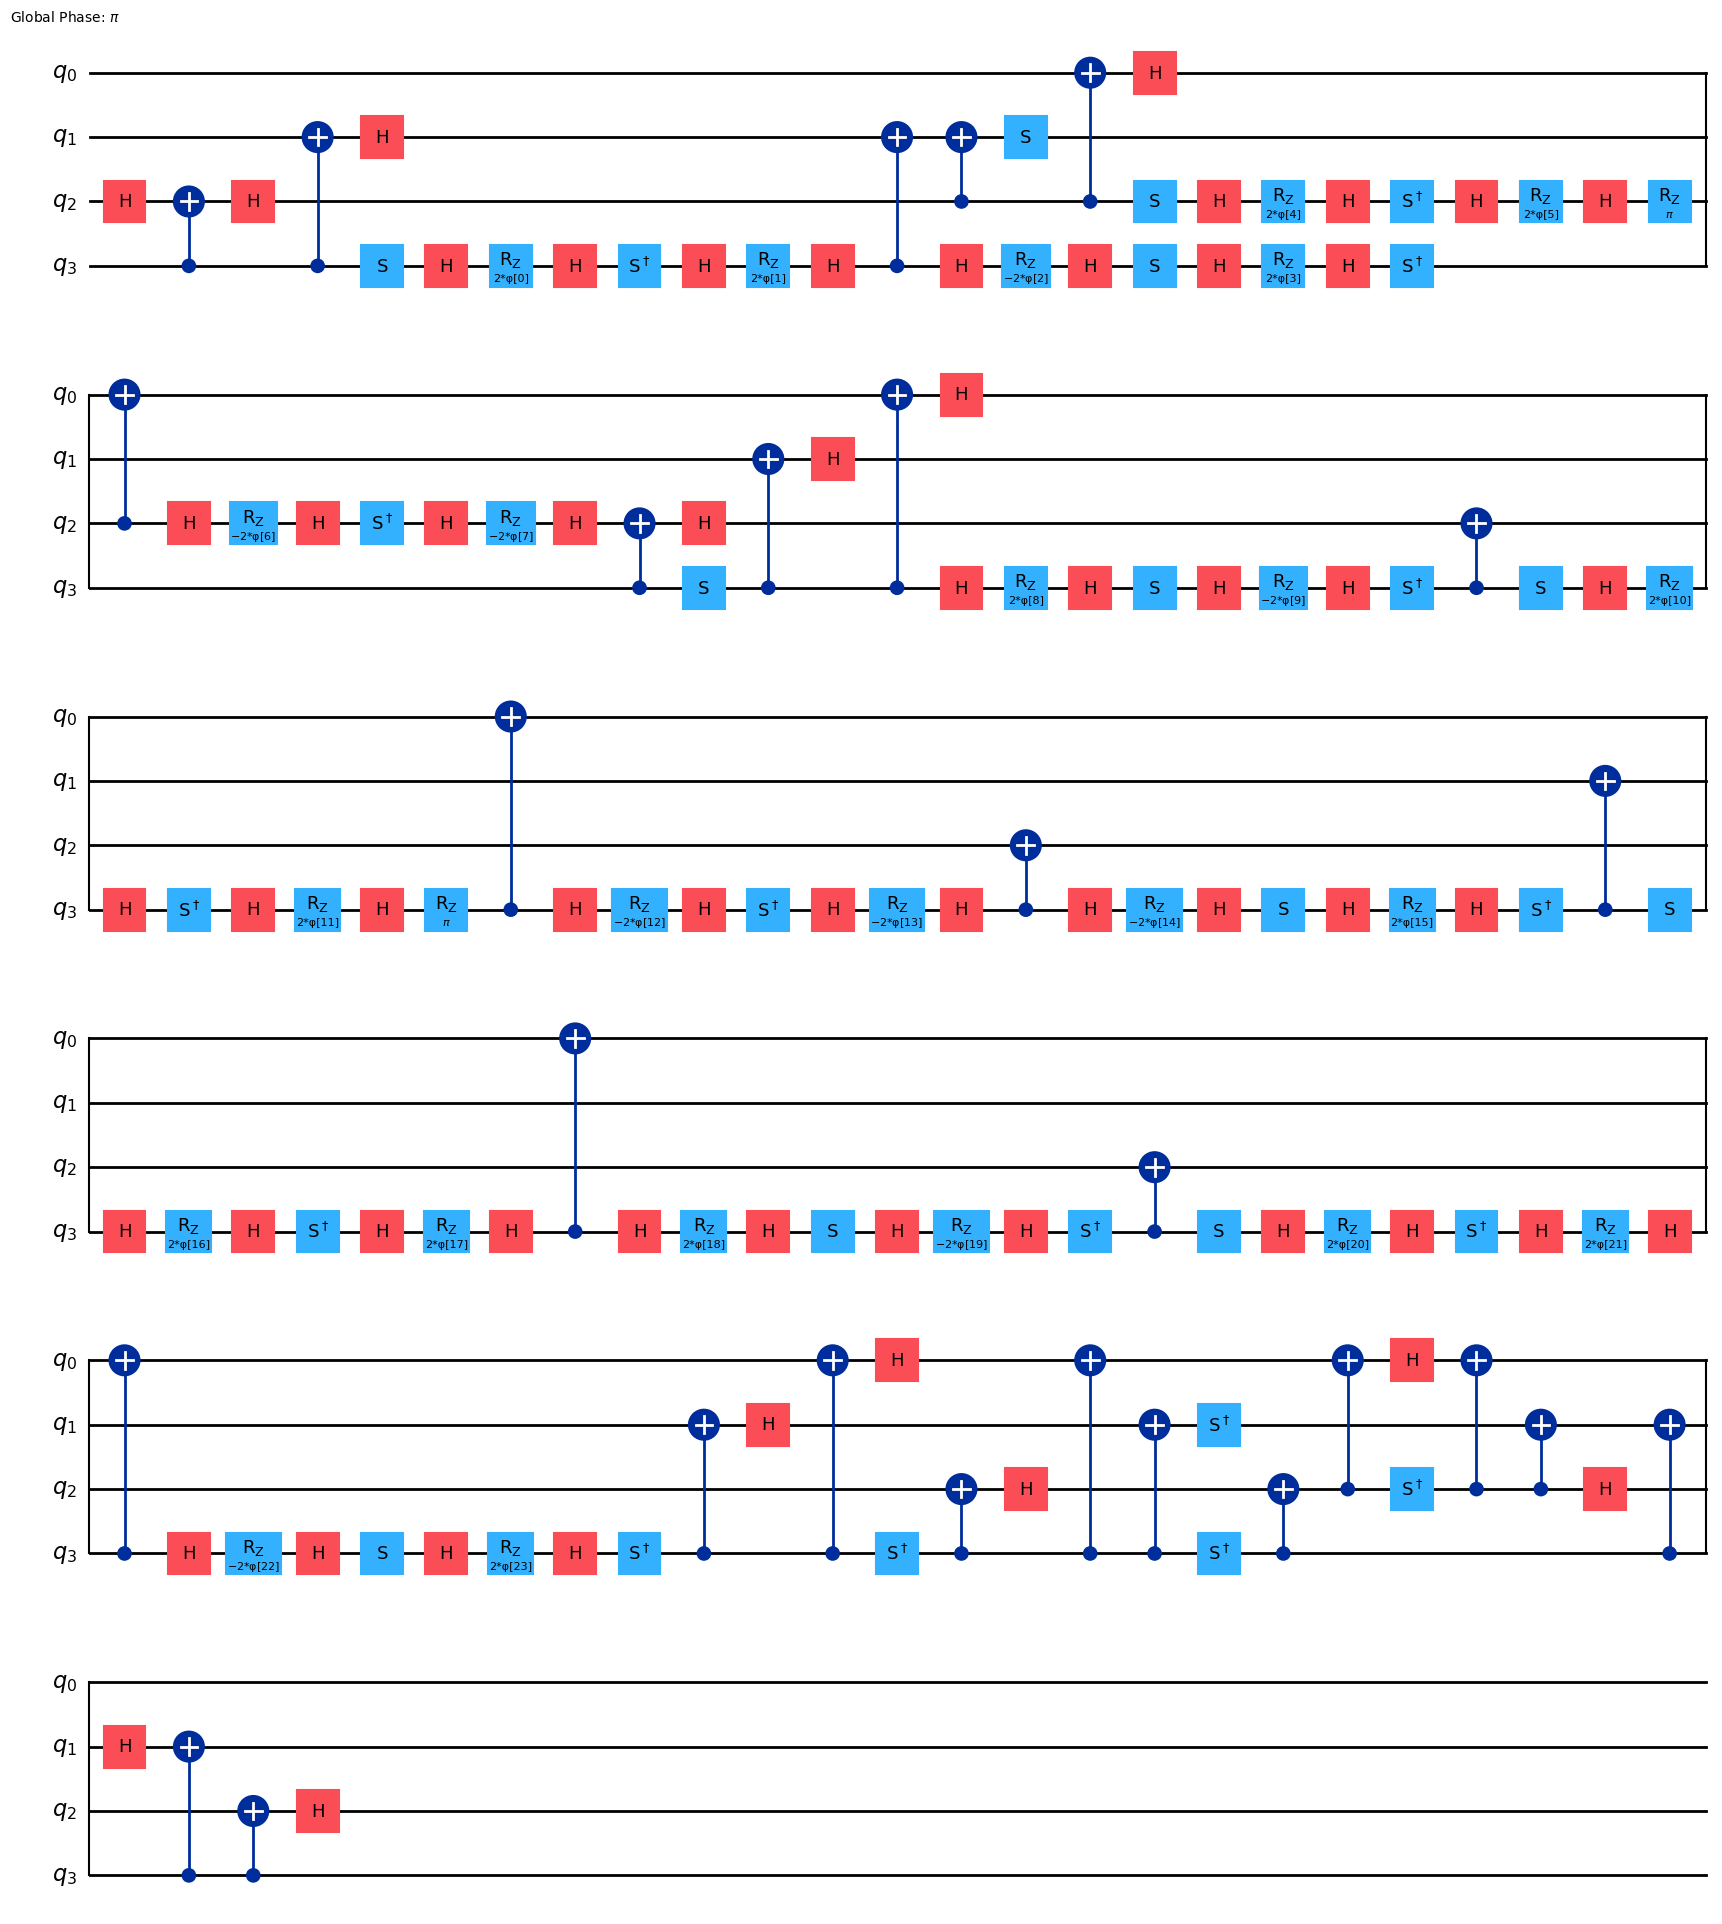

In [32]:
circuit = solve_circuit(ucc_2_4, heuristic, PARAM, TIME, gate_cancellation=True)
circuit.draw('mpl')

In [33]:
circuit.count_ops()['cx']

28

In [26]:
from qiskit.circuit import QuantumCircuit, Parameter, ParameterVector
from qiskit.transpiler.passes import CommutativeCancellation
from qiskit.converters import circuit_to_dag, dag_to_circuit

In [ ]:
215375